In [29]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import re
import csv
import argparse
import sys
from collections import defaultdict

import math 
import numpy as np
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import StrMethodFormatter
from matplotlib.offsetbox import AnchoredText
# %matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import FuncFormatter # 使用 FuncFormatter 获得更灵活的标签格式
from matplotlib.ticker import LogFormatterMathtext
import matplotlib.ticker as mticker
from matplotlib import font_manager as fm
# --- 全局字体和后端设置 ---
# matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter

# 字体路径
font_dir = "/home/loujh/fonts/ARIAL.TTF"

# 注册字体
from matplotlib import font_manager
font_manager.fontManager.addfont(font_dir)

# 设置全局默认字体
mpl.rcParams['font.family'] = 'Arial'

# plt.rcParams['font.family'] = "Liberation Sans"  # matplotlib 默认字体
# plt.switch_backend('SVG')


In [33]:
log_path = '/home/loujh/yq_code/PipeANN-main/log/log_backup'
dataset_list = ['SIFT', 'MSONG', 'GIST', 'DEEP100M']
# dataset_list = [ 'MSONG']
# dataset_list = ['SIFT', 'GIST']
sys_list = ['FreshDiskANN',  'OdinANN', 'DGAI']
# sys_list = ['DGAI', 'OdinANN']

# --- 绘图风格定义 ---
# hatch_colors = {
#     'DGAI': '#DB3124',     # 红色
#     'OdinANN': '#FFDF92',      # 绿色
#     'FreshDiskANN': '#4B74B2', # 蓝色
# }
markers = {
    'DGAI': 'D',     # 实心菱形
    'OdinANN': 'o',      # 圆形
    'FreshDiskANN': 'X', # x 形
}
colors = {
    'DGAI': '#d62728',     # 红色
    'OdinANN': '#2ca02c',      # 绿色
    'FreshDiskANN': '#1f77b4', # 蓝色
}
# 高对比度方案（略带互补色倾向）
hatch_colors = {
    'DGAI': '#8b0000',     # 深红色（更深，对比度更强）
    'OdinANN': '#006400',  # 暗绿色（更深，更突出）
    'FreshDiskANN': '#0000cd' # 中蓝色（更深，更明显）
}
# colors = {
#     'DGAI': '#8B0000',
#     'OdinANN': '#BF5700',
#     'FreshDiskANN': '#000080',
# }
# # 优化后的填充图案配色方案
# hatch_colors = {
#     'DGAI': '#a50000',     # 深红色（比基础红色深20%）
#     'OdinANN': '#1d7d1d',  # 深绿色（比基础绿色深20%）
#     'FreshDiskANN': '#0d5cad' # 深蓝色（比基础蓝色深20%）
# }

# hatches = ['/', '\\', '']
# hatches = ['//', '-', '.']
hatches = {
    # 'DGAI': '//',
    # 'OdinANN': '-',
    # 'FreshDiskANN': '.',
    'DGAI': '',
    'OdinANN': '\\',
    'FreshDiskANN': '/',
}

fig1_batch_num=32

In [34]:
def extract_metrics_dict(log_file):
    results_per_batch = []
    current_group = defaultdict(lambda: None)

    def push_group(current_group):
        if any(current_group.values()):
            keys = ['L', 'E2E_delete_time', 'mem_insert_time','E2E_insert_time', 'E2E_update_time', 'UPDATE_IO_time', 'UPDATE_IO_count', 
                    'Search_Mean_IO_count',
                    'Search_Mean_IO_Lat_us', 'Search_Latency_us', 'QPS', 'Recall@10']
            group_filled = {}
            for k in keys:
                v = current_group[k]
                if v is not None:
                    try:
                        group_filled[k] = float(v)
                    except:
                        group_filled[k] = math.nan
                else:
                    group_filled[k] = math.nan
            results_per_batch.append(group_filled)
    with open(log_file, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()

            # 1. Batch 行
            m = re.match(r'Batch:\s*(\d+)\s*Total Batch\s*:\s*(\d+)', line)
            if m:
                # print(line)
                # 保存上一个 batch
                
                push_group(current_group)
                current_group = defaultdict(lambda: None)
                continue

            # 2. 匹配 cost
            if line.startswith('$E2E delete cost'):
                current_group['E2E_delete_time'] = line.split(' ')[-2]

            elif line.startswith('$E2E insert cost'):
                current_group['E2E_insert_time'] = line.split(' ')[-2]

            elif line.startswith('Inserted '):
                current_group['mem_insert_time'] = line.split(' ')[4]
                if current_group['mem_insert_time'][-1] == 's':
                    current_group['mem_insert_time'] = float(current_group['mem_insert_time'][:-1])
                # print(current_group['mem_insert_time'])

            elif line.startswith('Batch #'):
                current_group['E2E_update_time'] = line.split(' ')[3]

            elif line.startswith('$E2E UPDATE IO cost'):
                current_group['UPDATE_IO_time'] = line.split(' ')[-2]

            elif line.startswith('$E2E UPDATE IOS count'):
                current_group['UPDATE_IO_count'] = line.split(' ')[-2]

            # 3. 匹配 L / QPS 行
            elif line.split(' ')[0] == 'Ls':
                # print(line)
                line = next(f, None)
                while line != None and ('INFO' in line.split(' ')[0] or '======' in line.split(' ')[0]):
                    line = next(f, None)
                    
                if line is None:
                    break
                parts = line.split()
                if len(parts) == 11:
                    # print(parts)
                    current_group['L'] = parts[0]
                    current_group['QPS'] = parts[1]
                    current_group['Search_Latency_us'] = parts[2]
                    current_group['Search_Mean_IO_Lat_us'] = parts[-3]
                    current_group['Recall@10'] = parts[-2]
                    current_group['Search_Mean_IO_count'] = parts[-1]

                elif len(parts) == 12:
                    # print(parts)
                    current_group['L'] = parts[0]
                    current_group['QPS'] = parts[2]
                    current_group['Search_Latency_us'] = parts[3]
                    current_group['Search_Mean_IO_count'] = parts[-3]
                    current_group['Search_Mean_IO_Lat_us'] = parts[-2]
                    current_group['Recall@10'] = parts[-1]

        # 4. 文件结束保存最后一组
        push_group(current_group)

    return results_per_batch


In [35]:
def plot_line_ops(datasets, letters, title, save_path = None):
    # --- 数据定义 ---
    # x轴数据点，这里我们使用 0 到 31 的索引，而不是原始的 1 到 32，以匹配数据列表的索引
    x = np.arange(fig1_batch_num)
    x_ticks = [0, 5, 10, 15, 20, 25, 30]
    # x_labels = [str(t) for t in x_ticks] # 标签和刻度一致时可以省略
    
    font_size_all = 50
    
    
    # --- 创建图形和子图 ---
    fig, axes = plt.subplots(1, len(datasets.items()), figsize=(11 * len(datasets.items()), 12), sharey=True) # 调整了高度以便更好地容纳图例    
    
    # letters = ['(a) SIFT', '(b) MSONG', '(c) GIST', '(d) DEEP100M']
    linewidth = 4
    markersize = 12
    # --- 遍历数据集和子图进行绘制 ---
    # 使用 axes 而不是 axes.flatten()，因为1行子图的axes本身就是一维数组
    for idx, (ax, (dataset_name, data)) in enumerate(zip(axes, datasets.items())):
        
        # **修复点1: 修正循环，确保绘制所有在colors中定义的数据**
        # 遍历在 'colors' 中定义好的标签，这样更具鲁棒性
        for label in colors.keys():
            # 如果当前数据集没有这个标签的数据，则跳过
            if label not in data:
                continue

            if len(x) != len(data[label]):
                print(dataset_name, label, len(x), len(data[label]))
                return 
            # 在当前子图(ax)上绘制一条线
            ax.plot(x, data[label],
                    marker=markers[label],
                    color=colors[label],
                    linestyle='-',
                    markersize=markersize,
                    linewidth=linewidth,
                    label=label) # label参数是为图例服务的
        
        # **修复点2: 将坐标轴设置移到内层循环之外**
        # 在一个子图的所有线条都画完后，统一进行格式化设置
        
        # 设置坐标轴刻度和标签
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_ticks, fontsize=font_size_all - 5) # 直接使用数字刻度
        ax.tick_params(axis='y', labelsize=font_size_all - 5)
        
        ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        # ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=3))  # 最多 6 个刻度

        # if (idx != 0):
        #     ax.tick_params(axis="y", which="both", labelleft=False)  # 隐藏y轴标签
        #     ax.yaxis.set_ticks_position("none")  # 去掉y轴刻度线
            # ax.set_yticks([])  # 移除y轴刻度
        # else:
        #     # 在 y 轴上方加一个文字
        #     ax.text(
        #         0, 1.02,              # 坐标（x=0, y=轴顶端稍微偏上）
        #         r"$\times 10^2$",     # 内容
        #         transform=ax.transAxes, 
        #         ha='left', va='bottom', fontsize=font_size_all-10
        #     )
            
        #     ax.yaxis.set_major_formatter(ScalarFormatter())
        #     ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        #     # 确保指数写出来（默认可能被压缩掉）
        #     ax.yaxis.get_offset_text().set_visible(True)
        #     ax.yaxis.get_offset_text().set_fontsize(font_size_all)
        # 设置坐标轴范围
        ax.set_xlim(0, 30.5)
        print(idx)
        # 设置坐标轴标签和子图标题
        # 只在最左边的子图显示Y轴标签
        if idx == 0:
            ax.set_ylabel(title, fontsize=font_size_all)
        ax.set_xlabel("Batch", fontsize=font_size_all)
        # ax.set_title(letters[idx], fontsize=font_size_all, pad=20) # 使用 title 代替 text, pad增加标题和图的间距
        ax.text(0.5, -0.4, letters[idx], transform=ax.transAxes, ha='center', va='center', fontsize=font_size_all)
        ax.set_ylim(data['ylim'])
        # 设置边框线宽
        for spine in ax.spines.values():
            spine.set_linewidth(3)
    
    # ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.0f}")) # 根据需要调整小数位数
    # for ax in axes:
    # axes[0].yaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))

    # plt.subplots_adjust(wspace=5.3, hspace=0.4)

    # --- 创建总图例 ---
    # **修复点3: 基于修复后的绘图正确获取图例信息**
    # 从第一个子图获取所有线条的句柄(handles)和标签(labels)
    handles, labels = axes[0].get_legend_handles_labels()
    # print(handles)
    # print(labels)
    order_map = {'DGAI': 2, 'OdinANN': 1, 'FreshDiskANN': 0}
    handles = sorted(handles, key=lambda h: order_map[h.get_label()])
    labels = sorted(labels, key=lambda x: order_map[x])

    # 使用 fig.legend() 在整个图的顶部中心创建图例
    fig.legend(
        [], [], 
        # handles, labels,
               loc='upper center',      # 定位在顶部中心
               bbox_to_anchor=(0.5, 1.0), # (0.5->水平居中, 1.0->在图表顶部)
               ncol=len(labels),        # 列数等于标签数量，确保单行显示
               frameon=False,           # 不显示边框
               fontsize=font_size_all
              )
    
    # --- 布局调整和保存 ---
    # 自动调整子图布局，并留出顶部空间(top=0.85)给图例
    fig.tight_layout(rect=[0, 0, 1, 0.85],pad=1.08, w_pad=2.0, h_pad=None) 

    
    # 保存图像
    if save_path != None:
        plt.savefig(save_path, dpi=400, bbox_inches='tight', transparent=True)
    else:
        plt.show()

In [150]:
fig1_data = {}
for data_name in dataset_list:
    fig1_data[data_name] = {}
    for sys in sys_list:
        all_data = []
        for i in range(1, 6):
            data = extract_metrics_dict(f'{log_path}/fig1_{i}/{sys}_{data_name}.log')[-32:]
            # print(len(data))
            all_data.append(data)

        # 按位置逐条平均
        avg32 = []
        for j in range(32):
            d_avg = {}
            for k in all_data[0][j]:
                # d_avg[k] = sum([d[j][k] for d in all_data]) / len(all_data)
                d_avg[k] = np.median([d[j][k] for d in all_data])
            avg32.append(d_avg)

        fig1_data[data_name][sys] = avg32


In [151]:
delete_ops = {}
batch_size = 1000
for data_name in dataset_list:
    delete_ops[data_name] = {}
    for sys in sys_list:
        delete_ops[data_name][sys] = []
        print(data_name, sys)
        if data_name == 'DEEP100M':
            for i in range(fig1_batch_num):
                delete_ops[data_name][sys].append(1 / fig1_data[data_name][sys][i]['E2E_delete_time'] * 100000 / 1000)
        else:
                # delete_ops[data_name][sys] = None
            for i in range(fig1_batch_num):
                delete_ops[data_name][sys].append(1 / fig1_data[data_name][sys][i]['E2E_delete_time'] * batch_size / 1000)
        print(np.mean(delete_ops[data_name][sys]))
    print()

# delete_ops['SIFT']['ylim'] = (0, 2000)
# delete_ops['GIST']['ylim'] = (0, 2000)
# delete_ops['MSONG']['ylim'] = (0, 2000)
# delete_ops['DEEP100M']['ylim'] = (0, 2000)

# for x in delete_ops:
#     for y in delete_ops[x]:
#         if delete_ops[x][y]
#         delete_ops[x][y] = delete_ops[x][y] / 100
        # for z in delete_ops[x][y]:
        #     delete_ops[x][y][z] = delete_ops[x][y][z] / 100
delete_ops['SIFT']['ylim'] = (0, 2)
delete_ops['GIST']['ylim'] = (0, 2)
delete_ops['MSONG']['ylim'] = (0, 2)
delete_ops['DEEP100M']['ylim'] = (0, 2)

    # delete_ops['']

SIFT FreshDiskANN
0.697606951855121
SIFT OdinANN
0.575670536749253
SIFT DGAI
1.3432494994563733

MSONG FreshDiskANN
0.2968548046546692
MSONG OdinANN
0.29871985588627714
MSONG DGAI
1.583149215778654

GIST FreshDiskANN
0.1568870357011085
GIST OdinANN
0.18490752011987616
GIST DGAI
1.1995618154466188

DEEP100M FreshDiskANN
0.8295632710883183
DEEP100M OdinANN
0.5220210353450118
DEEP100M DGAI
1.2218676803312676



In [152]:
delete_ops['SIFT']['DGAI']

[np.float64(1.4197245166547883),
 np.float64(1.3965602720499408),
 np.float64(1.3728758178907685),
 np.float64(1.3715502083384765),
 np.float64(1.3790535555448296),
 np.float64(1.3872684822311718),
 np.float64(1.360599752370845),
 np.float64(1.3604183558527918),
 np.float64(1.3590741986558756),
 np.float64(1.3642843987257585),
 np.float64(1.34594211910511),
 np.float64(1.3122808490982005),
 np.float64(1.3568318518990898),
 np.float64(1.3474673677090225),
 np.float64(1.3094078334014225),
 np.float64(1.3277461774187551),
 np.float64(1.3145441161005365),
 np.float64(1.313427033217883),
 np.float64(1.3388673182487616),
 np.float64(1.314770526526153),
 np.float64(1.3257711347805452),
 np.float64(1.325435504971046),
 np.float64(1.3270378656984598),
 np.float64(1.3401987246668936),
 np.float64(1.333941610707816),
 np.float64(1.3200117745050286),
 np.float64(1.3365964107039987),
 np.float64(1.3284923073652943),
 np.float64(1.295974702573806),
 np.float64(1.3312548008376255),
 np.float64(1.3336

0
1
2
3


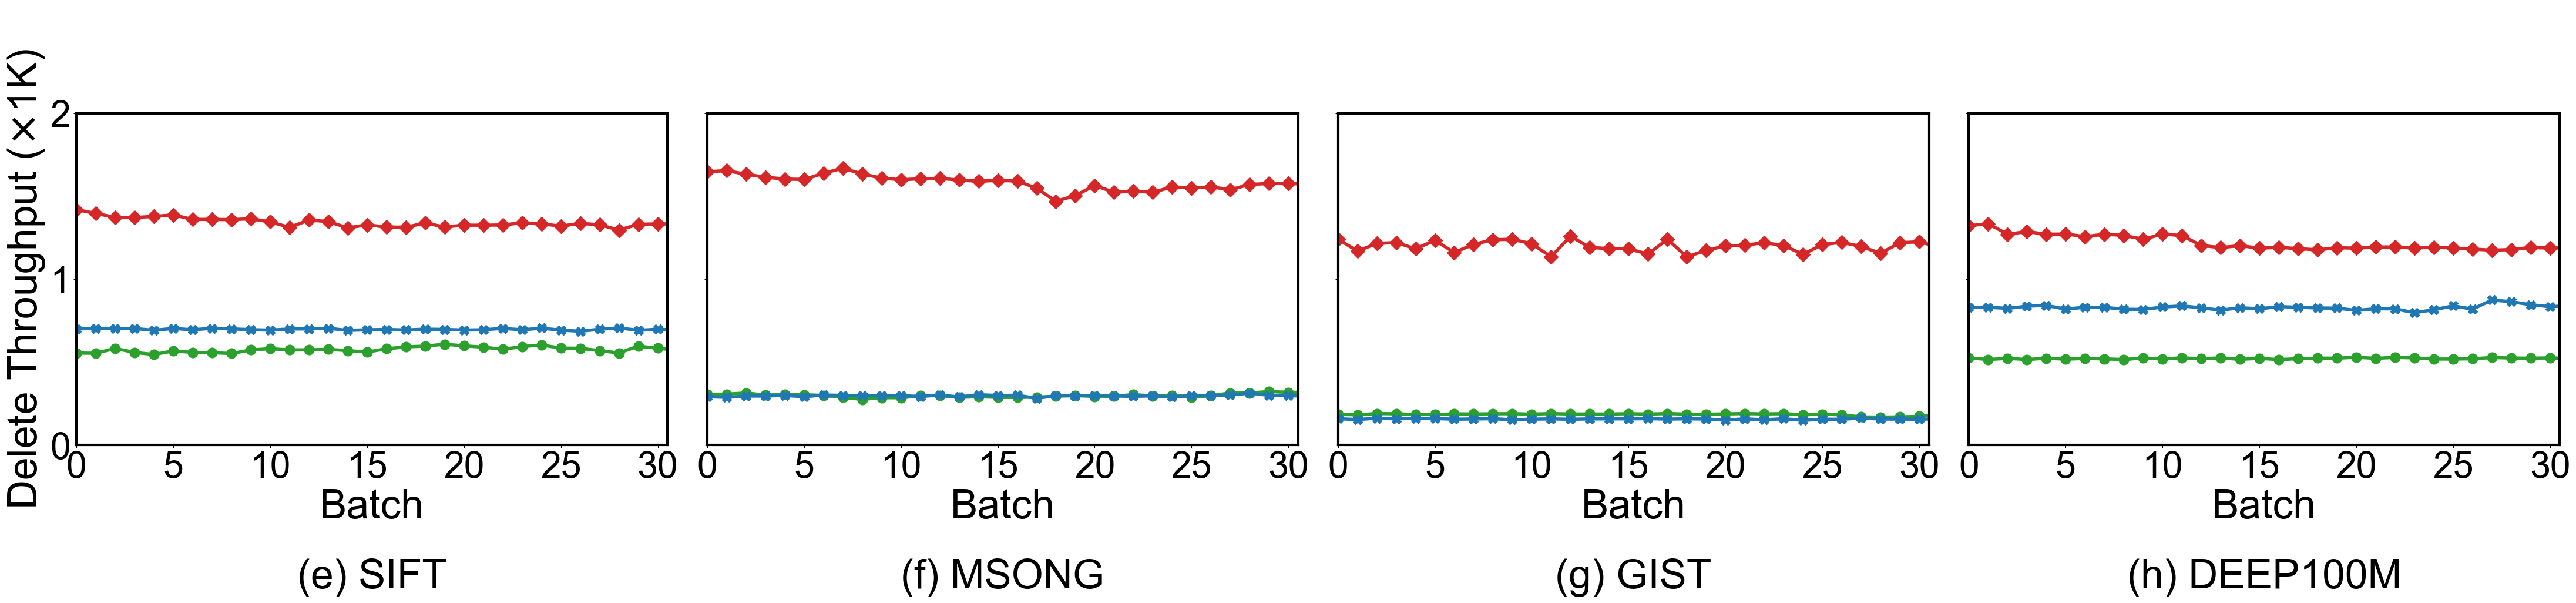

In [59]:
plot_line_ops(delete_ops, ['(e) SIFT', '(f) MSONG', '(g) GIST', '(h) DEEP100M'],r'Delete Throughput ($\times$1K)', 'delete_ops.pdf')
# plot_line_ops(delete_ops, 'Delete Throughput')

In [50]:
insert_ops = {}
batch_size = 1000
for data_name in dataset_list:
    insert_ops[data_name] = {}
    for sys in sys_list:
        insert_ops[data_name][sys] = []
        print(data_name, sys)
        if data_name == 'DEEP100M':
            for i in range(fig1_batch_num):
                insert_ops[data_name][sys].append(1 / fig1_data[data_name][sys][i]['E2E_insert_time'] * 100000 / 1000)
        else:
            for i in range(fig1_batch_num):
                insert_ops[data_name][sys].append(1 / fig1_data[data_name][sys][i]['E2E_insert_time'] * batch_size / 1000)
        print(insert_ops[data_name][sys][0])
# insert_ops['SIFT']['ylim'] = (0, 2700)
# insert_ops['GIST']['ylim'] = (0, 2700)
# insert_ops['MSONG']['ylim'] = (0, 2700)
# insert_ops['DEEP100M']['ylim'] = (0, 2700)
# insert_ops
insert_ops['SIFT']['ylim'] = (0, 3)
insert_ops['GIST']['ylim'] = (0, 3)
insert_ops['MSONG']['ylim'] = (0, 3)
insert_ops['DEEP100M']['ylim'] = (0, 3)
# insert_ops

SIFT FreshDiskANN
0.505105097217578
SIFT OdinANN
1.3603591348115902
SIFT DGAI
2.0412329046744233
MSONG FreshDiskANN
0.2654380776762064
MSONG OdinANN
1.013787510137875
MSONG DGAI
2.1240441801189465
GIST FreshDiskANN
0.1549493695187629
GIST OdinANN
1.1181930001118192
GIST DGAI
1.594896331738437
DEEP100M FreshDiskANN
0.6952978597974002
DEEP100M OdinANN
1.2523214909638742
DEEP100M DGAI
1.5956394365478022


In [51]:
fig1_data['SIFT']['FreshDiskANN'][-2:]

[{'L': np.float64(100.0),
  'E2E_delete_time': np.float64(1.432426),
  'mem_insert_time': np.float64(0.028662),
  'E2E_insert_time': np.float64(2.032956),
  'E2E_update_time': np.float64(4.13308),
  'UPDATE_IO_time': np.float64(1.351179),
  'UPDATE_IO_count': np.float64(3862116524.0),
  'Search_Mean_IO_count': np.float64(114.36),
  'Search_Mean_IO_Lat_us': np.float64(4511.08),
  'Search_Latency_us': np.float64(5138.4),
  'QPS': np.float64(1545.1),
  'Recall@10': np.float64(98.519997)},
 {'L': np.float64(100.0),
  'E2E_delete_time': np.float64(1.441939),
  'mem_insert_time': np.float64(0.027634),
  'E2E_insert_time': np.float64(1.871742),
  'E2E_update_time': np.float64(4.11281),
  'UPDATE_IO_time': np.float64(1.334462),
  'UPDATE_IO_count': np.float64(3862395052.0),
  'Search_Mean_IO_count': np.float64(114.299),
  'Search_Mean_IO_Lat_us': np.float64(4795.3),
  'Search_Latency_us': np.float64(5275.95),
  'QPS': np.float64(1459.3),
  'Recall@10': np.float64(98.57)}]

In [52]:

for sys in ['FreshDiskANN', 'OdinANN']:
    for data_name in dataset_list:
        print(sys, data_name, np.mean( np.mean(delete_ops[data_name]['DGAI']) / np.mean(delete_ops[data_name][sys])))

FreshDiskANN SIFT 1.9255104839255377
FreshDiskANN MSONG 5.333075937983653
FreshDiskANN GIST 7.646022567039573
FreshDiskANN DEEP100M 1.4729047474923502
OdinANN SIFT 2.3333650303549542
OdinANN MSONG 5.299778988850878
OdinANN GIST 6.487360896241207
OdinANN DEEP100M 2.3406483601254044


In [53]:

for sys in ['FreshDiskANN', 'OdinANN']:
    for data_name in dataset_list:
        print(sys, data_name, np.mean( np.mean(insert_ops[data_name]['DGAI']) / np.mean(insert_ops[data_name][sys])))

FreshDiskANN SIFT 3.9862275180579463
FreshDiskANN MSONG 8.429121704190253
FreshDiskANN GIST 9.680437750366771
FreshDiskANN DEEP100M 2.3747894629140043
OdinANN SIFT 1.4579582732699552
OdinANN MSONG 2.1146742934396485
OdinANN GIST 1.3685262959123692
OdinANN DEEP100M 1.2870127370328108


In [54]:
update_ops = {}
batch_size = 1000
for data_name in dataset_list:
    update_ops[data_name] = {}
    for sys in sys_list:
        update_ops[data_name][sys] = []
        # print(data_name, sys)
        if data_name == 'DEEP100M':
            for i in range(fig1_batch_num):
                update_ops[data_name][sys].append(1 / fig1_data[data_name][sys][i]['E2E_update_time'] * 100000)
        else:
            for i in range(fig1_batch_num):
                update_ops[data_name][sys].append(1 / fig1_data[data_name][sys][i]['E2E_update_time'] * batch_size)

for sys in ['FreshDiskANN', 'OdinANN']:
    for data_name in dataset_list:
        print(sys, data_name, np.mean( np.mean(update_ops[data_name]['DGAI']) / np.mean(update_ops[data_name][sys])))

FreshDiskANN SIFT 3.286676139002712
FreshDiskANN MSONG 7.454021360303351
FreshDiskANN GIST 9.321594042148082
FreshDiskANN DEEP100M 1.9462240677308342
OdinANN SIFT 1.977972123524357
OdinANN MSONG 3.976331344410736
OdinANN GIST 4.1995402599045555
OdinANN DEEP100M 1.8917981027102306


In [55]:
insert_delete_ops = {
    'insert': insert_ops,
    'delete': delete_ops
}

In [56]:
insert_ops['SIFT']['FreshDiskANN'][-3:]

[np.float64(0.5010863552181128),
 np.float64(0.49189456141697113),
 np.float64(0.5342616664048785)]

0
1
2
3


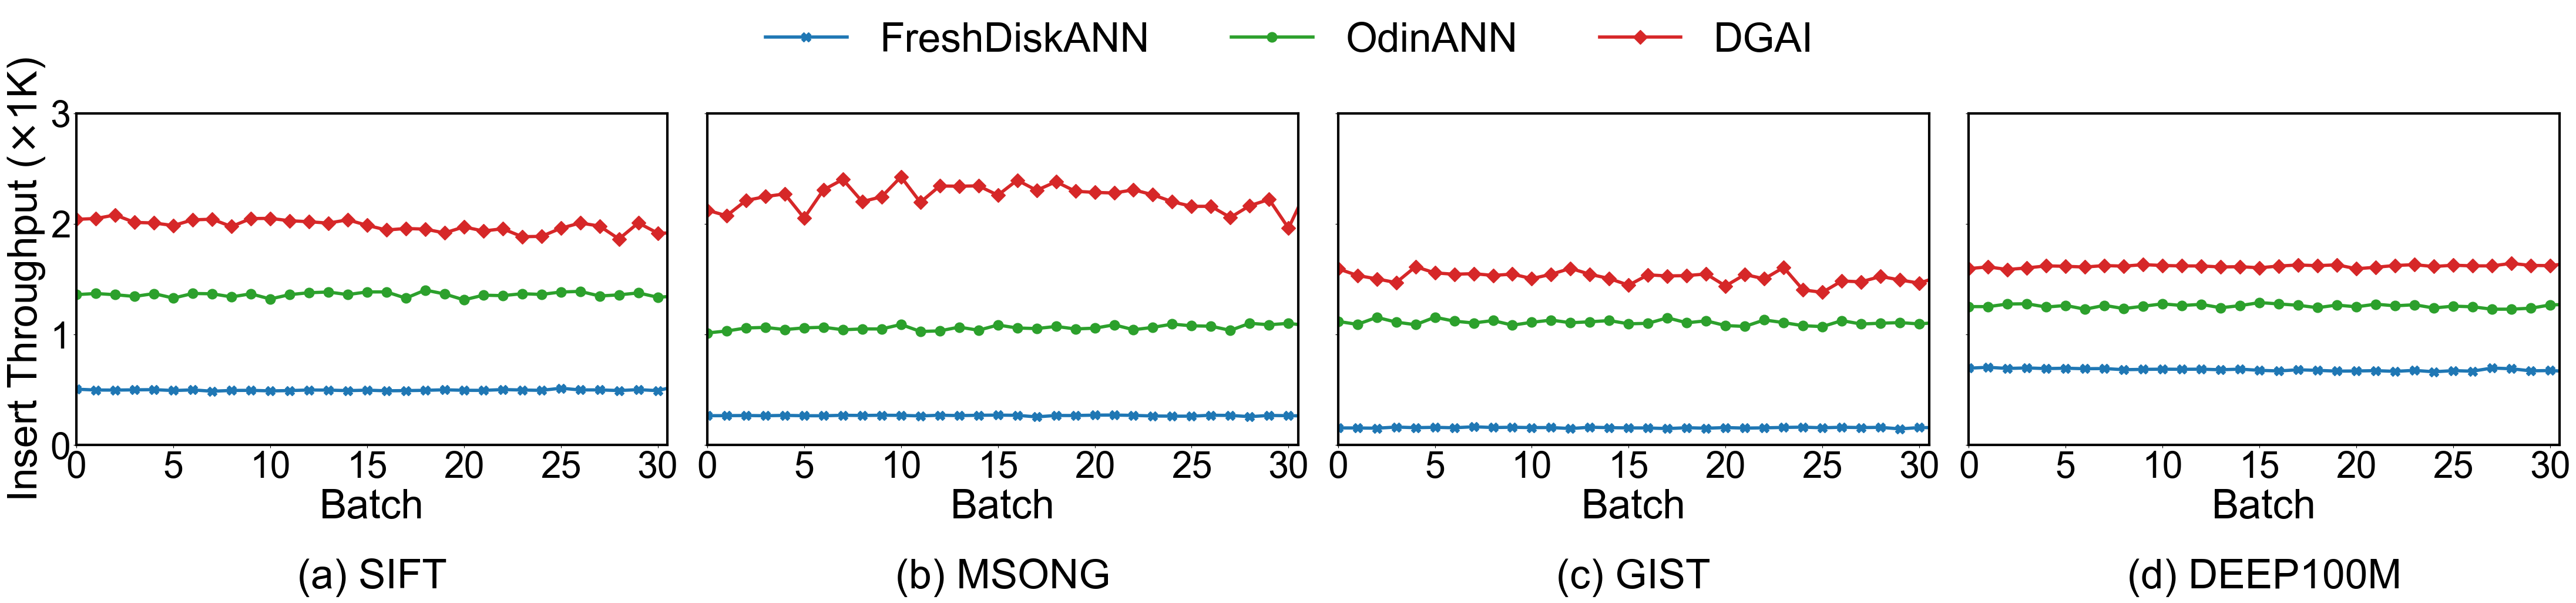

In [57]:
plot_line_ops(insert_ops, ['(a) SIFT', '(b) MSONG', '(c) GIST', '(d) DEEP100M'], r'Insert Throughput ($\times$1K)', 'insert_ops.pdf')
# plot_line_ops(insert_ops, 'Insert Throughput')

In [80]:
# extract_metrics_dict2('/home/loujh/yq_code/PipeANN-main/log/log_backup/fig2/DGAI_MSONG.log')[0]

In [6]:
def extract_metrics_dict2(log_file):
    results_per_batch = []
    current_group = defaultdict(lambda: None)

    def push_group(current_group):
        if any(current_group.values()):
            keys = ['L', 'Search_IO_us', 'Search_Latency_us', 'QPS', 'Recall@10', 'Search_IO_count']
            group_filled = {}
            for k in keys:
                v = current_group[k]
                if v is not None:
                    try:
                        group_filled[k] = float(v)
                    except:
                        group_filled[k] = math.nan
                else:
                    group_filled[k] = math.nan
            results_per_batch.append(group_filled)
    with open(log_file, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if line.split(' ')[0] == 'Ls' or line.split(' ')[0] == 'L':
                # print(line)
                line = next(f, None)
                line = next(f, None)
                parts = line.split()
                # print(parts)
                if line is None:
                    break
                if len(parts) == 10:
                    # print(line)
                    while len(parts) == 10:
                        current_group['L'] = parts[0]
                        current_group['QPS'] = parts[2]
                        current_group['Search_Latency_us'] = parts[3]
                        current_group['Search_IO_us'] = parts[-2]
                        current_group['Search_IO_count'] = float(parts[-3]) + float(parts[-4])
                        current_group['Recall@10'] = parts[-1]
                        line = next(f, None)
                        push_group(current_group)
                        # print(current_group)
                        if line is None:
                            break
                        parts = line.split()
                elif len(parts) == 9:
                    while len(parts) == 9:
                        current_group['L'] = parts[0]
                        current_group['QPS'] = parts[2]
                        current_group['Search_Latency_us'] = parts[3]
                        current_group['Search_IO_count'] = parts[-4]
                        current_group['Search_IO_us'] = parts[-3]
                        current_group['Recall@10'] = parts[-1]
                        line = next(f, None)
                        push_group(current_group)
                        if line is None:
                            break
                        parts = line.split()
                elif len(parts) == 12:
                    while len(parts) == 12:
                        current_group['L'] = parts[0]
                        current_group['QPS'] = parts[1]
                        t = float(parts[2])
                        current_group['Search_Latency_us'] = t * 1000

                        current_group['Search_IO_count'] = parts[3]
                        current_group['Search_IO_us'] = parts[4]
                        current_group['Recall@10'] = parts[-1]
                        line = next(f, None)
                        push_group(current_group)
                        if line is None:
                            break
                        parts = line.split()
    
    return results_per_batch


In [36]:
def plot_recall_vs_qps(datasets, dataset_titles, y_lable, save_path = None):
    """
    绘制Recall-QPS性能权衡曲线图。
    """
    # --- 1. 数据定义 ---
    # 修正点1：移除了最外层多余的花括号，使其成为一个标准的字典。
    
    font_size_all = 50

    # --- 2. 绘图风格定义 ---
    # colors = {'DGAI': '#d62728', 'OdinANN': '#2ca02c', 'FreshDiskANN': '#1f77b4'}
    # markers = {'DGAI': 'D', 'OdinANN': 'o', 'FreshDiskANN': 'X'}
    
    # 修正点2: 定义一个列表来控制绘图顺序，确保与标题匹配
    dataset_order = dataset_list
    # dataset_titles = ['(a) SIFT', '(b) MSONG', '(c) GIST', '(d) DEEP100M']

    # --- 3. 创建图形和子图 ---
    fig, axes = plt.subplots(1, len(dataset_list), figsize=(11 * len(dataset_titles), 12))
    
    linewidth = 4
    markersize = 12

    # --- 4. 遍历数据集和子图进行绘制 ---
    # 修正点2: 循环遍历预定义的顺序列表
    for idx, dataset_name in enumerate(dataset_order):
        ax = axes[idx]
        data = datasets[dataset_name]

        # ax.yaxis.set_major_formatter(StrMethodFormatter("{x:2.0f}"))  # 固定为 4 位宽
        for system_label in colors.keys():
            if system_label not in data:
                continue

            points = data[system_label]
            if not points:
                continue
            
            recall_data, qps_data = zip(*points)
            # print(recall_data)
            # print(qps_data)
            ax.plot(recall_data, qps_data,
                    marker=markers[system_label],
                    color=colors[system_label],
                    linestyle='-',
                    markersize=markersize,
                    linewidth=linewidth,
                    label=system_label)
        
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        # --- 5. 子图格式化 ---
        # ax.set_yscale('log')
        ax.set_xlim(data['xlim'])
        ax.set_ylim(data['ylim']) # 手动设置ylim以获得更一致的视图
        

        # ax.tick_params(axis='y', labelsize=font_size_all)
        # if data['ylim'][1] > 5:
        #     ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))  # 最多 6 个刻度
        # # else :
        # #     # ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))  # 最多 6 个刻度
        # #     ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=5))  # 固定5个刻度（包括首尾）
        # elif data['ylim'][1] == 4:
        #     ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
        
        # ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=5))  # 固定4个刻度（包括首尾）
        # ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        # else:
        #     pass
        #     # ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=3))  # 最多 6 个刻度
        if idx == 2:
            ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))  # 最多 6 个刻度
        # 根据y轴范围设置**确定数量**的y刻度
        else:
        # x轴固定设置为5个刻度（包括首尾）
            ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.0f}")) # 根据需要调整小数位数
        ax.xaxis.set_major_locator(mticker.LinearLocator(numticks=6))
        ax.grid(True, which='major', axis='both', linestyle='-', linewidth=1.5, alpha=0.3)
        if idx == 0:
            
        #     # 在 y 轴上方加一个文字
        #     ax.text(
        #         0, 1.02,              # 坐标（x=0, y=轴顶端稍微偏上）
        #         r"$\times 10^3$",     # 内容
        #         transform=ax.transAxes, 
        #         ha='left', va='bottom', fontsize=font_size_all-10
        #     )
            ax.set_ylabel(y_lable, fontsize=font_size_all)
        ax.tick_params(axis='both', which='major', labelsize=font_size_all - 5)


        ax.set_xlabel("Recall@10", fontsize=font_size_all)
        ax.text(0.5, -0.4, dataset_titles[idx], transform=ax.transAxes, ha='center', va='center', fontsize=font_size_all)
        for spine in ax.spines.values():
            spine.set_linewidth(3)
        # ax.grid(True, which="both", ls="--", linewidth=0.5)
    # fig.subplots_adjust(left=0.15)
    # --- 6. 创建总图例 ---
    handles, labels = axes[0].get_legend_handles_labels()

    order_map = {'DGAI': 2, 'OdinANN': 1, 'FreshDiskANN': 0}
    handles = sorted(handles, key=lambda h: order_map[h.get_label()])
    labels = sorted(labels, key=lambda x: order_map[x])

    fig.legend(
                # handles, labels, 
                [],[],
               loc='upper center',
            #    bbox_to_anchor=(0.5, 1.0),
               bbox_to_anchor=(0.5, 1.0),
               ncol=len(labels),
               frameon=False,
               fontsize=font_size_all)
    
    # --- 7. 布局调整和保存 ---
    # fig.tight_layout(rect=[0, 0, 1, 0.90]) 
    fig.tight_layout(rect=[0, 0, 1, 0.85],pad=1.08, w_pad=-1, h_pad=None) 
    fig.subplots_adjust(wspace=0.15)
    if save_path is not None:
        plt.savefig(save_path, dpi=400, bbox_inches='tight', transparent=True)
    else:
        plt.show()


In [12]:
fig2_data = {}
for data_name in dataset_list:
    fig2_data[data_name] = {}
    # for sys in sys_list:
    for sys in sys_list:
        log_file = f'{log_path}/fig2/{sys}_{data_name}.log'
        # print(log_file)
        fig2_data[data_name][sys] = []
        # if data_name == 'DEEP100M':
        #     pass
            # for i in range(len(single_data)):
            #     fig2_data[data_name][sys].append(4000)
        # else :
        single_data = extract_metrics_dict2(log_file)
        if data_name == 'GIST' and sys != 'DGAI':
            single_data = single_data[:-1]
        for item in single_data:
            fig2_data[data_name][sys].append(item)

In [156]:
recall_qps_data = {}
target_recall_qps = {}
target_recall_lat = {}
target_recall_io_lat = {}
for data_name in dataset_list:
    recall_qps_data[data_name] = {}
    target_recall_qps[data_name] = {}
    target_recall_lat[data_name] = {}
    target_recall_io_lat[data_name] = {}
    for sys in sys_list:
        recall_qps_data[data_name][sys] = []
        single_data = fig2_data[data_name][sys]
        # if data_name == 'DEEP100M':
        #     continue
        mn = 1e9
        target_recall = 98
        for item in single_data:
            recall_qps_data[data_name][sys].append((item['Recall@10'] / 100, item['QPS'] / 1000))
            if abs(item['Recall@10'] - 98) < mn:
                # print(item)
                mn = abs(item['Recall@10'] - 98)
                target_qps = item['QPS']
                target_io_lat = item['Search_IO_us']
                target_lat= item['Search_Latency_us']
        target_recall_qps[data_name][sys] = target_qps
        target_recall_lat[data_name][sys] = target_lat
        target_recall_io_lat[data_name][sys] = target_io_lat
        # print(sys, data_name, mn, target_qps)
        print(recall_qps_data[data_name][sys][0])
recall_qps_data['SIFT']['xlim'] = (0.9, 1)
recall_qps_data['SIFT']['ylim'] = (0.01, 8)
recall_qps_data['MSONG']['xlim'] = (0.9, 1)
recall_qps_data['MSONG']['ylim'] = (0.01, 6)
recall_qps_data['GIST']['xlim'] = (0.9, 1)
recall_qps_data['GIST']['ylim'] = (0.01, 1.5)
recall_qps_data['DEEP100M']['xlim'] = (0.9, 1)
recall_qps_data['DEEP100M']['ylim'] = (0.01, 4)

(0.8964, 6.6788)
(0.8942, 7.0018)
(0.8978, 7.19163)
(0.7870999999999999, 5.5030600000000005)
(0.78, 6.75943)
(0.7609999999999999, 6.163069999999999)
(0.8712000000000001, 1.1585699999999999)
(0.8693000000000001, 1.13134)
(0.8714, 1.54519)
(0.8309000000000001, 3.17904)
(0.8287, 3.75912)
(0.8459, 4.2229399999999995)


In [157]:
target_recall_lat

{'SIFT': {'FreshDiskANN': 3123.78, 'OdinANN': 3046.17, 'DGAI': 1600.98},
 'MSONG': {'FreshDiskANN': 5851.67, 'OdinANN': 5794.77, 'DGAI': 3897.21},
 'GIST': {'FreshDiskANN': 32915.34, 'OdinANN': 34206.5, 'DGAI': 19314.06},
 'DEEP100M': {'FreshDiskANN': 17791.12, 'OdinANN': 17515.57, 'DGAI': 6513.66}}

In [158]:
target_recall_qps

{'SIFT': {'FreshDiskANN': 2548.75, 'OdinANN': 2595.03, 'DGAI': 4893.14},
 'MSONG': {'FreshDiskANN': 1357.09, 'OdinANN': 1362.02, 'DGAI': 2011.08},
 'GIST': {'FreshDiskANN': 241.48, 'OdinANN': 232.0, 'DGAI': 406.05},
 'DEEP100M': {'FreshDiskANN': 449.18, 'OdinANN': 454.73, 'DGAI': 1197.21}}

In [159]:


print('qps')
for data_name in dataset_list:
    for sys in sys_list:
        print(sys, target_recall_qps[data_name]['DGAI'] / target_recall_qps[data_name][sys])
# print('\nsearch_lat')
# for data_name in dataset_list:
#     for sys in sys_list:
#         print(sys, target_recall_lat[data_name]['DGAI'] / target_recall_lat[data_name][sys])
print('\nsearch_io_lat')
for data_name in dataset_list:
    for sys in sys_list:
        print(sys, target_recall_io_lat[data_name]['DGAI'] / target_recall_io_lat[data_name][sys])


qps
FreshDiskANN 1.9198195193722414
OdinANN 1.8855812842240744
DGAI 1.0
FreshDiskANN 1.4819061373969302
OdinANN 1.476542194681429
DGAI 1.0
FreshDiskANN 1.6815057147589865
OdinANN 1.7502155172413794
DGAI 1.0
FreshDiskANN 2.6653234783383053
OdinANN 2.632793086007081
DGAI 1.0

search_io_lat
FreshDiskANN 0.2959318616533975
OdinANN 0.30182180695101446
DGAI 1.0
FreshDiskANN 0.34239094892420374
OdinANN 0.35373058066913554
DGAI 1.0
FreshDiskANN 0.3292232911834273
OdinANN 0.3280071056344758
DGAI 1.0
FreshDiskANN 0.17765568771427354
OdinANN 0.18328964488051838
DGAI 1.0


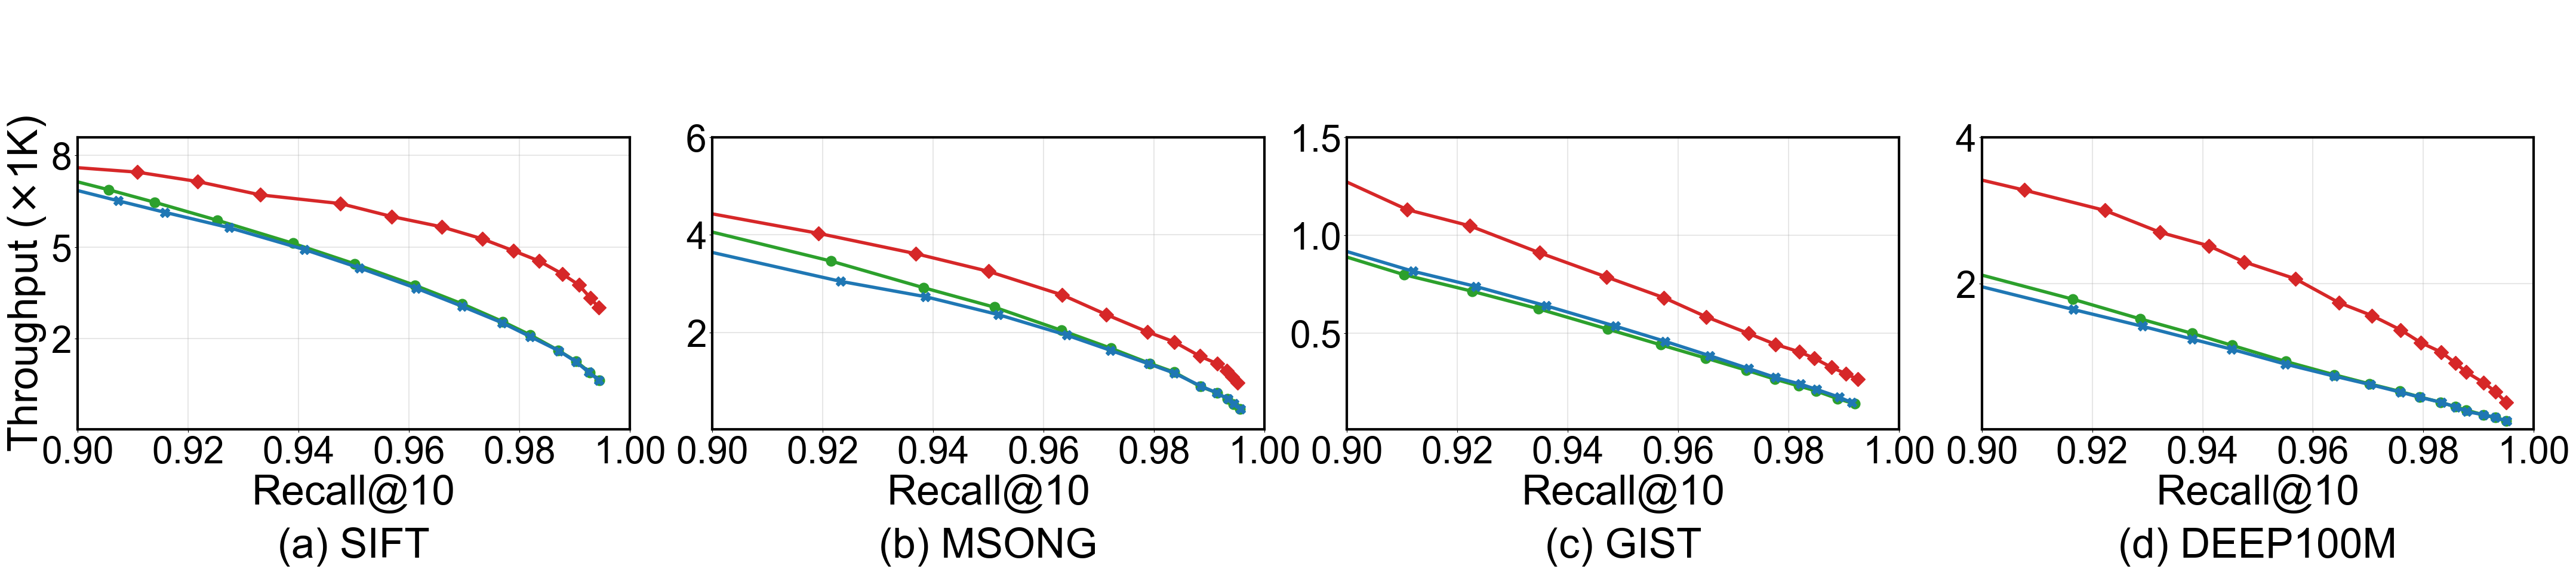

In [160]:
# plot_recall_vs_qps(recall_qps_data, 'QPS (Queries/s)')
plot_recall_vs_qps(recall_qps_data, ['(a) SIFT', '(b) MSONG', '(c) GIST', '(d) DEEP100M'], r'Throughput ($\times$1K)', 'recall_ops.pdf')

In [70]:
recall_lat_data = {}
# for data_name in ['SIFT', 'MSONG', 'GIST']:
for data_name in dataset_list:
    recall_lat_data[data_name] = {}
    for sys in sys_list:
    # for sys in ['DGAI', 'OdinANN']:
        recall_lat_data[data_name][sys] = []
        # if data_name == 'DEEP100M':
        #     continue
        single_data = fig2_data[data_name][sys]
        for item in single_data:
            recall_lat_data[data_name][sys].append((item['Recall@10'] / 100, item['Search_Latency_us'] / 1000))
        print(data_name, sys, recall_lat_data[data_name][sys][0])
recall_lat_data['SIFT']['xlim'] = (0.9, 1)
recall_lat_data['SIFT']['ylim'] = (0.01, 8)
recall_lat_data['MSONG']['xlim'] = (0.9, 1)
recall_lat_data['MSONG']['ylim'] = (0.01, 20)
recall_lat_data['GIST']['xlim'] = (0.9, 1)
recall_lat_data['GIST']['ylim'] = (0.01, 80)
recall_lat_data['DEEP100M']['xlim'] = (0.9, 1)
recall_lat_data['DEEP100M']['ylim'] = (0.01, 80)


SIFT FreshDiskANN (0.8964, 1.18406)
SIFT OdinANN (0.8942, 1.11725)
SIFT DGAI (0.8978, 1.08479)
MSONG FreshDiskANN (0.7870999999999999, 1.4224)
MSONG OdinANN (0.78, 1.1480599999999999)
MSONG DGAI (0.7609999999999999, 1.26069)
GIST FreshDiskANN (0.8712000000000001, 6.818239999999999)
GIST OdinANN (0.8693000000000001, 6.96813)
GIST DGAI (0.8714, 5.0734200000000005)
DEEP100M FreshDiskANN (0.8309000000000001, 2.50311)
DEEP100M OdinANN (0.8287, 2.09905)
DEEP100M DGAI (0.8459, 1.84809)


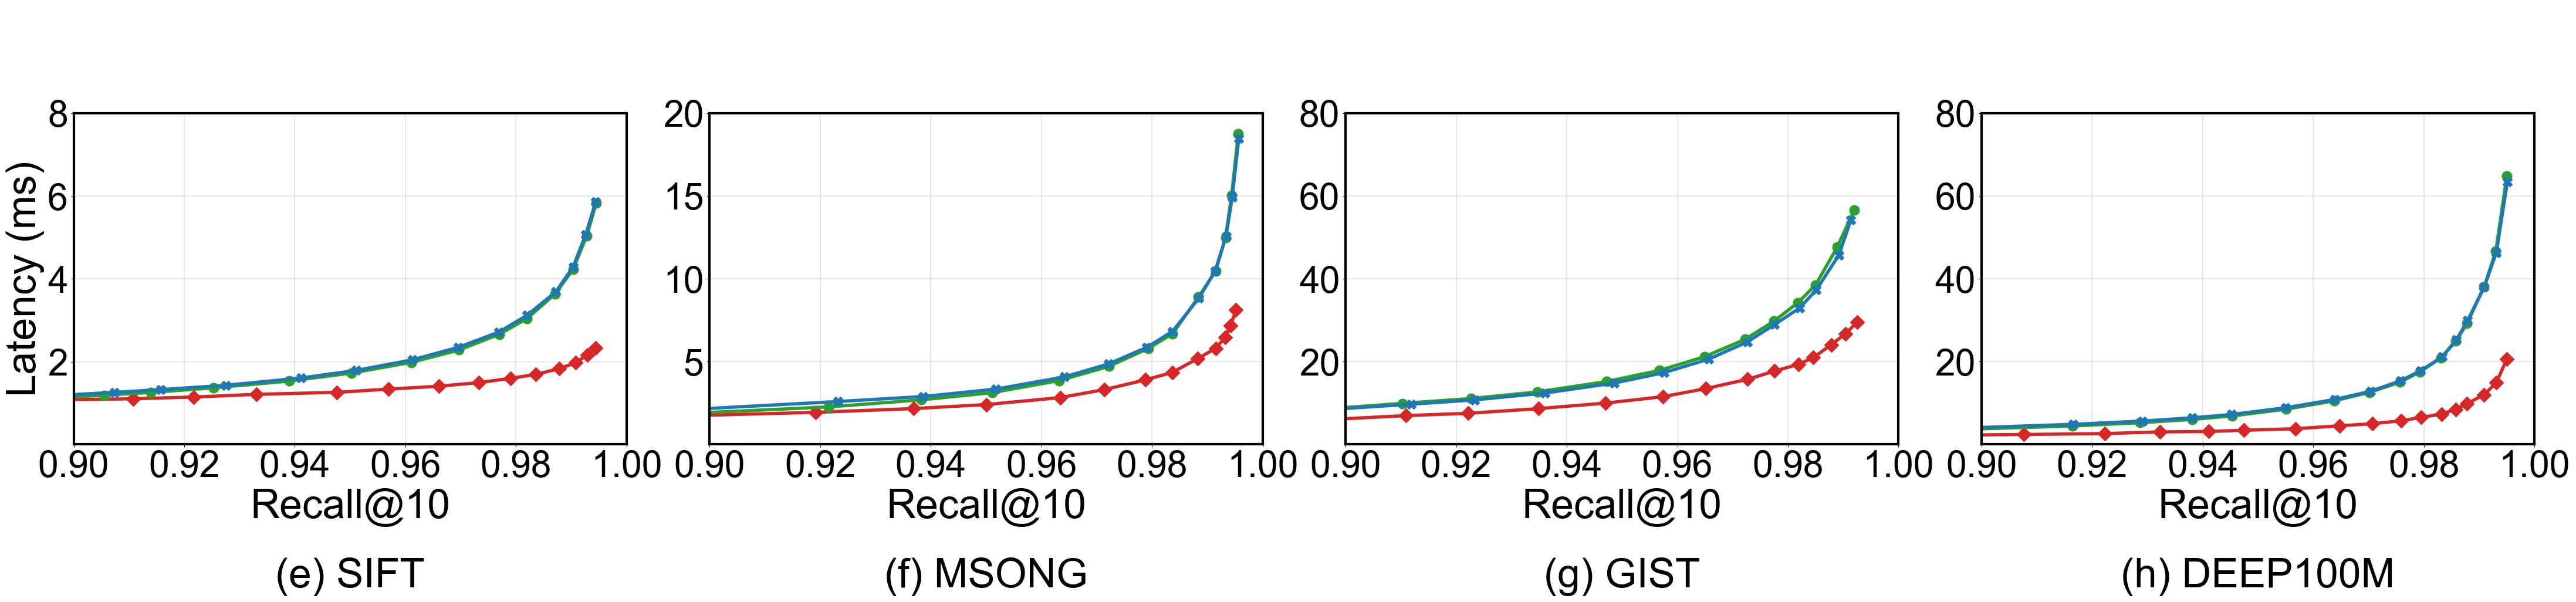

In [73]:
# plot_recall_vs_qps(recall_lat_data, 'Search Latency (ms)')
plot_recall_vs_qps(recall_lat_data, ['(e) SIFT', '(f) MSONG', '(g) GIST', '(h) DEEP100M'], 'Latency (ms)', 'recall_lat.pdf')

In [161]:
update_io = {}
for data_name in dataset_list:
    update_io[data_name] = {}
    for sys in sys_list:
        # print
        # if data_name == 'DEEP100M':
        #     update_io[data_name][sys] = 1
        #     continue
        sum = 0
        for i in range(len(fig1_data[data_name][sys])):
            sum += fig1_data[data_name][sys][i]['UPDATE_IO_count']
        update_io[data_name][sys] = sum / len(fig1_data[data_name][sys]) / 1024 / 1024 / 1024
        print(data_name, sys)
        print(update_io[data_name][sys])

SIFT FreshDiskANN
3.5972005538642406
SIFT OdinANN
2.2756485221907496
SIFT DGAI
0.6690144538879395
MSONG FreshDiskANN
8.636616181582212
MSONG OdinANN
5.530987232923508
MSONG DGAI
0.31313395500183105
GIST FreshDiskANN
16.212449233978987
GIST OdinANN
10.017657237127423
GIST DGAI
0.5989397764205933
DEEP100M FreshDiskANN
254.16083006188273
DEEP100M OdinANN
215.27127819228917
DEEP100M DGAI
78.83313393592834


In [162]:
fig7_data = {}
for data_name in dataset_list:
    fig7_data[data_name] = {}
    # for sys in sys_list:
    for sys in sys_list:
        log_file = f'{log_path}/fig7/{sys}_{data_name}.log'
        # print(log_file)
        fig7_data[data_name][sys] = []
        # if data_name == 'DEEP100M':
        #     pass
            # for i in range(len(single_data)):
            #     fig2_data[data_name][sys].append(4000)
        # else :
        single_data = extract_metrics_dict2(log_file)
        for item in single_data:
            fig7_data[data_name][sys].append(item)

In [163]:
fig7_data['SIFT']['FreshDiskANN'][-1]

{'L': 99.0,
 'Search_IO_us': 3603.83,
 'Search_Latency_us': 4315.92,
 'QPS': 1846.38,
 'Recall@10': 99.01,
 'Search_IO_count': 102.78}

In [164]:
fig7_data['SIFT']['OdinANN'][-1]

{'L': 99.0,
 'Search_IO_us': 3522.15,
 'Search_Latency_us': 4226.13,
 'QPS': 1873.45,
 'Recall@10': 99.02,
 'Search_IO_count': 102.46}

In [165]:
qps = {}
# dataset_list = ['SIFT', 'GIST', 'MSONG']
for data_name in dataset_list:
    qps[data_name] = {}
    for sys in sys_list:
        # print(data_name, sys)
        qps[data_name][sys] = fig7_data[data_name][sys][-1]['QPS']
for data_name in dataset_list:
    for sys in sys_list:
        print(data_name, sys)
        print(qps[data_name]['DGAI'] / qps[data_name][sys])

SIFT FreshDiskANN
2.193665442649942
SIFT OdinANN
2.161968560676826
SIFT DGAI
1.0
MSONG FreshDiskANN
1.7273178707684855
MSONG OdinANN
1.744922429403416
MSONG DGAI
1.0
GIST FreshDiskANN
1.7293293665551008
GIST OdinANN
1.7970501094937525
GIST DGAI
1.0
DEEP100M FreshDiskANN
2.9522298530818047
DEEP100M OdinANN
3.004334940505154
DEEP100M DGAI
1.0


In [166]:
search_io = {}
for data_name in dataset_list:
    search_io[data_name] = {}
    for sys in sys_list:
        print(data_name, sys)
        search_io[data_name][sys] = fig7_data[data_name][sys][-1]['Search_IO_us'] / 1000
        print(search_io[data_name][sys])

SIFT FreshDiskANN
3.60383
SIFT OdinANN
3.52215
SIFT DGAI
0.9203600000000001
MSONG FreshDiskANN
8.03079
MSONG OdinANN
7.92294
MSONG DGAI
2.42742
GIST FreshDiskANN
38.93025
GIST OdinANN
39.374190000000006
GIST DGAI
12.29732
DEEP100M FreshDiskANN
27.753619999999998
DEEP100M OdinANN
27.8216
DEEP100M DGAI
4.5672299999999995


In [167]:
search_io

{'SIFT': {'FreshDiskANN': 3.60383,
  'OdinANN': 3.52215,
  'DGAI': 0.9203600000000001},
 'MSONG': {'FreshDiskANN': 8.03079, 'OdinANN': 7.92294, 'DGAI': 2.42742},
 'GIST': {'FreshDiskANN': 38.93025,
  'OdinANN': 39.374190000000006,
  'DGAI': 12.29732},
 'DEEP100M': {'FreshDiskANN': 27.753619999999998,
  'OdinANN': 27.8216,
  'DGAI': 4.5672299999999995}}

In [168]:
def plot_multi_bar(data, ylabel, ylim, yscale = 'linear', save_path = None):
    group_labels = dataset_list
    bar_labels = sys_list
    font_size_all = 25

    # colors = ['#1f77b4', '#2ca02c', '#ff7f0e']  # 蓝、绿、橙
    
    # colors = {
    #     'DGAI': '#d62728',     # 红色
    #     'OdinANN': '#2ca02c',      # 绿色
    #     'FreshDiskANN': '#1f77b4', # 蓝色
    # }
    # markers = {
    #     'DGAI': 'D',     # 实心菱形
    #     'OdinANN': 'o',      # 圆形
    #     'FreshDiskANN': 'X', # x 形
    # }

    fig, ax = plt.subplots(figsize=(2.5 * len(dataset_list), 8))

    bar_width = 0.20
    num_bars = len(bar_labels)
    group_width = num_bars * bar_width
    group_centers = np.arange(len(group_labels)) * 0.8

    for i, group in enumerate(group_labels):
        ours_height = data[group]['DGAI']
        for j, bar in enumerate(bar_labels):
            if bar not in data[group]:
                continue
            x_pos = group_centers[i] - group_width / 2 + bar_width / 2 + j * bar_width
            height = data[group][bar]

            ax.bar(x_pos, height,
                   width=bar_width * 0.85,
                   facecolor=colors[bar],
                   edgecolor=colors[bar],
                #    hatch=hatches[bar],
                   linewidth=3.0,
                   label=bar if i == 0 else "",
                   zorder=3)

            if bar != 'DGAI':
                ratio = height / ours_height
                if yscale == 'log':
                    pos = height * 1.1
                elif yscale == 'linear':
                    pos = height + 0.3
                ax.text(x_pos, pos, f'{ratio:.1f}×',
                        ha='center', va='bottom', fontsize=font_size_all - 6)


    # 美化边框
    for spine in ax.spines.values():
        spine.set_linewidth(3)

    ax.set_ylabel(ylabel, fontsize=font_size_all)
    ax.set_xlabel("Dataset", fontsize=font_size_all)
    ax.set_xticks(group_centers)
    ax.set_xticklabels(group_labels, fontsize=font_size_all)

    # 设置尺度
    ax.set_yscale(yscale)
    ax.set_ylim(ylim)
    ax.tick_params(axis='y', labelsize=font_size_all)

    # 刻度格式化（自动适配）
    if yscale == 'log':
        # 用 Matplotlib 内置的 MathText log 格式化器，避免 log10(0)
        ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
        ax.yaxis.set_minor_formatter(FuncFormatter(lambda y, _: ''))
    else:
        # 线性刻度，正常显示
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:,.0f}'))

    ax.legend(ncol=len(bar_labels), fontsize=font_size_all - 4,
              loc='upper center', frameon=False)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=400, bbox_inches='tight', transparent=True)
    else :
        plt.show()


In [192]:
def plot_multi_bar2(all_data, xlabel, ylabel, ylim, yscale, group_labels = dataset_list,save_path=None,bar_labels = sys_list, sub_xlabel = None):
    # group_labels = dataset_list
    
    font_size_all = 55

    # 增加图形宽度，为两个子图提供更多空间
    fig, axes = plt.subplots(1, 2, figsize=(24, 12))
    

    if sub_xlabel is None:
        sub_xlabel = group_labels
    for idx, ax in enumerate(axes):
        data = all_data[idx]
        bar_width = 0.20
        num_bars = len(bar_labels)
        group_width = num_bars * bar_width + bar_width * 0.5  # 增加组间距
        group_centers = np.arange(len(group_labels)) * group_width
        

        for i, group in enumerate(group_labels):
            # print(group)
            ours_height = data[group]['DGAI']
            for j, bar in enumerate(bar_labels):
                if bar not in data[group]:
                    continue
                x_pos = group_centers[i] - group_width / 2 + bar_width / 2 + j * bar_width
                height = data[group][bar]

                # print(hatches[bar])
                ax.bar(x_pos, height,
                    width=bar_width * 0.85,
                    facecolor=colors[bar],
                    edgecolor=hatch_colors[bar],
                    hatch=hatches[bar],
                    linewidth=2.0,
                    label=bar if i == 0 and idx == 0 else "",  # 只在第一个子图显示图例
                    zorder=3)

                if bar != 'DGAI':
                    ratio = height / ours_height
                    reduce_ratio = (height - ours_height) / height
                    # print(group, bar, reduce_ratio)
                    if yscale[idx] == 'log':
                        pos = height * 1.15  # 稍微提高文本位置
                    else:
                        pos = height + (ylim[idx][1] - ylim[idx][0]) * 0.03  # 基于y轴范围动态调整
                    # ax.text(x_pos, pos, f'{ratio:.1f}×',
                    #         ha='center', va='bottom', fontsize=font_size_all - 20)

        # 美化边框
        for spine in ax.spines.values():
            spine.set_linewidth(2)

        # if idx == 0:
        ax.set_ylabel(ylabel[idx], fontsize=font_size_all )
        ax.set_xlabel(xlabel[idx], fontsize=font_size_all )
        ax.set_xticks(group_centers)
        ax.set_xticklabels(sub_xlabel, fontsize=font_size_all)  # 稍微减小字体

        # 设置尺度
        ax.set_yscale(yscale[idx])
        ax.set_ylim(ylim[idx])
        ax.tick_params(axis='y', labelsize=font_size_all )
        ax.tick_params(axis='x', labelsize=font_size_all - 15)

        # 添加网格以便于阅读
        ax.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)

        # 刻度格式化
        if yscale[idx] == 'log':
            ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
            ax.yaxis.set_minor_formatter(FuncFormatter(lambda y, _: ''))
        else:
            pass
            # ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:,.1f}'))
        # print()
    # 只在第一个子图添加图例
    
    handles, labels = axes[0].get_legend_handles_labels()
    
    order_map = {'DGAI': 2, 'OdinANN': 1, 'FreshDiskANN': 0}
    handles = sorted(handles, key=lambda h: order_map[h.get_label()])
    labels = sorted(labels, key=lambda x: order_map[x])
    fig.legend(handles, labels, 
               ncol=len(bar_labels), 
               fontsize=font_size_all ,
               loc='upper center', 
               frameon=False,
               bbox_to_anchor=(0.5, 1.0))  # 将图例放在图形顶部中央

    plt.tight_layout(rect=[0,0,1,0.85])
    # 调整子图之间的间距
    plt.subplots_adjust(wspace=0.22)
    
    # 为图例留出额外空间
    # plt.subplots_adjust(top=0.85)
    
    if save_path is not None:
        plt.savefig(save_path, dpi=400, bbox_inches='tight', transparent=True)
    else:
        plt.show()

In [180]:
all_data = [update_io,search_io]

In [181]:
all_data

[{'SIFT': {'FreshDiskANN': np.float64(3.5972005538642406),
   'OdinANN': np.float64(2.2756485221907496),
   'DGAI': np.float64(0.6690144538879395)},
  'MSONG': {'FreshDiskANN': np.float64(8.636616181582212),
   'OdinANN': np.float64(5.530987232923508),
   'DGAI': np.float64(0.31313395500183105)},
  'GIST': {'FreshDiskANN': np.float64(16.212449233978987),
   'OdinANN': np.float64(10.017657237127423),
   'DGAI': np.float64(0.5989397764205933)},
  'DEEP100M': {'FreshDiskANN': np.float64(254.16083006188273),
   'OdinANN': np.float64(215.27127819228917),
   'DGAI': np.float64(78.83313393592834)}},
 {'SIFT': {'FreshDiskANN': 3.60383,
   'OdinANN': 3.52215,
   'DGAI': 0.9203600000000001},
  'MSONG': {'FreshDiskANN': 8.03079, 'OdinANN': 7.92294, 'DGAI': 2.42742},
  'GIST': {'FreshDiskANN': 38.93025,
   'OdinANN': 39.374190000000006,
   'DGAI': 12.29732},
  'DEEP100M': {'FreshDiskANN': 27.753619999999998,
   'OdinANN': 27.8216,
   'DGAI': 4.5672299999999995}}]

/tmp/ipykernel_25148/962406735.py:62: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ylim[idx])


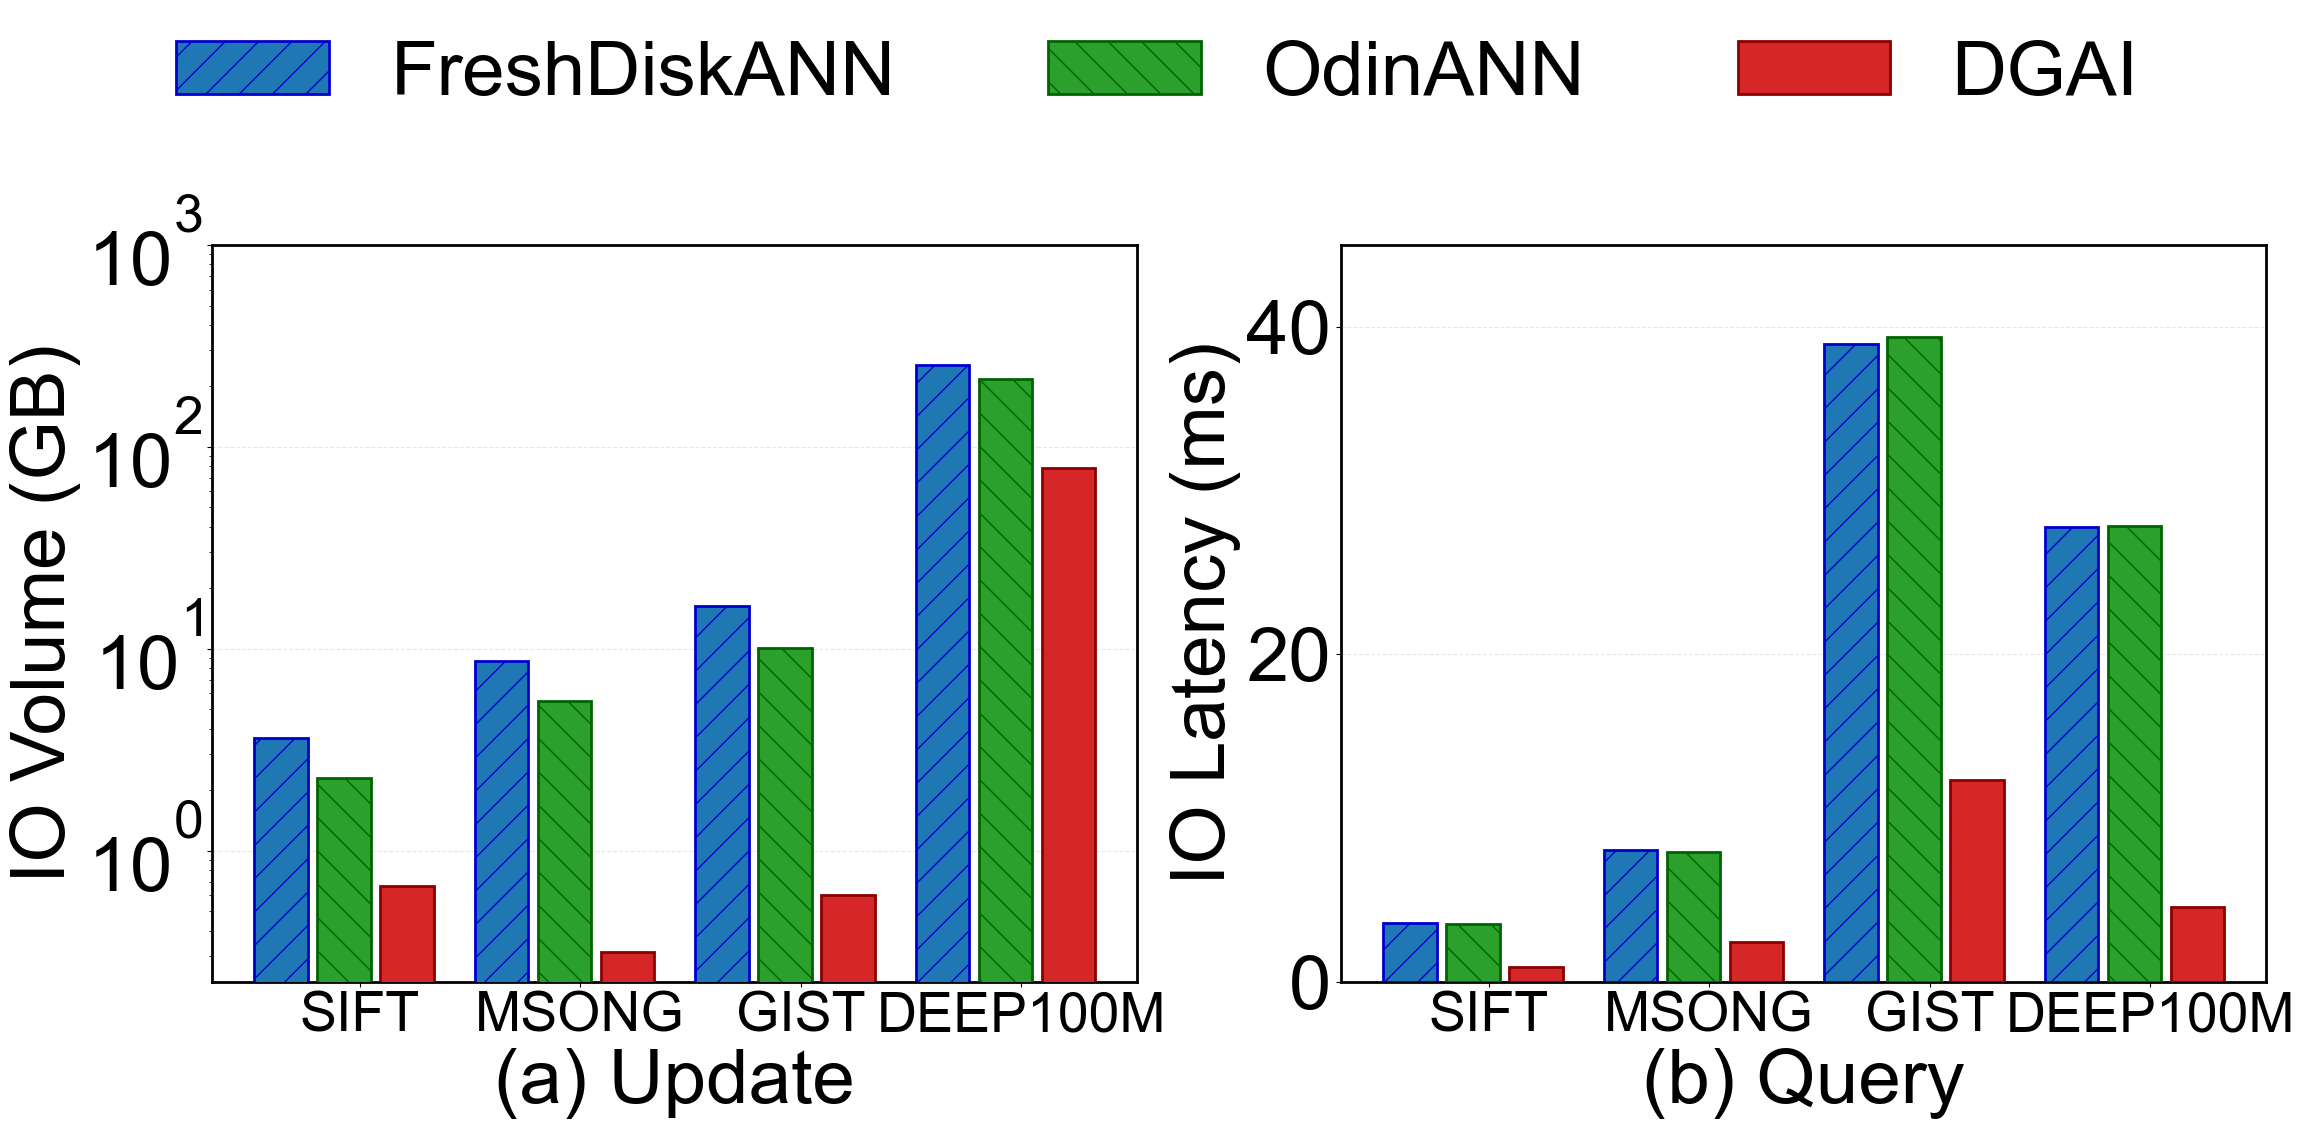

In [193]:
# plot_multi_bar2(all_data, ['Update', 'Query'], ['Update IO (GB)', 'Query IO Latency (ms)'], [(0, 1e3), (0, 40)], ['log', 'linear'])
# plot_multi_bar2(all_data, ['(a) Update', '(b) Query'], ['Update IO (GB)', 'Query IO Latency (ms)'], [(0, 1e3), (0, 35)], ['log', 'linear'], 'io_comp.pdf')
plot_multi_bar2(all_data, ['(a) Update', '(b) Query'], [r'IO Volume (GB)', 'IO Latency (ms)'], [(0, 1e3), (0, 45)], ['log', 'linear'], save_path='io_comp.pdf')

In [183]:
# plot_multi_bar(update_io, 'Update IO (GB)', (0, 1e3), 'log', 'udpate_io.pdf')

In [104]:
# plot_multi_bar(search_io, 'Search IO (GB)', (0, 16), 'linear', 'search_io.pdf')

In [100]:
log_path = '/home/loujh/yq_code/PipeANN-main/log/log_backup'
dataset_list = ['MSONG', 'GIST']
sys_list = ['DGAI',  'OdinANN', 'FreshDiskANN']
npts = int(8e5)
batch_ratio_list = [0.001, 0.003, 0.007, 0.01, 0.03, 0.07, 0.1]
total_update_num = int(batch_ratio_list[-1] * npts)
update_num_list = [total_update_num // int(batch_ratio * npts) * int(batch_ratio * npts) for batch_ratio in batch_ratio_list]

In [101]:
update_num_list

[80000, 79200, 78400, 80000, 72000, 56000, 80000]

In [102]:
fig3_data = {}
for data_name in dataset_list:
    fig3_data[data_name] = {}
    for sys in sys_list:
        fig3_data[data_name][sys] = {}
        for batch_ratio in batch_ratio_list:
            fig3_data[data_name][sys][batch_ratio] = {}
            log_file = f'{log_path}/fig3/{sys}_{data_name}_{batch_ratio}.log'
            single_data = extract_metrics_dict(log_file)[1:]
            fig3_data[data_name][sys][str(batch_ratio)] = single_data

In [103]:
multi_bs_data = {}
for data_name in dataset_list:
    multi_bs_data[data_name] = {}
    for sys in sys_list:
        multi_bs_data[data_name][sys] = {}
        for i, batch_ratio in enumerate(batch_ratio_list):
            multi_bs_data[data_name][sys][batch_ratio] = {}
            update_time = 0
            for data in fig3_data[data_name][sys][str(batch_ratio)]:
                # if sys == 'FreshDiskANN':
                update_time += data['E2E_update_time']
                # else:
                    # update_time += data['E2E_delete_time'] + data['E2E_insert_time']
            if sys == 'FreshDiskANN' and data_name == 'MSONG' and batch_ratio == 0.03:
                multi_bs_data[data_name][sys][batch_ratio]['Throughput'] = update_num_list[i] / 3 / update_time

            else :
                multi_bs_data[data_name][sys][batch_ratio]['Throughput'] = update_num_list[i] / update_time
            # multi_bs_data[data_name][sys][batch_ratio]['Recall@10'] = fig3_data[data_name][sys][str(batch_ratio)][-1]['Recall@10']
# multi_bs_data['SIFT']['ylim'] = (0,2300)
multi_bs_data['GIST']['ylim'] = (0,1600)
multi_bs_data['MSONG']['ylim'] = (0,2000)

In [104]:
80000 / fig3_data['GIST']['DGAI']['0.1'][0]['E2E_update_time']

1431.2857597801546

In [105]:
for x in multi_bs_data:
    for y in multi_bs_data[x]:
        if y == 'ylim':
            multi_bs_data[x][y] = (multi_bs_data[x][y][0], multi_bs_data[x][y][1] / 1000)
        else:
            for z in multi_bs_data[x][y]:
                for h in multi_bs_data[x][y][z]:
                    multi_bs_data[x][y][z][h] /= 1000


In [106]:
multi_bs_insert = {}
for data_name in dataset_list:
    multi_bs_insert[data_name] = {}
    for sys in sys_list:
        multi_bs_insert[data_name][sys] = {}
        for i, batch_ratio in enumerate(batch_ratio_list):
            multi_bs_insert[data_name][sys][batch_ratio] = {}
            update_time = 0
            for data in fig3_data[data_name][sys][str(batch_ratio)]:
                # if sys == 'FreshDiskANN':
                #     update_time += data['E2E_insert_time']# + data['mem_insert_time']

                    # update_time += data['E2E_update_time']
                # else:
                    update_time += data['E2E_insert_time']
            multi_bs_insert[data_name][sys][batch_ratio]['Throughput'] = update_num_list[i] / update_time
            # multi_bs_insert[data_name][sys][batch_ratio]['Recall@10'] = fig3_data[data_name][sys][str(batch_ratio)][-1]['Recall@10']

In [107]:
multi_bs_delete = {}
for data_name in dataset_list:
    multi_bs_delete[data_name] = {}
    for sys in sys_list:
        multi_bs_delete[data_name][sys] = {}
        for i, batch_ratio in enumerate(batch_ratio_list):
            multi_bs_delete[data_name][sys][batch_ratio] = {}
            update_time = 0
            for data in fig3_data[data_name][sys][str(batch_ratio)]:
                # if sys == 'FreshDiskANN':
                #     update_time += data['E2E_update_time']
                # else:
                    update_time += data['E2E_delete_time']
            multi_bs_delete[data_name][sys][batch_ratio]['Throughput'] = update_num_list[i] / update_time
            # multi_bs_delete[data_name][sys][batch_ratio]['Recall@10'] = fig3_data[data_name][sys][str(batch_ratio)][-1]['Recall@10']

In [108]:
def plot_multi_batch_ratio(data: dict, ylim, ylabel, save_path = None):
    
    batch_ratios = batch_ratio_list
    methods = sys_list
    datasets = list(data.keys())

    fig, axes = plt.subplots(1, len(datasets), figsize=(24, 12))

    if len(datasets) == 1:
        axes = [axes]

    linewidth = 4
    markersize = 14
    font_size_all = 55

    # markers = {
    #     'DGAI': 'D',     # 实心菱形
    #     'OdinANN': 'o',      # 圆形
    #     'FreshDiskANN': 'X', # x 形
    # }

    letters = ['(a) MSONG', '(b) GIST']

    # 给每个 batch_ratio 一个离散的索引位置
    x_pos = list(range(len(batch_ratios)))

    for idx, (ax, dataset) in enumerate(zip(axes, datasets)):

        for method in methods:
            # recalls = [data[dataset][method][br]['Recall@10'] for br in batch_ratios]
            throughputs = [data[dataset][method][br]['Throughput'] for br in batch_ratios]

            # 左轴 Recall
            # ax.plot(x_pos, recalls, marker='o', label=f"{method} Recall")

            # 右轴 Throughput
            ax.plot(x_pos, throughputs, color=colors[method], marker=markers[method], linestyle='-', label=method,
                    markersize=markersize,linewidth=linewidth)
        # ax.set_title(dataset, fontsize=font_size_all)
        ax.set_xlabel("Update Rate", fontsize=font_size_all)
        # ax.set_ylabel("Recall@10")
        if idx == 0:
            ax.set_ylabel(ylabel, fontsize=font_size_all)
        ax.tick_params(axis='y', labelsize=font_size_all - 5)

        # if scale != 0:
        # if (idx != 0):
        #     ax.set_yticks([])  # 移除y轴刻度
        # else:
        # 在 y 轴上方加一个文字
        # ax.text(
        #     0, 1.02,              # 坐标（x=0, y=轴顶端稍微偏上）
        #     r"$\times 10^2$",     # 内容
        #     transform=ax.transAxes, 
        #     ha='left', va='bottom', fontsize=font_size_all-10
        # )
        ax.set_xticks(x_pos)
        # ax.set_xticklabels([str(br) for br in batch_ratios], fontsize=font_size_all - 10)
        ax.set_xticklabels([
            f"{br*100:.0f}%" if br >= 0.01 else f"{br*1000:.0f}‰"
            for br in batch_ratios
        ], fontsize=font_size_all - 10)

        ax.text(0.5, -0.4, letters[idx], transform=ax.transAxes, ha='center', va='center', fontsize=font_size_all)
        # print(dataset['ylim'])
        ax.set_ylim(data[dataset]['ylim'])   # y 轴范围 [0, 100]
        
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))  # 最多 6 个刻度
        # ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())  # 自动次刻度
        # ax.yaxis.grid(True, which="major", linestyle="--", linewidth=0.7, color="gray", alpha=0.5)
        # ax.yaxis.grid(True, which="major", linestyle="--", linewidth=0.7, color="gray", alpha=0.5, zorder=0)

        # ax.grid(True, which="minor", ls="--", linewidth=0.5)
        for spine in ax.spines.values():
            spine.set_linewidth(3)

        # # 合并图例
        # lines, labels = ax.get_legend_handles_labels()
        # ax.legend(lines, labels, loc="best", fontsize=font_size_all)
    handles, labels = axes[0].get_legend_handles_labels()
    
    order_map = {'DGAI': 2, 'OdinANN': 1, 'FreshDiskANN': 0}
    handles = sorted(handles, key=lambda h: order_map[h.get_label()])
    labels = sorted(labels, key=lambda x: order_map[x])
    # print(labels)
    # 使用 fig.legend() 在整个图的顶部中心创建图例
    fig.legend(handles, labels, 
               loc='upper center',      # 定位在顶部中心
               bbox_to_anchor=(0.5, 1.0), # (0.5->水平居中, 1.0->在图表顶部)
               ncol=len(labels),        # 列数等于标签数量，确保单行显示
               frameon=False,           # 不显示边框
               fontsize=font_size_all
              )
    
    # --- 布局调整和保存 ---
    # 自动调整子图布局，并留出顶部空间(top=0.85)给图例
    fig.tight_layout(rect=[0, 0, 1, 0.85]) 
    fig.subplots_adjust(wspace=0.15)
    
    if save_path != None:
        plt.savefig(save_path, dpi=400, bbox_inches='tight', transparent=True)
    else:
        plt.show()



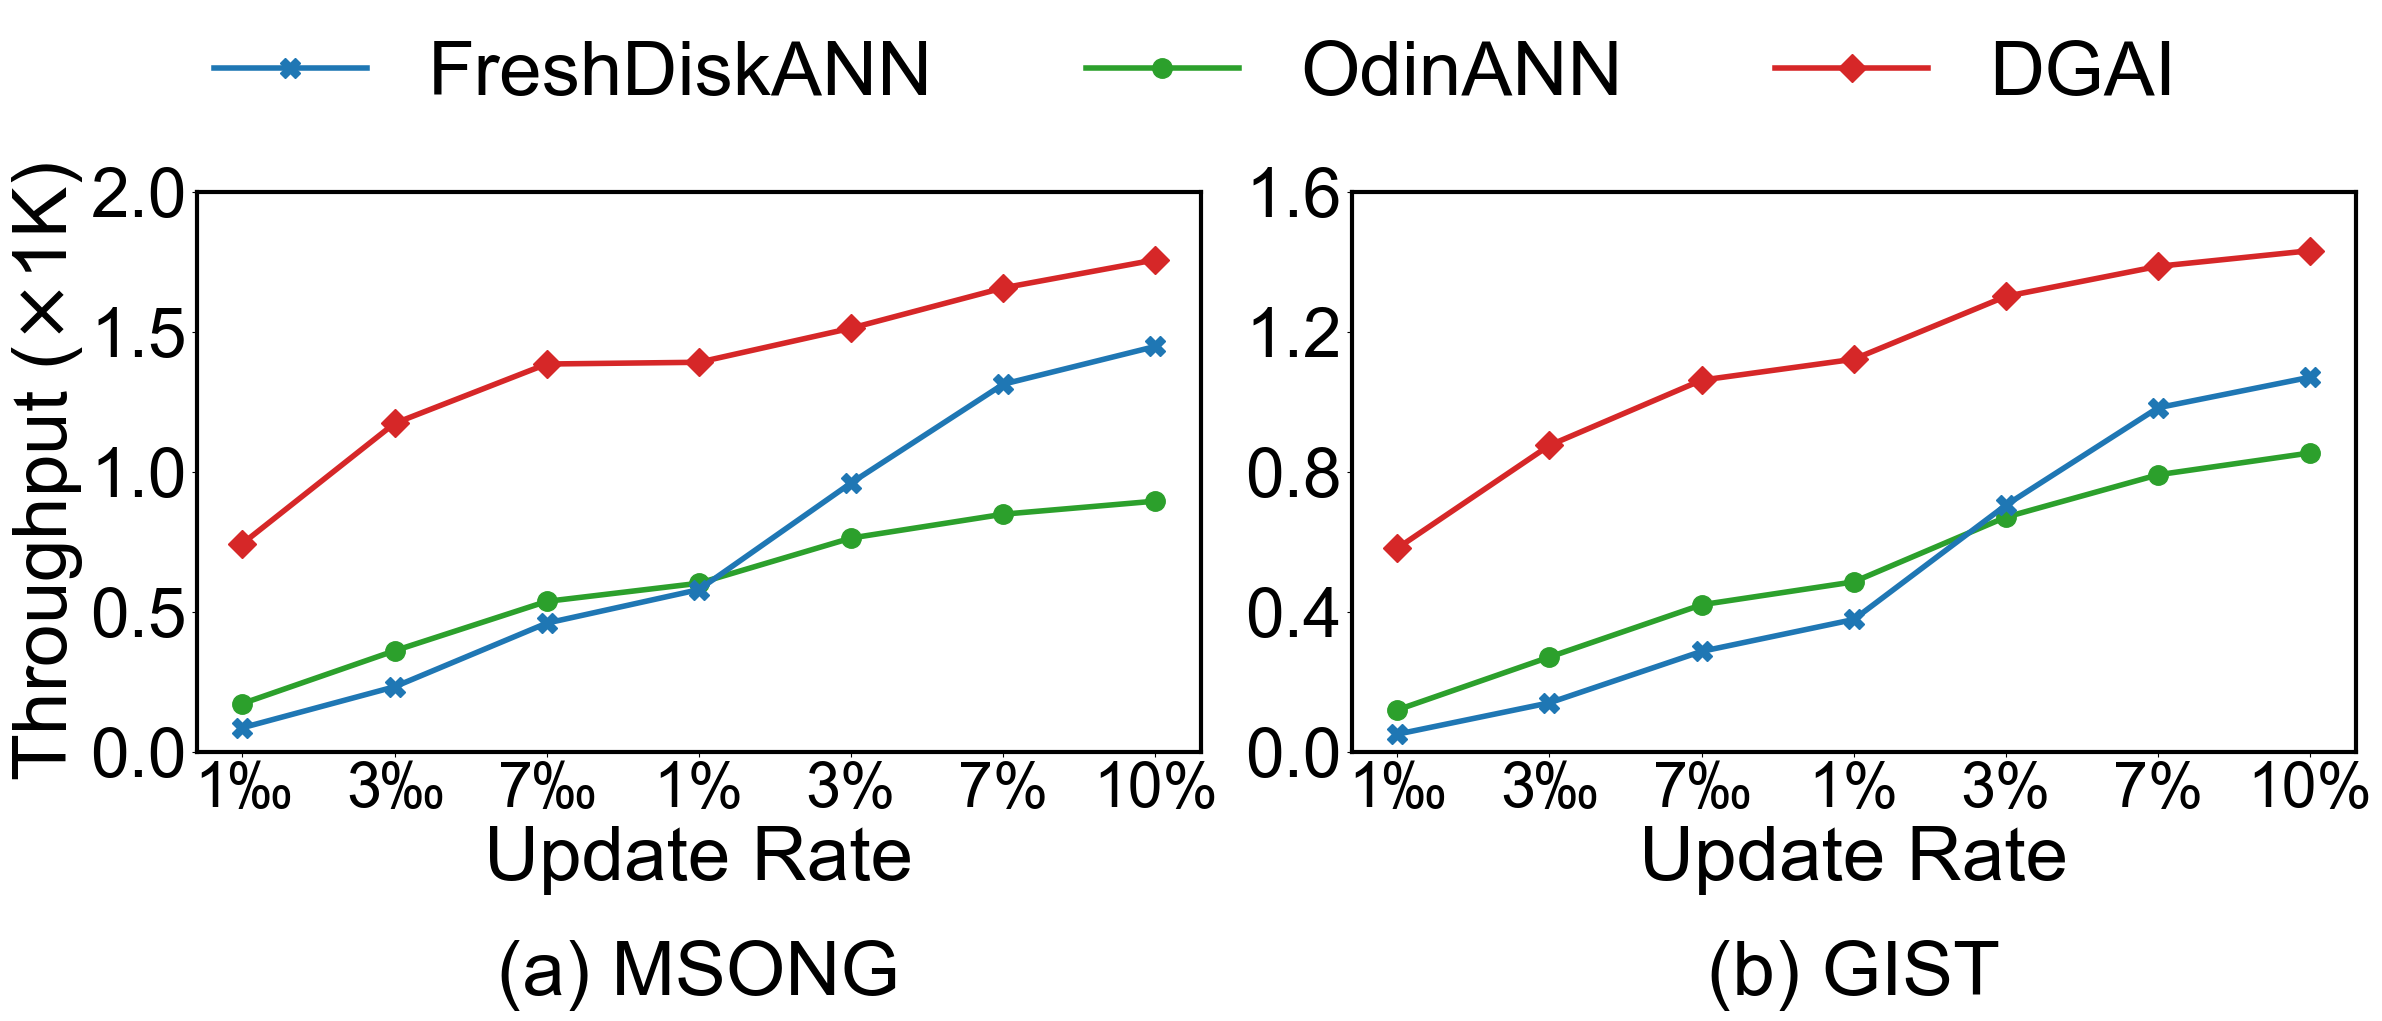

In [109]:
# plot_multi_batch_ratio(multi_bs_data, (0, 1600),"Update Throughput", 'multi_batch_size.pdf')#, '/home/loujh/yq_code/PipeANN-main/shell/pdf/multi_batch_size2.pdf'
plot_multi_batch_ratio(multi_bs_data, (0, 1600), r'Throughput ($\times$1K)', 'multi_batch_size.pdf')#

In [197]:
# plot_multi_batch_ratio(multi_bs_insert, (0, 3000),"Insert Throughput")

In [116]:
# plot_multi_batch_ratio(muti_bs_delete, (0, 16000),"Delete Throughput")


In [110]:
def plot_multi_threads(datasets,  x_label, y_lable, dataset_list=dataset_list, save_path = None):
    """
    绘制Recall-QPS性能权衡曲线图。
    """
    # --- 1. 数据定义 ---
    # 修正点1：移除了最外层多余的花括号，使其成为一个标准的字典。
    
    font_size_all = 55

    # --- 2. 绘图风格定义 ---
    # colors = {'DGAI': '#d62728', 'OdinANN': '#2ca02c', 'FreshDiskANN': '#1f77b4'}
    # markers = {'DGAI': 'D', 'OdinANN': 'o', 'FreshDiskANN': 'X'}
    
    # 修正点2: 定义一个列表来控制绘图顺序，确保与标题匹配
    dataset_order = dataset_list
    dataset_titles = ['(a) Query', '(b) Update']

    # --- 3. 创建图形和子图 ---
    fig, axes = plt.subplots(1, 2, figsize=(24, 12))
    
    linewidth = 4
    markersize = 14

    # --- 4. 遍历数据集和子图进行绘制 ---
    # 修正点2: 循环遍历预定义的顺序列表
    for idx, dataset_name in enumerate(dataset_order):
        ax = axes[idx]
        data = datasets[dataset_name]

        # if idx == 0:
        #     # 在 y 轴上方加一个文字
        #     ax.text(
        #         0, 1.02,              # 坐标（x=0, y=轴顶端稍微偏上）
        #         r"$\times 10^3$",     # 内容
        #         transform=ax.transAxes, 
        #         ha='left', va='bottom', fontsize=font_size_all-15
        #     )
        #     for system_label in colors.keys():
        #         if system_label not in data:
        #             continue
        #         data[system_label] = data[system_label] / 1000
        # if idx == 1:
        #     # 在 y 轴上方加一个文字
        #     ax.text(
        #         0, 1.02,              # 坐标（x=0, y=轴顶端稍微偏上）
        #         r"$\times 10^2$",     # 内容
        #         transform=ax.transAxes, 
        #         ha='left', va='bottom', fontsize=font_size_all-15
        #     )
        #     for
        for system_label in colors.keys():
            if system_label not in data:
                continue

            points = data[system_label]
            if not points:
                continue
            # print(points)
            # return
            recall_data, qps_data = zip(*points)
            # print(recall_data)
            # print(qps_data)
            ax.plot(recall_data, qps_data,
                    marker=markers[system_label],
                    color=colors[system_label],
                    linestyle='-',
                    markersize=markersize,
                    linewidth=linewidth,
                    label=system_label)
        if idx == 0:
            ax.set_ylabel(y_lable[idx], fontsize=font_size_all)
            
        
        # --- 5. 子图格式化 ---
        # ax.set_yscale('log')
        ax.set_xlim(data['xlim'])
        ax.set_ylim(data['ylim']) # 手动设置ylim以获得更一致的视图
        ax.text(0.5, -0.4, dataset_titles[idx], transform=ax.transAxes, ha='center', va='center', fontsize=font_size_all)
        ax.set_xlabel(x_label, fontsize=font_size_all)
        # if idx == 0:
            # ax.set_ylabel(y_lable, fontsize=font_size_all)
        ax.tick_params(axis='both', which='major', labelsize=font_size_all - 5)
        for spine in ax.spines.values():
            spine.set_linewidth(3)
        # ax.grid(True, which="both", ls="--", linewidth=0.5)
            # 提取所有出现过的 thread 数（横坐标 recall_data）
        all_threads = sorted({recall for system_points in data.values() if isinstance(system_points, list) 
                            for recall, _ in system_points})

        ax.set_xticks(all_threads)   # 只在这些整数点打刻度
        ax.set_xticklabels(all_threads, fontsize=font_size_all - 5)

    # --- 6. 创建总图例 ---
    handles, labels = axes[0].get_legend_handles_labels()

    order_map = {'DGAI': 2, 'OdinANN': 1, 'FreshDiskANN': 0}
    handles = sorted(handles, key=lambda h: order_map[h.get_label()])
    labels = sorted(labels, key=lambda x: order_map[x])

    fig.legend(handles, labels, 
               loc='upper center',
               bbox_to_anchor=(0.5, 1),
               ncol=len(labels),
               frameon=False,
               fontsize=font_size_all)
    

    # --- 7. 布局调整和保存 ---
    fig.tight_layout(rect=[0, 0, 1, 0.85]) 
    fig.subplots_adjust(wspace=0.15)

    if save_path is not None:
        plt.savefig(save_path, dpi=400, bbox_inches='tight', transparent=True)
    else:
        plt.show()


In [111]:
# nthreads_list = [1, 2, 4, 8, 16]

# multi_threads_qps = {}
# for dataset in ['SIFT']:
#     multi_threads_qps[dataset] = {}
#     for sys in ['OdinANN', 'DGAI', 'FreshDiskANN']:
#         multi_threads_qps[dataset][sys] = []
#         for nthreads in nthreads_list:
#             # print(f'{log_path}/fig4/{sys}_{dataset}_{nthreads}.log')
#             data = extract_metrics_dict2(f'{log_path}/fig4_recall99/{sys}_{dataset}_{nthreads}.log')
#             # print(len(data))
#             multi_threads_qps[dataset][sys].append((nthreads, data[-1]['QPS']))
#     #         print(data)
#     #         break
#     #     break
#     # break
# multi_threads_qps['SIFT']['xlim'] =(0, 17)
# multi_threads_qps['SIFT']['ylim']=(0, 6e3)
# # multi_threads_qps['GIST']['xlim']=(0, 17)
# # multi_threads_qps['GIST']['ylim']=(0, 1500)


In [112]:
multi_threads_gist_qps = {}
# for dataset in ['SIFT', 'GIST']:
nthreads_list = [1, 2, 4, 8, 16]
dataset = 'SIFT'
multi_threads_gist_qps = {}
for sys in ['OdinANN', 'DGAI', 'FreshDiskANN']:
    multi_threads_gist_qps[sys] = []
    for nthreads in nthreads_list:
        # print(f'{log_path}/fig4/{sys}_{dataset}_{nthreads}.log')
        data = extract_metrics_dict2(f'{log_path}/fig4_2/{sys}_{dataset}_{nthreads}.log')
        # print(len(data))
        multi_threads_gist_qps[sys].append((nthreads, data[-1]['QPS'] / 1000))
        # print(data)
    #     break
    # break
# break
multi_threads_gist_qps['xlim'] = (0, 17)
multi_threads_gist_qps['ylim'] = (0, 6000 / 1000)
# multi_threads_qps['SIFT']['xlim'] =(0, 17)
# multi_threads_qps['SIFT']['ylim']=(0, 6e3)
# multi_threads_qps['GIST']['xlim']=(0, 17)
# multi_threads_qps['GIST']['ylim']=(0, 1500)


In [113]:
update_num = 1000
multi_threads_gist_update = {}
# for dataset in ['GIST']:
dataset = 'SIFT'
#     multi_threads_gist[dataset] = {}
for sys in ['OdinANN', 'DGAI', 'FreshDiskANN']:
    multi_threads_gist_update[sys] = []
    for nthreads in nthreads_list:
        data = extract_metrics_dict(f'{log_path}/fig5/{sys}_{dataset}_{nthreads}.log')[1:]
        # print(data)
        sum = 0
        for x in data:
            sum += x['E2E_update_time']
            # sum += x['E2E_insert_time'] + x['E2E_delete_time']
        multi_threads_gist_update[sys].append((nthreads, 1000 / (sum / len(data))/ 1000) )
#         break
#     break
# break
multi_threads_gist_update['xlim'] = (0, 17)
multi_threads_gist_update['ylim'] = (0, 800 / 1000)

In [114]:
multi_threads_gist = {
    'Query': multi_threads_gist_qps,
    'Update': multi_threads_gist_update,
}

In [115]:
multi_threads_gist_qps['DGAI']

[(1, 0.74815), (2, 1.33879), (4, 2.43572), (8, 4.04339), (16, 5.18436)]

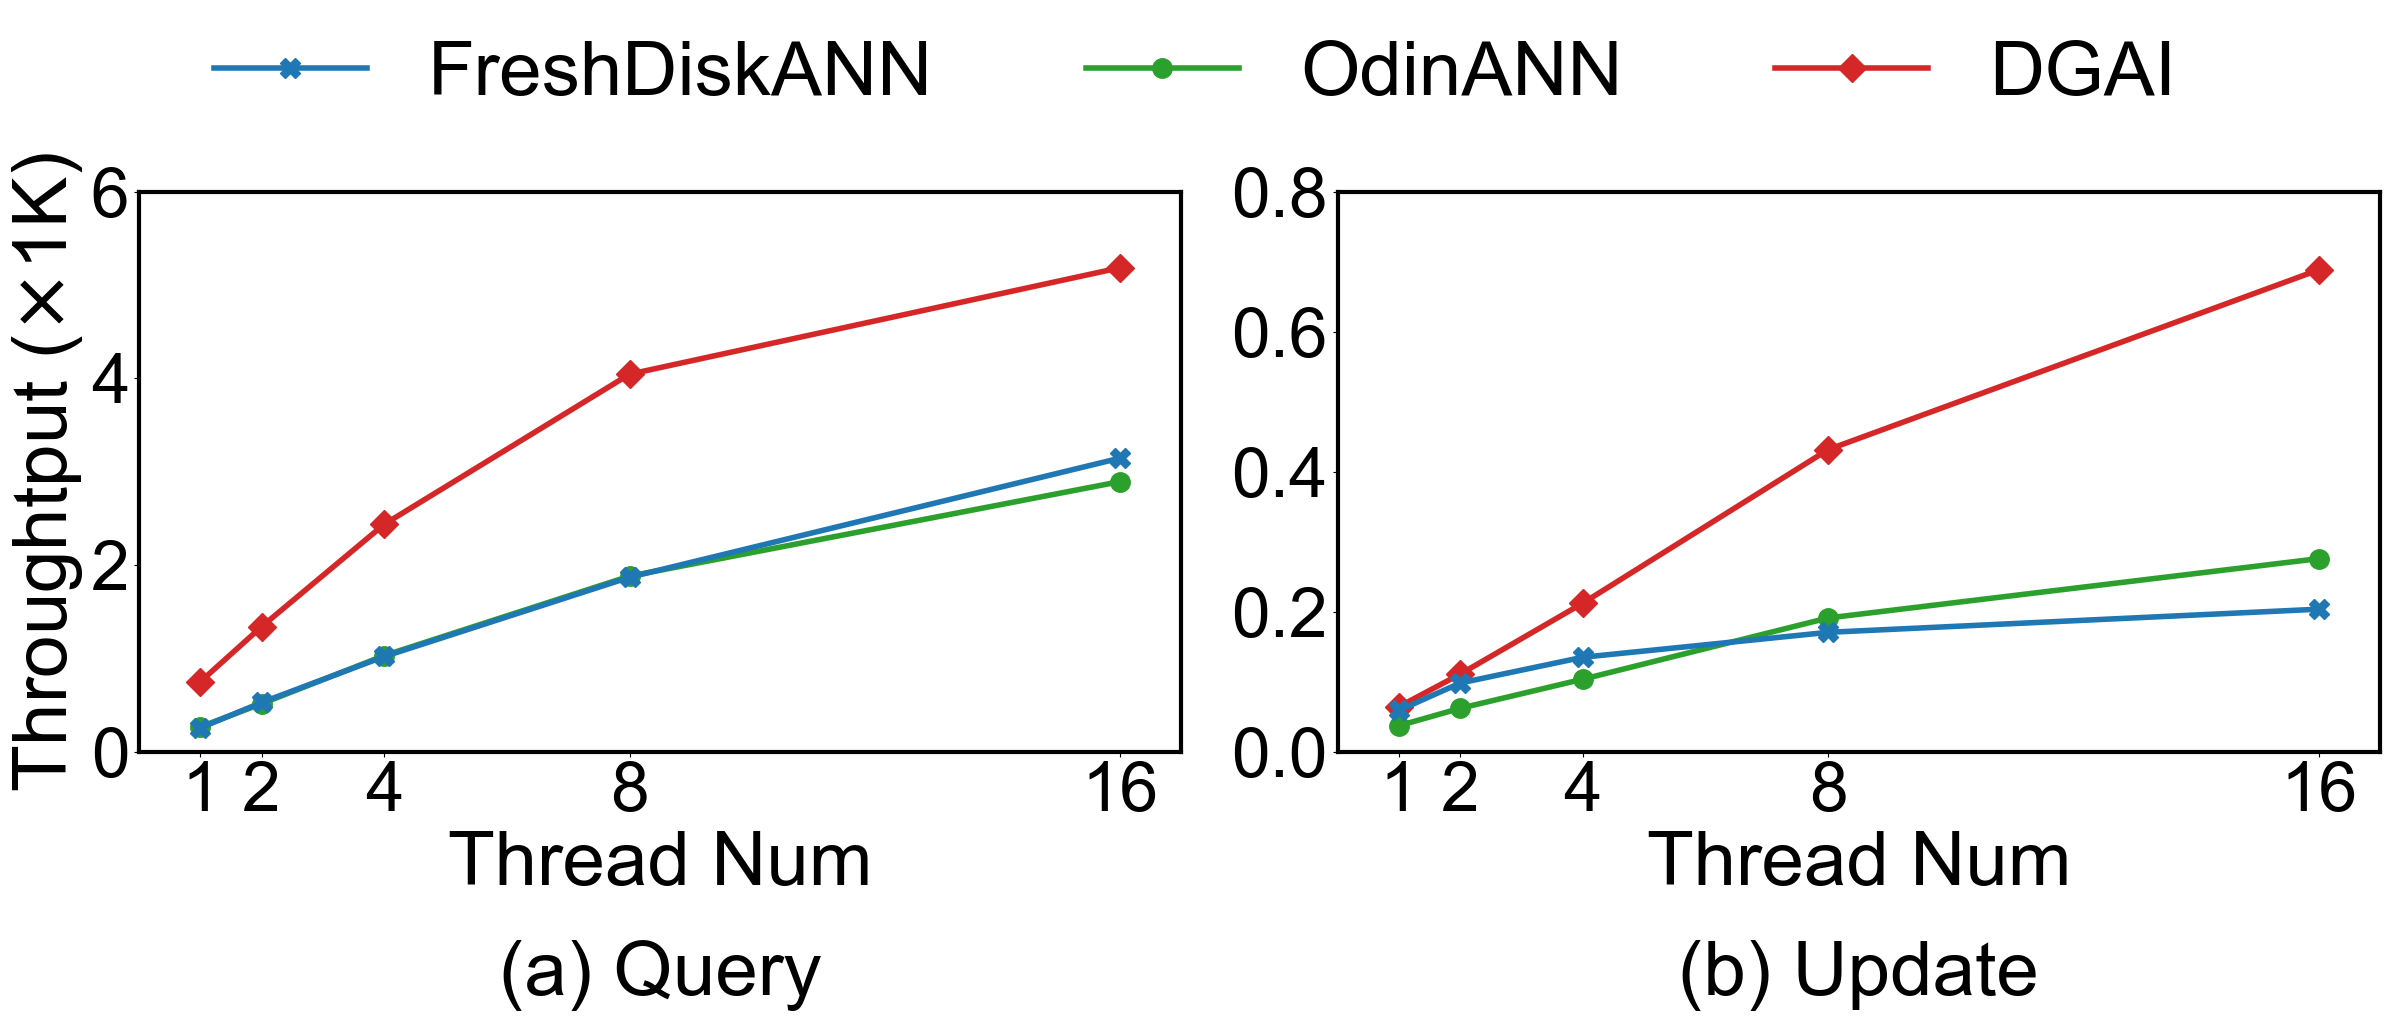

In [116]:
plot_multi_threads(multi_threads_gist, 'Thread Num', [r'Throughtput ($\times$1K)', 'Throughtput'], [ 'Query', 'Update'], save_path="multi_threads_SIFT.pdf")

In [117]:
def plot_multi_bar_subplots():
    # --- 1. 数据定义 ---
    group_labels = dataset_list
    bar_labels = sys_list
    font_size_all = 25

    # # 两种数据类型：update 和 query
    data = {
        'update': {
            'SIFT':   {'FreshDiskANN': 17540294, 'OdinANN': 213976479, 'DGAI': 38036297},
            'UKBENCH':  {'FreshDiskANN': 19561926, 'OdinANN': 38148414,  'DGAI': 11581356.81},
            'Text2Img': {'FreshDiskANN': 18303998, 'OdinANN': 187914756, 'DGAI': 33413235},
            'DEEP':     {'FreshDiskANN': 18640743, 'OdinANN': 262646777, 'DGAI': 40302835},
            'ylim': (1E6, 1E9),
            'xlabel': 'Update',
            'yscale': 'log'
        },
        'query': { # 假设 query 数据与 update 相同，您可以替换为真实数据
            'SIFT':   {'FreshDiskANN': 17540294, 'OdinANN': 213976479, 'DGAI': 38036297},
            'UKBENCH':  {'FreshDiskANN': 19561926, 'OdinANN': 38148414,  'DGAI': 11581356.81},
            'Text2Img': {'FreshDiskANN': 18303998, 'OdinANN': 187914756, 'DGAI': 33413235},
            'DEEP':     {'FreshDiskANN': 18640743, 'OdinANN': 262646777, 'DGAI': 40302835},
            'ylim': (1E7, 1E9),
            'xlabel': 'Query',
            'yscale': ''
        }
    }

    # --- 2. 绘图风格定义 ---
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e'] # 蓝、绿、橙
    hatches = ['//', '-', '.']

    # --- 3. 绘图逻辑 (修改为双子图) ---
    # 修改点1: 创建1行2列的子图，并设置更大的画布尺寸
    fig, axes = plt.subplots(1, len(data), figsize=(12, 6))
    
    data_types = ['update', 'query']

    # 修改点2: 循环绘制每个子图
    for ax, data_type in zip(axes, data_types):
        bar_width = 0.25
        num_bars = len(bar_labels)
        group_width = num_bars * bar_width
        group_centers = np.arange(len(group_labels))

        # 遍历每个组进行绘制
        for i, group in enumerate(group_labels):
            # 修正点: 正确从 data 字典中获取数据
            ours_height = data[data_type][group]['DGAI']

            yscale = data[data_type]['yscale']
            ylim = data[data_type]['ylim']
            # 遍历组内的每个柱子
            for j, bar in enumerate(bar_labels):
                if bar not in data[data_type][group]:
                    continue

                x_pos = group_centers[i] - group_width / 2 + bar_width / 2 + j * bar_width
                height = data[data_type][group][bar]

                # 为了生成统一的图例，只在第一个子图的第一次循环中添加 label
                label = bar if i == 0 else ""

                ax.bar(x_pos, height,
                       width=bar_width * 0.9,
                       facecolor='none',
                       edgecolor=colors[j],
                       hatch=hatches[j],
                       linewidth=3.0,
                       label=label,
                       zorder=3)

                # 在非'DGAI'的柱子上方标注与'DGAI'的比值
                if bar != 'DGAI':
                    ratio = height / ours_height
                    ax.text(x_pos, height * 1.1, f'{ratio:.1f}×', ha='center', va='bottom', fontsize=font_size_all - 7)
            # ax.set_ylim(data[data_type]['ylim'])
            # ax.set_xlabel(data[data_type]['xlabel'], fontsize=font_size_all)
            # ax.set_yscale('log')
            # 设置尺度
            ax.set_yscale(yscale)
            ax.set_ylim(ylim)
            # ax.tick_params(axis='y', labelsize=font_size_all)

            # 刻度格式化（自动适配）
            if yscale == 'log':
                # 用 Matplotlib 内置的 MathText log 格式化器，避免 log10(0)
                ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
                ax.yaxis.set_minor_formatter(FuncFormatter(lambda y, _: ''))
            else:
                # 线性刻度，正常显示
                ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:,.0f}'))


        # --- 4. 格式化与美化 (针对每个子图) ---
        for spine in ax.spines.values():
            spine.set_linewidth(3)

        ax.set_xticks(group_centers)
        ax.set_xticklabels(group_labels, fontsize=font_size_all, rotation=15)

        # ax.set_ylim(1e6, 1e9)
        ax.tick_params(axis='y', labelsize=font_size_all)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'$10^{{{int(np.log10(y))}}}$'))
        ax.yaxis.set_minor_formatter(FuncFormatter(lambda y, _: ''))
        
        # 设置每个子图的标题
        # ax.set_title(f"{data_type.capitalize()} IO Count", fontsize=font_size_all, pad=20)

    # 设置左侧子图的Y轴标签
    axes[0].set_ylabel("Average IO Count", fontsize=font_size_all)

    # --- 修改点3: 创建外部图例 ---
    # 从第一个子图中获取图例的handles和labels
    handles, labels = axes[0].get_legend_handles_labels()
    # 在整个图窗的顶部中心位置创建图例
    fig.legend(handles, labels, ncol=len(bar_labels), fontsize=font_size_all - 4, 
               loc='upper center', bbox_to_anchor=(0.5, 1.02), frameon=False)

    # --- 修改点4: 调整整体布局以适应外部图例 ---
    plt.tight_layout(rect=[0, 0, 1, 0.95]) # rect=[left, bottom, right, top]
    
    # plt.savefig('delete_io_count_subplots.pdf', format='svg', dpi=400, bbox_inches='tight', transparent=True)
    plt.show()


In [118]:
data = {'update' : 
        {'data' : update_io, 'yscale' : 'log', 'ylim' : (1e8, 1e11)}, 
        'search' : 
        {'data' : search_io, 'yscale' : 'linear', 'ylim' : (0, 350)}}

In [119]:
# import numpy as np
import seaborn as sns
import random

import matplotlib.patches as mpatches
# import matplotlib
# import matplotlib.pyplot as plt
# import random

# 1. 绘图和字体配置 (在所有绘图操作之前设置)
# --------------------------------------------------------------------
# plt.switch_backend('SVG')
# 设置PDF和PS的字体类型，确保字体可编辑
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# 设置全局字体族和字体大小
plt.rcParams["font.family"] = "Arial"
plt.rcParams.update({'font.size': 25})
# --------------------------------------------------------------------

font_size_all = 30

# 2. 模拟数据生成（与之前相同，“前密后疏”）
data_string = data_L100
L=100
# 3. 数据处理
data = [line for line in data_string.strip().split('\n') if line][:L]
num_queries = len(data[:L])
queue_length = L
heatmap_data = np.zeros((num_queries, queue_length), dtype=int)
cnt =0
query_positions2 = []
for i, query_positions in enumerate(data):
    positions = [int(p.strip()) for p in query_positions.split()]
    # if(np.max(positions)>15):
    #     if cnt > 20:
    #         break
    #     cnt += 1
    query_positions2.append(positions)
    
query_positions2 = sorted(query_positions2,key=lambda x:-np.max(x))

# for x in query_positions2:
#     print(np.max(x))
stride = 3
query_positions2 = query_positions2[:20]

random.shuffle(query_positions2)
heatmap_data =  np.zeros((stride * len(query_positions2), queue_length), dtype=int)
for i, positions in enumerate(query_positions2):
    for j,pos in enumerate(positions):
        # try:
        if 1 <= pos <= queue_length:
            heatmap_data[i * stride, pos - 1] = 1
    
        # except:
        #     print(i,j,pos)
print(cnt)
# 4. 绘制热力图
plt.figure(figsize=(6, 5))
ax = sns.heatmap(heatmap_data, cmap="YlOrRd", cbar=False)

# --- 更新后的坐标轴自定义 ---

# Y轴: 移除刻度数字，但保留轴线
ax.set_yticks([])
ax.tick_params(axis='y', length=0)

# X轴: 移除默认的刻度和轴线，为绘制箭头做准备
ax.set_xticks([])
ax.tick_params(axis='x', length=0)
ax.spines['bottom'].set_visible(False) # 隐藏原始的底部轴线

# 轴线: 隐藏顶部和右侧的轴线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 手动绘制一个带箭头的X轴线
# 我们在图表坐标的下方(y=-0.07)绘制一个新的箭头，从x=0延伸到x=150
ax.annotate('',
            xy=(L, 0), xycoords=('data', 'axes fraction'),
            xytext=(0, 0), textcoords=('data', 'axes fraction'),
            arrowprops=dict(arrowstyle="->", color='black', lw=plt.rcParams['axes.linewidth']))

# 在新轴线的起点和终点添加文字标签，并确保它们是水平的 (rotation=0)
ax.text(0, -0.01, '0', ha='center', va='top', rotation=0, transform=ax.get_xaxis_transform())
ax.text(L, -0.01, str(L), ha='center', va='top', rotation=0, transform=ax.get_xaxis_transform())
# -----------------------------

# --- 添加图例 ---
# 获取当前颜色映射的颜色
cmap = plt.cm.YlOrRd
# False ANN 使用最浅的颜色（背景色）
false_ann_color = cmap(0.0)  # 最浅的颜色
# True ANN 使用最深的颜色（紫色/橙色）
true_ann_color = cmap(1.0)   # 最深的颜色

# 创建图例句柄
true_ann_patch = mpatches.Patch(color=true_ann_color, label='True ANN')
false_ann_patch = mpatches.Patch(color=false_ann_color, label='False ANN')

# 将图例放在图形顶部中央
legend = ax.legend(handles=[false_ann_patch, true_ann_patch],
                  loc='upper center',
                  bbox_to_anchor=(0.5, 1.35),  # 调整图例位置
                  ncol=2,
                  frameon=False,
                  fontsize=20)
                  
# 设置坐标轴的文字描述
plt.xlabel('Ordinal number ascending to distance', labelpad=30)
plt.ylabel('Query ID')

# 优化布局
plt.tight_layout()

# 5. 保存为PDF文件
# plt.savefig('heat_L50_K10.pdf', format='pdf', bbox_inches='tight')
# plt.close()
plt.show()


NameError: name 'data_L100' is not defined

[([0, 4, 3, 1, 2, 7, 5, 15, 26, 45], 0), ([0, 1, 2, 3, 12, 5, 25, 20, 18, 6], 1), ([5, 9, 8, 0, 2, 21, 1, 3], 2), ([5, 0, 2, 3, 4, 1, 6, 10, 13, 14], 3), ([3, 0, 5, 1, 8, 4, 2, 7, 19, 12], 4), ([0, 1, 3, 2, 4, 23, 20, 9, 17, 15], 5), ([0, 1, 2, 5, 3, 4, 12, 6, 16, 17], 6), ([0, 1, 4, 2, 8, 15, 5, 28, 20], 7), ([0, 5, 4, 7, 1, 9, 52, 28, 8, 22], 8), ([0, 1, 3, 4, 8, 2, 7, 17, 13, 5], 9), ([0, 3, 2, 11, 4, 6, 19, 36, 18, 8], 10), ([5, 1, 4, 3, 2, 0, 7, 8], 11), ([2, 0, 20, 1, 6, 8, 16, 3, 10, 66], 12), ([0, 2, 3, 1, 4, 9, 8, 6, 11, 10], 13), ([2, 0, 1, 5, 4, 3, 6, 10, 25, 8], 14), ([0, 26, 13, 2, 1], 15), ([0, 1, 9, 11, 10, 3, 13, 4, 8, 7], 16), ([5, 3, 17, 6, 0, 21, 9, 4, 2, 14], 17), ([12, 7, 0, 26, 8, 4, 3, 5, 19], 18), ([0, 2, 1, 9, 8, 3, 7, 6, 28], 19), ([0, 5, 4, 1, 3, 10, 36, 2, 16, 8], 20), ([0, 1, 3, 13, 9, 8, 12, 4], 21), ([0, 1, 3, 2, 17, 7, 5, 11, 21], 22), ([0, 2, 3, 8, 1, 6, 14, 5, 18], 23), ([0, 7, 16, 20, 18, 2, 13, 22], 24), ([1, 2, 0, 7, 18, 3, 5, 40], 25), ([0, 1, 4, 2

/tmp/ipykernel_220790/3636618547.py:146: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  true_ann_patch = mpatches.Patch(color=true_ann_color,
/tmp/ipykernel_220790/3636618547.py:150: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  false_ann_patch = mpatches.Patch(color=false_ann_color,


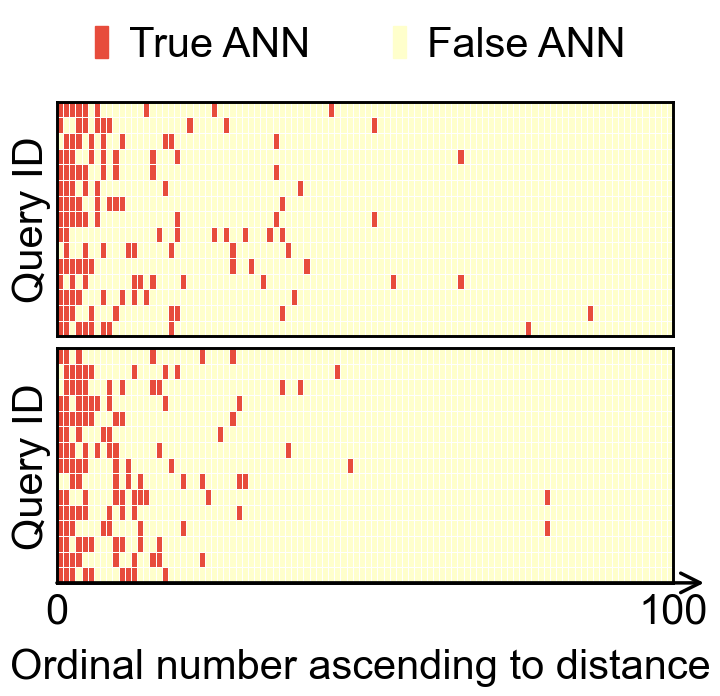

In [ ]:
import numpy as np
import seaborn as sns
import random
import matplotlib.patches as mpatches
import matplotlib
import matplotlib.pyplot as plt

# 1. 绘图和字体配置
# --------------------------------------------------------------------
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Arial"
plt.rcParams.update({
    'font.size': 35,
    'axes.linewidth': 1.5,
    'lines.linewidth': 2.0
})
# --------------------------------------------------------------------

font_size_all = 30

# 2. 数据处理
data_string = data_L100
data_string_2 = data_L100_2
L = 100
data = [line for line in data_string.strip().split('\n') if line][:L]
data_2 = [line for line in data_string_2.strip().split('\n') if line][:L]
query_positions2 = []
query_positions2_2 = []
for i, query_positions in enumerate(data):
    positions = [int(p.strip()) for p in query_positions.split()]
    query_positions2.append((positions, i))

for i, query_positions in enumerate(data_2):
    positions = [int(p.strip()) for p in query_positions.split()]
    query_positions2_2.append((positions, i))
    
print(query_positions2)
query_positions2 = sorted(query_positions2, key=lambda x: -np.max(x[0]))
stride = 1
tmp = query_positions2[:15]

tmp2 = []

query_positions2 = []

tmp = sorted(tmp, key=lambda x: x[1])
for pos, i in tmp:
    print(i)
    for pos2, j in query_positions2_2:
        if i == j:
            tmp2.append((pos2, j))
    query_positions2.append(pos)
# random.shuffle(query_positions2)

heatmap_data = np.zeros((stride * len(query_positions2), L), dtype=int)
for i, positions in enumerate(query_positions2):
    for j, pos in enumerate(positions):
        if 1 <= pos <= L:
            heatmap_data[i , pos - 1] = 1



query_positions2_2 = []

tmp2 = sorted(tmp2, key=lambda x: x[1])
for pos, i in tmp2:
    query_positions2_2.append(pos)

heatmap_data2 = np.zeros((stride * len(query_positions2_2), L), dtype=int)
for i, positions in enumerate(query_positions2_2):
    for j, pos in enumerate(positions):
        if 1 <= pos <= L:
            heatmap_data2[i , pos - 1] = 1


cmap = plt.cm.YlOrRd
false_ann_color = cmap(0.0)  # 最浅的颜色
# True ANN 使用最深的颜色（紫色/橙色）
true_ann_color = cmap(1.0)   # 最深的颜色

true_ann_color = "#E74C3C"  # 红色
false_ann_color = cmap(0.0)  # 浅灰色

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8, 6.25),      # 高度约原来 2 倍，可自行微调
    sharex=True          # 共用横坐标
)

# 上方：heatmap_data   -------------------------------------
sns.heatmap(
    heatmap_data,
    cmap=[false_ann_color, true_ann_color],
    cbar=False,
    linewidths=0.5,
    linecolor='white',
    ax=ax1
)

# 下方：heatmap_data2  ------------------------------------
sns.heatmap(
    heatmap_data2,
    cmap=[false_ann_color, true_ann_color],
    cbar=False,
    linewidths=0.5,
    linecolor='white',
    ax=ax2
)

# 统一对两个子轴做你原先的美化 ---------------------------
for i,ax in [(0,ax1), (1,ax2)]:
    ax.set_yticks([])
    ax.tick_params(axis='y', length=0, which='both')
    ax.set_xticks([])
    ax.tick_params(axis='x', length=0, which='both')

    # 边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.1)
        spine.set_color('black')

    # 箭头
    if i == 1:
        arrow_length = L * 1.05
        ax.annotate(
            '',
            xy=(arrow_length, 0),
            xycoords=('data', 'axes fraction'),
            xytext=(0, 0),
            textcoords=('data', 'axes fraction'),
            arrowprops=dict(arrowstyle="->", color='black', lw=2.5,
                            shrinkA=0, shrinkB=0)
        )

        # 0 和 L 标签
        ax.text(0,   -0.04, '0',  ha='center', va='top',
                fontsize=font_size_all, fontweight='bold',
                transform=ax.get_xaxis_transform())
        ax.text(L,   -0.04, str(L), ha='center', va='top',
                fontsize=font_size_all, fontweight='bold',
                transform=ax.get_xaxis_transform())

# 共用图例（放在整图上方） -------------------------------
true_ann_patch = mpatches.Patch(color=true_ann_color,
                                label='True ANN',
                                edgecolor='black',
                                linewidth=1)
false_ann_patch = mpatches.Patch(color=false_ann_color,
                                 label='False ANN',
                                 edgecolor='black',
                                 linewidth=1)

legend = fig.legend(handles=[true_ann_patch, false_ann_patch],
                    loc='lower center',
                    bbox_to_anchor=(0.5, 0.92),
                    ncol=2,
                    frameon=False,
                    fontsize=font_size_all,
                    handlelength=0.3,
                    handleheight=0.8,
                    handletextpad=0.5)

# 共用 xlabel（放在最底） --------------------------------
fig.text(0.5, -0.015, 'Ordinal number ascending to distance',
         ha='center', va='bottom',
         fontsize=font_size_all, fontweight='bold')

# 左侧 ylabel（只在 ax1 上写即可） -----------------------
ax1.set_ylabel('Query ID', fontsize=font_size_all, fontweight='bold')
ax2.set_ylabel('Query ID', fontsize=font_size_all, fontweight='bold')

# 背景色
ax1.set_facecolor('#F0F0F0')
ax2.set_facecolor('#F0F0F0')

# 布局
plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.15, hspace=0.05)  # hspace 控制子图间距

# 保存
plt.savefig('heat_L100.pdf',
            format='pdf',
            bbox_inches='tight',
            dpi=300)

plt.show()

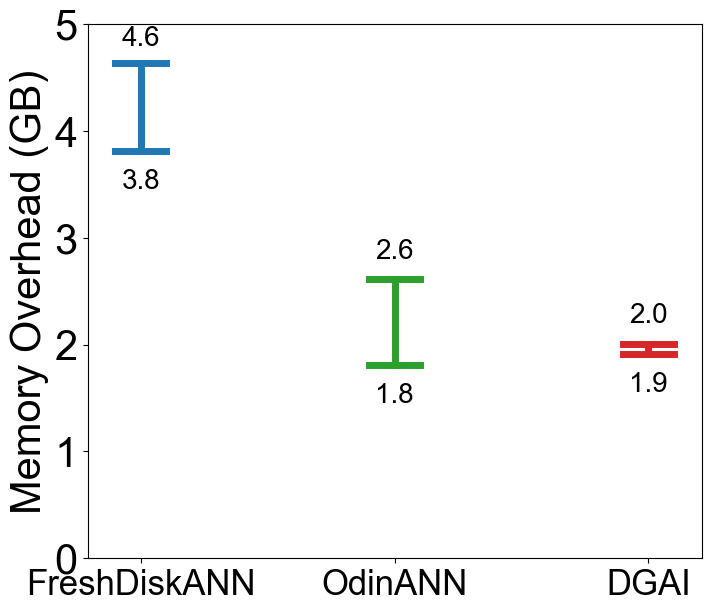

In [120]:
# import numpy as np
# import matplotlib
# import matplotlib.pyplot as plt

# # --- 1. 全局字体和后端设置 ---
# matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams['ps.fonttype'] = 42
# plt.rcParams["font.family"] = "Arial"
# plt.switch_backend('SVG')


# --- 2. 定义数据和颜色 ---
# 原始数据
data_raw = {
    'FreshDiskANN': [4000192, 4861544],
    'OdinANN':    [1893528, 2744452],
    'DGAI':       [2006112, 2101148]
}
for data in data_raw:
    data_raw[data] = [x / 1024 / 1024 for x in data_raw[data]]

# 将数据中的字符串值转换为整数
data = {key: [v for v in values] for key, values in data_raw.items()}

# # 为每个系统定义颜色
# colors = {
#     'DGAI':       '#d62728',  # 红色
#     'FreshDiskANN': '#1f77b4',  # 蓝色
#     'OdinANN':    '#2ca02c',  # 绿色
# }


# --- 3. 绘制范围图 ---
systems = list(data.keys())
n_systems = len(systems)
x_positions = np.arange(n_systems)
linewidth = 5

# 创建图表和坐标轴
fig, ax = plt.subplots(figsize=(7, 6), layout='constrained')

# 循环绘制每个系统的范围线
for i, system in enumerate(systems):
    lower_bound, upper_bound = sorted(data.get(system, [0, 0]))
    color = colors.get(system)
    x_pos = x_positions[i]
    
    # 绘制垂直范围线
    ax.plot([x_pos, x_pos], [lower_bound, upper_bound], color=color, linewidth=linewidth)
    
    # 绘制上下两端的横线
    ax.plot([x_pos - 0.1, x_pos + 0.1], [lower_bound, lower_bound], color=color, linewidth=linewidth)
    ax.plot([x_pos - 0.1, x_pos + 0.1], [upper_bound, upper_bound], color=color, linewidth=linewidth)

    upper_bound = round(upper_bound, 1)
    lower_bound = round(lower_bound, 1)
    # 标注数值
    ax.text(x_pos, upper_bound + 0.15, f'{upper_bound}', ha='center', va='bottom', fontsize=20)
    ax.text(x_pos, lower_bound - 0.15, f'{lower_bound}', ha='center', va='top', fontsize=20)


# --- 4. 美化图表元素 ---
# 设置Y轴标签和图表标题
ax.set_ylabel('Memory Overhead (GB)', fontsize=30)
# ax.set_title('Memory Overhead Range', fontsize=30)

# --- 修改部分 ---
# 将系统名称设置在X轴上
ax.set_xticks(x_positions)
# 设置X轴标签的字体大小为25 (-5)，并倾斜30度，ha='right'确保对齐正确
ax.set_xticklabels(systems, fontsize=25, rotation=0, ha='center')

# 设置Y轴范围和刻度字体
ax.set_ylim(0, 5)
ax.tick_params(axis='y', which='major', labelsize=30)


# --- 5. 保存图表 ---
# plt.savefig("memory_range_xaxis.pdf")
# print("图表已成功生成并保存为 'memory_range_xaxis.pdf'")

In [35]:
# import numpy as np
# import matplotlib.pyplot as plt

# # --- 1. 数据 ---
# data_raw = {
#     "MSONG": {
#         'FreshDiskANN': [1813936, 2464628],
#         'OdinANN':      [1301860, 2153544],
#         'DGAI':         [1407012, 1512276]
#     },
#     "GIST": {
#         'FreshDiskANN': [4000192, 4861544],
#         'OdinANN':      [1893528, 2744452],
#         'DGAI':         [2006112, 2101148]
#     },
# }

# ylim = {
#     "GIST": (0, 5),
#     "MSONG": (0, 3),
# }

# # 转换成 GB
# for dataset in data_raw:
#     for sys in data_raw[dataset]:
#         data_raw[dataset][sys] = [x / 1024 / 1024 for x in data_raw[dataset][sys]]

# # colors = {
# #     'DGAI':         '#d62728',   # 红色
# #     'FreshDiskANN': '#1f77b4',   # 蓝色
# #     'OdinANN':      '#2ca02c',   # 绿色
# # }

# dataset_titles = {
#     "GIST": "(b) GIST",
#     "MSONG": "(a) MSONG",
# }
# linewidth = 4

# # --- 2. 创建两个子图，公用Y轴 ---
# fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False, layout="constrained")

# for ax, (dataset, systems_data) in zip(axes, data_raw.items()):
#     systems = list(systems_data.keys())
#     x_positions = np.arange(len(systems))

#     # 循环绘制每个系统的范围线
#     for i, system in enumerate(systems):
#         lower_bound, upper_bound = sorted(systems_data.get(system, [0, 0]))
#         color = colors.get(system)
#         x_pos = x_positions[i]

#         # 垂直线
#         ax.plot([x_pos, x_pos], [lower_bound, upper_bound], color=color, linewidth=linewidth)
#         # 横线
#         ax.plot([x_pos - 0.1, x_pos + 0.1], [lower_bound, lower_bound], color=color, linewidth=linewidth)
#         ax.plot([x_pos - 0.1, x_pos + 0.1], [upper_bound, upper_bound], color=color, linewidth=linewidth)

#         # 数值标注
#         ax.text(x_pos, round(upper_bound, 1) + 0.15, f'{round(upper_bound, 1)}',
#                 ha='center', va='bottom', fontsize=16)
#         ax.text(x_pos, round(lower_bound, 1) - 0.15, f'{round(lower_bound, 1)}',
#                 ha='center', va='top', fontsize=16)

#     # 设置ylim（每个子图一次就够了）
#     ax.set_ylim(ylim[dataset])

#     # 设置X轴为系统名
#     ax.set_xticks(x_positions)
#     ax.set_xticklabels(systems, fontsize=18, rotation=0, ha='center')
#     # ax.text(0.5, -5, dataset_titles[dataset], transform=ax.transAxes, ha='center', va='center', fontsize=18)
#     ax.set_xlabel(dataset_titles[dataset], fontsize=18, labelpad=10)


#     for spine in ax.spines.values():
#         spine.set_linewidth(2)
#     # 设置子图标题为数据集名
#     # ax.set_title(dataset, fontsize=22)

# # --- 3. 公共Y轴 ---
# axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
# axes[0].set_ylabel("Memory Overhead (GB)", fontsize=22)
# axes[0].tick_params(axis="y", labelsize=20)
# axes[1].tick_params(axis="y", labelsize=20)

# # plt.savefig("/home/loujh/yq_code/PipeANN-main/shell/memory_range_datasets.pdf", bbox_inches="tight")
# # plt.show()


In [122]:

# data_raw = {
#     "MSONG": {
#         'FreshDiskANN': [1813936, 2464628],
#         'OdinANN':      [1301860, 2153544],
#         'DGAI':         [1407012, 1512276]
#     },
#     "GIST": {
#         'FreshDiskANN': [4000192, 4861544],
#         'OdinANN':      [1893528, 2744452],
#         'DGAI':         [2006112, 2101148]
#     },
# }
# all_data2 = [
#     {
#         "MSONG": {
#             'FreshDiskANN': 2464628,
#             'OdinANN':      2153544,
#             'DGAI':         1512276
#         },
#         "GIST": {
#             'FreshDiskANN': 4861544,
#             'OdinANN':      2744452,
#             'DGAI':         2101148
#         },
#     },
#     {
#         "MSONG": {
#             'FreshDiskANN': 1813936,
#             'OdinANN':      1301860,
#             'DGAI':         1407012
#         },
#         "GIST": {
#             'FreshDiskANN': 4000192,
#             'OdinANN':      1893528,
#             'DGAI':         2006112
#         },
#     }
# ]
# for x in all_data2:
#     for y in x:
#         for z in x[y]:
#             x[y][z] = x[y][z] / 1024 / 1024
# plot_multi_bar2(all_data2, ['(a) Update', '(b) Query'], ['IO (GB)', ''], [(0, 6), (0, 6)], ['linear', 'linear'], ['MSONG','GIST'],'io_comp.pdf')

In [123]:
data

{'FreshDiskANN': [3.81488037109375, 4.636329650878906],
 'OdinANN': [1.8058090209960938, 2.6173133850097656],
 'DGAI': [1.913177490234375, 2.0038108825683594]}

In [124]:
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib
import matplotlib.pyplot as plt

# 1. 绘图和字体配置（完全不变）
# --------------------------------------------------------------------
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42
plt.rcParams["font.family"] = "Arial"
plt.rcParams.update({
    'font.size': 35,
    'axes.linewidth': 1.5,
    'lines.linewidth': 2.0
})
# --------------------------------------------------------------------

font_size_all = 30

# 2. 数据处理（完全不变）
data_string   = data_L100_SIFT
data_string_2 = data_L100_SIFT_2
L = 100

data   = [line for line in data_string.strip().split('\n')   if line]
data_2 = [line for line in data_string_2.strip().split('\n') if line]

query_positions2   = []
query_positions2_2 = []
for i, query_positions in enumerate(data):
    positions = [int(p.strip()) for p in query_positions.split()]
    query_positions2.append((positions, i))
for i, query_positions in enumerate(data_2):
    positions = [int(p.strip()) for p in query_positions.split()]
    query_positions2_2.append((positions, i))

# query_positions2 = query_positions2[8590:8597]
query_positions2 = sorted(query_positions2, key=lambda x: -np.max(x[0]))

NameError: name 'data_L100_SIFT' is not defined

In [ ]:
len(query_positions2)

10000

In [ ]:
# for x, y in query_positions2:
#     print(-np.max(x), y)

In [ ]:
query_positions2[:5]

[([4, 3, 15, 1, 0, 25, 9, 5, 2, 51], 1),
 ([4, 2, 3, 0, 1, 5, 7, 21, 6, 9], 4),
 ([0, 5, 3, 7, 15, 8, 2, 9, 6, 13], 0),
 ([0, 1, 4, 5, 2, 14, 11, 8, 13, 3], 2),
 ([2, 1, 10, 3, 7, 12, 9, 8, 0, 5], 3)]

6


/tmp/ipykernel_3975/3501770114.py:184: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=pq1_color,  label='PQ-A True NN',  edgecolor='black', linewidth=1),
/tmp/ipykernel_3975/3501770114.py:185: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=pq2_color,  label='PQ-B True NN',  edgecolor='black', linewidth=1),
/tmp/ipykernel_3975/3501770114.py:186: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color=false_color, label='False NN',     edgecolor='black', linewidth=1)


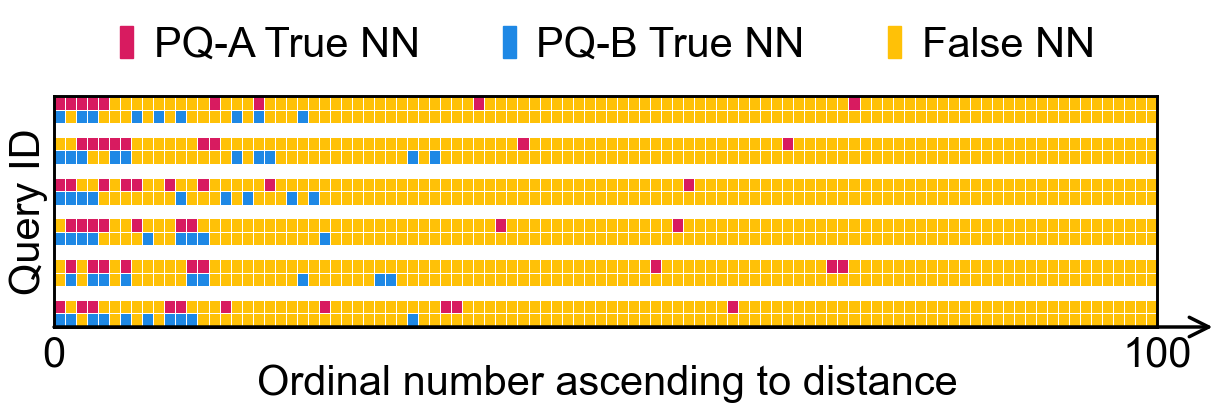

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib
import matplotlib.pyplot as plt
import random

# 1. 绘图和字体配置（完全不变）
# --------------------------------------------------------------------
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42
plt.rcParams["font.family"] = "Arial"
plt.rcParams.update({
    'font.size': 35,
    'axes.linewidth': 1.5,
    'lines.linewidth': 2.0
})
# --------------------------------------------------------------------

font_size_all = 30

# 2. 数据处理（完全不变）
data_string   = data_L100_SIFT
data_string_2 = data_L100_SIFT_2
L = 100

data   = [line for line in data_string.strip().split('\n')   if line]
data_2 = [line for line in data_string_2.strip().split('\n') if line]

query_positions2   = []
query_positions2_2 = []
for i, query_positions in enumerate(data):
    positions = [int(p.strip()) for p in query_positions.split()]
    query_positions2.append((positions, i))
for i, query_positions in enumerate(data_2):
    positions = [int(p.strip()) for p in query_positions.split()]
    query_positions2_2.append((positions, i))

query_positions2 = sorted(query_positions2, key=lambda x: -np.max(x[0]))
tmp = query_positions2[:400]
random.seed(50)
tmp = random.sample(tmp, 6)
# print(query_positions2)
# for x, y in tmp:
#     print(x, y)
# print(tmp)
tmp2 = []
query_positions2 = []
tmp = sorted(tmp, key=lambda x: x[1])
for pos, i in tmp:
    for pos2, j in query_positions2_2:
        if i == j:
            tmp2.append((pos2, j))
    query_positions2.append(pos)

print(len(query_positions2))
heatmap_data = np.zeros((len(query_positions2), L), dtype=int)
tmp2 = sorted(tmp2, key=lambda x: x[1])
query_positions2_2 = [pos for pos, _ in tmp2]

last3_query1 = query_positions2[-3:]
last3_query2 = query_positions2_2[-3:]

# 2. 交换尾部元素（切片赋值：用对方的尾部替换自身尾部）
query_positions2[-3:] = last3_query2
query_positions2_2[-3:] = last3_query1


for i, positions in enumerate(query_positions2):
    for pos in positions:
        if 1 <= pos <= L:
            heatmap_data[i, pos - 1] = 1

heatmap_data2 = np.zeros((len(query_positions2_2), L), dtype=int)
for i, positions in enumerate(query_positions2_2):
    for pos in positions:
        if 1 <= pos <= L:
            heatmap_data2[i, pos - 1] = 1

# # ---------- 交叉数据 ----------
# cross_data = np.zeros((2 * len(heatmap_data), L), dtype=int)
# cross_data[::2]  = heatmap_data      # pq1
# cross_data[1::2] = heatmap_data2     # pq2

# # pq1_color = "#E74C3C"   # 红色
# # pq2_color = "#1F77B4"
# # false_color = plt.cm.YlOrRd(0.0)
# pq1_color = "#D81B60"  # 粉红偏红
# pq2_color = "#1E88E5"  # 明亮蓝
# false_color = "#FFC107" # 琥珀黄
# # pq1_color = "#E15759"  # 红
# # pq2_color = "#4E79A7"  # 蓝
# # false_color = "#76B7B2" # 青绿



# cmap_cross = matplotlib.colors.ListedColormap([false_color, pq1_color, pq2_color])
# cross_plot = np.zeros_like(cross_data, dtype=int)
# cross_plot[::2]  = heatmap_data * 1
# cross_plot[1::2] = heatmap_data2 * 2

# # ---------- 单张图 ----------
# fig, ax = plt.subplots(figsize=(11, 4))   # 保持原尺寸

# sns.heatmap(
#     cross_plot,
#     cmap=cmap_cross,
#     cbar=False,
#     linewidths=0.5,
#     linecolor='white',
#     ax=ax
# )
cross_data = np.zeros((3 * len(heatmap_data), L), dtype=int)

cross_data[0::3] = heatmap_data      # pq1
cross_data[1::3] = heatmap_data2     # pq2
# cross_data[2::3] 默认是 0，全空行

# ---------- 配色 ----------
pq1_color   = "#D81B60"   # 粉红偏红
pq2_color   = "#1E88E5"   # 明亮蓝
false_color = "#FFC107"   # 琥珀黄

# cmap_cross = matplotlib.colors.ListedColormap([false_color, pq1_color, pq2_color])
# cmap_cross = matplotlib.colors.ListedColormap(["white", pq1_color, pq2_color])
cmap_cross = matplotlib.colors.ListedColormap([
    "white",      # 0 → 空行
    pq1_color,    # 1 → PQ1
    pq2_color,    # 2 → PQ2
    false_color   # 3 → False ANN
])

# # ---------- 绘制用的数据 ----------
# cross_plot = np.zeros_like(cross_data, dtype=int)
# cross_plot[0::3] = heatmap_data * 1   # pq1 → 1
# cross_plot[1::3] = heatmap_data2 * 2  # pq2 → 2
# # cross_plot[2::3] = 0 （空行，保持默认）

cross_plot = np.zeros_like(cross_data, dtype=int)
cross_plot[0::3] = heatmap_data * 1   # pq1 → 1
cross_plot[1::3] = heatmap_data2 * 2  # pq2 → 2
# cross_plot[2::3] = 0 （空行，保持默认）

# 把 false ann 的标记改成 3（只在 pq1/pq2 矩阵里）
cross_plot[cross_plot == 0] = 3
cross_plot[2::3] = 0   # 再把空行恢复为 0

cross_plot = cross_plot[:-1, :]

# ---------- 单张图 ----------
fig, ax = plt.subplots(figsize=(13, 3))

sns.heatmap(
    cross_plot,
    cmap=cmap_cross,
    cbar=False,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

# ---- 原 ax1/ax2 的样式全部移植过来 ----
ax.set_yticks([])
ax.tick_params(axis='y', length=0, which='both')
ax.set_xticks([])
ax.tick_params(axis='x', length=0, which='both')

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.1)
    spine.set_color('black')

# 箭头与 0/L 标签（直接搬过来）
arrow_length = L * 1.05
ax.annotate(
    '',
    xy=(arrow_length, 0),
    xycoords=('data', 'axes fraction'),
    xytext=(0, 0),
    textcoords=('data', 'axes fraction'),
    arrowprops=dict(arrowstyle="->", color='black', lw=2.5,
                    shrinkA=0, shrinkB=0)
)
ax.text(0,   -0.04, '0',  ha='center', va='top',
        fontsize=font_size_all, fontweight='bold',
        transform=ax.get_xaxis_transform())
ax.text(L,   -0.04, str(L), ha='center', va='top',
        fontsize=font_size_all, fontweight='bold',
        transform=ax.get_xaxis_transform())

# 图例（3 项）
legend_patches = [
    mpatches.Patch(color=pq1_color,  label='PQ-A True NN',  edgecolor='black', linewidth=1),
    mpatches.Patch(color=pq2_color,  label='PQ-B True NN',  edgecolor='black', linewidth=1),
    mpatches.Patch(color=false_color, label='False NN',     edgecolor='black', linewidth=1)
]
fig.legend(handles=legend_patches,
           loc='lower center',
           bbox_to_anchor=(0.5, 0.9),
           ncol=3,
           frameon=False,
           fontsize=font_size_all,
           handlelength=0.3,
           handleheight=0.8,
           handletextpad=0.5)
# fig.legend(
#     handles=legend_patches,
#     # loc='center left',           # 竖着放时通常放右侧
#     loc='lower center',

#     # bbox_to_anchor=(0.9, 0.5),  # 1.02 → 右侧留一点空隙，0.5 → 垂直居中
#     bbox_to_anchor=(0.32, 0.9),  # 1.02 → 右侧留一点空隙，0.5 → 垂直居中
#     ncol=1,                      # 1 列 → 竖排
#     frameon=False,
#     fontsize=font_size_all,
#     handlelength=0.3,
#     handleheight=0.8,
#     handletextpad=0.5
# )

# 其余标签
fig.text(0.5, -0.10, 'Ordinal number ascending to distance',
         ha='center', va='bottom',
         fontsize=font_size_all, fontweight='bold')
ax.set_ylabel('Query ID', fontsize=font_size_all, fontweight='bold')
ax.set_facecolor('#F0F0F0')

plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.15)   # 保证图例、箭头位置正确
plt.savefig('heat_L100_single.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [235]:
data_L150 = """
0 4 3 1 2 7 5 15 26 45 
0 1 2 3 12 5 25 20 18 6 
7 12 11 1 0 3 4 26 2 5 
5 0 2 3 4 1 6 10 13 14 
3 0 5 1 8 4 2 7 19 12 
0 1 3 2 4 23 20 9 17 15 
0 1 2 5 3 4 12 6 16 17 
0 1 4 2 8 13 17 5 30 22 
0 5 4 7 1 9 52 28 8 22 
0 1 3 4 8 2 7 17 13 5 
0 3 2 11 4 6 19 38 18 8 
0 6 2 5 4 3 1 8 9 
2 0 21 1 6 8 17 3 10 71 
0 2 3 1 4 9 8 6 11 10 
2 0 1 5 4 3 6 10 25 8 
2 1 0 4 37 5 18 6 3 
0 1 9 11 10 3 13 4 8 7 
5 3 17 6 0 21 9 4 2 14 
12 7 0 29 8 4 3 26 5 21 
0 2 1 9 8 3 7 6 28 
0 5 4 1 3 10 37 2 17 8 
0 1 3 13 9 8 12 4 
0 1 3 2 18 4 8 6 12 24 
0 2 3 8 1 6 14 5 18 
0 7 18 23 21 2 54 15 25 
1 2 0 7 20 3 8 5 43 
0 1 4 2 16 10 5 3 8 15 
0 2 1 7 4 5 8 14 6 3 
1 6 0 2 7 4 16 22 5 33 
0 4 3 10 2 13 30 22 1 8 
0 1 2 4 3 9 15 10 12 25 
1 0 2 6 5 8 4 9 15 12 
0 3 2 30 4 9 29 6 8 5 
0 2 1 4 3 5 6 8 15 18 
5 4 2 1 8 6 0 9 10 3 
7 4 1 3 13 2 0 12 
2 0 1 12 5 3 4 8 10 7 
1 0 8 20 4 3 15 5 12 27 
0 1 8 4 2 3 12 7 17 
4 0 1 3 7 2 10 11 39 9 
1 2 3 14 8 9 10 0 4 33 
3 0 2 1 4 21 7 5 38 58 
19 6 14 22 4 3 12 15 2 1 
0 3 4 1 16 6 7 9 8 22 
0 2 1 7 4 3 22 12 13 9 
0 9 11 13 5 6 24 1 21 15 
0 2 6 3 5 19 4 15 1 14 
0 1 7 4 6 3 5 12 23 2 
0 1 3 14 4 2 12 18 11 5 
0 3 1 4 2 5 7 12 9 
0 9 1 3 32 4 31 18 12 13 
0 1 3 4 8 13 6 10 11 7 
2 7 1 6 5 15 3 4 21 0 
0 3 8 5 10 14 12 24 20 2 
0 4 1 20 7 2 13 19 3 10 
0 2 16 11 4 9 6 14 20 21 
5 0 3 1 4 7 9 14 16 
0 2 4 20 1 5 3 33 31 
0 1 2 11 6 51 5 7 
0 1 4 6 2 5 3 8 9 7 
0 8 11 6 12 10 3 1 9 2 
0 1 3 4 15 7 9 25 10 35 
2 1 0 3 5 4 9 8 10 13 
1 0 33 26 38 17 20 40 2 30 
1 11 5 15 8 10 3 7 0 24 
0 1 2 4 3 5 6 7 8 14 
0 1 2 3 4 6 8 14 10 18 
0 1 3 9 14 13 6 21 31 40 
0 1 2 8 11 10 6 22 26 
0 3 2 9 17 7 8 19 1 11 
1 3 0 5 7 6 31 4 37 
1 3 0 2 4 8 6 7 5 
0 1 3 10 2 17 4 8 
1 0 2 5 3 7 6 9 4 11 
1 0 11 5 12 18 8 2 27 7 
0 3 9 5 11 1 2 7 4 28 
9 0 2 3 1 19 4 33 14 10 
0 2 1 5 3 10 7 6 14 26 
0 1 2 8 4 6 3 5 7 11 
2 1 3 4 6 23 7 22 16 0 
0 3 6 4 2 1 7 19 9 5 
0 1 5 11 2 4 12 33 25 8 
0 2 3 1 9 10 4 5 7 6 
1 2 0 5 3 32 6 4 29 41 
0 1 5 16 4 9 18 14 
0 10 2 19 1 3 28 37 14 5 
0 3 8 1 5 17 7 4 22 12 
3 5 13 14 21 57 1 16 70 35 
2 1 0 3 8 7 4 6 9 5 
3 11 2 13 0 15 8 1 39 4 
0 1 8 9 3 11 6 
0 5 1 9 3 6 8 4 13 
1 0 2 20 4 89 7 11 21 38 
0 1 2 3 5 6 4 8 11 12 
0 4 1 2 20 5 9 80 8 6 
4 5 0 2 9 7 1 33 15 21 
1 0 3 2 5 14 4 15 10 8 
19 0 1 2 3 10 14 9 6 28 
0 3 2 1 8 12 11 4 13 15 
2 3 1 0 10 4 12 21 18 11 
"""

data_L100 = """
0 4 3 1 2 7 5 15 26 45 
0 1 2 3 12 5 25 20 18 6 
5 9 8 0 2 21 1 3 
5 0 2 3 4 1 6 10 13 14 
3 0 5 1 8 4 2 7 19 12 
0 1 3 2 4 23 20 9 17 15 
0 1 2 5 3 4 12 6 16 17 
0 1 4 2 8 15 5 28 20 
0 5 4 7 1 9 52 28 8 22 
0 1 3 4 8 2 7 17 13 5 
0 3 2 11 4 6 19 36 18 8 
5 1 4 3 2 0 7 8 
2 0 20 1 6 8 16 3 10 66 
0 2 3 1 4 9 8 6 11 10 
2 0 1 5 4 3 6 10 25 8 
0 26 13 2 1 
0 1 9 11 10 3 13 4 8 7 
5 3 17 6 0 21 9 4 2 14 
12 7 0 26 8 4 3 5 19 
0 2 1 9 8 3 7 6 28 
0 5 4 1 3 10 36 2 16 8 
0 1 3 13 9 8 12 4 
0 1 3 2 17 7 5 11 21 
0 2 3 8 1 6 14 5 18 
0 7 16 20 18 2 13 22 
1 2 0 7 18 3 5 40 
0 1 4 2 16 10 5 3 8 15 
0 2 1 7 4 5 8 14 6 3 
1 6 0 2 7 4 16 22 5 33 
0 4 3 10 2 13 30 22 1 8 
0 1 2 4 3 9 15 10 12 24 
1 0 2 6 5 8 4 9 15 12 
0 3 2 30 4 9 29 6 8 5 
0 2 1 4 3 5 6 8 15 18 
4 2 1 7 5 0 8 9 3 
6 1 3 11 2 0 10 
2 0 1 12 5 3 4 8 10 7 
1 0 8 20 4 3 15 5 12 27 
0 1 8 4 2 3 12 7 17 
4 0 1 3 7 2 10 11 37 9 
1 2 3 14 8 9 10 0 4 32 
3 0 2 1 4 20 7 5 36 52 
19 6 14 22 4 3 12 15 2 1 
0 3 4 1 6 7 9 8 21 
0 2 1 7 4 3 22 12 13 9 
0 9 11 13 5 6 24 1 21 15 
0 2 6 3 5 19 4 15 1 14 
0 1 7 4 6 3 5 12 22 2 
0 1 3 14 4 2 12 18 11 5 
0 3 1 4 2 5 7 12 9 
0 9 1 3 32 4 31 18 12 13 
0 1 3 4 8 13 6 10 11 7 
2 7 1 6 5 15 3 4 21 0 
0 3 8 5 10 14 12 24 20 2 
0 4 1 20 7 2 13 19 3 10 
0 2 16 11 4 9 6 14 20 21 
5 0 3 1 4 7 9 14 16 
0 2 4 20 1 5 3 31 29 
0 1 2 5 36 4 
0 1 4 6 2 5 3 8 9 7 
0 8 11 6 12 10 3 1 9 2 
0 1 3 4 15 7 9 23 10 32 
2 1 0 3 5 4 9 8 10 13 
1 0 31 26 35 17 20 37 2 28 
1 11 5 15 8 10 3 7 0 24 
0 1 2 4 3 5 6 7 8 14 
0 1 2 3 4 6 8 14 10 18 
0 2 8 13 12 5 19 29 38 
0 1 2 8 11 10 6 22 26 
0 3 2 9 17 7 8 19 1 11 
1 3 0 5 7 6 29 4 33 
1 3 0 2 4 8 6 7 5 
0 2 1 12 3 6 
1 0 2 5 3 7 6 9 4 11 
1 0 10 4 11 17 7 26 6 
0 3 9 5 11 1 2 7 4 28 
9 0 2 3 1 18 4 32 14 10 
0 2 1 5 3 10 7 6 14 26 
0 1 2 8 4 6 3 5 7 11 
2 1 3 4 6 23 7 22 16 0 
0 2 5 3 1 6 8 4 
0 1 10 2 4 11 31 23 7 
0 2 3 1 9 10 4 5 7 6 
1 2 0 5 3 32 6 4 29 41 
0 1 5 16 4 9 18 14 
0 9 2 18 1 3 26 35 13 5 
0 3 8 1 5 17 7 4 22 12 
3 5 13 14 21 55 1 16 66 34 
2 1 0 3 8 7 4 6 9 5 
3 11 2 13 0 15 8 1 39 4 
0 7 8 2 9 5 
0 4 8 2 5 7 3 12 
1 0 2 19 3 87 6 10 20 37 
0 1 2 3 5 6 4 8 11 12 
0 4 1 2 19 5 9 77 8 6 
4 5 0 2 9 7 1 33 15 21 
1 0 3 2 5 13 4 14 9 7 
19 0 1 2 3 10 14 9 6 28 
0 3 2 1 8 12 11 4 13 15 
2 3 1 0 10 4 12 21 18 11 
"""

data_L50 = """
0 4 3 1 2 13 
0 1 2 3 12 5 25 20 18 6 
5 8 0 2 15 1 3 
5 0 2 3 4 1 6 10 13 
3 0 5 1 8 4 2 7 19 12 
0 1 3 2 4 22 20 9 17 15 
0 1 2 5 3 4 12 6 15 16 
0 1 4 2 8 14 5 24 17 
0 5 4 7 1 9 49 27 8 21 
0 1 3 4 8 2 7 17 13 5 
0 3 2 9 5 17 32 16 7 
4 1 3 2 0 6 7 
1 0 17 5 7 13 2 9 
0 2 3 1 4 9 8 6 11 10 
2 0 1 5 4 3 6 10 25 8 
0 18 10 2 1 
0 1 8 10 9 3 12 4 7 
5 3 16 0 20 8 4 2 13 
11 7 0 22 8 4 3 5 
0 2 1 9 8 3 7 6 23 
0 5 4 1 3 10 30 2 14 8 
0 1 2 10 6 5 9 3 
0 1 3 2 15 6 9 18 
0 1 6 4 11 3 15 
0 5 12 16 14 2 18 
1 2 0 7 15 3 5 34 
0 1 4 2 16 10 5 3 8 15 
0 2 1 7 4 5 8 14 6 3 
1 6 0 2 7 4 16 22 5 32 
0 4 3 10 2 13 30 22 1 8 
0 1 2 4 3 9 15 10 12 24 
1 0 2 5 4 7 3 8 14 11 
0 3 2 4 9 28 6 8 5 
0 2 1 4 3 5 6 8 15 18 
4 2 1 7 5 0 8 9 3 
1 3 2 0 8 
2 0 1 12 5 3 4 8 10 7 
1 0 8 20 4 3 15 5 12 27 
0 1 8 4 2 3 12 7 16 
4 0 1 3 7 2 9 10 35 8 
1 2 3 12 8 9 0 4 29 
3 0 2 1 4 20 7 5 33 47 
19 6 14 22 4 3 12 15 2 1 
0 3 4 1 5 6 8 7 20 
0 2 1 7 4 3 21 12 13 9 
0 9 11 13 5 6 21 1 19 
0 2 6 3 5 19 4 15 1 14 
0 1 7 4 6 3 5 12 22 2 
0 1 3 13 4 2 12 17 11 5 
0 3 1 4 2 6 10 
0 9 1 3 31 4 30 18 12 13 
0 1 3 4 8 13 6 10 11 7 
2 7 1 6 5 15 3 4 20 0 
0 3 8 5 10 14 12 24 20 2 
0 4 1 20 7 2 13 19 3 10 
0 2 16 11 4 9 6 14 20 21 
0 2 4 8 9 
0 1 2 11 20 
0 1 2 28 4 
0 1 4 6 2 5 3 8 9 7 
0 8 11 6 12 10 3 1 9 2 
0 1 3 4 14 7 9 10 28 
2 1 0 3 5 4 9 8 10 13 
1 0 30 25 33 16 19 35 2 27 
1 11 5 15 8 10 3 7 0 24 
0 1 2 4 3 5 6 7 8 14 
0 1 2 3 4 6 8 13 10 17 
0 2 7 11 10 4 17 25 34 
0 1 2 8 11 10 6 18 21 
0 3 2 9 17 7 8 19 1 11 
1 3 0 5 7 6 27 4 31 
1 3 0 2 4 8 6 7 5 
0 2 1 12 3 6 
1 0 2 5 3 7 6 9 4 11 
1 0 9 4 10 15 6 23 
0 3 9 5 11 1 2 7 4 28 
9 0 2 3 1 18 4 31 14 10 
0 2 1 5 3 10 7 6 14 25 
0 1 2 8 4 6 3 5 7 11 
2 1 3 4 6 21 7 20 14 0 
0 2 5 3 1 6 8 4 
0 1 8 2 4 19 6 
0 2 3 1 9 10 4 5 7 6 
1 2 0 5 3 32 6 4 29 40 
0 8 2 7 
0 7 2 16 1 3 22 29 11 
0 3 8 1 5 17 7 4 22 12 
11 12 17 41 1 26 
2 1 0 3 8 7 4 6 9 5 
3 11 2 13 0 15 8 1 38 4 
0 6 1 7 4 
0 4 2 5 7 3 11 
1 0 2 17 3 5 9 18 34 
0 1 2 3 5 6 4 8 11 12 
0 4 1 2 16 5 9 8 6 
4 5 0 2 9 7 1 33 15 21 
1 0 3 2 5 13 4 14 9 7 
19 0 1 2 3 10 14 9 6 27 
0 3 2 1 8 12 11 4 13 15 
2 3 1 0 10 4 12 21 18 11 
"""

data_L150_K30 = """
0 4 3 1 2 7 5 15 26 45 18 10 13 6 38 8 9 16 19 11 14 135 47 32 12 17 25 20 21 44 
0 1 2 3 12 5 25 20 18 6 23 4 13 10 8 9 7 15 19 16 14 11 49 28 35 43 21 44 32 26 
7 12 11 1 0 3 4 26 2 5 9 24 21 117 22 19 15 27 10 25 14 38 20 
5 0 2 3 4 1 6 10 13 14 35 38 25 61 8 7 28 18 50 29 22 30 15 79 11 44 64 36 
3 0 5 1 8 4 2 7 19 12 15 10 9 17 6 46 11 39 47 53 18 14 43 37 28 38 62 26 32 61 
0 1 3 2 4 23 20 9 17 15 6 10 5 31 14 30 33 16 22 7 26 25 52 21 8 32 29 48 11 12 
0 1 2 5 3 4 12 6 16 17 66 30 7 21 10 25 39 23 28 46 86 32 22 26 9 44 62 
0 1 4 2 8 13 17 5 30 22 31 26 3 39 6 15 10 28 40 11 85 12 9 54 20 18 47 36 
0 5 4 7 1 9 52 28 8 22 13 34 3 78 21 55 12 29 23 17 2 37 6 19 42 11 14 57 20 30 
0 1 3 4 8 2 7 17 13 5 32 18 26 15 6 14 19 12 36 21 44 27 22 10 101 50 9 20 90 
0 3 2 11 4 6 19 38 18 8 5 13 1 9 7 33 16 17 14 57 12 15 24 81 63 48 22 49 32 45 
0 6 2 5 4 3 1 8 9 14 13 11 50 55 33 10 86 26 27 149 56 19 12 38 44 18 
2 0 21 1 6 8 17 3 10 71 23 13 5 39 25 15 9 7 4 20 34 11 139 18 12 14 45 55 78 26 
0 2 3 1 4 9 8 6 11 10 5 7 14 13 19 12 18 34 21 15 27 28 17 24 26 44 20 40 16 36 
2 0 1 5 4 3 6 10 25 8 18 38 12 20 7 39 14 16 15 9 37 29 84 27 33 40 43 11 22 19 
2 1 0 4 37 5 18 6 3 14 40 25 55 8 16 15 12 49 38 35 53 68 
0 1 9 11 10 3 13 4 8 7 5 12 38 29 15 22 20 18 17 39 45 14 32 50 28 16 64 33 
5 3 17 6 0 21 9 4 2 14 15 13 18 45 42 29 44 23 65 33 12 24 8 7 10 76 22 1 36 
12 7 0 29 8 4 3 26 5 21 1 30 38 6 23 16 24 9 43 41 46 2 40 14 15 32 18 33 17 19 
0 2 1 9 8 3 7 6 28 12 5 16 29 10 4 39 15 42 59 14 17 27 18 47 31 68 66 
0 5 4 1 3 10 37 2 17 8 29 13 38 22 16 14 7 9 12 53 15 39 28 6 20 73 54 48 34 67 
0 1 3 13 9 8 12 4 36 47 15 50 46 35 6 25 49 23 17 5 34 20 91 7 37 2 74 
0 1 3 2 18 4 8 6 12 24 10 20 11 31 7 33 23 17 21 22 9 15 19 27 36 65 89 95 50 29 
0 2 3 8 1 6 14 5 18 24 13 15 32 27 31 7 33 11 34 99 50 39 81 9 16 38 
0 7 18 23 21 2 54 15 25 82 14 8 1 26 19 33 17 22 41 4 30 44 9 27 5 90 126 20 
1 2 0 7 20 3 8 5 43 4 40 6 9 10 45 23 15 36 13 112 74 
0 1 4 2 16 10 5 3 8 15 9 17 7 14 19 12 20 13 27 6 43 26 11 28 54 22 30 44 55 
0 2 1 7 4 5 8 14 6 3 20 16 13 26 29 18 9 17 32 27 21 15 40 35 45 28 57 65 49 24 
1 6 0 2 7 4 16 22 5 33 11 15 12 3 14 10 21 8 28 17 30 27 25 20 31 18 19 35 24 37 
0 4 3 10 2 13 30 22 1 8 9 14 5 20 31 17 19 11 7 39 16 6 60 36 55 43 29 50 37 38 
0 1 2 4 3 9 15 10 12 25 53 6 18 8 83 5 11 64 26 31 51 50 29 28 20 16 33 21 34 138 
1 0 2 6 5 8 4 9 15 12 3 11 10 21 16 14 28 18 20 78 23 17 30 33 13 40 65 32 39 
0 3 2 30 4 9 29 6 8 5 1 20 16 18 23 17 31 26 14 33 10 24 12 15 37 27 25 43 13 36 
0 2 1 4 3 5 6 8 15 18 10 14 7 12 17 31 16 9 19 26 33 11 30 29 20 32 34 47 40 13 
5 4 2 1 8 6 0 9 10 3 12 7 26 18 49 19 17 14 16 52 23 45 113 42 29 28 22 11 36 
7 4 1 3 13 2 0 12 5 23 6 24 9 32 33 31 28 16 19 
2 0 1 12 5 3 4 8 10 7 11 15 6 14 9 20 18 21 35 23 13 25 17 34 49 28 31 22 24 26 
1 0 8 20 4 3 15 5 12 27 11 19 82 7 9 107 57 24 37 44 2 54 25 30 140 17 146 31 111 67 
0 1 8 4 2 3 12 7 17 13 26 16 55 19 38 24 22 9 10 25 47 123 60 32 27 15 
4 0 1 3 7 2 10 11 39 9 46 5 14 56 95 6 33 75 31 21 12 36 110 13 20 49 28 23 48 
1 2 3 14 8 9 10 0 4 33 11 5 7 12 15 16 18 6 47 13 36 28 19 63 45 40 20 48 51 17 
3 0 2 1 4 21 7 5 38 58 9 66 17 8 10 28 70 20 23 12 45 52 22 78 48 63 64 25 35 69 
19 6 14 22 4 3 12 15 2 1 20 25 10 5 9 7 0 8 40 13 17 23 28 32 30 18 24 11 55 29 
0 3 4 1 16 6 7 9 8 22 5 21 14 10 18 30 50 38 37 36 13 23 11 45 42 24 34 32 41 17 
0 2 1 7 4 3 22 12 13 9 5 17 23 14 11 25 27 6 24 10 26 21 44 15 32 8 69 43 18 37 
0 9 11 13 5 6 24 1 21 15 4 12 10 26 14 22 20 3 7 2 27 18 19 33 28 37 44 32 
0 2 6 3 5 19 4 15 1 14 30 8 7 11 34 35 39 16 13 9 21 26 10 17 67 32 23 41 
0 1 7 4 6 3 5 12 23 2 20 15 19 16 39 10 22 13 8 9 17 18 63 24 11 21 100 32 73 54 
0 1 3 14 4 2 12 18 11 5 20 98 26 30 22 37 53 36 46 17 10 82 27 41 6 7 29 25 34 49 
0 3 1 4 2 5 7 12 9 14 20 6 59 10 21 24 43 37 16 17 34 26 19 31 50 11 23 49 
0 9 1 3 32 4 31 18 12 13 6 7 21 8 14 2 15 10 5 11 17 19 61 70 24 35 16 48 38 26 
0 1 3 4 8 13 6 10 11 7 14 2 12 5 62 34 21 15 45 26 22 46 56 9 27 28 29 65 24 33 
2 7 1 6 5 15 3 4 21 0 9 10 12 8 20 33 28 36 38 24 37 30 34 14 53 47 23 31 26 48 
0 3 8 5 10 14 12 24 20 2 7 16 4 19 21 1 22 9 18 25 6 13 11 44 31 23 40 28 66 38 
0 4 1 20 7 2 13 19 3 10 6 12 65 34 11 8 59 68 43 71 9 87 24 85 16 27 45 75 53 50 
0 2 16 11 4 9 6 14 20 21 3 1 44 26 63 30 13 10 25 8 17 68 42 90 40 32 39 36 12 19 
5 0 3 1 4 7 9 14 16 11 28 26 6 8 27 56 23 2 15 50 22 32 115 36 39 20 
0 2 4 20 1 5 3 33 31 8 7 10 22 28 65 19 12 9 6 23 17 62 15 25 109 81 13 14 47 
0 1 2 11 6 51 5 7 3 35 39 14 8 19 13 27 43 16 9 79 17 91 34 
0 1 4 6 2 5 3 8 9 7 16 33 17 11 15 19 23 12 42 13 10 45 22 21 29 143 52 38 41 
0 8 11 6 12 10 3 1 9 2 34 5 4 15 23 7 24 18 39 14 84 31 45 51 62 46 22 25 75 43 
0 1 3 4 15 7 9 25 10 35 5 26 69 54 6 39 2 66 31 76 29 87 21 12 79 8 24 18 73 
2 1 0 3 5 4 9 8 10 13 6 7 14 18 22 20 11 24 15 12 16 28 23 29 32 25 43 36 38 31 
1 0 33 26 38 17 20 40 2 30 8 36 34 9 7 62 13 6 23 65 19 32 4 10 11 16 29 12 45 3 
1 11 5 15 8 10 3 7 0 24 14 4 39 50 16 17 29 9 2 6 26 19 21 22 13 34 31 40 32 58 
0 1 2 4 3 5 6 7 8 14 12 13 15 16 19 10 40 28 11 17 18 9 33 23 25 26 46 27 42 21 
0 1 2 3 4 6 8 14 10 18 5 25 33 12 7 20 11 9 21 13 34 27 28 61 30 78 88 41 23 39 
0 1 3 9 14 13 6 21 31 40 8 24 34 15 39 4 26 12 23 17 11 53 71 10 2 38 42 7 5 27 
0 1 2 8 11 10 6 22 26 3 5 36 15 4 7 33 9 48 20 44 39 25 21 18 13 42 66 77 50 
0 3 2 9 17 7 8 19 1 11 18 28 29 24 12 5 26 21 4 38 6 22 49 31 13 34 35 33 111 14 
1 3 0 5 7 6 31 4 37 44 8 14 16 75 2 23 11 27 49 91 19 13 46 20 42 69 81 36 9 
1 3 0 2 4 8 6 7 5 10 16 9 12 11 14 17 13 22 19 15 20 52 26 29 43 46 25 37 18 
0 1 3 10 2 17 4 8 16 5 38 41 43 18 9 52 25 54 15 24 6 32 34 11 49 
1 0 2 5 3 7 6 9 4 11 8 10 21 14 16 13 17 18 22 12 30 27 23 44 15 19 34 35 33 32 
1 0 11 5 12 18 8 2 27 7 19 6 28 40 4 20 10 39 54 41 22 3 9 38 31 13 14 36 71 
0 3 9 5 11 1 2 7 4 28 6 13 17 10 8 18 14 27 30 33 32 22 12 24 16 19 23 42 47 31 
9 0 2 3 1 19 4 33 14 10 30 13 7 5 18 6 11 26 46 40 51 16 23 49 12 54 34 60 31 47 
0 2 1 5 3 10 7 6 14 26 43 16 4 17 11 23 8 50 18 38 9 15 32 27 40 12 93 13 22 20 
0 1 2 8 4 6 3 5 7 11 13 32 22 25 44 9 10 18 28 24 17 21 26 29 16 15 30 27 36 12 
2 1 3 4 6 23 7 22 16 0 14 24 12 10 25 8 5 41 17 9 21 38 19 18 35 27 112 65 28 13 
0 3 6 4 2 1 7 19 9 5 11 12 26 21 10 16 14 15 30 35 17 24 23 13 36 20 45 31 22 
0 1 5 11 2 4 12 33 25 8 20 3 23 17 24 30 7 42 43 15 67 10 27 56 46 18 26 9 44 
0 2 3 1 9 10 4 5 7 6 31 39 66 8 11 40 23 64 20 19 47 12 14 27 55 22 17 33 16 69 
1 2 0 5 3 32 6 4 29 41 13 12 19 31 42 17 9 10 27 24 18 15 16 7 20 14 45 30 35 39 
0 1 5 16 4 9 18 14 17 89 11 13 6 37 23 126 3 10 68 7 125 24 15 55 2 
0 10 2 19 1 3 28 37 14 5 34 40 6 61 11 67 22 24 35 128 62 12 53 4 29 13 41 72 9 96 
0 3 8 1 5 17 7 4 22 12 2 43 32 18 65 35 6 11 24 47 9 20 26 94 73 15 10 21 
3 5 13 14 21 57 1 16 70 35 39 6 10 120 42 0 18 19 22 2 8 24 7 71 4 27 31 68 63 56 
2 1 0 3 8 7 4 6 9 5 16 10 15 12 11 38 19 24 13 17 25 27 31 35 23 39 45 36 46 30 
3 11 2 13 0 15 8 1 39 4 9 7 24 10 17 57 5 16 43 77 49 12 20 48 41 28 26 18 29 6 
0 1 8 9 3 11 6 16 2 5 12 13 4 15 80 14 47 
0 5 1 9 3 6 8 4 13 16 23 15 12 22 27 2 18 10 25 11 29 69 56 35 50 33 40 
1 0 2 20 4 89 7 11 21 38 37 5 14 53 60 9 15 33 27 3 48 29 6 23 8 92 16 95 18 148 
0 1 2 3 5 6 4 8 11 12 9 22 16 7 13 17 19 14 26 25 32 37 29 15 48 27 18 10 20 36 
0 4 1 2 20 5 9 80 8 6 7 3 15 12 35 26 47 60 34 46 33 11 51 49 25 23 18 10 39 24 
4 5 0 2 9 7 1 33 15 21 22 3 16 8 24 6 18 23 59 27 10 11 29 28 14 43 20 12 34 110 109 30 
1 0 3 2 5 14 4 15 10 8 13 12 9 20 26 65 6 98 79 60 28 16 23 61 19 30 21 17 34 
19 0 1 2 3 10 14 9 6 28 7 8 22 4 11 13 16 15 43 24 18 17 29 39 41 37 48 32 89 47 
0 3 2 1 8 12 11 4 13 15 22 6 23 10 40 34 5 14 9 17 19 25 16 48 39 7 57 32 58 42 
2 3 1 0 10 4 12 21 18 11 5 14 36 23 7 70 89 48 15 38 31 32 8 30 40 80 103 9 22 65 
"""

In [230]:
data_L100_SIFT = """
0 5 3 7 15 8 2 9 6 13 
4 3 15 1 0 25 9 5 2 51 
0 1 4 5 2 14 11 8 13 3 
2 1 10 3 7 12 9 8 0 5 
4 2 3 0 1 5 7 21 6 9 
1 3 2 0 9 6 7 24 12 10 
1 8 3 2 4 9 18 17 11 0 
2 3 6 0 11 4 13 7 27 56 
0 1 3 2 4 20 55 15 40 
0 2 3 1 4 7 19 6 54 28 
0 1 2 7 19 6 5 13 17 27 
0 1 2 3 4 8 6 19 5 7 
0 1 3 4 6 2 5 7 22 13 
0 2 20 4 10 8 27 3 5 1 
1 2 11 42 0 4 8 26 3 5 
0 1 5 4 7 8 16 10 12 3 
0 1 2 6 4 3 16 8 5 10 
0 14 1 9 19 2 8 37 16 
0 2 13 11 1 16 4 20 8 
3 0 1 4 5 55 15 52 16 9 
0 3 1 15 7 12 13 14 18 10 
0 1 2 7 9 16 26 8 6 4 
1 4 2 5 3 0 8 15 11 6 
3 0 2 6 4 1 8 10 18 12 
0 1 10 2 15 25 4 7 5 11 
0 1 8 11 12 7 39 15 14 6 
1 0 14 2 3 13 30 15 6 23 
1 0 2 13 6 12 8 4 10 15 
0 3 7 6 1 5 16 2 28 10 
0 2 1 4 14 8 11 12 28 18 
0 5 2 1 3 8 4 6 10 12 
0 1 2 3 4 8 21 6 13 5 
0 5 2 3 6 11 10 1 19 8 
0 8 1 3 11 2 6 5 7 31 
0 1 2 3 7 4 5 36 9 14 
0 1 2 5 7 6 17 28 10 24 
0 1 2 3 8 6 15 11 7 12 
0 1 2 3 5 8 18 13 4 16 
1 0 2 3 4 9 5 13 6 14 
0 1 2 5 14 7 13 22 3 6 
0 3 4 2 1 6 5 15 9 7 
0 7 19 14 3 1 2 10 6 17 
1 3 0 2 4 6 7 8 20 13 
0 1 2 21 14 6 4 7 19 11 
0 2 1 3 4 6 16 22 12 10 
3 1 6 7 2 4 0 12 8 23 
0 3 2 4 12 1 6 5 7 14 
4 1 2 0 10 21 14 24 9 3 
0 1 6 4 3 5 2 11 8 7 
0 1 3 2 4 21 6 11 5 8 
0 1 2 3 5 4 11 10 7 6 
0 3 20 6 1 7 16 13 2 4 
3 2 0 1 8 4 10 14 5 17 
0 8 4 6 26 10 1 7 3 5 
0 10 8 2 5 34 29 1 9 7 
0 1 2 4 5 3 8 15 6 7 
1 0 8 3 10 6 18 7 26 5 
1 0 2 3 16 17 10 9 5 4 
0 1 3 10 2 5 23 11 12 9 
0 1 6 5 2 4 3 10 13 7 
0 4 2 1 6 12 17 7 10 16 
0 2 1 8 7 6 11 3 18 28 
0 1 2 6 25 9 11 15 3 4 
0 2 1 3 4 5 18 40 17 10 
0 1 4 15 2 7 3 5 20 6 
0 9 2 1 19 5 6 3 12 16 
0 2 1 3 5 4 12 11 8 6 
0 3 7 1 8 6 4 2 16 9 
0 1 3 11 4 2 6 7 16 20 
7 0 2 1 19 15 4 17 3 
0 1 2 3 4 12 6 14 7 5 
1 0 2 7 5 8 21 4 13 6 
0 3 2 16 15 46 47 1 12 4 
0 1 2 3 4 9 5 6 7 24 
0 20 1 2 4 5 22 21 6 3 
0 3 1 4 2 5 6 14 
1 0 5 4 3 8 9 2 17 11 
0 2 5 1 6 4 7 13 3 30 
0 3 2 6 4 1 12 7 5 19 
0 3 7 1 2 14 5 9 4 12 
0 1 2 3 4 12 5 13 7 17 
0 1 7 4 15 28 6 31 5 11 
0 1 3 4 60 2 13 43 7 6 
0 10 6 1 11 7 22 5 2 12 
0 9 25 1 6 8 7 41 18 
0 1 3 6 4 2 7 8 11 10 
1 0 6 4 7 5 3 9 26 17 
0 1 6 3 2 5 7 15 9 12 
0 1 2 4 5 3 10 6 7 8 
0 1 2 7 11 4 3 6 16 15 
0 1 8 23 13 3 11 28 5 7 
0 1 2 8 3 7 4 15 5 14 
0 1 2 3 8 9 11 12 14 4 
0 2 1 3 14 8 12 11 5 9 
0 1 2 4 3 15 5 19 7 6 
4 1 0 2 7 11 10 12 3 8 
1 8 2 3 28 7 0 6 5 19 
0 1 2 6 5 4 21 15 16 20 
1 0 2 77 4 23 11 42 20 5 
0 1 3 2 5 6 4 10 11 17 
0 1 8 2 4 5 6 10 7 3 
5 2 6 3 0 1 8 7 11 14 
0 7 3 1 4 11 5 14 13 6 
0 2 4 3 5 1 10 8 6 12 
0 1 4 5 2 7 11 6 12 10 
0 6 3 9 10 26 18 4 30 
0 23 6 12 37 24 2 15 31 10 
0 1 2 9 3 4 5 8 13 22 
0 4 1 3 2 9 6 11 12 5 
0 3 1 6 11 18 7 2 4 19 
1 7 2 12 0 23 40 6 22 3 
5 0 6 3 1 4 7 11 8 2 
0 2 1 3 6 7 5 11 4 13 
7 2 4 3 10 29 11 1 16 0 
2 0 1 3 4 7 6 5 13 8 
0 1 4 18 10 5 2 41 8 37 
0 2 3 1 21 4 12 5 18 11 
0 1 2 4 7 12 5 3 15 30 
1 0 2 4 5 3 6 9 11 15 
0 1 2 4 9 11 3 6 5 27 
1 2 20 5 23 36 22 4 0 8 
0 5 2 16 12 6 4 17 1 3 
0 2 3 6 1 4 12 5 8 18 
0 5 3 2 7 1 11 18 4 8 
2 1 4 0 3 14 11 7 6 15 
0 4 6 11 14 19 1 16 21 18 
0 3 1 10 12 2 4 14 5 13 
0 1 2 4 3 14 5 13 16 10 
1 3 10 0 2 11 5 8 4 6 
1 0 4 17 19 2 5 13 7 3 
1 3 22 0 2 4 10 9 13 20 
0 5 2 4 3 6 19 40 26 7 
2 4 0 6 5 1 3 30 10 11 
0 1 7 3 4 2 5 13 
3 0 1 2 15 8 5 4 18 35 
3 2 0 6 5 1 23 10 35 
0 2 1 3 4 11 5 27 14 10 
3 0 1 11 8 15 4 5 9 2 
0 1 5 3 2 23 10 6 16 17 
1 0 3 31 30 34 5 8 9 7 
0 4 1 7 31 3 18 83 26 16 
1 0 7 2 3 4 6 9 5 10 
0 14 4 3 30 15 1 2 8 
0 1 2 15 3 10 4 7 6 12 
0 2 5 1 3 4 6 8 11 7 
0 2 3 1 4 14 9 5 10 6 
0 1 2 3 4 6 11 7 8 47 
0 3 13 4 1 2 12 10 27 7 
0 3 8 1 2 11 4 12 27 18 
0 3 2 4 7 5 1 13 10 6 
2 0 6 1 3 8 10 24 9 
0 4 3 2 1 6 8 7 27 9 
2 1 0 9 4 8 18 6 5 13 
0 2 1 5 3 18 4 12 11 24 
1 2 6 3 4 0 7 12 15 
0 1 2 3 5 4 6 12 10 23 
0 1 2 8 4 3 11 6 12 13 
0 4 1 2 6 7 11 18 8 35 
0 3 30 2 11 6 4 7 15 1 
2 13 0 1 5 6 3 9 17 8 
0 1 19 2 14 3 5 11 18 40 
0 10 3 4 6 7 21 26 16 18 
1 0 2 3 22 20 27 13 42 19 
0 1 6 3 5 11 15 2 7 10 
2 0 1 5 7 4 13 6 8 3 
8 1 0 2 5 10 12 27 39 11 
0 5 4 10 3 13 1 9 7 2 
0 1 3 6 8 7 2 4 5 14 
0 1 6 16 7 3 4 2 40 8 
0 6 1 2 4 7 14 5 11 24 
0 19 4 14 10 13 2 1 6 5 
0 3 5 1 13 4 2 17 24 16 
0 2 1 79 9 4 47 77 10 16 
0 2 5 1 3 4 9 23 6 12 
1 0 2 4 9 5 12 8 18 7 
0 1 2 3 11 7 4 12 5 6 
3 0 1 7 6 10 2 18 8 14 
0 7 2 5 4 18 17 11 10 14 
0 3 9 2 6 17 1 7 19 5 
0 7 2 9 45 15 13 14 
3 18 0 12 7 8 1 11 6 15 
0 1 13 2 12 6 3 10 14 4 
0 4 15 11 8 6 9 12 5 2 
1 0 13 12 3 21 7 27 8 10 
0 6 4 1 5 2 10 8 3 11 
1 11 0 9 6 7 2 3 5 15 
0 1 3 34 4 8 26 2 11 16 
1 6 5 2 7 16 14 9 4 0 
3 9 12 2 7 10 5 8 1 6 
0 1 2 4 3 20 13 5 14 9 
0 1 2 3 7 4 5 17 10 21 
0 2 1 8 3 4 13 11 35 12 
0 1 8 2 44 4 14 38 21 
2 0 1 3 8 4 9 7 6 18 
1 0 2 4 3 9 21 20 8 72 
3 9 1 0 7 2 10 16 6 4 
3 10 9 7 2 4 6 1 12 17 
0 1 4 2 9 8 26 33 37 36 
2 6 14 8 0 37 33 16 4 17 
1 0 8 2 32 4 6 20 3 
0 1 3 5 2 17 4 6 7 15 
0 1 2 28 6 3 8 13 11 
2 1 0 8 10 3 22 20 34 9 
1 0 4 5 6 8 14 9 3 15 
1 0 2 3 12 6 11 4 10 15 
0 8 3 4 5 6 19 2 1 22 
1 0 5 7 18 6 8 9 10 2 
2 9 4 1 3 0 6 7 5 15 
12 6 2 9 4 3 15 10 14 21 
1 0 7 2 3 25 9 14 8 36 
1 9 27 6 10 50 13 4 21 24 
12 36 8 0 11 14 5 1 7 4 
1 0 2 6 9 11 10 4 3 5 
1 0 2 4 11 13 3 9 29 6 
1 2 0 3 8 4 7 32 31 25 
3 0 2 5 9 7 1 4 17 8 
0 9 6 12 1 17 16 21 11 4 
0 9 11 6 12 4 5 15 3 2 
4 3 11 7 2 9 5 16 30 13 
0 1 3 9 10 2 5 8 11 4 
0 2 3 1 7 6 5 9 31 23 
2 0 4 5 1 14 8 3 24 11 
0 1 28 3 2 17 16 22 8 5 
4 2 0 35 1 11 7 9 6 3 
2 3 8 0 1 9 4 5 17 7 
0 5 1 2 4 12 10 9 6 41 
0 4 1 5 3 2 7 12 8 9 
0 1 2 3 13 14 9 7 6 10 
3 0 1 2 20 24 13 11 4 10 
0 1 8 6 3 2 14 15 4 10 
0 1 3 2 4 7 8 5 9 10 
0 6 2 1 3 5 9 17 19 4 
0 2 3 10 4 5 1 6 12 9 
0 2 1 4 3 7 9 6 5 10 
5 4 8 0 7 19 45 36 3 1 
0 6 10 5 18 17 12 14 2 3 
2 0 5 9 4 1 7 21 3 8 
0 2 3 1 13 6 5 18 8 9 
0 3 1 2 8 5 4 6 72 
1 7 2 0 8 3 26 48 12 4 
0 2 5 1 4 8 15 3 16 13 
0 4 2 1 5 11 30 16 12 
2 6 4 8 12 14 10 11 
3 1 9 2 0 23 5 10 14 15 
4 1 15 0 5 3 2 19 9 14 
1 0 3 2 5 4 22 45 10 12 
0 4 11 3 8 9 18 84 53 
2 0 5 1 9 4 17 3 7 11 
0 5 12 2 13 3 11 6 4 
1 3 16 4 14 2 5 7 6 11 
3 10 5 1 0 4 2 12 13 7 
0 1 2 5 16 23 3 10 7 4 
4 2 5 1 7 11 12 0 43 55 
1 2 4 0 7 3 6 15 10 9 
7 1 3 0 20 8 6 40 79 66 
1 2 0 10 5 15 4 3 19 31 
0 2 1 5 21 6 3 11 7 8 
1 0 3 2 15 17 4 18 5 
2 0 8 3 10 1 14 4 7 6 
0 1 22 93 24 53 5 
0 5 4 2 10 6 9 7 1 24 
0 3 1 18 2 12 5 10 15 
1 0 6 2 9 4 5 7 3 
0 1 2 3 5 4 8 6 7 13 
0 1 3 5 7 2 8 28 12 23 
0 1 2 5 10 7 4 8 13 3 
1 3 4 0 6 2 9 8 5 10 
0 1 18 2 44 14 25 7 3 20 
0 5 1 4 30 53 18 17 25 8 
0 6 13 4 5 8 22 1 2 17 
2 6 1 3 31 4 5 10 9 12 
3 8 2 10 1 22 11 4 0 5 
1 0 6 26 35 2 11 32 5 86 
0 1 2 4 5 3 36 6 33 17 
0 1 11 2 6 5 43 41 32 
0 4 1 3 5 32 6 8 45 10 
0 1 2 5 7 15 3 10 9 26 
0 5 1 6 7 13 9 29 
0 1 2 7 5 4 9 14 
2 0 13 6 23 17 22 35 
0 1 5 4 2 8 3 19 24 9 
0 4 2 15 30 12 5 6 11 
3 0 81 1 2 4 32 5 20 26 
0 1 5 7 3 2 10 4 11 16 
1 0 7 6 2 24 21 5 10 11 
0 1 6 7 8 14 26 5 4 
0 6 1 3 5 2 8 9 11 7 
1 4 5 2 0 11 3 29 13 17 
5 2 1 0 3 4 10 18 9 15 
7 6 4 10 0 2 3 30 29 33 
9 0 7 1 5 10 3 2 15 4 
1 28 0 8 3 9 19 6 62 48 
0 1 7 11 22 4 2 14 18 23 
2 0 3 5 14 16 13 1 46 12 
4 3 1 0 16 12 6 8 13 15 
1 0 3 2 5 4 9 7 20 16 
0 4 2 1 8 9 60 20 23 10 
2 1 0 8 9 5 3 11 7 16 
2 0 1 6 4 7 3 5 10 25 
5 1 2 3 0 18 4 45 8 27 
1 0 2 3 14 7 4 5 11 12 
1 0 8 18 4 6 17 9 23 5 
0 1 2 16 17 8 4 6 10 3 
1 0 2 10 3 4 6 7 16 5 
4 3 5 1 0 2 7 12 15 11 
0 10 3 15 41 8 14 17 13 
0 2 4 3 1 5 13 19 7 15 
0 4 11 2 1 13 7 33 6 3 
0 2 3 5 1 10 11 17 19 7 
1 0 11 13 3 6 7 2 17 14 
1 0 8 3 9 4 6 7 
0 1 10 2 3 21 12 15 18 
13 14 2 7 61 5 8 0 4 1 
0 2 14 17 1 3 4 7 40 10 
0 1 2 5 8 4 3 6 12 7 
0 1 3 2 5 4 9 12 8 23 
0 1 4 2 9 10 8 23 15 3 
3 2 5 0 1 24 11 4 6 7 
0 2 1 3 6 5 19 11 26 13 
0 19 2 1 28 5 8 4 25 11 
0 1 2 3 6 13 4 5 22 19 
0 1 7 32 5 25 6 21 39 
0 4 16 5 1 6 7 8 13 34 
0 1 2 4 3 5 7 9 10 
0 13 5 3 4 20 1 9 8 2 
0 1 10 2 4 8 12 9 14 
1 0 2 12 21 3 64 10 9 
0 1 5 2 4 11 8 3 9 10 
0 1 9 6 5 4 18 16 3 17 
0 1 3 4 9 5 18 10 2 6 
0 1 5 2 3 4 8 42 7 17 
1 0 2 9 11 8 4 15 19 6 
9 10 1 0 7 12 2 8 3 40 
0 4 1 10 3 16 12 6 2 7 
1 0 4 2 5 3 9 6 11 12 
0 2 1 5 3 4 49 18 9 26 
1 3 8 6 0 5 13 15 2 9 
0 2 1 12 9 5 27 4 10 7 
0 1 4 13 3 2 6 5 7 8 
0 2 5 6 7 1 3 8 9 10 
2 0 4 9 6 13 1 5 23 27 
0 1 2 5 3 10 19 4 8 11 
3 9 1 2 4 5 22 21 6 12 
0 1 2 3 4 8 5 6 13 53 
0 1 2 20 7 14 10 4 16 27 
0 1 2 3 5 7 8 16 17 4 
0 1 2 4 3 12 6 27 16 7 
0 1 3 2 4 5 34 9 12 15 
1 0 8 4 3 12 26 6 7 
0 2 3 1 12 8 4 15 17 18 
3 8 4 2 12 11 10 0 19 1 
0 1 6 10 25 2 3 16 30 8 
11 5 0 1 6 19 9 23 4 8 
0 2 1 4 3 18 5 10 9 13 
1 0 3 2 6 5 17 11 7 8 
6 10 2 5 0 25 21 3 31 12 
0 1 2 3 4 8 5 6 7 10 
0 1 2 4 3 5 6 14 8 21 
0 1 2 6 4 9 8 3 7 5 
1 0 3 4 18 9 2 11 12 7 
4 0 9 13 7 14 12 1 18 19 
0 1 2 3 10 5 33 17 4 40 
1 24 7 0 20 9 3 4 11 5 
8 0 7 1 3 11 4 26 14 25 
0 1 14 2 3 19 9 26 11 7 
0 1 2 3 4 7 12 9 5 8 
8 18 5 1 2 3 12 16 0 
0 16 2 8 1 5 9 12 30 15 
0 3 2 1 4 5 15 7 6 21 
3 0 6 2 8 4 7 1 10 22 
0 1 2 6 3 4 10 22 37 5 
0 1 2 3 5 4 6 11 20 7 
0 2 1 6 17 5 3 7 4 15 
0 1 2 8 4 5 12 9 7 21 
6 2 0 4 1 7 5 3 8 9 
1 4 5 22 3 2 0 40 36 9 
1 8 0 2 3 5 6 12 11 4 
2 0 3 20 1 6 9 5 16 8 
0 1 2 5 25 11 3 4 6 16 
0 10 3 1 9 14 6 5 22 2 
0 6 2 11 4 9 8 7 14 12 
0 1 7 8 2 3 19 20 4 24 
0 1 2 4 3 6 8 11 5 16 
0 2 3 4 9 13 1 31 10 22 
0 4 3 1 2 9 13 8 19 6 
1 0 4 3 6 2 12 26 5 11 
3 2 7 0 1 8 23 4 15 6 
1 0 2 5 3 6 4 9 41 7 
5 10 1 0 2 12 11 9 4 3 
1 0 2 8 12 10 24 3 4 20 
0 20 3 6 7 17 13 2 5 11 
1 0 2 3 4 7 20 9 5 19 
1 2 8 0 4 6 57 13 5 
1 0 5 9 33 15 6 4 7 11 
2 0 6 7 1 4 35 17 19 18 
0 1 2 13 12 4 8 7 11 16 
2 1 0 3 10 9 12 6 5 4 
0 4 16 1 34 36 7 15 24 10 
0 1 2 3 25 6 4 11 14 9 
0 1 2 3 6 4 5 9 10 11 
1 0 2 13 6 9 8 7 3 4 
0 5 4 2 11 3 7 10 40 
0 11 9 3 5 22 16 2 15 1 
0 6 2 5 17 1 9 3 14 31 
0 1 8 7 2 5 4 3 6 22 
0 2 1 3 6 15 16 82 5 7 
1 0 3 10 7 19 38 6 8 14 
2 1 4 8 0 7 6 5 11 3 
3 4 0 10 1 6 8 14 5 7 
1 0 4 3 2 7 5 37 10 8 
0 3 1 4 11 6 12 23 5 8 
0 3 18 8 32 33 2 5 17 23 
0 5 2 22 3 1 7 14 8 25 
0 1 5 4 2 7 15 28 17 14 
0 1 3 6 5 8 4 2 11 10 
0 10 3 1 16 48 26 39 2 
0 1 2 4 19 18 8 17 13 3 
0 1 8 2 4 6 5 9 3 25 
6 5 11 1 0 9 8 7 
2 1 5 0 10 6 4 3 9 22 
0 1 2 9 3 6 11 4 5 
0 4 23 22 1 6 3 16 80 7 
1 0 3 2 5 8 12 4 7 9 
1 3 17 0 14 15 10 8 20 38 
1 0 2 3 4 13 6 10 17 
5 1 0 7 4 2 18 41 16 3 
2 17 19 0 30 1 9 7 8 6 
3 4 2 0 6 26 16 1 12 5 
0 1 2 6 3 4 41 5 9 21 
0 1 4 2 3 34 17 8 11 5 
1 3 0 5 13 12 2 7 21 8 
0 2 7 1 14 13 6 4 27 34 
0 1 10 3 6 4 2 8 11 5 
2 6 1 4 3 20 9 10 5 
0 1 2 7 6 4 23 9 18 24 
0 1 3 10 8 19 24 6 7 4 
0 2 1 3 4 5 7 6 12 13 
1 0 2 4 3 21 28 7 38 18 
0 1 2 3 8 5 4 6 7 10 
0 1 2 7 6 3 11 4 15 10 
0 1 2 3 4 9 5 8 6 11 
0 9 6 5 1 7 2 13 14 
0 1 6 2 7 17 3 12 5 19 
1 0 11 4 2 3 8 23 17 6 
0 12 2 6 3 23 5 7 9 
8 0 6 1 3 12 24 7 2 
0 2 19 8 1 21 3 5 33 9 
0 1 3 2 8 9 32 31 4 6 
0 1 8 4 2 5 6 20 11 13 
6 10 4 5 1 8 9 13 16 7 
0 3 1 4 2 7 8 6 14 
0 2 4 1 14 21 6 26 17 30 
0 1 8 6 3 22 4 
0 3 2 10 4 23 9 1 11 
0 1 3 6 10 18 17 2 12 28 
0 1 7 6 3 11 12 5 16 28 
2 0 1 5 15 9 4 3 6 7 
0 1 3 2 9 7 27 6 11 5 
2 0 3 1 6 4 7 9 31 42 
0 1 3 2 4 5 8 17 10 9 
4 2 0 17 8 13 3 34 35 14 
0 6 1 3 2 12 4 13 9 14 
0 1 2 5 8 20 4 3 6 13 
0 1 4 2 3 10 23 5 25 15 
0 1 2 3 7 6 9 5 8 19 
0 2 1 3 5 6 4 15 7 12 
1 0 4 2 7 3 26 6 9 8 
0 2 5 4 3 1 10 6 11 7 
0 1 5 4 7 8 6 9 44 2 
2 3 5 1 6 9 19 26 15 0 
0 1 2 7 4 5 12 8 11 14 
0 1 5 2 8 6 3 28 12 21 
0 1 2 7 6 8 5 4 3 9 
0 4 1 2 5 6 10 9 3 8 
1 0 4 10 7 6 2 26 25 5 
0 1 2 3 8 9 4 13 7 6 
0 1 4 7 6 2 17 5 8 11 
9 2 6 0 5 35 29 31 1 7 
1 0 2 4 8 14 9 3 11 6 
0 1 8 9 2 5 10 3 14 4 
0 3 1 2 7 12 14 10 13 4 
0 1 2 4 13 5 7 3 23 9 
0 4 1 2 5 7 8 3 9 10 
3 1 2 0 8 16 5 7 4 21 
3 4 2 0 13 7 11 1 22 9 
0 1 2 5 9 10 4 7 19 30 
0 2 6 5 1 8 13 11 7 4 
0 2 3 1 6 18 12 8 27 13 
0 5 4 1 24 6 7 37 3 14 
21 1 18 7 15 11 0 13 6 5 
0 1 2 3 4 6 5 8 13 19 
0 1 6 2 4 8 7 32 13 14 
1 0 2 3 7 15 4 6 8 21 
2 3 1 0 11 6 5 10 18 7 
2 0 1 8 3 5 30 18 4 9 
3 1 0 2 4 9 6 12 25 16 
0 2 3 1 10 5 8 7 16 6 
31 7 0 11 12 5 10 16 23 
0 2 1 3 5 14 25 4 13 10 
0 5 1 2 7 3 15 18 23 4 
0 1 3 9 6 4 15 7 8 13 
1 5 0 2 26 16 7 66 4 22 
1 0 4 7 11 2 6 3 16 9 
0 1 7 2 3 4 8 14 17 11 
0 3 1 5 14 17 6 18 9 15 
1 0 6 2 8 39 40 4 3 5 
0 2 1 3 9 11 6 12 19 5 
0 2 3 13 7 17 8 1 30 
0 5 1 6 3 4 2 14 9 10 
0 5 1 7 6 13 2 3 9 4 
0 1 8 2 5 16 3 7 4 26 
0 31 7 2 8 11 14 20 98 1 
3 0 19 4 8 2 1 5 27 
5 0 7 1 4 2 3 6 12 10 
0 1 12 2 8 3 29 4 10 6 
0 3 1 7 6 10 2 8 4 16 
1 0 2 8 7 4 23 5 20 19 
0 2 3 1 4 5 6 7 24 9 
0 1 4 5 2 3 8 9 13 16 
2 0 14 10 15 42 39 16 11 
0 12 2 4 1 6 5 9 3 42 
1 2 0 4 3 9 17 15 14 26 
4 0 2 1 3 6 5 11 7 18 
2 4 0 1 5 24 12 8 19 7 
0 3 1 4 10 12 6 8 2 20 
2 1 0 3 10 4 6 5 11 58 
2 3 1 0 5 6 11 4 7 10 
0 1 2 15 4 8 5 6 3 7 
0 2 6 8 1 7 13 3 18 
0 2 3 9 4 5 11 28 7 1 
0 1 2 8 4 6 7 10 26 12 
0 3 1 7 4 8 18 11 13 2 
0 1 2 4 3 23 11 14 61 17 
0 3 2 1 4 18 8 7 20 5 
0 4 2 1 7 6 9 8 25 5 
1 13 15 0 2 9 4 6 25 5 
0 1 2 8 3 10 4 9 7 5 
0 1 7 3 8 2 4 9 5 10 
8 13 5 19 10 2 33 3 0 4 
0 11 14 1 8 4 2 9 3 
4 1 3 0 5 14 8 2 11 15 
17 4 13 9 10 1 15 23 26 22 
0 3 2 4 7 28 6 8 41 15 
0 1 2 3 4 7 11 5 8 25 
1 0 4 5 3 2 7 10 26 25 
0 2 3 5 1 4 7 6 40 29 
3 6 9 1 0 5 29 13 2 16 
1 0 2 3 4 17 10 6 7 9 
0 2 1 12 8 6 30 10 4 5 
1 0 4 11 3 10 6 5 7 
0 1 4 2 3 10 12 13 19 
0 1 2 3 4 11 20 14 7 5 
0 1 5 7 19 8 10 3 24 2 
1 2 0 15 19 3 39 4 73 5 
4 0 2 1 16 56 9 8 28 46 
1 0 4 7 2 6 5 8 16 11 
0 3 1 5 8 2 6 4 15 36 
0 1 2 8 4 6 10 9 3 5 
0 6 3 1 5 2 4 10 8 21 
2 5 0 1 11 3 10 8 18 4 
0 1 3 2 8 7 5 6 30 9 
0 1 4 3 2 13 12 7 5 6 
1 0 34 13 28 7 21 25 15 9 
0 3 2 15 7 4 5 6 22 13 
2 0 1 14 21 11 10 26 43 5 
5 0 2 1 28 9 10 22 21 51 
0 26 5 1 7 8 33 4 2 
0 1 5 3 42 8 24 6 4 9 
0 2 1 11 8 9 18 33 
0 2 1 3 5 6 7 4 9 10 
1 0 4 2 3 5 12 15 7 9 
6 0 1 2 3 7 19 34 12 18 
0 1 2 3 9 38 12 6 16 8 
1 0 6 5 8 2 11 9 12 4 
1 7 5 2 0 12 3 10 11 4 
0 1 13 3 4 6 11 5 2 56 
0 1 6 2 10 3 14 4 12 27 
0 1 19 7 3 4 10 12 9 8 
1 2 6 0 15 7 4 14 3 10 
0 2 1 14 4 13 25 10 12 17 
0 6 9 2 3 1 14 18 
0 2 1 4 9 6 5 11 3 16 
3 1 0 8 2 6 4 5 15 13 
0 1 2 6 7 14 9 15 3 4 
0 18 1 13 15 7 5 9 4 23 
0 1 3 2 4 11 14 9 13 5 
0 1 2 3 13 14 4 11 20 19 
1 0 3 2 8 6 7 20 16 10 
0 1 4 17 2 3 6 12 75 5 
2 3 4 0 1 8 9 19 12 6 
0 1 17 5 8 7 27 4 30 39 
0 6 1 2 3 5 15 7 12 11 
3 2 1 5 4 16 36 10 8 7 
0 2 3 16 5 6 1 10 15 13 
0 1 4 2 3 5 6 12 16 18 
0 1 11 2 5 3 4 16 31 22 
1 0 3 10 2 7 17 11 21 4 
0 1 3 2 7 8 11 19 4 9 
0 1 9 3 4 10 19 5 18 2 
0 1 5 6 3 4 2 24 17 10 
0 2 3 1 8 13 4 11 7 29 
0 7 2 4 3 1 11 6 13 83 
0 1 9 5 2 3 4 8 26 41 
0 5 9 7 6 10 80 4 14 1 
2 1 3 0 17 14 12 10 5 32 
1 17 0 21 6 23 5 16 15 7 
1 7 4 5 8 0 2 3 16 
0 1 2 6 8 3 12 30 9 7 
0 3 1 2 8 10 7 28 5 16 
0 1 3 10 2 7 17 36 15 57 
0 4 5 3 2 1 6 9 8 17 
1 0 2 3 4 6 5 8 28 7 
0 6 3 4 2 5 1 9 14 20 
2 1 0 3 9 5 18 4 11 13 
2 1 0 5 6 7 8 3 4 10 
0 1 2 8 12 23 4 11 15 
0 2 3 4 11 14 1 21 15 12 
0 22 1 3 11 5 2 6 8 10 
0 2 5 3 1 6 10 24 25 11 
0 2 1 3 4 5 9 15 13 6 
5 2 1 11 24 8 7 3 25 0 
0 4 3 9 10 1 5 2 12 7 
1 2 0 20 7 5 8 13 16 4 
3 7 8 4 1 0 2 18 5 14 
1 2 0 4 12 8 3 6 5 14 
0 1 3 2 20 5 6 18 4 9 
0 3 19 1 5 13 6 18 8 11 
0 3 1 8 4 6 5 20 27 2 
0 1 3 2 5 15 8 4 7 12 
1 0 2 3 6 7 4 5 10 8 
1 0 3 2 4 5 6 7 8 10 
1 0 2 3 4 9 5 6 11 10 
1 0 3 4 2 6 7 12 9 23 
0 4 1 3 2 10 7 6 9 5 
0 3 1 7 14 6 2 10 4 5 
0 2 1 6 4 8 3 13 7 10 
4 1 0 5 3 18 2 9 6 13 
2 0 1 7 4 8 11 22 12 9 
1 0 2 7 9 3 10 12 16 4 
1 0 3 8 6 2 5 4 10 18 
1 11 2 0 9 3 4 6 10 8 
0 1 34 2 19 18 3 15 21 5 
2 1 4 0 6 3 7 5 9 14 
0 2 1 3 4 9 37 6 8 23 
0 1 4 3 2 5 6 16 29 40 
0 4 6 2 3 7 5 18 15 10 
0 12 14 32 24 4 13 2 6 5 
0 1 3 2 7 23 5 38 4 
0 2 4 1 3 7 8 14 5 6 
0 2 1 3 4 49 5 11 27 6 
0 1 3 12 9 5 4 2 10 22 
0 3 1 2 8 11 10 5 9 4 
1 47 42 2 8 29 12 32 21 7 
0 10 6 3 5 8 4 26 2 33 
13 1 9 20 2 6 3 14 0 7 
3 2 0 1 16 28 12 25 6 8 
0 3 2 1 5 9 20 15 38 16 
1 4 0 8 13 12 2 3 16 9 
1 0 2 3 6 7 10 5 8 11 
0 1 3 6 4 2 5 7 8 13 
1 0 4 10 2 11 17 12 3 21 
0 1 2 6 5 3 4 15 10 25 
0 2 4 1 5 3 7 6 29 21 
0 12 1 2 5 3 7 13 8 6 
1 42 3 0 8 20 13 2 4 22 
0 2 1 8 3 10 11 5 7 9 
1 3 2 0 15 8 36 11 19 50 
0 7 5 2 25 16 3 1 8 11 
0 2 4 9 3 5 10 7 16 1 
0 8 3 2 1 5 4 6 13 14 
7 0 3 30 17 12 11 1 9 14 
0 1 2 12 8 6 10 7 4 9 
2 1 5 0 4 8 9 7 3 6 
1 8 0 12 2 5 3 7 6 4 
0 5 1 6 11 12 4 2 14 8 
0 1 8 3 31 5 17 38 2 12 
1 0 9 3 8 18 2 6 22 5 
0 4 2 1 7 3 6 8 9 18 
0 4 3 19 6 2 11 1 14 44 
9 0 4 8 10 16 2 6 22 19 
1 0 3 4 2 12 11 5 18 7 
0 1 4 2 3 6 13 9 11 10 
0 2 1 5 4 3 15 16 11 7 
0 1 2 10 5 3 14 20 13 16 
1 5 4 3 26 17 45 0 40 2 
0 3 4 6 5 1 20 13 44 2 
1 9 3 0 2 12 5 10 7 4 
0 2 1 9 3 21 4 20 10 5 
0 3 1 2 5 4 20 11 21 14 
0 8 1 6 14 5 2 7 10 9 
0 1 3 4 2 19 5 15 22 8 
0 3 2 5 10 17 13 19 12 4 
0 1 16 3 2 4 7 9 6 10 
1 0 7 8 33 14 5 3 2 
0 1 4 6 10 3 5 2 11 12 
0 1 10 2 6 8 3 17 7 21 
1 2 4 0 10 3 9 12 6 15 
0 1 2 3 4 6 8 5 7 9 
0 2 20 18 10 1 7 21 5 6 
1 0 2 3 5 4 10 7 6 9 
0 2 3 8 4 1 7 10 5 22 
0 7 11 1 6 3 2 13 9 54 
0 2 1 6 14 18 4 5 21 31 
4 5 10 1 12 0 17 14 26 
0 2 9 6 7 1 4 5 10 3 
1 0 2 4 5 3 7 8 9 14 
0 1 3 9 13 10 27 29 2 7 
8 4 2 5 3 25 0 1 11 10 
0 2 1 4 3 8 10 19 9 
0 4 1 3 8 17 12 15 5 2 
0 1 3 2 7 4 5 6 12 16 
1 0 14 4 3 41 16 7 8 25 
0 1 9 2 3 12 5 7 6 8 
0 1 3 2 6 8 4 7 12 11 
1 3 14 15 11 0 8 44 6 
0 9 2 6 5 7 1 8 11 34 
0 1 2 3 4 16 6 11 7 5 
75 33 13 19 1 9 2 46 0 8 
2 0 23 11 4 3 25 44 61 19 
2 10 4 0 5 30 3 13 6 8 
3 0 1 4 10 14 18 9 5 12 
0 1 16 5 2 10 25 38 11 17 
0 1 3 2 4 8 11 15 5 6 
0 7 6 9 16 5 2 1 18 22 
1 3 0 2 4 5 8 6 11 17 
3 2 4 0 6 1 5 8 12 15 
2 0 14 12 3 4 11 29 6 18 
0 1 2 9 4 8 16 10 47 5 
2 3 4 6 0 1 14 7 9 16 
1 6 0 2 8 5 4 14 12 3 
0 1 9 10 19 42 53 16 6 
0 1 2 3 6 4 13 8 41 40 
9 0 1 8 11 13 4 6 2 3 
0 2 3 15 59 78 1 14 4 67 
0 1 2 3 4 13 14 32 8 15 
1 8 0 7 4 14 5 29 23 16 
0 1 3 2 9 6 21 30 18 7 
0 1 2 3 8 10 4 5 6 
0 3 12 1 10 2 5 31 13 11 
0 1 5 3 14 9 7 4 12 2 
1 0 16 9 2 5 26 30 17 12 
0 8 6 1 5 2 3 4 14 
0 4 2 1 22 5 6 3 10 19 
0 1 2 32 5 7 16 13 9 11 
0 1 5 26 9 2 30 19 34 
1 5 0 4 3 20 29 7 6 10 
0 1 7 3 38 10 8 4 6 2 
0 7 3 2 1 4 29 20 21 9 
4 2 17 8 20 9 3 14 1 
8 6 0 7 4 2 1 3 5 9 
2 1 4 11 13 3 0 8 6 12 
1 0 4 2 3 7 11 8 13 15 
0 1 2 12 4 3 8 7 21 6 
0 1 2 4 3 13 7 8 6 
0 4 1 3 10 19 2 6 14 7 
0 6 2 8 7 4 3 1 12 15 
5 0 4 2 1 9 3 16 6 8 
0 2 1 3 4 13 11 9 12 5 
2 0 5 3 4 1 6 12 16 14 
1 6 0 52 16 7 2 4 21 44 
9 2 3 4 10 5 1 0 6 7 
0 1 3 2 7 6 8 5 14 4 
0 2 3 1 14 6 10 5 12 13 
5 4 2 0 1 6 9 3 12 13 
0 2 1 4 12 14 5 18 7 3 
0 7 1 3 13 11 14 5 2 12 
1 0 3 8 6 7 2 5 4 14 
0 2 1 8 3 10 18 19 6 5 
0 1 6 2 3 9 4 10 7 8 
1 3 0 2 6 9 15 10 27 5 
0 6 7 4 1 2 3 12 17 5 
2 1 0 5 4 16 11 13 9 8 
1 2 4 11 10 8 5 25 7 6 
2 5 6 3 1 10 42 11 15 17 
1 11 5 3 6 0 56 4 42 16 
0 5 7 1 3 2 6 17 16 4 
5 2 1 0 4 8 13 11 19 29 
0 1 3 6 8 2 4 10 7 5 
0 2 3 1 4 14 6 10 21 22 
1 0 2 3 4 5 8 7 6 10 
17 0 2 4 3 5 28 13 6 
1 0 2 3 14 6 7 8 17 15 
0 2 3 1 9 6 10 15 5 8 
1 9 3 20 27 26 16 0 13 21 
0 1 9 2 8 6 19 4 3 11 
0 1 2 10 4 3 6 13 5 12 
5 0 1 2 6 3 4 8 7 12 
0 3 7 4 1 9 12 5 23 2 
0 1 2 3 9 4 11 8 7 5 
0 1 2 4 7 8 18 22 9 32 
0 1 5 6 3 2 9 15 4 10 
0 1 3 2 4 12 13 16 17 
0 1 2 15 4 30 3 96 7 
2 1 0 13 15 7 6 5 12 
12 8 7 3 1 0 6 11 5 23 
0 3 13 2 1 11 5 7 27 8 
1 3 0 2 4 18 5 25 10 27 
0 1 3 5 2 4 6 7 8 9 
2 0 3 7 8 4 1 28 6 9 
0 1 5 24 8 3 27 16 38 2 
0 2 1 3 4 5 6 7 10 9 
1 31 0 7 19 2 18 8 4 6 
0 1 2 10 5 8 4 3 19 7 
0 1 2 5 9 7 3 11 4 8 
0 4 2 1 3 7 12 11 13 5 
0 1 2 10 3 8 17 4 5 13 
2 0 1 5 3 6 4 8 7 9 
0 3 1 2 11 9 6 5 10 4 
0 7 1 9 2 6 15 11 4 8 
8 3 10 1 2 0 9 16 7 15 
1 0 6 5 2 15 8 20 27 14 
0 1 2 3 5 4 9 6 11 18 
5 0 7 24 1 25 16 4 2 14 
3 9 2 7 1 0 5 6 25 
0 1 4 10 6 2 16 3 18 11 
0 1 7 5 2 10 8 4 25 12 
0 8 2 3 12 1 5 7 17 6 
6 5 0 1 3 2 4 9 14 13 
0 1 4 6 5 2 3 12 10 9 
0 10 11 1 4 3 7 8 2 6 
3 1 0 2 4 10 12 15 7 13 
1 0 5 9 6 2 4 8 3 7 
3 2 0 1 4 6 5 7 26 
0 2 1 3 38 4 5 6 7 12 
2 5 3 1 11 4 16 0 15 18 
0 4 2 1 6 3 15 9 13 11 
1 0 2 6 3 27 12 4 5 
0 1 4 7 2 6 3 8 18 10 
0 1 2 3 4 5 7 6 22 
0 1 2 7 5 12 3 4 11 44 
0 1 3 4 5 6 7 8 10 28 
0 1 2 6 7 15 5 4 8 25 
1 2 3 16 0 7 8 15 42 43 
4 1 10 11 6 3 14 5 9 24 
1 0 5 29 7 2 3 4 15 13 
0 1 3 6 8 2 7 10 4 32 
0 1 2 3 5 9 6 4 11 13 
0 1 2 4 6 10 3 12 7 5 
7 1 0 3 2 11 6 10 9 12 
0 1 2 4 3 5 7 8 9 
0 2 1 3 10 21 9 4 7 19 
0 8 29 9 19 1 13 23 18 
0 3 6 2 1 4 13 5 14 
0 1 4 3 2 20 9 5 8 33 
0 8 1 5 7 15 10 6 3 11 
1 6 5 0 2 3 8 14 16 23 
0 2 1 5 8 7 9 23 11 24 
0 3 1 12 6 15 2 21 23 9 
0 6 2 3 1 7 10 5 32 12 
4 6 11 3 9 5 10 7 26 15 
0 1 2 4 3 5 6 15 8 31 
1 0 7 2 6 4 13 28 19 31 
0 1 5 4 2 13 7 11 8 9 
0 1 5 3 2 6 8 4 13 11 
1 27 2 16 0 3 11 30 13 
0 1 6 2 5 10 4 3 9 8 
0 2 1 7 9 5 6 3 4 23 
0 1 9 10 3 2 8 12 6 5 
0 2 1 3 5 4 8 6 16 7 
1 0 10 7 3 13 43 2 9 22 
2 0 1 7 3 12 6 11 10 17 
0 1 4 2 6 9 5 3 
0 1 3 2 5 4 8 6 9 7 
0 1 12 3 7 5 10 11 2 6 
0 1 2 9 59 5 14 3 7 31 
0 1 3 2 4 5 7 21 10 6 
0 1 5 2 4 8 3 6 25 21 
1 0 2 13 28 17 7 14 8 5 
1 0 4 9 5 10 6 17 3 12 
0 1 2 3 9 4 11 6 5 13 
0 2 1 6 7 26 16 21 3 9 
0 1 2 3 7 6 12 8 4 17 
1 0 2 3 5 4 7 12 17 13 
1 2 0 8 4 5 7 9 42 44 
2 1 0 7 8 5 3 11 23 4 
0 1 2 5 4 7 3 38 29 
0 1 2 3 6 22 5 12 11 8 
0 1 5 10 3 17 14 2 18 12 
0 1 2 3 5 25 4 9 14 32 
0 1 3 2 8 10 17 14 7 12 
0 1 2 7 4 6 8 5 12 3 
0 1 2 3 4 11 15 6 18 14 
1 3 4 0 13 2 10 11 14 5 
3 0 1 2 6 4 14 13 5 7 
2 4 0 6 7 5 1 14 3 8 
8 4 3 5 0 10 11 6 13 14 
0 1 10 4 2 9 12 3 25 6 
0 1 3 2 7 5 10 8 25 
2 1 0 5 12 4 6 8 9 13 
0 2 1 3 6 4 5 7 9 14 
0 2 1 13 34 10 22 5 19 
0 1 3 4 2 10 8 12 6 5 
0 13 5 9 1 2 4 15 16 6 
1 3 0 6 10 2 11 7 14 5 
0 1 3 2 4 6 11 20 16 5 
1 3 0 11 2 19 8 51 20 
0 1 4 3 5 7 25 26 6 8 
0 31 10 2 3 14 8 38 4 29 
0 1 2 4 12 7 6 5 3 8 
1 0 3 5 4 7 11 8 2 13 
0 2 1 8 13 4 15 3 14 17 
0 2 7 5 4 3 1 13 6 10 
1 0 4 2 3 5 7 10 9 23 
0 1 2 4 3 12 6 18 32 8 
0 2 13 7 1 36 4 6 3 18 
0 2 1 4 3 5 7 6 8 9 
0 8 4 10 5 6 3 2 18 1 
1 3 2 18 0 12 9 11 4 
0 1 3 12 2 10 11 13 7 
0 1 3 2 5 4 8 18 25 
0 1 2 5 6 3 13 10 4 14 
0 2 7 1 4 6 22 9 15 
0 1 3 5 4 7 2 9 10 12 
0 1 3 2 9 7 6 26 41 43 
0 8 1 2 6 5 7 3 19 9 
0 2 23 5 20 24 41 1 25 36 
2 3 4 1 6 5 20 40 0 9 
0 1 2 7 6 11 5 4 35 3 
1 2 0 3 6 8 4 5 13 
1 5 0 4 2 7 8 3 9 10 
1 0 7 4 13 2 14 9 6 8 
0 1 2 16 7 4 13 14 6 5 
0 2 1 5 7 8 18 10 15 6 
11 3 0 20 25 24 33 
4 2 1 0 3 5 8 6 21 7 
0 2 1 3 4 5 6 12 10 8 
0 1 3 6 5 13 2 11 19 55 
0 1 3 4 7 2 14 13 15 8 
1 2 0 4 9 8 5 32 14 20 
0 2 4 5 12 1 3 14 9 
0 1 2 5 14 9 8 17 26 
0 1 2 5 4 3 10 7 6 11 
1 2 6 8 5 0 3 4 12 16 
0 1 3 2 4 6 16 17 11 12 
0 6 4 1 2 5 7 40 15 16 
0 1 25 11 6 2 8 3 30 9 
1 0 2 3 7 11 4 5 8 6 
1 3 0 7 13 37 6 10 41 
1 5 0 9 4 3 46 8 21 17 
0 1 3 2 8 5 9 12 4 10 
3 2 11 0 4 16 1 7 8 
0 2 1 4 3 10 7 5 8 6 
0 1 3 2 4 10 5 15 13 11 
0 6 1 3 5 4 9 2 12 13 
0 1 2 5 14 3 11 4 15 7 
0 2 1 3 4 11 8 9 7 5 
0 2 4 1 5 3 9 7 35 15 
0 1 2 14 7 4 12 5 23 3 
0 3 2 1 4 10 17 12 8 9 
3 0 6 9 8 12 5 1 18 
0 2 5 1 3 4 6 8 9 53 
4 3 2 0 6 1 5 14 12 10 
0 1 4 6 7 3 8 29 2 10 
8 1 2 0 30 6 5 4 3 14 
0 2 5 3 9 7 8 19 31 10 
2 9 1 7 26 0 11 4 3 20 
0 1 2 5 3 10 21 44 40 15 
0 3 6 2 4 1 7 8 5 9 
0 3 2 1 4 20 8 7 23 6 
0 2 1 7 12 4 9 13 32 51 
0 1 2 4 5 3 6 8 10 9 
0 2 3 5 1 17 4 6 7 9 
3 1 0 14 9 15 38 2 11 4 
0 1 2 3 4 7 26 15 14 6 
0 1 3 10 2 11 34 12 66 57 
0 1 3 11 4 2 10 23 5 16 
0 1 2 3 4 5 7 13 10 6 
0 1 3 4 2 5 7 8 17 10 
0 1 4 5 2 3 6 19 15 7 
0 4 7 1 5 3 9 2 8 28 
2 0 1 9 3 16 5 6 4 14 
0 1 3 2 4 5 6 12 14 7 
0 2 4 5 8 10 1 13 3 9 
1 0 4 14 16 13 3 2 11 20 
1 2 6 4 5 7 3 10 13 19 
7 0 4 6 18 15 5 3 1 2 
0 8 7 1 3 4 6 29 2 9 
0 1 2 5 12 36 19 9 7 
1 0 2 3 4 6 7 5 10 14 
2 0 4 6 3 5 7 9 29 19 
0 9 28 1 2 5 7 8 3 12 
0 1 3 2 6 4 8 18 5 28 
0 1 3 2 4 9 17 18 5 22 
2 9 0 3 44 5 12 8 4 13 
0 5 1 10 8 14 2 24 16 3 
2 0 8 6 1 20 10 9 28 5 
0 1 6 7 2 3 5 4 9 16 
0 1 2 4 3 7 6 9 11 17 
0 1 2 3 4 5 9 6 8 7 
0 1 2 3 10 12 4 22 15 20 
0 1 20 17 2 21 3 10 15 13 
6 0 21 40 2 54 30 
0 1 2 4 3 5 6 8 7 9 
10 2 16 17 4 1 0 9 7 20 
0 1 3 5 6 4 7 8 21 2 
0 1 5 4 2 11 17 6 12 8 
1 2 3 4 5 0 8 46 15 19 
0 1 3 4 6 2 9 5 8 11 
2 7 3 6 18 1 0 8 24 4 
0 7 2 1 3 11 17 19 70 5 
3 6 0 22 74 5 26 2 10 
0 1 2 3 4 9 12 22 6 15 
9 1 11 4 3 6 0 2 5 17 
1 0 2 4 8 7 17 3 27 6 
2 0 3 4 1 7 5 11 6 29 
0 1 3 4 2 12 8 19 14 10 
5 1 3 9 2 4 0 17 27 8 
0 1 2 5 3 7 8 6 4 10 
0 1 2 3 9 8 4 5 45 6 
0 1 2 5 6 11 3 23 24 12 
3 0 2 8 5 10 22 6 12 27 
2 0 1 4 3 6 5 20 22 21 
1 2 3 10 5 4 6 9 11 0 
1 0 8 5 26 9 19 23 13 4 
0 1 2 3 7 4 5 6 9 36 
3 0 2 1 4 10 6 5 12 36 
0 3 8 5 4 6 14 9 15 1 
1 4 3 0 10 11 2 5 12 6 
1 0 4 3 7 6 2 11 8 15 
10 7 1 0 3 12 6 9 2 13 
0 2 3 5 11 7 90 33 1 13 
2 5 0 16 15 17 
0 5 4 3 30 2 26 27 14 7 
2 3 1 0 50 28 8 9 6 25 
0 1 2 3 4 12 8 6 16 5 
6 10 4 0 2 3 5 22 62 24 
0 1 7 9 2 4 5 6 11 16 
1 2 8 6 4 0 11 15 9 32 
5 0 4 1 2 3 8 6 27 19 
0 1 20 2 8 16 22 30 10 3 
1 3 0 2 7 6 4 5 49 53 
0 1 5 8 9 20 10 3 4 7 
0 25 2 8 1 12 3 4 9 33 
1 0 2 5 4 10 18 7 27 67 
2 4 12 1 5 16 0 35 9 18 
8 0 4 3 6 7 5 28 9 40 
3 2 5 1 0 12 4 11 
0 4 1 5 17 25 32 26 7 3 
0 1 3 4 7 9 2 12 11 10 
1 0 14 5 2 7 3 4 6 10 
0 1 4 7 2 12 3 14 11 8 
0 1 5 4 3 6 8 22 2 11 
0 5 1 2 16 9 18 4 24 8 
2 1 0 3 4 9 5 7 8 6 
0 9 2 5 6 23 4 16 19 18 
1 0 2 4 3 11 18 25 30 15 
0 3 6 1 7 9 4 5 11 8 
2 0 5 7 1 29 9 17 4 12 
0 1 4 2 3 8 5 6 7 17 
0 3 2 17 19 7 8 12 16 9 
0 5 3 1 11 9 7 6 4 2 
0 1 2 3 4 5 6 24 7 10 
0 17 10 4 8 9 1 7 13 21 
0 1 37 8 2 3 11 10 5 6 
0 2 1 4 5 11 8 9 22 15 
0 1 19 4 9 2 3 8 7 20 
3 2 1 0 5 38 30 9 6 87 
1 2 3 22 4 0 6 10 17 28 
1 0 2 10 4 6 7 18 12 40 
1 2 12 32 0 3 11 20 17 10 
0 1 23 4 9 2 3 8 13 45 
0 4 1 17 5 16 8 3 20 9 
6 1 0 18 5 7 2 3 8 12 
1 0 3 4 2 13 41 6 5 27 
0 7 6 1 8 9 2 13 19 14 
2 0 6 4 11 7 5 3 1 53 
0 3 1 7 2 10 6 5 17 8 
4 0 2 1 7 28 14 9 6 3 
0 1 2 3 6 5 4 15 7 24 
3 4 5 0 6 1 10 2 11 21 
0 1 5 2 6 3 7 12 4 11 
1 4 6 0 3 2 22 10 9 5 
0 1 3 2 14 7 8 5 6 11 
1 13 6 27 3 19 40 9 0 42 
1 0 3 2 6 12 4 7 5 19 
0 10 4 5 11 1 2 32 30 7 
0 3 15 1 12 6 7 5 2 
0 1 5 3 6 2 7 11 4 12 
1 6 2 0 7 15 23 4 3 8 
3 2 1 17 16 5 4 18 0 7 
1 0 5 7 30 11 13 4 2 6 
0 1 2 3 23 20 21 7 8 46 
0 1 5 6 2 4 7 10 8 17 
1 4 5 2 3 0 23 6 7 8 
1 0 3 4 2 8 7 10 5 15 
0 2 3 1 4 15 6 7 11 21 
4 2 6 5 9 13 8 1 20 22 
0 2 1 3 18 4 5 19 11 7 
1 5 0 4 39 18 8 3 2 41 
0 1 12 6 3 7 4 5 18 9 
0 2 1 6 3 4 11 5 14 21 
1 0 2 5 3 6 12 7 13 10 
0 3 7 6 10 2 1 61 11 15 
0 1 3 6 10 4 21 7 2 14 
0 15 1 7 3 14 5 2 27 
2 1 0 3 5 4 11 12 6 8 
0 8 2 9 4 13 6 7 1 5 
0 8 3 2 4 5 6 10 7 17 
0 1 2 8 3 9 5 13 11 7 
2 0 3 8 6 1 9 10 15 5 
0 1 5 12 9 19 28 29 10 4 
3 0 10 15 6 13 11 17 22 5 
0 1 2 6 5 8 23 25 7 3 
0 3 1 2 7 9 28 15 4 23 
3 1 7 5 9 8 0 6 11 13 
0 4 3 2 12 1 6 5 14 21 
0 4 2 3 1 6 7 5 15 33 
0 1 2 4 3 8 7 6 9 10 
3 9 0 1 2 6 16 35 10 
0 4 1 6 19 3 10 2 7 21 
2 0 5 3 15 4 12 11 8 1 
0 3 1 10 19 7 35 6 11 4 
0 2 3 1 7 8 4 28 14 6 
3 15 1 0 6 9 2 10 14 5 
0 1 10 2 9 11 14 15 22 5 
1 0 2 3 4 5 15 6 20 18 
0 6 1 7 2 9 4 5 23 20 
0 4 2 1 3 6 32 12 19 5 
0 2 3 1 4 7 19 13 11 12 
4 0 1 5 3 7 6 19 2 11 
16 7 4 5 2 11 9 3 29 18 
1 3 13 22 2 15 6 4 19 5 
1 0 14 2 6 11 3 17 8 22 
2 0 4 1 15 8 10 20 9 46 
4 5 3 6 0 14 2 8 15 1 
3 2 1 5 4 0 31 6 12 16 
1 0 4 2 3 48 14 8 13 17 
0 7 3 1 21 2 8 4 36 9 
0 18 3 5 9 1 8 7 16 17 
1 0 2 4 3 6 5 8 13 7 
4 0 3 1 2 5 6 13 8 7 
0 4 1 2 8 3 7 9 12 5 
0 2 29 6 5 1 9 8 18 12 
0 5 3 4 2 8 6 11 10 17 
4 1 0 2 5 8 13 3 36 6 
7 1 62 5 3 4 6 12 27 85 
7 0 1 6 18 13 21 5 15 4 
0 2 1 18 9 16 28 10 11 3 
0 7 2 5 4 10 1 8 18 12 
2 0 5 1 11 4 3 6 8 12 
0 3 2 1 22 19 17 33 14 11 
1 18 0 2 3 10 9 14 6 13 
1 0 9 8 2 10 11 5 7 56 
0 4 3 1 7 13 11 8 36 15 
0 1 7 3 4 5 2 33 12 19 
0 8 2 3 1 4 10 5 6 47 
0 1 5 10 2 12 6 8 18 23 
6 0 2 1 3 4 5 7 19 8 
0 1 5 8 4 16 2 6 17 9 
0 1 2 12 11 7 4 5 8 15 
0 1 2 7 4 3 5 10 16 9 
0 13 9 3 35 10 7 1 6 2 
1 3 11 2 9 0 27 14 18 38 
0 1 2 3 6 11 8 7 4 9 
0 1 7 2 6 12 5 4 3 8 
1 0 5 6 7 3 11 2 19 20 
1 0 3 2 6 5 9 10 21 8 
1 4 3 2 0 19 11 13 24 42 
1 7 4 0 2 3 19 5 8 12 
5 2 14 1 7 4 13 9 8 12 
5 3 6 12 0 4 14 11 28 9 
0 5 6 7 4 9 32 1 3 20 
1 0 3 8 15 7 2 22 5 14 
0 1 25 3 2 7 9 5 6 17 
0 2 1 6 10 7 5 24 8 91 
0 1 3 2 6 4 7 9 5 21 
0 3 5 4 14 1 2 10 27 12 
17 0 9 8 1 3 16 4 10 7 
12 0 4 6 24 1 9 5 7 2 
1 0 2 19 4 7 3 8 12 10 
0 8 1 4 11 2 7 5 9 6 
0 3 13 4 5 6 7 15 1 2 
0 1 4 2 5 3 9 8 7 6 
0 1 6 4 2 5 11 8 53 13 
1 0 2 3 4 6 11 8 10 5 
1 6 0 5 8 9 2 3 4 11 
4 3 10 2 1 11 45 0 9 6 
0 1 2 11 35 8 10 6 21 22 
0 19 18 7 1 6 4 9 78 14 
0 4 2 6 5 1 10 17 20 3 
5 0 4 24 3 2 12 21 19 14 
0 9 4 2 1 15 26 13 11 80 
0 1 2 11 5 10 6 20 98 22 
1 0 6 2 4 20 7 13 3 18 
3 5 1 9 2 6 7 12 4 15 
0 1 3 2 4 5 6 11 14 12 
0 4 5 1 3 8 2 6 18 9 
7 0 4 24 2 1 8 11 22 6 
1 0 10 24 9 34 32 16 5 
0 1 2 4 3 6 38 21 11 7 
0 2 1 24 3 4 11 5 15 29 
1 6 0 2 24 25 12 5 
3 5 4 9 0 8 23 2 1 14 
0 1 4 3 2 6 12 8 5 7 
0 1 2 9 6 10 8 4 5 12 
0 1 5 17 4 11 9 8 3 13 
1 0 2 5 3 6 4 10 9 12 
1 3 5 2 4 0 10 8 20 13 
2 23 0 3 4 1 12 11 19 
3 2 0 1 6 8 4 16 19 9 
4 3 2 0 6 9 15 5 1 11 
0 8 13 3 2 32 7 4 14 9 
0 5 3 2 1 17 6 8 7 21 
0 5 2 1 8 3 4 7 17 12 
0 2 4 3 6 5 1 12 7 11 
25 51 2 3 0 37 26 9 29 7 
1 6 0 9 10 12 2 11 8 30 
1 12 7 2 9 5 20 0 8 3 
0 1 25 3 14 13 4 7 12 23 
0 4 1 28 3 2 7 11 6 25 
5 10 12 13 2 4 1 6 8 0 
7 1 2 3 0 4 5 6 10 9 
3 0 11 1 4 18 2 7 12 6 
1 2 5 6 0 12 11 4 20 14 
0 2 3 5 23 6 14 12 1 4 
0 1 3 7 4 2 8 6 12 19 
0 1 2 12 5 4 8 9 6 11 
0 1 7 2 3 4 18 21 23 22 
0 1 2 24 14 17 11 5 16 10 
2 4 3 9 5 0 36 6 15 1 
6 0 5 3 2 7 8 17 12 1 
2 1 6 3 14 7 4 12 0 8 
0 7 11 12 5 6 2 13 3 9 
3 1 6 21 24 10 0 8 7 4 
1 11 25 0 10 15 8 54 20 
0 1 2 3 6 5 8 17 18 20 
1 0 2 6 14 4 8 9 12 13 
1 0 8 3 6 5 12 4 2 7 
0 4 1 2 17 9 11 10 7 8 
3 2 0 11 1 5 15 4 12 27 
6 5 0 9 7 2 1 4 8 23 
4 0 21 3 2 9 10 7 5 1 
0 2 25 6 1 3 7 5 4 15 
10 0 9 18 1 3 31 11 6 29 
0 1 2 6 4 15 5 29 14 21 
8 4 0 7 20 5 2 19 1 23 
1 0 4 3 14 7 2 11 15 24 
0 5 4 8 3 2 1 6 30 14 
0 1 2 3 14 15 6 18 5 7 
1 14 0 2 10 5 13 9 6 7 
17 7 0 2 14 15 5 23 24 3 
0 3 1 2 10 5 7 15 9 4 
12 3 0 1 5 24 28 11 49 4 
0 2 1 5 10 3 8 7 22 13 
11 5 0 4 12 9 2 8 1 6 
0 1 4 7 2 16 3 9 17 31 
0 1 6 5 8 18 9 12 14 3 
0 4 1 2 3 5 6 7 10 11 
0 2 4 1 8 5 15 6 12 11 
0 4 15 2 16 8 21 1 9 36 
0 2 5 3 27 1 12 4 13 21 
0 1 2 6 7 5 3 10 8 14 
0 1 2 5 6 8 7 10 11 4 
1 0 2 3 5 11 7 13 4 9 
0 2 7 3 1 6 10 8 5 
0 1 2 3 5 8 6 4 9 10 
1 0 2 3 5 16 8 7 10 27 
1 5 4 27 25 7 17 18 74 13 
2 0 7 9 10 4 1 6 3 13 
2 0 1 3 6 4 8 5 20 11 
0 1 4 2 3 5 7 6 13 15 
2 3 0 4 1 12 17 7 6 30 
2 1 0 9 24 3 26 10 16 17 
0 1 2 4 3 11 8 6 13 12 
0 19 6 3 2 11 13 4 5 1 
0 1 3 2 17 4 12 5 11 6 
1 8 6 3 7 2 0 14 59 4 
0 3 2 5 4 6 1 13 9 7 
0 1 2 3 4 6 14 13 7 12 
0 1 4 3 2 12 10 18 27 17 
2 1 0 5 6 15 11 17 49 3 
0 1 2 4 13 3 15 6 8 14 
0 1 4 6 5 24 3 2 11 
2 17 25 18 46 10 36 30 6 
0 1 3 9 4 7 2 5 10 12 
1 0 3 11 8 6 2 9 5 4 
1 3 10 0 12 4 6 13 50 11 
0 5 8 4 12 2 3 6 1 7 
0 1 2 3 4 22 8 18 5 7 
29 4 5 0 3 10 8 14 7 2 
0 2 5 10 3 1 38 23 34 26 
1 0 3 4 2 41 65 7 15 8 
2 0 7 3 13 8 1 11 4 17 
0 13 3 12 4 2 14 38 5 
3 5 2 8 1 22 0 35 12 19 
0 1 2 9 7 4 12 3 10 33 
4 2 0 5 3 1 12 8 6 7 
1 16 15 4 2 8 0 3 21 7 
0 1 9 8 7 6 3 4 16 2 
1 2 4 0 23 3 14 13 8 17 
1 0 2 13 4 9 21 28 27 
7 5 2 1 0 8 6 22 9 4 
1 0 6 4 2 27 13 7 16 18 
0 2 1 3 6 9 7 11 8 5 
1 2 13 14 0 8 9 7 6 31 
1 2 4 0 3 5 11 23 15 44 
6 3 2 0 9 5 10 1 54 13 
0 1 3 2 6 12 4 18 15 5 
0 1 3 10 5 2 6 4 7 12 
1 4 13 0 10 9 2 22 80 19 
0 1 2 3 20 5 14 7 10 6 
1 7 18 22 20 19 76 2 25 9 
1 3 4 2 0 5 8 13 12 36 
0 10 1 7 8 25 19 9 17 21 
0 1 3 5 2 6 8 10 11 15 
3 9 0 4 1 6 2 8 5 17 
0 1 2 4 5 9 3 7 6 44 
0 11 10 13 8 5 6 36 7 9 
8 5 4 6 1 3 12 13 0 27 
0 1 2 4 5 18 15 6 7 34 
0 1 3 2 4 6 5 8 13 10 
0 1 6 9 7 3 4 8 2 5 
3 9 2 1 8 0 5 6 7 10 
7 11 1 9 12 39 0 16 14 8 
3 1 0 6 2 5 45 9 11 22 
2 1 0 3 7 9 6 13 4 5 
1 0 2 7 3 5 4 8 9 11 
0 1 2 4 7 5 11 9 6 3 
0 3 8 7 5 6 11 15 62 4 
2 0 4 3 12 1 25 11 6 14 
0 7 1 5 3 13 16 2 4 14 
0 1 2 4 24 13 18 5 11 8 
0 2 1 3 4 8 5 24 20 35 
0 1 15 9 6 10 3 5 25 11 
0 10 27 3 29 15 54 24 1 
2 1 0 4 5 6 14 7 9 3 
0 2 3 16 12 6 1 5 22 11 
0 5 2 1 4 26 37 7 9 10 
0 3 8 4 2 1 6 7 19 10 
1 0 4 5 3 10 31 25 2 37 
0 1 2 3 5 6 7 
16 0 12 3 5 11 9 14 10 4 
0 2 1 3 4 18 17 9 11 8 
0 2 5 1 3 6 4 7 9 11 
0 2 3 1 10 5 4 13 9 11 
0 2 1 8 3 5 9 7 6 4 
0 1 3 10 6 9 2 12 5 7 
1 0 9 2 4 19 5 18 3 12 
0 2 1 7 12 5 4 3 10 14 
0 10 24 2 6 1 3 22 8 4 
1 0 5 2 3 6 10 9 4 16 
0 3 4 1 5 33 2 11 6 12 
10 1 3 0 2 6 4 9 11 
0 1 4 3 6 2 10 7 12 17 
0 2 3 8 23 5 4 14 22 10 
0 10 13 5 1 12 15 20 26 17 
1 0 10 5 4 3 6 7 2 28 
0 1 2 6 3 8 9 4 18 7 
0 7 2 1 20 4 3 5 13 6 
0 1 9 5 8 4 3 2 6 7 
1 0 3 2 5 4 6 20 8 18 
1 0 3 9 4 2 7 5 45 34 
0 1 5 4 6 7 3 8 15 12 
1 4 8 3 5 6 0 9 7 12 
4 0 7 5 3 2 8 6 11 1 
2 0 1 13 7 10 34 12 39 23 
0 1 3 4 2 12 10 9 16 17 
0 6 1 12 9 8 3 2 15 10 
0 5 10 4 13 2 3 14 28 29 
1 0 2 9 5 6 3 4 16 23 
1 2 9 4 0 10 20 38 3 7 
0 1 3 7 2 5 8 9 4 16 
0 1 2 6 10 3 9 13 7 5 
1 0 2 6 14 16 20 4 8 34 
0 2 9 11 4 16 14 5 22 
0 1 2 3 4 5 8 11 34 7 
4 7 0 3 1 5 2 14 16 39 
9 12 0 19 1 13 7 6 22 4 
0 2 1 7 4 5 13 12 29 9 
6 0 5 2 1 13 14 7 8 4 
0 2 3 1 4 23 9 12 30 16 
0 3 2 12 14 1 8 5 31 34 
0 1 5 10 3 4 2 23 11 14 
0 2 3 1 7 5 4 8 9 10 
1 3 9 4 17 2 0 42 6 5 
1 0 5 3 10 23 4 15 2 12 
7 3 8 14 9 2 0 12 71 22 
0 2 13 18 4 1 17 11 9 3 
0 2 7 5 1 9 13 6 14 3 
0 5 11 1 9 2 4 10 20 3 
0 2 5 6 13 10 11 17 23 1 
0 1 17 13 20 22 7 30 2 6 
6 4 2 1 3 11 23 9 14 12 
0 1 3 2 7 4 5 11 19 9 
7 0 3 10 4 14 18 9 20 6 
3 4 0 8 16 14 1 11 17 54 
2 1 0 13 8 9 17 19 6 7 
0 3 1 4 2 8 9 15 19 46 
1 5 0 3 24 4 9 10 23 
0 2 4 1 6 11 12 5 9 16 
0 2 6 17 7 1 10 5 65 12 
1 0 3 2 5 52 4 9 6 14 
0 1 4 6 2 5 3 9 10 7 
1 0 5 4 2 3 19 9 8 12 
1 0 5 3 2 12 9 6 10 
0 1 3 4 2 8 6 17 21 10 
0 3 5 4 15 7 10 71 2 1 
1 0 2 3 4 7 6 5 16 21 
0 25 3 2 1 20 7 28 9 8 
0 4 2 5 10 7 19 6 9 8 
0 1 2 5 3 4 8 6 9 10 
0 1 3 4 5 2 6 8 22 7 
0 1 2 3 5 10 7 12 4 
0 6 21 10 2 1 12 15 17 42 
1 2 0 4 5 3 15 6 7 8 
0 1 3 7 11 8 4 5 43 9 
0 1 4 5 3 7 6 10 9 2 
0 1 2 17 7 4 10 3 6 5 
0 2 9 16 4 17 20 6 23 14 
0 1 2 3 5 4 8 7 14 9 
0 1 3 2 6 8 18 4 5 10 
0 1 3 2 4 5 10 9 7 6 
0 8 1 19 2 7 3 4 6 9 
0 5 2 3 1 19 6 12 16 20 
3 1 0 2 5 4 6 7 12 11 
0 1 2 5 8 4 9 7 29 6 
0 1 2 3 7 4 6 10 9 14 
0 1 2 5 4 9 8 3 7 14 
0 1 13 9 3 5 2 10 32 11 
0 1 2 5 4 7 3 9 17 32 
2 6 4 7 11 3 1 18 10 0 
0 8 6 1 11 7 2 3 9 4 
0 1 2 3 5 4 22 15 9 19 
0 5 3 1 8 4 10 6 7 17 
0 4 3 1 8 2 7 34 5 13 
0 2 1 5 17 4 3 7 15 38 
0 2 1 8 9 6 10 25 14 5 
0 2 1 19 6 16 5 21 11 12 
0 15 1 5 4 9 7 2 10 6 
3 1 2 7 6 0 94 35 11 
0 2 10 1 11 3 18 6 29 21 
3 0 11 4 2 12 1 15 6 17 
0 1 13 2 3 46 10 9 5 12 
0 1 2 15 5 11 3 4 6 9 
0 2 1 7 6 4 12 13 5 14 
2 5 1 3 0 12 15 8 11 6 
0 1 3 6 2 7 9 4 8 14 
0 1 2 9 3 6 11 23 5 10 
0 2 1 19 3 4 5 9 22 7 
3 2 0 1 7 12 5 10 4 9 
0 1 3 9 21 6 2 5 32 13 
3 1 0 2 9 10 8 16 4 5 
0 1 6 8 2 5 7 3 10 15 
0 1 8 2 3 5 13 4 15 11 
0 2 3 1 10 26 5 18 46 9 
1 0 2 5 3 20 8 10 4 7 
0 4 5 1 3 11 21 6 25 13 
0 1 2 3 5 6 8 16 7 4 
0 1 2 3 4 7 5 9 8 13 
0 12 1 15 2 11 10 9 8 16 
0 1 3 4 28 5 47 8 2 9 
0 1 5 13 12 7 2 3 9 4 
0 1 2 4 8 49 60 13 21 17 
0 1 2 4 5 10 9 3 7 6 
0 1 2 3 8 6 4 9 21 16 
0 3 1 2 4 7 22 5 6 12 
0 1 3 2 5 4 7 14 8 11 
0 3 9 1 2 10 5 12 4 13 
4 0 2 13 1 11 3 8 6 7 
0 1 5 4 6 8 10 3 9 7 
1 0 2 4 7 8 6 13 12 3 
0 1 2 3 4 16 17 30 36 11 
0 1 4 5 6 11 3 7 8 12 
28 0 44 9 33 5 2 1 19 10 
0 2 1 3 4 8 11 5 17 12 
0 1 2 6 5 3 12 7 16 9 
0 3 1 14 9 22 2 5 11 29 
0 2 1 13 3 26 79 
1 14 3 16 92 21 5 19 18 8 
0 1 2 6 9 14 4 8 7 11 
0 1 3 4 2 14 7 13 9 5 
0 1 3 16 2 8 4 22 9 10 
0 1 2 7 6 26 30 12 25 16 
0 1 2 7 10 4 8 26 3 18 
1 0 4 7 15 14 18 6 39 2 
0 1 3 5 2 4 21 10 9 8 
1 0 2 3 4 5 10 6 8 18 
0 2 1 15 9 3 14 18 19 13 
0 1 2 3 4 6 5 7 9 21 
5 1 0 12 3 8 11 34 2 19 
0 17 16 15 6 1 9 2 12 24 
0 1 2 8 9 4 6 7 5 10 
0 2 4 9 1 7 10 3 17 6 
4 1 3 0 10 20 16 9 32 25 
1 12 3 9 7 10 5 14 4 0 
0 1 4 11 2 5 3 6 8 17 
7 12 3 1 14 32 13 10 11 4 
0 1 2 7 8 3 5 4 53 14 
0 3 9 1 10 5 63 8 4 6 
0 1 2 3 5 6 9 16 10 11 
2 4 5 1 3 13 11 6 0 18 
1 0 12 4 6 10 5 2 3 
1 5 4 0 3 2 6 7 10 22 
0 5 3 6 2 9 4 11 1 22 
0 1 2 3 8 7 6 5 11 9 
1 2 0 3 14 13 16 11 21 8 
3 0 4 2 1 6 7 12 5 33 
3 1 5 7 0 16 9 31 2 42 
0 2 3 1 4 5 6 12 21 14 
1 0 4 10 3 16 2 30 17 8 
0 1 10 2 7 3 9 8 19 24 
1 0 3 9 22 21 37 2 20 32 
0 1 2 5 12 3 6 15 46 10 
2 0 1 3 19 7 9 5 23 25 
0 3 2 1 8 4 9 20 12 5 
0 1 2 16 5 4 3 9 8 14 
0 1 2 19 15 9 4 6 17 8 
0 4 2 1 3 7 13 8 5 11 
0 1 7 6 4 2 15 10 3 16 
0 1 2 3 4 23 13 11 9 8 
0 1 2 5 9 16 7 13 11 6 
1 3 2 0 4 8 7 15 10 5 
0 7 1 3 5 2 8 4 16 14 
0 2 1 4 8 9 3 19 13 6 
0 1 2 3 8 7 6 5 26 4 
0 1 3 24 4 7 11 17 27 30 
3 0 4 9 10 2 1 8 38 
0 1 2 9 14 19 16 5 17 8 
4 6 0 41 19 8 18 1 5 24 
0 2 3 12 6 4 21 14 1 5 
0 2 1 7 3 12 5 8 4 18 
2 3 22 5 15 60 6 1 8 7 
0 6 4 2 7 1 10 5 3 11 
0 1 2 5 11 7 4 3 18 13 
1 0 3 2 4 6 10 7 5 18 
1 3 4 0 2 6 5 7 10 19 
16 3 0 1 2 12 18 8 14 17 
1 7 3 5 0 18 14 26 6 9 
0 4 2 8 11 6 5 3 23 13 
10 22 40 3 0 1 4 8 2 55 
1 0 3 2 7 4 20 9 5 66 
0 1 3 25 8 5 2 4 27 13 
0 3 4 1 16 9 2 11 20 12 
1 0 20 3 39 2 15 4 24 5 
7 0 15 19 4 1 28 10 2 8 
0 40 13 17 4 8 7 1 5 
10 2 1 9 8 4 7 0 11 3 
0 1 4 2 7 3 6 5 29 
1 0 2 5 3 7 4 12 13 6 
0 1 11 2 4 26 3 29 8 5 
0 2 4 1 13 11 3 26 15 12 
1 2 4 0 9 3 10 6 14 
1 6 3 2 5 11 9 12 10 16 
0 1 2 4 10 3 8 9 7 23 
0 1 2 4 5 8 6 15 17 9 
0 2 3 1 5 4 6 11 10 9 
1 0 5 7 11 49 8 2 6 12 
0 4 2 1 5 11 13 6 8 3 
1 0 2 5 6 4 22 24 3 20 
1 2 0 16 8 6 3 7 5 63 
1 0 2 4 8 9 3 6 12 7 
0 4 6 1 7 9 5 20 3 22 
17 2 6 1 0 4 26 40 12 20 
0 1 3 2 6 8 4 7 49 5 
0 1 6 14 2 7 3 5 11 19 
0 1 2 6 14 3 7 17 46 8 
0 1 2 3 6 9 5 7 8 28 
7 5 3 6 13 9 50 71 21 11 
0 1 2 5 4 3 16 7 9 
0 4 2 11 24 3 1 10 8 6 
5 2 0 1 7 6 11 12 4 13 
0 3 1 4 37 17 26 2 12 14 
0 1 3 6 2 24 13 4 14 5 
0 9 6 4 2 1 3 5 7 12 
0 1 2 4 5 6 18 3 8 9 
0 3 1 2 4 5 71 19 17 9 
2 1 3 4 0 5 6 9 7 20 
0 6 4 10 8 7 9 2 1 3 
0 1 2 8 3 12 7 20 6 4 
0 4 3 10 2 11 1 8 5 9 
0 1 2 3 5 4 7 22 8 10 
1 0 2 4 28 9 3 10 8 15 
0 1 6 12 4 15 10 8 3 
0 7 5 3 1 2 4 9 10 6 
8 0 2 22 9 28 3 25 17 34 
0 1 3 2 4 12 7 5 20 22 
2 5 6 1 7 4 3 0 8 18 
0 1 3 2 5 4 32 6 8 10 
0 6 4 3 1 12 19 17 32 36 
0 1 3 2 4 6 10 7 15 9 
0 5 2 10 4 12 1 20 21 
0 1 40 7 20 13 5 12 9 10 
1 0 2 3 5 7 11 6 9 16 
0 2 1 4 3 9 6 5 8 7 
0 1 27 19 7 2 4 20 3 16 
0 2 3 7 8 10 1 9 13 
0 2 4 1 30 5 12 14 19 18 
0 1 6 2 7 3 14 4 5 15 
6 3 10 9 5 0 11 17 59 1 
1 18 0 9 3 12 2 14 23 6 
0 6 1 10 3 2 4 8 7 13 
0 6 8 2 1 22 20 5 12 3 
3 1 0 2 4 5 10 6 11 7 
0 1 8 35 10 2 4 20 9 3 
0 3 9 7 1 13 2 4 8 15 
0 14 5 13 6 10 2 3 38 15 
2 11 4 6 5 0 3 9 1 12 
0 3 1 6 7 8 18 4 10 25 
1 2 0 3 6 5 15 31 11 4 
2 0 1 32 20 10 25 12 11 6 
0 1 2 10 11 4 38 22 3 8 
0 1 4 3 10 19 20 6 17 14 
0 1 4 2 7 15 14 8 6 11 
5 7 0 8 1 20 12 16 2 3 
0 1 4 2 21 5 12 7 6 3 
0 3 2 6 4 5 11 27 9 26 
0 3 2 1 5 4 7 6 12 14 
0 1 26 5 4 8 3 27 2 16 
0 5 2 11 3 4 6 14 12 
0 1 2 3 6 4 22 10 5 11 
1 0 7 4 2 32 3 12 9 10 
0 1 3 14 10 18 19 6 2 51 
2 27 23 5 6 29 31 4 46 1 
2 0 1 3 5 4 8 21 37 
0 1 2 7 35 6 10 14 3 8 
0 3 1 15 2 4 9 6 20 27 
0 14 2 1 30 13 16 11 6 34 
1 4 0 6 3 5 11 2 7 14 
2 3 5 43 11 28 15 8 27 
0 4 2 1 11 5 7 3 8 14 
0 2 5 1 4 9 10 31 12 13 
0 1 7 10 13 42 5 2 20 4 
0 2 3 7 13 1 5 11 4 9 
1 0 8 2 4 5 9 43 18 
0 5 1 2 6 9 4 3 21 7 
0 3 4 15 2 1 13 6 5 28 
1 0 20 2 32 12 4 9 19 6 
0 2 38 25 10 4 13 3 12 33 
0 5 4 2 1 3 10 19 6 8 
0 1 2 3 8 6 17 4 27 25 
0 3 7 5 1 2 27 11 14 12 
1 2 0 5 26 3 33 30 24 
2 1 4 0 7 10 8 3 5 15 
0 1 3 5 4 2 6 7 9 8 
0 1 2 6 5 4 7 9 8 31 
0 3 4 1 2 9 32 7 10 11 
0 1 7 15 10 2 16 3 5 26 
0 3 1 4 5 2 7 19 21 6 
0 3 1 4 10 47 62 61 2 28 
3 0 4 9 12 2 5 7 71 11 
0 2 1 4 21 19 9 7 11 6 
0 3 7 2 4 5 22 9 6 
0 1 2 6 3 19 24 12 11 20 
4 5 10 21 18 3 11 0 1 59 
10 0 3 57 30 16 20 11 19 7 
1 0 2 3 11 7 6 5 8 12 
0 2 4 1 3 20 12 14 13 5 
1 2 0 5 9 6 25 3 4 15 
0 1 2 4 10 15 7 5 12 20 
4 0 2 5 1 19 18 16 30 11 
2 0 3 1 5 7 24 12 18 14 
1 7 3 4 13 2 26 27 0 6 
0 2 1 3 13 12 6 7 8 9 
0 1 15 2 4 9 5 3 20 7 
0 2 1 3 9 4 23 5 8 7 
2 0 3 10 9 4 14 21 1 13 
0 2 1 6 17 9 18 11 10 14 
0 2 1 8 17 6 14 12 
1 4 0 18 5 13 12 7 14 24 
0 10 1 20 16 7 23 5 8 43 
0 1 2 4 16 5 8 3 26 20 
0 1 2 4 3 5 14 8 6 13 
0 1 2 16 12 3 8 9 6 5 
1 0 2 9 3 10 6 7 5 11 
0 1 3 7 9 8 4 5 
1 0 8 6 13 5 7 9 20 4 
0 4 3 9 1 2 6 8 19 5 
0 3 6 12 2 5 15 9 8 1 
0 2 3 8 4 6 1 5 7 50 
0 1 2 3 6 4 10 11 16 5 
0 1 2 3 6 7 9 4 25 5 
0 2 3 7 20 8 4 1 11 6 
28 3 0 5 1 20 17 9 7 
4 1 0 2 9 7 14 6 3 12 
0 1 6 3 21 26 8 13 5 
0 1 7 2 6 3 8 11 27 26 
0 2 1 6 32 11 10 3 8 4 
0 2 1 4 12 7 6 11 3 5 
0 2 3 4 1 6 8 30 47 10 
1 0 2 9 10 4 21 11 12 40 
1 0 2 41 4 7 20 19 5 32 
1 2 0 43 6 12 17 3 15 5 
1 0 3 2 18 9 6 20 5 8 
4 1 3 0 2 7 6 9 5 32 
1 0 2 22 3 5 6 8 12 
3 2 1 0 16 9 12 11 13 6 
0 1 2 3 4 7 5 9 12 10 
0 1 2 6 8 16 36 3 5 15 
0 1 4 3 2 6 9 20 17 5 
0 4 2 8 1 3 5 6 11 21 
1 0 4 2 7 9 19 11 13 14 
0 7 6 2 4 12 1 
0 3 1 7 2 4 26 6 13 19 
0 2 3 14 1 4 13 9 10 50 
0 9 3 6 61 5 7 8 23 4 
0 1 3 37 2 15 4 7 20 19 
1 2 15 4 13 37 0 9 20 8 
0 3 2 1 11 8 6 4 12 31 
1 12 5 10 2 22 0 6 8 9 
0 1 11 14 6 2 3 40 18 
0 1 2 16 10 5 9 7 12 8 
0 33 14 1 5 2 7 16 6 20 
0 2 34 5 1 8 12 22 24 17 
0 8 4 26 2 5 14 63 3 
0 1 15 6 12 13 2 7 30 10 
0 5 2 3 1 7 4 13 10 9 
4 0 5 1 3 20 13 9 2 8 
2 6 13 5 10 1 4 3 11 15 
0 1 9 4 7 3 11 10 8 
4 1 0 5 23 20 16 31 19 27 
0 1 2 3 31 4 9 5 8 16 
0 3 10 12 8 5 1 9 29 2 
0 4 2 1 26 7 13 21 9 8 
3 14 1 0 5 4 8 9 6 2 
0 8 1 9 13 6 16 5 19 11 
4 9 0 5 7 8 13 2 
0 1 5 2 9 22 10 13 20 12 
1 0 6 2 4 5 3 16 17 
0 9 3 2 7 1 12 5 4 14 
0 1 15 8 5 2 23 25 18 3 
1 0 11 3 12 2 6 31 5 83 
1 0 5 2 22 11 34 
7 3 1 2 63 4 9 0 68 
32 15 0 2 6 1 42 18 35 34 
3 0 16 4 9 7 10 17 5 
6 8 1 2 0 9 29 5 19 28 
3 2 5 0 4 1 6 9 36 11 
0 1 2 6 9 3 4 21 8 17 
0 5 2 1 3 8 4 7 12 13 
5 7 9 0 4 3 23 1 8 12 
1 0 4 7 8 5 3 2 11 58 
3 4 1 2 6 0 14 9 10 22 
6 0 2 8 3 4 5 1 20 14 
1 2 0 4 5 25 13 6 29 68 
1 2 3 7 11 4 8 6 5 17 
2 22 7 8 20 4 5 6 16 0 
3 0 8 14 2 5 6 10 33 45 
0 5 27 4 1 21 9 2 22 12 
0 1 2 3 4 5 6 7 9 11 
2 1 14 0 7 6 4 16 9 3 
1 0 13 3 12 2 16 6 4 15 
0 3 1 2 6 4 17 9 13 
0 1 9 2 5 6 11 4 8 3 
0 3 1 5 4 2 25 10 15 8 
0 9 2 16 5 1 12 4 3 10 
2 10 39 0 6 1 40 17 29 23 
1 0 4 7 6 28 13 60 
2 3 5 4 0 15 8 12 10 1 
3 4 1 2 13 7 8 0 22 19 
3 2 0 1 5 7 6 8 18 20 
3 2 0 1 10 13 9 14 5 27 
0 1 4 6 8 15 16 2 20 
1 2 0 3 5 9 8 42 7 32 
0 19 12 2 14 6 64 4 1 
0 1 19 8 7 20 12 14 10 3 
0 1 16 24 2 50 13 7 
0 3 4 2 7 8 26 10 27 1 
1 3 8 4 11 0 20 6 5 10 
0 2 1 9 3 42 29 13 4 
3 6 2 0 1 5 13 7 4 12 
0 9 17 1 2 36 25 
0 3 6 10 1 8 11 4 19 32 
0 1 2 3 5 12 16 4 19 23 
0 1 3 7 5 2 10 4 6 11 
0 2 7 1 8 51 52 40 5 3 
0 2 1 65 5 7 4 10 6 9 
0 1 2 6 3 12 9 4 11 5 
0 3 1 7 8 4 11 5 10 9 
4 0 5 1 3 2 9 7 14 6 
0 1 10 5 11 6 2 3 18 8 
3 2 4 11 8 0 7 25 6 5 
5 12 0 13 1 2 6 11 9 
0 3 2 6 7 1 11 10 5 13 
1 0 2 3 4 8 13 11 25 9 
0 1 5 2 8 3 12 34 16 54 
0 1 2 9 7 5 15 10 3 13 
8 4 1 2 0 3 7 5 6 
0 1 2 5 12 3 13 6 8 42 
0 2 6 1 4 3 7 8 25 10 
0 1 2 4 9 32 17 11 3 5 
4 7 9 2 12 0 16 3 14 6 
0 1 8 3 6 5 9 4 73 7 
0 2 3 5 1 8 6 4 12 9 
1 0 4 5 6 2 3 7 18 9 
0 2 5 3 8 10 13 4 12 6 
0 1 2 5 17 10 3 8 7 11 
3 11 0 10 5 1 15 4 7 9 
0 2 3 4 6 10 13 5 1 40 
3 0 11 2 6 1 9 16 13 30 
1 0 2 8 9 3 4 6 14 12 
4 1 0 3 14 15 37 9 6 25 
2 9 0 1 15 13 8 6 22 
0 1 2 3 15 24 59 10 6 18 
1 2 0 3 30 5 12 4 6 18 
0 5 2 1 14 4 8 15 3 12 
0 1 2 9 3 4 6 7 5 46 
0 1 3 5 4 6 13 16 18 36 
1 12 0 6 2 5 17 13 14 9 
0 1 2 8 6 5 3 11 9 4 
3 0 8 21 1 9 24 23 12 2 
1 0 4 2 6 7 8 10 14 3 
0 1 2 5 6 11 7 8 10 4 
1 12 2 6 3 0 7 5 9 10 
0 2 1 3 6 7 8 4 41 12 
0 1 5 2 6 4 7 3 8 22 
3 0 4 1 5 10 9 8 2 14 
0 1 5 6 13 2 4 20 7 28 
0 4 1 2 13 9 15 6 10 26 
0 4 3 6 2 8 18 5 10 25 
0 4 5 16 12 1 2 13 7 3 
1 2 13 14 17 25 9 43 71 8 
0 3 1 8 10 2 4 5 9 12 
0 2 3 1 7 18 8 15 27 12 
1 0 8 3 35 5 14 7 17 11 
3 4 0 10 21 30 11 1 5 6 
0 1 3 2 8 4 10 39 6 12 
0 3 1 2 4 13 9 10 5 8 
14 6 3 1 11 8 0 2 20 19 
6 5 4 0 1 7 12 13 16 
0 17 4 5 30 2 8 1 13 22 
0 7 1 19 9 37 16 18 24 2 
0 2 1 6 7 4 11 5 15 20 
2 12 1 10 4 11 3 26 
1 2 3 0 5 4 21 6 
0 1 3 5 2 18 25 4 13 7 
1 2 8 0 6 18 15 3 5 9 
0 1 6 19 18 2 5 3 34 9 
3 0 4 7 5 1 2 13 18 6 
2 8 0 1 14 7 4 3 6 9 
1 0 5 2 7 3 17 14 6 4 
1 0 7 4 10 8 3 5 15 9 
1 0 3 8 6 5 2 16 14 26 
0 3 6 16 1 4 2 12 13 14 
0 43 13 14 1 12 9 5 10 3 
2 1 3 7 6 8 0 5 9 19 
6 0 4 5 9 1 7 8 11 16 
1 0 2 7 3 9 6 4 8 23 
0 29 1 11 2 6 8 20 18 30 
1 0 2 9 12 20 11 5 13 10 
0 2 1 4 12 3 7 16 10 5 
0 7 2 8 3 10 27 12 9 29 
1 2 0 4 13 3 15 29 6 31 
2 3 0 7 5 1 39 38 13 33 
7 22 5 4 2 3 1 8 0 9 
0 4 2 1 5 6 10 11 14 8 
1 14 0 9 11 10 7 15 17 16 
0 5 1 2 4 3 6 9 7 14 
1 0 4 3 10 2 5 8 7 54 
0 2 1 3 8 22 5 21 15 6 
0 3 1 2 4 8 7 17 6 10 
0 1 4 10 15 9 11 5 6 16 
0 3 2 4 5 22 1 45 7 8 
10 0 14 5 11 4 3 16 22 6 
1 0 3 2 4 6 11 19 7 8 
2 0 1 5 26 3 7 19 25 
3 4 5 0 1 9 19 7 2 6 
0 1 6 5 9 3 8 
0 1 3 7 21 8 14 4 10 15 
10 7 6 1 12 5 19 3 29 0 
0 3 1 2 9 8 4 5 12 7 
0 3 26 24 1 2 23 12 4 22 
2 22 23 0 4 1 9 8 83 82 
0 1 2 11 3 10 14 15 8 19 
0 1 2 3 12 10 7 55 14 8 
0 11 5 3 1 13 4 12 7 14 
4 2 0 1 3 31 5 25 7 6 
1 0 2 5 3 6 4 8 15 10 
0 3 1 4 5 2 6 8 11 13 
0 1 2 5 4 3 13 14 6 7 
0 2 3 1 5 4 7 17 6 8 
0 3 1 2 4 6 5 13 7 44 
0 1 3 2 11 6 4 27 10 8 
0 1 3 7 5 4 11 12 25 15 
2 0 4 1 26 3 6 54 10 7 
0 2 13 1 5 23 19 3 7 20 
0 1 2 3 4 5 7 13 10 6 
0 5 3 2 4 8 12 10 15 13 
0 1 12 15 13 5 3 7 2 8 
0 2 1 3 5 11 6 15 8 10 
0 4 6 3 10 9 2 8 1 5 
0 1 3 13 2 4 8 12 5 24 
0 9 5 15 1 46 33 3 44 2 
1 0 2 9 5 29 8 45 10 
0 1 6 2 3 5 12 10 7 4 
2 0 1 16 8 3 5 37 4 27 
0 3 11 5 6 1 4 10 20 2 
0 2 7 5 3 16 1 6 9 32 
0 2 1 3 4 7 6 9 5 17 
2 7 3 6 1 0 4 5 10 16 
5 1 7 2 14 3 6 0 12 24 
55 1 4 3 6 9 16 18 17 0 
0 2 13 1 5 25 70 17 7 10 
1 0 4 2 5 8 12 7 10 9 
1 4 2 0 5 10 3 9 7 13 
0 3 2 5 1 16 9 37 11 30 
4 0 5 2 1 3 23 36 40 7 
1 2 7 0 4 16 5 8 14 15 
0 3 2 7 9 1 12 20 16 
0 4 5 2 6 8 3 10 7 12 
0 2 1 12 27 32 10 8 30 20 
0 1 11 4 12 40 13 2 17 7 
0 1 2 3 8 4 6 10 30 5 
0 2 1 3 13 5 8 7 4 15 
1 9 6 8 2 5 40 23 0 
1 8 12 0 2 5 6 16 13 10 
1 0 3 4 6 8 16 2 5 12 
0 6 2 5 3 8 4 30 20 23 
2 13 4 1 0 3 8 6 12 7 
1 0 2 3 7 4 9 5 6 11 
0 1 16 2 7 4 6 9 8 13 
0 1 7 3 34 2 35 9 6 10 
0 2 1 4 3 6 19 5 10 11 
0 3 1 20 30 29 6 5 23 9 
0 2 14 1 5 4 8 9 7 6 
3 0 9 2 10 1 12 16 4 5 
0 1 3 2 6 11 4 38 5 9 
1 0 2 3 4 8 14 15 6 65 
0 2 1 3 4 7 5 11 8 6 
2 4 6 0 1 8 3 22 13 9 
1 0 6 9 5 3 10 4 12 11 
0 2 3 4 9 18 5 6 14 38 
0 2 1 10 4 7 16 9 14 3 
0 2 4 1 6 8 10 5 7 17 
1 2 11 20 3 4 5 6 0 
0 2 1 7 9 5 6 3 8 11 
1 0 2 3 6 8 16 4 7 23 
1 5 0 8 3 6 9 2 25 22 
2 3 9 31 0 12 4 11 17 28 
0 2 5 1 4 3 7 8 17 32 
4 1 13 5 2 0 7 3 14 
0 1 3 2 5 4 17 13 6 18 
0 1 8 5 13 2 16 3 7 
0 5 24 1 32 11 4 13 19 
0 1 8 11 2 4 3 9 5 20 
0 1 3 2 10 9 6 4 8 15 
3 8 1 0 14 6 7 11 13 12 
0 1 2 3 9 4 29 10 12 20 
1 0 2 6 3 8 5 4 25 7 
0 1 2 3 4 6 8 26 10 36 
0 1 3 6 14 7 2 4 8 12 
0 6 1 7 4 3 15 2 16 21 
0 4 13 2 6 19 5 3 8 
0 2 1 3 6 7 4 5 12 9 
0 1 2 4 3 7 10 6 8 11 
1 0 3 6 2 4 7 9 5 16 
1 0 3 2 4 6 7 13 20 8 
1 2 3 0 7 6 17 9 11 4 
0 1 2 3 4 18 9 14 8 24 
3 21 4 5 12 9 35 44 69 31 
0 1 2 3 4 12 31 6 19 15 
0 1 4 5 2 3 6 7 8 9 
3 4 5 0 1 12 17 9 7 8 
5 3 0 1 2 21 4 11 14 10 
0 5 3 2 7 1 8 17 10 4 
1 0 6 2 4 3 5 9 7 19 
0 7 2 4 9 1 5 11 10 16 
1 4 0 2 3 14 9 10 6 11 
0 3 2 7 1 5 6 10 14 12 
2 6 1 0 4 5 8 3 18 54 
0 4 3 1 2 8 7 6 5 10 
0 1 2 4 3 8 5 6 13 19 
0 3 2 4 8 6 9 1 5 18 
0 1 2 3 6 8 5 12 4 16 
0 1 3 9 2 5 15 12 18 10 
1 0 2 7 5 6 8 3 4 12 
0 1 3 12 7 29 6 15 36 
3 4 0 9 1 5 6 2 7 38 
0 2 8 4 6 3 1 33 9 
0 1 3 11 18 17 12 8 4 9 
0 1 15 8 14 9 3 2 7 12 
0 2 1 3 9 5 8 7 12 6 
2 0 1 4 3 7 9 11 53 38 
1 0 2 3 9 8 7 27 24 4 
0 6 4 3 11 1 2 5 14 7 
0 1 6 5 8 12 23 91 22 11 
0 1 6 16 4 19 5 7 30 10 
2 3 16 0 4 1 7 10 38 15 
0 1 2 4 12 30 5 6 14 3 
4 2 3 1 0 6 7 5 9 10 
2 0 1 3 4 9 7 5 8 13 
0 1 2 3 4 5 8 7 6 10 
0 3 1 11 2 10 6 13 20 21 
0 1 2 3 4 7 5 13 10 12 
0 1 4 10 9 6 2 7 23 37 
3 0 1 5 4 23 14 39 27 9 
2 13 0 7 3 5 10 1 21 18 
1 5 3 0 2 9 4 7 10 8 
1 2 0 5 3 6 4 18 11 13 
0 9 1 20 14 41 3 31 7 
1 0 8 16 3 2 4 29 18 5 
4 0 6 1 3 2 14 28 31 23 
1 3 2 0 26 5 9 4 7 8 
0 8 9 5 2 13 7 15 3 4 
2 0 1 3 6 8 4 5 10 18 
0 5 1 11 3 2 4 17 30 19 
0 2 1 5 3 4 11 23 12 6 
0 6 4 1 3 8 2 14 21 5 
0 1 2 4 7 9 3 10 6 43 
2 5 4 0 1 3 6 21 10 9 
0 2 3 1 9 5 15 17 6 24 
0 5 1 3 11 2 4 19 17 6 
0 6 3 7 1 5 11 13 8 4 
0 1 11 13 4 22 8 14 10 19 
0 1 4 26 16 2 9 5 6 41 
0 1 3 2 6 19 7 14 4 5 
0 11 2 12 1 7 9 3 6 14 
0 1 12 27 9 11 17 56 18 45 
1 0 4 5 2 3 12 6 7 11 
0 2 1 5 4 9 8 12 6 3 
6 3 4 0 2 1 9 8 16 
2 1 0 4 13 3 9 26 10 5 
1 0 3 4 2 15 33 5 9 6 
0 4 5 2 7 1 9 24 3 26 
0 8 7 1 17 3 4 2 14 10 
13 18 3 80 10 0 40 25 31 39 
0 1 3 19 2 4 7 8 10 16 
13 1 2 0 7 8 5 11 3 17 
0 1 3 2 6 13 7 19 4 15 
0 2 1 3 5 7 8 9 11 6 
0 3 4 5 9 6 8 10 2 11 
0 2 1 13 6 16 4 7 9 14 
5 1 0 2 4 11 31 3 29 10 
0 1 2 3 11 6 5 4 20 21 
2 3 1 6 0 32 9 5 4 10 
0 1 2 4 6 7 5 91 11 
0 1 2 5 4 6 16 13 8 3 
0 2 3 1 4 8 13 5 16 6 
0 4 3 5 2 1 8 6 31 12 
3 0 1 2 9 5 10 17 22 16 
0 2 5 3 1 9 13 25 10 
2 0 7 4 1 16 19 3 8 5 
0 4 5 7 8 1 15 28 6 3 
1 0 7 2 5 8 4 6 14 26 
0 1 2 5 4 6 3 10 8 11 
0 1 2 10 5 12 4 3 7 13 
1 2 4 17 10 0 36 7 27 
2 1 3 4 0 5 6 14 7 24 
0 1 5 22 17 24 11 10 27 32 
0 4 9 1 44 2 10 8 6 7 
0 1 3 10 8 4 15 14 2 7 
1 2 24 0 19 7 27 4 14 30 
2 6 0 4 5 14 7 10 35 31 
0 1 4 2 11 24 3 6 23 28 
7 0 3 5 4 1 2 6 18 14 
0 1 5 3 6 2 9 4 7 8 
1 3 0 29 13 34 5 8 6 32 
0 14 7 3 10 8 2 5 39 1 
1 3 2 0 8 5 6 14 15 20 
6 4 2 3 0 5 1 19 8 10 
0 6 9 1 2 5 4 8 12 16 
2 0 1 5 4 10 9 7 3 6 
1 0 2 6 20 11 5 9 8 14 
1 4 0 5 37 2 7 6 17 3 
9 0 3 1 6 5 17 20 15 13 
2 3 12 4 6 0 1 10 11 22 
0 1 3 18 17 7 2 4 11 5 
0 2 1 7 4 10 5 3 6 16 
0 8 3 2 4 6 14 19 1 
0 1 3 2 4 5 19 16 11 9 
0 1 2 6 11 16 5 3 4 8 
1 2 0 3 5 4 7 6 8 23 
2 0 8 1 9 3 11 4 5 7 
1 0 4 5 8 3 12 10 7 11 
1 5 4 0 2 11 14 7 3 17 
1 0 2 10 5 6 3 9 4 7 
0 3 2 1 4 6 17 5 13 
0 4 1 5 10 3 14 9 11 2 
0 1 7 2 13 39 4 8 15 16 
2 5 4 6 9 14 0 3 1 8 
2 1 4 3 0 6 8 9 5 26 
0 6 1 9 27 63 5 12 2 11 
0 4 3 1 5 12 9 2 19 18 
2 14 6 10 0 34 7 12 16 17 
4 20 19 0 17 10 3 9 2 
2 12 0 1 4 10 8 14 16 9 
0 1 2 7 5 4 3 6 10 39 
0 10 38 14 6 4 5 7 2 3 
1 0 4 12 10 3 8 18 6 5 
1 5 0 17 3 31 13 15 2 25 
2 3 0 1 5 6 4 8 7 19 
1 0 2 4 14 5 10 9 87 7 
0 3 4 6 1 2 14 7 21 36 
3 9 1 14 7 4 0 2 13 36 
0 3 1 2 6 16 22 5 10 7 
1 0 10 13 24 12 25 9 4 18 
0 2 6 22 12 18 3 28 40 47 
0 4 1 6 5 10 7 9 11 3 
0 1 4 2 26 12 17 15 18 19 
0 3 2 1 8 4 16 5 13 7 
1 0 2 7 4 14 11 3 8 6 
3 0 2 4 1 10 9 5 13 14 
4 1 0 7 2 10 6 3 12 16 
0 3 2 1 5 6 31 38 7 
1 0 2 4 6 3 5 25 12 8 
0 1 8 28 7 3 4 34 20 
1 5 7 0 6 10 34 26 11 56 
0 1 2 3 4 7 11 6 12 29 
2 8 1 0 4 3 10 20 5 6 
0 1 4 3 21 9 2 22 68 8 
2 0 1 8 6 7 19 
4 2 0 12 19 1 30 9 8 17 
0 7 9 1 3 2 6 5 4 21 
8 1 3 0 4 2 11 13 18 38 
0 3 9 8 11 7 6 14 2 4 
1 0 2 4 5 3 26 25 15 13 
0 1 17 3 13 10 24 5 8 28 
0 3 8 6 5 1 2 4 12 16 
2 0 5 1 8 10 3 4 6 25 
0 1 6 7 27 46 30 29 40 14 
1 0 21 26 3 6 10 16 17 15 
0 3 1 9 4 2 8 7 34 5 
0 1 2 7 17 9 21 6 10 3 
1 0 2 4 6 5 8 11 9 29 
0 1 3 12 10 4 8 5 30 2 
0 3 1 2 8 4 5 14 15 6 
2 3 1 0 4 49 52 13 5 34 
0 1 2 5 4 3 6 8 10 9 
0 1 2 3 5 6 9 11 7 10 
0 1 2 3 4 6 5 7 11 13 
0 60 4 21 19 6 16 2 52 23 
0 3 2 1 4 6 5 7 13 10 
2 4 1 0 5 11 14 7 3 16 
0 1 2 6 3 13 10 5 4 18 
0 3 6 1 4 7 11 5 9 12 
0 1 3 6 4 2 5 8 12 11 
0 3 1 2 14 9 50 10 5 
0 1 2 3 4 7 5 6 10 11 
0 2 1 5 3 7 6 11 15 20 
1 0 2 12 4 6 5 8 7 14 
0 4 1 3 5 6 8 2 9 12 
3 1 0 4 2 5 12 14 8 9 
5 3 4 0 21 20 15 1 8 10 
3 0 15 2 30 29 7 24 
2 5 0 10 3 1 8 11 19 7 
0 2 5 1 3 7 4 17 6 8 
2 3 5 0 4 9 1 14 11 24 
3 11 2 5 0 1 7 15 14 12 
0 1 11 3 4 13 6 9 14 12 
0 1 10 9 2 3 4 17 8 5 
0 1 2 14 11 10 3 7 12 6 
0 1 2 3 4 10 5 7 6 8 
0 3 6 1 4 9 2 28 15 5 
0 1 2 5 10 3 31 4 16 6 
2 7 3 0 5 11 9 6 25 8 
0 2 11 3 1 4 37 5 24 23 
0 2 1 9 5 22 8 6 12 31 
2 0 1 9 3 5 23 20 4 16 
0 1 2 4 3 7 5 8 12 23 
1 0 3 2 21 4 19 13 12 9 
0 2 1 8 14 10 3 6 7 4 
27 6 16 2 25 18 7 11 0 1 
4 1 6 3 13 2 10 0 16 7 
2 0 6 1 7 4 3 19 14 21 
0 3 1 2 6 4 5 8 11 12 
0 1 2 4 13 7 6 35 3 9 
0 5 2 3 1 6 30 21 34 41 
0 1 19 14 5 2 6 17 8 4 
0 1 2 8 6 9 4 10 11 54 
1 0 2 8 6 14 3 10 4 5 
0 1 2 5 13 8 14 11 16 20 
0 1 2 9 7 24 6 13 14 4 
5 0 4 1 2 17 12 10 33 14 
1 3 0 6 19 11 8 9 20 
0 5 2 13 12 1 19 10 3 9 
3 5 10 33 8 0 60 42 21 11 
0 5 3 6 4 2 16 7 8 15 
0 1 2 5 3 13 12 6 4 25 
2 0 3 1 6 4 7 5 27 8 
3 6 1 0 15 20 5 22 19 11 
1 0 8 7 3 32 16 23 11 4 
1 0 7 2 3 4 10 21 9 5 
0 1 2 4 3 5 6 7 8 9 
0 3 2 1 11 5 8 10 14 4 
2 1 0 4 7 3 5 40 18 9 
0 2 4 7 6 1 3 38 5 12 
0 1 2 3 4 6 8 14 7 11 
0 3 1 6 22 16 4 7 2 17 
0 4 2 3 1 5 6 32 12 7 
0 1 2 3 4 6 5 11 7 8 
0 3 2 1 5 4 6 8 18 14 
0 3 1 9 7 6 22 2 14 11 
0 1 2 3 7 6 4 20 8 15 
20 0 7 8 2 3 4 15 14 6 
4 0 1 3 2 10 5 8 6 7 
0 1 2 4 3 5 6 7 8 9 
4 1 0 2 11 7 10 5 8 26 
0 2 9 3 8 11 21 4 1 6 
0 5 3 1 7 2 8 4 6 16 
0 1 8 4 7 14 13 19 18 5 
5 0 2 1 6 3 17 9 4 13 
0 2 6 4 1 8 5 13 3 9 
1 5 4 6 8 3 2 13 0 9 
3 5 2 1 0 6 4 7 9 10 
1 0 2 4 5 3 7 17 6 26 
0 1 6 4 2 3 7 24 10 26 
8 1 2 7 4 3 6 10 0 48 
0 6 5 4 26 3 8 7 19 2 
0 1 3 6 4 2 43 19 18 10 
1 2 0 3 4 8 7 5 13 16 
0 1 2 3 4 9 16 6 13 5 
0 1 6 2 4 3 5 9 7 23 
0 1 5 14 6 3 4 8 13 2 
0 1 3 2 10 4 13 8 9 21 
0 3 9 1 10 2 4 21 7 5 
0 1 15 18 12 19 24 2 9 3 
2 0 1 3 4 5 6 7 41 12 
0 3 1 5 4 10 12 13 14 25 
0 1 7 6 4 2 5 10 17 25 
0 2 5 1 3 9 6 12 11 7 
0 1 2 3 9 4 16 7 5 8 
0 1 2 3 4 5 6 10 7 8 
0 2 1 4 11 9 5 12 14 30 
0 1 5 4 7 14 10 2 3 8 
0 2 3 1 12 6 7 4 9 14 
0 1 2 4 3 6 5 17 8 7 
5 2 0 8 1 4 3 36 7 9 
0 1 3 2 9 7 8 4 13 14 
0 1 3 4 5 2 16 13 12 10 
0 1 2 3 9 4 6 5 7 15 
0 8 1 6 2 7 9 5 3 10 
11 0 2 1 4 9 12 7 6 8 
0 1 4 2 8 3 5 6 9 10 
0 1 2 3 11 10 8 7 22 4 
1 0 2 8 42 13 44 49 4 17 
0 1 2 3 4 5 13 11 41 40 
0 1 2 4 5 6 3 26 15 36 
0 1 2 3 4 6 16 11 17 9 
1 0 6 13 5 9 7 2 27 3 
0 1 3 6 4 2 14 9 13 10 
0 1 4 22 9 3 6 12 2 7 
1 0 3 7 5 2 6 13 4 11 
0 9 1 2 4 10 11 36 8 45 
1 0 3 5 15 18 6 7 2 9 
2 5 1 0 11 3 4 18 21 12 
0 1 5 8 4 9 15 2 3 18 
0 1 6 5 3 20 2 8 53 12 
0 3 1 6 5 4 9 14 12 11 
4 2 0 5 3 1 6 10 13 25 
0 4 2 5 36 10 11 1 9 
1 0 4 2 8 3 15 16 6 25 
1 0 2 6 3 9 17 4 22 14 
0 1 2 8 21 4 3 10 14 56 
1 3 0 12 5 2 14 6 7 10 
0 1 6 4 9 8 17 3 5 16 
0 1 3 7 4 5 2 11 20 13 
0 1 2 3 4 7 5 6 9 16 
0 1 3 2 4 6 5 9 12 18 
2 4 0 1 5 6 20 9 3 10 
0 1 3 7 9 4 2 5 56 12 
0 3 1 4 20 21 5 2 24 16 
0 1 8 4 5 2 3 10 9 7 
3 2 1 4 9 11 10 0 6 8 
0 1 3 25 29 14 10 4 2 19 
1 0 2 6 3 4 5 7 9 18 
0 1 6 5 2 8 18 30 25 20 
0 1 2 8 9 7 5 4 3 81 
1 2 47 5 10 4 0 12 3 13 
0 1 2 6 8 9 10 7 3 30 
1 0 3 2 4 12 5 15 9 7 
0 5 1 23 7 4 2 24 19 6 
0 1 10 9 4 36 19 27 2 5 
5 0 4 20 3 12 2 1 7 11 
0 3 4 1 7 6 8 13 5 9 
0 3 2 1 4 21 7 8 5 6 
1 4 2 11 0 5 7 9 10 3 
2 1 4 0 11 13 10 8 3 6 
3 1 0 4 5 7 13 10 8 2 
1 0 5 4 13 2 16 6 10 3 
0 2 1 9 10 16 6 22 15 24 
2 0 17 18 4 3 8 22 5 16 
2 1 0 14 6 41 3 10 4 5 
0 1 5 2 3 42 11 4 6 27 
0 2 1 5 6 8 4 7 9 3 
0 5 3 1 4 2 6 9 7 19 
0 1 5 32 23 4 3 24 2 11 
1 3 9 0 2 7 8 4 6 13 
0 1 3 6 10 2 15 9 4 11 
0 1 3 4 2 20 6 10 8 7 
2 1 0 13 7 4 11 5 6 8 
0 1 2 4 3 14 5 12 6 10 
0 4 1 3 5 2 12 28 31 8 
0 4 7 3 2 5 70 10 1 23 
2 4 1 5 14 3 24 35 57 
0 5 1 13 7 6 4 3 2 12 
1 2 3 0 5 13 12 96 34 23 
0 1 8 4 7 11 3 24 16 18 
0 1 2 3 9 11 6 5 10 31 
0 9 5 3 2 1 8 13 4 20 
0 5 1 2 4 3 6 24 28 15 
0 2 3 5 6 4 18 14 22 
0 3 8 2 1 35 10 5 28 6 
0 2 1 6 14 10 3 4 11 15 
0 1 2 4 3 5 8 13 6 17 
0 11 1 2 3 5 15 7 8 20 
1 19 9 11 8 14 43 10 2 
0 2 27 1 13 17 5 3 4 12 
2 0 1 3 4 10 9 5 8 6 
1 2 33 67 4 3 11 46 5 0 
0 12 16 9 15 3 7 1 11 22 
0 2 13 1 3 18 12 15 9 4 
1 4 0 20 13 17 27 7 12 66 
1 0 2 3 6 9 7 14 8 13 
0 1 2 3 7 4 17 14 9 6 
3 1 0 2 6 7 34 4 13 28 
0 8 3 6 22 1 40 
1 3 2 0 20 17 11 6 5 8 
2 6 1 5 0 8 9 3 15 28 
0 1 10 8 2 3 7 6 25 9 
0 2 10 9 17 3 4 7 6 12 
0 1 5 3 2 9 35 6 4 24 
1 0 6 16 2 3 12 14 7 8 
0 1 3 4 27 2 14 10 17 
0 2 1 5 13 3 4 7 8 10 
2 3 1 12 4 20 5 0 21 7 
0 1 3 6 2 5 4 10 60 53 
0 1 2 3 12 6 10 4 9 5 
0 1 3 4 8 5 2 17 6 
1 2 3 0 35 10 7 12 4 36 
0 1 4 2 12 6 27 7 8 3 
8 18 10 17 0 20 16 4 6 7 
0 1 3 4 5 13 12 7 15 18 
0 3 2 1 13 11 19 17 4 6 
3 0 2 1 4 13 6 10 9 17 
1 0 2 7 12 5 44 16 24 47 
0 8 5 2 1 4 3 19 7 21 
0 2 1 5 8 3 9 14 6 
2 0 1 3 14 11 7 18 5 12 
2 1 0 4 7 8 3 12 9 6 
0 1 3 2 6 4 11 7 35 16 
2 0 11 12 1 5 10 28 13 19 
0 6 1 2 17 3 4 9 46 12 
1 0 3 2 5 6 4 8 12 14 
0 1 2 14 25 7 3 4 21 49 
4 0 1 3 2 16 7 5 11 22 
2 3 0 4 8 6 1 23 13 7 
3 11 0 18 1 7 12 6 4 2 
0 2 1 9 8 3 4 5 12 11 
0 6 12 8 14 9 5 11 15 26 
1 8 0 3 4 13 14 5 10 20 
2 0 1 4 5 7 9 13 6 3 
0 1 2 3 5 4 6 15 24 8 
1 0 4 3 2 5 6 14 20 7 
0 4 2 3 1 5 7 9 11 6 
0 12 4 1 3 7 5 2 20 16 
3 0 2 4 10 9 7 6 16 8 
0 3 1 2 10 15 21 8 14 5 
0 1 2 3 4 5 16 7 6 30 
0 2 1 3 4 10 6 14 8 5 
0 3 7 9 18 25 8 42 16 1 
3 1 0 10 5 7 4 9 8 15 
1 0 2 3 4 13 9 5 7 14 
1 0 2 9 8 3 4 6 35 45 
0 1 2 3 10 8 9 7 12 23 
0 1 2 4 3 6 5 14 13 9 
0 3 1 5 8 10 2 14 4 6 
0 1 2 10 11 5 6 12 3 9 
0 1 3 7 25 2 12 5 22 15 
13 6 7 1 8 19 5 2 10 0 
5 4 2 1 0 6 10 23 20 12 
1 0 2 3 4 9 14 7 18 17 
0 1 13 10 9 4 5 2 7 12 
0 3 2 1 26 5 52 16 4 12 
0 2 1 5 4 8 12 7 9 3 
0 2 3 1 7 4 12 16 10 5 
0 2 1 6 12 15 9 4 10 5 
3 1 0 28 9 24 5 22 19 23 
0 2 5 4 1 13 11 7 3 22 
0 2 3 5 6 9 8 1 4 7 
0 1 6 4 3 24 2 10 13 5 
12 0 1 7 5 25 17 9 2 32 
7 1 8 2 3 4 0 5 6 19 
4 7 19 13 0 6 3 2 
0 1 6 2 26 13 4 46 19 21 
1 2 0 3 13 6 8 5 17 18 
0 1 2 5 4 3 30 8 9 10 
2 0 1 3 7 8 15 4 5 17 
1 0 5 3 8 2 9 47 11 13 
1 0 2 3 29 9 34 8 
0 2 1 3 5 7 33 4 6 19 
1 2 29 6 25 10 8 23 14 3 
0 10 14 6 1 2 5 9 18 22 
0 1 3 2 4 11 8 10 7 9 
0 2 1 7 17 9 3 11 8 32 
0 1 2 3 6 10 8 4 32 13 
1 0 3 26 25 5 2 48 4 
5 1 2 3 6 63 9 0 19 26 
1 0 2 4 13 3 6 7 5 12 
1 8 4 0 5 12 6 3 18 15 
1 0 4 6 5 17 10 8 7 3 
2 1 4 3 5 6 0 12 15 13 
1 0 2 3 6 7 5 18 4 17 
3 2 1 0 16 6 9 5 12 23 
0 6 4 2 1 7 5 14 12 8 
0 1 5 3 7 6 2 15 9 22 
0 1 2 3 7 9 5 20 19 23 
0 4 1 17 29 50 5 3 9 6 
3 7 1 0 8 4 15 14 5 9 
2 6 23 0 3 18 5 1 10 15 
5 0 18 8 1 4 2 10 13 32 
0 5 6 8 3 1 4 15 28 12 
2 4 1 0 9 11 10 5 3 6 
7 0 16 5 1 4 14 10 8 25 
2 0 1 6 18 7 9 3 4 5 
0 4 3 10 2 8 6 12 5 7 
0 4 9 5 1 6 2 3 20 7 
1 0 4 3 2 7 5 8 
2 0 6 5 13 1 11 3 7 25 
4 0 9 1 2 3 16 6 8 12 
1 0 5 2 7 9 3 4 15 6 
2 9 37 1 11 5 6 3 28 
1 3 2 11 18 5 7 21 
1 8 0 7 12 13 11 2 23 9 
1 0 3 2 4 6 9 12 11 24 
0 2 1 7 10 4 29 12 15 5 
1 0 15 3 9 5 10 8 2 14 
0 5 2 3 1 4 7 9 12 10 
0 1 12 9 2 13 3 23 8 37 
3 8 2 0 5 21 16 22 4 
0 2 1 7 6 15 14 3 5 4 
0 1 2 5 4 6 15 31 8 9 
2 1 5 0 6 7 11 18 41 3 
0 2 1 4 7 8 17 14 6 30 
4 5 0 1 8 2 11 6 3 17 
0 5 4 6 2 8 35 1 29 14 
0 1 2 8 3 9 5 16 21 10 
0 1 6 4 9 3 2 30 22 5 
0 22 5 1 4 6 7 12 3 
0 1 2 4 3 5 7 17 13 11 
0 1 6 4 3 16 10 11 12 5 
3 0 2 1 9 4 6 7 16 13 
0 1 5 6 2 3 14 4 9 8 
0 2 3 13 1 8 9 7 6 11 
0 7 10 18 4 2 12 6 3 5 
4 0 3 11 12 14 6 2 17 13 
0 1 2 5 7 3 8 4 13 9 
0 2 1 3 9 15 6 8 4 5 
0 5 2 1 3 15 9 6 7 31 
0 2 1 22 9 17 3 7 23 
3 2 1 0 13 16 5 4 11 7 
0 1 2 3 4 9 5 18 13 8 
0 1 26 3 4 12 25 2 5 19 
0 3 32 2 1 5 6 11 10 49 
0 1 2 3 9 5 16 19 26 8 
0 11 14 6 8 4 34 3 1 43 
1 0 2 21 7 4 18 10 20 15 
3 1 4 14 0 8 9 15 12 2 
5 1 6 4 10 16 34 2 28 7 
0 1 2 9 3 6 5 4 10 7 
2 1 0 3 6 5 4 7 31 12 
0 1 2 15 31 11 14 4 5 32 
2 1 14 13 0 12 7 22 4 5 
0 12 2 6 17 3 7 1 5 16 
2 3 1 6 0 13 8 23 18 9 
1 0 12 5 14 3 40 2 38 
4 0 7 2 5 11 1 10 3 21 
2 7 0 6 3 13 12 8 5 11 
0 1 4 2 20 7 3 15 6 5 
0 17 16 15 14 13 10 1 2 47 
1 0 3 8 2 13 12 4 5 14 
0 1 4 6 8 2 3 17 7 11 
1 11 9 18 3 2 0 14 5 12 
1 0 8 6 2 3 10 5 4 11 
0 1 2 3 4 8 19 11 14 12 
0 3 2 11 4 8 5 7 
0 1 10 15 11 5 9 18 17 8 
3 0 2 5 1 8 7 6 13 15 
0 1 7 2 3 4 14 6 12 11 
0 1 3 4 2 5 10 31 21 19 
0 4 5 2 7 3 19 28 27 45 
0 5 4 1 3 6 28 10 2 19 
0 2 1 3 4 8 7 10 19 9 
0 1 2 3 5 4 6 23 25 14 
0 2 1 7 5 3 15 14 9 13 
0 1 3 8 5 6 10 2 15 16 
0 3 1 6 7 4 12 2 9 8 
0 2 3 1 4 12 6 21 16 19 
0 1 3 11 5 2 7 19 6 4 
0 1 2 7 4 5 3 6 22 10 
0 17 2 12 4 1 5 16 9 8 
0 4 1 2 6 10 15 3 70 8 
0 1 24 28 5 7 8 25 10 13 
1 0 2 11 8 16 6 5 4 7 
2 0 4 1 3 5 10 11 6 7 
0 1 2 5 6 18 21 14 8 10 
10 14 7 5 81 11 3 0 16 9 
0 1 3 5 4 20 2 23 14 6 
0 1 2 4 3 6 8 9 7 16 
0 2 1 4 5 3 12 19 6 13 
3 2 0 1 11 10 25 23 7 4 
0 2 3 33 9 7 6 5 1 11 
2 4 5 7 0 1 19 9 17 
4 31 18 0 2 8 5 17 10 9 
2 1 0 3 6 12 7 17 18 16 
3 5 8 1 0 6 7 2 19 9 
1 0 14 9 8 11 30 5 4 25 
1 3 0 2 5 8 11 4 12 7 
0 5 3 2 8 1 6 15 4 21 
0 3 2 1 4 5 9 7 6 14 
0 8 2 5 1 4 11 14 6 10 
0 2 1 5 10 6 4 12 17 33 
3 2 0 6 1 11 16 13 9 4 
2 4 5 13 0 11 1 3 7 6 
0 4 2 3 14 1 12 15 20 
4 0 9 8 5 12 37 16 14 
1 0 7 2 14 3 4 15 5 8 
8 1 6 0 2 3 16 5 7 15 
0 2 1 3 4 6 39 10 7 11 
4 0 2 5 8 19 10 1 29 16 
1 0 3 2 4 5 13 7 8 25 
0 2 1 4 9 3 6 5 10 8 
1 0 2 7 6 4 5 18 15 3 
0 1 2 3 6 13 5 35 9 14 
0 3 2 4 6 7 1 8 19 35 
1 4 10 0 2 5 11 30 17 24 
12 10 4 1 11 8 7 0 17 49 
0 5 18 3 6 10 1 2 17 13 
1 2 5 19 20 3 0 6 9 16 
2 0 1 5 15 3 6 13 4 10 
0 1 2 13 16 6 3 4 7 23 
1 2 3 5 6 4 8 0 9 7 
3 0 1 2 5 6 7 4 10 8 
3 1 0 2 10 11 7 28 26 6 
0 7 6 3 4 5 11 14 2 1 
11 35 29 1 2 16 19 8 9 5 
0 1 2 3 10 4 5 8 12 11 
0 3 15 1 5 4 8 2 10 6 
11 3 1 12 5 4 2 31 7 0 
8 5 0 3 7 11 9 4 16 1 
2 3 1 0 18 5 8 20 12 6 
0 1 2 5 6 8 4 7 11 9 
1 0 2 15 11 10 4 3 7 36 
11 37 1 0 2 25 4 40 7 3 
0 1 7 3 21 4 14 2 37 12 
1 0 4 2 7 6 3 15 14 5 
1 2 6 13 9 5 4 0 8 24 
0 3 2 4 1 7 9 10 6 11 
4 2 3 29 0 6 19 7 15 5 
0 9 5 7 23 3 15 4 18 13 
0 4 2 3 1 10 5 12 20 30 
4 3 0 9 1 11 2 15 19 7 
0 5 12 13 6 2 7 3 10 9 
0 3 6 2 18 1 5 22 17 9 
0 1 15 10 4 11 9 12 5 13 
0 7 6 1 9 10 2 22 3 11 
1 0 12 5 4 6 3 2 9 8 
0 2 3 1 4 7 8 11 10 6 
0 7 2 3 17 5 1 15 22 13 
0 1 2 5 7 6 27 4 3 14 
0 2 1 3 6 15 8 13 11 4 
0 1 15 3 2 8 14 7 13 4 
0 1 12 5 14 11 4 2 25 3 
8 6 3 0 12 5 4 11 7 17 
0 1 4 2 3 17 9 6 34 25 
1 0 4 5 8 9 2 7 3 41 
0 6 16 1 2 9 4 20 5 3 
0 1 3 2 4 6 10 7 13 15 
1 7 2 5 0 13 3 10 14 9 
1 0 5 2 49 4 22 31 10 9 
0 3 7 2 15 5 1 8 4 29 
0 2 9 14 10 8 5 34 4 46 
0 3 4 8 5 1 2 14 6 9 
1 2 18 8 0 12 11 13 85 3 
0 1 4 2 3 6 7 8 17 5 
0 1 2 8 19 23 3 21 11 6 
4 6 9 8 2 1 0 11 3 7 
0 7 9 4 5 6 2 1 30 17 
0 2 7 10 3 6 5 4 8 1 
0 2 5 8 4 7 18 6 3 15 
17 1 0 3 11 14 19 30 21 6 
3 2 6 1 9 5 11 0 7 4 
5 0 20 2 11 4 1 40 7 15 
0 1 11 6 9 4 3 2 8 5 
1 2 5 0 7 21 19 11 12 8 
0 1 2 3 7 4 6 9 12 8 
1 0 8 6 2 21 11 4 13 9 
0 1 6 2 12 10 7 9 15 4 
0 1 3 13 15 4 2 9 8 5 
0 1 2 3 6 20 4 27 28 21 
1 4 3 9 0 2 6 7 13 8 
0 3 13 16 2 4 7 9 19 5 
0 2 1 5 18 7 3 6 24 4 
0 1 4 3 2 7 5 21 8 10 
0 3 1 2 5 6 14 7 4 23 
0 10 17 3 6 2 8 5 37 9 
0 1 6 9 7 4 3 14 11 19 
0 3 1 5 2 6 7 11 9 12 
1 0 6 7 11 4 20 5 18 12 
0 6 1 4 8 9 11 12 2 20 
1 0 5 3 2 26 9 29 6 15 
0 2 1 13 9 4 6 27 10 8 
0 6 1 5 3 4 11 22 9 20 
0 1 4 3 7 17 10 9 14 2 
0 3 1 2 6 4 7 12 8 11 
2 0 4 8 11 9 1 37 6 3 
2 0 1 9 7 6 3 4 8 11 
0 4 1 20 13 14 11 3 2 
0 1 2 4 3 5 23 6 10 13 
0 12 1 2 3 4 18 8 9 7 
2 1 3 0 5 14 6 4 7 12 
0 1 8 2 5 4 11 3 63 44 
0 1 2 3 17 4 7 6 5 18 
1 2 0 3 5 13 4 15 9 7 
0 4 2 9 6 12 7 10 13 60 
0 2 1 3 25 26 13 18 5 4 
0 4 1 5 3 6 9 8 12 10 
4 0 1 11 2 5 25 22 6 3 
0 3 6 20 13 10 2 9 16 27 
0 9 2 4 15 7 5 8 16 6 
0 1 2 8 4 3 9 14 25 6 
0 3 1 4 5 2 21 7 50 11 
0 4 5 2 1 6 11 19 15 3 
10 8 16 2 0 3 13 4 11 21 
0 1 16 4 22 2 8 10 11 7 
1 0 6 2 27 36 9 32 21 
0 2 1 3 6 4 8 12 19 13 
3 0 2 4 1 5 9 6 13 
0 1 3 2 4 6 8 5 7 9 
0 1 3 6 2 26 17 4 15 9 
0 1 2 5 6 3 4 7 12 16 
5 2 3 1 6 9 4 0 10 8 
0 1 16 4 8 31 2 3 15 
12 0 14 3 8 1 13 17 2 16 
0 5 1 3 4 2 8 7 19 26 
2 3 4 1 10 7 6 5 0 16 
0 1 13 8 12 7 2 3 9 
0 5 2 3 4 8 15 1 10 7 
1 0 2 4 6 5 3 8 9 7 
1 0 10 26 2 3 20 8 11 53 
2 0 3 1 6 4 5 12 9 24 
1 0 2 3 4 8 10 12 5 7 
0 1 2 3 5 14 23 9 12 11 
0 4 5 9 1 2 7 16 27 24 
0 1 2 3 4 5 6 31 12 10 
4 5 18 1 0 6 2 13 12 9 
4 1 0 2 3 5 6 10 11 12 
0 1 3 5 16 8 25 10 12 11 
2 0 4 1 3 11 26 15 12 14 
1 12 5 4 18 17 2 3 6 14 
1 9 2 0 23 4 33 11 5 17 
0 2 1 5 11 8 10 14 17 6 
2 0 1 12 24 9 8 23 7 10 
1 11 4 0 2 5 6 12 3 13 
1 2 0 10 6 9 8 15 17 3 
1 0 4 12 3 6 2 5 10 17 
0 3 2 1 4 5 11 7 14 15 
4 1 3 5 6 9 11 7 0 14 
0 1 3 7 6 4 5 2 15 16 
1 0 4 2 3 12 5 6 26 7 
0 1 6 4 17 11 28 5 46 
0 1 2 4 13 49 3 33 
0 11 2 4 1 3 7 5 17 8 
1 3 0 2 10 7 13 5 18 45 
0 1 4 3 5 7 8 15 2 9 
0 1 2 5 4 6 3 8 7 16 
5 2 9 29 0 10 6 3 4 51 
2 0 10 4 5 6 9 1 11 18 
0 3 1 2 4 5 8 9 10 6 
2 4 7 3 1 0 9 5 8 12 
6 0 3 31 10 7 19 8 9 2 
0 2 20 6 5 4 3 10 15 12 
0 4 10 1 5 13 6 19 2 12 
0 6 4 1 5 14 34 8 12 9 
1 8 0 5 6 9 3 15 4 18 
0 1 2 5 13 3 7 6 4 24 
2 0 1 11 3 12 16 13 4 10 
1 10 9 2 8 4 3 7 6 0 
0 3 2 1 5 4 8 9 6 10 
1 5 10 6 16 0 13 2 20 8 
1 0 4 5 7 3 2 15 6 13 
0 4 8 3 2 1 5 6 18 7 
1 5 0 2 3 4 9 6 8 11 
1 0 13 3 8 2 7 5 9 30 
1 0 5 4 3 6 2 8 10 23 
31 7 4 5 2 1 0 6 3 9 
4 1 0 7 2 8 18 11 3 6 
0 5 2 3 1 4 8 11 22 12 
0 1 3 4 2 7 5 20 11 9 
2 7 9 0 5 12 16 10 1 25 
0 2 6 5 1 11 7 9 12 10 
0 1 10 11 2 17 4 72 15 8 
1 0 2 3 4 7 6 5 11 45 
6 1 0 8 5 2 3 10 9 13 
0 21 2 45 49 7 22 11 42 47 
1 4 0 7 6 5 18 9 2 3 
5 1 2 7 8 0 26 20 3 12 
0 1 5 6 3 9 19 12 13 22 
3 4 0 9 1 20 2 8 7 6 
4 2 3 7 19 5 0 1 8 21 
0 1 3 2 6 13 7 19 4 15 
2 10 0 12 27 7 25 17 75 3 
0 2 7 3 6 10 1 13 4 18 
1 3 12 5 0 4 8 7 2 36 
1 0 2 4 21 3 5 12 7 11 
0 4 3 5 7 10 13 2 17 9 
3 0 1 2 4 5 22 18 15 12 
1 2 9 0 4 3 7 10 12 6 
0 1 4 2 10 6 5 3 8 7 
1 2 0 3 6 53 8 12 20 23 
0 5 1 4 2 6 3 8 11 10 
1 2 0 3 4 6 7 13 14 19 
1 2 0 12 16 5 14 3 11 42 
0 2 3 1 5 14 13 33 11 9 
2 4 0 3 7 1 12 23 19 6 
1 0 10 8 9 6 7 5 20 
0 1 2 13 6 3 4 8 9 5 
3 1 0 26 19 10 9 4 39 14 
4 0 1 3 20 7 2 5 9 15 
0 6 2 1 9 21 19 4 8 20 
2 5 0 14 12 1 10 4 6 32 
0 1 2 7 8 21 4 3 6 5 
1 0 2 5 11 10 6 3 4 19 
0 1 4 2 3 9 7 14 17 82 
2 5 3 4 1 6 19 11 0 7 
2 6 0 4 10 11 22 44 3 1 
8 2 0 4 3 5 1 18 19 6 
1 0 8 7 2 3 4 10 9 28 
1 0 13 2 12 4 5 18 11 9 
0 2 3 1 4 6 9 13 5 22 
0 3 1 2 5 4 7 23 8 6 
0 7 1 4 3 5 9 6 10 18 
0 1 21 6 10 7 4 15 16 38 
2 0 3 1 7 9 8 4 10 13 
0 1 4 10 7 13 9 17 2 6 
7 0 8 2 5 3 6 1 11 15 
1 8 6 3 7 0 4 2 33 40 
0 1 5 4 2 6 10 3 9 8 
0 21 4 12 17 1 7 10 5 11 
1 0 5 4 3 2 6 10 9 11 
3 0 4 2 1 16 7 5 14 20 
5 3 24 0 2 4 1 15 13 23 
1 2 6 0 9 22 4 3 29 
0 3 1 21 2 6 19 20 14 12 
0 12 5 2 7 11 53 15 8 3 
0 2 21 1 5 4 3 9 6 
0 1 2 3 4 7 9 10 14 6 
3 2 0 1 5 18 6 15 7 10 
0 2 1 6 8 9 3 11 4 16 
0 5 3 2 4 7 9 10 8 1 
0 14 3 4 1 6 18 12 56 25 
1 4 0 5 9 3 7 8 24 13 
0 1 2 6 5 12 8 4 11 25 
9 4 0 2 3 17 7 5 10 
0 6 8 13 2 3 4 28 30 46 
5 0 10 1 2 18 4 21 3 9 
0 7 4 1 3 9 10 5 8 2 
1 2 7 0 8 3 5 12 30 13 
0 1 2 10 9 6 79 8 5 37 
2 0 4 6 1 10 3 36 21 
0 2 5 3 4 1 7 10 13 12 
0 1 6 3 4 2 10 14 5 13 
0 2 3 4 9 1 16 7 6 8 
0 1 4 5 6 3 9 13 21 
1 7 3 16 2 0 9 6 10 11 
1 0 12 3 4 2 11 6 14 13 
0 1 2 9 24 19 4 3 11 14 
0 6 1 2 3 9 11 8 26 
0 1 2 10 6 20 26 9 4 8 
0 13 14 5 4 6 10 15 30 2 
4 0 1 6 14 5 23 3 26 9 
4 2 1 0 13 7 6 5 9 21 
3 0 1 4 5 2 7 6 28 11 
1 2 4 0 14 7 6 11 12 16 
1 2 0 4 3 8 15 14 13 6 
0 2 1 9 8 5 6 7 4 32 
0 1 15 2 6 8 10 5 12 11 
0 2 1 3 4 15 16 19 7 38 
0 4 5 2 1 27 6 15 16 3 
1 2 9 8 4 21 58 33 73 29 
2 6 0 4 5 3 9 19 1 23 
3 1 2 0 9 16 5 19 15 6 
0 2 3 27 11 16 4 20 9 8 
0 5 1 4 3 15 14 2 24 11 
0 10 7 1 2 4 11 8 6 21 
0 2 8 24 9 14 4 1 19 
29 2 0 5 3 4 1 15 6 9 
0 1 3 2 8 6 5 4 7 21 
0 7 1 4 5 3 2 8 9 10 
0 2 4 6 18 7 11 5 8 1 
2 5 7 3 4 0 1 10 14 
0 1 9 2 3 4 6 16 5 8 
0 1 3 10 2 12 8 11 71 13 
1 0 2 10 12 4 14 3 6 15 
0 24 1 5 12 2 3 
0 2 6 4 3 1 7 5 22 11 
8 0 6 1 7 3 4 10 18 27 
0 1 4 5 6 18 11 21 12 29 
0 1 5 7 28 4 11 19 21 22 
30 3 1 0 9 5 2 15 8 11 
0 3 1 4 14 2 9 7 17 27 
1 0 2 7 32 6 4 16 15 12 
3 1 0 11 2 28 42 4 30 17 
0 1 13 14 7 2 4 16 9 19 
0 1 2 3 6 7 4 16 13 9 
0 10 2 1 3 19 6 12 7 16 
1 0 2 4 3 5 14 10 13 8 
0 2 1 4 3 7 5 6 10 8 
0 3 2 6 9 8 4 1 5 10 
0 9 6 3 1 12 4 2 5 8 
0 2 1 3 6 14 12 33 36 4 
0 2 1 5 3 4 6 8 7 10 
0 2 1 3 6 5 8 13 14 29 
0 4 2 3 1 10 12 57 5 11 
0 2 1 3 5 17 4 9 13 11 
0 1 2 17 4 21 38 9 15 3 
0 8 1 10 2 6 4 9 15 7 
1 0 2 3 4 11 9 6 5 15 
0 7 4 1 10 8 5 6 2 31 
0 1 6 2 9 13 8 11 3 10 
0 1 2 4 3 5 7 6 8 10 
0 1 5 3 11 2 4 6 13 7 
2 0 1 3 4 5 11 7 17 6 
0 4 3 8 6 29 28 5 1 9 
0 2 1 3 6 5 8 12 4 9 
0 2 3 1 5 8 7 10 31 4 
0 1 4 3 10 5 20 12 16 25 
0 1 3 8 38 37 2 4 10 9 
0 1 13 5 6 11 9 4 7 14 
0 1 7 14 3 2 5 10 29 18 
0 1 2 5 10 7 6 8 12 11 
0 2 1 6 5 17 12 8 16 10 
0 1 2 3 4 5 7 8 6 9 
1 0 2 3 4 5 14 11 8 10 
0 2 1 3 5 4 6 7 9 8 
2 0 1 4 9 5 8 6 18 3 
4 1 0 3 5 2 9 36 10 12 
0 1 3 2 4 5 8 10 6 9 
1 2 0 7 4 10 5 13 6 11 
1 8 0 14 9 6 17 4 90 
7 0 1 26 23 2 40 50 10 
2 3 0 5 1 17 12 4 15 14 
0 1 5 13 3 4 6 2 22 20 
0 3 1 2 4 10 6 13 8 5 
1 7 6 4 5 0 12 11 2 10 
0 2 3 1 33 8 30 5 26 6 
0 1 2 4 7 15 13 10 5 11 
0 3 1 2 4 5 6 7 10 9 
0 1 2 3 7 4 5 8 15 6 
0 2 3 17 4 10 11 12 9 5 
1 2 0 3 9 5 6 10 11 8 
0 9 6 5 11 17 20 2 4 23 
10 13 1 9 3 4 21 53 0 14 
0 3 1 2 4 5 7 8 6 16 
0 1 3 2 12 4 19 10 17 6 
0 3 1 14 5 4 27 17 9 2 
0 1 2 3 12 50 7 5 27 6 
2 0 1 3 10 16 7 4 19 14 
0 1 3 2 5 16 6 4 7 8 
0 2 3 11 1 4 10 8 5 31 
1 0 7 8 3 2 9 6 5 4 
0 1 2 3 10 6 8 5 38 4 
0 1 2 6 11 3 5 37 
4 2 15 1 7 11 8 32 6 
0 3 1 5 2 7 6 8 4 9 
0 1 2 4 3 11 5 14 17 7 
0 1 2 3 4 6 9 18 5 11 
0 1 2 8 24 15 3 12 20 13 
0 1 2 3 4 10 24 6 9 5 
0 1 2 4 5 6 12 8 9 26 
2 0 15 1 16 3 11 7 9 12 
0 1 3 7 2 4 5 6 8 10 
0 1 2 6 3 5 36 7 15 17 
0 2 1 3 12 6 4 9 7 10 
1 0 2 3 24 4 5 6 34 19 
0 1 3 2 4 5 7 9 11 10 
0 2 4 5 1 11 7 8 3 12 
0 1 5 2 4 8 10 9 11 15 
0 1 6 2 4 3 5 9 17 11 
0 1 2 6 22 4 8 7 3 18 
0 1 5 2 3 4 7 31 9 
1 5 6 7 0 2 8 17 18 41 
0 2 4 5 23 3 9 26 
0 2 3 4 1 6 5 10 16 20 
0 2 1 3 7 6 12 4 5 11 
0 1 2 3 5 4 6 8 7 11 
3 2 0 5 12 17 6 1 4 15 
0 1 2 3 4 6 5 7 10 8 
0 1 2 4 3 10 8 19 18 12 
4 2 3 1 14 6 22 44 18 35 
0 3 2 1 5 12 6 4 15 14 
0 1 4 10 2 9 12 6 14 11 
0 1 3 4 2 8 6 11 5 7 
0 1 2 5 3 6 4 8 11 7 
0 3 5 2 8 6 1 9 10 
0 1 6 2 7 3 10 8 9 19 
0 2 1 3 4 7 5 8 14 6 
0 2 3 1 11 4 5 7 13 12 
0 1 2 3 4 13 20 5 7 9 
0 1 5 4 2 7 6 3 20 9 
0 1 2 3 6 5 8 4 55 25 
0 1 2 3 4 5 6 10 21 9 
0 1 2 10 7 4 8 6 3 5 
0 5 13 4 3 1 11 10 7 33 
0 2 1 4 3 9 7 8 12 5 
0 9 4 1 28 3 5 17 13 22 
1 0 2 3 5 4 6 11 9 8 
0 1 3 2 4 5 9 7 6 10 
2 0 3 10 1 8 19 4 15 5 
0 1 2 3 4 7 5 13 18 8 
0 1 2 5 4 3 6 20 15 9 
0 1 2 3 5 4 6 7 9 10 
0 4 2 1 11 3 7 5 6 8 
0 1 2 3 5 6 4 7 11 8 
0 1 3 2 5 4 7 12 22 11 
0 14 11 2 4 23 15 6 3 1 
0 1 16 8 12 2 5 3 18 60 
0 1 2 6 3 9 4 12 8 14 
0 1 3 2 4 5 7 6 12 10 
0 1 2 3 5 8 6 16 4 7 
2 0 4 5 8 1 7 3 9 15 
0 1 2 3 5 4 6 13 7 8 
1 0 4 2 6 3 13 17 10 8 
0 4 5 2 23 3 8 18 22 13 
0 11 1 4 5 2 3 6 30 10 
0 1 2 13 6 3 7 11 14 50 
1 2 3 0 10 16 17 13 14 5 
0 7 1 13 8 3 2 4 27 9 
0 1 2 4 3 6 11 18 19 9 
0 2 1 4 7 3 13 22 12 11 
0 2 12 1 9 5 4 13 3 10 
0 1 4 8 2 9 3 14 11 5 
0 1 3 2 4 9 8 10 6 26 
0 11 4 1 10 6 2 5 50 
0 2 1 3 4 11 10 5 8 9 
1 0 6 4 13 3 2 21 7 12 
0 4 1 6 2 9 5 12 3 15 
0 1 2 5 4 8 7 3 21 9 
0 3 6 5 14 1 2 15 37 10 
4 0 6 1 2 5 3 22 21 14 
6 3 4 1 16 0 11 9 15 71 
5 3 15 0 2 11 4 13 8 7 
0 5 7 1 3 9 6 10 8 21 
0 1 3 2 4 19 5 7 14 10 
0 1 2 3 4 5 7 6 18 9 
1 21 0 4 5 2 10 23 13 
0 1 5 11 10 6 3 13 7 4 
0 1 2 3 9 4 6 5 15 
3 1 0 2 5 25 4 15 14 
0 2 8 1 4 11 5 17 3 7 
0 6 2 9 1 11 14 5 4 34 
0 1 3 2 4 17 5 11 10 8 
0 1 2 4 9 5 7 6 13 8 
1 0 2 3 4 6 17 7 15 9 
0 1 2 7 4 10 3 6 13 5 
0 1 2 4 9 6 11 5 10 22 
1 0 2 3 4 5 7 10 12 13 
1 2 4 0 5 6 14 8 10 7 
0 1 10 9 6 12 7 22 11 4 
0 1 2 6 4 5 3 14 13 10 
2 1 0 3 7 9 5 6 20 10 
2 0 3 11 1 5 27 18 8 42 
0 2 11 15 1 5 9 3 7 4 
0 4 5 3 2 1 6 15 11 7 
0 1 2 4 3 5 53 17 19 8 
17 1 3 9 7 11 2 4 30 23 
0 1 7 8 12 13 6 9 16 2 
0 1 2 5 3 8 12 4 7 20 
1 0 3 4 2 5 11 6 21 13 
4 0 8 11 1 9 6 14 15 2 
1 4 2 9 0 6 30 8 5 3 
0 1 6 3 2 8 7 10 14 5 
0 1 2 3 4 7 9 6 12 24 
0 2 1 4 5 3 6 8 7 9 
0 4 3 2 22 1 13 7 8 
0 1 8 21 2 5 20 23 9 16 
0 1 2 4 8 12 9 3 5 6 
2 1 0 4 5 3 6 9 10 
0 1 3 2 5 6 10 7 4 12 
1 7 15 9 23 0 8 4 5 18 
1 0 2 3 7 8 4 32 12 6 
0 8 2 3 1 5 11 7 6 4 
0 15 2 1 3 7 4 5 9 8 
3 5 24 4 2 0 1 16 13 7 
0 6 3 1 2 5 8 4 13 27 
0 3 1 2 15 4 24 8 9 18 
1 0 3 8 9 4 14 2 7 5 
0 1 6 2 8 15 12 3 18 26 
0 1 2 3 4 5 6 10 9 8 
3 0 1 13 54 4 5 14 31 
0 1 14 15 3 10 9 4 21 51 
0 1 3 2 9 4 21 10 31 32 
1 0 4 10 5 9 6 28 18 2 
0 5 7 3 4 2 8 6 1 10 
0 1 6 2 3 5 11 9 24 4 
1 2 0 9 3 4 10 15 5 6 
0 1 2 4 3 5 8 10 6 11 
0 4 3 1 2 34 5 15 11 33 
0 1 5 3 7 2 11 29 30 4 
0 1 2 3 5 4 6 8 7 10 
0 1 3 5 8 4 13 48 2 6 
0 1 2 3 4 5 6 7 12 39 
2 0 1 10 6 9 13 4 5 8 
0 1 2 4 3 5 11 10 17 6 
0 1 2 8 6 13 4 12 10 3 
0 2 3 1 4 5 7 6 10 16 
1 0 2 3 4 5 6 7 8 9 
0 1 2 8 4 6 5 11 10 9 
0 2 1 3 14 6 5 10 7 8 
0 2 1 6 12 3 11 5 31 4 
1 2 0 9 3 4 22 5 34 21 
1 33 4 2 23 6 29 3 11 14 
0 14 5 16 27 3 2 12 11 
1 0 8 5 19 2 11 3 6 12 
2 0 7 1 22 4 5 6 10 3 
0 1 2 5 9 4 3 11 20 14 
1 0 2 8 9 5 6 11 3 7 
0 1 2 3 6 4 11 21 8 7 
0 1 3 7 15 16 17 25 10 6 
0 1 2 3 4 10 6 5 9 34 
1 0 2 3 4 5 6 7 16 9 
0 1 3 2 5 4 9 6 27 17 
0 1 4 8 9 5 10 2 3 13 
4 2 0 1 24 18 7 10 6 3 
1 4 0 9 2 3 7 10 8 17 
3 1 0 6 9 10 5 14 2 7 
0 5 4 2 8 3 1 12 7 10 
0 2 4 1 3 8 9 6 7 15 
0 1 2 17 6 29 4 10 11 5 
0 1 2 4 10 5 12 16 52 8 
0 1 3 12 11 18 2 36 
0 5 6 8 1 11 10 3 21 4 
4 0 1 20 9 3 2 8 13 11 
0 5 3 2 4 1 6 16 43 9 
0 1 2 10 9 5 11 7 18 3 
0 1 3 8 10 4 5 2 13 11 
0 11 5 15 4 2 3 1 13 14 
1 2 12 3 17 0 13 6 21 4 
0 1 5 2 6 15 14 10 11 4 
0 1 9 2 4 7 31 8 14 6 
0 14 13 1 23 2 6 9 5 16 
0 1 2 3 6 72 10 27 11 4 
0 1 4 7 10 5 12 3 44 61 
1 0 2 9 4 20 6 5 22 13 
0 4 2 6 1 3 8 7 5 51 
0 3 5 9 4 1 11 7 8 2 
1 0 2 7 8 4 5 10 9 6 
2 4 3 1 28 27 0 13 6 22 
0 1 7 8 2 4 13 3 14 15 
3 13 11 1 0 7 4 5 6 12 
3 0 4 2 1 7 18 14 6 13 
4 9 2 6 1 8 7 5 13 57 
0 2 1 4 7 5 9 3 38 11 
0 1 2 4 6 3 10 32 7 37 
1 0 5 6 3 11 10 2 13 12 
1 0 2 6 19 16 4 28 5 17 
0 1 3 18 7 12 11 4 22 2 
15 1 0 6 10 11 12 20 2 4 
0 2 1 3 4 10 8 6 5 26 
0 2 3 1 11 14 13 7 4 5 
0 6 2 1 3 7 15 4 9 11 
0 7 1 2 3 6 5 30 8 9 
0 3 7 34 1 8 18 22 21 17 
9 0 41 11 2 3 1 20 52 
0 1 2 3 4 9 6 5 17 19 
1 0 5 10 2 18 12 11 14 7 
1 3 2 6 10 4 35 24 11 7 
0 2 9 1 3 5 4 6 15 30 
1 2 3 6 8 4 0 14 12 45 
0 1 2 14 7 21 13 5 37 3 
2 14 0 17 1 5 13 4 12 36 
0 2 3 1 7 6 22 5 10 9 
0 1 2 7 3 19 4 9 6 11 
0 4 2 1 5 3 13 9 29 34 
0 1 4 2 3 84 12 18 
4 0 6 7 3 20 1 5 14 23 
1 0 2 8 6 16 5 10 29 3 
5 1 0 8 4 6 2 9 10 25 
0 5 6 2 8 9 1 3 17 16 
0 4 1 11 2 7 12 3 13 8 
1 4 5 14 7 3 11 10 0 9 
0 5 9 12 2 4 3 18 13 
2 5 0 8 20 12 3 1 11 19 
0 1 8 9 5 4 3 2 12 16 
1 4 16 2 0 6 96 17 46 3 
1 0 2 3 4 5 23 25 6 9 
1 10 0 9 4 7 11 2 5 3 
0 2 1 21 6 3 4 23 25 8 
0 1 3 5 2 4 6 9 10 8 
0 2 3 1 12 7 8 4 15 5 
0 1 4 3 8 2 9 11 24 17 
1 0 25 5 2 3 10 12 13 20 
0 3 1 5 23 12 9 20 14 27 
3 2 0 6 1 23 14 13 12 31 
1 0 10 4 12 3 8 7 5 2 
1 0 4 2 3 5 17 14 9 6 
2 1 3 12 7 6 4 22 13 25 
0 1 6 2 8 26 3 14 18 16 
0 6 5 4 8 2 1 11 10 3 
0 1 12 2 6 11 7 10 23 5 
1 2 4 3 7 13 31 8 17 15 
1 0 5 3 2 4 11 9 23 
0 5 14 4 1 11 26 8 3 2 
1 0 2 5 3 6 4 7 11 12 
0 6 8 1 3 2 4 7 14 11 
0 1 2 3 4 8 7 5 10 
1 0 4 8 3 2 5 12 9 6 
0 5 1 22 6 3 25 7 10 
1 0 8 5 4 19 46 21 7 2 
5 2 1 6 4 10 0 29 3 8 
0 1 2 3 4 6 5 15 9 10 
10 2 0 3 40 12 7 17 5 4 
0 1 2 3 6 5 9 12 13 4 
2 0 1 7 4 5 9 12 43 3 
3 4 5 0 1 7 2 15 9 12 
1 3 0 12 5 2 8 20 17 32 
0 4 2 7 12 9 6 1 11 15 
0 8 1 41 14 11 6 
0 1 2 5 4 6 8 14 17 7 
11 2 0 3 4 24 7 5 1 9 
0 1 21 41 3 4 9 56 11 35 
1 0 2 4 13 3 7 5 6 12 
0 1 15 25 7 2 5 16 4 26 
0 1 11 7 4 10 5 15 21 17 
1 7 5 0 13 3 4 2 9 11 
1 0 9 3 4 17 10 8 6 5 
0 1 5 4 14 13 2 11 6 3 
4 15 2 12 0 7 10 6 14 18 
0 1 6 5 7 9 3 4 15 2 
1 2 0 11 7 12 5 17 18 6 
0 4 2 1 3 7 5 10 8 6 
4 0 9 13 2 3 6 12 1 5 
1 2 4 0 12 11 5 7 9 8 
0 1 2 10 9 6 7 3 4 30 
0 1 5 23 22 2 25 3 6 8 
0 2 14 3 8 23 10 11 9 
0 4 35 13 27 5 9 10 1 6 
3 1 0 5 2 10 4 7 6 8 
0 1 2 3 4 6 5 9 11 10 
0 6 1 2 4 3 7 5 67 24 
0 2 1 3 4 9 5 6 7 8 
0 1 2 5 10 7 18 17 24 3 
0 1 3 2 12 13 5 6 16 18 
0 3 2 1 5 4 30 6 8 24 
6 4 9 5 8 0 26 17 2 11 
0 1 2 20 5 7 10 4 8 3 
10 8 12 1 0 17 9 13 5 14 
0 1 3 7 4 12 14 10 19 8 
0 3 27 64 5 4 12 61 23 
0 2 3 12 15 8 11 17 16 1 
7 3 1 16 11 10 2 26 12 0 
2 0 19 4 7 12 3 1 18 8 
0 5 6 3 7 10 4 14 1 9 
0 8 2 3 7 1 19 9 4 11 
0 9 14 3 1 2 7 5 
0 1 5 7 3 11 2 30 
6 5 9 4 12 1 3 10 18 
0 1 2 4 6 13 5 12 7 
1 0 3 2 4 21 11 10 6 14 
1 0 3 2 5 7 6 8 4 11 
0 8 7 1 2 21 5 3 38 4 
0 4 5 9 7 23 13 17 47 30 
0 1 4 5 3 6 7 2 31 17 
0 1 4 2 3 13 14 9 32 15 
0 2 3 6 5 1 8 9 4 18 
0 1 2 3 6 4 9 5 17 16 
0 3 2 4 5 18 31 23 28 
2 1 3 5 4 0 6 10 14 16 
2 0 3 4 1 7 10 11 5 6 
1 14 2 3 9 45 0 18 13 8 
0 1 2 35 4 9 12 6 
0 2 6 3 17 15 1 5 4 8 
2 0 1 3 6 16 14 9 10 4 
0 2 1 3 12 7 8 4 17 13 
0 1 5 6 3 7 2 10 16 8 
0 1 2 3 13 4 8 5 11 6 
0 1 5 4 6 2 8 22 9 3 
3 0 4 7 5 8 1 2 12 11 
0 2 1 8 4 3 10 6 7 9 
0 2 1 4 3 6 9 11 17 5 
4 0 5 6 13 2 8 1 17 19 
0 1 5 2 4 3 9 7 11 6 
0 1 2 8 3 6 7 11 4 12 
0 1 5 2 3 16 6 4 7 15 
6 0 3 1 5 16 9 2 10 4 
0 9 2 8 3 5 15 20 19 1 
0 1 2 3 6 5 4 10 12 28 
0 2 9 1 5 21 15 16 4 3 
1 3 0 11 5 10 7 12 8 15 
6 0 2 5 1 8 7 14 4 10 
0 7 4 2 3 1 20 6 29 11 
1 4 7 0 15 2 33 6 12 3 
0 4 1 3 6 2 5 7 50 18 
0 1 14 4 2 33 20 3 39 34 
1 33 23 10 16 6 5 41 11 
2 20 0 21 26 3 8 25 9 1 
5 1 0 9 4 2 17 10 11 6 
0 12 1 7 2 16 60 3 6 
1 0 2 16 3 6 32 8 5 7 
0 1 3 2 14 6 13 5 27 
0 2 3 1 6 12 8 4 5 9 
0 6 1 14 9 19 10 3 13 27 
0 2 1 3 4 14 5 15 7 9 
0 2 1 3 4 12 14 44 8 10 
0 1 2 3 6 4 5 15 11 24 
1 0 5 4 2 13 3 17 6 51 
0 2 5 1 10 3 7 4 31 11 
0 3 1 2 15 27 4 14 5 8 
1 0 5 8 2 3 15 7 9 24 
0 1 2 4 3 7 5 8 6 11 
0 2 3 1 4 5 6 8 7 15 
0 2 1 6 9 19 7 12 5 10 
0 1 2 3 4 5 6 17 7 10 
1 3 6 2 0 5 7 11 8 4 
0 2 1 4 3 5 6 7 9 13 
0 1 32 7 5 48 11 52 40 8 
0 1 3 2 7 5 10 8 4 12 
0 2 6 4 1 9 7 3 5 13 
0 4 2 1 7 6 14 3 5 8 
0 1 2 4 10 7 11 3 5 12 
0 1 4 2 3 12 29 22 23 14 
0 5 2 1 9 4 6 7 14 16 
1 2 3 4 11 13 6 10 0 5 
0 1 8 2 11 5 6 3 4 9 
1 0 2 3 5 4 9 6 8 16 
3 2 5 1 6 9 12 29 0 15 
9 1 2 0 6 4 21 23 28 11 
0 1 9 7 8 10 45 18 15 5 
0 1 2 3 4 14 16 6 11 7 
0 6 4 5 7 9 12 1 8 3 
3 2 0 8 26 1 15 19 6 59 
0 1 4 2 8 30 17 5 6 7 
0 2 1 3 7 5 4 10 11 6 
0 2 1 3 7 9 11 5 6 4 
0 2 3 9 4 1 5 6 8 10 
1 5 0 12 37 18 10 13 11 32 
3 2 0 4 5 6 9 14 1 8 
0 1 2 3 7 10 29 4 9 5 
0 1 2 19 6 4 3 5 16 7 
2 0 5 3 1 4 13 6 23 22 
1 0 3 2 5 4 6 10 33 13 
0 1 6 3 5 4 8 11 14 9 
10 0 12 1 2 3 14 9 5 4 
3 2 1 0 6 5 8 31 10 9 
5 1 2 0 7 3 8 9 4 10 
0 1 6 5 7 3 10 2 17 4 
0 3 1 2 6 9 4 27 24 37 
0 2 3 1 9 12 7 8 13 4 
2 0 3 1 4 5 7 11 6 13 
5 1 14 0 2 10 4 19 8 3 
0 1 3 4 2 6 12 16 10 13 
0 4 2 3 5 10 1 7 20 12 
0 2 1 7 11 3 6 13 15 10 
0 2 1 3 6 4 16 5 9 14 
1 2 5 3 0 14 18 35 37 74 
13 1 0 2 5 3 11 12 9 18 
1 0 2 4 9 23 6 5 13 11 
0 1 4 3 6 5 2 18 17 12 
0 4 2 8 10 12 3 7 1 15 
0 2 9 1 5 3 7 10 6 4 
0 1 2 7 4 14 8 5 3 11 
1 0 2 4 8 7 5 3 9 6 
0 3 1 2 9 7 10 6 5 4 
0 1 2 5 4 10 3 9 11 7 
1 2 0 3 6 12 5 4 11 8 
0 1 3 2 4 6 5 7 30 20 
0 3 2 9 5 4 1 6 11 8 
2 4 6 19 7 58 0 17 3 9 
0 2 1 4 5 3 7 9 6 11 
0 1 6 2 7 4 22 3 28 12 
0 1 5 2 13 31 8 37 17 10 
3 5 1 16 24 15 20 9 34 4 
0 2 9 6 8 22 41 5 12 1 
3 0 4 7 2 1 15 14 12 26 
0 4 6 1 5 9 17 2 
1 0 2 5 3 4 15 12 6 19 
0 5 1 4 2 3 23 6 16 12 
0 1 2 6 15 9 5 11 12 4 
1 0 3 2 6 4 9 10 20 7 
0 2 3 4 5 1 6 13 17 40 
0 4 9 2 3 5 8 1 10 24 
0 15 4 1 17 11 3 21 24 7 
0 2 1 7 3 14 28 8 12 17 
1 0 2 5 6 9 4 11 14 12 
0 1 2 29 6 16 5 15 4 23 
2 5 1 6 27 14 33 35 32 3 
0 3 2 4 16 5 1 9 7 6 
0 1 4 9 5 6 15 2 13 8 
2 6 0 7 5 1 3 10 11 13 
2 0 1 38 5 6 21 3 27 47 
2 6 0 9 4 3 5 11 1 7 
0 2 1 3 9 8 6 4 12 7 
1 0 3 8 9 11 2 24 10 17 
19 0 11 2 3 14 1 26 25 
0 12 7 5 11 15 8 9 6 38 
0 3 9 1 4 2 15 11 5 10 
0 2 1 7 9 5 6 3 45 46 
0 1 2 5 4 3 15 13 8 21 
1 4 0 6 15 2 10 5 3 22 
0 2 10 5 1 9 4 6 3 13 
9 1 0 4 11 6 2 12 10 40 
0 1 2 7 3 4 6 19 34 23 
0 2 1 5 4 6 11 17 13 10 
0 1 2 4 7 3 5 6 8 9 
0 3 7 4 10 6 2 8 5 1 
1 0 4 3 11 6 10 2 5 9 
0 1 5 4 3 26 9 8 22 2 
0 1 3 5 9 2 10 7 6 25 
0 1 22 3 24 5 12 13 15 9 
6 1 4 2 11 3 0 10 7 8 
1 0 2 4 10 9 6 3 7 13 
0 4 14 1 6 18 3 50 30 26 
0 5 2 16 4 3 6 11 7 31 
0 4 5 14 11 1 3 10 16 2 
0 2 1 4 21 5 38 6 19 7 
0 2 1 3 6 14 11 19 16 15 
4 1 0 2 7 3 5 14 12 17 
1 3 0 4 6 5 9 10 7 8 
0 1 2 16 17 4 6 14 15 25 
0 2 7 3 5 6 24 8 12 11 
0 1 2 4 5 10 9 6 11 7 
1 0 2 7 6 3 4 11 20 21 
1 0 4 6 3 2 8 14 7 30 
1 0 3 6 4 5 21 7 9 29 
1 0 2 5 3 8 7 22 18 6 
3 0 4 1 9 2 16 21 11 15 
5 2 0 6 3 1 9 8 27 36 
1 5 0 7 10 31 3 16 12 2 
0 1 7 11 2 19 9 8 26 3 
2 4 0 1 9 5 7 10 12 
0 1 3 4 14 5 2 21 7 47 
1 4 0 6 5 7 3 24 17 52 
0 1 2 4 5 3 7 6 11 8 
0 7 5 6 4 1 3 2 9 8 
0 8 2 1 4 6 9 5 12 14 
0 1 9 2 4 3 6 14 36 
0 1 9 28 13 5 17 2 14 
0 1 2 9 6 5 25 26 3 8 
1 3 0 20 5 12 6 19 2 4 
0 4 6 1 3 2 7 5 12 40 
2 1 0 3 12 5 13 10 44 4 
1 2 0 6 5 3 10 12 4 15 
0 1 4 3 37 7 5 6 
2 1 4 6 3 7 0 12 24 5 
1 14 0 3 4 15 2 17 10 6 
0 2 9 1 3 11 4 6 12 7 
0 1 5 2 8 3 10 6 18 4 
2 4 11 3 1 9 23 6 0 15 
5 7 3 2 11 9 8 18 0 1 
0 2 1 9 3 4 5 7 18 20 
0 6 19 2 12 4 20 15 17 49 
0 1 2 3 4 7 6 5 9 11 
0 4 1 7 2 10 14 11 22 3 
3 6 7 10 15 0 18 17 20 
0 4 1 3 9 8 5 2 6 10 
0 3 2 1 4 8 5 12 9 6 
0 2 3 4 5 1 6 7 13 9 
0 8 7 2 1 4 3 16 13 11 
0 5 15 13 10 2 4 6 17 9 
0 3 16 8 1 11 2 7 9 6 
0 1 4 2 5 3 9 8 10 
0 3 21 4 1 2 8 9 5 10 
3 7 4 19 16 5 0 1 12 2 
1 4 3 6 2 11 9 8 5 0 
0 27 3 2 1 5 10 29 17 7 
0 2 4 5 1 3 6 8 34 16 
0 1 3 4 2 24 9 12 8 5 
0 3 4 7 2 1 11 10 26 93 
0 1 3 2 6 4 8 13 9 7 
0 1 3 6 5 2 9 24 16 7 
0 1 2 3 9 5 4 8 6 16 
3 1 8 2 0 5 12 21 6 4 
0 8 4 10 13 5 3 16 1 6 
0 1 2 16 4 19 3 5 14 25 
0 2 1 4 13 5 3 6 20 14 
2 0 1 3 10 20 4 9 11 
0 1 5 7 26 10 6 9 8 4 
1 0 6 7 9 43 19 2 4 
0 4 8 7 2 1 6 20 10 23 
0 3 14 1 2 12 10 5 6 18 
21 5 6 4 10 1 24 3 31 26 
0 1 3 13 24 7 20 19 5 10 
0 1 5 4 3 18 14 6 34 7 
10 0 4 3 8 5 9 1 17 12 
5 6 1 0 13 12 18 2 3 11 
1 5 0 8 4 3 2 9 7 10 
0 5 1 2 4 12 8 29 7 16 
3 19 5 0 8 1 32 27 16 23 
0 1 2 4 6 3 9 7 5 21 
4 2 3 7 10 0 9 21 15 14 
1 0 2 3 9 8 6 7 4 5 
2 3 4 0 14 40 1 8 39 11 
0 6 1 5 3 4 2 56 11 14 
1 0 3 4 5 2 24 15 7 17 
1 0 6 7 5 9 2 10 17 
0 3 1 8 30 5 4 32 9 10 
3 24 1 10 6 5 0 15 
0 1 2 6 11 4 7 37 3 13 
1 0 2 3 4 12 13 7 6 20 
20 12 0 6 14 11 2 4 
0 3 4 1 2 5 7 9 20 8 
1 0 2 3 5 7 16 11 6 17 
0 1 6 8 5 3 4 9 7 18 
5 0 2 1 19 9 4 8 3 10 
1 3 6 2 0 5 19 11 10 13 
0 1 2 4 5 19 17 12 29 
2 1 0 3 12 13 48 25 5 4 
1 0 3 2 6 8 11 13 9 17 
0 1 2 4 3 5 6 14 13 16 
1 4 10 9 7 6 2 30 25 11 
0 1 4 6 3 10 2 5 8 11 
0 3 5 8 7 13 9 10 4 19 
0 2 1 6 3 5 7 16 13 20 
0 2 3 12 5 6 4 1 9 8 
0 30 10 1 12 3 14 15 2 
6 3 51 1 2 32 8 9 11 4 
1 5 9 25 11 29 13 0 42 
1 5 0 7 8 2 9 13 40 31 
1 0 3 7 12 26 4 21 5 6 
0 1 2 4 8 3 5 9 6 34 
1 9 7 4 11 0 17 6 10 8 
0 8 1 3 2 4 48 13 14 18 
0 10 3 6 31 32 26 12 2 1 
1 0 2 8 9 45 13 6 4 11 
0 8 1 3 5 17 2 4 13 27 
0 1 2 4 5 7 9 16 3 13 
4 0 2 1 5 3 11 13 20 10 
0 2 1 7 9 3 5 14 6 4 
0 1 2 3 6 7 5 4 31 17 
7 5 4 0 3 6 1 2 23 28 
0 1 3 2 6 4 15 20 16 28 
0 2 7 1 3 10 4 8 54 14 
0 1 2 3 6 5 9 4 8 10 
0 1 2 12 7 14 9 6 4 48 
2 0 1 18 11 5 13 3 7 8 
0 2 5 1 8 3 6 15 14 11 
0 1 2 3 7 4 8 5 6 15 
1 0 3 6 2 12 5 10 25 4 
2 1 9 0 3 29 16 11 21 10 
0 1 6 3 5 7 17 12 2 10 
0 1 7 4 8 9 2 12 14 5 
0 2 6 8 7 1 5 10 9 40 
0 1 2 3 4 16 6 7 12 5 
0 2 1 4 5 8 18 6 9 11 
0 1 2 14 15 3 12 5 22 29 
2 0 1 3 5 17 26 4 8 13 
0 1 2 4 5 6 7 26 3 9 
0 1 6 10 9 5 19 7 2 3 
0 1 3 21 7 13 12 2 26 
0 2 5 3 4 1 11 8 9 26 
0 1 2 3 10 5 4 9 23 6 
0 1 5 3 4 2 20 6 9 8 
1 0 2 4 10 3 15 14 7 11 
0 1 2 5 4 8 7 3 18 10 
0 1 3 2 5 4 8 10 17 9 
0 1 3 9 8 6 4 16 2 27 
6 0 4 3 2 20 14 7 49 10 
0 1 5 7 2 3 8 6 14 11 
0 1 2 3 4 7 9 11 6 17 
0 1 2 3 5 45 23 9 7 10 
0 1 5 2 4 9 6 3 10 12 
0 1 2 8 3 9 4 19 18 15 
0 1 2 3 4 8 7 6 12 25 
0 3 1 7 2 4 12 5 9 10 
1 0 2 3 6 5 7 24 4 11 
0 1 14 7 4 5 3 6 11 19 
0 1 2 3 5 4 19 7 21 9 
0 1 2 3 11 7 4 13 5 47 
0 1 4 2 3 9 7 11 8 5 
0 1 2 7 5 9 8 4 10 12 
0 1 2 3 15 5 16 4 10 13 
0 1 2 6 5 10 18 4 3 35 
0 3 2 7 1 6 19 4 8 16 
0 3 1 33 7 14 6 11 28 8 
0 1 2 3 5 6 4 9 8 7 
1 0 3 2 4 8 11 9 26 17 
0 1 2 14 31 5 4 9 13 51 
0 12 13 6 2 3 1 11 8 9 
0 1 3 13 2 7 11 16 39 15 
0 1 2 18 9 6 5 29 16 11 
0 1 5 2 3 7 8 16 13 4 
0 2 1 3 4 5 20 33 16 14 
0 1 2 3 4 8 7 6 5 9 
0 1 4 3 22 32 34 7 11 2 
0 1 2 3 9 6 17 8 25 11 
0 1 2 5 6 3 9 8 4 12 
0 7 9 2 13 4 1 5 6 11 
0 14 2 16 8 6 1 5 7 20 
0 10 7 6 5 1 13 3 2 8 
0 1 25 5 4 33 14 7 12 10 
0 1 2 3 5 15 4 10 6 7 
0 1 5 2 7 8 11 3 4 10 
0 1 2 3 4 11 5 6 7 21 
0 2 1 11 4 5 25 6 12 13 
0 1 2 5 7 3 8 11 10 9 
4 0 6 3 5 11 1 16 
0 1 3 6 9 2 7 4 8 17 
1 0 6 8 18 3 35 17 19 10 
0 1 3 11 2 19 6 8 7 4 
0 1 2 3 11 5 34 14 16 7 
0 1 2 3 4 6 5 11 46 
0 1 2 5 7 3 8 10 6 14 
0 1 7 2 3 4 10 5 11 17 
0 1 17 2 7 5 6 45 9 
0 2 23 8 1 5 4 20 35 32 
0 1 17 2 16 15 10 3 4 50 
0 2 1 8 14 44 3 12 13 7 
2 1 21 52 15 12 19 7 0 
0 2 1 3 6 4 5 11 7 10 
0 1 2 6 8 9 12 11 10 13 
0 9 1 30 4 18 3 2 14 
0 3 1 2 4 5 6 10 9 8 
0 4 1 7 2 10 5 25 8 12 
0 1 3 10 2 6 9 4 17 82 
6 0 4 34 1 7 5 10 
0 1 3 5 9 7 10 6 2 16 
3 2 8 7 12 15 4 6 11 
0 1 6 2 3 8 7 9 28 4 
0 1 2 3 4 7 6 8 5 13 
1 0 6 10 3 20 21 2 14 5 
0 8 6 5 1 4 3 13 2 10 
0 1 2 3 4 6 7 14 16 12 
0 2 1 3 4 5 9 6 8 7 
2 0 1 3 6 4 5 7 15 11 
0 1 2 3 5 7 4 11 6 8 
0 4 2 25 3 5 15 8 1 9 
0 1 2 3 4 6 12 11 8 16 
3 8 1 4 5 0 13 6 18 12 
1 0 3 2 8 4 5 10 25 7 
0 1 3 2 4 5 7 6 11 24 
0 1 3 2 4 11 6 13 7 44 
1 4 2 6 0 5 3 13 8 26 
0 1 3 2 4 11 8 5 10 18 
0 1 2 5 3 23 7 27 4 
1 0 12 3 4 5 2 7 10 11 
1 0 2 11 6 8 9 7 5 4 
0 1 10 4 16 8 19 6 5 12 
1 0 2 5 4 8 7 10 6 3 
0 1 4 10 8 7 3 2 5 20 
0 2 1 5 15 9 4 12 27 26 
2 6 1 4 0 5 8 3 7 15 
0 1 5 4 13 8 18 11 19 22 
0 1 2 3 10 5 4 11 9 8 
0 2 5 1 8 3 51 50 7 11 
0 1 4 3 2 5 7 8 6 10 
0 6 3 1 7 2 17 11 29 4 
0 5 1 4 3 8 9 16 10 32 
0 3 7 2 13 9 10 8 34 12 
2 0 6 23 1 9 12 4 3 7 
0 1 2 3 4 5 6 9 8 16 
0 1 2 15 18 9 14 17 7 6 
5 2 15 6 1 0 4 23 24 35 
0 1 2 3 4 5 7 6 22 20 
0 22 6 14 9 5 3 4 7 11 
0 2 4 7 3 6 15 1 10 
0 1 2 3 4 5 6 18 10 19 
0 1 2 12 4 16 24 3 38 
0 2 1 4 3 7 6 9 8 13 
0 1 2 12 4 14 6 9 3 15 
0 1 4 2 3 5 7 12 10 6 
0 1 5 2 9 8 3 4 6 33 
0 1 4 6 9 8 12 13 5 34 
0 4 5 23 1 2 3 15 56 49 
0 1 4 2 3 5 15 13 8 12 
1 2 4 0 3 14 8 5 16 12 
0 5 3 4 10 2 7 1 12 8 
0 1 5 4 3 8 2 21 6 13 
9 4 3 14 2 0 1 19 7 5 
1 2 6 3 0 4 7 11 18 5 
1 2 0 3 5 15 12 4 6 7 
0 1 2 3 4 5 9 6 10 7 
0 17 4 1 2 10 44 13 
0 2 3 6 1 5 4 13 7 12 
1 3 0 24 25 4 21 9 22 10 
13 4 6 0 19 1 2 10 3 8 
1 0 4 2 3 6 23 7 22 17 
0 1 3 2 4 5 7 6 19 9 
0 1 2 4 3 5 9 7 11 6 
0 1 2 6 4 3 7 5 8 9 
0 1 2 3 4 5 9 8 6 15 
0 1 4 35 3 2 10 6 13 15 
0 1 3 6 2 11 10 7 4 22 
0 1 6 3 2 5 4 10 18 7 
0 1 2 3 4 15 12 10 22 5 
0 1 3 4 2 6 5 11 7 16 
1 15 3 4 2 17 0 10 6 54 
0 6 5 4 11 9 2 14 1 7 
0 1 5 2 27 4 3 6 12 9 
0 1 2 3 7 15 16 5 4 26 
1 4 3 2 0 11 10 8 7 12 
1 0 5 7 15 2 3 8 19 11 
1 0 7 3 4 5 6 18 15 8 
0 1 2 4 3 7 8 31 5 16 
1 0 6 2 4 3 8 13 46 7 
1 2 0 10 5 6 16 17 13 15 
0 1 3 4 2 5 6 10 8 9 
0 2 1 3 4 5 17 9 7 13 
0 1 6 7 3 4 5 2 9 26 
1 7 0 6 12 3 17 15 2 4 
0 1 3 2 4 10 7 6 12 9 
3 2 0 1 4 31 7 5 11 17 
1 0 4 3 9 12 2 10 19 6 
12 0 2 6 18 14 5 7 1 13 
0 1 9 11 3 4 10 7 19 20 
0 20 7 11 16 3 4 5 10 8 
0 1 5 2 11 3 7 4 8 6 
0 1 7 3 2 24 22 4 11 5 
14 2 1 5 9 8 0 7 3 13 
0 1 2 5 4 9 13 3 21 11 
0 1 2 3 4 6 11 16 17 14 
0 2 1 4 3 6 10 7 9 5 
3 12 1 27 7 2 0 5 6 10 
0 1 2 3 7 12 6 5 4 9 
11 2 0 4 9 1 5 7 24 25 
0 1 3 6 4 2 18 10 5 15 
0 2 1 3 5 7 4 8 6 9 
0 2 8 14 5 18 19 1 55 47 
0 8 12 4 2 5 15 1 16 21 
0 1 2 3 4 5 8 7 6 22 
0 1 2 5 15 3 4 7 21 10 
1 0 5 2 3 10 4 38 7 8 
0 3 2 6 4 1 9 7 47 10 
0 1 8 2 4 6 15 9 11 5 
7 2 12 6 4 9 3 5 0 1 
0 1 4 9 3 6 7 14 22 2 
0 1 2 3 4 5 7 27 11 21 
0 3 6 2 19 1 5 
0 1 2 4 3 6 8 9 10 7 
0 3 2 4 7 17 5 9 26 6 
4 0 26 12 1 5 9 6 44 2 
3 0 4 2 8 6 14 10 1 19 
0 1 2 8 9 5 4 6 14 10 
0 9 4 2 3 22 1 18 5 8 
1 0 3 2 5 13 4 11 42 18 
2 1 5 3 8 0 13 11 4 6 
1 0 5 9 2 3 17 12 7 14 
4 5 11 8 1 9 44 6 0 25 
0 7 13 3 14 8 5 9 2 10 
0 5 2 15 49 4 1 11 8 47 
7 2 5 10 1 0 11 15 6 3 
0 5 6 8 4 11 3 9 19 10 
0 1 3 12 4 10 5 7 2 29 
0 2 8 13 15 5 4 1 12 7 
0 1 4 3 6 5 7 12 2 10 
0 1 3 5 9 4 24 12 2 8 
0 1 6 11 7 2 10 3 8 13 
0 18 13 12 3 11 10 1 14 30 
1 4 0 3 7 2 5 17 10 47 
1 10 12 0 11 15 19 17 5 4 
3 0 57 22 27 50 15 6 12 41 
0 4 5 2 1 6 15 9 7 8 
0 1 2 3 6 5 11 20 8 10 
0 1 2 3 4 12 14 6 8 13 
0 1 2 4 19 35 3 12 11 16 
0 1 2 6 4 3 14 7 5 21 
0 4 3 12 1 8 6 2 24 13 
0 3 5 27 2 20 21 6 14 1 
1 2 3 0 9 5 4 17 6 8 
0 1 7 4 16 2 3 5 8 9 
0 29 3 7 10 8 11 24 25 
0 2 1 9 3 11 16 26 4 15 
5 0 11 37 2 7 4 13 8 10 
0 3 2 5 1 4 10 9 38 57 
3 7 4 1 18 0 13 2 14 19 
0 2 3 1 5 10 4 23 11 14 
0 1 2 12 5 6 13 29 3 9 
0 2 1 19 18 3 11 8 7 6 
1 5 0 13 6 3 2 23 19 8 
0 1 7 10 3 2 6 9 4 11 
1 0 4 10 2 20 23 12 15 6 
0 1 4 3 13 2 8 11 10 6 
0 1 2 4 8 6 10 3 14 13 
0 3 1 2 17 4 11 21 5 
1 0 2 4 3 11 5 7 17 6 
0 1 2 12 11 8 3 10 20 
0 5 1 27 6 3 8 7 13 34 
0 1 4 3 5 10 6 2 26 12 
3 6 1 8 0 7 9 12 23 16 
0 1 5 7 2 11 3 4 8 9 
5 0 2 7 4 13 9 8 10 28 
0 8 1 3 5 9 2 4 11 6 
8 3 4 5 11 0 1 13 6 7 
1 4 11 2 29 0 7 10 12 59 
2 3 0 4 5 1 6 9 27 13 
0 4 1 7 2 5 9 14 11 18 
0 2 1 4 5 3 10 6 11 18 
3 0 4 1 7 2 5 6 8 11 
2 7 6 0 3 1 4 9 40 28 
0 2 4 1 10 3 5 6 7 21 
0 8 1 4 5 9 25 19 10 6 
2 3 0 10 6 1 4 13 17 11 
3 1 6 2 0 4 9 14 7 15 
0 2 23 9 1 3 6 8 17 14 
0 2 5 4 10 3 1 7 8 6 
4 1 0 6 5 10 3 13 19 17 
3 1 0 2 4 7 6 15 9 5 
1 0 2 12 21 4 31 3 13 20 
3 0 1 5 2 10 4 7 13 9 
0 1 4 3 14 8 17 43 6 27 
3 0 2 5 1 7 4 6 8 11 
1 0 5 2 3 14 15 4 21 6 
0 1 4 3 2 14 6 5 7 11 
0 2 7 19 5 6 3 34 10 1 
0 7 1 17 2 4 9 36 3 
1 0 2 3 4 7 6 5 10 18 
0 1 2 4 5 3 11 6 9 16 
1 2 0 12 4 6 7 14 9 8 
0 3 1 2 5 7 4 12 10 16 
1 0 5 3 2 4 7 11 8 9 
0 1 2 5 4 7 3 6 12 11 
6 0 1 2 4 3 8 7 22 11 
0 2 3 1 9 11 4 12 14 
1 0 7 2 12 24 10 8 16 5 
0 1 7 3 8 22 41 4 2 10 
0 17 14 35 8 10 22 4 7 5 
1 4 0 6 7 3 38 12 5 
0 1 2 5 6 4 3 10 12 9 
0 4 2 6 3 1 7 11 8 5 
0 1 2 6 13 3 4 11 5 8 
0 5 1 19 6 4 3 8 17 2 
0 1 2 15 4 3 5 20 10 14 
0 1 2 3 5 6 7 4 16 9 
0 6 13 1 2 3 7 24 14 9 
0 1 2 3 7 11 4 5 9 21 
0 1 5 12 11 4 18 2 8 33 
0 4 2 1 7 3 26 8 24 12 
0 1 2 4 7 13 3 11 5 9 
2 4 1 0 15 10 40 3 5 
2 1 0 5 3 11 7 15 4 21 
0 1 2 9 3 7 6 13 5 14 
0 1 2 5 4 3 9 6 7 12 
4 18 21 8 1 54 5 34 11 32 
0 1 8 6 3 18 30 7 10 5 
0 2 1 9 10 4 13 3 5 8 
0 5 1 2 10 12 8 3 15 17 
0 1 3 2 15 7 4 5 6 23 
0 8 11 3 2 12 9 56 6 
1 0 4 7 6 11 10 2 13 5 
5 1 8 2 0 3 13 10 7 21 
0 9 1 3 5 15 11 16 4 2 
0 1 2 3 7 27 21 33 14 
2 3 4 1 0 8 6 5 17 10 
1 0 8 4 2 3 30 7 24 42 
1 0 6 2 9 14 4 10 15 13 
0 1 3 2 4 35 5 7 14 13 
0 1 2 9 3 8 5 6 17 10 
0 1 2 7 17 15 43 62 10 6 
5 6 1 18 2 0 10 60 61 93 
1 2 4 3 5 9 0 50 51 23 
4 0 1 2 7 6 5 3 10 13 
1 0 4 17 2 5 6 11 9 3 
4 2 6 1 12 8 5 35 0 41 
0 1 2 3 4 10 5 11 17 6 
0 1 22 5 2 18 4 19 14 
0 1 9 3 10 12 13 5 71 27 
0 1 2 10 9 4 6 22 21 3 
0 5 3 1 12 2 4 17 8 9 
0 9 1 2 5 4 6 3 17 10 
0 1 2 4 3 5 6 8 16 19 
0 3 2 8 5 1 4 19 7 25 
5 1 0 7 2 3 
1 2 20 3 16 9 12 0 10 8 
5 10 2 0 1 13 3 7 25 26 
2 0 4 1 3 8 6 10 12 7 
0 1 3 2 10 6 4 8 9 7 
0 1 2 3 5 4 10 11 6 7 
0 2 1 6 13 18 3 12 10 4 
6 14 1 0 4 5 20 2 16 3 
0 1 2 4 3 5 13 8 6 
1 0 2 9 3 5 4 6 14 13 
0 4 2 6 1 31 7 5 3 27 
0 1 2 8 4 13 3 7 5 6 
0 2 3 20 1 7 14 12 5 17 
0 22 9 11 13 16 10 15 4 
0 7 6 1 4 13 23 2 21 3 
0 1 4 6 3 5 2 9 23 18 
0 1 2 4 6 5 13 3 16 19 
0 7 10 3 16 6 9 2 15 21 
0 2 8 1 10 13 4 7 6 11 
0 1 5 2 14 8 19 15 6 3 
0 1 19 12 5 3 9 88 4 79 
4 1 0 18 17 2 14 9 3 10 
0 2 3 1 7 4 5 6 15 28 
0 4 2 6 32 7 14 44 8 9 
4 1 17 6 5 0 42 15 7 47 
0 1 5 8 2 3 4 9 17 7 
0 2 30 6 3 20 22 28 5 10 
0 43 67 7 15 6 3 4 5 14 
1 0 7 2 18 3 11 9 5 13 
9 0 5 3 13 15 10 33 1 
2 3 0 1 6 4 7 5 8 9 
2 0 3 6 4 14 12 10 16 36 
0 2 6 3 9 15 1 11 29 28 
0 1 2 3 4 18 7 9 5 13 
1 0 8 3 11 5 4 13 12 17 
0 8 7 1 6 55 5 17 3 20 
0 1 16 2 11 4 38 6 7 80 
1 0 4 3 5 11 7 10 
1 0 2 5 4 6 3 25 10 22 
0 1 2 3 12 5 9 15 10 4 
0 3 6 15 9 5 8 2 13 27 
2 3 0 6 17 1 18 15 20 36 
3 1 2 10 0 5 9 6 8 15 
1 0 9 3 8 2 5 40 14 51 
1 0 6 8 5 7 17 13 9 10 
0 3 1 2 4 7 8 6 10 14 
3 2 4 0 6 5 1 10 23 24 
1 2 19 23 7 0 3 13 4 15 
0 1 2 3 9 5 4 13 18 14 
0 1 6 8 2 4 3 5 14 7 
0 1 3 4 5 8 6 11 2 15 
0 1 3 2 7 8 4 15 5 12 
0 1 2 3 8 7 4 5 24 13 
1 2 3 0 4 5 6 8 18 23 
5 4 0 2 1 3 9 14 6 
3 0 5 2 9 12 8 10 14 4 
7 3 0 10 17 6 1 12 2 43 
0 1 3 2 6 4 10 14 24 9 
3 0 2 6 1 4 9 10 14 8 
0 1 3 2 4 5 10 7 8 13 
0 1 5 2 6 14 4 7 3 10 
0 1 2 3 4 8 6 10 26 5 
0 1 6 4 5 13 9 20 27 12 
0 3 1 2 10 32 12 4 21 9 
3 1 0 2 25 6 41 13 14 7 
0 1 2 4 8 3 7 18 6 5 
0 1 2 13 4 3 49 5 42 31 
1 0 2 3 6 4 9 10 22 20 
0 1 2 3 5 9 8 6 7 4 
1 6 0 2 7 5 4 8 12 52 
0 1 2 3 10 7 12 39 5 17 
1 2 0 7 3 5 8 16 4 6 
0 2 4 3 1 5 9 27 8 7 
0 1 2 3 4 7 6 12 5 9 
0 1 2 7 4 8 17 21 5 27 
2 0 4 1 3 7 5 12 6 15 
0 1 2 3 4 9 7 16 6 18 
1 0 5 3 9 31 25 18 24 2 
0 1 2 4 3 7 13 8 5 6 
0 1 8 4 5 2 3 11 6 7 
0 1 3 4 2 5 16 9 14 11 
1 0 3 13 19 5 9 17 38 
0 1 22 6 3 4 7 5 37 13 
1 0 2 3 6 11 5 4 8 14 
0 4 1 6 5 10 7 8 2 
1 2 0 3 4 8 16 22 5 13 
0 9 2 1 6 10 15 5 8 4 
1 3 2 0 4 6 7 5 14 11 
0 1 2 6 3 4 5 9 7 10 
1 3 0 2 5 4 7 10 6 8 
1 4 0 3 2 5 6 8 10 27 
0 1 2 3 4 10 8 6 23 41 
0 1 2 3 6 5 8 4 35 17 
2 0 1 4 5 8 3 7 12 6 
1 5 0 2 3 8 10 4 9 14 
0 1 2 5 9 10 3 6 4 8 
0 4 3 1 9 10 6 11 2 12 
1 6 0 5 8 2 3 26 7 10 
1 0 7 3 9 2 4 13 40 42 
0 5 2 1 3 9 11 8 13 41 
0 1 7 2 6 4 15 8 14 5 
2 0 1 3 5 8 10 7 15 4 
1 0 2 4 3 7 8 5 12 6 
0 1 3 14 4 6 7 2 15 5 
0 1 7 2 4 6 5 11 9 10 
0 1 4 3 5 25 9 12 7 6 
1 0 2 5 4 3 8 6 19 9 
0 1 3 2 9 7 8 4 10 5 
0 3 5 9 2 1 6 4 10 8 
1 0 2 3 17 7 10 22 8 11 
0 1 8 4 27 26 5 9 7 
1 0 2 5 3 6 22 16 13 17 
0 1 9 4 2 3 10 8 30 5 
0 1 2 8 5 9 10 17 6 3 
0 8 1 3 6 9 2 16 4 10 
0 1 7 8 2 3 10 30 13 25 
0 3 2 4 1 5 7 9 8 10 
0 2 1 4 8 13 6 5 43 21 
1 2 4 0 8 6 3 7 9 12 
0 1 6 2 4 5 3 13 7 34 
0 1 7 5 3 4 2 12 17 10 
1 3 5 4 6 7 0 51 2 8 
0 1 2 5 4 3 7 11 6 17 
0 5 1 7 3 8 6 2 15 10 
0 1 2 9 13 3 12 5 15 8 
0 1 9 13 5 6 8 2 12 10 
1 0 2 7 11 8 23 18 14 29 
0 1 2 8 3 10 7 6 26 11 
0 2 3 4 5 7 1 8 9 16 
2 4 7 0 1 5 20 9 25 8 
0 1 2 4 3 5 7 6 12 11 
0 3 2 7 11 1 4 14 6 40 
2 3 12 4 1 15 5 0 19 16 
1 0 9 3 16 10 31 14 4 5 
0 2 3 4 16 8 12 9 1 6 
2 4 0 3 1 9 58 10 8 23 
1 9 0 3 22 12 14 4 10 5 
3 1 2 0 16 9 14 22 13 5 
0 7 1 2 11 4 12 14 3 6 
1 0 9 4 8 7 10 2 15 17 
0 6 3 9 1 2 26 4 28 7 
0 7 4 6 2 1 13 3 9 27 
0 1 6 2 4 5 7 10 9 12 
1 0 25 3 13 2 17 19 5 10 
4 3 0 1 2 7 6 12 8 11 
0 4 1 9 10 2 8 14 3 13 
0 2 3 1 5 7 8 4 17 27 
0 1 7 3 8 6 2 25 5 26 
1 3 0 4 2 8 5 9 10 11 
14 11 1 10 0 7 13 2 3 15 
19 6 10 0 39 21 37 36 30 1 
0 1 7 5 3 19 26 18 6 9 
3 4 0 10 20 5 2 13 1 26 
0 20 2 8 5 1 16 6 4 13 
2 1 0 9 11 3 25 12 4 
0 3 2 1 7 6 11 5 4 13 
0 1 4 2 5 6 7 8 3 10 
1 0 2 3 7 4 13 5 6 12 
0 3 1 4 2 15 6 22 9 7 
0 1 2 12 3 11 13 10 17 14 
1 2 3 7 12 0 5 4 13 10 
1 5 2 7 0 4 3 10 6 12 
0 1 5 3 4 2 6 8 11 10 
0 7 1 22 32 10 3 5 9 2 
2 0 1 3 5 4 6 9 7 10 
0 1 3 4 6 13 17 2 5 9 
0 2 1 4 12 6 13 5 3 8 
1 3 0 8 10 4 7 6 5 19 
1 5 4 3 0 9 2 10 11 6 
0 1 8 6 21 3 4 11 2 18 
1 3 7 4 2 8 0 6 12 5 
0 2 3 1 6 5 9 7 4 11 
0 1 3 5 4 13 7 2 8 6 
3 5 7 6 1 2 0 11 14 15 
1 0 2 14 33 19 73 5 32 8 
0 2 3 14 1 5 6 9 13 8 
1 0 3 4 6 5 15 8 20 2 
0 2 1 4 7 3 5 6 8 12 
2 1 4 0 5 51 15 6 11 14 
0 1 3 6 12 2 4 10 11 5 
0 1 2 3 6 8 5 7 9 12 
0 1 14 4 2 5 9 13 6 8 
3 1 2 0 5 11 9 16 4 12 
0 1 2 4 11 3 26 16 28 6 
0 13 27 10 1 9 3 20 14 6 
1 8 2 0 6 4 3 11 7 14 
2 1 11 18 17 3 5 6 43 15 
0 2 7 16 6 1 3 9 8 19 
0 1 2 3 7 6 21 49 20 4 
0 3 1 2 4 7 5 6 8 9 
2 1 0 8 10 13 5 15 67 31 
0 1 5 9 3 2 22 6 7 16 
0 1 7 6 5 2 3 17 13 
0 1 6 11 3 33 2 13 4 23 
0 2 1 3 13 19 14 20 4 6 
1 0 4 2 3 9 8 13 22 10 
0 2 3 15 13 8 6 37 4 20 
0 1 8 6 10 15 4 22 11 14 
0 1 6 8 5 7 4 17 2 21 
0 1 13 2 3 11 5 9 15 10 
0 1 5 3 4 2 17 6 30 7 
0 1 2 6 4 3 8 25 5 
3 1 2 4 0 11 17 7 9 14 
2 0 1 5 6 9 29 4 15 3 
0 4 7 3 5 12 15 10 6 1 
0 3 6 9 4 1 43 23 7 22 
0 3 1 7 11 8 5 2 15 6 
4 7 3 0 2 11 5 1 14 8 
0 2 1 4 27 6 5 9 24 23 
1 3 17 0 4 8 5 18 9 12 
0 2 7 9 1 6 12 23 8 20 
1 5 0 8 13 2 4 10 6 16 
0 1 4 6 7 2 3 10 18 11 
0 1 6 4 2 11 3 33 14 12 
0 1 8 2 7 16 19 10 5 4 
1 0 11 14 8 4 6 12 36 21 
1 0 3 13 11 2 8 18 9 12 
0 6 1 3 4 2 14 19 8 70 
1 0 4 7 2 6 11 15 3 27 
1 0 7 2 9 3 11 6 4 13 
0 1 4 3 2 5 6 7 8 9 
3 0 2 1 20 6 19 22 23 4 
5 4 7 2 3 26 8 42 1 24 
1 5 17 10 4 0 7 31 45 46 
3 0 1 16 7 13 8 9 2 5 
5 7 2 0 12 1 11 23 30 31 
0 1 2 3 6 18 8 25 4 16 
0 1 3 10 9 5 4 14 2 
4 8 0 2 1 6 13 12 5 9 
0 12 5 8 3 10 2 24 1 22 
1 0 4 3 2 6 7 13 11 5 
0 1 7 11 2 12 24 17 18 19 
0 1 2 6 5 11 10 3 9 8 
1 9 3 15 0 7 5 8 25 4 
0 7 10 1 3 2 37 5 12 6 
1 0 13 2 3 8 9 16 4 18 
0 1 2 3 5 8 7 4 6 15 
1 5 0 8 2 4 18 16 10 7 
0 1 2 3 6 8 5 7 9 12 
1 0 3 6 7 5 2 4 28 12 
0 7 3 17 13 2 1 6 5 4 
0 4 1 8 7 32 26 34 10 6 
2 0 1 3 4 6 20 23 22 5 
0 5 2 3 8 1 24 23 7 4 
0 1 5 7 8 2 50 3 6 
0 3 1 2 14 4 11 13 7 
4 0 6 1 8 3 11 50 93 48 
2 0 1 16 9 6 10 14 3 24 
6 0 7 1 10 2 3 4 12 8 
0 14 3 2 1 7 4 51 10 21 
0 2 1 5 10 8 4 3 12 7 
0 3 1 2 7 8 4 14 17 9 
0 3 11 23 4 12 14 9 2 6 
0 4 3 2 7 1 32 5 6 10 
3 13 0 15 14 2 9 6 10 5 
0 1 2 3 14 15 5 7 4 21 
2 4 3 5 15 0 10 12 6 8 
0 7 15 8 11 1 2 57 6 18 
0 3 1 7 10 14 2 9 5 19 
13 46 0 2 26 69 4 22 6 11 
0 1 2 4 3 8 6 18 10 13 
0 14 2 4 11 19 9 1 10 22 
0 2 7 4 3 23 6 5 1 17 
0 1 2 8 3 9 18 7 24 12 
1 0 5 19 11 10 3 25 4 13 
0 1 2 5 6 16 8 7 26 34 
0 1 11 7 2 12 8 3 6 14 
0 1 4 2 3 6 5 20 7 9 
7 0 3 2 1 12 8 15 13 11 
6 3 7 0 9 12 1 4 28 19 
0 1 2 3 4 8 6 13 10 7 
0 2 1 9 6 16 3 13 18 7 
2 3 0 1 4 6 5 7 19 9 
1 0 5 4 15 6 3 2 13 14 
1 3 2 0 4 7 13 43 8 15 
0 1 2 5 4 3 6 17 14 16 
3 2 0 4 6 1 11 5 24 7 
1 0 2 5 6 3 8 11 4 7 
0 37 4 10 2 14 54 34 41 47 
0 7 3 11 1 12 2 6 8 25 
1 3 0 4 9 2 8 25 11 10 
0 2 1 7 3 27 6 16 17 15 
0 1 3 2 23 8 11 9 32 4 
0 5 1 6 16 3 24 9 18 13 
0 4 8 2 3 1 5 13 9 28 
0 3 1 6 8 5 4 12 11 7 
0 1 3 2 4 6 8 5 7 11 
0 1 2 4 7 5 9 3 15 11 
0 1 2 3 6 8 4 9 17 12 
0 4 1 5 3 10 6 9 14 2 
0 1 2 5 16 21 12 9 37 27 
0 1 3 14 27 2 4 5 8 24 
1 0 4 2 16 7 11 15 6 14 
0 3 5 4 10 7 2 1 22 8 
0 1 4 2 7 3 8 36 18 9 
0 1 3 2 7 9 4 16 8 5 
0 3 6 4 2 8 11 5 28 14 
0 1 2 3 4 5 7 6 12 8 
9 24 13 4 2 3 0 12 36 18 
0 1 2 3 7 4 5 12 14 10 
0 2 6 1 3 13 7 4 20 9 
2 0 1 3 7 5 12 38 4 9 
0 1 3 14 9 6 5 2 90 
0 3 7 12 5 22 1 15 16 6 
8 1 5 3 2 0 6 4 12 10 
3 1 0 5 6 2 8 7 4 19 
0 2 1 5 3 8 6 4 7 9 
2 0 6 4 1 5 34 3 22 12 
0 3 2 4 7 5 1 13 20 11 
1 5 2 0 9 4 3 8 53 18 
3 11 7 17 1 42 43 19 0 23 
1 0 2 5 3 6 4 8 10 9 
0 1 6 5 7 12 10 4 20 21 
6 4 2 0 9 1 11 5 12 10 
0 12 8 2 1 15 20 16 18 6 
0 2 1 5 6 8 11 4 7 10 
1 0 2 3 9 13 5 11 26 
2 7 5 11 19 18 0 34 4 
0 4 2 11 12 6 5 8 9 7 
2 14 4 3 12 13 5 0 9 
0 5 12 17 39 23 7 2 11 24 
1 14 0 5 2 12 18 4 3 9 
0 10 3 7 1 2 46 19 20 16 
0 3 4 2 5 8 12 1 6 
3 0 1 6 2 5 4 18 11 14 
6 4 13 0 5 7 23 11 1 12 
1 2 0 3 4 5 8 14 9 13 
0 2 3 6 1 4 8 19 10 16 
0 1 2 3 4 15 10 8 11 22 
0 2 1 3 6 9 16 11 10 26 
0 3 2 17 1 4 8 18 58 12 
0 1 16 2 5 14 8 10 6 3 
0 2 3 5 8 9 7 1 11 14 
1 3 0 2 4 5 7 13 12 16 
0 17 4 1 9 53 8 12 2 36 
0 1 2 3 6 13 14 4 12 5 
0 2 1 5 9 10 11 6 8 12 
0 6 1 3 5 7 2 11 20 4 
8 0 10 9 1 2 3 5 18 6 
1 0 2 3 4 8 12 5 6 10 
0 2 1 3 5 21 6 13 4 11 
0 7 1 5 4 2 3 9 12 17 
0 1 5 18 24 9 2 23 4 26 
0 1 2 6 4 30 8 3 7 5 
0 3 14 1 5 7 2 10 4 15 
0 6 2 4 7 14 3 13 20 21 
0 3 2 1 4 19 16 18 9 6 
0 1 7 2 6 5 8 4 9 11 
2 0 1 8 7 21 13 3 4 18 
0 1 2 5 4 3 9 21 11 8 
0 1 2 3 13 4 7 15 5 8 
0 1 2 3 7 10 6 5 18 8 
0 2 3 1 4 15 7 8 22 21 
0 2 1 7 3 9 5 4 8 6 
0 1 3 2 5 4 7 6 8 13 
0 1 3 4 2 5 15 8 6 7 
0 2 1 10 5 4 9 16 7 8 
0 2 3 6 4 7 5 8 1 10 
3 1 0 2 4 5 6 7 9 8 
1 0 2 13 11 7 4 3 6 9 
1 0 2 3 4 8 5 11 14 13 
1 3 0 2 9 4 6 12 15 16 
10 1 0 6 2 11 8 4 9 16 
0 1 2 11 4 14 35 5 6 10 
0 2 10 13 5 16 1 30 17 4 
0 6 2 1 8 24 25 4 14 9 
0 2 1 4 3 12 5 17 8 15 
0 1 16 6 2 3 9 8 4 7 
0 1 5 2 4 3 9 10 15 7 
0 11 1 2 4 13 19 14 9 6 
0 1 5 3 33 4 6 2 16 13 
3 4 0 2 1 11 26 6 5 10 
0 1 9 3 16 4 35 7 11 
0 6 2 12 1 9 5 3 16 7 
0 1 4 3 6 5 2 8 14 23 
0 1 2 7 4 5 9 36 8 19 
0 3 1 5 4 18 16 19 10 2 
1 2 3 16 24 18 43 6 9 34 
0 2 1 6 3 9 8 4 19 20 
0 1 2 4 5 6 11 13 10 7 
0 8 7 3 6 5 9 14 4 13 
0 2 3 1 6 9 7 13 11 5 
0 5 4 2 6 1 22 3 8 10 
11 10 1 3 0 5 9 8 14 31 
0 1 2 3 8 4 6 14 23 22 
0 1 2 3 9 4 6 8 12 7 
0 1 3 7 4 2 6 9 13 10 
0 1 2 4 23 5 8 10 12 20 
0 1 2 3 4 6 5 7 9 10 
0 1 2 15 22 4 3 25 17 14 
0 1 3 2 6 4 9 5 7 11 
0 1 9 3 22 14 4 7 12 
0 2 5 1 19 10 4 3 8 6 
3 0 4 1 2 9 5 7 8 53 
0 1 2 5 3 4 7 20 9 11 
0 2 3 4 1 8 6 7 18 5 
0 1 2 3 15 4 5 13 64 26 
1 0 5 8 6 3 2 10 14 7 
1 2 0 3 9 5 6 11 8 4 
0 1 7 3 6 5 4 2 8 9 
4 0 1 5 6 2 7 13 12 
1 0 3 2 10 6 5 13 17 16 
1 2 0 5 42 3 29 6 7 24 
0 1 2 4 3 5 10 6 7 11 
0 2 1 3 18 11 19 13 
0 2 1 4 3 8 9 13 7 11 
0 3 1 2 4 5 8 11 6 14 
0 1 3 4 2 25 6 12 11 36 
1 0 2 3 4 8 6 7 5 21 
0 1 8 2 3 4 6 10 5 12 
7 2 1 0 3 6 29 5 23 59 
0 1 17 2 8 10 3 15 21 13 
0 1 4 14 11 2 12 24 3 18 
0 3 1 40 4 36 
0 22 2 5 8 4 9 6 3 7 
3 6 1 25 9 0 16 2 17 8 
2 1 0 3 11 5 24 17 4 16 
0 1 2 4 3 15 10 7 5 23 
2 6 0 9 32 26 7 3 25 4 
0 6 1 12 5 4 3 7 15 8 
0 13 6 14 3 24 23 2 5 1 
0 3 9 7 13 1 14 5 8 6 
0 1 3 8 2 6 12 5 18 22 
1 0 2 6 4 5 12 11 10 3 
5 1 2 4 3 0 6 18 17 
0 3 2 4 6 1 5 8 31 22 
0 6 5 2 3 1 4 19 
1 0 2 3 10 13 21 5 9 
0 1 5 2 3 17 10 4 8 79 
0 1 2 5 15 11 6 3 4 14 
0 16 4 27 24 1 13 18 23 
0 1 2 30 4 25 32 39 8 7 
0 2 12 48 1 20 5 21 22 9 
0 1 3 2 6 4 9 18 5 45 
0 2 1 7 3 4 8 22 10 13 
0 1 3 2 4 6 7 5 16 25 
0 2 3 10 15 13 4 1 23 8 
1 0 5 3 4 2 7 6 8 18 
0 1 6 4 2 3 7 9 5 8 
0 2 16 5 6 1 8 14 18 4 
0 1 2 7 13 4 12 23 8 33 
0 6 20 36 5 3 48 1 16 76 
0 1 4 3 5 6 7 8 9 13 
0 1 2 5 3 7 24 8 6 26 
0 1 2 24 6 4 9 12 25 
0 6 5 1 3 10 8 2 9 12 
0 1 2 4 12 7 3 8 10 47 
0 2 3 6 8 1 10 4 16 17 
0 1 4 2 5 6 22 17 8 
2 5 1 11 4 3 0 31 8 9 
1 0 11 8 7 15 14 13 3 10 
2 1 0 4 7 3 16 9 6 14 
0 1 4 6 48 3 29 10 
1 0 2 13 14 4 11 10 9 5 
0 1 6 7 5 2 14 9 3 11 
0 5 3 9 4 1 11 10 6 2 
0 1 2 3 4 6 9 5 8 7 
0 1 10 5 2 3 6 12 26 8 
0 5 2 1 3 4 6 16 19 14 
1 0 2 5 4 10 3 18 6 17 
2 1 0 3 4 14 5 16 6 12 
7 2 5 1 4 0 3 8 13 19 
3 0 1 4 10 8 9 15 11 17 
2 3 1 0 9 6 8 10 16 33 
0 1 34 40 6 4 2 3 10 19 
6 38 1 2 43 27 21 
0 2 9 24 19 3 14 10 4 11 
0 2 19 32 1 7 30 60 15 
0 5 3 2 1 7 15 4 11 18 
0 6 3 12 17 1 47 10 13 
0 3 1 15 17 5 6 8 9 4 
0 14 27 28 9 3 1 21 13 49 
1 0 3 15 5 6 4 36 14 9 
0 1 2 5 8 3 9 13 38 11 
0 1 10 2 4 17 3 5 9 18 
1 0 9 5 2 3 4 6 19 8 
0 2 3 6 1 18 23 32 11 4 
0 3 8 1 21 2 6 61 74 13 
0 22 23 1 2 4 3 25 9 
0 1 2 7 3 4 5 12 17 29 
0 11 1 14 7 10 21 2 8 4 
1 0 6 2 3 7 9 4 5 10 
2 0 3 1 4 6 7 5 8 9 
0 1 3 2 5 4 12 10 23 29 
3 5 7 1 4 17 11 8 2 14 
0 1 2 3 9 4 7 6 13 8 
0 2 1 6 3 10 4 18 28 5 
0 2 4 9 5 14 1 10 15 6 
0 1 3 6 4 5 29 47 48 2 
1 0 2 4 3 5 7 6 8 18 
0 8 9 18 2 3 4 7 17 
0 1 3 2 8 13 15 19 4 5 
0 3 4 1 2 6 12 9 18 7 
0 10 9 2 1 5 4 20 3 13 
3 20 5 13 1 10 7 12 0 6 
0 2 1 3 11 14 12 18 20 4 
0 2 3 13 6 1 12 15 58 7 
0 2 6 7 3 1 4 5 11 14 
0 2 1 3 4 5 20 16 10 8 
0 1 13 21 6 3 2 33 4 27 
0 1 10 9 2 15 4 23 12 6 
0 1 5 6 4 42 41 21 2 3 
1 0 2 3 4 23 5 6 16 9 
0 1 2 4 8 7 5 6 3 10 
2 0 5 1 7 8 22 4 19 3 
0 1 7 5 8 3 4 14 9 10 
0 6 8 4 3 2 1 5 7 14 
2 1 3 4 7 10 17 9 19 0 
0 1 3 32 18 5 2 6 12 15 
4 6 3 14 15 1 0 5 8 7 
0 8 2 3 1 5 12 10 31 11 
1 0 7 2 6 8 3 11 14 25 
0 1 3 5 6 8 7 2 4 20 
4 2 5 1 0 3 6 20 15 8 
0 1 2 4 6 3 5 16 8 7 
4 0 5 2 7 3 1 55 56 15 
1 0 9 2 35 3 4 6 5 43 
1 2 16 7 10 0 3 8 4 24 
0 7 8 5 14 4 1 3 17 15 
0 1 3 2 14 4 17 5 6 18 
0 1 8 12 2 15 4 7 10 9 
0 2 1 6 8 3 7 20 4 9 
0 1 6 8 2 4 3 7 48 26 
0 4 13 3 10 6 7 12 16 1 
0 1 2 3 4 5 7 6 9 19 
0 1 4 5 2 3 6 10 9 13 
2 1 9 0 6 13 11 16 15 14 
0 2 6 4 1 8 14 3 9 12 
0 2 1 7 3 4 6 46 13 12 
3 7 0 2 8 4 16 1 5 6 
0 1 2 3 6 7 4 9 8 12 
0 1 2 3 4 5 8 6 9 7 
1 8 3 0 7 10 9 30 20 15 
0 1 2 8 3 5 4 11 6 9 
0 2 1 3 5 4 6 10 8 11 
0 2 5 1 16 11 10 8 9 20 
1 2 4 7 10 5 8 3 30 40 
0 1 12 2 19 4 7 5 9 6 
0 2 1 10 4 9 13 12 17 7 
1 0 4 18 24 13 9 14 10 27 
2 1 3 9 0 4 6 11 5 7 
1 8 17 3 4 14 6 5 0 20 
0 1 3 11 19 6 44 4 13 8 
0 1 2 8 6 5 10 4 3 12 
0 3 2 5 9 1 4 8 14 22 
1 0 3 2 4 7 6 18 8 9 
0 1 3 4 2 5 8 7 9 6 
3 0 9 2 5 4 11 1 18 10 
1 0 3 6 19 4 2 8 17 10 
2 1 11 17 10 4 6 0 3 
11 12 1 2 6 0 66 3 25 32 
0 5 6 1 4 3 2 7 8 14 
1 0 4 7 3 5 6 32 2 10 
0 1 3 2 4 6 8 5 16 21 
0 1 3 2 6 4 5 12 7 8 
0 4 1 2 3 10 6 8 7 11 
0 1 26 2 10 9 12 5 4 6 
0 2 1 3 4 5 6 11 10 14 
1 0 11 2 6 4 19 14 7 10 
0 5 3 1 4 7 6 9 2 8 
0 2 1 3 21 5 17 62 9 7 
2 1 3 6 0 8 15 9 5 28 
2 3 1 0 12 22 11 6 7 18 
0 1 8 9 3 2 13 6 7 4 
0 1 43 25 5 13 11 9 6 10 
2 1 0 3 6 7 14 5 8 18 
0 1 3 2 6 38 13 25 12 17 
3 0 2 1 6 7 8 5 22 16 
0 2 8 11 1 4 13 25 6 5 
0 1 2 12 3 6 18 4 8 19 
0 3 9 14 5 1 2 7 6 16 
3 0 1 4 5 6 2 20 15 32 
5 3 4 12 2 1 6 7 15 10 
3 1 8 9 2 13 11 15 36 29 
0 1 2 12 5 3 15 19 14 16 
0 3 7 6 1 4 15 2 5 9 
1 0 2 14 25 54 23 4 7 8 
0 2 1 18 12 13 4 10 6 20 
9 10 1 2 8 7 18 5 6 24 
5 0 3 2 7 9 1 4 15 8 
1 4 6 5 23 10 14 2 37 16 
0 1 2 29 3 14 4 9 8 12 
0 2 1 17 3 22 4 6 8 
1 0 7 2 4 3 6 5 10 21 
0 1 2 4 3 13 6 45 15 7 
1 3 0 4 8 2 5 9 11 30 
2 3 4 0 1 17 8 7 12 9 
0 1 2 3 9 8 6 20 14 11 
2 0 1 7 6 5 23 20 3 11 
9 2 3 10 0 7 12 1 6 14 
0 5 3 6 2 9 1 16 12 7 
0 3 2 7 1 5 8 12 6 4 
0 4 3 2 40 10 1 20 7 5 
0 1 5 3 2 14 6 4 7 22 
0 4 2 22 10 9 7 1 28 15 
1 0 6 2 9 26 10 3 11 35 
0 5 6 1 13 10 7 3 2 8 
3 2 1 0 26 5 7 6 19 
0 1 2 6 8 9 5 16 13 25 
0 3 1 8 4 5 9 7 19 25 
0 4 1 2 3 11 10 20 9 15 
1 25 14 10 0 66 23 2 41 4 
0 1 3 5 2 13 4 41 26 10 
0 3 4 1 6 5 7 2 10 9 
0 4 1 2 7 19 26 8 6 15 
1 0 4 3 5 2 19 33 39 14 
0 1 7 3 17 2 9 5 23 8 
2 4 0 1 3 5 6 8 9 7 
1 5 0 4 8 7 9 12 3 41 
2 1 0 5 4 27 24 3 11 9 
11 30 2 33 1 8 5 3 6 
0 1 2 4 7 8 3 14 15 35 
0 1 2 8 3 9 10 4 7 30 
0 1 11 10 17 15 2 3 7 8 
1 0 2 6 22 23 8 5 10 4 
3 1 4 2 13 5 7 6 0 14 
1 0 5 3 2 7 12 18 6 15 
4 1 6 3 0 7 2 5 14 20 
0 2 3 5 4 11 7 8 6 1 
0 7 1 12 11 2 9 5 43 10 
0 1 6 8 9 16 12 13 7 15 
0 10 2 29 21 9 3 17 26 16 
3 1 2 4 7 6 5 21 0 
4 0 1 3 7 5 6 2 20 19 
1 0 2 4 3 12 8 5 22 20 
1 0 5 4 3 11 2 9 18 10 
0 2 1 4 5 3 10 6 7 9 
3 1 0 4 2 8 14 13 12 17 
0 1 2 8 15 4 16 13 3 9 
2 6 1 4 14 3 7 8 27 41 
0 4 3 2 32 26 15 1 16 
0 1 3 2 11 4 18 6 33 5 
0 3 1 2 4 14 7 13 9 28 
0 3 5 1 6 2 7 8 28 15 
0 8 5 3 2 4 20 28 9 1 
1 0 6 4 17 2 3 28 11 
0 3 4 2 5 6 11 1 10 18 
4 2 0 1 20 27 6 15 10 3 
0 1 3 6 12 2 5 8 19 15 
3 0 5 1 2 4 6 13 8 9 
1 4 23 0 5 8 7 15 13 21 
0 1 2 3 6 8 4 5 9 
0 3 14 15 9 18 6 4 35 5 
3 1 2 0 12 5 14 9 4 13 
15 11 13 17 0 1 3 18 6 
0 1 3 6 11 10 4 5 7 8 
4 3 5 38 31 11 34 2 1 21 
0 4 13 3 1 18 6 25 7 2 
0 1 2 3 4 15 11 23 8 6 
1 3 0 8 21 2 6 29 4 13 
0 6 1 4 2 43 5 8 9 3 
0 1 2 4 5 7 11 3 8 18 
2 0 3 1 9 4 11 12 13 7 
0 1 2 3 14 24 13 8 35 4 
0 2 3 12 5 11 42 4 13 14 
1 0 2 3 5 6 17 4 15 13 
0 4 18 16 3 13 5 7 1 27 
0 1 9 8 6 2 3 5 4 11 
0 1 2 3 5 4 7 8 9 10 
0 1 3 4 5 8 2 15 19 10 
1 2 0 3 14 12 20 5 4 30 
0 1 2 6 4 3 11 16 31 7 
12 1 8 9 10 24 44 2 38 48 
2 0 1 3 11 20 4 19 40 17 
1 0 8 2 3 6 28 10 12 7 
0 6 1 2 3 5 8 7 4 12 
0 2 1 3 6 4 5 12 11 14 
0 1 8 2 6 11 13 7 
4 3 1 2 7 0 8 14 5 10 
0 1 2 4 8 3 17 13 9 5 
0 5 4 1 3 18 6 2 12 13 
0 2 1 4 9 20 3 8 12 5 
7 2 0 1 3 4 5 13 9 6 
4 11 3 0 1 5 12 16 8 18 
0 1 6 4 3 10 5 12 18 20 
0 9 2 15 4 3 7 5 1 26 
0 1 2 9 8 3 15 4 7 10 
1 0 13 3 2 5 7 9 4 6 
0 1 4 2 5 6 8 14 11 3 
0 3 7 6 12 25 10 2 19 5 
1 0 4 3 9 24 11 15 6 7 
0 2 1 9 4 3 17 6 5 
0 4 6 3 1 7 10 11 5 2 
0 5 1 8 3 9 10 2 4 14 
2 0 3 7 1 8 16 6 4 29 
0 2 1 5 6 4 3 24 11 10 
0 3 4 7 2 13 10 12 1 15 
0 1 5 7 3 4 8 2 10 9 
1 28 7 31 13 0 6 25 10 14 
0 5 4 18 1 7 2 6 16 8 
0 1 2 3 8 5 7 22 
0 1 2 4 7 5 3 8 30 14 
2 9 1 11 10 3 7 0 8 20 
2 3 4 1 0 5 11 10 6 9 
0 2 11 5 1 7 16 14 6 4 
0 3 4 18 1 15 2 
4 14 0 7 2 71 36 5 1 13 
1 0 2 6 14 3 5 50 15 16 
0 1 2 7 3 6 4 5 8 14 
13 9 23 0 2 14 4 6 3 1 
0 3 2 13 1 4 29 11 10 5 
0 2 4 1 7 3 6 12 18 14 
0 2 11 3 6 1 8 15 20 4 
0 1 2 7 5 4 3 57 9 15 
1 3 2 0 16 25 5 8 4 
3 0 1 9 11 6 4 16 8 2 
7 1 0 3 5 2 10 8 83 13 
0 5 1 3 2 16 7 13 10 
6 1 5 19 4 20 2 23 0 17 
6 5 3 1 2 7 0 13 4 10 
0 1 3 16 15 6 5 8 9 4 
1 3 5 10 14 11 23 0 4 2 
0 2 3 11 4 1 10 14 15 8 
3 1 7 2 0 11 18 13 16 27 
0 2 1 4 5 7 27 3 10 16 
0 4 1 3 8 7 26 12 2 10 
0 4 6 12 2 1 5 3 10 35 
2 14 5 4 0 10 35 34 7 1 
0 1 5 2 6 3 4 16 11 19 
0 1 2 6 5 14 4 18 3 10 
0 1 2 8 5 3 18 10 14 4 
0 3 4 6 5 13 1 7 15 12 
1 0 10 8 2 22 21 17 5 32 
0 5 1 7 3 2 9 12 6 8 
3 1 0 5 4 2 10 8 18 19 
0 1 2 3 4 7 5 6 8 13 
0 3 1 2 31 4 5 11 8 41 
2 1 0 10 4 6 7 5 14 3 
0 1 3 4 7 11 2 5 14 12 
0 1 6 5 2 37 13 11 
8 12 2 21 19 5 0 6 31 16 
0 1 7 6 10 4 3 2 8 15 
1 14 4 31 0 2 33 3 16 34 
1 0 4 8 3 6 14 5 23 17 
0 1 2 3 7 8 4 5 13 6 
0 1 2 3 21 10 14 5 4 7 
0 2 1 3 12 7 24 11 5 21 
0 2 3 9 6 1 8 23 4 13 
0 1 3 6 4 2 17 9 11 16 
0 5 4 8 6 11 1 20 2 10 
1 0 3 4 2 7 9 6 13 23 
0 1 2 3 4 5 6 7 16 15 
1 3 2 16 4 18 8 27 10 11 
0 2 3 10 8 1 4 7 11 6 
0 1 20 5 25 2 9 4 16 6 
0 1 2 7 8 4 12 3 5 6 
0 7 6 3 12 1 5 21 4 15 
5 0 1 7 2 6 4 8 3 15 
2 5 1 0 18 3 4 8 22 16 
0 1 3 2 15 4 6 10 5 9 
1 0 2 8 6 13 3 5 7 16 
0 2 1 5 8 6 14 4 19 34 
0 1 2 3 6 8 17 4 9 10 
1 2 0 6 4 12 8 3 24 9 
0 3 2 4 1 6 10 22 28 5 
0 1 3 2 4 7 9 13 17 10 
2 3 1 0 6 5 4 15 7 14 
4 3 14 13 11 9 15 5 26 28 
0 1 6 2 3 11 14 15 5 4 
1 0 5 4 3 6 2 46 7 
0 1 3 2 12 14 22 17 8 6 
1 0 24 5 2 11 33 8 3 13 
1 8 2 0 3 7 5 9 16 6 
1 12 0 5 10 9 15 52 18 19 
0 1 2 4 3 11 6 21 7 23 
0 2 4 9 6 8 1 3 7 16 
1 0 2 3 5 10 4 8 9 25 
0 1 7 2 13 12 18 5 6 8 
0 5 2 17 1 4 6 10 7 9 
0 3 1 2 4 6 24 17 54 5 
2 5 3 1 0 19 22 11 8 10 
0 5 1 2 3 6 9 10 11 12 
0 5 10 1 12 13 4 7 24 
0 2 1 3 4 5 8 9 10 6 
1 0 2 3 4 5 7 8 6 11 
0 1 6 13 24 32 3 15 7 11 
0 2 3 1 5 6 7 9 8 4 
1 5 2 0 7 4 3 12 6 33 
0 1 9 4 7 5 3 13 2 12 
0 2 15 18 10 3 12 6 1 7 
0 1 3 4 2 6 16 7 19 17 
0 1 2 3 5 6 28 24 16 13 
0 1 5 2 3 4 13 11 7 10 
3 0 17 2 6 13 19 18 14 22 
0 5 1 7 53 2 9 25 3 
0 1 2 7 6 3 4 9 10 11 
1 0 2 3 6 9 8 10 4 14 
0 4 1 3 9 7 13 2 5 12 
0 3 5 1 2 4 7 8 11 6 
0 1 2 3 5 4 8 6 13 9 
0 2 1 3 7 4 12 5 20 9 
0 4 3 6 2 5 8 1 15 11 
0 2 1 3 5 4 7 12 16 8 
6 1 0 4 5 7 3 8 31 2 
0 2 8 6 24 20 21 16 3 11 
0 1 5 11 2 3 6 12 4 14 
1 3 0 4 2 7 11 16 29 13 
0 2 1 5 3 11 4 6 7 9 
0 1 3 41 18 7 19 2 5 36 
0 6 3 2 9 10 29 28 22 1 
0 1 3 7 2 4 5 20 9 15 
0 1 2 3 9 4 6 21 19 14 
7 0 2 5 3 1 6 4 8 9 
0 1 6 2 4 3 12 20 9 7 
6 7 8 28 4 20 3 0 10 5 
0 1 6 9 7 16 2 5 8 3 
0 1 3 2 6 21 17 4 16 15 
0 1 2 3 4 14 8 5 7 6 
1 0 3 6 4 2 16 8 9 10 
0 1 2 5 3 6 26 4 10 17 
1 0 2 3 11 5 6 7 31 4 
0 2 1 9 4 3 10 5 6 7 
1 0 3 2 4 18 9 16 8 11 
3 2 1 7 6 13 0 10 12 5 
0 1 2 3 4 5 6 8 14 7 
1 2 7 5 13 0 50 4 15 53 
0 6 5 1 8 2 12 11 10 3 
1 0 4 2 3 8 23 5 14 13 
0 1 3 6 4 8 15 27 7 23 
2 0 3 1 13 8 4 38 68 22 
0 1 3 4 2 11 12 6 9 7 
0 1 6 2 3 5 4 7 17 8 
1 4 0 7 10 2 54 5 32 3 
0 8 1 9 2 5 4 16 3 7 
0 1 2 4 11 6 5 3 8 13 
0 2 1 3 10 5 38 6 20 15 
0 1 7 3 6 9 14 12 2 35 
0 1 2 3 4 6 7 5 11 8 
0 1 2 3 4 12 59 9 33 11 
2 0 1 7 9 10 15 23 4 3 
0 7 3 2 5 14 12 1 10 9 
0 2 1 5 4 3 21 7 15 17 
5 0 2 13 3 15 19 14 9 1 
0 1 5 3 13 35 7 2 39 11 
0 1 2 3 4 5 18 7 6 8 
0 9 6 1 17 11 7 4 23 19 
7 2 1 10 0 3 12 5 4 9 
0 1 24 14 4 9 12 3 2 20 
0 1 2 3 4 7 6 8 5 10 
0 1 2 4 5 3 6 21 13 12 
0 1 2 4 5 10 7 3 12 11 
0 2 4 1 3 8 5 7 18 15 
0 2 1 5 4 3 8 7 13 9 
0 1 2 4 3 11 6 5 8 7 
0 7 5 16 18 8 1 15 13 4 
0 1 20 3 4 11 2 5 8 7 
0 2 1 4 18 12 5 11 8 37 
0 1 7 3 4 8 10 2 13 5 
4 0 9 5 10 6 3 13 8 7 
3 0 8 6 4 9 1 17 2 7 
0 12 8 6 1 13 4 10 19 27 
0 1 3 5 2 4 8 13 6 45 
1 2 0 3 8 4 21 7 10 9 
6 3 15 0 21 8 5 2 7 
1 0 11 4 2 24 10 19 41 6 
1 0 2 7 4 12 5 6 10 9 
1 6 4 24 0 11 2 16 5 18 
0 1 2 9 4 3 22 5 16 
0 7 13 31 63 1 23 17 15 3 
0 4 3 11 7 6 14 2 32 5 
7 2 5 0 1 3 6 9 35 33 
2 0 1 3 9 4 28 5 8 26 
2 3 26 0 14 8 9 6 11 4 
1 5 8 2 0 9 11 24 3 12 
0 2 1 6 66 8 9 14 17 25 
4 0 7 1 2 3 6 21 14 8 
0 2 3 4 8 14 1 6 13 7 
0 1 2 5 12 3 6 8 7 4 
0 1 2 3 8 7 9 15 6 5 
6 0 8 10 4 2 1 5 9 11 
2 4 7 6 8 0 1 18 47 35 
0 2 4 3 6 10 9 13 14 12 
2 7 0 1 13 16 10 6 5 9 
2 4 0 3 1 8 6 13 5 12 
0 4 10 2 1 6 3 5 30 33 
0 15 2 1 6 26 3 8 5 4 
0 1 3 7 2 9 6 5 19 10 
0 2 1 17 4 5 7 3 11 10 
1 2 6 5 0 4 8 39 20 3 
0 4 7 9 1 12 5 22 17 13 
0 4 3 1 5 6 16 11 8 20 
1 0 4 5 8 9 12 3 6 24 
1 0 11 9 8 2 4 3 21 12 
0 1 2 3 4 10 9 8 5 16 
0 1 3 2 4 25 31 16 11 8 
2 0 1 8 17 3 5 6 14 4 
0 1 2 3 4 24 5 6 34 11 
0 4 1 2 3 6 11 5 9 25 
3 1 8 0 2 10 5 6 7 4 
0 1 3 2 10 4 16 5 9 11 
0 7 3 13 12 1 8 6 2 5 
2 1 3 8 0 5 12 9 7 4 
0 1 2 3 6 5 10 4 7 18 
0 1 2 3 4 8 16 5 7 11 
0 1 2 3 8 19 35 4 23 5 
0 1 2 3 6 16 5 15 4 8 
1 0 4 3 2 6 31 5 13 8 
3 7 5 0 8 4 1 2 10 19 
0 1 10 5 20 12 19 3 6 2 
2 0 1 11 10 6 8 4 5 7 
0 2 3 4 15 5 1 13 12 9 
2 0 11 9 3 6 41 
0 2 1 3 4 6 5 11 9 7 
0 7 1 3 5 2 14 15 30 6 
0 1 4 21 11 7 3 10 13 30 
0 1 3 2 6 23 22 7 17 12 
1 4 5 6 2 3 11 0 50 24 
0 1 2 4 3 8 5 6 7 9 
0 2 1 4 3 11 9 24 22 14 
1 6 0 2 3 18 8 12 26 5 
0 1 3 2 4 12 6 10 39 13 
0 1 4 3 2 14 5 6 7 19 
5 0 1 2 6 3 4 13 14 9 
1 0 2 4 20 15 6 8 3 33 
0 1 2 5 28 10 34 8 7 4 
0 2 3 1 24 11 13 12 26 4 
0 2 5 1 8 14 6 4 41 
0 1 2 3 4 11 5 10 6 
1 0 2 4 3 7 9 8 41 5 
0 2 7 4 11 9 1 3 12 21 
2 0 6 1 3 4 9 7 41 15 
0 3 4 7 21 18 11 32 13 1 
0 2 4 1 3 6 13 17 15 10 
6 1 4 5 12 17 46 8 9 32 
2 0 5 3 1 9 4 7 31 18 
0 1 3 7 2 10 36 15 14 21 
0 3 2 7 4 11 1 8 29 12 
1 0 4 2 5 11 13 57 3 23 
0 1 2 4 6 15 62 3 5 19 
2 1 14 3 0 4 23 5 6 15 
0 1 3 2 4 5 7 9 6 12 
3 0 1 2 16 6 5 14 17 4 
0 2 6 1 4 8 15 16 7 12 
0 1 7 5 2 8 3 6 13 15 
0 1 9 8 10 4 6 3 12 48 
0 1 2 3 4 7 8 5 6 9 
2 0 1 5 8 12 7 9 3 10 
0 1 2 4 21 11 12 3 32 5 
1 0 2 3 8 6 5 4 25 7 
3 2 1 0 5 4 21 9 15 20 
0 2 14 4 25 6 1 12 5 28 
0 3 2 1 8 4 6 11 12 14 
0 1 2 3 10 4 5 14 7 9 
0 1 14 7 4 2 3 12 6 24 
0 1 8 3 4 6 2 7 5 12 
3 2 0 5 8 4 53 10 51 1 
0 1 2 5 6 3 8 4 48 15 
1 0 4 2 5 6 7 15 8 
0 4 10 9 6 5 2 1 15 22 
1 0 2 4 3 5 7 12 10 6 
0 2 5 1 6 10 7 12 21 3 
0 1 2 3 4 5 13 17 15 
0 1 3 2 4 5 9 6 18 8 
0 3 7 8 26 14 23 1 11 6 
0 1 2 4 13 5 8 15 12 43 
0 2 5 7 3 17 1 25 6 10 
5 1 3 15 8 0 18 4 16 10 
0 6 1 4 2 5 23 7 13 29 
1 0 4 7 8 20 9 11 12 5 
1 2 4 0 3 7 8 6 10 5 
0 11 1 2 6 9 3 4 7 8 
0 1 3 36 18 13 12 17 4 15 
0 1 14 16 9 3 2 12 6 20 
0 2 1 5 8 7 3 6 22 10 
0 1 2 9 3 5 6 14 12 7 
2 1 0 3 19 4 8 7 10 6 
0 2 1 7 6 3 23 9 8 10 
0 1 2 3 4 11 20 25 6 31 
0 1 4 2 3 5 8 9 6 16 
0 1 2 4 3 12 8 6 10 11 
0 1 17 13 14 4 3 12 11 7 
0 1 22 3 21 2 8 4 17 38 
2 0 3 8 1 4 17 10 7 23 
0 9 2 7 8 5 4 21 1 13 
0 4 7 2 11 1 6 17 18 3 
0 2 11 9 4 1 3 8 5 15 
0 2 3 1 6 54 23 13 5 
0 1 4 6 3 11 19 7 12 14 
0 1 2 3 5 8 11 6 15 4 
2 0 1 3 8 6 11 19 5 7 
1 0 2 25 14 12 15 4 9 3 
1 7 4 8 0 2 3 9 
0 7 2 6 8 4 1 11 15 9 
0 3 2 12 1 5 4 16 9 10 
0 1 14 10 37 71 9 49 7 32 
0 1 4 6 8 11 13 2 15 5 
3 0 5 1 6 4 2 7 12 11 
0 2 1 3 5 6 10 9 23 15 
0 3 1 10 6 33 17 23 2 4 
0 9 14 1 8 5 3 20 4 7 
1 0 2 4 6 19 24 15 8 7 
4 0 2 5 8 14 1 7 6 12 
0 4 10 1 3 11 9 6 13 34 
3 0 4 1 2 18 5 10 8 9 
0 3 2 7 8 9 6 4 
0 2 1 3 4 5 7 8 6 18 
0 2 1 3 10 36 15 6 4 11 
0 1 2 3 6 5 7 8 4 9 
0 1 2 3 4 5 9 6 12 7 
0 1 2 5 10 14 15 17 18 21 
1 0 14 6 7 2 10 8 11 24 
0 3 2 7 10 8 18 5 4 20 
0 1 3 2 5 4 8 14 6 15 
0 10 11 4 1 2 5 7 22 36 
0 1 3 2 4 6 5 10 8 13 
0 1 6 5 3 17 8 12 2 7 
1 0 16 4 2 5 22 8 7 20 
2 0 1 4 3 7 5 8 16 6 
11 0 1 7 3 19 13 17 26 2 
0 2 8 11 4 9 13 40 
2 5 0 13 6 14 49 3 18 
0 1 12 2 6 4 3 11 31 
2 0 1 4 3 6 7 13 5 64 
2 5 4 1 0 6 3 17 12 
1 5 0 2 4 7 8 14 6 3 
5 3 2 1 14 13 29 6 28 0 
0 3 1 5 4 6 2 37 13 16 
2 0 1 12 4 19 11 10 17 6 
3 0 2 9 14 19 1 17 59 13 
0 3 26 16 1 13 4 12 7 36 
0 2 4 10 1 3 6 11 14 7 
7 3 4 1 2 12 23 0 19 
0 3 8 10 4 2 1 50 11 7 
0 1 6 9 35 7 3 12 14 26 
2 1 6 4 0 13 5 21 23 
1 0 5 2 12 3 6 14 15 18 
3 0 7 2 25 1 5 4 9 6 
0 2 1 6 4 5 11 9 
1 0 13 3 11 5 10 23 2 
0 1 2 4 3 8 6 5 11 10 
2 0 27 5 12 22 4 23 16 8 
1 2 3 17 4 25 6 26 22 10 
2 8 1 15 3 13 6 4 0 17 
2 1 0 6 5 4 9 3 8 12 
1 0 2 4 7 3 6 16 11 5 
0 4 2 6 5 1 13 18 3 10 
0 1 3 2 5 6 11 4 9 12 
0 3 1 2 5 9 4 13 58 19 
1 0 3 4 7 12 2 13 6 9 
0 1 3 10 2 14 8 7 13 12 
0 1 16 5 3 6 2 4 15 19 
0 1 10 6 4 7 12 18 2 31 
0 2 4 1 6 3 11 5 17 7 
0 1 2 6 4 27 3 8 55 5 
0 1 15 2 3 5 6 7 11 10 
0 1 2 6 3 9 5 10 18 19 
0 2 4 1 5 7 3 8 13 32 
1 2 9 0 7 16 14 3 6 4 
0 1 3 6 4 9 5 2 15 17 
0 1 5 8 3 4 2 6 11 12 
2 0 1 10 11 12 5 6 7 8 
10 0 9 2 1 3 28 21 42 13 
0 1 2 3 4 5 6 36 29 7 
0 1 3 19 11 8 5 2 9 14 
0 4 2 9 3 13 6 40 1 18 
2 1 8 5 12 4 18 13 7 10 
0 2 1 3 11 12 5 4 7 20 
0 3 2 4 1 9 6 8 7 10 
4 0 3 12 1 5 7 50 15 37 
0 2 1 4 3 26 12 32 7 21 
2 0 1 3 4 7 8 5 6 9 
0 1 8 6 7 10 2 26 3 5 
1 2 5 3 7 32 8 22 83 4 
3 4 7 5 2 0 1 6 8 11 
0 5 3 7 11 4 8 13 6 2 
1 2 4 13 17 9 3 0 12 
1 0 5 2 3 4 9 6 7 16 
0 1 2 7 4 3 15 5 11 12 
0 2 6 1 5 3 9 12 8 7 
0 1 4 3 2 10 15 24 7 8 
0 1 17 3 5 6 8 2 4 
1 2 3 0 7 25 4 12 30 15 
0 2 1 7 8 10 9 4 17 
0 1 2 3 5 4 6 9 11 22 
1 0 8 3 12 21 10 17 4 9 
0 2 4 9 6 7 35 15 10 11 
0 2 1 10 6 5 9 3 4 15 
0 1 3 4 2 22 13 5 41 6 
1 0 7 5 2 12 11 3 13 4 
0 6 2 5 1 3 15 10 22 12 
2 1 0 3 11 7 4 12 6 5 
0 1 2 9 4 6 3 8 7 19 
0 1 5 7 3 8 2 6 16 
0 2 3 13 7 9 4 38 12 18 
0 11 12 13 7 15 2 6 19 1 
2 0 1 5 3 12 7 8 15 9 
0 1 3 4 9 2 10 15 8 6 
2 0 4 3 1 7 6 9 8 5 
0 1 5 3 6 18 9 11 7 8 
0 3 5 1 2 7 4 6 13 22 
3 0 1 2 5 7 8 10 20 9 
1 0 4 2 7 5 9 30 3 36 
1 0 9 6 7 3 12 4 5 29 
4 0 2 8 6 3 19 47 7 
0 5 1 14 15 7 11 4 12 2 
0 1 3 2 7 8 12 4 10 22 
0 1 7 3 2 6 8 4 27 13 
0 1 2 4 6 5 3 19 12 9 
1 13 3 2 10 0 15 4 19 6 
0 1 3 2 7 10 5 4 18 8 
1 9 0 5 2 11 31 18 4 34 
0 15 3 2 1 6 5 18 21 53 
1 0 2 3 6 11 15 14 4 19 
3 1 0 2 4 22 13 12 5 15 
0 1 2 3 5 20 4 12 8 36 
0 4 1 3 5 8 9 7 18 2 
4 0 3 1 2 10 14 18 22 5 
1 0 3 4 2 7 8 6 5 22 
0 1 3 8 11 4 5 38 7 6 
2 0 5 3 1 4 6 53 33 8 
1 7 2 26 5 21 20 8 4 25 
8 5 6 1 13 7 17 0 11 12 
4 1 0 3 2 5 7 8 6 11 
1 0 2 4 3 11 7 5 19 8 
5 6 0 8 1 2 3 7 4 9 
0 5 11 8 2 20 3 6 1 
0 1 13 12 8 23 9 2 25 4 
0 1 2 12 8 7 4 9 3 10 
0 10 9 38 7 1 41 6 5 
1 0 14 2 16 8 23 10 11 
1 2 0 10 3 4 8 6 5 9 
18 19 7 3 4 0 2 21 1 14 
0 2 8 9 59 58 4 3 1 5 
0 2 1 4 9 3 7 8 26 16 
0 3 13 1 4 2 14 15 26 10 
1 3 6 2 4 10 0 13 5 46 
1 4 0 2 3 7 9 5 8 6 
1 0 2 3 4 6 5 9 33 8 
0 3 14 34 8 1 6 25 12 22 
0 3 2 13 10 9 5 4 6 12 
9 0 30 4 2 14 5 23 1 6 
0 6 3 7 4 5 1 19 23 39 
8 17 6 0 15 1 39 5 24 11 
0 1 3 5 7 2 21 4 12 10 
0 2 4 1 7 16 8 6 9 24 
0 18 1 2 6 3 16 5 10 9 
0 1 3 7 5 12 2 6 
0 1 6 25 8 10 9 5 23 2 
0 2 1 11 7 16 6 19 29 10 
0 3 9 5 1 13 7 4 12 6 
0 1 9 36 2 5 3 4 64 
0 1 4 2 11 6 3 16 5 19 
0 6 1 3 2 8 4 10 19 12 
0 1 3 2 4 5 16 11 6 13 
4 0 3 1 6 20 2 8 18 5 
1 0 2 4 7 3 5 6 12 11 
0 1 4 8 2 3 6 7 13 9 
3 0 1 6 2 4 5 16 9 7 
0 3 22 7 6 2 15 14 13 1 
0 3 1 13 10 7 4 9 14 12 
0 11 3 6 8 5 7 4 10 2 
0 1 2 3 5 4 8 20 9 10 
0 1 6 3 9 5 4 11 27 7 
0 2 1 3 31 21 13 7 9 20 
3 1 17 0 5 4 6 13 9 11 
0 1 4 3 9 8 7 5 11 12 
0 1 11 6 3 4 14 12 15 8 
0 3 1 17 8 2 5 6 13 10 
2 3 1 0 6 11 10 7 5 4 
2 17 1 3 0 6 9 4 8 25 
0 2 1 3 7 6 4 39 5 16 
4 6 0 5 1 22 8 12 11 
1 0 3 2 4 5 6 7 10 18 
1 2 0 4 3 5 6 8 9 14 
0 3 4 15 1 2 11 16 13 14 
0 4 1 2 7 6 3 9 17 35 
0 2 3 1 4 16 7 12 5 8 
0 1 2 10 3 5 26 4 9 6 
0 9 8 6 18 1 3 5 4 16 
0 1 5 3 7 4 2 9 6 12 
20 5 7 6 0 3 8 17 4 2 
0 1 2 4 5 6 3 13 20 10 
2 1 5 7 8 9 0 4 10 29 
0 3 1 8 5 9 4 43 42 21 
0 1 5 3 6 71 2 4 12 11 
1 4 2 0 6 13 21 22 7 8 
0 3 11 4 1 12 44 17 2 13 
0 1 5 2 3 4 6 7 13 15 
1 0 5 2 3 4 6 7 8 9 
1 0 4 6 3 5 17 18 2 15 
0 4 1 2 9 5 8 10 15 6 
0 1 9 2 4 3 7 10 15 13 
6 1 0 8 3 4 9 2 7 10 
0 11 4 3 21 24 7 18 12 8 
0 1 16 2 59 27 7 15 4 49 
0 2 6 11 9 1 7 4 8 3 
0 1 3 5 9 4 14 19 2 6 
0 1 3 2 7 4 6 5 9 12 
0 1 2 4 5 6 3 14 13 8 
2 4 19 18 3 12 1 5 24 23 
2 0 1 8 3 10 11 7 15 21 
3 0 1 4 6 5 2 10 7 19 
5 3 7 8 1 6 0 15 4 2 
9 6 1 5 2 0 8 7 18 12 
0 1 3 6 2 19 4 7 11 9 
7 1 10 0 2 5 9 4 25 14 
2 1 4 0 6 9 3 7 8 10 
5 0 6 9 7 14 23 2 37 38 
0 2 1 10 12 9 3 7 6 4 
2 6 5 1 0 3 8 4 12 14 
0 1 4 3 16 2 13 20 7 5 
1 0 2 9 6 3 8 7 5 4 
1 0 3 2 7 8 6 16 11 4 
1 0 2 4 3 6 10 11 5 7 
1 5 3 4 0 2 9 11 15 8 
0 1 2 7 13 3 10 16 30 4 
0 1 5 12 6 8 3 4 10 11 
0 2 1 8 18 10 4 14 15 11 
0 4 2 1 17 8 3 12 18 11 
0 1 9 10 4 11 6 2 5 8 
0 4 1 3 14 10 13 5 17 2 
0 1 2 3 6 4 19 7 8 53 
2 1 0 3 6 12 13 5 8 4 
0 2 5 7 14 13 4 1 27 11 
1 2 0 12 4 9 6 18 3 30 
0 1 2 4 13 3 8 18 12 
10 3 2 7 11 5 4 29 0 1 
2 1 10 5 18 0 21 6 20 9 
0 1 3 2 4 19 5 7 20 18 
0 1 10 3 2 17 5 4 13 9 
0 1 2 3 8 5 4 7 9 14 
0 4 5 1 3 8 15 2 16 9 
0 6 3 7 5 1 2 8 20 10 
1 0 2 17 3 4 7 8 21 6 
0 2 3 1 9 26 4 13 6 17 
9 6 51 0 2 22 3 18 4 8 
1 14 3 0 8 7 4 2 24 9 
0 1 4 2 3 6 13 11 17 7 
0 5 10 3 2 1 6 12 4 18 
2 0 1 3 6 4 5 7 8 10 
0 1 2 23 4 11 5 20 27 13 
0 24 2 6 1 12 5 10 7 20 
0 1 2 5 6 10 7 3 11 4 
0 1 3 4 2 14 5 6 7 13 
5 93 8 9 0 3 7 1 2 4 
0 3 9 10 18 7 15 1 2 5 
1 0 10 9 3 2 13 5 4 19 
8 3 4 0 12 1 2 10 7 24 
1 2 14 4 13 15 9 19 0 3 
0 5 7 1 2 4 9 18 6 13 
0 1 2 8 7 9 4 11 6 10 
0 4 9 2 10 1 17 8 12 14 
0 2 1 3 4 8 7 9 20 15 
0 2 6 1 8 4 13 7 5 3 
2 1 0 14 7 18 4 9 12 3 
0 1 4 3 29 5 8 2 6 15 
1 3 0 4 2 6 7 18 5 38 
1 3 0 6 19 7 13 20 10 37 
0 2 1 4 7 3 16 6 12 13 
4 1 0 3 2 5 10 9 6 12 
0 1 2 7 4 29 10 8 37 5 
0 1 3 2 4 7 10 6 11 12 
0 1 3 6 4 10 2 8 18 13 
0 5 1 2 29 3 17 14 34 16 
2 0 5 6 1 4 3 14 9 
0 1 12 4 7 5 2 8 3 11 
1 2 3 0 13 5 15 23 34 24 
0 1 4 3 9 14 2 5 8 18 
0 1 3 2 5 7 13 8 12 9 
6 0 2 1 4 3 5 10 7 11 
1 0 3 4 6 9 16 14 13 5 
0 13 2 7 11 16 30 5 3 15 
0 1 5 2 3 8 9 6 10 4 
1 0 2 3 4 18 15 5 6 21 
0 1 3 4 11 6 10 2 16 9 
0 6 3 5 21 1 2 13 9 14 
8 2 3 0 4 1 5 10 23 9 
2 0 1 5 3 4 6 7 13 9 
0 1 4 6 5 3 21 12 7 16 
0 1 2 3 9 6 8 4 10 18 
2 9 10 4 5 6 7 14 12 17 
0 1 3 2 4 6 7 9 8 10 
1 0 6 2 16 9 3 5 14 28 
3 1 5 4 10 9 12 6 0 13 
0 1 6 2 3 11 14 8 4 26 
0 4 2 9 3 6 5 7 17 1 
0 1 6 7 9 8 21 4 3 10 
0 1 4 2 5 3 8 14 18 27 
0 1 3 2 5 6 4 7 20 11 
0 1 6 26 2 3 5 41 4 9 
5 1 0 2 4 14 8 6 3 16 
3 2 4 0 15 6 10 8 1 11 
4 0 3 1 2 10 13 6 8 11 
6 0 22 15 9 1 16 10 12 18 
1 0 2 8 5 3 6 22 27 71 
0 2 1 4 16 5 3 6 31 7 
0 4 6 12 3 5 7 2 14 8 
1 0 2 7 3 4 5 9 39 18 
0 1 2 3 4 5 6 7 11 10 
0 3 1 17 2 15 8 6 7 5 
7 3 1 0 18 6 10 15 16 5 
0 3 4 8 11 1 21 14 28 24 
0 2 5 15 4 11 7 17 6 1 
0 1 7 10 29 6 12 11 18 14 
0 4 1 2 3 10 12 6 5 30 
1 0 6 3 2 7 9 51 27 25 
3 1 8 4 7 5 6 15 20 0 
0 1 3 13 4 10 2 6 8 16 
1 3 0 5 15 2 4 22 9 
0 2 10 1 4 12 6 3 26 13 
0 1 16 7 4 2 10 6 3 9 
0 20 1 10 15 9 19 5 7 4 
0 1 2 8 3 6 10 13 4 7 
0 1 3 8 10 2 4 16 26 14 
6 4 0 19 3 1 9 14 56 
0 1 5 2 3 4 21 9 12 17 
1 3 8 4 7 5 50 10 2 0 
2 5 0 8 10 3 7 1 13 22 
1 3 10 0 5 13 26 4 14 8 
0 1 4 2 18 5 3 13 6 20 
0 5 1 2 3 4 7 8 9 11 
2 3 1 0 9 10 8 4 11 27 
0 7 3 2 6 11 4 8 
0 2 3 1 9 13 17 28 7 19 
6 5 7 1 9 8 19 14 47 0 
1 0 2 7 3 17 6 15 13 4 
0 2 8 9 1 60 26 5 16 15 
1 2 0 3 4 6 7 8 11 14 
1 0 3 4 2 16 9 11 27 82 
0 1 2 27 33 12 7 20 6 22 
1 2 0 3 10 9 6 4 19 15 
2 1 6 10 19 13 5 3 8 9 
0 14 26 10 27 28 2 11 3 
1 3 4 11 12 2 0 6 9 8 
0 1 3 2 7 22 5 6 11 13 
3 5 2 6 4 1 0 16 7 22 
0 2 1 8 3 4 7 9 13 44 
0 1 5 2 13 7 6 16 10 
0 2 1 3 7 5 6 15 4 8 
0 2 1 9 4 3 7 13 23 20 
0 1 2 3 4 7 8 5 9 14 
0 1 2 3 4 5 8 18 21 13 
0 1 4 2 3 29 13 6 7 5 
2 0 7 1 10 4 6 5 8 42 
0 5 6 4 3 13 8 58 2 7 
1 0 3 4 11 39 8 29 2 6 
2 0 1 7 11 15 23 3 5 9 
0 1 2 3 6 7 21 9 4 37 
0 1 2 9 3 6 5 4 8 7 
0 1 3 2 4 5 20 7 6 39 
0 2 1 3 5 4 6 7 13 9 
0 2 1 6 13 5 8 7 4 3 
0 3 14 4 13 8 1 25 2 17 
0 25 1 2 6 3 5 9 7 8 
0 4 2 1 3 11 5 8 14 7 
1 0 2 9 21 5 4 7 8 3 
0 18 6 7 3 11 1 8 13 10 
0 2 1 4 3 5 6 9 8 7 
0 1 2 4 3 9 6 10 15 16 
2 0 9 6 1 21 33 12 7 28 
0 6 1 4 2 3 15 27 12 8 
0 30 3 5 9 8 28 2 24 1 
0 28 20 13 4 10 7 12 1 11 
2 0 3 1 5 6 38 4 7 16 
0 1 3 14 15 36 9 37 12 
0 1 2 4 3 5 24 8 9 14 
1 0 2 3 6 7 5 4 8 9 
0 2 1 3 6 10 20 4 5 16 
0 1 2 6 4 5 17 3 14 20 
1 0 4 3 9 6 13 2 10 7 
0 1 2 3 10 17 4 9 8 6 
0 2 1 4 7 8 6 5 3 19 
0 1 2 3 4 5 7 6 10 12 
0 1 8 5 11 16 2 14 9 34 
1 0 4 6 3 5 2 8 7 13 
1 11 4 10 0 18 3 7 2 9 
0 1 2 5 3 9 14 6 13 7 
0 2 1 3 5 6 9 7 10 4 
0 1 2 3 5 10 4 7 6 12 
0 5 2 1 4 10 8 6 9 7 
1 0 2 3 15 25 6 4 7 5 
0 2 1 5 7 16 10 14 4 3 
4 1 10 6 8 0 20 7 2 3 
0 1 2 4 3 8 7 13 5 6 
0 1 4 2 3 6 7 9 13 5 
0 3 2 4 1 14 12 10 5 9 
0 2 5 11 14 1 32 3 4 16 
0 1 4 2 9 3 6 7 5 30 
0 1 3 7 4 2 10 8 15 5 
2 1 0 3 4 7 8 5 10 15 
4 1 28 6 5 10 11 12 7 8 
0 2 1 5 8 9 12 6 13 14 
1 3 0 6 2 24 4 7 20 19 
1 0 2 5 3 6 9 10 18 20 
3 1 0 10 4 5 2 17 6 11 
0 1 13 12 7 6 2 19 18 14 
0 1 2 5 3 16 4 9 6 22 
0 1 6 4 9 12 26 3 7 16 
1 0 2 5 6 14 8 4 9 16 
0 1 3 4 5 6 2 8 7 15 
1 0 2 5 9 15 7 4 20 3 
9 0 2 12 3 1 11 14 5 8 
0 2 4 6 1 13 8 5 20 3 
2 0 4 6 1 3 20 5 61 9 
0 1 3 2 4 5 6 13 8 7 
0 3 4 1 13 9 2 29 14 48 
2 0 4 3 1 5 6 7 17 10 
8 4 0 1 3 6 5 12 10 17 
0 1 2 7 3 4 6 9 5 8 
0 2 4 6 18 1 13 12 8 11 
0 1 3 2 5 7 25 4 6 19 
0 3 1 6 2 4 5 7 9 19 
0 1 7 11 4 13 2 8 9 10 
0 5 4 3 1 13 20 26 8 12 
0 1 2 62 5 35 40 4 3 13 
0 1 3 5 2 4 10 8 13 6 
0 1 34 2 3 6 8 7 5 45 
0 3 1 4 5 2 24 12 9 8 
1 0 4 2 6 3 8 16 11 15 
0 6 3 2 1 4 7 8 13 19 
0 1 5 12 6 3 11 2 32 4 
0 6 1 5 9 4 2 10 11 8 
0 2 1 5 4 16 29 3 14 10 
0 7 11 6 4 3 1 5 12 
0 1 3 2 5 4 11 12 17 6 
1 0 5 2 3 6 4 9 13 10 
0 1 3 4 2 10 6 5 13 19 
0 1 3 7 2 8 10 4 11 16 
3 2 0 1 4 6 8 29 5 9 
1 0 2 6 10 5 3 4 9 14 
0 1 9 3 7 6 4 2 14 12 
1 0 3 6 4 7 5 9 2 11 
0 1 2 3 4 5 8 10 9 6 
5 6 0 1 2 10 3 20 4 42 
3 2 1 4 0 14 13 8 6 5 
0 3 2 1 13 9 14 6 7 11 
0 1 2 3 21 4 13 26 22 7 
0 2 3 1 6 5 8 23 13 10 
0 2 6 5 10 3 12 8 4 7 
1 0 15 18 6 2 3 12 17 9 
0 1 14 2 6 10 34 7 17 18 
0 2 1 3 7 6 4 5 9 11 
0 1 18 17 2 26 39 4 8 12 
0 2 1 3 4 14 19 18 11 17 
0 1 3 19 5 8 15 7 14 4 
0 2 1 4 3 5 9 6 7 8 
1 12 2 7 14 5 9 19 26 41 
0 3 7 10 6 5 26 12 1 33 
0 1 3 2 5 4 6 8 7 11 
0 1 2 3 4 9 11 19 13 6 
16 0 5 12 11 25 2 7 3 24 
0 2 8 4 9 1 5 12 11 6 
0 1 21 4 7 2 14 3 18 6 
0 1 3 2 5 4 13 20 10 51 
7 1 0 2 14 4 3 8 9 10 
0 1 3 2 8 10 7 4 5 
0 1 2 3 6 5 4 7 9 8 
0 1 2 5 7 9 3 4 12 11 
0 1 7 2 14 3 5 24 4 9 
1 4 2 3 0 9 8 14 6 27 
0 5 4 6 8 26 2 10 12 14 
0 1 2 5 11 3 6 16 8 7 
0 8 6 4 5 10 2 1 21 7 
0 7 3 2 5 1 31 34 35 13 
1 0 4 3 5 10 19 11 2 6 
0 1 4 7 3 2 9 5 8 13 
0 3 4 8 2 13 1 5 11 7 
0 1 8 6 3 10 2 7 4 9 
16 14 0 1 10 2 9 7 4 11 
1 14 2 0 7 11 15 25 13 10 
0 1 3 4 6 8 2 7 35 12 
0 3 2 4 5 6 1 7 14 11 
2 11 5 36 0 1 30 25 3 9 
0 2 3 1 6 4 5 9 7 11 
0 2 1 3 7 4 12 5 9 10 
1 2 3 0 6 8 4 15 10 5 
0 7 8 11 2 9 1 6 41 14 
2 0 1 4 7 11 20 8 12 3 
0 2 3 1 4 7 5 8 6 10 
0 2 1 4 6 8 7 9 10 3 
0 1 3 7 9 2 4 5 6 8 
0 7 1 3 8 6 5 2 4 10 
0 1 2 3 4 5 9 10 7 13 
0 1 2 4 8 7 3 5 10 13 
0 20 8 2 14 5 11 4 7 3 
0 1 2 6 3 4 14 5 10 11 
0 3 1 2 5 6 7 8 20 11 
1 0 8 2 36 24 20 5 30 4 
4 1 10 20 6 8 3 28 0 15 
0 3 1 2 5 7 6 4 25 12 
0 3 1 2 7 6 11 8 9 12 
0 2 1 5 7 3 4 12 6 9 
0 1 2 11 4 5 23 13 27 29 
0 1 2 3 10 4 6 7 5 15 
0 11 3 7 6 9 1 19 20 27 
2 3 7 0 1 12 8 6 18 5 
0 1 3 5 11 2 49 23 76 6 
1 3 7 4 2 13 6 0 11 9 
0 3 1 4 2 8 5 12 13 15 
0 1 8 12 3 6 10 7 13 34 
0 6 2 1 7 3 4 19 10 16 
1 0 2 5 16 4 7 22 8 6 
0 1 7 3 4 9 11 2 17 14 
0 1 2 6 4 3 7 8 5 9 
1 2 0 34 26 12 73 
0 1 3 8 13 2 4 26 9 12 
0 1 2 3 4 8 11 12 13 22 
0 1 2 4 7 3 6 5 12 31 
0 1 4 5 2 7 3 9 11 8 
1 0 12 4 5 6 3 10 30 13 
0 6 2 1 11 4 12 3 15 19 
0 2 12 19 10 15 1 6 4 5 
0 2 1 5 4 3 14 16 7 18 
0 10 1 14 2 17 16 19 3 12 
0 3 2 1 8 7 6 5 9 19 
0 2 1 7 12 24 3 14 8 10 
0 1 3 2 12 7 9 16 13 6 
2 7 5 6 1 0 4 30 15 23 
4 0 2 12 7 31 6 10 8 3 
0 1 7 18 37 8 6 5 2 3 
1 0 2 4 5 3 7 18 13 10 
3 0 1 2 9 7 6 11 4 16 
0 1 4 8 3 5 10 2 6 17 
0 7 1 2 4 3 6 9 5 8 
0 1 3 2 4 5 19 7 8 20 
0 2 5 11 6 1 7 26 10 8 
2 1 5 3 4 0 6 8 21 9 
0 3 2 1 6 7 10 19 14 4 
4 1 8 6 0 10 14 11 18 15 
0 1 4 3 2 8 7 5 9 6 
6 0 2 1 4 11 3 7 12 9 
0 1 2 7 26 8 10 12 4 15 
0 1 3 9 8 7 4 2 29 26 
0 2 6 1 3 5 34 20 19 16 
2 6 1 0 21 22 12 14 10 3 
15 9 8 12 3 4 0 6 5 2 
4 1 0 29 11 34 3 28 5 15 
1 0 3 4 10 7 6 2 5 8 
0 3 2 9 6 27 4 16 1 12 
2 0 1 23 4 36 3 18 19 6 
1 12 11 0 6 3 9 10 4 19 
0 3 2 4 8 11 1 12 5 7 
1 2 0 4 3 8 5 15 26 6 
1 8 0 3 9 25 7 10 5 20 
0 1 6 31 18 16 4 22 8 
1 0 10 2 7 5 15 9 11 27 
0 5 4 2 3 12 1 20 8 17 
1 3 18 15 5 7 2 0 8 9 
4 0 5 2 1 3 13 39 48 38 
10 4 1 3 15 11 6 0 8 16 
2 0 3 14 13 10 6 4 8 12 
0 1 4 2 13 3 5 6 9 8 
0 6 11 3 9 12 4 16 10 26 
2 0 5 8 3 13 1 9 6 20 
16 10 6 2 4 29 68 5 1 3 
4 2 0 3 5 8 1 7 6 24 
0 1 2 3 5 4 6 7 20 9 
1 0 2 4 3 19 18 5 16 33 
0 1 2 3 7 4 11 16 5 17 
0 4 2 3 1 5 9 11 22 7 
2 0 1 3 34 12 4 42 14 
0 8 1 3 4 9 6 5 25 
2 7 9 0 28 17 10 14 3 4 
1 0 5 8 2 9 3 4 10 17 
2 9 5 1 15 16 0 11 27 3 
0 1 2 3 4 15 69 17 22 43 
0 1 2 3 8 26 25 13 9 4 
0 1 7 8 9 2 3 6 13 4 
0 2 1 3 12 19 13 7 17 11 
0 1 7 4 3 13 2 23 6 18 
0 1 2 4 7 5 8 3 17 6 
0 1 8 2 7 4 9 12 11 15 
0 2 11 4 1 6 3 5 28 10 
12 6 7 8 3 0 9 1 36 14 
0 2 1 8 5 58 20 14 11 7 
0 1 5 3 2 9 16 35 7 23 
1 10 3 2 0 8 11 20 21 9 
0 1 7 8 4 16 12 2 5 3 
1 2 3 0 6 5 11 10 12 4 
0 1 4 40 11 21 17 29 28 7 
0 1 20 2 16 4 26 3 9 35 
3 8 0 15 29 1 4 9 13 6 
0 1 3 2 6 4 5 7 17 13 
0 3 4 2 1 12 6 5 23 8 
0 2 3 5 4 13 7 6 1 8 
10 1 0 5 2 3 4 12 16 9 
1 6 0 4 2 7 8 3 5 22 
2 0 1 3 7 11 6 4 9 13 
5 1 4 3 0 7 2 14 12 8 
0 2 26 6 5 43 23 9 17 
1 0 7 6 4 11 2 3 10 13 
2 0 12 1 5 4 6 11 28 8 
0 1 3 2 4 7 5 28 18 12 
0 1 5 9 3 6 4 8 20 2 
0 3 1 5 2 8 4 7 21 12 
5 0 1 2 4 3 9 14 12 15 
0 1 3 2 4 5 6 8 7 
0 3 11 6 10 7 5 1 9 4 
0 3 8 4 1 20 2 15 6 28 
0 3 1 5 7 2 8 4 13 14 
0 9 2 14 3 8 1 6 36 11 
0 1 2 6 5 4 3 7 10 14 
3 2 0 8 1 5 7 4 16 12 
0 3 1 7 2 8 15 11 18 6 
0 1 2 9 6 14 4 18 7 3 
0 1 5 6 3 2 12 4 7 10 
0 5 1 4 3 31 7 9 6 11 
2 1 0 3 5 4 13 6 28 24 
0 1 2 13 4 6 5 11 14 8 
0 5 2 29 17 10 1 13 20 9 
8 0 2 5 6 18 12 3 7 1 
1 18 4 0 9 8 3 7 5 2 
0 4 1 3 5 8 18 2 6 10 
0 2 1 3 5 20 4 9 8 6 
0 1 3 2 4 5 13 22 23 16 
0 1 2 4 3 5 7 8 6 12 
0 1 4 6 7 2 44 13 14 5 
13 2 12 0 4 1 3 7 17 14 
0 6 12 3 7 4 13 15 44 14 
0 3 2 12 16 15 10 13 5 6 
0 48 13 5 9 4 7 27 30 17 
1 6 2 3 0 14 16 8 13 
0 1 17 4 3 2 7 21 8 16 
0 3 5 2 1 6 9 7 4 18 
0 2 1 6 4 11 3 9 5 10 
1 0 2 3 6 7 4 11 5 10 
0 2 1 3 9 11 19 8 14 4 
3 2 1 0 10 4 15 20 6 67 
0 1 3 2 5 8 14 17 4 6 
0 1 2 3 4 7 13 44 6 11 
2 1 3 0 21 4 9 13 11 30 
0 1 3 2 8 10 4 6 9 5 
1 5 4 15 0 7 3 18 12 14 
0 3 9 23 1 4 10 6 5 17 
5 1 0 9 6 4 2 7 10 3 
1 3 9 17 6 10 7 21 31 24 
0 3 4 2 1 5 6 8 19 9 
4 8 5 7 6 9 0 27 14 1 
5 1 10 9 14 0 6 2 4 11 
0 1 2 3 6 14 7 13 4 15 
0 1 8 2 15 3 5 7 11 4 
0 12 2 1 4 3 28 24 18 19 
2 0 6 4 5 11 3 17 12 10 
2 1 0 8 21 4 7 30 20 13 
0 1 4 19 3 6 8 57 13 2 
0 3 5 1 6 27 7 2 11 15 
0 5 3 1 2 6 4 32 30 
0 4 1 3 10 2 9 16 14 5 
5 2 6 1 3 4 14 13 11 0 
0 1 2 4 5 7 3 9 10 6 
0 4 1 2 5 19 13 6 8 25 
0 1 3 4 5 2 7 11 8 15 
0 8 3 7 2 33 19 9 1 17 
0 4 1 3 8 2 14 5 9 
0 1 4 2 6 20 7 8 14 5 
4 2 6 13 5 32 8 9 16 38 
0 3 7 2 5 25 6 17 1 4 
1 11 0 7 4 8 5 9 3 6 
0 2 3 11 17 8 19 27 1 5 
0 2 1 7 5 12 9 4 19 40 
1 0 3 2 18 23 5 19 13 12 
0 5 2 6 4 7 23 13 9 10 
1 2 0 3 4 15 8 21 6 9 
0 7 19 14 13 2 12 10 5 25 
2 4 3 0 1 12 13 7 8 5 
1 0 4 5 2 3 6 7 14 16 
3 8 12 0 7 6 20 2 10 27 
0 1 7 11 13 78 24 3 8 
0 7 3 4 8 1 5 16 2 9 
0 8 1 6 3 4 15 5 27 12 
0 2 1 14 6 3 4 21 11 41 
1 0 2 3 4 5 19 12 10 24 
0 1 2 4 8 7 6 10 3 9 
1 2 0 4 6 5 35 23 12 3 
1 0 2 7 5 8 21 12 13 28 
2 1 0 14 6 3 16 10 11 17 
10 0 6 22 55 2 26 7 19 1 
0 3 1 7 4 2 9 5 6 17 
0 3 1 35 37 33 2 16 15 21 
0 3 2 1 5 15 4 7 6 10 
0 1 4 5 21 3 12 9 24 10 
1 0 2 18 6 14 4 7 11 5 
0 2 1 8 7 3 5 24 4 
0 1 6 3 8 7 2 5 43 15 
0 4 2 14 1 37 16 8 45 5 
0 2 3 10 11 8 7 1 4 12 
0 9 3 1 7 10 4 5 2 12 
0 3 1 6 2 5 4 12 13 18 
1 0 7 6 8 5 3 2 9 17 
0 4 1 5 7 8 9 22 15 3 
1 0 3 2 5 4 8 14 10 9 
0 1 3 2 4 5 7 6 17 25 
0 7 1 4 2 3 5 6 17 12 
1 0 5 8 16 2 6 30 4 9 
4 9 6 12 3 5 8 10 1 0 
2 6 0 1 5 20 4 18 19 3 
2 0 1 16 8 4 11 10 5 6 
3 0 1 4 2 14 7 5 8 10 
0 18 1 3 7 2 8 11 34 37 
0 1 7 3 5 24 23 14 19 2 
1 0 2 6 9 4 3 23 15 16 
0 3 1 14 2 4 24 6 5 13 
0 2 15 11 7 6 4 24 3 20 
4 1 2 0 3 5 7 6 8 9 
0 1 2 5 4 8 6 7 18 25 
0 11 7 4 5 1 54 3 6 19 
3 11 1 0 10 8 6 9 5 4 
3 0 1 4 2 5 7 9 23 8 
1 2 7 3 0 6 5 4 15 10 
1 8 2 9 0 3 22 13 4 12 
2 0 1 4 5 3 7 14 11 8 
0 1 4 2 3 5 11 9 16 10 
0 2 1 7 3 20 4 21 5 14 
0 3 1 2 8 6 5 16 37 11 
1 0 3 4 10 11 5 12 52 8 
0 2 4 6 8 5 9 24 12 10 
0 1 6 4 2 9 5 3 21 13 
9 3 2 5 4 6 1 0 11 21 
1 0 2 5 3 4 6 11 17 13 
1 0 7 2 3 4 9 8 5 17 
4 0 5 2 1 3 6 9 13 18 
2 1 5 11 10 4 3 9 0 7 
2 1 0 4 8 28 10 13 9 3 
0 4 8 5 2 1 9 13 35 31 
7 1 0 6 21 10 4 5 8 28 
2 1 3 0 5 6 9 4 13 7 
0 32 1 15 22 7 17 13 14 2 
1 0 2 10 8 12 9 
7 1 0 10 3 5 81 6 35 4 
1 0 5 24 3 2 16 17 66 23 
0 6 2 4 7 3 8 13 10 12 
0 1 2 3 4 5 7 9 13 24 
0 4 5 10 1 2 11 3 9 8 
3 2 4 0 1 5 7 6 11 9 
0 2 1 3 4 14 9 7 6 8 
0 1 3 5 7 4 13 6 16 10 
2 0 1 4 3 6 5 8 7 11 
0 11 3 1 8 10 9 7 6 15 
1 0 2 12 14 13 3 21 35 4 
1 6 21 0 19 9 3 7 17 10 
0 1 2 5 8 23 4 7 33 18 
6 4 1 5 0 11 2 34 42 3 
2 0 1 3 14 19 4 10 9 13 
1 3 4 0 9 7 6 12 2 16 
9 2 3 0 1 4 5 11 64 20 
0 1 2 13 3 6 11 30 4 5 
4 0 1 2 3 10 5 16 18 17 
0 4 3 2 1 6 5 13 10 12 
3 1 5 0 24 9 12 6 21 31 
0 4 7 8 3 9 5 17 2 1 
0 9 4 10 1 7 2 8 3 27 
0 4 1 3 5 2 9 12 6 41 
0 3 2 8 6 1 7 4 32 14 
3 11 1 9 0 6 32 22 15 10 
0 14 1 5 7 8 3 6 4 10 
1 0 3 7 2 14 4 6 5 16 
1 0 3 2 6 9 29 7 4 17 
1 0 2 3 4 5 10 14 68 12 
2 0 1 3 6 7 5 19 4 31 
0 5 1 3 2 10 16 7 6 8 
0 1 2 10 5 4 7 3 6 21 
0 1 5 7 13 4 24 14 46 
0 4 9 8 2 16 13 14 3 15 
0 1 3 4 2 8 6 9 18 19 
0 3 7 1 22 9 10 30 12 35 
0 1 3 4 10 2 5 8 7 9 
1 0 3 2 5 8 26 7 25 15 
7 0 6 1 3 8 4 12 9 2 
0 1 13 4 5 15 6 9 
0 5 14 1 3 7 4 6 56 12 
0 2 1 13 8 6 19 7 4 3 
5 4 2 7 34 10 17 25 3 
12 3 1 7 0 5 24 15 37 4 
0 4 6 1 7 18 16 3 10 8 
2 1 0 14 4 10 21 7 13 3 
0 5 1 8 4 2 21 12 37 6 
0 6 10 3 2 4 8 5 11 7 
1 0 4 8 3 5 7 6 10 23 
0 1 3 11 4 7 2 5 12 18 
3 0 16 5 13 1 12 15 6 19 
0 8 2 1 5 7 6 63 18 
0 5 3 9 6 8 1 7 20 12 
0 5 7 11 10 6 4 9 2 41 
1 0 9 5 4 13 16 14 15 3 
0 2 1 6 3 7 5 17 16 10 
0 3 5 8 2 4 18 6 1 16 
2 1 6 5 0 3 8 4 12 7 
0 3 1 2 4 27 14 30 5 12 
0 3 1 4 10 12 43 11 2 
0 10 2 13 4 1 23 9 3 5 
0 4 5 1 2 7 3 14 6 13 
0 1 4 3 9 5 2 13 7 22 
2 0 1 3 6 16 4 5 7 8 
0 2 6 1 3 4 15 5 11 17 
1 2 0 3 8 4 5 9 10 33 
0 1 3 4 2 15 9 10 16 21 
3 0 1 4 2 6 10 8 7 17 
2 4 0 7 23 24 6 8 5 11 
0 2 1 3 20 15 17 12 4 41 
2 0 7 4 1 11 3 5 12 13 
4 1 2 0 40 3 20 19 12 6 
0 2 1 3 5 6 4 21 12 13 
0 2 1 6 5 14 17 4 22 3 
0 4 1 7 2 18 17 3 8 5 
0 1 4 2 17 13 27 3 8 6 
0 7 3 4 6 1 11 2 14 5 
0 10 33 2 1 8 3 5 13 29 
0 3 1 5 6 9 4 2 21 16 
0 3 6 4 1 2 14 13 5 8 
0 3 6 1 8 2 9 4 11 13 
0 1 2 21 15 14 5 4 17 3 
3 1 11 19 2 15 13 6 21 9 
1 0 3 7 5 2 6 14 11 20 
0 12 6 16 21 9 41 2 47 8 
0 1 2 5 6 8 3 9 4 21 
0 3 1 4 5 2 7 12 35 18 
0 1 3 12 10 4 8 36 14 13 
1 10 2 0 3 8 9 7 15 14 
0 4 3 5 9 13 14 17 31 6 
0 2 1 6 5 14 3 4 23 
0 12 1 10 16 8 13 5 6 2 
1 2 4 5 37 8 9 7 0 17 
0 1 4 3 7 9 8 10 5 6 
0 1 2 3 11 7 6 14 4 5 
0 1 10 2 4 21 5 8 
0 1 3 2 12 5 9 33 7 8 
5 3 1 0 2 4 12 6 7 8 
0 2 1 3 4 5 24 7 9 10 
0 1 8 6 4 3 21 16 12 7 
0 2 4 18 12 1 5 15 11 7 
0 2 5 9 1 7 6 3 10 
6 4 3 0 5 19 16 17 9 13 
0 1 2 3 5 7 6 9 8 4 
0 1 3 5 2 4 20 6 18 40 
0 1 2 3 5 7 13 4 14 6 
3 2 7 8 0 6 1 4 19 12 
0 1 5 2 8 3 10 14 24 9 
1 4 0 9 2 5 3 12 7 31 
0 1 9 2 6 5 4 13 28 20 
0 2 3 10 1 9 18 15 7 21 
2 7 1 6 10 20 18 12 24 0 
0 1 2 3 10 6 35 22 8 7 
0 1 2 5 3 4 6 13 15 11 
5 0 2 4 33 12 13 15 3 1 
0 3 2 1 9 6 4 17 11 8 
0 3 6 1 4 7 8 16 14 2 
10 16 0 8 3 1 5 2 36 
0 4 1 2 15 10 6 13 7 3 
0 2 1 4 13 7 3 8 6 12 
9 0 1 2 10 4 13 3 14 15 
2 1 12 4 0 16 7 10 74 63 
0 3 1 6 16 5 8 15 14 9 
0 18 17 3 39 5 1 36 
1 0 2 11 17 34 12 44 6 18 
0 1 2 4 5 6 3 7 8 9 
1 0 3 4 8 10 2 11 16 5 
2 0 1 4 6 5 8 15 9 7 
4 1 5 7 0 3 22 6 10 2 
0 2 3 1 6 7 5 12 4 10 
0 5 1 49 18 4 3 2 
0 4 10 11 2 9 8 3 22 23 
0 2 6 3 1 8 5 7 4 9 
0 2 5 1 7 3 9 4 6 10 
0 1 4 2 3 5 9 11 7 8 
1 2 3 0 11 6 68 5 10 12 
0 4 1 27 8 7 42 13 10 
0 2 1 4 3 6 19 7 12 15 
0 1 2 3 9 6 14 8 27 10 
0 1 9 70 4 3 14 12 8 13 
0 1 2 4 5 3 6 9 11 10 
1 0 4 2 3 16 8 5 9 23 
0 7 8 3 1 6 2 4 28 9 
0 2 1 4 7 8 6 17 3 11 
0 10 5 15 1 6 54 13 8 12 
0 11 1 5 2 24 13 8 74 45 
4 3 0 5 2 1 6 7 8 10 
0 8 3 5 4 7 2 20 11 23 
0 1 3 16 2 6 24 7 8 
30 6 2 5 18 10 9 1 0 12 
0 1 8 2 11 10 3 9 18 12 
0 2 3 1 14 5 7 8 4 9 
0 1 2 16 5 14 15 17 9 
0 1 9 12 2 10 39 58 3 25 
1 0 5 8 3 2 4 6 7 9 
1 0 4 2 5 34 58 57 39 8 
0 8 1 3 9 13 6 11 2 15 
0 1 6 3 8 2 4 9 12 18 
0 1 3 5 6 2 4 8 10 18 
1 3 0 2 4 5 6 8 7 9 
0 3 6 11 5 4 17 1 7 15 
0 5 9 8 19 1 7 4 3 2 
1 0 5 3 2 4 23 6 32 86 
0 2 1 4 9 14 7 6 8 3 
2 0 3 1 6 5 7 8 14 4 
0 1 3 2 12 4 5 8 13 16 
0 1 7 3 8 15 10 2 5 6 
0 1 3 2 6 22 7 14 5 4 
0 2 1 8 28 20 21 25 6 7 
0 1 7 6 10 5 2 20 12 15 
1 0 7 3 8 10 4 5 2 9 
2 3 4 0 1 5 9 17 10 27 
0 2 10 1 4 5 3 7 8 31 
2 1 0 3 5 4 6 9 12 17 
3 1 0 2 5 4 26 9 19 
4 13 0 3 5 10 12 36 16 15 
2 0 4 5 1 8 3 6 11 7 
0 1 2 3 5 12 28 7 14 4 
0 2 1 3 19 32 34 37 48 58 
2 3 1 0 5 4 6 12 19 20 
3 2 1 0 10 7 15 8 4 6 
0 1 5 12 4 3 15 2 6 24 
0 1 15 16 19 3 11 13 20 8 
2 0 4 1 6 9 23 7 10 11 
4 3 6 2 9 7 1 5 13 32 
0 2 10 1 9 4 5 3 32 14 
2 3 12 14 0 11 13 1 27 4 
3 0 18 4 9 2 5 7 26 31 
0 1 2 3 4 12 9 6 41 30 
1 3 0 2 4 10 6 7 5 8 
2 8 1 6 10 0 22 14 4 12 
0 1 3 5 2 8 6 16 22 10 
0 1 5 6 7 2 11 4 38 30 
0 9 5 8 1 2 3 7 14 28 
0 1 17 8 11 5 2 6 29 4 
0 1 7 2 5 21 4 23 19 6 
3 5 0 1 2 7 4 14 6 23 
0 3 2 6 18 7 35 11 8 9 
0 8 1 12 4 9 11 7 5 14 
0 5 2 6 4 7 10 3 8 17 
0 8 3 4 5 10 43 1 22 9 
1 2 4 5 7 0 11 6 29 
0 8 1 2 14 3 10 6 7 24 
0 1 4 3 9 7 16 5 12 14 
1 3 4 7 0 6 2 18 12 5 
0 1 2 5 4 7 3 11 12 10 
0 3 1 16 6 5 7 10 8 21 
0 1 4 3 11 18 6 34 5 16 
2 0 1 3 9 5 10 7 6 28 
0 7 1 2 4 3 8 6 5 20 
0 2 19 1 7 12 3 42 5 11 
0 1 3 4 2 7 6 8 5 18 
0 2 1 19 6 5 10 3 7 22 
4 1 0 6 11 2 3 5 12 18 
1 0 4 2 21 3 10 6 16 13 
0 6 7 1 5 3 2 4 10 24 
0 3 4 6 2 12 16 1 8 7 
1 0 2 5 4 16 13 11 7 
0 1 12 14 6 3 10 7 4 15 
1 3 11 18 0 17 2 35 15 16 
2 0 6 7 1 3 4 8 10 5 
0 1 5 4 12 18 17 11 9 8 
4 1 0 7 6 2 3 11 29 30 
4 2 0 1 8 5 6 3 11 19 
3 7 1 9 5 11 8 0 4 18 
3 0 4 2 1 6 16 9 27 5 
2 0 1 12 8 3 6 14 11 
3 1 2 0 6 10 5 8 20 17 
0 1 3 5 9 14 2 13 4 6 
1 2 0 3 6 8 7 4 9 14 
0 1 2 8 7 11 4 3 16 17 
0 2 1 5 4 3 29 13 12 26 
0 1 19 47 12 2 9 55 3 26 
0 8 1 4 5 6 2 10 13 16 
0 5 3 15 1 21 8 17 2 11 
0 1 8 2 20 27 15 4 11 7 
0 15 1 7 3 34 6 11 20 4 
4 1 0 3 2 13 5 31 7 15 
9 8 1 3 4 0 7 2 18 10 
12 2 0 11 10 20 3 4 7 1 
0 1 3 5 13 4 15 7 2 38 
0 2 3 1 6 16 13 9 11 5 
7 6 9 16 5 13 1 3 2 4 
4 2 1 0 3 14 6 8 7 10 
15 3 5 6 0 16 31 19 7 37 
2 22 10 0 1 5 56 28 16 6 
1 5 10 11 12 2 0 19 6 3 
0 25 3 18 1 29 9 2 20 19 
0 1 2 10 6 8 4 14 5 7 
0 3 1 2 11 4 9 12 5 32 
0 30 4 18 2 11 14 8 3 
0 9 6 3 2 1 7 14 15 8 
3 2 4 8 9 11 0 1 6 7 
1 6 0 5 4 2 3 11 8 13 
0 1 3 2 8 7 5 17 21 11 
0 1 3 14 6 15 2 8 4 53 
0 4 1 34 8 23 6 24 2 12 
2 1 0 10 3 5 7 4 15 12 
0 4 9 3 7 13 12 36 24 1 
0 1 12 17 5 7 4 3 14 8 
0 1 2 5 11 10 3 40 9 17 
2 0 1 3 5 21 12 9 16 11 
0 3 1 6 7 10 14 12 9 19 
0 4 11 5 1 3 9 2 6 7 
1 4 2 10 0 8 30 7 19 12 
2 0 6 1 4 5 9 7 11 3 
0 7 3 4 17 2 15 5 10 11 
4 23 21 26 14 9 2 3 22 10 
0 6 4 1 9 5 2 12 15 8 
0 3 2 12 1 9 6 13 17 20 
3 8 0 1 7 5 15 12 13 18 
1 0 2 3 4 5 8 6 11 13 
14 1 9 2 7 6 10 28 0 4 
2 5 0 3 1 8 6 7 10 4 
0 1 4 2 10 5 3 9 12 8 
1 0 3 2 5 4 26 66 18 8 
4 2 6 0 12 3 9 1 10 8 
1 0 2 14 3 4 6 5 11 
1 4 6 9 0 35 3 2 52 18 
3 1 2 0 5 4 9 13 6 41 
6 3 0 11 2 13 1 46 36 7 
1 0 2 4 3 13 7 6 11 12 
3 0 1 5 2 7 8 59 
2 11 26 3 7 16 32 4 29 28 
3 0 1 19 30 10 11 7 2 4 
0 3 1 5 11 15 6 8 9 12 
1 2 0 4 3 6 5 9 8 18 
5 1 8 2 0 9 4 11 3 13 
0 2 8 3 4 13 1 7 5 15 
0 2 4 15 20 12 17 5 3 18 
0 3 1 10 4 14 2 7 5 9 
1 0 2 8 12 3 10 18 4 5 
0 1 3 14 2 11 8 10 7 4 
0 1 3 9 18 7 4 11 16 
0 1 2 6 3 8 4 9 16 11 
0 1 3 6 9 7 2 15 5 
0 1 15 29 27 12 4 26 7 34 
0 4 1 3 9 6 18 2 5 8 
0 2 1 5 12 4 39 3 9 13 
0 2 4 8 3 6 1 7 9 10 
0 5 2 9 6 14 13 7 34 15 
0 2 1 3 8 6 7 10 5 4 
0 1 6 2 12 20 15 7 9 28 
0 2 4 12 3 18 1 7 8 10 
0 2 13 1 7 6 14 12 4 8 
0 2 1 4 7 11 3 5 8 
1 0 2 5 10 3 17 28 13 6 
1 0 15 4 7 10 5 2 6 8 
0 3 22 2 8 12 18 1 4 6 
0 3 15 7 5 6 2 26 14 25 
1 2 0 5 6 3 11 4 8 13 
0 4 5 9 7 17 2 13 1 3 
0 2 7 3 6 4 1 8 31 
0 3 6 1 4 2 8 7 5 25 
1 2 4 18 5 3 30 7 8 6 
0 3 1 7 4 6 2 5 10 19 
0 1 4 24 14 21 15 2 23 10 
0 1 2 4 7 3 6 24 22 10 
0 2 3 1 4 7 6 5 14 9 
0 1 11 9 7 8 4 13 3 6 
0 5 1 4 3 15 12 11 6 26 
0 1 3 2 10 9 28 7 6 27 
1 0 2 5 3 9 7 4 10 8 
0 2 1 5 3 10 17 4 8 7 
1 3 0 4 2 7 10 12 13 6 
1 4 6 0 19 2 21 8 3 11 
0 1 6 7 2 17 4 15 5 12 
1 0 2 3 4 5 7 6 29 32 
0 3 1 2 20 6 9 8 13 4 
3 1 11 2 34 5 0 97 15 8 
0 2 5 4 43 1 7 13 8 21 
0 1 4 2 3 10 27 12 9 25 
0 1 2 3 4 5 10 7 8 6 
0 1 2 3 4 5 6 7 12 11 
0 1 3 5 2 6 4 8 11 
0 1 2 7 3 5 4 6 8 9 
0 1 2 3 4 7 9 6 5 10 
1 0 3 4 2 12 13 6 10 7 
2 0 1 4 8 7 3 6 9 5 
0 6 2 1 10 5 3 8 12 4 
0 2 19 5 1 17 15 12 39 10 
1 0 5 2 4 3 8 6 10 11 
2 1 0 4 5 7 9 8 3 14 
0 1 2 3 4 8 5 10 6 9 
1 0 3 2 4 5 9 7 8 13 
0 1 2 4 3 6 7 5 10 9 
1 0 3 2 7 4 12 5 6 11 
0 1 2 5 3 4 15 6 13 8 
0 1 2 4 6 12 5 3 11 10 
0 2 5 4 1 3 6 7 8 18 
1 2 5 7 0 8 9 11 14 13 
0 1 2 9 3 4 6 7 27 8 
0 4 2 1 3 7 12 5 15 6 
4 0 1 6 5 10 3 15 23 
0 1 2 5 3 4 6 11 18 7 
0 1 2 3 4 6 5 14 8 10 
0 1 2 4 8 5 3 35 7 38 
0 1 4 2 3 10 9 5 6 22 
0 1 2 3 11 4 6 12 9 10 
0 1 2 3 5 9 6 7 11 13 
0 1 2 3 8 12 4 14 7 5 
0 1 2 3 7 5 10 18 6 8 
0 1 3 4 2 7 5 8 6 13 
0 4 5 2 6 14 1 26 16 15 
2 0 7 3 1 11 13 9 4 8 
0 1 6 2 5 7 3 10 9 4 
0 3 1 2 5 4 11 6 9 7 
0 1 3 2 7 8 5 11 10 6 
1 0 4 6 3 9 5 2 10 16 
3 0 1 6 8 4 5 19 24 2 
0 1 2 6 5 20 12 11 10 7 
0 1 3 8 6 7 12 11 2 24 
0 1 2 4 3 9 13 6 11 5 
1 2 0 3 6 5 15 22 4 
0 1 2 4 3 6 5 8 9 7 
0 2 1 3 4 5 6 8 24 17 
0 1 22 2 9 36 17 6 5 25 
0 1 4 2 7 3 9 11 8 5 
1 0 6 10 2 9 13 8 12 5 
0 1 3 2 6 4 5 7 8 12 
0 2 1 7 5 11 9 8 3 4 
0 1 3 2 4 6 5 10 31 18 
0 10 2 23 29 11 4 8 7 25 
0 3 4 9 1 23 34 17 19 12 
0 3 1 6 4 5 16 2 7 11 
0 1 2 4 5 13 16 8 12 7 
1 0 3 2 6 10 11 5 7 13 
0 3 1 5 2 4 6 7 10 11 
8 2 0 5 7 11 3 12 33 16 
1 3 9 7 17 14 21 11 30 5 
3 10 0 5 2 17 53 1 6 90 
0 3 1 15 8 9 4 6 11 10 
1 0 2 4 6 14 5 19 9 8 
0 2 3 13 7 1 12 6 17 10 
0 1 2 4 3 6 5 7 20 12 
0 1 2 3 9 4 7 6 5 8 
0 2 1 5 4 11 3 10 12 22 
0 1 2 5 4 3 6 11 9 34 
0 3 12 1 13 9 7 15 2 19 
0 1 5 7 2 3 22 4 20 16 
0 2 3 1 13 7 5 20 35 9 
1 4 3 0 2 5 10 6 7 16 
1 2 0 9 7 5 15 8 4 12 
0 1 2 3 14 5 4 9 6 15 
1 0 2 4 6 5 8 33 11 3 
0 1 9 4 2 8 3 6 10 11 
0 4 5 1 2 7 3 6 9 18 
4 0 9 1 27 3 10 19 5 2 
1 0 14 2 3 9 6 10 4 5 
0 2 5 3 14 6 17 4 1 25 
7 3 0 16 1 5 30 42 14 9 
2 0 1 5 7 4 3 10 25 9 
0 4 1 8 3 2 19 9 10 41 
0 1 4 2 3 5 10 25 18 14 
0 2 9 4 10 5 6 3 7 1 
0 3 14 1 7 2 13 10 8 9 
0 1 5 12 9 3 2 14 4 7 
0 1 2 9 10 8 4 3 7 13 
0 3 9 8 1 12 5 11 2 48 
0 1 3 8 5 12 7 4 13 2 
1 2 0 3 5 6 4 14 7 11 
1 3 0 6 5 7 11 2 8 10 
0 4 1 6 10 23 14 15 7 11 
0 2 1 4 8 3 5 11 6 28 
1 0 2 3 7 8 5 20 4 53 
0 2 6 7 3 1 4 5 9 10 
0 1 3 7 25 11 13 5 19 6 
0 1 6 3 15 5 9 11 7 12 
4 1 0 3 2 9 17 30 5 22 
4 0 1 3 2 5 14 6 9 7 
1 0 2 4 7 6 5 10 16 8 
15 0 12 5 8 1 7 14 35 17 
1 0 8 2 22 57 53 20 19 
5 3 0 4 27 17 1 2 29 20 
0 3 7 2 5 1 10 13 17 8 
1 3 2 9 8 5 0 11 12 13 
0 5 1 2 3 10 6 4 12 17 
25 0 2 3 10 12 15 8 6 23 
2 1 3 0 5 6 8 11 17 4 
0 1 12 4 3 6 9 5 22 20 
0 1 2 6 5 4 9 12 14 8 
1 3 2 16 17 4 7 6 21 28 
2 0 3 4 6 1 5 8 10 18 
1 2 0 4 3 6 15 10 20 27 
0 3 2 5 1 7 9 36 8 4 
0 1 3 2 5 15 7 10 4 9 
1 0 4 2 3 7 5 23 12 6 
3 6 0 4 18 1 5 2 7 20 
0 1 6 2 3 10 19 4 7 15 
0 2 3 15 6 36 8 12 1 4 
0 1 3 2 4 5 7 13 6 21 
0 1 2 8 10 9 5 3 11 4 
0 4 17 5 8 7 23 3 19 2 
0 1 2 6 5 3 8 11 13 4 
0 1 5 4 6 8 2 9 13 3 
0 1 8 3 2 5 14 16 7 4 
2 0 9 1 23 5 3 8 19 6 
0 3 2 1 16 5 4 24 13 
1 3 2 4 0 5 9 6 7 11 
0 2 1 7 3 12 28 4 15 18 
0 1 3 2 4 5 7 11 9 8 
23 0 6 3 1 2 10 11 37 19 
0 1 5 3 7 9 8 11 13 16 
0 4 1 8 7 2 9 15 6 17 
1 0 2 3 5 8 15 7 13 10 
0 24 1 2 9 4 10 17 35 6 
0 7 10 12 8 1 31 21 18 3 
0 5 2 1 4 6 3 8 12 7 
1 5 0 14 8 11 7 2 12 
1 0 2 3 5 8 6 12 7 10 
0 3 6 4 1 7 25 2 5 8 
1 0 7 2 15 12 18 8 3 16 
0 3 1 4 2 5 41 7 17 21 
0 1 2 3 5 15 8 21 10 37 
0 4 12 32 3 11 1 14 10 
0 4 3 2 5 12 8 9 14 15 
0 8 4 3 18 2 5 15 9 
0 9 1 4 3 2 7 5 14 20 
0 4 3 1 8 15 6 7 22 5 
0 1 2 9 14 4 3 7 6 8 
1 5 0 11 3 2 9 17 31 10 
0 11 17 16 7 6 52 51 2 15 
0 1 4 3 11 5 6 2 15 10 
0 1 2 5 4 7 6 9 16 13 
3 4 7 1 6 5 26 27 10 8 
0 3 14 24 13 5 10 11 7 4 
0 2 1 5 6 3 12 4 10 9 
0 8 4 7 11 9 2 1 5 18 
5 1 4 6 2 10 0 3 16 
2 0 10 8 6 14 12 36 65 18 
0 3 4 6 1 8 16 2 15 5 
0 5 2 1 10 14 25 12 11 21 
0 1 6 2 5 4 9 12 34 8 
0 7 5 4 39 3 11 10 42 8 
0 1 5 4 3 2 6 12 11 9 
3 4 1 10 5 8 7 2 0 6 
2 1 8 7 0 4 19 3 32 6 
0 1 4 5 7 2 11 10 14 15 
17 18 0 1 2 10 43 19 14 4 
3 2 0 5 9 16 4 1 15 8 
0 3 1 2 7 6 8 9 11 5 
0 4 1 2 8 24 5 6 3 18 
2 1 0 4 8 22 9 5 11 3 
1 0 25 6 4 15 3 2 12 11 
0 1 2 5 4 3 6 7 10 8 
5 3 0 11 1 4 10 7 6 25 
1 8 0 14 3 7 5 6 68 11 
0 1 3 2 5 4 11 8 26 21 
0 1 2 4 12 11 6 7 17 3 
0 3 1 34 2 4 5 49 27 32 
1 2 5 0 3 11 14 9 4 8 
0 4 22 7 2 18 12 21 23 17 
0 1 3 2 16 5 8 11 4 7 
3 0 4 1 2 9 8 10 7 14 
7 0 4 3 9 2 12 14 1 5 
2 15 1 0 5 16 4 3 12 8 
3 1 2 0 5 6 12 10 4 9 
0 1 3 7 6 4 5 9 2 25 
2 3 1 4 0 7 8 10 6 11 
0 1 2 3 4 8 7 5 21 6 
0 4 3 8 1 9 2 5 7 
6 0 5 2 1 12 3 27 16 4 
0 1 2 3 17 4 8 5 31 13 
0 2 1 6 78 51 5 8 12 
0 1 2 4 5 8 12 3 13 19 
1 9 4 8 0 14 12 23 
1 3 0 5 7 10 4 40 9 2 
0 1 2 6 12 7 4 3 5 13 
0 1 3 15 2 6 5 11 4 17 
1 12 15 4 11 0 2 8 22 9 
0 2 1 3 6 9 11 5 16 13 
8 4 10 11 30 1 0 19 7 5 
0 10 2 3 4 22 14 1 7 9 
0 1 2 4 6 17 10 8 12 35 
0 3 2 5 6 7 1 8 13 16 
1 0 5 4 6 10 2 3 7 13 
3 5 2 6 11 0 13 31 10 16 
0 3 4 10 8 2 13 1 12 27 
1 0 2 3 5 10 4 7 13 6 
2 0 1 3 7 4 8 5 9 13 
0 3 1 2 4 7 11 6 8 
0 3 4 1 2 39 11 14 38 13 
0 1 3 9 5 4 16 32 22 46 
1 0 2 5 3 4 11 10 8 7 
1 9 2 6 28 27 3 8 18 4 
0 1 3 2 23 5 27 10 6 13 
0 1 7 5 2 4 3 20 9 28 
0 2 5 7 1 3 10 6 15 8 
0 25 2 4 1 34 14 11 
2 1 9 10 0 3 8 4 26 6 
0 3 1 7 8 11 4 6 15 2 
0 1 2 13 3 4 7 6 21 5 
0 12 11 4 14 2 1 3 8 16 
11 4 17 3 13 0 5 6 9 2 
7 6 2 1 5 0 3 16 14 4 
0 1 2 4 5 7 10 3 14 11 
3 1 5 13 6 17 7 4 0 2 
1 3 0 2 4 5 13 12 9 6 
1 0 3 6 9 33 7 4 2 10 
1 0 2 3 4 5 6 7 8 11 
0 1 4 5 6 14 12 7 16 2 
5 1 23 2 4 20 0 13 28 
11 3 9 2 4 15 8 1 7 0 
1 2 0 5 3 12 4 6 7 21 
1 3 6 0 4 8 7 11 5 9 
0 2 1 3 16 11 6 24 7 12 
0 4 3 2 5 1 11 6 18 40 
0 1 2 11 3 4 9 8 10 13 
2 0 3 1 4 5 6 7 8 9 
0 3 4 14 10 1 2 9 12 5 
1 2 11 0 3 6 23 9 17 12 
0 2 3 5 1 6 7 8 4 30 
0 1 2 14 10 9 6 3 7 11 
0 2 3 1 10 4 8 11 21 17 
14 12 4 11 3 10 15 0 19 18 
1 2 0 10 5 6 9 4 35 3 
0 1 6 7 9 3 4 2 5 32 
3 2 1 0 12 14 9 19 8 30 
0 1 2 4 17 15 13 14 7 24 
0 2 5 1 6 3 15 14 21 13 
0 1 2 3 9 5 6 4 8 12 
0 8 5 4 32 16 9 20 21 12 
1 0 3 5 2 36 7 16 6 
1 3 10 0 6 5 11 4 7 2 
0 3 4 5 8 13 12 2 41 57 
1 0 2 4 9 17 3 8 6 7 
0 2 1 3 6 7 8 20 19 24 
0 1 2 3 4 5 7 8 6 
0 3 1 2 5 4 7 8 9 6 
0 3 6 4 1 2 7 11 33 
3 4 21 2 8 0 6 54 17 19 
0 2 4 3 7 1 5 8 15 6 
0 1 3 7 9 14 5 2 23 6 
0 8 4 3 7 1 97 12 18 
0 1 10 4 2 18 24 7 5 34 
5 4 1 0 2 16 41 7 8 12 
5 16 2 10 1 4 39 9 0 26 
0 1 3 5 4 2 7 12 6 9 
0 3 1 5 4 2 8 6 7 11 
0 2 3 1 4 6 7 10 12 8 
1 0 2 3 4 5 6 20 9 8 
0 5 3 4 17 23 12 14 9 15 
3 2 0 6 5 31 12 15 9 
3 0 6 5 7 8 4 1 2 11 
1 3 7 2 8 20 5 6 27 
0 8 6 1 13 5 2 4 15 10 
2 20 1 6 8 53 11 3 7 40 
0 1 2 4 5 6 3 10 12 9 
0 1 14 2 3 16 6 5 36 7 
4 3 0 1 5 2 6 8 31 13 
0 1 2 4 5 8 17 25 11 31 
0 9 4 3 6 10 17 1 11 14 
0 6 3 24 2 1 13 5 4 50 
0 7 3 2 5 4 11 1 8 14 
0 1 5 7 2 11 52 30 71 27 
0 3 1 6 4 7 2 8 24 5 
1 5 0 11 3 10 25 2 9 
0 1 2 3 9 6 5 4 59 28 
0 1 34 18 8 5 3 9 40 2 
0 3 6 12 5 30 31 2 8 15 
0 1 4 2 7 5 15 6 12 29 
2 0 1 3 6 8 7 17 82 30 
0 4 2 1 15 8 6 3 32 18 
0 14 11 3 21 22 13 15 4 9 
0 1 3 49 20 2 5 9 26 13 
2 0 1 3 5 12 4 35 21 8 
0 1 3 20 33 2 15 5 23 6 
0 2 1 3 5 13 10 6 9 7 
0 2 16 1 9 3 6 4 12 71 
4 3 0 1 2 15 35 7 40 22 
0 1 2 8 6 3 40 4 11 10 
0 1 2 3 7 6 4 11 10 8 
2 0 1 5 3 4 12 6 10 33 
0 1 5 4 2 3 10 33 9 13 
0 1 2 6 8 9 3 7 14 15 
0 1 3 2 5 8 6 7 4 10 
5 6 2 15 3 0 7 26 1 9 
0 2 3 1 5 7 8 25 24 35 
1 0 4 5 3 8 11 2 6 10 
0 1 3 2 6 4 7 5 18 24 
0 1 5 4 10 11 2 6 30 7 
0 5 4 1 3 15 13 9 7 2 
0 1 2 3 16 4 17 
0 1 2 3 11 34 6 9 4 20 
0 1 4 3 5 2 10 30 12 27 
0 2 16 5 32 3 1 10 18 25 
4 0 2 1 3 8 7 13 46 6 
0 3 2 6 4 13 11 5 1 36 
0 1 2 4 3 5 10 22 14 9 
2 0 3 1 6 4 7 5 10 9 
0 12 2 1 3 6 4 9 7 8 
0 1 16 2 3 7 8 6 12 
0 1 4 2 8 6 14 5 11 10 
10 12 6 5 13 2 8 29 3 21 
0 3 1 11 9 16 2 4 13 5 
1 7 8 22 4 3 17 0 14 48 
0 3 1 2 9 6 10 4 7 24 
0 1 2 6 11 3 4 14 8 5 
0 1 2 3 4 5 6 7 24 12 
0 1 2 3 8 4 6 5 28 15 
0 1 2 3 6 20 4 25 11 31 
0 1 5 4 2 11 6 10 15 3 
3 15 9 0 40 13 26 16 
4 3 14 6 10 9 1 5 23 2 
0 1 2 6 3 9 5 8 12 37 
0 2 1 9 7 12 15 8 4 11 
0 1 2 3 6 5 4 21 8 7 
0 1 2 4 3 5 8 10 42 19 
0 1 2 4 3 8 6 13 23 52 
0 1 11 15 2 8 13 5 10 22 
0 1 2 3 89 7 5 4 10 34 
3 0 1 5 7 2 13 4 27 15 
0 2 1 3 5 9 8 11 4 24 
0 1 2 4 3 5 6 11 20 18 
0 3 1 6 8 4 7 2 5 13 
0 1 9 5 3 4 2 8 13 6 
1 4 8 3 0 2 27 9 51 25 
0 1 2 4 20 6 17 5 12 13 
0 1 11 14 2 12 7 3 5 32 
0 11 6 1 31 12 13 16 
1 9 4 0 8 6 15 12 40 33 
0 5 6 3 19 1 2 21 4 22 
2 0 1 6 3 13 10 7 20 23 
0 6 15 2 4 3 5 1 45 21 
0 3 14 6 23 10 5 1 13 17 
0 1 2 3 9 6 14 5 30 7 
0 2 1 4 3 11 16 6 5 7 
1 0 4 2 6 3 16 17 20 12 
0 10 8 13 2 1 12 3 16 6 
0 1 6 2 3 4 5 10 11 12 
1 0 2 3 9 6 18 4 5 22 
2 1 0 3 6 14 11 27 22 12 
2 0 1 3 4 10 5 13 14 6 
0 1 3 2 8 9 4 5 10 6 
0 4 6 1 3 28 9 2 18 7 
2 4 3 1 8 21 0 
2 3 4 5 1 23 0 39 8 10 
0 4 17 1 2 6 30 12 11 16 
2 3 0 1 5 7 13 6 14 4 
1 15 16 0 4 2 10 13 12 8 
0 2 1 12 3 4 5 7 13 25 
2 0 1 4 3 11 7 10 40 9 
1 10 3 0 7 33 24 9 16 6 
10 0 3 4 1 2 13 16 17 5 
4 0 33 2 1 26 25 13 10 8 
0 2 3 1 15 6 12 18 28 25 
1 2 3 4 9 7 11 10 0 13 
0 1 2 16 4 13 36 44 3 5 
3 1 5 4 0 6 2 9 7 11 
2 1 0 3 4 5 30 6 10 18 
0 5 1 3 9 2 8 10 34 12 
1 6 16 4 5 17 29 9 38 34 
1 0 2 8 5 4 19 3 13 36 
0 2 7 12 5 3 4 10 8 9 
0 7 6 21 1 2 34 25 9 23 
5 23 42 7 6 2 1 3 39 20 
1 0 7 3 11 12 2 46 27 45 
1 31 30 2 4 16 5 10 8 
0 1 4 3 10 9 12 18 7 8 
0 14 1 2 20 5 4 17 8 7 
0 1 4 2 6 8 9 16 5 14 
0 1 6 13 12 2 3 4 5 49 
23 0 3 1 30 17 33 9 4 5 
1 0 2 5 9 4 8 12 7 3 
1 2 0 4 3 7 13 11 8 9 
1 0 3 2 13 4 15 14 19 18 
0 6 8 5 1 10 7 9 4 34 
0 2 9 3 1 8 23 13 7 12 
3 0 1 26 4 7 25 11 2 5 
3 0 20 1 9 5 6 7 4 2 
3 0 2 1 4 5 6 7 13 12 
0 1 17 5 33 14 38 20 31 7 
0 1 2 3 4 7 8 19 22 14 
1 0 3 2 7 4 9 10 6 
2 0 1 7 4 3 10 11 6 9 
9 1 3 0 16 18 14 35 4 11 
0 2 3 9 1 6 10 7 12 24 
1 0 2 9 15 4 12 36 3 34 
0 1 5 2 10 7 32 6 49 4 
0 1 6 11 2 5 3 17 9 27 
3 2 6 1 5 9 12 0 33 22 
0 1 4 13 14 3 2 23 19 9 
0 1 2 4 16 5 3 11 6 7 
0 3 1 4 2 15 8 6 7 11 
5 0 1 3 4 2 6 7 14 9 
0 3 7 1 4 2 14 5 11 10 
0 7 1 12 3 2 8 11 4 6 
0 1 4 3 5 7 16 27 2 17 
0 1 2 18 7 5 3 8 4 15 
0 1 5 4 3 2 8 9 13 7 
0 1 3 4 11 24 2 7 19 16 
4 0 3 2 1 9 8 7 12 21 
4 1 0 8 10 6 2 11 9 3 
1 5 3 0 2 4 6 10 12 8 
0 3 1 2 5 4 7 6 26 9 
0 1 2 3 5 8 7 6 13 9 
0 1 2 3 4 6 5 8 11 7 
0 1 4 2 8 5 11 3 13 12 
0 1 2 4 12 5 7 3 9 6 
5 6 0 2 1 3 7 9 22 11 
2 1 0 12 13 4 3 16 14 7 
1 3 0 7 6 13 2 4 10 5 
2 1 0 3 20 11 9 10 12 34 
0 1 2 19 8 13 5 4 23 7 
2 0 1 11 6 4 16 18 13 49 
0 1 3 2 5 6 10 24 4 14 
1 0 2 5 3 18 4 15 9 94 
0 1 7 5 12 10 8 4 2 6 
0 2 6 1 16 11 10 3 8 4 
0 1 3 8 2 7 5 16 19 14 
2 9 6 14 1 0 8 7 3 5 
0 3 4 2 10 9 7 31 18 19 
0 1 3 2 11 4 16 26 27 
1 4 0 14 3 2 5 6 12 9 
1 6 2 3 7 0 4 27 5 13 
1 0 9 3 11 4 21 2 5 10 
1 4 2 0 3 9 7 19 6 15 
3 1 2 65 4 5 56 14 23 7 
1 0 2 3 4 5 6 10 7 8 
0 1 8 2 3 6 5 7 9 25 
0 1 8 2 15 12 13 14 23 5 
0 4 5 20 19 7 6 1 9 11 
0 1 2 3 17 4 8 7 13 11 
0 3 1 5 2 4 8 6 7 9 
0 1 2 4 3 5 14 11 7 6 
0 3 6 2 8 7 4 11 10 5 
2 9 1 4 3 0 8 7 15 11 
0 1 2 3 4 14 13 8 22 9 
1 0 2 4 6 3 7 5 13 12 
5 0 7 3 6 2 4 1 23 10 
0 14 1 2 4 6 9 3 27 39 
0 2 1 5 7 3 6 4 10 9 
4 3 2 1 8 0 11 5 10 12 
0 14 2 3 1 13 7 6 12 19 
3 4 9 2 21 6 0 5 1 18 
0 1 10 16 5 4 8 6 7 13 
1 8 3 16 0 21 9 2 37 5 
3 1 5 0 9 41 8 2 40 
0 1 4 5 3 2 7 6 17 8 
0 3 12 2 1 13 7 6 43 20 
0 7 4 1 9 5 10 3 2 6 
0 1 2 3 10 5 7 14 16 9 
0 2 16 7 5 6 11 4 9 12 
0 1 11 4 2 7 5 6 15 17 
0 3 1 6 5 4 9 10 7 2 
0 1 2 13 4 14 20 5 28 18 
0 1 13 2 10 7 34 6 5 12 
0 1 2 7 3 5 9 6 18 13 
0 3 1 2 6 8 5 4 15 11 
1 0 4 2 5 9 6 3 18 10 
0 1 6 4 19 13 5 18 10 2 
0 1 2 4 3 5 6 9 7 10 
0 1 7 10 6 12 22 8 9 5 
1 8 5 6 4 3 9 25 0 18 
0 1 2 3 4 12 14 25 10 16 
0 4 1 3 2 8 5 6 7 9 
0 1 2 4 8 5 3 6 19 11 
2 0 1 5 3 7 4 10 9 25 
0 1 2 3 4 8 5 9 10 7 
0 1 2 3 7 6 11 8 4 12 
1 2 0 5 11 20 22 4 3 16 
0 3 2 1 4 5 6 7 8 9 
1 0 2 3 4 6 10 7 13 8 
0 1 7 26 4 52 5 20 9 
0 1 5 6 2 4 7 3 8 9 
0 1 3 2 4 10 28 9 5 7 
0 1 2 3 4 5 6 7 8 9 
0 4 1 12 11 2 7 25 5 21 
0 2 1 4 3 6 5 17 7 8 
0 1 2 3 5 4 7 36 32 9 
2 0 7 1 4 5 3 6 8 10 
0 1 3 6 9 5 2 4 7 14 
1 0 2 11 4 3 5 7 6 14 
0 3 1 2 4 6 5 7 9 13 
0 3 2 1 4 5 6 7 8 13 
0 1 5 3 2 10 21 22 4 23 
0 1 4 2 8 5 3 9 17 73 
0 1 2 6 5 3 12 7 10 8 
4 0 2 1 5 3 19 13 7 14 
0 2 1 3 5 4 6 7 8 11 
0 1 2 4 3 5 6 7 15 11 
0 1 2 4 3 6 5 16 7 12 
0 1 4 3 2 6 7 5 9 12 
1 2 0 3 4 6 5 7 9 17 
0 2 1 3 6 5 4 9 7 11 
0 1 6 4 7 8 2 3 11 5 
2 1 0 4 3 11 14 8 5 12 
0 2 1 3 4 5 6 7 8 10 
0 1 8 2 3 17 5 7 4 20 
0 1 2 3 4 5 6 8 7 9 
0 1 4 2 6 3 5 18 16 12 
0 1 2 3 5 4 14 9 8 22 
0 1 2 4 3 5 8 7 6 9 
2 0 1 3 7 8 11 4 6 9 
0 9 3 4 1 8 2 12 7 5 
0 1 2 3 5 4 11 9 15 16 
0 2 1 8 10 27 5 3 12 
0 1 8 4 20 9 2 3 7 11 
1 0 2 3 4 8 7 6 5 14 
2 0 3 1 5 6 4 8 11 9 
1 2 0 6 10 11 7 9 5 3 
0 2 3 1 14 4 6 7 9 13 
2 1 3 4 0 10 12 7 9 6 
0 1 3 6 7 27 4 48 16 8 
0 3 2 1 9 4 6 20 12 8 
0 2 1 4 3 5 6 7 8 11 
1 0 2 9 5 8 3 11 
0 1 3 2 4 5 7 10 12 11 
0 1 4 2 5 3 7 13 6 11 
0 2 4 1 5 7 3 9 8 20 
0 1 3 2 4 6 5 7 8 9 
0 1 2 5 6 3 7 4 12 10 
1 3 2 0 4 5 9 6 11 8 
0 1 2 5 3 4 7 11 8 9 
1 0 2 17 3 5 14 25 26 10 
0 1 2 4 5 3 6 8 12 7 
0 2 1 4 6 8 12 5 19 3 
0 1 3 5 2 4 6 8 10 23 
0 1 4 3 5 2 16 7 9 11 
1 4 2 3 0 5 6 14 11 8 
1 0 2 3 5 4 6 9 8 10 
2 4 1 0 5 20 3 6 7 9 
0 1 4 3 2 5 9 7 6 12 
0 3 2 9 19 1 22 5 6 7 
0 1 2 3 8 4 19 5 6 12 
0 1 2 3 9 6 7 4 11 10 
0 1 2 3 4 6 5 15 19 21 
0 1 4 2 3 6 12 8 14 9 
0 1 2 3 4 7 5 12 6 21 
0 1 2 3 6 12 8 14 5 9 
0 1 2 3 5 6 7 13 14 35 
1 0 2 8 3 7 4 16 9 11 
0 1 2 4 3 5 7 9 6 12 
0 3 4 7 2 5 6 1 8 14 
0 1 2 3 9 4 8 21 11 12 
1 0 9 4 3 13 7 6 2 11 
0 1 3 15 2 6 9 4 7 
1 0 2 6 4 3 5 8 9 7 
1 0 2 3 4 11 7 6 13 8 
1 0 2 5 3 6 9 4 18 8 
3 14 10 0 4 13 1 16 8 7 
0 1 2 6 5 3 13 9 15 7 
0 1 3 2 4 6 5 9 13 14 
4 3 0 5 6 25 17 41 15 13 
0 2 3 16 7 4 5 1 39 8 
1 0 6 9 5 4 19 23 2 10 
0 1 2 3 4 6 5 7 8 10 
1 0 5 3 2 4 6 10 8 12 
2 1 0 3 4 5 9 7 6 15 
1 0 2 5 12 4 10 11 7 6 
0 1 2 4 5 3 11 9 7 8 
0 4 2 5 3 1 20 28 8 30 
0 1 2 3 5 4 9 8 7 6 
0 1 14 10 3 2 4 5 11 17 
0 2 1 3 18 6 7 14 5 38 
1 3 2 9 63 5 45 20 6 17 
0 2 1 3 5 7 12 9 4 6 
0 13 4 2 3 17 44 39 9 
0 1 2 4 9 27 12 15 13 43 
0 1 5 6 3 4 2 9 7 8 
0 2 3 4 1 11 8 12 9 16 
9 5 4 8 3 7 16 0 20 10 
0 1 2 5 4 3 15 6 16 8 
0 1 2 3 6 4 5 33 7 13 
0 3 2 6 1 14 15 31 34 13 
0 1 3 4 2 5 6 10 11 7 
1 3 5 2 0 17 6 12 20 41 
1 0 2 3 4 5 9 8 6 15 
0 1 2 3 7 6 5 13 24 16 
0 2 5 3 6 1 10 7 8 9 
1 0 2 3 6 4 5 9 8 7 
1 0 4 3 2 7 8 18 10 33 
0 1 3 5 2 15 4 12 13 14 
0 6 2 1 5 3 20 4 10 8 
0 1 2 6 5 3 4 9 7 11 
0 1 2 3 6 10 5 4 7 8 
1 0 3 2 5 7 4 15 8 23 
1 0 3 14 2 6 8 7 12 15 
0 1 4 6 3 7 13 12 11 5 
1 0 2 12 5 3 8 7 4 11 
0 1 2 9 31 4 6 3 5 8 
0 3 4 1 8 7 2 6 5 40 
0 1 3 5 2 4 6 9 8 14 
0 1 2 9 7 17 6 5 4 3 
1 0 3 5 15 10 2 6 17 14 
0 2 3 5 7 1 4 6 10 49 
0 2 1 12 7 4 6 5 3 8 
0 4 2 3 1 5 8 6 7 11 
0 1 3 2 4 5 8 11 6 40 
0 1 8 4 3 2 9 7 6 12 
1 0 7 2 3 9 11 5 12 8 
0 12 1 3 4 10 5 7 6 16 
12 6 0 2 1 9 10 4 13 7 
1 0 3 2 7 6 4 5 20 11 
1 0 2 4 3 6 5 8 7 13 
0 1 2 3 12 5 9 11 7 16 
1 3 2 0 8 5 4 9 14 6 
0 1 2 3 5 6 4 9 7 
1 0 2 3 4 5 6 7 11 15 
0 1 2 3 12 16 7 14 6 18 
0 2 1 3 13 20 4 5 15 18 
0 4 1 5 2 3 10 6 11 9 
1 2 0 5 4 3 6 7 18 10 
0 2 1 3 14 4 6 10 5 8 
0 2 1 9 5 3 12 7 32 
0 2 3 1 4 8 5 10 11 15 
0 1 2 3 16 9 8 6 14 11 
0 1 2 3 5 9 6 10 11 7 
0 1 2 3 10 4 6 7 9 12 
0 3 2 1 4 6 5 8 12 20 
1 0 14 6 16 21 4 3 10 2 
2 1 0 3 7 6 21 16 8 4 
0 1 2 3 5 6 7 9 4 10 
0 1 2 4 5 3 10 12 16 18 
0 1 2 4 3 7 6 5 8 10 
0 3 4 1 5 9 7 15 2 8 
0 1 3 5 7 6 2 9 10 8 
4 1 3 6 0 13 7 2 5 23 
3 0 2 1 4 6 13 7 8 19 
0 2 1 6 12 3 4 26 11 13 
0 2 10 3 16 1 11 7 5 6 
2 11 0 3 1 12 14 25 9 16 
0 5 26 4 15 20 8 3 12 
0 1 5 3 20 4 7 8 2 15 
0 1 3 6 2 4 14 8 11 7 
0 1 11 25 2 8 7 5 22 4 
0 1 2 11 9 63 8 7 43 28 
0 1 2 3 7 5 4 15 11 28 
0 3 6 1 11 8 4 2 7 5 
0 1 2 3 11 31 15 14 9 6 
0 1 2 3 10 13 8 4 12 18 
6 5 13 9 12 3 26 14 0 11 
0 1 7 2 3 5 4 39 18 9 
0 1 2 7 10 3 11 8 4 5 
0 1 6 3 7 5 8 4 14 11 
2 1 0 3 4 8 12 11 10 15 
1 0 3 2 4 10 8 5 15 7 
0 1 3 2 4 5 9 12 6 14 
0 1 3 8 2 15 16 6 4 25 
3 1 4 2 0 6 11 9 8 13 
1 2 3 0 9 5 4 15 13 22 
0 1 3 6 10 2 9 60 23 7 
0 2 1 6 3 4 9 13 10 8 
0 5 10 22 11 17 28 38 8 30 
2 0 5 1 4 3 6 7 8 15 
0 1 4 2 6 23 13 3 8 5 
0 1 8 2 7 28 3 4 13 22 
0 1 3 4 2 6 9 11 5 
0 1 2 3 5 4 6 14 8 7 
3 1 2 0 10 8 23 4 33 11 
0 2 3 6 5 7 11 14 1 19 
0 1 2 10 3 6 9 18 19 5 
0 1 5 2 12 3 6 4 8 7 
1 0 2 11 8 15 6 25 7 23 
0 1 4 2 3 5 33 10 23 9 
0 9 2 1 3 7 6 10 15 5 
0 1 5 4 7 6 2 17 8 11 
0 7 1 8 3 31 11 15 5 2 
2 1 3 0 5 8 13 12 4 21 
0 2 3 6 5 1 11 8 4 7 
4 2 8 3 0 7 1 5 10 6 
0 2 14 3 1 6 5 11 9 4 
0 1 2 3 9 6 13 12 21 7 
0 6 56 2 8 1 11 30 61 
4 2 0 1 5 7 18 9 8 3 
0 1 2 3 4 7 6 13 8 5 
0 1 2 3 5 24 12 6 22 9 
1 0 5 3 7 4 11 18 8 19 
1 0 2 3 6 12 5 4 36 13 
0 3 1 5 2 4 11 10 6 8 
5 10 1 3 19 0 36 17 16 7 
3 2 1 15 17 5 9 30 
1 0 2 11 4 6 3 7 8 5 
0 1 2 3 8 10 4 18 
3 4 0 6 9 2 1 23 8 11 
0 1 2 6 7 4 3 9 10 14 
0 1 4 13 3 7 5 2 6 18 
0 5 1 3 10 4 2 6 12 9 
0 2 1 3 30 14 19 11 22 9 
0 1 6 7 3 12 2 5 14 17 
0 3 1 8 6 7 9 5 13 2 
0 2 8 9 3 12 10 6 7 4 
1 11 6 3 4 7 2 0 5 12 
1 0 3 2 6 4 5 8 7 9 
0 4 7 1 16 23 17 5 9 12 
0 2 6 1 3 11 4 32 9 5 
0 3 6 1 5 2 8 4 7 9 
0 1 6 2 3 4 7 21 22 58 
0 1 4 3 2 8 10 5 9 7 
0 1 2 3 7 4 6 5 11 13 
0 1 19 5 25 16 24 10 26 2 
1 7 0 6 3 12 11 8 15 
1 0 5 2 18 8 4 7 3 15 
0 1 7 6 2 27 8 4 12 3 
0 1 2 3 6 9 31 4 18 
0 11 8 1 6 2 22 26 16 4 
0 5 3 2 1 11 8 4 17 
1 0 2 4 3 5 7 6 13 8 
0 1 2 4 7 15 9 8 11 3 
1 4 0 3 16 5 2 13 15 25 
0 2 3 1 7 8 12 4 19 
0 3 5 1 21 2 4 23 14 
0 1 3 2 7 4 24 12 8 40 
0 1 2 3 4 6 5 7 13 8 
0 1 3 2 6 4 39 10 5 15 
1 2 8 9 6 4 7 19 18 26 
0 2 3 1 4 6 5 7 11 9 
0 3 1 2 4 5 7 6 9 13 
0 2 6 15 1 3 12 4 17 9 
0 6 14 1 12 18 21 56 3 11 
0 2 1 7 18 3 5 8 14 19 
0 1 4 3 2 6 5 7 8 9 
0 1 2 3 7 9 4 29 8 17 
0 1 2 3 4 5 6 8 13 14 
0 11 6 1 16 24 2 20 8 18 
0 1 11 4 2 5 17 12 3 22 
0 2 3 1 5 6 4 7 39 10 
0 1 2 3 6 4 11 5 7 9 
6 4 0 3 2 1 7 5 8 11 
0 1 2 3 5 13 6 11 9 15 
0 2 1 4 3 6 14 8 5 20 
0 1 4 2 8 7 22 10 5 3 
0 1 3 2 32 13 7 8 28 14 
1 0 3 2 6 7 20 5 12 9 
0 1 3 4 2 5 7 6 11 10 
0 1 5 6 4 2 3 7 10 16 
0 18 1 3 36 7 9 32 52 17 
0 1 4 3 2 8 6 7 9 10 
0 1 2 5 6 3 10 7 4 9 
0 2 1 7 17 5 3 11 10 4 
0 1 2 3 4 5 8 11 10 6 
0 1 2 3 4 5 10 9 14 6 
1 0 2 5 3 4 6 7 9 11 
3 51 2 1 0 14 9 50 28 11 
0 16 10 3 11 7 32 2 1 17 
1 0 3 5 2 4 11 6 10 8 
11 12 15 4 14 35 5 3 2 0 
0 1 3 2 12 9 4 33 17 30 
0 1 2 4 3 5 6 7 8 10 
0 1 2 5 3 4 12 9 19 90 
3 2 4 0 1 5 20 7 11 6 
4 3 0 8 2 6 5 14 7 11 
0 1 2 4 18 3 25 12 9 29 
0 1 4 3 2 5 6 8 18 10 
1 0 2 3 4 5 8 26 6 9 
2 1 4 0 5 6 3 7 17 11 
1 0 2 3 4 6 7 8 9 13 
0 5 1 2 7 6 8 4 9 21 
0 1 2 3 5 4 6 31 14 8 
2 1 5 0 4 3 6 11 10 7 
0 1 6 2 3 19 8 9 10 5 
0 3 2 5 1 8 29 7 27 4 
0 5 4 8 27 7 3 6 2 23 
0 1 3 4 12 2 8 5 7 6 
6 0 5 12 10 9 25 3 7 8 
0 3 1 4 6 7 10 13 5 2 
0 1 2 3 4 12 15 6 19 8 
0 3 1 2 11 48 7 22 58 8 
0 1 3 2 6 9 5 10 4 12 
7 1 3 0 4 5 2 9 6 13 
0 2 3 1 4 9 10 20 7 21 
1 0 2 10 8 6 18 7 9 5 
8 4 5 1 0 6 3 14 15 9 
0 1 6 2 26 3 11 10 9 5 
0 1 3 5 4 8 2 6 7 11 
1 0 2 7 3 4 6 5 12 8 
5 4 12 1 6 10 0 11 2 9 
0 1 6 13 2 3 5 8 4 7 
1 0 2 5 9 7 15 3 4 8 
0 1 2 6 3 4 10 7 5 8 
0 1 2 4 5 3 11 6 8 7 
1 2 0 3 6 9 10 15 5 4 
0 1 2 3 5 6 4 7 8 12 
8 4 2 0 6 1 25 9 10 29 
0 1 2 8 4 14 3 11 13 17 
0 3 16 2 1 12 4 7 10 5 
0 1 2 3 8 6 16 5 9 7 
0 1 2 3 5 4 10 14 11 8 
2 43 4 5 8 24 7 29 12 1 
0 1 2 3 4 5 7 8 10 6 
0 3 9 10 7 12 2 4 14 1 
0 1 2 5 7 10 3 6 18 25 
4 2 1 0 5 3 7 16 6 12 
0 1 2 3 10 5 6 14 7 4 
0 3 4 1 2 27 12 10 11 17 
0 1 3 7 10 2 5 9 14 4 
1 0 6 7 2 3 10 5 11 13 
0 3 2 5 4 1 7 6 19 10 
0 1 3 4 5 2 11 6 9 15 
1 0 6 2 3 8 5 7 10 16 
1 2 0 4 7 18 5 23 
0 2 1 3 4 6 7 5 10 9 
5 2 0 4 27 1 3 44 53 20 
2 1 7 0 3 11 41 4 13 19 
0 8 10 1 5 4 9 2 7 3 
2 1 0 3 4 5 7 6 13 11 
0 1 2 5 3 9 12 13 
2 4 3 0 1 5 8 40 7 17 
2 16 1 0 5 3 6 20 7 17 
0 1 2 3 4 11 8 5 6 7 
0 3 1 5 2 12 4 9 8 18 
0 1 8 9 5 2 3 10 12 4 
0 1 2 6 5 4 7 9 3 8 
0 5 1 3 2 9 6 4 8 31 
0 5 2 9 4 6 3 1 8 13 
0 1 3 4 2 6 5 13 9 8 
1 3 2 59 13 8 0 5 12 14 
0 1 3 2 4 9 7 6 17 19 
0 1 4 10 2 3 5 34 16 18 
0 6 3 4 15 11 2 13 17 1 
0 3 2 8 1 5 6 12 7 4 
0 1 4 5 3 12 2 11 6 15 
0 1 2 3 6 9 11 4 18 21 
0 1 2 3 4 6 8 20 44 91 
1 0 3 2 9 5 6 20 8 27 
2 0 3 4 1 5 7 13 27 6 
3 4 8 9 2 15 1 12 24 10 
2 3 0 1 6 4 7 9 14 8 
2 1 0 5 3 6 8 14 9 7 
1 0 2 3 6 7 8 11 5 9 
2 3 5 1 15 10 11 7 9 6 
2 1 5 4 3 0 6 9 23 13 
0 1 2 3 4 6 19 12 11 7 
0 3 4 2 1 7 17 8 5 33 
1 2 0 4 5 3 10 12 9 8 
0 1 9 17 6 24 2 49 5 18 
2 14 3 12 17 68 44 27 7 1 
0 6 3 19 10 14 27 4 5 9 
0 7 1 6 3 25 2 5 19 32 
0 7 2 5 1 8 25 3 4 14 
0 1 2 4 16 11 5 13 3 6 
3 0 11 2 1 40 6 15 5 17 
3 7 12 13 5 4 1 8 9 14 
2 0 1 3 4 11 7 5 6 18 
0 1 2 5 4 3 7 8 9 6 
1 2 7 27 6 18 0 3 37 35 
0 10 3 8 24 2 1 11 29 20 
1 0 2 4 11 16 5 8 6 13 
0 2 1 5 4 6 3 13 11 12 
0 1 5 11 3 9 47 7 35 23 
1 0 3 2 4 5 15 20 13 
1 29 41 4 5 24 0 13 2 
0 1 16 2 3 10 4 8 5 18 
1 0 4 2 3 6 7 12 5 8 
0 2 7 4 1 9 5 3 6 16 
0 13 2 10 6 5 1 9 
0 4 2 1 5 9 7 3 15 21 
0 6 3 2 9 5 12 1 37 4 
0 2 3 1 4 9 19 18 10 5 
4 1 0 6 2 3 7 15 5 10 
2 0 3 11 12 6 10 4 38 16 
2 0 1 8 3 12 22 18 14 23 
0 1 10 4 3 2 6 5 8 9 
0 1 2 4 5 8 13 17 7 
1 3 12 13 0 9 2 17 31 14 
0 1 3 6 4 5 2 9 10 11 
0 2 6 1 11 37 8 12 5 
2 1 4 0 6 7 18 11 3 8 
0 2 4 1 11 13 8 5 7 9 
0 2 6 1 11 15 4 3 12 10 
0 1 4 6 3 2 5 17 7 8 
1 6 5 0 9 8 21 7 10 11 
0 1 12 22 7 4 8 20 3 5 
0 1 2 6 3 4 8 10 5 14 
0 5 1 2 12 3 4 11 6 8 
2 1 0 7 3 8 17 4 14 16 
1 0 3 2 5 21 4 9 8 17 
1 0 5 3 9 8 13 2 23 18 
0 1 2 8 5 13 27 7 11 4 
1 0 2 3 4 7 8 5 11 17 
5 0 6 1 14 15 2 18 4 10 
0 1 2 3 5 4 13 6 8 10 
0 1 5 3 10 2 8 12 4 6 
0 3 1 2 6 5 9 4 10 7 
0 6 1 4 8 2 14 5 3 12 
6 2 7 1 14 10 3 11 13 12 
2 15 1 9 4 28 3 20 11 13 
2 0 3 6 4 11 1 12 5 10 
0 3 5 1 18 7 16 2 15 29 
1 0 2 3 4 5 8 7 10 12 
0 1 3 2 9 10 4 12 8 7 
2 1 5 0 3 6 4 9 11 12 
0 5 2 8 9 7 1 13 14 4 
0 2 1 4 3 5 7 6 14 9 
0 4 1 3 2 6 5 8 13 11 
1 0 3 2 5 6 7 8 4 13 
0 2 1 7 5 3 4 8 9 10 
0 1 6 2 5 45 9 7 4 3 
2 0 1 3 4 5 7 9 16 6 
0 6 3 2 4 1 8 5 7 20 
11 4 1 0 8 21 10 2 5 12 
3 0 1 6 7 2 11 10 4 5 
0 1 3 2 4 5 6 9 10 16 
16 2 9 22 6 0 1 3 17 35 
0 2 1 7 3 22 13 4 15 12 
0 2 4 3 5 9 1 7 12 13 
0 1 3 2 5 28 7 14 10 29 
0 1 8 5 7 3 2 4 20 6 
2 4 1 0 5 3 8 12 10 6 
0 1 2 3 6 12 11 8 4 9 
1 0 2 3 12 5 6 4 10 9 
0 2 5 1 13 3 15 10 12 14 
0 1 4 2 10 7 3 5 9 8 
0 1 4 2 6 7 3 5 23 15 
0 6 3 1 17 16 18 5 7 9 
0 1 2 5 11 4 6 9 7 27 
1 0 4 3 6 5 12 2 7 11 
0 1 2 4 3 5 10 6 11 7 
0 1 4 6 5 3 34 39 2 15 
1 2 0 3 4 5 6 13 19 12 
0 1 3 2 4 5 8 15 9 7 
0 1 3 2 6 8 10 25 14 7 
0 2 1 9 5 7 11 28 37 6 
0 4 3 1 2 20 7 8 23 5 
0 1 2 8 3 6 4 5 9 26 
0 1 5 3 2 6 4 15 8 29 
0 1 2 6 9 8 13 3 4 11 
0 1 2 3 5 11 8 6 17 4 
0 1 2 3 18 7 5 17 23 14 
0 4 2 3 1 5 7 19 17 14 
0 2 1 4 7 13 5 14 6 3 
0 1 6 8 14 2 10 9 49 22 
1 0 8 5 7 4 9 6 41 2 
2 1 0 3 5 26 13 33 7 11 
0 1 3 7 2 11 13 15 5 14 
0 1 2 4 3 5 7 8 17 13 
0 2 3 15 1 6 5 12 20 10 
1 0 4 2 3 5 13 6 14 12 
0 4 3 1 9 2 14 6 5 17 
0 1 2 5 4 3 14 10 12 18 
1 0 7 3 12 2 20 5 14 4 
0 1 2 3 4 6 10 8 5 12 
0 2 1 3 17 4 13 26 36 20 
0 10 9 1 14 6 61 5 12 27 
0 1 2 5 6 3 4 9 10 7 
1 0 7 4 6 3 17 2 8 44 
2 0 1 7 3 16 5 32 6 10 
0 1 3 2 7 5 44 9 22 8 
0 1 2 12 4 7 3 18 32 6 
0 2 3 7 5 4 18 1 24 10 
0 1 9 3 6 5 2 17 4 14 
4 16 5 11 19 10 22 7 6 2 
10 25 7 2 5 13 8 1 15 14 
3 0 1 17 11 24 9 10 25 31 
0 1 3 10 17 8 5 42 9 14 
0 2 7 14 6 4 16 11 3 1 
0 1 3 5 9 10 6 19 7 4 
0 1 4 2 3 7 14 11 5 
4 8 11 5 6 0 9 10 1 7 
2 3 0 11 6 1 9 22 4 14 
0 3 4 9 1 18 17 30 21 20 
0 5 1 2 4 3 26 8 13 6 
0 2 1 11 6 30 13 27 3 17 
0 2 12 7 5 8 1 39 36 23 
1 0 2 3 5 6 4 15 10 13 
0 1 7 3 2 4 44 17 9 8 
0 1 3 2 4 10 9 12 5 11 
0 4 2 24 1 7 8 12 3 15 
0 3 1 5 4 2 8 9 24 7 
0 1 3 2 10 11 15 17 5 7 
3 0 1 5 7 8 2 4 13 18 
1 0 7 5 3 9 16 2 23 8 
0 1 14 7 12 3 10 13 6 5 
0 1 5 6 8 4 2 27 32 22 
3 0 1 2 5 28 15 13 4 39 
0 1 3 8 2 9 5 22 29 16 
0 5 1 2 4 3 7 10 14 6 
0 1 3 2 4 10 7 11 8 6 
3 5 2 1 6 7 8 0 4 15 
2 1 0 3 4 24 9 12 28 26 
1 5 41 0 20 22 7 2 19 8 
2 5 0 9 23 83 20 35 25 6 
1 5 0 3 4 2 6 11 14 7 
0 1 6 2 23 14 13 4 3 12 
0 1 6 7 3 8 2 5 17 26 
3 2 15 0 1 4 6 12 14 5 
0 1 5 2 3 4 21 14 16 20 
1 0 4 2 3 9 5 12 18 17 
1 0 4 24 7 9 16 18 13 56 
0 4 1 3 5 2 6 8 7 10 
0 2 1 3 8 5 4 28 14 15 
2 1 5 4 13 18 28 17 14 10 
2 0 1 9 14 28 13 6 18 56 
3 2 0 1 10 6 22 7 4 18 
0 5 8 3 1 4 2 6 7 9 
0 2 1 7 3 6 4 5 14 9 
5 7 4 3 1 2 20 0 8 10 
0 1 7 9 5 2 14 4 3 6 
1 4 40 20 22 0 2 15 13 10 
0 1 5 2 21 4 11 23 14 31 
0 9 7 5 11 6 13 10 1 23 
0 2 3 1 8 11 4 9 6 12 
3 0 2 13 5 8 6 25 14 11 
2 3 0 1 6 5 8 33 7 24 
2 0 8 3 5 4 1 6 9 12 
0 2 1 7 9 11 3 6 12 22 
0 1 2 9 7 4 5 6 8 3 
2 10 0 1 3 26 5 4 9 13 
0 1 2 3 5 12 9 18 28 16 
0 1 2 5 3 4 7 8 11 9 
0 9 5 3 24 12 2 1 13 6 
0 2 7 3 9 1 5 11 19 8 
0 1 6 3 2 7 10 4 5 22 
0 3 2 1 5 4 13 23 22 8 
1 0 2 3 19 8 4 9 5 17 
0 1 6 3 2 5 13 9 4 10 
0 1 2 3 8 12 16 11 17 10 
5 6 0 3 1 20 28 7 31 11 
7 2 10 9 6 4 1 5 0 3 
0 9 1 6 2 11 4 20 5 3 
1 0 2 6 7 5 4 8 9 3 
0 12 3 1 4 51 10 5 2 19 
1 0 3 9 4 5 6 2 15 7 
0 2 11 3 9 5 15 7 12 1 
1 0 4 5 2 15 66 16 8 
0 2 1 3 4 6 5 14 10 7 
1 6 2 0 9 13 4 3 8 12 
3 5 0 6 7 4 1 2 17 28 
1 4 2 5 3 6 0 9 26 15 
0 3 1 8 13 29 6 2 4 
4 11 1 10 23 6 3 12 15 8 
0 1 3 2 7 28 4 24 30 5 
3 0 4 13 7 11 2 22 5 
0 1 2 3 9 5 8 6 4 7 
0 2 1 5 3 10 4 13 30 12 
0 1 2 10 12 5 4 11 15 6 
0 1 4 2 3 8 22 57 28 29 
0 2 3 1 7 4 5 6 23 10 
0 3 1 7 12 6 4 15 8 25 
0 2 7 3 1 11 5 12 28 6 
0 1 9 4 5 2 19 15 56 24 
20 0 3 11 12 5 10 8 30 25 
7 2 0 5 3 12 4 1 8 14 
0 13 2 10 5 3 12 28 7 9 
0 1 2 3 4 7 16 5 14 10 
2 0 1 4 3 6 9 5 27 17 
0 1 3 8 7 6 17 18 5 10 
0 4 2 1 5 6 8 7 3 18 
0 5 2 1 3 11 7 13 16 27 
2 11 22 15 20 0 8 13 27 5 
0 2 3 7 1 5 6 9 4 13 
0 7 2 1 3 5 15 9 37 10 
1 2 12 0 3 8 10 4 5 6 
0 3 2 1 4 5 11 15 42 6 
0 1 8 6 9 3 2 5 4 38 
4 2 0 1 3 5 6 17 8 13 
0 4 1 3 7 2 18 21 23 12 
3 1 2 8 0 5 11 19 6 
0 1 2 4 18 9 19 5 46 22 
0 1 2 3 8 4 18 13 14 7 
0 3 1 5 8 2 24 13 4 6 
0 2 1 4 6 9 12 10 3 8 
0 2 4 1 5 6 7 12 3 9 
0 2 1 5 3 4 6 12 10 11 
0 9 1 6 12 5 4 8 7 3 
1 0 2 6 5 21 8 3 7 13 
0 2 3 4 5 6 1 7 17 10 
1 0 2 6 4 8 16 3 26 14 
1 3 7 2 16 15 0 28 
0 1 2 14 11 6 9 17 
1 6 5 3 0 8 9 13 10 11 
1 0 3 2 8 9 18 5 13 15 
1 2 3 7 0 6 5 4 11 10 
1 2 0 3 4 5 6 7 22 14 
0 1 4 2 18 28 22 
0 1 2 5 6 3 12 4 13 7 
4 1 0 2 3 5 10 7 8 9 
0 6 3 1 2 11 5 10 26 25 
2 1 0 9 5 18 3 4 26 10 
0 16 21 6 12 8 1 3 
0 1 6 4 5 21 16 2 18 15 
0 1 5 8 13 10 11 14 21 9 
0 6 1 4 3 2 14 16 17 15 
0 2 4 1 3 12 20 13 8 26 
0 1 5 9 3 6 7 2 12 8 
2 0 3 4 1 8 5 6 17 11 
0 6 1 9 4 15 13 5 2 10 
1 2 3 0 8 18 39 19 
0 3 1 9 2 4 7 11 5 8 
0 3 4 2 1 16 15 8 7 5 
0 4 2 13 1 6 14 5 10 22 
2 5 48 1 13 20 0 4 26 23 
0 4 1 12 3 5 2 15 11 33 
0 4 2 7 5 12 3 8 1 9 
3 6 0 4 5 2 1 7 10 13 
0 2 16 8 5 6 4 10 9 1 
0 2 1 10 4 6 8 3 5 9 
0 1 5 11 4 7 8 6 14 9 
0 1 2 16 14 15 5 8 25 24 
0 1 5 8 2 3 7 6 13 4 
6 3 1 4 15 11 22 16 5 8 
0 1 5 2 3 6 18 10 75 13 
4 1 3 5 2 0 13 34 67 9 
6 0 35 2 3 4 9 7 21 11 
0 1 3 5 6 9 8 2 12 11 
0 1 2 7 6 3 4 10 8 9 
1 11 6 17 0 2 3 9 5 29 
0 2 5 11 1 3 15 45 4 10 
1 4 2 0 3 14 7 6 10 11 
0 2 3 1 10 17 9 8 7 6 
0 10 1 6 16 14 18 2 17 5 
0 10 2 1 16 28 27 11 12 18 
0 1 6 2 29 25 7 23 15 51 
1 4 3 0 7 5 6 13 18 2 
1 0 2 3 13 4 6 9 14 11 
4 0 16 2 9 3 7 11 6 5 
5 2 3 0 7 26 1 4 12 10 
1 0 2 8 17 9 10 5 23 3 
0 3 2 1 8 4 7 31 41 5 
0 3 14 15 18 2 25 20 1 16 
0 1 2 3 5 15 20 21 7 
1 0 2 9 3 4 13 10 25 
0 1 2 4 3 7 5 9 6 13 
0 3 1 2 13 12 8 4 5 19 
0 1 3 2 9 6 4 5 12 7 
0 5 2 10 3 1 9 4 20 29 
2 0 25 8 5 4 9 10 6 12 
0 1 4 3 5 7 14 6 2 26 
3 4 2 1 0 5 7 8 14 6 
0 1 17 7 4 2 3 18 14 10 
0 1 2 7 11 48 20 13 32 8 
0 1 10 2 5 6 12 3 19 15 
1 0 3 2 12 14 6 17 4 9 
0 1 2 6 4 11 3 9 20 10 
0 2 7 1 5 11 4 6 3 9 
0 1 2 3 13 27 14 7 8 5 
1 0 2 50 6 43 4 5 8 47 
0 2 3 1 6 5 9 12 13 4 
0 1 2 14 20 4 3 6 75 21 
0 3 1 5 8 14 7 11 10 33 
0 7 2 1 3 8 10 4 6 11 
6 0 3 1 2 23 9 52 7 11 
0 4 10 6 8 11 12 1 13 45 
0 1 2 6 3 23 4 14 18 19 
0 4 2 3 5 1 6 14 27 28 
0 1 2 5 4 3 6 9 20 8 
0 2 1 7 3 10 5 8 15 20 
2 1 4 18 0 5 10 11 9 7 
1 0 2 3 4 5 6 7 10 11 
0 3 13 7 6 1 50 10 45 2 
0 1 7 11 3 38 5 6 2 16 
0 1 5 6 14 13 2 4 3 12 
2 3 1 6 7 0 11 10 15 8 
0 2 4 14 6 5 1 17 10 13 
0 1 2 10 5 8 4 3 17 6 
3 5 4 0 6 2 19 11 1 32 
0 1 2 5 3 7 9 4 8 12 
3 0 2 1 17 4 74 19 31 30 
17 4 3 0 1 16 5 21 2 27 
0 1 2 3 6 9 4 10 11 14 
1 0 2 11 9 5 4 6 29 22 
0 1 3 2 54 8 4 14 19 7 
0 1 2 25 5 4 3 17 38 19 
0 1 3 2 4 6 17 10 20 5 
0 1 3 2 4 6 5 10 13 15 
1 0 2 5 4 9 10 6 3 12 
0 2 1 4 6 3 11 5 9 15 
0 1 3 4 32 2 16 7 9 11 
0 3 11 4 1 23 8 19 12 
0 6 4 2 11 16 17 32 5 9 
4 1 0 3 2 11 12 5 18 
1 3 4 0 7 6 2 5 14 27 
2 1 19 0 6 7 14 16 11 
0 1 2 3 6 13 9 4 5 7 
3 0 1 4 6 17 19 2 12 46 
2 6 1 5 7 3 10 47 22 19 
0 1 7 6 5 4 3 21 8 2 
0 2 1 3 8 6 12 7 5 4 
0 1 12 3 2 5 4 11 10 50 
1 0 4 2 11 5 9 7 13 8 
0 1 2 5 3 6 11 9 7 4 
0 1 11 7 10 2 48 3 14 9 
0 1 2 14 7 9 19 33 11 18 
0 1 2 3 6 4 25 55 11 7 
0 1 2 3 16 7 5 6 4 18 
0 1 6 13 12 2 9 3 5 23 
11 4 0 2 7 3 12 6 8 5 
0 2 1 6 4 5 3 25 12 7 
0 8 9 2 5 6 10 1 12 15 
0 1 2 4 3 11 10 7 5 6 
3 0 5 2 1 6 4 11 13 15 
1 6 5 18 17 4 0 14 10 11 
0 2 5 1 6 11 18 54 8 
0 1 5 3 4 6 2 13 23 
7 1 10 5 8 0 2 3 11 
0 1 2 3 4 5 21 18 6 44 
0 1 2 3 4 7 21 15 6 5 
1 0 10 2 5 4 3 8 16 26 
0 3 6 1 5 12 23 8 
0 1 2 3 4 13 9 6 10 8 
0 3 1 13 7 11 4 5 9 31 
0 3 1 4 2 7 5 6 14 13 
0 3 20 32 2 54 36 5 1 63 
0 1 2 3 4 11 8 5 43 10 
0 1 2 4 5 3 16 20 6 7 
0 1 2 4 5 56 8 44 43 7 
0 2 5 15 1 29 71 30 3 11 
0 1 2 3 4 5 15 10 21 8 
2 8 7 16 12 4 1 18 0 3 
0 1 10 4 6 3 9 2 7 5 
3 0 1 2 8 4 9 11 18 14 
1 0 3 2 7 4 5 12 76 
0 2 15 3 12 4 1 5 9 6 
0 1 3 7 2 12 5 20 10 
0 2 3 1 7 4 8 9 12 16 
1 0 3 2 9 6 5 8 4 7 
0 3 21 1 9 27 4 2 8 13 
2 1 0 5 4 3 13 9 6 7 
0 9 3 23 4 2 12 1 21 18 
0 1 3 17 20 2 9 8 10 12 
0 2 6 8 1 3 9 7 5 11 
1 2 0 3 4 12 11 15 5 
0 63 1 7 14 4 11 6 16 9 
0 1 11 6 4 5 10 12 26 
0 2 3 1 11 5 4 7 12 6 
4 1 0 2 3 8 17 7 12 77 
3 0 1 5 2 4 13 12 7 30 
1 0 2 13 4 3 12 11 15 9 
2 0 1 8 3 7 5 4 6 21 
17 1 0 2 4 28 7 5 34 8 
0 1 10 2 5 4 6 15 16 3 
0 7 4 2 5 12 23 1 3 29 
0 11 2 3 1 4 5 8 9 7 
0 1 4 5 3 6 2 18 19 23 
0 1 3 4 6 36 9 12 34 5 
1 0 2 7 3 4 8 5 6 9 
2 3 0 5 6 8 4 9 11 1 
1 0 5 2 4 11 29 49 12 3 
0 2 1 10 5 3 6 4 15 12 
0 1 2 5 9 10 8 7 6 3 
17 5 16 0 13 12 1 8 2 11 
3 6 1 5 2 0 7 13 15 4 
0 3 2 1 8 23 10 4 14 12 
1 3 0 6 2 5 8 9 13 4 
1 0 2 3 4 9 5 8 10 13 
9 2 4 41 0 1 7 8 15 17 
3 1 0 5 2 6 8 4 9 7 
0 3 19 4 5 1 9 15 7 24 
9 4 8 16 2 3 19 7 1 
1 6 0 4 2 7 3 5 33 10 
0 1 3 4 2 8 7 5 13 6 
1 3 20 4 0 10 6 2 16 28 
0 1 3 5 16 4 6 10 2 14 
10 2 5 0 1 3 35 4 6 20 
3 0 4 1 15 9 5 2 20 32 
0 1 2 3 6 7 9 14 4 5 
11 10 0 1 16 9 4 29 
2 6 9 5 4 0 15 10 1 21 
0 1 17 13 4 5 3 11 7 2 
0 2 1 5 7 11 6 20 9 
0 1 11 2 23 10 9 4 15 3 
0 2 1 3 4 7 5 6 9 12 
0 8 1 2 12 4 17 23 7 10 
3 2 5 0 4 10 7 1 9 8 
0 1 6 2 4 11 7 3 14 10 
4 7 5 1 3 11 2 17 16 14 
0 16 7 20 21 2 1 38 22 14 
2 13 3 5 0 8 1 4 9 7 
0 1 14 8 4 27 10 7 13 21 
1 8 4 10 0 11 3 7 5 
0 14 10 8 1 7 9 3 11 5 
1 18 0 5 11 12 10 3 4 6 
0 1 6 31 2 3 5 4 7 26 
1 9 2 3 4 8 5 12 19 17 
0 1 2 5 3 4 10 8 6 7 
0 8 5 1 12 20 2 10 14 9 
0 1 2 3 4 6 5 12 7 8 
0 3 2 6 7 9 11 1 4 39 
1 0 2 3 8 6 25 26 7 18 
0 3 2 23 5 4 16 6 42 
0 12 11 14 5 2 15 1 21 3 
0 6 9 4 5 8 2 3 16 1 
0 1 4 2 5 12 3 11 6 15 
9 0 2 5 3 1 13 7 15 10 
0 1 2 10 9 5 3 4 6 12 
0 2 1 4 3 7 6 5 12 8 
0 1 5 9 2 3 7 11 4 39 
1 2 3 12 18 13 7 9 0 17 
0 1 4 2 3 8 6 13 5 27 
1 0 2 11 5 3 4 8 6 15 
0 1 2 5 15 12 39 6 13 18 
0 2 4 1 5 6 10 13 19 16 
0 1 3 4 2 6 17 19 39 13 
0 2 17 16 13 48 10 36 7 22 
1 0 6 23 22 46 7 15 19 3 
0 3 5 4 1 2 57 8 6 32 
5 1 7 34 8 4 2 3 29 36 
0 1 2 3 4 5 6 8 7 25 
0 1 2 3 4 10 17 9 13 8 
0 1 3 4 7 2 17 10 9 40 
10 3 7 5 11 1 0 2 33 34 
3 2 8 0 4 44 9 51 18 13 
0 1 7 5 2 3 10 4 12 17 
0 1 2 13 7 4 23 9 11 5 
5 3 6 4 24 1 28 12 11 13 
1 5 0 12 3 2 4 7 28 27 
0 1 19 7 2 9 8 5 4 21 
1 0 7 3 2 9 4 5 15 11 
1 0 15 5 4 28 18 11 2 6 
0 1 3 2 9 15 13 10 7 6 
0 16 1 5 10 20 28 24 2 15 
0 11 1 5 12 8 10 4 24 9 
0 2 1 5 21 23 10 17 18 3 
5 3 2 1 0 30 13 40 19 11 
0 4 17 2 20 33 9 52 26 39 
0 5 6 4 1 12 11 22 13 2 
2 0 1 8 3 5 7 4 21 40 
1 0 2 3 5 8 6 9 11 15 
0 1 9 8 6 13 14 15 4 19 
0 1 9 5 6 14 3 11 2 4 
2 4 6 3 0 9 5 1 14 11 
4 0 1 10 9 3 14 8 6 2 
0 15 1 3 6 2 12 16 31 11 
0 1 2 3 19 4 10 50 12 6 
1 10 0 18 2 3 5 7 12 8 
0 1 3 2 4 6 9 19 11 7 
0 5 4 3 2 1 27 46 7 41 
0 2 3 1 8 6 4 18 5 9 
0 6 4 5 1 3 2 31 10 40 
0 1 2 3 8 10 7 11 9 14 
0 12 2 11 3 8 20 33 7 13 
1 2 3 17 4 0 19 6 24 
0 1 2 7 11 6 10 8 3 12 
4 0 1 10 6 35 12 54 2 7 
0 5 4 3 1 6 2 12 
0 3 5 4 1 2 8 20 7 6 
0 1 7 2 3 10 6 4 8 12 
0 1 13 5 10 4 8 37 6 30 
0 7 1 15 3 5 2 9 6 8 
0 3 2 1 5 4 13 7 8 17 
0 1 2 3 4 5 11 14 10 6 
0 6 8 4 3 11 9 2 7 5 
5 2 0 12 11 13 25 21 1 6 
0 4 3 1 5 2 9 6 10 7 
3 0 1 4 9 2 7 15 25 19 
1 20 0 26 3 15 22 2 11 
0 1 6 2 7 5 20 23 3 36 
1 9 3 15 2 31 25 10 7 
0 4 1 2 13 5 3 15 6 7 
0 5 3 1 20 2 22 13 4 10 
0 2 25 6 5 21 39 26 15 72 
0 1 5 2 3 13 6 10 24 18 
4 3 10 5 1 0 9 11 8 16 
0 3 15 2 4 7 5 12 1 11 
0 2 4 6 1 17 5 12 33 21 
0 1 9 5 2 15 6 3 13 19 
0 2 3 9 11 12 10 1 5 6 
0 1 7 15 2 10 6 8 14 18 
1 10 2 5 0 4 11 7 87 3 
1 0 2 3 4 6 12 16 17 5 
0 1 3 2 6 5 12 7 9 10 
1 0 2 3 4 5 9 6 7 23 
2 0 1 4 8 16 9 6 12 23 
0 3 1 2 5 4 9 18 6 8 
0 1 2 4 3 7 9 20 6 41 
0 2 10 21 20 3 4 1 15 26 
0 6 1 3 7 13 2 27 4 5 
0 1 2 3 4 5 7 54 6 22 
0 1 4 3 6 11 9 13 2 10 
5 0 2 12 3 1 11 14 7 10 
1 0 6 3 4 2 13 12 18 8 
0 5 1 3 43 2 4 65 13 56 
0 21 4 2 5 10 28 25 3 
0 15 4 13 12 8 7 10 11 2 
2 8 1 0 5 9 10 17 4 12 
0 1 12 8 7 28 3 6 20 21 
0 2 3 1 10 5 6 8 25 13 
0 5 56 7 8 4 10 9 1 2 
0 16 2 1 10 6 11 7 5 9 
4 10 2 0 7 12 19 5 30 3 
0 2 1 8 10 3 6 22 15 5 
0 1 2 3 5 6 11 4 21 41 
2 1 0 7 3 18 6 27 15 16 
0 1 2 5 4 3 12 10 15 7 
0 1 3 2 5 6 11 4 13 8 
1 3 7 0 5 2 6 9 10 4 
1 12 5 4 8 37 0 22 50 
1 13 3 0 2 10 5 9 8 15 
0 1 4 3 10 7 2 5 9 6 
0 5 1 3 4 31 10 6 9 2 
0 1 2 5 6 10 16 7 3 
0 1 4 2 6 10 18 3 21 5 
0 1 18 4 3 7 2 9 34 6 
0 8 2 1 12 7 15 3 4 6 
0 1 8 30 24 3 28 9 21 6 
0 5 2 23 1 3 16 7 6 4 
0 1 3 7 2 9 10 8 5 12 
0 1 2 5 3 9 13 11 7 4 
1 5 7 0 4 2 15 6 20 
0 1 5 11 2 4 9 6 10 23 
0 2 6 3 7 4 1 10 12 11 
0 1 2 7 4 9 12 3 5 22 
0 2 1 5 19 4 16 6 11 15 
0 1 18 25 14 8 2 3 27 
0 8 4 7 12 1 17 6 2 5 
3 0 17 8 6 2 1 7 29 4 
0 2 4 10 7 38 3 11 1 6 
0 1 2 7 14 4 8 3 6 18 
4 2 1 0 6 8 10 11 9 15 
0 1 2 20 4 12 6 3 30 5 
0 2 1 9 3 8 7 19 15 6 
3 8 5 2 1 17 0 30 51 9 
0 6 4 2 7 20 14 1 11 10 
0 3 8 2 4 10 30 12 6 11 
1 3 2 0 5 7 4 6 12 14 
2 1 5 3 0 13 10 9 26 17 
1 0 5 6 28 4 3 8 2 12 
0 3 12 2 1 11 25 5 10 30 
0 1 2 6 3 30 5 4 18 7 
0 1 2 3 7 5 6 12 18 13 
0 5 2 6 7 4 11 25 9 
2 5 1 3 8 7 16 4 10 0 
2 0 5 1 4 9 3 7 40 21 
0 1 2 9 4 15 3 10 7 8 
4 3 0 2 6 7 8 12 
13 5 2 9 0 6 1 19 20 18 
7 0 1 4 9 12 5 2 3 23 
3 10 7 4 0 5 6 9 2 1 
3 2 6 5 1 0 15 14 16 
0 2 1 5 6 12 8 3 16 22 
0 34 5 1 16 9 2 39 81 
0 1 2 11 4 22 6 8 19 12 
1 3 10 0 4 8 2 14 6 18 
1 0 2 8 3 5 9 6 19 26 
0 1 7 9 2 8 10 3 16 21 
1 0 2 3 5 4 7 22 27 12 
1 0 4 3 2 5 8 6 30 13 
0 1 13 2 12 3 5 21 9 31 
1 0 3 7 4 6 2 14 20 8 
1 20 72 22 0 6 30 71 42 10 
1 3 2 9 0 6 28 19 15 
2 3 1 0 7 4 5 6 18 23 
0 1 14 4 6 31 7 10 21 8 
0 1 3 5 9 2 35 18 6 17 
1 2 4 0 3 16 10 7 49 6 
1 6 4 0 7 2 3 19 5 30 
0 1 7 5 6 2 12 11 
1 5 4 6 0 2 3 7 15 9 
1 0 3 12 10 8 17 4 11 15 
0 1 2 3 39 4 6 7 22 46 
0 1 21 11 20 2 16 27 3 10 
0 16 15 5 6 1 9 3 36 14 
1 13 4 3 2 7 10 15 16 45 
0 1 2 8 3 4 6 9 11 15 
1 0 12 11 4 2 18 10 
3 5 4 1 2 0 6 26 14 32 
0 4 3 14 9 2 8 5 17 1 
0 2 4 3 11 13 12 1 6 10 
30 9 3 14 2 1 10 
2 0 1 3 10 7 11 5 4 12 
0 1 2 9 8 4 16 3 26 13 
1 0 5 3 4 6 2 8 7 26 
0 1 5 10 11 17 2 15 3 4 
1 6 22 10 4 11 2 24 9 41 
0 1 2 5 17 8 4 3 9 6 
0 4 20 19 97 17 9 50 29 3 
0 21 1 2 10 8 9 4 18 7 
0 1 2 9 27 5 3 24 12 14 
4 0 1 3 2 9 18 12 7 13 
0 1 3 2 7 5 9 6 4 8 
0 1 20 7 4 16 5 8 11 3 
0 5 10 1 6 2 3 12 11 24 
2 0 1 5 4 3 6 10 19 26 
2 4 3 0 6 11 1 9 14 15 
0 1 2 3 14 10 9 8 5 4 
0 4 17 18 1 3 11 19 30 9 
6 3 5 0 1 20 15 17 16 
2 4 28 9 8 17 6 13 3 11 
7 5 49 37 12 19 14 4 1 0 
0 2 1 4 11 3 5 6 13 12 
2 1 3 0 7 19 8 9 5 17 
1 0 2 3 6 7 4 15 9 12 
2 1 0 4 16 15 10 7 5 20 
0 21 3 8 1 2 6 5 24 17 
1 2 16 5 4 7 18 55 8 39 
1 0 10 11 39 38 2 9 4 16 
0 3 1 2 10 7 4 5 13 15 
3 1 0 2 6 10 4 12 33 13 
0 1 2 6 5 3 9 4 27 94 
13 0 10 56 7 11 5 2 4 8 
1 0 2 6 5 13 4 7 16 11 
1 0 2 3 8 9 4 5 17 11 
0 2 1 5 6 7 16 24 8 
5 10 9 13 0 1 18 22 2 15 
0 2 3 4 1 14 17 7 8 5 
0 2 1 12 7 5 3 4 6 13 
0 16 15 4 7 1 2 11 5 8 
0 1 9 5 13 8 11 16 22 17 
2 1 0 5 11 42 4 37 33 51 
1 4 0 5 16 3 2 18 6 7 
0 1 3 5 6 7 2 32 15 23 
0 1 2 19 15 4 5 6 3 10 
1 3 9 10 30 4 12 0 23 20 
0 5 1 2 6 4 12 42 3 13 
1 0 2 3 4 7 5 9 6 13 
0 18 2 11 50 13 1 3 
0 1 2 7 10 6 4 8 12 3 
0 19 15 1 7 5 33 22 6 10 
0 3 2 1 16 4 14 15 20 53 
0 2 1 28 3 9 11 4 6 29 
0 7 29 2 4 10 1 9 3 6 
0 7 6 1 5 8 10 2 3 4 
1 2 32 4 8 17 0 22 7 5 
0 1 12 7 31 5 4 3 6 2 
2 8 12 4 3 0 19 1 6 7 
1 12 4 24 11 28 19 10 0 2 
0 12 3 14 1 15 4 6 11 
2 1 13 3 0 14 16 15 10 21 
0 3 11 1 4 6 2 28 14 27 
0 1 8 2 18 6 15 4 3 25 
1 3 2 5 8 26 25 13 32 6 
0 2 1 3 5 15 6 9 19 7 
0 2 8 14 1 7 13 5 
5 7 1 10 12 9 0 2 21 4 
0 6 19 1 2 73 74 40 7 28 
0 1 17 4 5 29 14 2 58 
1 0 10 21 12 19 3 15 26 7 
2 1 9 10 28 3 16 19 32 6 
0 5 1 2 3 50 4 34 
5 0 7 10 14 1 4 9 3 
0 6 4 5 3 55 19 1 2 43 
18 1 0 6 17 9 2 11 3 33 
0 1 14 12 2 9 17 13 7 16 
0 2 7 9 3 4 5 18 11 6 
0 3 4 16 15 1 6 13 17 
0 1 3 13 12 22 5 2 4 11 
1 4 19 7 16 15 6 2 32 0 
0 3 11 8 1 10 2 13 20 
11 2 19 0 21 9 4 5 24 
1 2 0 4 3 10 45 15 18 22 
0 2 1 4 5 11 3 8 6 7 
0 1 2 8 6 4 7 14 10 5 
1 0 7 2 8 13 5 3 37 35 
0 2 1 10 3 13 26 7 15 12 
2 4 5 1 7 3 0 6 27 9 
0 2 3 4 13 23 38 6 19 15 
0 5 8 6 2 1 9 29 4 13 
0 5 9 4 10 3 7 1 6 55 
0 9 12 2 4 18 13 3 11 16 
2 1 0 6 7 21 11 27 8 12 
0 1 4 5 6 3 2 14 19 25 
1 0 14 4 5 2 48 21 24 11 
0 5 2 4 6 8 3 28 14 16 
0 1 22 9 6 13 4 8 3 15 
3 4 1 12 8 9 6 0 2 
0 4 3 11 6 17 44 2 48 1 
1 2 11 4 0 6 3 19 15 22 
0 1 2 6 3 12 13 9 14 19 
0 1 38 3 10 18 12 11 8 2 
0 7 6 17 12 1 14 13 5 2 
0 1 2 6 3 7 33 4 21 14 
1 9 5 12 3 8 2 6 7 11 
1 0 4 17 2 10 7 9 11 5 
0 3 1 2 9 4 8 10 22 5 
0 3 2 1 8 4 5 6 17 7 
0 1 5 2 12 9 6 10 7 26 
2 4 0 1 8 3 5 12 13 22 
1 6 4 0 10 2 7 28 8 
0 1 8 9 14 7 3 5 2 15 
0 1 9 7 3 2 52 32 29 6 
4 1 3 9 29 44 30 16 2 20 
0 2 68 17 4 6 9 3 10 48 
0 6 13 1 7 8 5 28 17 20 
0 1 2 4 3 8 6 5 7 9 
0 1 2 3 4 5 6 7 8 9 
0 1 2 3 4 5 6 9 10 15 
0 1 7 5 8 3 11 6 32 18 
0 1 2 3 8 7 17 18 6 9 
0 1 2 3 5 4 11 8 10 9 
0 3 1 4 22 2 6 5 17 29 
0 2 3 1 5 4 6 10 16 12 
0 1 4 3 7 21 39 28 2 59 
1 0 2 17 3 23 18 11 25 16 
4 5 3 23 1 13 2 10 9 0 
0 1 5 2 3 4 23 10 9 8 
0 2 1 4 21 3 7 5 12 6 
0 2 1 10 7 4 13 26 5 3 
0 1 2 3 7 4 11 24 15 6 
1 0 4 8 3 19 5 62 2 44 
0 2 3 1 4 5 7 8 6 12 
0 2 3 1 4 5 6 9 30 35 
0 7 22 4 17 29 10 2 11 46 
0 1 5 14 11 8 7 30 16 4 
0 2 1 5 6 11 3 8 4 24 
0 1 3 2 4 5 6 12 8 9 
0 1 2 3 4 7 14 28 5 31 
0 1 11 36 3 2 7 10 12 32 
0 1 3 4 2 68 7 12 14 9 
0 7 4 6 1 27 2 3 30 9 
0 2 1 4 7 3 5 19 8 13 
0 1 8 6 13 4 9 20 15 3 
0 3 6 2 7 13 4 14 8 11 
0 1 2 4 3 5 10 12 6 11 
1 0 2 3 4 7 5 9 6 8 
1 0 4 10 8 7 21 6 35 11 
0 1 6 5 2 3 11 9 4 20 
3 8 1 0 4 13 5 19 7 6 
0 4 3 6 1 11 19 2 48 8 
1 5 4 3 13 20 0 10 2 9 
3 0 1 4 2 7 5 6 15 19 
0 1 3 6 12 7 8 11 14 20 
0 1 4 8 2 19 6 21 
0 2 1 5 4 8 9 6 13 18 
0 1 2 10 4 3 5 14 9 8 
0 10 1 4 6 15 7 5 8 3 
0 1 3 2 8 5 4 10 12 6 
0 3 9 1 6 2 4 14 8 
0 1 5 2 6 4 7 8 3 9 
0 4 2 3 1 10 13 7 8 12 
8 0 6 1 3 7 9 14 15 22 
0 1 2 3 6 8 15 7 5 14 
0 4 6 2 13 1 5 8 18 21 
1 0 8 5 11 10 2 3 6 28 
0 1 16 11 2 5 12 13 53 
0 5 3 14 4 16 12 8 2 9 
5 0 17 6 27 1 8 3 20 38 
0 2 1 4 7 5 6 3 9 13 
1 0 4 2 3 12 13 10 5 14 
0 4 17 3 2 7 9 19 
0 3 7 23 1 5 14 24 25 26 
2 4 10 1 3 0 9 20 21 
0 2 3 1 4 7 13 6 5 16 
0 1 2 3 4 19 16 9 7 14 
0 1 2 3 5 7 4 6 8 9 
1 0 2 3 4 5 6 17 7 14 
1 2 0 3 4 5 6 9 10 8 
0 1 2 8 7 3 6 16 11 10 
0 2 1 5 3 12 6 4 7 13 
0 1 2 6 3 4 5 8 9 16 
0 4 2 1 3 6 11 10 13 20 
0 5 1 3 19 2 6 9 38 
0 2 3 4 6 5 1 13 16 8 
0 2 1 9 5 6 8 4 37 28 
0 3 1 6 5 2 14 12 19 7 
0 1 2 4 3 6 5 10 15 9 
0 1 3 12 4 8 5 2 15 6 
0 9 5 1 17 15 19 2 3 22 
1 5 3 0 52 2 4 10 26 6 
1 3 2 0 4 6 22 21 7 5 
0 1 2 3 4 13 19 14 24 
0 1 2 4 6 3 5 8 14 9 
1 0 2 7 6 9 5 15 10 21 
0 7 9 3 2 10 12 20 5 1 
0 1 6 5 9 3 12 11 13 10 
0 1 3 2 8 7 9 4 13 12 
0 1 2 4 3 5 9 6 11 8 
0 3 2 6 7 5 9 1 4 10 
1 13 0 5 15 2 17 26 3 7 
1 0 3 2 5 7 4 9 8 6 
1 0 2 3 4 5 6 8 11 12 
0 1 4 14 5 7 3 11 2 6 
0 1 4 2 3 5 6 7 10 11 
0 2 3 4 10 1 12 16 19 5 
0 2 3 7 1 8 9 5 16 6 
0 3 1 7 12 5 6 2 17 9 
0 1 5 3 8 2 12 9 4 11 
0 1 2 3 4 8 10 5 9 6 
0 1 4 2 3 6 5 7 12 10 
0 12 2 1 8 6 11 4 16 44 
0 2 3 1 4 5 6 8 9 7 
0 1 2 4 3 7 5 6 9 8 
0 4 1 2 5 3 8 6 7 9 
0 1 3 7 6 5 4 2 8 16 
2 13 0 10 3 34 27 21 12 1 
0 2 1 12 4 15 3 5 6 20 
1 2 0 7 3 5 10 11 4 9 
0 1 2 5 3 4 8 6 9 7 
0 14 18 16 7 24 2 4 1 15 
1 2 6 0 10 11 3 4 8 9 
0 2 1 3 5 12 6 8 10 4 
0 16 21 1 5 6 4 9 8 18 
0 1 3 2 4 5 6 7 10 13 
0 1 2 8 10 7 13 3 4 12 
0 1 2 13 7 12 6 3 8 9 
0 1 3 5 2 7 6 8 4 11 
0 1 2 3 7 6 8 4 13 10 
0 1 2 5 3 4 11 12 6 10 
0 1 4 3 5 2 9 6 13 7 
0 1 3 4 2 10 17 28 18 8 
0 4 9 13 1 5 10 2 16 15 
1 0 2 3 4 7 9 5 6 8 
1 0 6 4 2 10 8 7 5 15 
0 1 5 3 2 4 8 6 9 27 
0 1 2 5 6 3 7 4 8 11 
1 0 8 4 3 10 7 2 6 11 
0 1 2 7 4 3 5 6 9 23 
0 1 2 3 5 4 11 7 8 14 
0 1 2 3 4 10 5 9 6 7 
1 2 5 7 6 3 0 13 9 15 
2 4 0 1 7 6 10 3 14 5 
0 2 1 4 3 9 5 8 6 7 
0 1 3 4 2 5 11 14 6 17 
0 2 3 1 4 9 12 13 5 11 
1 0 2 4 15 14 23 13 5 3 
0 1 2 5 4 6 8 3 9 10 
0 1 2 4 5 7 3 14 6 9 
0 1 8 2 4 5 3 6 16 10 
0 1 2 9 7 4 11 25 21 13 
1 0 4 10 3 5 2 7 9 8 
4 3 0 13 8 7 1 5 6 2 
0 1 2 4 3 5 6 7 10 16 
2 17 0 1 13 12 3 11 7 4 
0 1 3 2 6 8 4 11 13 7 
0 1 2 3 4 6 7 15 14 5 
0 1 2 3 8 5 6 9 7 4 
0 1 2 3 4 6 5 9 8 11 
3 0 1 6 10 2 5 4 12 15 
0 3 1 2 6 8 9 16 15 12 
2 4 3 0 9 11 1 5 8 12 
0 1 3 7 2 10 13 8 33 14 
1 2 5 3 8 4 6 0 7 23 
0 1 2 4 7 9 20 8 5 3 
5 42 17 10 36 7 80 3 12 
0 1 3 6 2 4 5 9 7 13 
0 1 2 3 4 8 6 24 11 5 
0 1 6 8 4 3 7 9 2 11 
0 2 1 3 7 6 4 8 5 13 
0 1 3 5 7 6 4 10 2 8 
0 1 2 4 7 11 5 18 8 9 
0 2 6 5 8 3 7 1 29 4 
0 2 1 3 5 7 8 14 24 4 
0 3 5 1 2 4 8 7 6 17 
1 0 2 3 4 22 6 10 8 17 
0 3 2 4 5 10 37 21 1 
7 3 1 6 0 4 9 2 12 19 
1 0 3 7 12 15 8 4 5 2 
0 2 3 1 4 5 8 13 6 11 
1 0 4 2 6 5 11 7 8 3 
1 0 6 5 8 11 2 20 14 9 
0 2 3 1 6 5 7 11 9 4 
1 10 6 0 2 5 4 8 3 7 
0 2 3 1 4 5 13 9 6 17 
0 1 11 6 14 4 20 32 28 19 
0 1 3 9 4 2 8 7 10 6 
0 1 3 8 9 4 23 24 7 20 
1 0 2 3 4 5 6 32 10 9 
0 1 3 2 9 6 5 4 10 11 
0 4 1 6 3 2 9 8 5 10 
0 2 1 3 4 9 5 7 8 10 
0 1 3 2 5 4 6 10 7 8 
2 0 7 5 6 3 13 14 10 8 
0 5 8 1 2 9 3 10 7 28 
0 1 5 4 2 3 18 12 8 7 
12 3 2 0 8 4 7 1 5 21 
0 2 3 7 11 1 6 12 50 4 
1 11 0 10 4 7 5 3 6 15 
1 0 2 3 9 7 4 12 22 6 
0 3 1 8 2 11 5 16 7 10 
0 1 4 6 9 8 19 20 14 
18 9 0 2 6 5 32 1 3 10 
0 1 3 2 4 25 14 5 9 10 
16 0 10 8 5 1 3 14 4 25 
0 1 8 17 3 4 10 11 5 23 
1 0 4 2 6 8 28 9 3 16 
0 2 3 12 6 7 9 19 15 14 
0 16 1 2 23 5 3 4 9 8 
0 1 4 5 2 7 6 3 10 9 
0 8 2 1 4 3 11 6 16 29 
0 2 5 3 1 4 24 8 11 10 
0 6 1 8 10 5 16 2 13 7 
0 1 7 3 2 6 5 21 33 4 
0 2 1 3 13 6 4 5 10 29 
0 3 1 13 23 2 5 4 11 12 
0 5 2 1 6 8 17 14 20 12 
0 1 9 4 11 3 7 5 41 2 
0 2 1 4 6 8 7 3 5 17 
2 0 3 12 8 1 11 17 4 6 
1 0 2 3 7 5 8 10 12 9 
4 2 14 10 7 31 13 3 5 9 
1 0 2 3 5 13 12 4 27 
0 3 1 6 5 2 4 12 13 23 
1 4 0 6 9 3 2 24 5 8 
0 1 2 15 20 38 10 19 8 59 
1 2 6 4 3 0 12 5 13 7 
1 0 2 8 15 4 10 13 3 6 
0 1 2 4 3 6 5 9 12 7 
0 6 39 24 4 5 3 10 2 15 
0 4 1 2 3 7 9 13 5 18 
2 3 5 1 28 10 23 0 4 8 
1 0 4 6 9 3 2 13 5 16 
13 0 3 11 15 4 1 9 26 8 
0 4 2 5 3 12 6 1 20 8 
0 3 2 6 10 9 1 4 14 8 
0 4 3 2 6 8 11 1 7 10 
0 1 2 7 8 4 3 5 11 6 
0 1 4 5 9 40 10 7 2 19 
1 2 0 3 5 4 8 31 7 22 
0 4 1 2 6 5 12 7 3 9 
1 0 2 4 3 15 7 5 9 12 
3 0 8 7 5 22 6 2 9 11 
0 1 2 5 4 3 9 17 7 6 
3 0 13 7 6 4 5 52 14 39 
0 3 9 2 1 6 4 5 11 22 
1 8 0 4 5 7 2 3 23 19 
0 1 5 8 3 2 7 12 11 6 
0 8 4 2 1 6 9 3 5 7 
0 1 2 3 4 5 8 10 7 20 
0 2 3 1 10 5 6 7 12 9 
0 7 1 4 5 6 18 51 33 58 
0 1 3 4 5 2 7 15 9 22 
1 0 2 3 4 7 6 5 14 15 
0 9 3 6 4 5 15 2 1 10 
0 2 3 5 1 4 7 15 6 10 
0 2 1 5 3 4 36 14 15 6 
1 0 2 3 5 9 11 6 10 7 
0 1 2 3 4 5 6 8 17 16 
0 2 5 3 1 6 7 4 13 9 
0 1 5 3 44 2 13 8 4 19 
0 2 3 5 1 6 4 10 12 9 
0 1 2 16 3 4 37 8 27 5 
0 16 19 1 7 2 8 11 23 14 
1 0 3 6 2 4 33 9 15 22 
0 1 5 7 2 4 3 19 8 15 
0 1 2 4 3 12 16 6 18 19 
0 2 1 3 12 6 8 5 10 7 
0 1 10 6 8 3 5 2 4 7 
0 1 7 19 3 6 14 9 4 45 
0 1 2 9 7 3 4 12 5 6 
0 4 3 8 1 6 2 5 9 7 
0 1 2 4 3 5 6 14 12 7 
0 1 2 4 3 5 9 11 10 7 
1 2 0 6 3 13 39 24 11 
0 5 1 2 13 8 20 19 21 14 
0 1 2 9 6 3 8 5 13 10 
0 1 2 4 3 7 5 8 6 11 
0 8 1 3 2 34 5 27 11 6 
0 1 7 8 3 5 6 2 9 14 
0 1 12 8 6 7 35 34 45 
1 0 2 4 3 7 6 14 12 15 
0 4 2 5 7 1 11 3 6 12 
0 1 3 2 8 6 11 10 4 5 
3 10 1 0 7 8 4 2 13 21 
0 1 3 2 5 4 7 11 8 32 
0 2 5 1 7 4 3 15 13 28 
2 13 0 4 6 7 12 18 3 24 
1 2 0 7 3 4 8 5 15 10 
2 3 1 0 5 7 8 14 13 4 
0 5 2 1 3 4 9 6 11 13 
1 0 2 3 4 5 11 12 10 7 
0 4 2 5 7 11 6 8 17 15 
0 2 1 15 19 22 5 23 8 3 
1 0 3 17 4 8 2 7 11 10 
1 0 3 2 4 7 22 9 11 15 
2 1 3 4 0 8 21 18 22 12 
0 2 1 4 3 6 7 5 8 14 
0 1 2 3 4 10 7 11 9 12 
1 3 0 8 15 13 12 11 4 27 
4 9 11 14 5 2 16 21 10 33 
1 0 2 5 6 14 4 34 21 7 
0 3 2 1 11 10 4 13 9 6 
0 3 2 1 6 24 4 5 13 20 
0 1 2 3 7 5 10 16 8 15 
0 4 1 10 2 5 9 3 8 18 
0 5 2 1 3 7 4 14 6 21 
2 0 1 10 16 6 5 8 3 35 
0 1 4 5 3 9 10 6 14 2 
0 7 1 2 9 3 12 18 4 11 
0 1 4 3 6 8 11 59 12 2 
0 1 3 9 2 4 18 8 5 10 
0 5 7 1 6 19 2 16 4 3 
0 1 3 2 5 6 13 19 26 4 
0 2 4 11 21 3 22 1 28 7 
0 1 2 3 9 6 4 10 16 5 
1 0 6 2 3 4 15 11 12 13 
0 9 3 1 12 15 2 13 4 10 
0 4 5 3 2 8 9 7 12 11 
1 0 2 6 7 9 4 8 5 12 
0 3 5 1 7 2 4 9 8 13 
0 1 2 6 3 5 14 10 7 13 
0 1 2 23 6 4 8 7 10 3 
0 3 1 4 5 8 16 18 2 14 
1 0 3 2 9 7 8 6 5 11 
1 0 2 3 4 6 5 9 8 7 
0 4 1 3 2 6 22 12 5 15 
0 2 1 3 8 4 7 5 6 9 
1 3 10 2 5 11 15 0 4 6 
6 0 2 3 5 4 1 7 26 28 
0 1 4 5 2 18 12 16 8 29 
2 0 7 6 1 5 14 4 13 11 
2 0 1 10 14 4 5 12 3 8 
0 2 4 3 1 6 9 5 11 22 
1 3 11 0 7 4 2 16 31 12 
0 1 2 8 5 3 9 4 6 16 
2 5 1 7 4 3 6 0 20 21 
0 1 7 12 3 2 4 8 6 5 
0 1 4 5 2 6 9 19 10 11 
0 3 5 1 6 4 2 25 12 
1 0 2 3 4 6 7 5 14 10 
6 1 0 2 10 7 12 3 4 8 
0 3 6 2 9 1 12 4 13 16 
0 1 2 3 13 4 5 75 7 6 
1 6 4 2 13 5 8 3 0 10 
1 3 12 18 34 4 2 15 27 8 
5 63 2 3 1 14 39 78 68 
0 1 2 3 4 6 7 8 11 10 
0 1 4 11 2 13 26 3 27 8 
2 0 1 3 7 4 5 6 10 8 
0 8 1 3 7 2 5 33 10 27 
3 0 7 27 4 1 12 9 30 2 
0 7 4 8 9 1 15 2 6 17 
0 1 3 5 2 8 18 19 12 40 
5 1 0 2 7 8 52 12 27 4 
0 1 3 6 14 2 4 12 9 27 
0 2 1 6 12 13 7 5 17 10 
0 7 1 3 6 5 9 19 20 11 
0 5 4 2 10 7 1 6 3 12 
0 1 3 2 12 4 24 15 9 7 
3 0 4 17 1 13 22 10 21 
0 1 6 5 7 3 4 9 2 8 
0 2 3 1 5 4 7 20 6 13 
0 5 2 1 3 4 12 6 7 25 
0 4 2 1 6 11 10 7 9 3 
1 3 2 10 9 0 12 4 6 14 
0 1 2 5 3 8 25 4 9 7 
0 2 3 1 5 4 7 10 12 24 
0 1 2 8 6 12 5 3 18 21 
0 1 2 15 3 6 17 25 9 8 
0 1 2 3 4 11 5 7 12 14 
0 2 4 1 3 9 10 5 23 16 
0 2 4 7 6 23 3 1 11 8 
0 1 2 3 5 6 10 11 8 14 
0 1 2 5 4 6 7 12 9 10 
1 4 2 0 3 6 13 7 8 23 
0 1 2 3 4 7 54 8 28 32 
0 9 2 6 1 13 16 11 5 24 
0 13 4 6 2 16 32 31 3 62 
0 1 3 2 7 17 15 12 4 6 
0 2 3 1 5 4 10 9 15 18 
0 1 3 2 6 5 20 10 8 13 
0 3 5 15 1 34 4 2 9 6 
0 1 2 5 3 49 43 4 14 18 
0 1 3 2 6 7 13 19 5 4 
0 1 2 14 5 4 8 7 12 13 
0 1 4 3 7 5 8 12 10 20 
0 2 1 4 3 5 24 7 10 8 
1 0 3 8 4 14 10 2 5 11 
0 5 4 1 2 3 9 18 8 10 
0 1 2 12 6 4 3 71 70 35 
0 1 3 5 13 2 12 7 4 23 
5 1 0 2 3 15 7 4 10 8 
0 2 1 12 3 13 18 11 6 8 
0 2 1 5 16 3 4 9 7 14 
0 1 2 3 5 7 11 9 12 42 
0 2 13 3 25 26 4 1 9 8 
1 2 14 0 19 3 5 4 8 21 
0 1 2 3 9 7 10 8 11 12 
0 3 2 1 4 19 35 5 8 10 
4 0 1 3 5 6 2 13 20 9 
0 3 1 2 4 5 8 10 7 6 
0 1 2 3 10 33 4 9 19 11 
0 2 3 1 5 4 6 8 9 7 
0 1 7 2 22 9 6 3 5 4 
0 1 2 3 6 4 9 7 8 5 
0 18 1 4 7 9 2 8 6 11 
0 2 11 6 7 9 10 18 34 14 
10 6 5 2 1 4 11 8 7 62 
1 0 3 15 4 12 2 7 14 13 
0 1 9 6 10 2 7 8 17 25 
0 2 3 12 1 23 22 13 4 6 
1 0 6 2 7 20 15 9 22 11 
0 3 1 5 17 11 6 2 7 
0 1 2 3 4 5 6 7 9 8 
0 3 1 4 11 2 8 5 44 9 
1 0 4 5 2 3 12 13 16 20 
0 2 1 3 4 6 5 10 13 8 
0 2 1 17 10 9 4 8 11 6 
0 1 2 6 4 3 12 11 10 5 
0 5 1 2 11 7 4 3 15 16 
2 1 0 4 7 20 6 9 3 13 
1 0 2 5 4 23 6 22 16 3 
1 0 8 5 2 6 11 10 3 25 
1 0 3 6 10 11 2 4 18 9 
0 1 3 2 4 6 5 12 10 8 
0 1 2 5 8 3 13 16 23 11 
1 4 0 5 26 11 8 7 12 2 
0 2 1 9 3 4 10 12 18 13 
1 3 5 8 29 0 2 4 7 26 
0 24 2 1 5 3 7 23 4 16 
6 13 5 0 1 2 14 3 37 16 
3 1 0 2 4 7 15 16 13 9 
1 3 0 6 9 2 8 20 17 7 
1 0 3 2 5 9 6 33 11 26 
0 4 1 3 2 6 5 8 44 9 
2 4 5 0 6 18 12 14 7 43 
0 1 2 8 4 5 36 27 3 
2 0 1 14 4 22 10 3 5 27 
1 3 0 2 5 7 8 27 6 13 
0 1 10 4 3 2 6 17 11 12 
24 1 2 0 3 14 4 9 11 6 
0 1 2 3 6 15 9 4 5 11 
0 3 1 2 15 6 8 5 14 7 
2 3 1 0 17 38 10 5 
1 3 0 2 5 8 11 6 4 7 
1 0 2 4 3 10 8 9 19 43 
0 1 2 6 3 17 4 8 24 20 
0 2 1 3 5 10 12 4 8 7 
0 1 2 11 36 4 22 25 8 38 
0 1 3 2 14 5 4 15 11 10 
1 0 2 3 11 7 6 8 4 5 
1 4 5 9 3 0 2 7 17 8 
0 1 2 11 3 9 4 24 6 8 
0 2 1 14 10 7 12 3 8 9 
16 0 13 15 5 2 7 23 10 17 
0 1 2 4 3 7 8 6 9 5 
1 10 2 8 0 4 7 9 5 20 
4 1 10 0 17 14 2 5 7 15 
0 1 11 13 8 6 7 3 10 5 
0 28 1 2 12 8 14 3 17 5 
0 1 2 5 7 6 4 3 11 9 
2 0 4 1 5 3 6 17 9 14 
0 2 7 3 1 6 8 12 15 5 
0 1 18 2 3 8 10 5 12 6 
0 1 5 2 3 6 4 10 7 9 
0 4 2 1 3 8 5 7 14 15 
2 7 0 1 6 14 4 10 3 11 
0 1 2 6 4 17 25 11 32 7 
0 1 5 2 3 7 6 4 10 8 
0 1 2 10 5 4 3 15 7 6 
1 2 0 4 11 9 3 10 6 7 
0 11 2 1 12 5 9 4 3 7 
0 1 4 10 13 3 9 6 2 34 
2 0 1 4 3 9 20 8 6 5 
0 1 17 3 2 5 4 14 13 20 
0 1 2 3 6 7 8 5 9 10 
2 3 1 0 10 4 12 9 17 
0 1 5 4 2 3 12 11 9 6 
2 5 0 3 1 4 16 11 30 9 
0 4 1 3 8 14 2 5 27 6 
0 1 3 2 4 15 10 6 11 16 
1 0 2 7 24 4 12 11 5 3 
0 1 7 13 11 8 6 3 5 74 
1 0 3 5 2 6 9 7 4 12 
2 1 0 5 3 4 6 14 9 10 
1 0 2 4 3 5 6 12 7 38 
0 1 4 3 2 12 18 14 28 8 
0 1 14 4 11 19 5 7 2 
1 9 0 2 4 10 6 7 5 3 
0 3 13 2 7 1 4 10 6 31 
0 2 1 23 4 20 47 6 5 3 
0 1 11 4 7 8 5 10 16 9 
6 5 0 1 14 8 3 22 61 59 
0 4 3 7 6 1 2 16 10 11 
3 0 1 2 7 49 67 18 19 
3 1 2 0 9 14 6 7 5 4 
0 2 7 13 11 3 4 12 10 6 
14 2 8 4 0 5 3 6 7 17 
0 5 1 4 6 3 2 34 10 8 
1 0 2 5 3 7 23 22 6 15 
0 1 5 2 3 11 8 44 9 7 
1 0 8 11 13 4 2 6 48 39 
1 0 2 6 9 25 8 3 20 17 
0 1 2 4 6 3 15 13 8 7 
1 0 2 10 14 3 4 20 16 26 
3 0 1 5 2 14 10 13 7 16 
4 3 16 1 0 17 10 13 5 59 
0 1 5 2 4 3 6 8 16 9 
0 3 6 1 12 8 9 5 30 14 
1 0 6 2 41 4 23 19 22 5 
0 1 2 3 7 9 8 5 4 10 
0 2 1 3 8 5 4 7 19 6 
4 7 6 0 10 2 19 1 3 9 
0 2 1 5 11 3 6 4 17 19 
0 1 2 19 3 4 24 23 15 7 
0 2 17 4 9 10 3 24 16 8 
2 1 9 10 3 4 6 0 17 5 
0 1 2 11 4 3 13 6 9 7 
0 1 2 4 3 9 10 7 5 11 
0 1 2 3 6 4 5 10 12 11 
7 2 3 1 0 4 5 8 10 16 
0 1 2 3 5 4 8 7 9 15 
1 0 9 7 4 15 8 10 19 12 
0 3 1 4 5 2 6 9 8 13 
3 6 0 10 7 5 9 8 2 32 
0 1 7 3 25 5 22 2 6 16 
0 2 1 3 4 5 24 6 7 10 
1 0 3 4 2 12 9 6 18 15 
0 2 1 3 14 10 5 4 7 19 
0 1 4 5 9 43 6 7 8 2 
1 0 3 17 2 9 4 30 10 12 
1 0 4 6 3 14 7 8 2 5 
4 8 13 12 1 2 10 5 0 9 
0 1 2 4 8 3 10 15 46 13 
1 3 2 17 9 8 20 5 21 4 
0 12 1 5 22 3 4 2 9 11 
0 6 2 1 22 30 3 17 25 
0 2 1 3 7 8 4 6 23 18 
0 3 5 6 4 1 9 16 2 15 
0 1 2 3 20 5 4 32 17 8 
2 7 5 10 6 9 1 4 0 3 
2 0 3 20 11 4 9 12 34 8 
0 2 4 1 5 3 9 15 6 7 
0 3 8 1 9 2 4 6 7 10 
0 1 7 2 3 4 6 5 8 12 
0 2 1 3 8 9 14 49 
0 3 2 1 4 20 5 7 9 12 
0 3 1 5 2 4 12 11 6 8 
1 3 11 2 4 0 12 5 6 14 
0 2 4 1 10 3 19 11 5 
0 1 17 3 28 11 2 98 49 10 
4 0 17 18 2 1 10 6 16 13 
0 2 3 4 1 5 11 15 16 23 
7 6 4 10 8 3 11 1 2 17 
7 0 4 1 2 8 5 3 34 10 
0 1 3 5 20 6 10 8 14 2 
0 1 5 10 3 4 9 8 11 7 
0 1 2 4 5 7 6 13 10 39 
0 9 11 3 1 29 6 18 5 16 
1 6 0 5 3 26 14 2 29 31 
1 3 6 0 7 26 4 32 17 28 
0 2 1 7 8 20 6 3 32 4 
0 1 30 5 4 38 18 2 24 
0 2 1 10 3 4 5 8 7 12 
0 1 6 2 9 10 16 4 27 3 
0 7 2 1 11 3 6 5 8 18 
0 1 2 4 5 3 17 15 13 7 
0 3 2 1 7 19 18 5 15 29 
7 1 0 6 5 4 13 2 3 19 
1 7 6 3 4 8 2 0 33 10 
0 3 2 17 1 11 19 32 42 12 
1 0 2 9 24 31 16 6 7 3 
4 6 14 1 3 2 10 0 12 20 
0 1 5 6 3 2 13 4 8 7 
0 1 8 2 3 5 7 4 6 9 
0 1 2 10 5 3 4 8 30 13 
1 0 19 9 4 7 6 15 27 20 
0 1 2 9 4 12 10 27 7 14 
0 1 4 9 8 7 6 10 3 2 
0 2 1 16 12 4 6 21 14 9 
0 1 2 3 14 12 6 28 29 50 
0 1 3 2 4 9 14 8 7 23 
0 1 2 3 4 7 8 10 17 11 
1 2 0 3 6 4 16 5 19 8 
0 8 1 5 3 2 9 7 62 4 
0 1 2 3 6 15 4 9 7 54 
0 1 3 2 5 7 4 34 17 39 
0 2 1 3 11 10 8 21 15 12 
0 1 8 2 9 17 13 12 7 6 
6 0 4 2 7 5 11 8 21 10 
0 8 3 2 15 16 25 19 31 
0 2 1 22 12 27 13 16 9 18 
0 6 2 4 5 1 28 10 9 11 
2 0 1 3 7 8 5 6 30 32 
1 0 7 2 3 14 4 13 8 16 
0 2 1 6 7 12 4 8 13 5 
0 4 9 3 6 1 10 47 5 14 
0 3 4 1 2 6 10 8 7 15 
0 1 2 6 10 7 3 9 8 13 
0 1 4 7 3 31 2 14 42 
0 4 1 8 12 10 7 13 3 14 
3 0 4 5 1 2 23 10 7 8 
0 22 1 2 23 8 20 78 26 9 
0 5 2 13 1 9 6 11 12 4 
11 3 2 0 4 10 7 1 5 9 
4 1 7 18 2 17 3 15 14 8 
1 0 5 12 2 9 3 4 10 11 
0 1 4 2 9 15 3 12 11 14 
0 2 3 6 15 14 8 5 21 1 
1 0 4 3 5 11 2 45 28 6 
0 2 1 8 5 15 7 6 13 32 
4 6 8 5 2 3 16 10 1 0 
0 1 3 6 8 11 7 4 57 16 
0 5 1 2 11 4 8 6 10 3 
2 5 1 4 0 16 14 12 25 27 
0 3 14 4 17 1 6 10 2 21 
1 0 4 2 6 11 10 17 18 3 
1 0 17 10 32 2 24 19 22 29 
0 2 4 3 5 6 1 62 11 16 
0 2 4 5 44 9 7 1 3 10 
0 2 1 3 12 5 6 9 7 8 
2 6 0 5 7 3 4 1 10 11 
3 0 5 14 7 1 10 9 22 6 
0 1 7 4 2 9 47 46 5 8 
0 2 4 1 5 6 15 7 3 14 
3 14 1 7 6 55 26 0 19 4 
1 4 0 23 3 2 58 15 12 
2 0 26 6 13 23 22 11 4 1 
2 0 29 3 11 8 60 47 19 45 
0 1 6 2 5 4 15 7 3 8 
0 1 3 2 4 6 8 9 5 22 
0 1 7 5 6 14 13 2 9 4 
0 27 15 1 7 2 10 4 13 29 
3 12 1 19 0 10 2 5 6 7 
3 6 5 1 4 12 0 8 23 10 
0 1 2 3 18 6 27 11 4 9 
0 2 1 4 5 3 7 8 6 14 
0 1 2 4 5 3 16 7 8 13 
0 3 1 2 4 5 20 6 7 8 
4 2 0 1 5 3 7 10 11 6 
0 3 12 5 1 6 7 2 11 21 
3 0 1 6 5 2 7 8 4 12 
0 1 2 12 4 3 8 5 10 6 
0 3 5 2 1 6 4 7 9 24 
0 1 2 4 8 33 6 7 3 16 
0 15 6 1 13 5 4 21 10 19 
0 4 1 2 19 5 3 7 10 11 
1 0 2 6 7 18 19 10 5 13 
0 1 2 10 4 14 5 3 8 13 
0 2 1 7 5 8 6 4 18 13 
0 3 1 17 7 9 15 2 31 18 
0 5 3 2 14 10 6 7 11 1 
2 11 0 1 6 3 10 9 16 8 
0 2 1 10 8 17 13 5 12 20 
0 1 2 6 5 4 16 8 9 13 
0 1 10 7 3 8 2 19 5 12 
0 8 1 2 7 6 20 11 22 5 
1 3 5 33 0 9 7 22 
0 5 3 2 8 1 4 6 14 9 
2 0 1 10 3 6 5 4 16 19 
0 1 2 6 3 12 10 5 8 4 
0 2 3 7 39 21 4 37 8 1 
0 1 7 4 8 3 5 18 10 2 
0 1 7 5 4 6 14 8 2 17 
1 0 2 6 7 5 3 12 11 19 
0 1 3 4 9 11 5 22 14 12 
0 1 6 2 3 12 5 7 10 11 
0 3 6 4 7 1 2 5 10 8 
0 1 3 6 10 2 9 5 23 14 
0 1 2 4 3 27 18 7 6 8 
0 5 3 6 1 2 8 4 10 13 
0 4 3 1 6 2 9 12 13 7 
0 10 1 5 16 2 3 17 6 7 
0 5 14 6 1 2 11 16 4 30 
3 1 5 0 7 4 15 11 29 2 
1 3 10 0 4 2 6 11 8 17 
0 1 2 8 3 5 4 6 10 14 
0 1 13 7 5 11 3 2 12 8 
0 7 6 8 1 34 2 22 3 33 
2 0 3 1 8 6 14 12 4 7 
1 4 2 23 8 0 5 3 9 10 
13 0 1 30 9 2 19 11 5 
1 0 6 2 7 4 5 18 17 28 
5 3 14 2 11 7 12 18 10 23 
0 1 2 8 5 4 17 3 11 13 
0 2 6 9 1 18 8 11 10 13 
2 1 0 12 11 8 7 19 4 
0 2 1 3 6 7 4 5 14 8 
2 0 3 6 4 7 5 1 8 12 
0 1 3 2 26 10 4 16 12 11 
5 6 0 1 4 2 9 11 8 17 
15 2 4 1 9 26 5 18 8 40 
0 3 7 8 2 6 13 9 41 21 
1 3 6 0 2 40 5 7 15 9 
0 5 8 1 6 4 2 12 3 15 
1 3 2 0 7 4 6 9 8 29 
0 1 2 3 5 4 6 7 8 19 
0 7 2 6 5 1 4 3 9 10 
0 10 1 51 4 20 13 18 6 9 
2 8 4 1 0 21 9 16 12 11 
0 2 5 7 1 6 14 4 10 11 
1 2 0 3 4 10 6 5 9 8 
0 5 6 9 2 7 1 3 18 16 
1 2 0 3 7 4 6 9 29 13 
2 0 4 5 1 6 8 10 9 12 
0 4 19 5 2 14 3 1 13 10 
0 3 1 4 2 8 10 6 5 7 
0 1 5 2 3 6 4 9 12 
5 0 7 2 4 32 1 6 8 37 
10 1 3 2 7 0 19 21 8 9 
1 0 4 12 9 2 3 6 8 
0 1 2 5 4 8 6 7 34 3 
0 3 4 1 10 6 5 2 7 16 
4 6 8 0 7 30 15 1 9 14 
1 0 5 4 2 8 7 9 3 10 
0 1 3 2 7 8 5 44 6 11 
0 2 1 3 4 12 10 6 11 19 
3 2 1 6 11 13 7 8 0 
0 73 74 1 16 2 3 14 7 13 
0 1 9 10 21 22 14 11 8 52 
7 0 4 5 6 1 20 19 2 3 
0 1 2 4 3 5 7 10 6 9 
1 0 2 8 5 11 4 16 30 25 
0 2 9 3 15 23 5 35 7 1 
0 1 2 3 6 9 4 11 5 12 
3 4 0 8 6 9 5 10 1 7 
3 2 7 4 0 1 10 6 9 
8 5 4 3 1 2 11 0 9 21 
1 2 3 0 4 5 6 10 8 11 
0 2 1 4 3 12 21 22 10 7 
0 2 5 4 3 8 7 1 35 53 
1 0 21 10 4 9 3 8 20 25 
2 0 4 5 1 11 8 3 9 6 
16 1 4 17 0 12 33 18 6 
1 4 5 10 0 2 12 7 6 3 
4 0 1 3 2 10 5 11 36 
2 8 4 3 1 0 11 10 5 24 
0 1 2 3 7 17 4 9 13 6 
1 0 2 3 8 9 12 15 26 6 
0 10 2 3 1 4 5 6 14 8 
0 1 2 23 3 22 36 13 66 8 
0 4 5 2 1 3 18 8 6 14 
0 4 1 2 3 6 5 8 9 13 
0 2 1 6 5 28 3 9 7 33 
0 10 4 3 5 8 1 9 7 2 
1 0 9 13 11 4 19 17 7 5 
0 10 9 5 13 2 15 6 1 8 
0 1 7 2 3 10 4 8 5 15 
4 5 3 0 22 7 1 32 2 16 
0 2 3 1 7 9 33 13 4 20 
0 2 20 40 8 48 7 14 22 1 
1 0 2 3 4 8 9 11 20 5 
1 0 11 2 5 17 23 28 20 3 
0 2 1 7 12 13 21 22 3 23 
0 1 11 4 6 2 14 8 7 3 
0 6 4 1 3 9 2 37 5 18 
2 4 0 8 27 5 14 10 1 47 
0 14 8 5 2 12 1 6 7 21 
3 0 12 21 10 2 1 16 8 6 
2 1 0 9 16 18 28 14 12 8 
0 1 23 7 9 11 17 19 2 4 
0 4 1 31 8 26 60 16 46 5 
0 2 3 6 1 5 7 4 8 16 
0 2 1 3 5 10 14 12 17 7 
0 2 6 4 1 11 18 17 14 7 
0 2 7 15 10 5 4 35 25 3 
6 0 1 3 4 8 14 5 18 40 
0 2 6 5 1 12 3 25 16 9 
0 1 2 4 3 8 27 10 20 28 
10 12 1 6 2 5 8 9 3 11 
0 1 8 4 12 2 6 3 10 5 
5 4 1 2 0 10 6 31 78 7 
0 3 1 22 2 11 7 4 21 6 
1 3 5 4 0 7 22 6 
0 3 2 7 1 9 12 32 14 4 
4 1 5 0 9 10 2 12 6 8 
0 1 3 5 4 15 7 2 11 9 
0 3 2 5 4 8 1 11 7 9 
0 2 1 3 9 15 7 4 10 6 
0 24 5 16 7 4 3 2 6 9 
1 0 2 6 3 7 19 5 13 26 
0 1 13 2 5 6 15 7 8 29 
3 0 11 1 5 2 13 4 15 6 
0 3 1 2 5 7 6 27 4 9 
0 4 7 3 11 2 1 9 6 41 
0 2 4 5 1 3 13 12 11 20 
0 14 4 38 6 10 9 23 29 18 
0 4 1 5 6 2 3 12 18 15 
0 1 2 4 3 9 24 7 8 12 
4 0 5 3 10 8 2 32 6 1 
0 1 2 3 4 8 7 14 5 20 
0 1 2 5 4 8 11 3 7 10 
0 15 4 9 1 5 11 3 56 13 
0 1 2 21 12 10 5 8 7 6 
3 0 2 1 14 5 6 12 8 7 
0 1 9 2 3 7 4 13 5 6 
0 1 5 47 4 13 19 10 3 20 
5 1 3 0 20 2 4 9 14 
2 10 3 4 0 5 1 14 12 9 
0 5 8 11 3 6 7 10 1 2 
3 4 0 7 13 8 2 6 10 1 
0 5 2 1 3 15 9 4 14 17 
0 1 3 2 12 5 4 9 
0 2 1 10 5 18 26 4 8 24 
2 1 0 9 12 8 23 10 19 28 
1 5 0 3 7 4 10 9 2 8 
0 1 9 3 13 2 4 11 5 
2 0 11 6 5 3 1 18 71 7 
0 1 8 3 4 5 11 2 6 12 
3 7 0 4 1 17 6 2 10 11 
1 0 2 4 15 9 5 27 3 28 
7 0 1 3 9 22 4 11 8 17 
0 4 5 6 2 9 7 1 13 10 
1 0 2 3 5 4 8 12 9 14 
3 0 1 4 16 6 15 8 2 14 
0 7 11 4 14 5 43 34 1 20 
0 6 3 19 4 5 10 2 9 20 
2 6 5 7 13 0 15 1 16 9 
0 2 5 4 12 9 1 6 11 3 
1 2 0 6 5 4 3 9 40 18 
5 6 2 3 4 16 12 11 8 1 
3 2 1 6 4 12 17 0 25 5 
0 1 4 2 11 12 10 3 27 5 
0 6 1 3 2 9 7 12 5 4 
0 2 1 3 25 9 18 5 8 7 
0 7 4 1 2 3 8 6 5 11 
0 1 2 20 23 12 17 5 11 18 
1 0 2 3 8 11 9 7 6 10 
0 3 1 4 2 5 6 11 8 13 
14 0 7 1 12 6 4 39 8 19 
0 3 1 2 4 8 6 10 14 13 
0 3 4 5 2 10 1 14 6 15 
0 1 3 4 5 7 2 21 8 15 
1 2 0 3 16 10 13 4 22 5 
0 1 2 3 4 8 5 11 6 14 
0 6 1 22 10 5 2 3 43 13 
0 2 1 3 11 16 22 15 17 27 
0 2 1 9 8 7 12 13 4 5 
1 0 5 4 2 3 6 7 9 12 
0 1 2 3 4 6 9 8 10 19 
5 0 4 6 1 2 20 25 7 9 
0 3 2 9 6 10 8 5 16 1 
0 1 2 3 16 5 15 4 7 6 
0 2 7 13 4 71 72 5 55 14 
1 0 3 10 2 12 19 4 5 7 
0 3 1 2 11 7 4 6 8 9 
0 5 4 2 14 1 12 8 3 13 
8 0 1 16 12 2 19 5 9 7 
15 2 4 1 0 6 19 7 24 3 
1 2 0 5 30 8 10 9 41 18 
1 0 16 18 2 26 27 25 3 8 
0 2 3 5 1 8 7 6 13 4 
0 2 8 1 7 3 19 38 28 
0 3 4 2 1 10 9 5 6 8 
3 23 2 1 49 7 30 12 15 
1 2 15 7 0 3 11 22 8 10 
2 1 5 6 0 15 8 16 
0 1 4 9 7 3 11 6 17 28 
2 0 6 7 18 3 1 10 4 5 
0 3 1 4 6 11 2 5 8 7 
2 1 6 0 5 8 7 3 20 4 
1 0 7 9 3 8 4 13 51 2 
0 1 5 14 11 2 12 6 3 22 
9 14 1 7 8 28 5 11 12 0 
1 5 3 4 8 2 22 12 0 13 
1 0 14 15 4 2 3 6 23 11 
0 1 2 14 17 3 15 7 5 23 
5 0 3 8 1 2 4 6 18 9 
0 1 11 5 3 6 10 9 16 2 
14 7 5 16 18 6 2 8 17 
0 1 2 3 4 7 10 9 5 6 
0 1 2 4 6 3 8 19 5 7 
0 3 1 2 11 10 14 13 6 7 
0 11 7 9 1 44 3 55 17 58 
0 2 1 3 5 4 6 7 10 8 
0 1 4 5 6 7 2 8 9 21 
0 1 2 3 5 4 6 7 9 11 
1 3 6 4 0 13 2 25 5 12 
3 5 6 1 4 14 11 20 0 8 
1 4 32 6 2 9 7 5 18 
0 27 1 4 2 6 16 22 24 5 
0 4 1 3 5 6 2 9 10 12 
0 10 4 7 6 2 1 12 13 3 
0 2 5 10 7 6 1 3 32 
1 10 4 3 2 0 8 5 7 13 
0 1 6 7 5 16 2 3 14 30 
1 4 0 2 6 3 10 7 8 5 
2 0 9 10 11 40 39 5 28 8 
2 1 0 4 5 6 3 11 23 22 
0 1 4 2 3 17 7 18 21 15 
0 1 5 2 4 53 16 19 3 
0 1 2 3 5 7 14 4 9 17 
0 2 1 5 3 7 4 6 8 9 
0 1 7 66 4 2 6 34 9 5 
4 2 1 3 5 0 7 8 16 6 
2 1 8 14 10 3 5 0 16 25 
0 5 3 10 4 37 6 12 8 27 
4 1 5 0 10 6 3 2 8 11 
1 2 3 24 14 4 25 0 12 13 
0 1 4 2 5 3 10 21 6 16 
0 1 21 5 2 20 9 94 6 30 
0 2 1 4 3 5 13 7 6 12 
0 1 4 8 7 3 6 2 5 11 
1 0 2 6 5 3 4 13 11 14 
0 1 2 28 21 3 5 14 22 23 
3 1 0 2 4 5 8 6 12 9 
0 1 6 7 10 5 2 9 4 17 
0 1 2 3 4 8 23 9 13 5 
0 7 4 3 2 1 17 6 5 12 
0 5 1 4 15 2 13 14 8 24 
0 2 1 3 36 6 7 5 8 9 
2 1 0 3 11 4 9 7 8 6 
3 2 4 6 5 20 0 8 1 7 
1 0 2 3 4 5 7 10 6 8 
0 1 4 5 7 3 2 6 9 13 
0 2 10 3 1 7 8 5 21 11 
0 1 2 9 6 13 5 8 7 11 
0 1 4 9 2 7 3 8 13 5 
4 7 6 0 1 61 15 29 28 3 
1 6 0 3 4 2 9 5 13 8 
0 5 1 2 4 6 3 8 7 11 
0 1 4 3 5 18 27 16 15 13 
1 5 4 8 3 10 13 23 18 12 
1 2 0 3 10 4 9 6 12 24 
0 2 1 9 4 3 10 13 44 8 
1 4 28 6 0 2 8 14 11 9 
0 1 3 4 8 5 2 9 10 7 
3 0 2 1 8 25 10 19 4 36 
1 2 6 3 5 24 0 32 30 11 
3 0 8 5 9 7 4 17 16 
1 3 0 2 5 9 7 6 16 29 
0 1 2 3 4 25 6 38 12 
5 6 0 3 4 1 7 9 8 2 
0 1 6 2 8 5 9 15 17 13 
0 1 4 2 3 8 6 10 9 5 
2 11 0 5 1 4 18 27 14 3 
0 1 2 4 38 6 3 21 45 8 
2 0 21 3 11 6 1 14 12 
1 4 0 16 6 13 3 21 2 5 
0 2 5 1 3 4 9 6 19 10 
0 1 8 6 2 4 5 35 14 13 
0 1 2 5 8 7 4 6 19 40 
5 2 3 17 15 4 0 9 10 
0 2 4 8 19 12 14 1 3 9 
0 1 4 9 5 15 11 3 6 12 
5 0 1 22 23 15 19 13 9 18 
0 7 5 6 4 3 8 9 
2 3 5 13 10 4 7 1 8 0 
0 5 1 2 3 6 4 8 14 7 
0 2 1 4 11 3 5 27 6 9 
3 4 0 7 2 1 6 9 11 5 
1 0 2 3 4 5 6 17 8 10 
0 2 1 3 4 5 13 19 6 17 
5 8 2 7 10 1 3 17 9 4 
1 0 2 3 11 6 18 31 29 
12 5 1 0 17 8 15 4 9 14 
0 2 1 3 22 26 7 11 25 32 
2 7 1 4 10 17 5 0 6 13 
0 1 3 4 6 23 12 7 30 45 
0 3 6 1 5 7 12 4 2 17 
1 4 16 0 33 19 7 2 3 20 
0 1 2 3 4 5 7 15 27 11 
2 0 6 5 1 3 7 9 15 18 
0 2 5 1 3 8 4 7 11 10 
5 4 2 1 3 8 12 7 0 20 
0 6 4 3 7 19 2 12 32 15 
0 2 7 6 5 1 3 9 17 26 
0 2 4 29 8 18 7 19 1 3 
0 4 5 12 1 11 2 6 8 16 
3 0 2 1 12 13 7 5 20 11 
0 1 4 5 3 7 20 6 2 60 
4 3 32 0 6 1 2 16 10 11 
0 5 4 2 13 1 6 9 10 3 
8 4 10 1 7 6 13 9 50 5 
0 6 1 12 3 4 17 13 2 10 
0 1 2 8 12 
1 2 0 3 6 7 5 8 10 20 
0 6 3 9 1 13 5 2 4 31 
1 7 6 2 4 10 0 3 5 12 
0 3 4 1 16 6 5 7 13 8 
0 2 3 4 1 17 8 5 11 9 
1 2 5 0 9 3 11 30 10 25 
3 15 10 13 6 0 1 17 25 2 
1 0 8 2 3 28 10 26 9 43 
6 0 1 16 13 21 18 5 2 
3 0 2 1 4 8 5 12 6 10 
0 2 1 5 6 7 3 8 4 9 
0 7 2 6 37 16 3 13 14 1 
0 16 10 6 14 1 7 4 2 25 
0 1 2 5 9 3 10 20 6 7 
3 0 1 2 5 10 15 14 6 4 
1 8 2 6 3 0 4 5 7 12 
0 3 10 18 4 2 5 1 9 11 
0 2 14 3 88 5 1 47 62 
1 0 21 2 7 4 5 6 8 18 
0 6 4 8 5 9 2 16 1 20 
3 16 6 7 0 4 11 2 1 26 
3 0 4 1 2 6 5 12 10 
0 1 3 6 4 2 17 15 5 13 
3 2 12 0 5 4 17 1 7 38 
0 1 4 3 7 10 2 5 6 9 
0 6 2 10 5 4 9 1 12 16 
3 1 2 6 0 19 12 14 13 9 
1 5 2 11 17 0 62 8 7 40 
3 2 4 8 1 6 0 13 12 18 
0 1 3 4 12 10 9 7 6 18 
0 1 5 12 15 2 3 10 4 18 
4 1 3 14 18 9 0 41 8 19 
0 2 1 4 23 3 7 9 33 
0 4 20 12 3 5 2 1 40 7 
0 1 2 3 8 4 5 14 7 6 
0 13 2 1 14 3 22 5 28 7 
0 3 12 1 47 4 2 17 5 10 
5 6 1 2 31 3 4 7 12 15 
0 12 7 2 3 6 17 8 1 18 
0 1 3 6 9 12 17 4 20 7 
0 1 8 6 2 3 4 7 9 16 
5 3 1 0 4 13 7 16 17 6 
0 1 3 5 14 9 2 11 4 20 
3 0 2 1 6 4 9 12 10 19 
0 1 2 3 4 8 26 18 7 6 
0 3 15 7 12 2 6 1 20 4 
2 0 3 1 7 4 39 13 14 34 
3 0 5 2 16 9 19 4 28 13 
2 3 33 4 1 6 0 12 7 
0 1 4 18 6 8 3 20 2 5 
0 1 2 5 3 12 4 10 7 22 
1 0 4 2 7 12 3 21 14 5 
0 1 6 5 15 11 4 10 3 29 
2 1 6 0 3 4 14 7 9 16 
1 0 2 4 13 7 3 20 11 22 
1 0 13 10 3 6 2 8 7 4 
3 1 4 5 2 8 12 0 22 7 
0 1 6 3 11 2 4 17 5 22 
0 1 3 4 2 11 6 5 13 9 
1 0 4 2 3 6 16 7 25 8 
4 16 40 30 0 14 19 47 23 21 
0 1 2 3 13 7 8 5 22 51 
0 1 18 4 2 8 46 3 10 5 
0 6 1 2 3 7 5 4 9 8 
0 1 2 14 9 4 5 53 3 6 
5 3 0 1 14 7 10 4 20 24 
0 18 1 3 4 2 20 7 9 6 
6 5 27 16 7 8 20 3 1 
1 0 3 63 5 9 6 16 10 29 
0 1 2 5 3 4 6 8 9 12 
0 1 4 2 3 8 7 9 10 5 
0 30 1 14 5 7 11 9 12 16 
1 0 11 3 2 5 4 8 6 18 
0 1 3 2 5 4 9 8 7 13 
0 2 9 6 1 4 7 19 3 11 
0 3 4 36 1 14 19 8 10 2 
0 3 1 2 8 5 25 12 4 11 
0 1 3 18 2 4 33 5 17 10 
1 2 0 3 6 5 9 4 15 31 
0 4 6 3 11 2 9 10 1 21 
0 5 6 3 11 13 1 15 10 45 
0 1 2 15 7 14 11 17 10 4 
0 6 3 1 4 8 10 2 18 20 
0 1 5 9 73 74 14 12 20 2 
2 4 5 1 0 3 7 8 15 16 
0 3 4 5 2 9 1 15 17 18 
0 1 2 4 3 5 9 6 10 16 
0 3 7 1 2 25 4 48 49 
0 17 6 9 1 2 3 21 12 47 
0 3 2 4 1 5 8 6 7 10 
2 10 0 4 1 13 5 3 9 6 
0 1 2 27 7 12 36 8 9 4 
0 1 2 7 8 3 6 4 30 11 
0 1 6 27 5 2 12 18 47 
0 15 3 6 9 5 1 2 47 23 
0 7 4 2 1 6 14 5 17 11 
0 15 2 24 5 1 53 3 46 
5 0 1 12 3 4 14 9 27 24 
0 4 3 2 7 6 1 14 9 11 
0 1 2 3 7 4 16 5 10 8 
1 21 18 12 0 31 30 17 2 44 
1 7 0 4 2 8 5 3 21 13 
0 1 3 2 5 4 7 10 8 12 
12 3 25 1 5 49 27 10 2 
0 2 3 6 1 14 10 13 
0 18 6 11 15 12 17 25 1 24 
1 0 6 2 45 3 4 47 8 40 
0 2 9 1 5 3 7 26 6 14 
4 0 3 2 6 1 23 7 8 9 
2 1 4 0 5 8 9 10 36 3 
4 0 6 2 1 10 9 8 15 11 
0 1 3 6 9 12 4 2 16 8 
2 3 1 8 11 29 0 6 5 9 
4 6 0 8 19 17 9 11 26 3 
0 3 5 4 9 10 1 6 7 13 
1 4 0 2 9 8 6 7 15 3 
0 3 6 9 25 16 19 10 14 2 
0 4 10 2 5 1 14 3 8 7 
0 1 5 3 13 4 23 26 8 2 
1 0 10 3 4 13 5 8 45 7 
0 2 1 6 3 5 14 12 11 8 
0 2 1 7 3 4 11 8 13 31 
0 3 1 4 2 8 34 10 13 14 
4 0 3 2 1 6 13 8 11 18 
0 1 6 7 21 14 5 9 10 2 
0 2 1 3 15 9 13 7 8 10 
0 1 8 11 3 2 4 12 7 6 
1 0 2 3 6 10 13 5 9 
1 5 0 3 2 13 12 7 4 8 
1 0 4 16 2 21 22 19 8 5 
0 12 16 3 2 5 10 47 8 11 
0 1 2 3 8 5 6 7 13 4 
2 1 0 6 8 4 5 3 10 7 
0 6 5 1 42 4 3 16 2 8 
0 1 5 3 4 7 2 9 23 18 
2 3 25 0 5 4 17 1 12 
0 4 2 3 1 8 6 19 5 9 
2 0 10 1 8 3 16 9 7 11 
0 1 2 4 14 7 6 35 3 11 
0 12 2 5 6 14 4 10 11 1 
0 1 2 3 7 4 5 8 6 19 
0 1 7 2 10 3 4 13 28 14 
0 9 3 19 10 35 4 13 21 5 
2 0 3 5 21 1 23 61 12 16 
1 0 15 14 13 2 5 3 28 26 
0 1 2 3 6 11 20 5 8 4 
0 2 14 16 5 46 29 18 7 1 
0 3 2 1 8 14 21 5 17 6 
1 0 4 2 5 6 7 18 17 20 
1 0 7 9 13 2 11 12 8 
0 2 7 1 4 3 13 14 11 17 
0 1 6 3 2 8 17 5 7 4 
1 2 5 0 4 8 7 3 20 6 
4 2 3 1 0 5 8 14 12 17 
0 1 2 4 5 8 10 12 33 7 
1 4 0 5 3 2 12 13 8 11 
5 1 11 4 0 31 10 7 15 21 
1 0 6 9 5 2 4 18 11 8 
0 1 2 8 10 4 3 5 6 9 
9 1 2 0 4 10 24 14 8 6 
0 1 4 11 2 3 8 5 16 29 
0 4 1 11 2 3 7 5 10 
0 2 6 5 4 1 3 8 9 18 
3 0 7 19 1 6 2 8 27 
0 1 2 16 8 18 4 7 10 5 
0 2 1 10 8 15 3 5 13 27 
0 1 2 5 16 15 9 14 10 26 
3 0 14 2 12 6 1 9 11 
1 8 7 6 0 13 5 2 9 10 
1 0 2 3 9 15 20 4 11 7 
0 1 4 12 5 2 14 8 50 3 
2 5 1 3 10 7 11 8 9 61 
14 2 0 6 1 18 9 3 43 49 
1 7 20 8 6 25 0 4 3 
0 1 2 3 7 21 13 5 6 4 
0 4 2 18 3 28 1 6 9 7 
0 1 2 13 11 5 3 4 8 9 
1 0 13 6 5 70 71 2 66 
0 1 3 4 5 2 7 6 21 9 
0 10 3 4 12 7 8 2 20 24 
0 43 3 9 5 11 2 6 10 1 
0 1 6 2 9 4 23 3 12 11 
0 3 2 6 7 13 20 11 9 10 
0 2 4 1 6 14 18 13 20 21 
0 4 2 3 10 12 29 7 11 9 
1 5 0 11 6 10 21 18 2 27 
0 1 2 15 33 6 17 18 5 
0 2 11 3 6 1 8 23 14 
5 11 0 18 1 15 8 3 4 53 
1 0 2 4 3 7 13 14 10 
0 2 1 12 13 10 17 5 8 23 
0 2 3 8 19 26 7 10 12 1 
0 3 2 1 9 13 8 4 32 14 
1 0 5 10 4 19 7 9 3 2 
0 2 7 4 3 6 5 1 15 20 
2 1 0 3 6 22 13 7 8 41 
0 1 5 4 14 3 10 2 8 34 
1 0 34 3 2 6 4 8 19 9 
0 1 5 2 3 6 7 4 10 9 
0 1 16 8 15 36 6 30 12 46 
0 4 1 21 13 12 2 5 17 26 
0 1 2 4 6 3 5 8 7 12 
0 3 4 1 2 7 12 18 30 38 
4 5 0 3 1 21 10 8 15 16 
9 8 3 0 2 4 7 5 10 1 
1 0 2 4 3 11 5 6 12 10 
0 2 1 7 4 5 8 6 10 3 
1 0 3 5 4 2 6 8 10 7 
2 0 1 3 7 4 6 5 8 11 
0 2 4 3 1 5 8 7 26 33 
0 1 4 3 2 6 5 8 22 9 
0 3 2 4 7 1 5 13 11 8 
0 6 2 1 13 12 7 26 18 34 
0 5 12 1 6 3 4 26 17 11 
1 16 0 8 7 2 5 4 18 9 
0 3 1 6 5 2 17 13 9 7 
3 4 6 8 7 0 2 5 26 39 
0 1 3 2 5 9 17 4 8 27 
0 1 4 8 3 15 13 7 2 20 
9 0 1 8 3 10 15 2 12 39 
2 0 1 8 7 13 6 14 3 
1 0 2 6 10 16 8 30 3 12 
1 10 4 0 21 6 5 19 56 35 
6 14 2 4 5 11 13 1 9 22 
1 0 3 23 9 8 2 13 4 11 
4 3 2 0 1 5 23 9 10 29 
0 3 6 2 1 10 4 7 5 11 
0 1 2 6 4 3 7 26 32 5 
0 1 5 2 4 13 6 11 14 3 
1 6 0 7 5 13 2 3 12 8 
1 2 0 10 3 12 34 7 8 4 
1 2 0 4 18 12 6 8 10 3 
0 1 2 3 7 6 5 4 9 8 
0 2 4 1 5 7 6 3 10 15 
2 0 7 3 8 5 13 4 1 12 
20 26 2 8 4 10 1 0 5 11 
0 1 4 3 7 8 5 2 10 9 
0 1 2 8 4 19 3 9 10 5 
0 2 1 6 4 8 7 10 5 15 
1 2 0 3 5 9 6 4 27 13 
2 0 13 1 9 7 6 10 99 8 
1 3 2 7 0 8 13 4 6 
1 8 5 23 0 3 11 16 6 
1 0 2 16 10 14 3 23 6 4 
0 2 1 6 8 9 22 5 17 19 
0 2 6 4 5 7 3 15 1 12 
1 0 2 3 7 5 4 9 18 11 
0 1 11 13 17 5 12 6 33 2 
1 4 0 12 3 5 6 85 19 
0 1 2 5 4 9 8 3 6 7 
0 1 2 22 8 5 9 7 35 4 
0 1 11 9 3 5 10 12 2 13 
0 2 18 1 7 17 19 3 5 10 
0 3 5 1 4 23 2 13 18 17 
8 3 4 0 7 10 11 9 20 
1 0 8 18 7 6 11 20 16 13 
0 1 9 2 5 8 16 6 
0 10 5 1 6 12 13 31 11 34 
0 3 1 4 18 7 10 19 2 21 
0 1 2 9 5 4 10 14 3 35 
0 2 3 4 8 6 9 14 7 15 
0 1 7 4 3 8 2 6 21 18 
0 1 6 11 3 8 21 10 28 5 
0 2 3 1 4 8 5 10 7 11 
1 2 0 8 14 9 3 11 20 12 
0 1 4 10 13 3 2 5 25 50 
0 1 3 2 7 11 8 4 21 6 
0 2 1 14 7 8 5 41 13 
3 9 1 5 0 25 2 8 10 7 
0 3 1 4 8 2 12 11 20 5 
0 2 1 3 4 8 9 5 11 7 
3 23 5 11 0 14 6 18 26 2 
11 2 5 7 4 0 16 14 17 3 
0 6 3 22 7 5 1 2 13 10 
20 15 3 4 0 8 7 21 5 
0 1 2 12 4 5 7 10 6 21 
0 3 7 4 1 9 5 2 8 11 
0 1 4 2 6 9 7 11 26 3 
3 9 2 1 0 21 4 12 5 7 
0 1 2 8 5 4 13 28 3 9 
0 4 2 10 1 9 5 7 15 6 
0 1 6 5 4 7 2 3 24 20 
5 0 22 4 3 30 1 10 26 8 
1 2 0 4 6 3 5 8 7 13 
0 2 3 5 1 8 10 9 4 17 
2 0 3 5 1 4 6 11 58 13 
0 1 2 9 8 12 47 3 
1 2 0 10 9 5 11 13 3 8 
0 1 11 5 6 2 4 14 9 7 
0 1 3 2 6 11 9 5 8 27 
0 1 2 8 4 12 6 3 11 10 
0 2 3 1 6 9 10 43 20 4 
4 0 3 1 2 8 13 5 19 21 
1 0 6 7 4 2 3 5 17 9 
0 1 5 45 17 18 2 7 6 26 
1 2 5 7 0 6 3 8 10 4 
0 5 4 2 10 3 1 7 9 8 
2 5 8 17 4 0 23 11 6 12 
0 1 8 4 28 7 3 13 20 2 
0 2 1 3 4 9 13 14 21 7 
3 0 2 4 1 23 14 22 8 16 
0 5 4 2 3 6 16 14 48 1 
0 7 1 5 2 16 13 6 15 3 
3 5 0 1 9 2 26 10 34 8 
2 0 1 29 4 3 22 6 11 20 
0 1 3 2 11 7 6 5 9 14 
5 1 0 7 17 12 6 10 13 2 
0 3 1 2 4 5 58 57 8 6 
1 2 3 5 4 7 29 0 28 12 
0 7 6 1 13 5 17 4 37 8 
0 1 2 3 4 7 9 10 5 6 
0 2 1 4 11 6 20 5 10 3 
0 4 11 1 12 6 23 24 3 19 
0 1 2 22 4 6 3 5 15 
0 5 1 9 8 3 2 6 7 10 
1 0 2 8 9 10 11 12 20 18 
0 1 3 5 12 20 2 10 13 8 
0 2 3 6 1 5 41 14 21 4 
0 2 1 5 8 19 20 23 13 6 
2 6 0 9 3 25 14 23 12 4 
0 4 1 3 19 10 2 5 12 13 
0 3 5 2 6 14 4 10 9 8 
6 4 0 14 26 1 3 21 2 10 
0 2 1 3 8 5 6 4 16 7 
7 1 9 3 12 4 8 10 5 6 
7 0 5 15 3 9 21 20 2 
1 0 4 8 5 3 10 2 18 15 
0 3 13 2 1 7 4 23 20 12 
2 1 0 3 6 7 8 4 10 13 
4 1 0 18 3 2 9 17 6 14 
3 4 0 1 8 27 5 12 2 29 
12 1 0 14 3 9 13 15 7 6 
2 3 1 5 4 6 8 11 26 0 
0 1 5 16 10 6 2 11 18 15 
0 6 12 11 7 8 1 2 22 21 
15 1 14 3 4 12 0 5 2 6 
0 1 7 2 5 3 8 4 18 17 
0 1 2 3 7 13 5 9 4 6 
4 0 2 1 8 3 20 5 9 12 
0 1 22 4 35 11 2 24 9 15 
0 1 2 3 6 5 7 9 8 20 
1 2 7 4 0 12 9 5 3 19 
0 1 3 5 15 16 4 9 2 8 
2 1 4 6 0 8 3 5 16 9 
0 7 2 8 12 6 3 1 5 16 
0 1 2 7 6 5 8 13 15 3 
1 0 3 2 16 4 5 8 14 56 
0 7 6 4 3 20 18 17 11 1 
0 1 3 2 11 22 5 25 4 14 
0 1 2 3 4 6 5 9 12 7 
0 1 2 3 4 6 8 5 7 11 
4 1 16 3 10 12 8 0 2 46 
0 4 7 1 3 23 5 6 14 20 
1 0 2 21 6 5 8 7 3 4 
3 0 1 10 11 12 29 2 14 23 
0 1 3 2 7 4 5 8 10 6 
0 2 3 4 1 6 9 8 7 32 
0 6 2 3 7 9 45 10 4 8 
5 0 6 3 8 1 7 10 4 2 
0 6 4 5 2 3 1 11 10 7 
3 0 4 1 5 2 9 13 10 6 
2 0 10 3 1 13 12 5 4 27 
3 2 0 1 4 5 7 8 10 9 
0 16 3 17 5 20 19 14 1 2 
0 1 2 16 18 4 7 5 8 10 
0 1 2 15 7 14 3 31 5 6 
4 0 1 24 2 16 9 3 10 13 
3 0 4 2 1 9 82 10 23 8 
0 2 3 1 4 5 8 6 11 23 
10 1 0 6 2 4 5 19 14 51 
1 12 3 17 0 13 28 7 21 
6 0 3 1 4 2 12 8 9 18 
6 0 2 11 1 3 4 10 8 7 
0 1 6 2 3 8 7 5 14 4 
0 5 7 3 8 2 1 12 6 11 
0 6 5 2 3 1 9 4 8 13 
0 1 4 2 3 6 11 13 7 8 
0 21 3 1 4 2 7 8 6 26 
2 0 7 17 10 3 9 5 4 8 
0 1 2 11 3 4 18 38 6 5 
1 0 2 3 10 7 12 8 9 6 
1 0 3 2 4 13 8 9 5 6 
2 0 1 7 3 5 27 4 6 9 
0 4 12 2 25 3 7 10 1 29 
4 0 6 5 2 8 1 9 13 7 
0 4 1 2 7 3 5 6 12 
3 0 1 7 10 4 8 11 5 33 
0 2 4 6 1 5 3 15 41 14 
0 6 3 4 1 2 20 10 7 5 
1 0 2 3 4 8 15 6 7 11 
2 0 4 23 9 20 1 18 24 11 
0 4 2 6 1 5 3 8 9 10 
0 13 14 4 7 6 3 2 11 8 
4 1 0 5 3 2 11 18 6 49 
0 5 3 2 6 1 4 7 10 9 
1 0 4 2 5 11 3 6 17 7 
0 2 9 6 5 4 3 13 1 18 
0 11 1 20 17 7 9 23 6 
0 1 3 5 2 6 8 10 9 16 
10 1 0 61 9 29 17 34 30 75 
0 2 3 1 5 4 7 17 8 10 
0 1 2 9 5 12 6 18 4 14 
0 1 5 4 7 25 2 14 11 23 
0 1 2 3 6 7 18 14 12 23 
1 0 4 5 23 6 3 7 31 11 
2 5 1 39 7 17 0 6 13 
0 1 2 7 26 4 5 6 3 8 
2 1 5 0 11 3 4 13 9 12 
0 1 5 7 3 35 8 2 11 4 
0 1 3 2 7 4 5 9 14 8 
7 1 0 10 46 42 27 2 6 28 
0 5 1 4 3 2 7 11 13 15 
1 0 4 7 9 5 16 2 6 18 
1 0 6 8 5 3 16 17 4 27 
0 1 3 2 8 7 4 12 5 6 
0 1 4 3 2 6 5 7 8 13 
0 1 2 3 4 12 5 9 16 7 
0 1 3 7 6 15 4 8 10 13 
0 1 2 4 3 10 5 13 11 9 
0 8 6 27 11 13 2 37 46 
0 2 3 1 5 9 27 8 29 6 
2 0 6 3 1 7 8 10 13 5 
0 4 6 11 13 3 2 1 45 26 
0 13 17 18 14 8 2 4 
4 0 1 3 2 11 14 5 13 12 
1 0 2 9 11 29 22 39 10 6 
0 1 4 2 7 11 8 5 3 6 
0 2 1 3 9 13 4 6 5 7 
2 1 0 4 11 5 6 7 3 18 
0 1 2 7 6 13 3 8 16 11 
0 2 1 4 3 5 8 6 10 7 
0 2 1 14 5 13 23 18 48 7 
3 5 2 0 1 19 11 4 8 14 
2 1 5 7 0 3 4 23 6 9 
0 1 3 2 5 7 8 6 10 14 
3 15 4 0 5 10 13 14 6 20 
9 7 5 6 2 21 3 0 8 47 
1 2 0 6 4 7 3 8 9 11 
0 1 9 3 2 7 11 19 12 30 
0 6 3 5 9 1 2 11 4 22 
0 1 2 3 7 5 16 4 23 20 
0 1 3 4 7 6 2 11 10 9 
0 3 9 7 5 2 1 4 10 16 
0 1 4 2 5 15 3 6 9 11 
0 2 1 3 12 4 10 6 5 27 
0 1 3 16 9 27 11 6 41 42 
1 2 0 4 3 6 5 9 
0 4 2 8 5 3 7 6 1 14 
0 6 1 2 3 4 5 51 35 11 
0 1 2 3 5 13 7 9 6 15 
0 2 7 3 4 1 6 5 9 8 
1 17 3 4 0 5 7 10 9 8 
7 2 1 0 3 6 4 25 19 10 
2 11 1 4 9 18 5 7 0 8 
0 3 1 19 4 5 30 7 10 17 
0 4 3 6 5 2 1 17 23 22 
2 0 15 5 6 1 4 3 12 9 
1 2 3 0 6 32 33 37 26 9 
7 4 14 6 11 20 23 30 3 
0 1 2 3 8 4 9 18 17 20 
0 1 2 3 4 8 5 7 13 15 
1 0 2 5 8 6 19 23 3 13 
0 1 3 2 10 5 6 7 4 9 
0 1 3 5 2 4 6 13 8 7 
1 0 5 3 12 2 11 13 4 7 
5 1 2 0 3 17 16 11 13 8 
4 21 3 20 9 34 6 7 5 2 
0 19 20 4 9 5 7 6 8 31 
0 1 5 2 10 3 11 7 6 4 
0 1 2 7 15 4 31 14 13 5 
0 1 2 4 5 74 3 9 45 16 
0 1 2 8 5 9 19 18 10 60 
11 6 2 7 13 0 3 19 24 8 
0 8 2 4 14 1 3 17 11 6 
0 1 2 4 9 6 3 7 13 5 
0 2 5 1 14 4 36 32 3 27 
0 5 1 2 3 7 11 9 14 16 
6 0 2 1 13 10 3 9 18 14 
0 1 5 2 3 16 26 7 4 
0 3 1 20 27 7 8 19 9 13 
0 3 4 5 9 2 7 14 1 6 
0 6 2 1 15 14 8 16 4 17 
0 11 6 25 4 1 12 7 5 3 
3 5 2 10 15 0 4 1 6 7 
0 2 3 1 5 4 6 8 9 10 
0 2 3 5 4 1 17 9 11 7 
0 3 12 2 1 18 47 7 6 
0 3 1 2 12 4 6 8 7 9 
0 2 1 3 4 11 5 8 25 10 
0 2 3 4 1 10 5 6 7 9 
0 6 8 20 2 4 1 35 31 5 
0 1 6 18 19 21 11 22 46 8 
3 2 0 1 13 21 5 6 10 4 
0 4 9 3 2 1 7 8 6 24 
0 1 2 4 3 5 10 14 12 8 
1 0 3 8 5 7 6 2 4 12 
1 0 2 6 5 4 3 17 11 9 
0 1 8 3 4 2 10 11 17 5 
1 2 7 5 0 6 58 4 14 3 
0 1 3 2 5 4 13 10 9 6 
0 1 4 2 7 3 5 9 27 12 
0 1 6 2 14 3 4 8 10 25 
0 1 2 4 3 5 19 11 17 9 
0 26 1 8 7 10 11 9 2 
2 0 4 10 12 1 21 20 11 7 
0 2 6 1 3 4 9 11 8 18 
0 1 6 11 3 9 2 4 18 24 
0 1 2 10 9 5 8 7 3 22 
2 1 6 12 3 9 26 4 5 27 
0 4 2 1 8 7 5 6 9 11 
0 1 2 5 7 3 17 21 6 15 
1 2 0 4 8 44 13 6 5 3 
4 2 0 1 5 6 9 8 24 10 
1 4 2 0 12 6 8 3 7 44 
0 1 4 7 10 5 8 34 11 2 
2 1 6 3 4 0 16 5 8 19 
0 3 2 1 33 4 10 9 20 13 
1 5 2 3 0 6 12 9 7 10 
0 3 2 8 7 10 12 4 16 17 
1 6 0 7 2 5 8 3 13 9 
4 3 0 8 5 1 20 2 6 7 
0 3 6 4 1 2 10 11 15 24 
0 1 2 15 30 4 3 5 20 7 
0 2 3 4 13 12 7 5 11 28 
0 3 1 13 15 7 2 14 8 4 
0 2 3 1 10 4 9 19 5 6 
0 2 1 6 3 27 4 7 11 12 
1 0 5 2 19 20 7 17 6 11 
1 0 2 3 4 5 14 11 8 7 
0 2 3 5 1 7 11 6 4 18 
0 4 1 3 2 9 14 6 13 12 
2 8 1 0 10 6 12 11 9 4 
0 1 5 2 4 6 10 16 7 3 
0 2 1 4 3 10 15 16 18 7 
0 6 3 5 17 25 18 24 56 
0 13 4 3 2 9 5 11 8 
0 1 4 5 6 11 3 7 2 15 
0 3 1 2 5 7 4 6 12 41 
2 5 3 4 1 7 13 0 8 9 
0 15 4 9 1 22 18 3 12 21 
0 1 3 19 5 23 16 8 10 6 
0 1 2 5 4 9 6 10 11 14 
0 1 4 2 8 6 9 7 11 3 
0 16 15 6 4 22 30 29 3 2 
0 2 1 4 3 16 7 5 17 11 
0 4 2 3 1 7 6 12 14 5 
0 2 1 4 7 12 6 16 3 9 
3 2 5 0 1 4 18 29 24 20 
0 3 2 6 7 1 4 30 8 13 
0 10 8 2 1 7 13 5 45 25 
1 4 6 2 3 10 7 0 5 8 
0 1 15 4 2 3 6 5 14 
2 8 10 0 1 7 13 16 29 6 
0 1 19 14 2 7 5 9 3 10 
0 4 2 3 8 6 5 13 16 11 
0 2 8 7 12 3 11 6 4 5 
0 3 1 6 2 7 8 12 23 5 
0 3 1 2 6 4 5 11 16 8 
3 1 9 0 7 2 8 24 14 12 
0 1 2 11 10 7 6 4 8 22 
0 9 2 5 10 7 1 6 3 15 
0 5 3 1 4 2 12 10 9 8 
0 4 5 6 3 1 17 28 18 22 
4 13 6 12 5 20 21 14 44 
16 12 5 1 4 0 14 11 10 18 
1 2 7 5 3 0 9 11 12 4 
3 1 5 2 0 12 8 4 15 10 
0 3 5 13 12 6 1 2 4 20 
0 24 1 5 27 14 30 7 12 13 
0 1 15 2 14 17 19 28 20 3 
0 2 1 4 19 9 13 7 5 27 
4 6 5 16 3 2 0 20 19 15 
2 1 0 3 10 6 7 15 24 18 
0 1 2 4 3 8 11 5 21 9 
0 2 4 7 14 5 6 1 11 13 
0 2 1 28 16 8 7 31 5 15 
0 1 3 2 7 4 11 10 13 18 
0 1 6 22 4 13 26 15 12 10 
0 3 8 5 4 9 2 6 15 19 
0 1 4 2 26 36 5 3 22 43 
0 1 2 10 3 20 4 14 12 13 
0 1 2 5 3 4 17 16 6 7 
1 4 0 2 11 3 7 6 10 16 
0 1 3 4 11 2 7 5 6 8 
1 2 0 3 9 7 12 11 18 14 
4 0 2 1 3 6 19 9 17 
0 5 1 3 13 6 9 19 10 2 
5 26 2 0 1 6 3 17 24 11 
2 1 0 3 4 13 5 6 11 17 
6 8 10 3 9 57 1 12 
0 4 2 9 6 3 11 1 7 5 
0 1 2 3 13 6 4 5 9 7 
0 1 4 2 3 6 5 28 21 16 
0 1 45 40 3 4 33 6 14 2 
4 3 5 1 8 11 32 15 23 63 
1 0 2 3 7 11 14 15 6 
1 3 0 2 9 4 5 39 25 20 
0 1 2 7 3 6 5 8 9 28 
1 0 2 10 6 3 5 7 9 4 
5 6 4 1 0 3 9 8 2 10 
1 0 2 4 8 7 13 20 10 48 
11 0 2 1 6 4 9 5 12 16 
0 1 2 4 3 5 18 6 13 14 
0 3 4 1 11 5 2 7 6 8 
0 2 9 1 3 27 17 6 11 16 
1 0 3 2 5 4 6 10 7 11 
0 4 1 5 2 3 7 6 20 16 
0 5 2 28 12 33 4 11 22 6 
0 2 3 1 5 29 8 10 4 31 
0 1 2 3 15 16 4 9 20 25 
0 4 2 1 15 11 12 3 6 
0 1 2 3 7 6 23 10 12 8 
0 1 2 4 14 12 9 5 7 13 
0 2 3 9 1 8 4 5 13 10 
0 1 2 4 7 17 11 3 16 5 
3 1 0 2 20 29 7 6 5 4 
0 3 1 5 2 26 7 9 4 22 
0 3 2 5 1 32 4 8 9 7 
0 6 3 1 4 8 7 19 5 11 
4 0 3 1 5 8 9 12 6 17 
0 3 2 1 5 7 4 8 6 12 
3 0 12 22 13 1 4 5 8 9 
0 1 2 8 4 6 22 11 12 3 
0 8 5 15 2 27 23 16 7 14 
4 3 0 6 1 5 2 7 13 9 
0 1 7 4 20 8 19 16 2 54 
0 3 1 4 6 5 8 13 10 40 
2 1 8 0 3 10 12 13 
2 1 0 5 7 4 15 14 6 57 
0 1 2 18 3 6 8 12 22 27 
9 3 2 1 31 5 17 27 0 21 
1 3 0 5 2 6 9 13 4 8 
0 10 1 8 13 5 6 4 18 21 
0 1 4 5 10 13 2 3 11 25 
0 2 1 6 9 14 18 8 10 3 
0 8 11 12 1 4 24 2 9 7 
0 3 5 4 6 2 8 1 11 7 
6 1 0 2 4 5 21 12 15 8 
5 1 3 0 28 2 7 6 20 
0 1 3 18 4 6 2 10 8 7 
0 1 3 7 9 28 2 5 4 45 
0 3 2 1 4 5 7 6 28 18 
1 0 2 5 4 3 10 9 29 17 
0 19 1 2 6 16 7 4 8 10 
4 0 12 7 1 2 6 18 3 21 
0 1 5 6 2 14 16 13 17 4 
0 2 5 3 13 1 6 4 8 17 
2 0 3 14 8 10 7 27 11 5 
3 5 2 14 4 7 6 1 10 42 
0 1 2 3 6 9 12 4 8 5 
0 11 2 4 1 3 5 7 12 10 
0 1 17 4 2 13 6 5 10 16 
1 0 3 9 2 6 24 21 4 28 
0 1 3 2 4 17 45 5 20 13 
0 1 2 11 3 4 10 9 5 6 
0 2 3 1 19 18 17 22 16 5 
3 8 2 0 4 6 1 11 30 7 
4 1 10 3 0 6 12 2 9 14 
0 1 18 8 6 9 2 4 10 24 
0 2 3 7 1 17 26 9 13 8 
0 2 13 9 4 5 17 26 1 10 
3 14 1 2 0 4 9 5 6 
0 11 3 46 4 18 2 32 6 1 
0 1 2 5 3 4 11 7 9 8 
1 0 5 8 17 10 11 21 9 3 
2 0 5 1 9 19 3 18 7 4 
0 2 4 10 5 8 1 12 3 27 
1 0 4 2 8 12 6 10 3 9 
0 3 2 1 4 11 10 6 8 5 
0 3 4 5 6 8 2 9 12 1 
3 5 2 0 15 9 8 4 1 7 
1 0 2 7 13 8 12 3 9 5 
1 6 0 9 3 4 13 5 32 7 
3 8 2 20 1 12 0 25 5 17 
0 1 7 18 16 2 5 6 12 22 
4 1 14 5 0 7 11 9 23 65 
3 1 6 0 12 26 4 11 15 10 
0 2 3 1 4 12 17 15 16 7 
0 5 4 7 12 2 1 8 3 23 
4 0 2 9 1 3 7 15 11 12 
6 0 1 31 7 3 20 4 16 
0 7 12 3 2 1 5 15 20 
4 2 6 17 0 5 27 24 9 13 
0 2 6 9 11 1 5 8 4 14 
0 6 3 1 8 9 24 7 16 2 
1 0 3 4 2 7 5 8 11 10 
0 15 1 13 35 3 2 23 24 25 
0 4 2 1 3 5 9 15 19 71 
0 1 2 3 28 5 6 9 15 
0 2 1 4 5 6 3 21 9 
0 1 5 6 15 2 3 9 13 20 
0 3 7 6 16 1 10 14 13 
3 1 2 0 4 5 7 8 16 15 
0 2 1 7 3 5 4 6 11 13 
3 8 1 2 0 15 16 11 20 
1 2 8 0 3 6 10 29 28 5 
1 0 2 8 6 3 13 10 15 19 
0 1 5 3 13 9 25 12 2 18 
0 1 9 3 5 7 4 13 
0 2 11 5 1 13 35 33 7 18 
1 2 0 3 7 5 4 6 8 16 
0 2 1 3 18 7 10 6 12 14 
0 4 18 3 17 1 25 9 27 19 
0 3 2 1 29 12 7 5 25 
2 0 3 1 7 6 5 4 18 8 
0 2 1 6 14 4 12 13 67 15 
0 5 9 6 3 1 10 2 54 
0 2 1 4 3 6 5 9 8 21 
0 7 29 1 17 15 2 12 19 51 
0 2 1 6 7 9 3 5 11 4 
0 1 2 4 3 19 5 6 20 15 
0 3 2 6 4 1 5 23 20 7 
0 1 3 2 4 13 6 5 14 16 
3 1 10 9 8 0 25 7 5 14 
0 6 1 4 3 5 18 2 10 9 
0 2 1 6 4 3 5 7 9 10 
6 1 4 2 3 11 10 17 0 7 
2 1 0 11 3 8 6 7 4 5 
2 0 1 3 7 8 9 10 27 6 
0 3 6 20 1 2 10 8 11 5 
0 7 18 3 4 1 2 16 6 
0 11 10 4 3 5 1 27 7 14 
0 3 5 1 4 2 15 6 17 40 
2 0 1 3 18 16 5 4 20 6 
0 1 23 8 11 2 3 5 9 6 
0 1 2 3 6 4 7 5 10 9 
1 16 9 0 12 8 7 2 4 20 
6 1 4 0 29 49 5 12 11 3 
2 4 15 20 3 1 35 63 46 68 
0 16 1 3 4 44 2 31 7 18 
0 7 6 1 4 8 3 12 11 2 
0 1 3 13 2 11 5 6 9 8 
4 0 6 1 59 9 21 29 32 17 
0 6 1 4 3 2 5 16 17 9 
0 2 1 3 4 9 8 13 7 20 
1 3 0 13 11 8 7 44 5 39 
1 2 0 10 6 5 8 14 18 15 
1 0 7 4 2 10 8 32 3 27 
0 1 3 4 2 7 65 15 27 40 
0 3 9 1 7 10 2 16 5 8 
0 2 1 3 4 5 10 11 20 21 
0 1 4 6 14 2 7 13 29 5 
0 1 15 7 2 3 4 61 13 10 
1 0 2 18 6 26 5 9 14 4 
0 2 1 10 5 3 34 32 8 17 
0 1 4 3 5 2 15 6 13 
0 10 9 17 1 37 18 3 7 35 
2 1 0 3 6 4 19 11 47 10 
0 1 3 2 10 7 4 9 5 26 
3 4 0 7 1 11 26 12 29 5 
0 2 5 14 36 7 17 1 87 3 
0 1 4 3 9 7 8 2 5 12 
5 3 0 6 2 8 31 11 4 35 
0 4 1 50 11 2 7 42 8 
0 3 1 8 2 7 12 4 13 5 
1 10 9 0 3 6 13 4 22 
0 2 8 3 4 13 31 5 10 6 
1 0 3 7 9 5 6 4 15 8 
0 1 7 8 2 10 6 11 22 5 
0 1 4 15 9 2 5 12 13 3 
0 1 2 3 7 6 16 18 5 8 
0 5 2 13 59 18 1 20 26 6 
0 2 1 7 8 6 3 5 16 17 
0 1 2 4 11 6 22 5 9 3 
0 1 11 17 21 3 9 26 5 19 
0 5 3 1 2 7 6 8 45 9 
3 1 0 2 5 7 4 9 8 6 
11 16 37 4 62 1 3 36 25 12 
0 2 1 3 5 6 4 7 9 13 
3 17 1 0 5 7 22 9 2 31 
5 8 4 3 14 1 0 11 9 2 
1 14 0 10 5 8 21 6 18 3 
0 3 2 1 4 8 5 7 6 16 
0 1 2 9 4 3 5 12 18 
3 1 2 5 0 4 7 29 12 20 
0 3 1 4 8 2 7 6 34 12 
0 5 7 3 2 4 13 9 11 10 
0 1 2 3 5 8 7 4 25 17 
0 1 5 13 4 3 2 8 12 14 
0 2 6 1 3 19 16 17 12 7 
0 1 3 6 2 11 4 17 9 23 
1 0 2 4 8 9 7 11 6 21 
0 1 2 3 4 12 7 5 6 11 
0 13 2 6 10 7 11 1 8 14 
0 1 4 2 7 8 17 10 6 5 
0 4 1 2 13 6 21 22 16 5 
0 2 5 1 11 15 10 35 13 8 
19 16 4 9 0 2 20 36 3 18 
3 4 0 1 5 11 2 9 18 12 
0 1 2 12 10 9 3 5 4 8 
1 0 4 3 2 11 5 14 12 7 
0 5 2 11 3 4 1 10 37 42 
1 2 8 5 7 4 20 0 6 3 
0 3 4 1 30 8 24 6 9 2 
0 3 4 2 1 8 15 12 6 24 
0 1 4 2 3 16 8 7 21 44 
0 4 2 7 9 23 1 5 6 10 
1 0 13 3 8 2 7 11 12 5 
0 2 3 6 1 5 8 7 20 4 
1 2 0 6 3 5 4 8 12 7 
0 2 1 4 3 10 8 7 5 13 
3 13 6 1 0 4 2 8 5 7 
0 2 7 9 6 8 3 28 17 5 
0 2 9 4 17 1 11 20 22 3 
1 3 2 8 0 7 14 5 6 
0 3 1 6 12 11 14 52 15 22 
1 0 2 5 18 4 6 7 53 3 
0 5 1 3 13 6 4 10 7 22 
0 2 9 5 1 8 7 12 3 4 
0 22 11 29 2 4 9 7 6 17 
0 2 5 1 4 3 9 6 15 29 
0 4 1 9 3 2 5 13 11 7 
2 4 3 1 0 7 5 13 8 6 
4 1 0 11 2 6 10 8 3 15 
0 1 3 2 7 6 8 5 4 12 
0 2 5 4 7 8 9 26 18 1 
0 1 26 2 4 7 11 3 8 5 
1 0 2 6 30 36 3 5 14 7 
1 3 0 7 2 13 12 18 10 8 
0 1 15 13 5 2 7 20 3 26 
6 5 1 11 3 2 0 10 9 4 
1 2 5 16 8 7 9 0 10 14 
1 0 6 3 13 4 2 7 8 24 
0 1 2 3 18 51 58 20 16 8 
1 0 2 4 10 11 22 20 5 53 
2 1 3 5 6 15 20 0 41 4 
1 2 3 0 33 31 10 46 27 
0 6 2 62 7 1 13 
1 5 4 0 6 7 2 8 9 
0 1 3 19 8 2 4 5 6 24 
4 5 1 16 0 9 2 6 8 3 
0 3 1 7 2 40 15 6 19 38 
0 2 1 3 5 6 13 33 23 55 
0 1 2 15 14 3 9 6 5 23 
0 1 4 2 6 3 19 13 11 9 
0 1 4 3 6 19 18 2 11 22 
5 3 25 19 17 18 16 41 7 1 
14 1 2 4 7 0 6 3 9 18 
3 0 9 12 14 18 25 1 31 4 
0 2 1 14 6 18 29 3 7 
6 1 0 2 4 9 8 24 16 34 
3 4 1 0 6 2 12 33 8 13 
2 1 3 0 7 10 6 14 9 5 
0 1 2 7 15 6 9 3 21 5 
0 4 13 14 3 1 7 48 20 78 
0 1 5 4 3 2 8 7 6 9 
5 2 0 3 14 8 13 4 6 16 
0 2 4 1 9 10 3 7 11 
16 9 0 3 2 26 5 15 12 1 
10 6 3 0 1 2 11 9 19 5 
0 2 3 1 9 4 7 41 12 10 
1 0 3 2 13 12 6 7 14 5 
0 2 6 18 5 1 4 7 13 15 
0 2 1 9 30 3 10 6 5 22 
1 9 0 18 11 36 8 54 82 41 
0 1 2 7 3 6 5 4 10 8 
0 3 46 5 1 2 26 4 10 95 
2 7 0 16 33 32 3 4 12 28 
0 1 4 8 3 7 14 5 6 12 
8 19 6 11 14 13 16 17 37 46 
3 2 0 1 4 6 27 18 7 28 
1 0 2 4 7 6 5 3 8 
3 5 4 9 16 18 19 0 2 
0 1 2 6 4 3 13 7 17 11 
1 2 0 11 14 15 8 7 6 4 
0 3 7 24 15 4 92 13 22 
2 1 9 3 0 10 5 8 11 6 
0 1 3 4 2 21 7 18 19 13 
1 0 2 4 3 7 5 6 18 13 
0 4 3 5 1 7 13 8 2 15 
0 6 1 4 3 2 22 5 12 9 
3 0 12 2 1 4 9 7 8 26 
0 1 14 11 2 3 19 4 43 9 
0 2 7 9 3 4 1 5 24 17 
3 0 4 1 14 8 17 5 2 36 
1 0 2 3 5 11 8 4 14 28 
1 0 3 5 4 2 8 19 20 10 
0 1 2 3 4 10 5 9 13 6 
0 3 4 5 2 1 8 20 6 12 
0 4 1 9 2 16 5 6 3 7 
0 1 4 2 5 3 13 11 10 7 
1 2 0 33 12 5 4 15 14 13 
1 5 0 2 7 3 24 10 9 53 
1 2 0 4 7 5 3 8 6 10 
1 0 5 4 2 6 3 12 15 37 
3 5 9 10 17 2 11 14 1 
0 1 5 29 3 11 2 18 8 9 
0 2 1 4 8 9 3 10 7 6 
0 2 3 1 5 4 10 16 9 7 
2 1 0 4 3 9 6 8 14 5 
0 1 2 5 8 4 9 6 19 7 
0 2 1 3 9 10 5 6 14 13 
1 0 3 18 7 5 39 14 8 13 
0 1 5 3 2 20 4 10 44 9 
0 4 1 6 2 3 9 8 16 28 
24 2 1 10 4 6 16 3 22 21 
1 2 3 4 9 8 7 5 10 11 
1 2 3 0 13 6 11 7 9 12 
1 0 2 3 4 5 13 7 9 6 
0 1 13 2 3 18 10 15 5 9 
5 4 0 2 1 31 30 9 3 21 
0 1 7 8 3 2 12 4 16 13 
0 1 2 41 5 4 12 31 6 20 
1 2 6 3 11 4 0 8 18 27 
3 1 0 6 7 5 23 65 12 27 
1 4 3 2 0 10 5 8 7 11 
0 15 3 7 6 5 11 35 19 8 
0 1 7 2 13 4 6 17 8 3 
0 1 2 4 3 7 12 6 9 5 
0 1 4 12 2 34 6 15 13 16 
0 3 1 2 14 12 4 6 20 5 
1 3 2 0 8 9 36 20 5 24 
9 1 7 0 2 6 14 12 19 
0 4 5 20 10 9 11 3 7 12 
4 0 7 12 2 1 14 13 6 15 
1 0 3 8 4 2 9 22 26 19 
2 0 3 1 6 4 16 8 29 15 
9 2 4 8 10 14 1 13 23 6 
0 4 8 7 5 6 2 46 14 17 
1 8 4 7 0 10 28 6 5 2 
0 1 3 2 4 6 5 11 16 7 
0 3 1 4 2 5 7 13 9 8 
0 3 1 10 5 11 6 2 14 4 
1 2 4 5 10 8 0 7 3 6 
0 6 5 1 11 3 2 7 10 4 
0 1 3 13 10 5 9 18 
1 0 2 6 7 23 13 3 57 18 
0 6 16 19 8 14 2 9 20 23 
0 1 3 4 8 7 13 14 26 16 
0 1 2 17 3 10 18 4 8 6 
0 6 2 1 3 8 7 4 9 5 
0 1 8 2 3 7 15 33 4 24 
0 1 6 10 2 3 4 5 8 7 
5 0 1 2 4 9 25 10 24 3 
3 5 1 15 8 9 2 18 31 4 
0 3 1 9 2 4 5 10 6 12 
2 3 9 15 31 11 16 30 1 4 
0 1 2 7 10 4 3 15 13 6 
0 1 2 4 5 6 3 12 37 21 
0 8 5 2 26 6 3 1 10 4 
7 0 1 3 13 2 4 6 8 52 
0 4 30 7 1 35 5 15 34 
1 0 5 11 9 10 21 4 17 24 
0 1 8 4 2 16 17 21 27 6 
0 1 4 2 8 5 71 7 31 26 
0 4 5 1 7 11 6 13 12 3 
2 1 4 0 7 13 8 3 10 61 
0 4 10 11 8 2 12 1 25 9 
0 1 2 4 5 6 3 11 28 12 
1 2 0 5 6 3 7 4 11 8 
0 2 1 9 6 39 18 25 4 16 
1 0 21 5 4 15 2 7 3 14 
0 1 2 4 11 5 6 9 3 7 
4 1 3 0 7 16 11 15 22 9 
1 3 0 24 18 4 10 26 8 2 
0 2 7 5 3 1 9 12 4 6 
1 2 0 3 6 12 5 22 35 21 
0 3 2 1 4 9 16 5 7 29 
0 1 3 4 5 18 11 13 7 2 
1 2 0 8 18 9 3 30 10 5 
0 12 5 10 1 8 20 7 6 32 
0 3 6 12 10 5 22 7 29 25 
0 5 9 1 3 10 11 7 15 16 
0 1 2 6 15 11 23 7 55 9 
0 5 2 6 18 3 1 12 10 13 
0 1 22 2 34 4 10 8 7 27 
1 3 2 4 28 0 11 10 17 8 
0 11 8 9 20 17 2 4 1 3 
0 2 4 14 13 1 40 10 11 15 
3 0 8 2 1 4 25 5 13 9 
1 0 3 2 4 10 11 5 14 25 
1 0 2 3 5 4 22 8 15 10 
0 3 5 2 4 1 11 30 7 44 
0 1 2 3 8 6 9 16 13 7 
0 2 5 4 43 11 13 18 16 7 
1 0 2 8 5 4 12 7 6 3 
1 3 6 2 8 4 0 46 5 
3 0 1 12 2 4 23 13 7 9 
5 8 12 7 13 0 4 3 1 15 
0 1 2 6 80 7 8 14 9 18 
1 0 2 3 5 4 25 7 14 9 
1 0 4 6 2 3 5 8 9 7 
0 4 3 6 5 2 1 16 12 8 
1 2 4 9 3 0 24 12 11 7 
1 2 3 0 8 18 13 4 6 5 
0 1 2 4 7 20 5 6 8 9 
0 1 3 2 5 15 7 9 19 8 
4 3 6 5 2 1 0 7 22 23 
1 0 2 23 27 12 13 4 39 
2 0 5 4 3 8 7 1 6 27 
0 1 18 12 7 16 13 14 4 3 
7 2 0 1 4 6 10 12 81 39 
1 0 2 6 7 3 5 25 9 11 
1 0 2 3 15 4 8 14 10 12 
0 1 3 2 4 6 5 7 8 22 
0 3 23 10 7 1 15 24 2 
0 8 26 6 17 19 49 3 21 22 
0 1 9 8 50 11 7 18 5 25 
0 7 16 1 10 6 8 3 11 18 
5 4 1 10 8 0 3 2 12 15 
0 1 2 6 3 4 8 27 19 5 
0 2 1 3 4 5 8 6 17 11 
5 0 3 6 1 2 9 18 38 13 
7 2 6 0 1 4 10 23 5 9 
4 0 2 3 13 5 1 9 35 19 
0 4 8 9 6 3 2 19 5 10 
1 7 2 8 3 11 6 0 9 4 
0 1 2 3 4 5 8 17 7 10 
1 2 3 7 4 0 9 6 21 18 
0 11 3 2 15 6 4 1 7 12 
0 1 3 8 33 5 4 2 16 30 
1 27 28 5 3 25 13 2 60 9 
2 1 0 6 4 27 5 30 8 14 
0 1 2 6 3 8 7 4 9 5 
0 1 2 3 4 7 27 14 17 9 
0 17 4 1 5 12 15 11 14 2 
0 4 12 7 6 5 11 10 3 1 
0 1 3 13 2 10 8 9 22 36 
0 4 1 3 7 8 6 10 12 11 
0 4 6 1 14 5 2 3 9 51 
1 0 3 4 12 13 8 2 5 9 
0 3 48 11 17 1 5 
0 1 3 2 6 9 41 5 10 14 
0 2 12 1 13 3 6 28 8 10 
0 2 1 11 14 7 3 9 16 13 
1 0 4 2 3 5 11 24 10 6 
0 1 12 18 2 5 31 11 8 7 
11 4 12 10 5 2 15 3 13 1 
0 1 6 42 11 3 15 12 28 
3 0 1 2 7 22 6 11 15 5 
7 0 13 12 20 5 8 28 6 10 
2 0 11 12 4 3 9 8 10 1 
3 1 0 6 2 4 12 16 15 7 
0 2 1 4 5 11 8 3 10 18 
0 2 1 4 8 10 17 37 6 18 
1 0 3 2 10 27 8 7 9 12 
0 1 19 7 2 5 4 3 6 23 
0 1 2 5 7 9 3 4 10 11 
1 0 6 2 3 7 16 9 13 14 
0 4 1 7 3 20 2 13 35 12 
0 1 8 9 10 32 19 3 20 76 
0 1 8 4 2 9 24 18 12 22 
1 2 6 0 4 5 12 7 15 10 
5 0 4 3 1 15 6 2 13 27 
0 16 8 14 3 5 2 18 10 1 
2 1 0 3 4 12 10 15 8 18 
0 1 11 3 7 2 9 5 6 13 
1 0 2 3 5 4 12 15 8 9 
0 1 2 3 11 5 7 12 15 10 
8 18 3 14 21 22 19 1 11 7 
7 2 3 5 1 0 8 19 4 6 
1 9 6 7 0 3 19 4 18 2 
2 0 10 4 60 9 65 6 5 15 
0 4 1 2 12 8 14 18 11 9 
7 1 14 3 0 4 12 26 10 24 
0 1 4 6 3 2 17 5 15 
2 0 1 6 10 11 4 13 7 3 
1 0 2 3 5 4 12 8 17 31 
3 1 2 12 11 0 8 10 26 6 
1 0 2 4 3 5 11 12 6 16 
1 0 4 3 2 24 12 11 14 8 
1 0 2 3 4 14 9 6 21 
1 0 2 4 3 8 11 5 18 20 
0 4 2 1 16 14 15 3 5 8 
0 1 11 6 5 2 7 4 12 3 
2 0 7 14 4 5 19 10 25 3 
0 1 6 5 4 11 10 9 3 8 
1 0 2 3 4 5 14 47 44 13 
1 12 0 9 8 2 10 4 50 7 
0 3 1 2 5 8 6 20 9 14 
2 3 1 0 4 18 6 7 26 16 
1 0 2 4 5 3 9 11 6 27 
0 7 6 4 14 8 2 1 9 5 
3 4 0 1 6 7 2 17 9 5 
1 0 3 5 2 78 74 15 68 4 
1 0 2 3 4 7 8 5 11 6 
2 0 8 6 3 25 5 4 1 10 
0 2 1 3 4 12 7 16 27 5 
2 4 5 1 0 3 14 10 6 7 
0 1 7 23 12 19 2 15 17 3 
0 1 26 2 6 27 10 11 29 
0 1 4 2 7 5 6 8 11 3 
0 4 1 17 15 5 7 2 3 
1 0 2 4 7 9 3 6 10 15 
1 0 5 2 12 3 11 10 38 8 
6 1 3 2 4 7 0 9 8 5 
0 1 3 24 5 8 2 15 11 
0 2 3 1 7 9 37 4 10 79 
0 1 2 3 6 4 5 12 8 11 
0 2 19 1 8 10 16 6 7 3 
0 2 1 3 10 22 40 15 26 32 
0 1 2 4 5 3 11 16 17 21 
0 18 10 50 2 1 4 8 3 13 
0 1 3 10 49 23 44 7 5 12 
2 3 4 8 5 7 1 0 10 21 
0 2 5 1 3 6 11 4 15 7 
0 5 2 4 3 6 1 12 10 9 
0 2 3 1 19 8 24 4 5 14 
2 0 6 1 4 3 5 11 26 17 
0 1 4 3 5 11 22 19 17 12 
1 0 6 13 12 3 9 5 8 15 
0 1 3 6 7 2 4 10 8 9 
0 5 1 10 2 11 14 4 3 82 
0 1 5 7 2 9 4 6 3 13 
1 0 2 13 16 57 15 4 18 19 
0 1 2 11 3 8 15 4 10 9 
0 3 2 4 1 6 15 8 9 36 
3 7 6 1 2 13 0 4 9 12 
1 0 17 2 24 8 4 7 10 20 
2 0 1 20 5 21 19 4 6 15 
0 1 6 11 5 9 2 13 4 16 
8 9 3 7 6 2 1 4 0 14 
0 4 3 1 5 9 6 8 17 11 
0 5 1 12 2 4 14 8 11 
0 4 5 1 14 3 2 17 9 23 
0 5 4 13 23 1 10 81 30 
0 1 4 6 7 9 2 5 8 22 
0 2 1 6 9 5 12 16 25 
6 2 26 19 0 15 25 4 17 3 
0 18 14 11 12 1 7 2 
2 0 11 13 5 6 15 18 14 21 
2 0 29 3 18 16 1 15 9 5 
2 1 4 3 0 12 11 7 25 6 
0 2 8 7 3 42 5 15 1 10 
2 0 6 1 10 13 8 3 9 21 
0 1 20 2 5 10 13 4 15 25 
0 1 3 24 25 8 59 17 2 
0 1 3 7 2 5 20 4 67 
2 1 0 7 4 13 9 5 21 24 
0 1 3 6 2 32 43 9 5 15 
0 2 12 4 7 3 6 1 23 8 
0 2 1 8 6 14 3 4 11 9 
1 0 5 4 11 3 2 36 14 10 
0 5 4 9 7 21 12 6 15 40 
0 1 2 3 5 11 6 4 7 8 
0 2 5 1 10 19 18 15 16 14 
24 6 0 4 3 1 2 17 7 
38 0 8 19 32 17 2 7 1 
0 5 3 6 10 1 8 4 12 9 
0 14 2 5 10 1 13 9 20 11 
7 8 4 0 1 5 6 16 3 9 
0 5 2 14 9 7 1 6 17 19 
0 2 1 10 6 4 3 9 7 
2 3 1 5 4 11 0 10 7 9 
1 0 9 4 3 14 69 7 6 2 
0 1 12 3 4 2 5 7 14 6 
1 0 4 12 6 2 5 36 11 13 
0 1 4 2 10 3 5 6 14 15 
1 0 2 3 6 5 13 11 9 12 
0 1 3 2 12 36 11 8 51 4 
0 1 3 2 5 13 10 4 14 8 
0 1 14 3 6 9 5 16 12 15 
0 1 2 4 5 3 15 19 11 9 
0 2 3 17 7 4 16 8 29 32 
4 3 0 2 6 1 5 14 8 9 
1 8 0 6 2 4 14 5 10 11 
0 7 6 2 4 9 8 3 14 30 
1 2 8 18 6 10 15 26 16 20 
1 2 0 8 6 5 31 18 4 3 
2 4 0 80 20 22 56 6 5 9 
0 2 1 3 8 15 21 6 19 17 
0 1 12 5 4 7 9 11 3 
1 2 4 0 5 3 6 26 42 
0 2 1 6 10 4 3 31 7 12 
0 5 1 6 2 7 8 27 4 31 
0 4 5 12 6 14 13 2 7 15 
6 8 12 2 1 3 0 5 4 20 
4 8 6 22 3 1 9 15 36 83 
1 0 3 2 7 5 18 6 9 11 
11 8 0 15 4 3 14 19 18 54 
0 5 1 21 16 9 8 10 2 13 
4 0 6 1 5 3 14 2 12 7 
0 1 3 9 12 7 2 5 15 
0 1 3 5 4 2 6 10 9 
2 1 7 5 14 4 0 8 20 33 
0 1 3 4 2 18 14 20 32 16 
6 7 0 12 2 4 9 5 18 3 
0 2 1 3 49 4 17 5 8 18 
0 1 3 16 2 15 5 7 9 6 
0 7 5 1 16 14 47 2 8 
0 1 3 6 11 9 15 4 8 10 
0 8 1 3 4 2 7 5 12 11 
0 1 5 2 6 17 7 4 11 37 
0 2 12 5 22 1 13 6 4 8 
0 1 4 15 2 5 6 11 18 17 
0 1 4 2 7 17 5 3 19 11 
0 2 18 5 3 11 13 12 27 8 
0 1 4 2 5 10 14 6 11 3 
0 3 23 24 12 5 2 1 8 6 
1 4 3 2 7 6 13 14 5 9 
0 1 3 13 2 15 27 5 19 7 
0 4 2 1 3 10 5 13 15 18 
0 3 1 4 10 6 7 2 9 12 
1 0 6 3 4 7 2 11 57 5 
1 0 2 5 13 3 8 12 6 10 
0 1 11 12 28 16 21 2 5 49 
4 0 2 1 5 3 9 8 6 10 
1 17 5 16 41 20 4 8 32 12 
0 1 3 4 2 5 8 6 7 9 
1 0 2 3 4 10 18 19 8 14 
0 4 1 2 3 6 5 9 11 17 
0 1 11 3 23 4 61 6 2 9 
1 0 2 6 3 22 4 45 7 5 
0 1 8 6 5 12 13 11 2 18 
0 10 18 12 16 36 13 6 3 
1 0 6 12 2 5 14 8 9 28 
2 0 4 5 8 9 7 6 14 3 
0 6 1 4 44 28 17 14 2 16 
1 7 4 2 0 25 22 11 6 21 
1 2 13 8 0 9 4 20 10 3 
0 8 1 3 4 7 9 16 6 5 
0 5 4 2 6 1 28 16 13 25 
0 2 3 1 8 4 6 7 11 5 
0 2 3 16 5 1 7 6 15 
1 0 4 3 2 6 14 11 20 7 
6 0 2 1 5 27 7 14 13 9 
11 0 1 12 32 28 19 4 10 3 
1 0 3 13 33 2 4 5 15 17 
0 3 1 2 4 5 7 30 12 25 
0 3 4 1 20 2 7 24 10 46 
0 1 2 3 6 8 4 10 17 20 
2 0 4 5 1 8 15 3 6 10 
5 0 4 7 8 2 6 11 1 30 
1 0 2 3 6 4 5 16 21 7 
0 7 2 1 4 14 15 11 33 12 
1 0 3 2 15 10 4 8 12 7 
2 5 4 19 1 8 7 11 12 26 
2 11 10 5 0 8 6 22 1 3 
5 1 2 0 14 4 3 22 16 36 
5 1 9 10 8 23 0 6 27 14 
0 1 2 5 3 46 18 4 17 13 
0 2 4 1 3 15 5 31 6 25 
1 0 3 4 22 5 2 17 7 18 
3 5 1 11 8 7 9 0 13 76 
0 6 2 1 16 13 12 37 10 49 
0 1 3 2 7 6 5 4 30 15 
1 0 2 3 9 13 8 7 4 15 
1 0 4 10 14 5 8 9 2 15 
0 1 15 4 14 10 31 40 8 20 
0 4 2 5 1 6 10 7 8 
2 3 0 1 9 5 7 4 11 8 
0 3 2 4 1 12 10 6 5 8 
0 1 3 6 2 18 17 9 8 10 
0 1 2 3 9 13 11 16 10 8 
0 12 1 6 11 13 3 2 7 5 
0 2 4 1 17 51 16 9 5 
0 3 4 1 2 5 10 56 6 28 
0 1 14 11 13 37 2 3 70 
4 0 2 3 8 1 12 9 7 11 
0 1 2 3 5 6 7 4 18 30 
0 1 5 3 4 2 8 9 6 14 
0 1 2 3 5 4 6 8 9 11 
3 0 1 8 11 9 5 7 2 4 
3 2 0 1 6 4 5 15 11 12 
0 1 2 6 43 11 13 8 4 15 
3 1 2 0 4 7 12 8 15 16 
0 4 2 3 13 6 5 1 11 15 
0 1 12 8 10 6 4 3 7 9 
0 3 1 7 2 8 4 15 10 9 
0 1 8 2 7 9 30 5 6 
1 0 5 2 12 4 7 8 3 61 
0 1 7 2 8 3 10 4 5 9 
0 2 10 19 17 9 15 18 38 33 
0 1 5 2 3 9 7 8 4 6 
1 0 8 5 2 4 3 22 11 6 
0 1 2 3 4 12 20 7 32 5 
0 2 1 3 39 11 14 16 41 13 
1 0 4 13 2 6 15 3 20 18 
1 0 4 3 6 2 5 8 7 
3 0 2 6 1 5 13 10 8 12 
10 1 6 3 9 2 5 0 12 8 
24 0 4 3 2 1 5 12 45 13 
0 1 7 5 18 13 20 3 4 15 
1 6 0 8 3 11 4 7 14 2 
0 1 8 9 6 14 2 5 33 49 
2 1 6 3 0 12 4 5 23 7 
0 7 1 8 4 25 3 11 27 14 
0 6 4 2 24 8 3 1 17 30 
0 1 4 28 2 3 15 67 8 20 
0 1 10 3 2 5 8 12 11 4 
0 1 2 3 4 12 7 6 11 10 
0 1 11 2 3 15 8 22 7 4 
0 1 2 21 7 6 3 8 13 12 
0 1 14 3 7 9 4 15 6 30 
0 1 6 3 5 7 8 2 12 4 
1 0 2 3 8 11 6 14 10 4 
0 3 2 5 1 4 14 30 8 11 
2 1 4 0 3 6 16 9 5 10 
0 1 2 3 4 5 6 29 9 22 
2 0 3 1 6 4 7 5 9 12 
0 2 1 4 7 8 9 13 3 28 
10 0 1 12 6 28 5 7 14 15 
1 0 3 15 5 8 2 4 10 6 
0 9 2 1 16 14 11 18 4 5 
0 2 1 3 13 6 17 43 5 4 
0 2 1 3 4 5 8 7 12 42 
0 5 2 1 16 3 4 13 18 17 
0 1 5 3 2 17 4 7 6 13 
0 3 9 2 12 1 10 5 8 6 
1 2 4 3 0 6 18 11 12 
1 0 8 2 5 15 6 3 4 7 
1 0 3 10 7 2 42 14 72 24 
0 16 2 3 8 10 11 5 23 37 
1 4 3 0 8 5 2 9 6 32 
0 2 4 3 12 9 6 18 16 7 
1 0 2 22 5 3 10 7 21 
2 3 5 4 1 7 6 22 26 0 
7 0 2 1 6 34 14 3 5 27 
0 4 8 1 3 6 2 5 7 10 
0 1 5 2 3 43 4 14 24 
0 3 1 8 6 4 5 7 12 14 
0 1 7 18 3 2 10 12 29 11 
1 0 2 4 5 3 6 8 7 9 
0 1 10 12 4 8 7 22 5 3 
0 4 1 5 12 11 19 22 36 13 
0 1 3 4 6 8 9 18 10 2 
0 1 4 5 3 16 6 2 39 13 
1 5 0 7 2 6 8 3 10 4 
1 0 8 2 3 5 4 15 40 41 
2 0 1 3 13 6 12 19 7 4 
0 3 2 4 1 5 18 9 12 14 
1 8 0 5 2 18 10 4 3 15 
1 0 14 5 7 10 3 8 6 9 
2 3 1 0 4 7 9 5 8 52 
3 5 25 0 11 1 12 2 17 16 
1 0 3 2 11 5 4 12 8 18 
0 3 1 2 9 11 5 7 6 8 
1 2 0 3 4 7 6 8 10 20 
0 3 4 1 2 5 9 10 12 7 
2 1 3 4 12 0 26 6 8 5 
0 2 1 4 3 5 12 6 39 11 
2 0 5 1 4 3 7 11 9 8 
0 2 1 9 12 5 4 7 11 8 
0 5 1 3 9 2 13 7 8 12 
0 3 1 2 4 5 6 7 10 16 
0 4 3 11 1 6 16 5 7 27 
9 3 0 21 1 4 6 57 2 80 
0 4 1 2 3 6 5 10 33 7 
0 1 5 2 3 7 4 6 8 11 
6 7 34 31 53 48 43 12 74 27 
0 3 1 2 34 20 6 70 4 
0 4 2 8 17 18 3 57 1 7 
0 4 1 9 3 7 5 8 2 6 
4 6 1 5 3 8 0 23 2 17 
0 1 5 4 7 2 9 6 3 8 
2 1 0 9 4 7 15 8 10 3 
0 3 5 1 18 10 4 12 22 11 
2 0 4 3 7 13 18 17 1 6 
2 0 1 9 6 8 5 3 4 11 
2 3 0 1 4 11 5 8 6 10 
1 2 0 3 4 8 11 7 17 5 
0 1 5 4 3 7 2 6 8 9 
0 1 2 4 3 5 19 8 15 11 
0 1 4 3 5 2 9 6 10 7 
0 2 3 8 6 15 10 1 17 29 
0 6 5 2 3 4 7 13 18 12 
0 2 4 3 16 1 5 14 9 13 
3 0 6 4 7 1 9 2 13 8 
0 3 2 1 4 8 5 11 24 10 
0 1 3 5 6 7 2 24 9 29 
0 5 1 3 2 11 8 7 9 30 
0 3 2 4 1 19 14 13 7 8 
0 7 2 6 1 4 3 9 16 8 
3 0 1 4 17 14 5 20 29 11 
0 2 7 1 8 48 16 6 31 15 
6 1 4 2 5 3 0 17 9 8 
0 24 63 46 5 1 2 31 10 14 
1 8 7 2 14 10 3 16 15 12 
0 3 6 2 1 7 5 4 8 10 
1 8 0 4 6 3 9 42 2 5 
0 1 2 43 4 40 17 20 3 19 
0 3 10 6 4 5 9 11 2 1 
0 2 1 13 3 11 6 20 4 5 
0 3 2 22 4 13 1 5 9 7 
0 4 1 3 2 9 21 6 12 7 
5 0 4 12 2 3 86 35 17 10 
0 1 6 3 10 8 24 2 5 4 
0 1 3 2 4 10 12 9 14 7 
2 3 11 0 4 8 1 19 25 21 
1 0 2 3 4 6 5 7 9 11 
0 2 1 3 5 7 9 4 13 12 
5 1 0 2 4 9 13 3 7 11 
0 2 3 4 21 15 19 10 1 20 
3 26 9 4 0 1 6 10 15 5 
0 1 3 2 4 13 12 29 54 7 
0 2 9 19 5 4 10 13 14 16 
1 0 8 3 15 2 10 5 13 4 
0 1 5 2 8 6 3 7 16 15 
0 3 2 1 7 6 16 21 14 
0 2 9 4 6 3 12 21 5 15 
0 16 6 14 21 7 5 10 26 36 
10 0 2 4 3 5 14 9 29 8 
0 3 2 1 17 6 10 8 14 4 
0 2 18 3 8 13 6 11 34 20 
0 1 3 12 2 36 5 16 11 8 
3 0 1 2 4 5 6 20 14 19 
0 5 7 2 6 21 23 11 4 8 
0 1 2 5 3 13 9 15 8 12 
1 0 2 3 4 11 9 5 10 6 
2 7 5 1 3 6 8 0 9 4 
0 6 5 7 19 1 2 23 32 4 
1 0 2 3 7 8 5 15 6 14 
2 0 1 13 4 5 6 28 10 8 
1 0 13 5 20 12 4 3 2 6 
0 2 1 3 4 21 6 7 5 45 
0 1 4 20 16 7 2 3 6 10 
0 1 6 3 13 7 2 9 4 37 
5 4 0 3 2 1 7 9 8 6 
0 1 3 2 4 6 5 8 7 19 
2 0 1 6 32 10 7 15 13 3 
2 0 1 3 4 5 14 8 25 20 
0 3 2 1 5 13 15 6 31 25 
5 2 0 6 13 3 18 9 4 19 
0 1 9 4 2 3 25 7 11 22 
0 1 3 2 21 5 17 4 7 27 
0 1 3 4 5 6 7 13 2 18 
0 1 4 2 3 5 6 7 9 17 
0 2 1 5 3 20 9 15 41 
1 4 0 11 3 10 9 25 2 8 
5 0 12 8 2 4 6 3 11 1 
4 20 6 3 8 1 0 21 2 11 
0 2 1 7 8 11 4 15 10 5 
0 9 1 7 5 28 4 14 2 26 
0 3 1 2 4 6 12 5 7 26 
0 1 5 3 6 2 7 12 9 31 
1 0 2 4 6 12 23 13 40 3 
3 0 1 8 2 32 7 10 28 26 
1 0 2 3 12 11 28 14 17 4 
7 5 6 15 8 21 19 3 0 23 
0 1 3 4 2 15 5 12 8 14 
2 3 1 0 8 10 6 4 9 5 
0 1 2 3 4 7 6 17 9 
1 7 0 4 5 2 6 3 8 34 
1 0 5 3 7 9 22 12 10 6 
1 0 2 10 3 4 11 21 17 6 
0 1 5 3 2 4 19 10 12 7 
7 11 0 1 5 4 21 6 60 33 
0 4 5 3 2 15 6 1 30 31 
1 0 2 3 5 4 18 16 7 10 
0 1 12 3 2 4 6 25 8 15 
0 2 3 1 4 5 19 17 6 12 
12 1 4 7 25 9 8 26 15 36 
0 1 8 10 5 6 12 2 3 7 
1 0 6 3 2 22 10 8 13 12 
0 3 15 7 5 6 11 12 1 
2 5 3 8 0 1 6 11 20 12 
0 2 3 11 7 1 4 49 5 8 
0 3 1 2 11 5 4 9 10 
0 4 2 3 12 13 11 5 1 8 
0 4 1 2 6 14 13 18 21 10 
0 4 7 2 3 6 1 25 17 23 
6 0 14 9 13 3 8 5 26 1 
0 12 11 7 6 1 5 4 3 2 
0 1 3 7 2 6 8 4 54 12 
0 1 3 26 15 5 14 9 22 46 
0 2 1 11 8 7 10 34 13 
0 6 1 4 7 8 3 2 11 9 
0 6 20 3 25 14 15 
0 4 2 1 8 25 7 6 35 23 
0 1 2 3 6 10 15 5 17 4 
0 1 5 7 8 10 14 11 3 2 
1 0 2 10 5 8 7 4 3 6 
0 2 10 1 3 7 14 15 13 9 
0 1 5 6 12 10 16 7 4 13 
2 0 1 5 6 4 17 22 11 3 
1 2 0 4 7 8 10 9 5 3 
0 2 1 3 4 10 15 7 17 5 
2 4 0 3 5 1 6 12 26 8 
0 3 9 13 4 31 27 2 1 7 
2 1 0 4 3 5 17 13 14 23 
0 4 2 1 3 7 6 5 11 14 
2 14 0 3 1 5 6 4 12 7 
11 1 26 2 6 0 4 35 
0 2 3 1 4 7 5 8 6 
0 1 2 3 13 12 36 28 11 15 
1 0 8 9 12 3 10 7 2 17 
0 2 4 3 6 1 11 5 9 8 
1 2 13 0 3 5 12 7 6 10 
1 0 21 3 2 5 11 4 8 9 
5 0 1 10 4 2 7 19 3 13 
5 0 2 9 3 1 7 4 10 20 
5 28 0 11 3 9 6 17 1 15 
0 4 8 1 3 13 12 9 2 6 
0 1 5 13 8 4 3 6 12 2 
0 1 2 5 4 3 21 8 7 20 
0 2 3 1 8 9 4 6 7 11 
0 1 2 3 11 4 7 6 17 16 
0 1 12 4 21 15 5 6 7 
2 3 5 0 11 4 8 1 9 16 
0 8 6 1 2 7 3 5 17 26 
1 2 0 12 18 7 3 25 22 10 
0 2 1 5 16 10 7 6 9 36 
0 3 6 5 11 15 29 13 41 2 
2 6 5 0 20 1 18 3 11 19 
1 14 0 4 3 8 21 44 5 12 
0 8 9 3 85 10 6 4 12 
1 0 2 4 3 11 8 6 17 34 
0 23 2 1 10 9 7 8 5 3 
2 1 0 7 9 6 14 5 8 11 
0 1 2 5 9 3 30 4 8 10 
1 2 4 3 5 0 9 13 11 14 
7 2 3 0 13 4 8 1 12 20 
0 3 1 2 4 5 7 14 15 35 
0 1 3 7 15 11 12 9 16 17 
2 0 3 1 4 9 15 19 6 7 
2 0 1 8 3 6 15 11 13 5 
0 3 5 4 8 17 16 1 2 23 
0 2 1 3 5 4 6 8 34 9 
8 2 5 0 9 3 1 4 6 18 
0 1 4 3 5 28 2 6 10 11 
7 6 2 0 14 1 3 5 23 8 
0 1 2 6 3 19 60 28 35 50 
0 3 2 7 8 4 28 14 5 12 
3 0 5 7 1 4 2 6 9 8 
3 0 1 5 8 9 10 7 2 4 
5 1 0 6 13 28 2 37 19 20 
0 6 4 3 1 10 2 8 5 9 
1 0 3 6 8 4 14 10 2 16 
0 1 3 4 8 2 6 20 7 29 
0 1 4 7 8 20 2 5 9 6 
1 0 4 5 3 2 7 6 8 13 
0 2 4 6 5 9 8 3 1 7 
5 1 6 0 2 8 7 4 46 12 
2 0 6 3 1 4 17 9 5 11 
0 3 7 15 1 2 9 22 4 6 
0 1 2 5 11 16 12 6 4 14 
0 1 2 4 3 5 7 6 12 10 
1 0 2 6 4 3 8 7 12 10 
0 7 3 5 9 2 4 1 13 31 
5 78 1 3 15 20 6 2 28 33 
0 4 7 5 19 14 6 20 17 12 
1 0 3 5 2 6 10 9 4 14 
1 0 8 2 14 3 4 5 9 19 
1 0 2 4 6 7 14 27 5 3 
3 0 1 9 6 4 5 10 2 7 
0 1 2 8 4 16 14 5 13 11 
3 1 0 4 2 16 18 22 7 27 
1 0 9 3 5 15 6 7 13 19 
5 0 3 18 6 1 4 2 8 10 
0 1 3 5 10 11 6 9 4 13 
0 2 1 3 5 4 8 11 31 18 
0 4 3 5 2 11 6 1 8 13 
0 3 6 1 4 5 2 7 22 10 
0 9 2 3 6 1 4 15 28 7 
0 1 5 2 4 15 3 7 8 13 
1 2 0 7 4 3 10 12 35 15 
0 1 5 24 3 2 16 4 9 21 
0 1 2 3 5 12 10 7 4 26 
0 1 17 16 10 6 14 9 26 5 
0 1 7 4 2 8 14 3 16 5 
0 11 8 1 3 10 25 12 2 16 
0 1 5 3 2 4 6 21 13 17 
2 0 5 6 7 1 10 16 8 15 
0 1 3 4 14 5 2 6 10 9 
0 1 3 2 4 5 6 7 9 8 
0 1 2 3 4 9 6 7 8 13 
1 0 2 4 12 8 7 26 3 9 
0 2 4 6 1 8 5 7 13 3 
0 1 2 4 13 3 11 5 42 10 
0 2 6 5 1 9 35 40 58 16 
0 7 5 11 6 1 2 3 10 4 
0 2 22 1 9 24 6 4 27 11 
0 1 2 4 5 3 9 7 21 27 
0 38 1 2 9 7 5 10 8 22 
1 4 7 3 0 5 9 17 6 16 
0 1 14 2 17 3 4 8 9 6 
1 6 2 11 14 4 0 8 25 33 
1 2 6 4 7 0 17 3 5 9 
0 1 3 4 7 10 6 16 5 11 
1 3 2 0 4 11 7 14 6 5 
0 2 1 4 3 6 13 15 28 9 
0 1 2 4 3 7 13 21 41 22 
4 9 0 1 3 2 26 8 10 15 
0 1 2 6 4 3 14 7 13 11 
3 0 1 2 14 11 6 4 10 17 
0 1 2 5 6 15 14 3 4 45 
0 1 3 5 10 6 36 8 12 4 
0 1 5 61 3 6 7 8 4 2 
1 0 2 4 5 3 12 6 25 21 
0 2 21 4 19 1 7 17 10 9 
0 1 2 12 6 5 35 19 25 
0 2 1 7 9 12 4 3 14 10 
0 1 2 9 6 5 3 7 4 12 
0 2 7 4 1 3 10 16 19 23 
3 0 9 25 1 2 22 12 7 5 
0 1 4 19 16 8 3 2 21 6 
0 1 6 3 2 4 13 7 20 21 
1 0 3 2 7 5 4 6 9 11 
1 0 2 10 9 6 4 3 25 8 
3 0 4 1 2 5 6 7 11 9 
0 1 15 6 2 18 7 11 12 10 
9 10 0 5 1 13 8 2 7 12 
1 6 0 5 3 7 2 9 12 4 
0 1 2 10 4 5 18 17 12 
3 5 2 16 4 10 20 26 1 11 
0 2 12 6 9 3 5 11 1 7 
0 1 2 3 4 5 13 10 12 6 
1 0 2 9 5 4 3 10 23 11 
1 0 3 4 2 15 6 5 19 9 
3 1 0 2 7 5 4 6 8 24 
0 4 3 2 11 1 7 18 8 16 
0 6 3 5 2 1 7 24 9 10 
3 0 4 1 5 14 2 6 7 17 
1 3 0 9 2 4 8 18 7 5 
0 1 3 18 2 6 7 4 5 10 
2 0 3 1 8 4 7 12 11 10 
0 6 2 16 11 1 3 7 10 9 
1 3 0 2 4 5 7 16 22 52 
1 0 4 3 5 2 8 6 12 11 
1 0 6 4 3 2 28 7 10 5 
1 2 0 6 3 4 8 18 24 7 
0 4 7 2 3 18 1 13 5 19 
1 0 2 4 6 3 5 10 18 14 
0 1 4 2 6 8 3 19 5 10 
0 4 8 6 12 17 2 15 31 1 
2 0 1 10 8 11 5 9 6 4 
3 0 2 1 6 4 5 7 10 32 
1 0 10 2 4 7 5 8 26 37 
0 3 2 33 1 18 5 10 8 34 
0 3 2 1 5 4 13 32 8 7 
4 1 0 2 6 5 3 35 7 9 
2 4 0 3 7 8 1 6 22 14 
0 6 14 1 3 10 5 2 40 25 
1 7 0 8 15 3 11 4 5 2 
0 1 2 11 4 3 7 16 9 20 
6 4 7 5 0 3 2 1 16 23 
1 6 2 0 7 17 9 3 10 22 
0 3 9 5 20 2 1 16 17 
2 0 6 10 36 8 30 64 9 15 
3 9 0 1 5 18 2 31 8 6 
1 0 15 23 8 10 9 6 4 
0 2 7 16 1 17 12 11 22 26 
0 2 3 1 5 7 4 20 9 6 
1 3 0 10 5 6 2 7 17 21 
0 2 1 12 3 9 14 26 6 4 
0 1 2 4 5 10 19 6 7 22 
0 2 3 1 4 5 7 14 12 16 
0 3 1 2 7 4 6 10 13 5 
0 3 1 2 17 6 9 21 5 7 
3 0 2 1 8 11 10 12 7 9 
0 1 2 4 6 9 12 3 10 5 
0 3 5 1 9 10 2 4 11 7 
0 3 2 39 5 1 45 29 59 
0 4 1 2 8 10 11 5 6 19 
0 1 7 2 4 10 3 9 12 11 
0 1 2 4 3 5 6 8 13 7 
0 2 1 3 4 12 5 11 20 14 
0 1 10 12 8 4 5 3 9 6 
2 0 4 13 17 1 5 15 3 10 
"""

In [231]:
data_L100_SIFT_2 = """
0 2 12 1 4 6 3 7 5 15 
0 1 24 3 2 17 5 10 21 
1 0 3 11 2 50 63 5 4 9 
0 1 6 5 2 8 10 9 4 3 
0 3 6 1 2 8 5 16 10 4 
1 3 2 0 9 4 6 13 21 5 
4 7 6 10 16 31 3 9 13 0 
3 1 4 0 7 2 5 13 15 21 
0 3 2 1 7 18 6 32 11 12 
3 1 6 0 2 4 10 22 8 24 
1 0 4 2 8 6 5 12 21 3 
0 1 2 3 6 4 43 19 10 44 
1 0 2 3 7 4 6 21 12 9 
0 1 4 52 8 15 3 11 13 12 
7 1 4 6 0 14 3 11 5 2 
0 1 2 4 7 8 15 12 9 3 
0 1 2 4 16 3 5 18 9 14 
0 3 1 52 5 72 10 12 2 
0 6 3 1 19 16 10 11 18 
1 2 3 8 0 30 6 25 10 7 
0 1 10 3 15 16 7 28 12 4 
1 0 4 5 10 2 3 25 8 19 
0 12 8 2 1 3 18 11 4 6 
5 3 1 2 0 16 6 9 11 4 
0 1 3 5 2 17 6 9 7 19 
0 2 1 9 8 12 3 4 7 10 
5 0 2 1 6 12 22 4 11 10 
2 0 1 7 17 3 4 11 8 5 
0 1 2 3 8 4 9 6 5 10 
0 4 6 1 15 12 11 5 7 23 
0 5 1 2 4 3 6 7 11 9 
0 1 2 3 4 19 10 23 11 9 
0 2 4 12 1 19 8 17 9 3 
0 4 2 3 6 1 9 8 5 14 
0 1 3 2 5 7 12 10 6 19 
0 1 2 11 6 12 41 4 13 8 
0 1 2 3 6 4 18 20 12 24 
0 1 2 3 4 8 7 9 5 14 
1 2 0 3 4 9 6 5 21 26 
1 3 0 12 2 4 8 13 30 17 
0 2 4 3 1 7 5 13 12 15 
0 3 1 22 2 12 36 4 6 15 
0 2 3 1 4 9 5 7 12 27 
0 1 2 3 24 18 10 12 30 8 
0 2 1 4 3 9 5 7 12 6 
1 0 4 6 8 9 2 5 14 13 
0 1 2 3 14 8 17 4 5 9 
0 3 7 1 21 5 31 8 2 10 
0 1 3 6 4 7 2 15 10 9 
0 1 2 4 3 6 9 7 5 12 
0 1 3 5 2 4 6 7 8 10 
0 6 1 23 4 14 2 3 7 11 
2 0 1 3 4 12 6 25 14 9 
0 1 7 4 20 2 13 28 10 24 
0 7 3 4 2 13 23 1 5 28 
0 3 1 2 6 4 7 16 11 10 
0 1 3 4 15 6 2 16 37 23 
1 0 2 3 6 9 7 4 11 13 
0 1 3 2 7 4 8 6 14 27 
0 1 8 7 6 2 10 11 3 4 
0 2 4 1 9 8 17 23 10 11 
0 1 2 6 3 11 4 12 15 9 
0 7 1 10 9 3 5 14 6 8 
0 1 2 3 4 7 6 13 12 19 
0 1 9 4 14 3 2 10 18 7 
6 2 1 0 3 4 7 9 10 38 
0 1 2 4 6 3 8 11 7 19 
2 1 0 5 4 6 3 7 8 9 
0 1 11 16 3 10 2 4 13 6 
3 4 30 2 1 13 0 8 18 12 
0 1 2 4 3 12 9 10 6 8 
0 1 2 5 4 7 23 14 21 11 
5 6 0 15 14 2 3 1 12 4 
0 1 2 4 3 7 13 8 10 14 
0 4 1 14 5 13 62 12 7 3 
0 1 3 9 5 2 4 10 22 
1 0 6 5 4 2 3 7 16 18 
0 4 1 3 2 9 7 18 22 8 
0 1 5 9 3 2 13 6 4 8 
1 4 6 0 3 19 2 9 5 11 
0 1 2 4 9 3 12 13 20 5 
0 3 23 7 8 1 15 17 2 26 
0 2 1 4 19 9 5 34 51 50 
0 7 4 3 8 1 5 9 11 6 
0 2 1 3 10 13 4 9 6 15 
2 0 8 6 3 4 1 12 13 10 
2 1 0 12 4 6 5 3 11 20 
0 2 4 1 3 11 15 12 6 7 
0 1 2 3 5 4 6 8 7 14 
0 1 2 4 3 25 7 26 12 9 
1 0 2 3 11 8 4 29 9 14 
1 0 2 7 8 3 4 6 27 22 
0 1 2 3 25 12 4 5 13 44 
2 0 3 17 24 31 5 4 16 10 
1 0 2 4 6 3 8 12 14 7 
4 0 1 3 5 6 12 2 7 19 
3 17 18 7 9 0 23 8 20 
0 1 2 4 3 6 18 17 
6 0 23 36 5 42 17 16 30 10 
0 1 2 3 4 5 6 12 8 14 
0 4 2 1 3 10 18 14 11 5 
1 2 4 3 5 0 8 6 27 12 
0 4 2 1 13 6 7 12 5 10 
2 0 3 12 11 1 4 8 9 23 
0 1 4 3 6 2 8 18 7 13 
0 1 5 9 3 10 8 18 17 23 
0 3 1 7 15 13 9 22 8 5 
0 7 1 3 4 2 6 5 9 16 
0 1 7 4 8 3 5 6 12 14 
0 2 3 5 11 18 6 7 1 13 
0 2 6 5 10 33 1 7 30 4 
1 2 4 0 5 22 9 26 13 3 
0 1 3 2 4 12 6 8 14 9 
5 0 6 7 1 4 37 38 11 9 
2 1 0 8 3 14 5 4 9 7 
0 5 2 12 1 3 9 6 31 13 
0 10 6 4 34 5 18 16 28 26 
0 1 6 7 2 5 4 3 13 10 
1 0 2 3 5 4 8 18 12 7 
0 1 2 3 29 6 5 14 17 10 
0 2 13 3 8 7 21 20 1 31 
1 5 3 7 9 16 14 47 0 6 
0 1 4 10 2 3 22 6 5 15 
0 2 11 3 6 1 12 7 4 5 
0 1 2 4 7 10 8 15 3 20 
0 7 3 13 5 10 1 9 26 2 
0 3 7 9 4 5 1 12 2 60 
0 1 4 2 7 6 3 10 16 11 
9 0 4 6 1 3 7 8 2 5 
1 0 2 4 16 14 24 18 3 6 
2 1 4 0 3 8 5 7 13 23 
0 2 1 21 4 7 23 39 28 18 
1 7 2 3 0 5 6 35 25 4 
0 1 2 4 14 7 3 13 5 
2 0 1 3 12 5 10 7 6 9 
0 6 10 3 7 5 93 43 15 
0 1 3 6 2 7 4 13 18 35 
4 0 3 1 11 16 10 2 7 8 
0 2 1 5 4 3 15 30 13 6 
1 0 5 36 35 6 4 78 3 2 
0 6 1 5 14 2 19 24 74 21 
1 0 6 3 4 5 2 7 8 10 
0 7 8 4 10 15 1 2 18 
0 1 2 11 6 4 9 8 5 12 
0 2 1 3 4 8 6 7 11 5 
1 6 3 4 0 2 7 5 8 9 
0 1 2 4 3 13 21 6 7 14 
0 1 5 15 3 4 11 13 12 10 
0 2 1 12 9 6 11 4 13 14 
0 3 2 5 4 7 1 6 8 9 
2 0 3 1 18 12 4 42 43 8 
0 5 2 6 9 8 4 1 18 7 
4 0 1 8 5 7 19 2 3 16 
0 2 1 7 4 6 5 3 10 19 
0 1 9 5 3 2 4 6 16 
0 1 2 3 4 6 5 10 13 33 
0 1 2 8 5 3 4 7 29 6 
0 4 3 5 2 9 6 7 10 
0 2 1 23 12 4 9 7 13 35 
3 4 0 10 2 1 6 11 18 5 
8 0 17 2 6 5 15 4 30 3 
0 1 3 2 8 11 10 9 14 7 
0 1 2 15 13 12 9 8 24 14 
0 1 2 3 9 15 5 7 19 14 
0 1 2 13 6 5 7 9 11 8 
1 0 2 10 29 4 3 7 15 9 
0 4 3 5 1 10 2 7 12 6 
0 3 1 10 9 2 5 17 4 8 
0 1 4 6 8 2 12 5 34 37 
1 0 3 2 6 8 4 10 5 21 
0 12 6 5 1 2 8 7 4 3 
0 1 4 5 8 9 3 6 11 7 
0 4 3 5 2 1 9 14 24 37 
0 1 4 3 2 8 5 11 24 21 
1 0 2 20 43 9 8 33 22 18 
0 7 1 4 2 6 3 9 16 10 
1 0 5 4 2 3 8 41 6 22 
1 0 5 24 2 14 7 4 10 12 
0 1 4 3 2 6 9 10 11 18 
1 3 8 0 15 7 14 16 2 
0 3 5 9 8 1 2 18 16 12 
0 1 2 4 5 10 11 12 6 3 
0 2 1 17 21 18 11 12 14 5 
0 1 4 3 2 12 10 14 5 20 
0 3 5 1 4 2 6 7 9 21 
0 1 17 4 9 21 2 3 16 13 
0 1 2 17 7 6 18 4 19 27 
2 5 3 0 9 7 10 1 4 19 
11 3 4 5 8 10 2 0 6 35 
3 4 2 1 0 12 13 5 8 7 
0 1 5 2 11 3 4 8 9 6 
0 2 1 8 5 19 3 17 9 20 
0 2 1 6 4 10 8 7 34 3 
0 2 7 1 6 5 10 4 3 12 
2 0 5 1 4 3 13 12 6 11 
2 4 1 11 3 0 8 18 5 6 
1 17 16 8 4 2 9 10 26 0 
0 1 6 2 8 7 4 47 34 33 
1 12 9 0 3 32 20 23 4 11 
0 1 4 8 16 3 7 10 5 
0 1 3 8 2 6 5 14 24 9 
0 1 2 7 15 33 5 8 18 12 
1 0 5 2 3 23 7 18 30 28 
0 2 1 3 4 6 7 15 9 44 
0 1 2 3 14 6 7 22 17 4 
0 11 7 9 4 5 12 6 3 13 
1 3 0 13 11 4 14 8 6 2 
0 8 7 4 3 2 13 1 6 19 
4 5 1 11 8 16 13 7 35 0 
0 2 1 5 12 15 4 18 6 10 
22 0 30 17 37 45 41 16 15 20 
18 11 4 2 6 9 3 21 0 13 
1 0 2 6 5 8 3 11 7 12 
1 0 4 5 3 6 41 2 25 13 
0 2 1 6 8 3 12 20 7 
9 4 2 0 3 6 1 11 24 7 
0 10 9 1 22 4 3 6 11 2 
8 2 5 20 3 6 7 21 1 0 
0 6 2 3 47 15 8 27 29 7 
10 11 1 4 5 0 2 6 16 3 
0 1 3 2 5 4 6 14 11 31 
7 1 6 3 2 9 14 11 23 15 
25 1 9 6 5 18 19 15 2 7 
2 5 0 4 13 1 3 7 11 10 
4 3 1 0 5 16 2 26 38 8 
0 1 2 5 6 3 8 4 7 9 
0 3 1 2 4 10 6 7 11 95 
0 3 1 2 4 6 24 18 14 12 
3 6 1 13 7 5 0 25 2 8 
3 0 2 9 1 11 8 41 5 17 
0 1 2 3 4 5 22 6 8 13 
0 1 3 2 6 4 7 15 17 9 
0 1 5 3 2 7 18 6 45 9 
0 2 1 3 4 8 10 7 5 6 
5 11 16 1 4 8 3 35 2 22 
0 1 2 26 14 13 22 7 5 6 
0 2 7 5 18 1 3 12 11 4 
0 1 2 8 6 5 3 7 33 4 
0 2 1 3 7 15 4 6 18 45 
2 0 1 3 4 11 7 38 5 20 
1 0 5 20 7 3 26 12 11 9 
0 4 3 1 13 5 9 2 12 7 
0 9 7 8 10 11 2 3 24 
1 0 23 3 4 24 8 5 6 
14 5 1 3 0 6 9 15 12 20 
1 0 3 4 2 5 29 20 14 15 
0 15 36 27 5 8 29 46 
2 0 4 1 14 3 9 6 5 11 
0 6 8 3 22 4 5 2 12 
1 3 9 0 14 2 7 15 4 16 
1 4 7 5 0 19 9 12 3 2 
1 0 4 3 13 9 5 12 7 2 
0 13 17 4 3 10 2 7 5 20 
0 1 3 2 4 6 5 16 8 10 
5 0 1 3 25 11 9 10 22 24 
1 3 0 2 4 5 6 27 9 
0 3 4 9 2 1 7 5 12 
2 1 0 6 3 5 4 9 14 
0 1 5 2 6 3 9 12 4 26 
2 3 0 14 22 1 30 83 29 
0 7 1 8 4 2 12 10 3 43 
0 1 2 9 3 4 5 8 18 16 
2 0 1 4 3 6 7 11 5 
0 1 2 3 7 4 15 5 6 16 
0 1 2 10 3 6 5 9 44 65 
0 2 1 8 5 15 7 4 6 9 
1 0 2 3 7 9 6 5 4 13 
0 2 4 3 20 1 5 6 39 18 
0 3 1 4 8 12 21 20 26 6 
0 16 10 4 11 1 19 2 17 20 
0 8 1 12 7 34 35 5 16 4 
5 1 8 12 2 15 11 9 3 6 
0 1 2 5 16 3 4 35 6 36 
1 0 2 11 9 3 17 22 37 12 
0 5 11 13 6 19 7 30 1 4 
3 9 0 1 8 13 5 11 4 17 
0 1 11 10 9 2 13 12 5 
4 3 0 5 6 11 2 14 
1 2 0 3 12 8 19 
3 6 2 9 21 8 33 18 7 
0 1 7 3 11 6 5 4 10 9 
2 0 28 18 17 5 1 7 25 
0 1 2 3 4 10 13 22 18 21 
0 1 2 6 4 12 15 3 5 21 
2 9 1 0 13 8 11 7 3 4 
0 1 3 2 10 11 37 22 6 8 
0 3 8 6 5 2 7 22 4 1 
3 0 2 9 1 17 5 51 25 4 
0 2 1 3 4 11 9 13 15 10 
1 5 3 4 0 13 10 16 15 23 
8 3 7 10 0 9 4 1 5 2 
15 0 1 11 6 8 2 30 7 91 
0 1 5 2 9 3 4 6 22 28 
1 3 2 0 4 11 7 12 21 10 
2 4 1 0 3 8 12 7 21 5 
0 2 4 1 6 5 3 7 24 13 
1 4 5 0 3 19 2 12 13 
0 2 1 3 6 5 4 9 11 33 
0 1 4 25 3 2 5 40 6 
2 1 0 4 3 8 5 34 10 22 
0 1 2 3 4 7 5 10 11 14 
1 0 4 2 14 3 9 7 17 5 
0 1 2 4 5 6 10 13 7 11 
0 1 3 5 2 7 18 4 13 14 
16 3 5 2 1 0 12 6 71 29 
6 23 0 10 51 8 14 11 49 
0 2 15 9 1 8 10 4 5 14 
0 8 1 4 3 16 2 6 5 17 
0 7 8 3 1 35 36 9 21 6 
2 0 1 11 6 7 13 12 10 19 
1 0 4 2 7 6 16 10 3 59 
2 0 3 1 7 46 4 12 6 
4 11 5 1 36 6 2 9 3 0 
0 5 2 8 1 9 3 12 31 15 
0 1 2 4 7 5 3 6 12 19 
0 1 4 2 3 6 9 8 12 30 
0 2 1 5 7 8 12 4 45 9 
1 3 8 0 15 10 2 5 14 19 
0 1 2 3 6 4 9 13 23 31 
3 15 9 5 8 10 4 2 7 6 
0 1 2 3 6 9 5 4 8 10 
0 1 2 4 21 5 16 53 7 60 
0 1 5 7 6 15 4 2 30 16 
0 1 4 3 2 5 11 7 17 
0 1 4 2 9 20 11 13 12 3 
0 1 3 2 8 9 4 10 19 
1 0 3 26 5 4 8 64 11 12 
0 2 4 1 3 5 6 7 10 9 
0 8 1 4 5 7 23 16 9 12 
0 1 2 6 4 8 7 3 16 5 
0 2 27 10 6 7 12 66 3 22 
0 1 2 11 4 10 21 3 5 8 
2 9 1 3 0 4 5 8 10 14 
1 0 11 5 9 31 2 4 14 13 
1 0 2 6 12 7 4 13 5 22 
0 1 2 6 3 15 10 29 22 
3 0 6 2 4 1 17 25 7 9 
0 2 1 3 9 13 14 5 8 11 
1 0 2 8 5 4 3 19 9 
0 1 3 4 9 6 8 2 7 5 
3 1 15 0 2 4 7 12 5 33 
0 1 2 6 5 3 16 9 8 17 
2 3 1 0 13 20 10 23 28 24 
0 1 2 3 4 40 10 11 9 6 
0 1 4 2 9 39 6 13 30 21 
0 1 2 7 4 5 22 3 12 6 
0 1 2 3 7 4 10 16 9 12 
0 1 2 3 4 6 5 22 35 10 
2 0 30 1 8 3 4 15 21 
0 1 3 2 13 7 4 22 11 12 
3 2 1 0 4 20 19 26 15 31 
1 0 4 2 10 3 8 66 22 5 
2 6 0 1 7 4 14 18 24 3 
0 1 7 2 3 9 4 5 15 31 
1 0 3 2 10 9 12 7 20 4 
3 5 0 6 12 34 11 24 22 2 
0 1 2 3 6 5 10 15 4 17 
0 1 2 3 4 7 13 10 8 9 
0 1 2 6 4 8 11 3 9 5 
2 1 0 5 10 9 3 20 6 4 
7 0 6 17 4 1 16 2 8 22 
0 2 1 7 9 3 17 5 14 
4 1 33 19 25 27 0 22 5 3 
2 0 1 11 12 14 5 24 21 6 
0 3 15 7 4 5 9 10 17 6 
0 1 2 14 3 5 12 13 4 10 
0 10 1 3 38 2 6 8 4 5 
0 8 1 14 4 3 11 28 13 20 
0 4 6 2 1 5 3 7 8 37 
0 3 5 4 1 6 2 7 10 11 
0 1 2 8 3 4 5 10 39 7 
0 1 2 3 5 4 8 15 7 12 
2 1 0 13 14 10 3 6 4 11 
0 1 2 3 7 4 6 18 12 5 
4 0 3 5 1 2 11 6 7 16 
5 6 3 15 1 20 27 0 22 18 
1 6 0 8 12 14 4 27 26 10 
1 5 2 4 0 3 8 6 34 49 
0 1 2 8 25 31 3 53 18 26 
1 4 9 24 14 2 12 13 8 11 
0 1 3 21 14 11 13 24 10 6 
0 5 3 8 4 1 2 12 7 21 
0 1 2 4 3 6 19 14 8 26 
0 1 12 3 2 21 7 25 5 51 
0 2 1 4 5 8 3 39 6 18 
0 1 2 3 5 4 6 8 11 
2 1 4 5 16 3 9 0 60 25 
1 0 3 14 4 7 2 6 15 16 
3 13 2 0 17 44 43 4 9 12 
1 0 12 5 8 11 7 20 4 18 
0 3 1 2 7 6 4 16 33 10 
1 0 13 7 9 11 12 2 6 20 
1 3 4 0 18 6 17 13 14 5 
2 1 0 4 7 3 22 17 5 10 
1 0 3 4 2 16 10 11 24 23 
0 1 4 3 2 5 9 8 12 11 
0 4 3 1 21 8 2 5 34 33 
5 2 3 0 1 14 9 18 4 11 
0 8 13 3 2 15 1 10 4 23 
0 2 1 4 3 5 7 9 8 6 
0 1 2 12 24 7 4 3 5 6 
0 6 13 2 1 18 20 29 
0 9 2 3 90 1 14 5 52 
0 3 9 2 29 7 1 6 4 5 
0 6 3 2 4 9 1 8 5 37 
0 2 3 1 7 4 5 48 6 12 
0 1 10 9 2 11 12 6 4 3 
5 4 1 0 2 8 17 6 9 3 
2 0 1 5 3 14 11 9 25 17 
1 0 3 10 9 2 8 15 4 7 
0 1 3 2 4 6 8 12 11 5 
1 0 8 11 3 4 2 21 16 17 
0 1 23 27 2 30 5 14 29 11 
1 0 3 2 5 4 27 33 24 13 
0 1 2 7 8 3 6 4 9 17 
0 1 5 4 10 11 86 9 29 13 
0 4 2 3 20 18 1 12 30 10 
0 2 3 1 5 9 4 10 13 8 
8 36 6 3 0 9 1 2 
3 2 4 10 5 1 0 7 16 8 
0 1 3 4 6 7 16 14 20 
0 4 38 37 6 16 9 3 25 10 
0 1 3 2 5 6 8 4 10 25 
0 1 10 3 7 8 41 19 6 16 
3 2 0 1 7 12 38 17 4 
8 7 3 2 1 0 4 94 21 9 
2 6 28 0 7 1 10 15 3 5 
1 2 0 3 5 18 10 4 8 7 
1 0 3 4 2 5 23 16 11 6 
0 1 2 3 4 16 43 10 8 6 
0 4 5 6 13 12 18 9 8 15 
0 12 17 6 34 59 98 2 19 3 
0 2 1 4 13 6 8 24 12 10 
0 1 9 2 6 19 4 8 14 
0 1 2 8 3 4 14 5 61 45 
16 13 10 2 11 7 12 3 4 0 
0 5 1 2 3 4 6 10 9 7 
0 1 2 4 8 9 3 7 42 10 
0 3 1 2 6 9 4 5 13 12 
0 1 3 13 2 9 4 12 23 5 
0 1 2 3 4 13 6 5 8 12 
0 1 10 9 4 11 3 19 20 
1 10 2 0 4 3 5 6 11 16 
7 5 0 1 3 2 4 18 9 13 
1 0 16 5 19 7 3 4 2 
1 4 2 0 8 5 3 12 10 16 
3 8 41 7 12 36 1 16 6 22 
0 1 2 4 5 6 8 7 3 9 
1 0 3 12 4 11 26 2 5 6 
4 0 1 7 6 11 8 2 10 5 
0 1 7 3 11 2 8 6 4 
0 2 1 3 7 8 4 15 24 21 
0 4 1 3 6 18 9 36 28 
0 2 16 5 1 11 7 3 21 4 
0 3 5 1 24 10 4 22 
0 2 5 1 3 7 46 19 14 20 
3 0 1 7 9 11 12 4 2 24 
0 1 3 2 8 9 21 4 5 12 
0 1 7 9 4 11 3 17 2 35 
0 1 4 12 2 11 13 3 20 19 
22 1 5 0 2 7 6 32 33 8 
0 19 2 1 16 3 12 4 7 6 
1 2 0 3 4 8 6 5 27 28 
0 1 2 3 4 16 9 5 10 15 
1 0 2 9 12 3 4 8 19 25 
1 6 0 9 5 4 3 15 13 11 
2 1 0 5 4 3 18 8 6 20 
0 5 6 1 2 3 9 7 4 19 
0 2 3 22 5 10 7 14 21 
7 5 12 2 25 1 4 6 10 0 
0 6 5 4 1 9 3 17 14 2 
0 1 4 2 9 5 7 18 19 30 
0 1 2 7 3 4 6 48 8 11 
0 4 2 3 12 5 1 10 8 6 
1 0 12 7 3 4 2 27 49 11 
0 2 1 3 6 7 4 9 8 13 
2 4 6 3 0 1 8 20 11 9 
2 3 6 1 11 9 21 7 0 10 
1 0 4 8 12 6 3 2 11 9 
0 1 3 10 2 4 7 5 11 8 
0 4 1 2 7 13 3 8 12 9 
0 1 5 3 7 2 9 10 13 4 
0 5 2 1 8 15 3 4 24 32 
1 0 9 3 6 22 4 13 14 2 
3 2 0 1 5 10 9 6 18 8 
0 2 1 5 11 7 3 6 4 20 
0 1 4 3 2 13 9 7 6 11 
0 3 1 4 9 15 13 6 10 7 
1 4 0 9 6 7 8 12 3 18 
24 10 19 17 13 12 0 9 4 3 
2 0 3 1 10 4 6 9 5 7 
0 3 4 1 7 10 12 9 11 16 
1 0 4 7 2 11 3 15 21 6 
5 3 1 0 11 20 7 9 4 2 
5 3 0 20 1 6 24 15 2 8 
1 2 0 6 3 4 7 5 14 11 
1 0 4 2 14 3 7 6 5 27 
24 0 26 2 14 9 8 
0 2 3 4 1 22 9 5 11 67 
0 1 2 4 14 3 5 7 9 6 
0 1 2 4 3 5 7 10 6 12 
3 1 0 4 2 20 18 12 6 11 
0 2 4 7 13 8 3 5 9 15 
1 2 3 0 8 9 4 7 31 14 
0 5 2 3 1 27 15 8 4 6 
1 0 7 8 17 4 5 19 2 3 
0 1 2 5 7 3 8 10 20 13 
0 1 3 2 13 22 6 17 8 12 
0 3 5 10 4 2 1 7 8 13 
0 1 2 8 3 5 6 4 9 16 
0 1 6 2 13 12 8 17 9 37 
17 1 0 5 3 14 2 65 23 4 
0 1 3 5 4 2 12 17 15 
0 4 3 1 11 5 2 9 8 6 
0 4 5 9 1 27 8 15 17 3 
1 0 7 6 4 9 3 2 5 25 
1 0 2 6 11 7 20 5 22 19 
1 0 3 6 2 5 7 4 26 13 
4 0 1 3 10 11 6 2 12 13 
10 0 3 1 6 36 37 72 33 2 
0 8 9 4 10 2 1 5 3 6 
3 0 1 20 2 15 14 17 10 12 
1 0 3 2 4 5 6 30 10 7 
1 0 3 2 5 4 15 19 11 
0 9 4 13 12 6 8 2 5 22 
1 3 2 10 0 9 6 8 5 14 
0 3 2 1 5 6 8 4 7 15 
1 0 4 3 6 8 2 5 7 11 
0 2 7 13 5 3 14 8 1 
0 1 2 27 4 13 6 43 12 5 
0 1 4 14 8 6 13 15 11 12 
0 2 4 1 5 11 13 10 20 16 
0 1 2 7 8 23 6 11 14 19 
0 5 1 2 3 10 7 9 33 11 
0 11 1 4 12 7 8 9 37 17 
0 6 7 1 4 25 18 5 51 33 
0 1 2 6 5 10 3 19 8 9 
0 2 1 6 4 3 10 8 11 7 
7 0 9 6 4 24 22 5 3 34 
0 2 13 7 5 4 1 3 19 
6 2 0 1 4 8 7 3 5 23 
2 0 1 31 32 46 18 3 16 12 
0 1 5 4 25 3 7 16 68 2 
2 0 1 4 7 12 20 9 5 6 
5 4 1 2 3 0 8 6 27 17 
0 2 3 5 1 17 4 7 6 15 
3 2 7 1 0 5 25 46 20 26 
1 0 7 5 8 2 10 6 20 9 
0 1 3 21 4 19 32 20 6 9 
0 1 6 12 2 4 10 26 14 
0 4 8 2 1 15 5 12 19 
0 1 2 4 9 3 12 5 13 19 
0 2 8 7 3 15 17 1 20 5 
3 19 8 10 17 0 1 12 23 4 
3 4 0 1 27 6 31 9 8 66 
0 2 1 4 3 5 16 22 11 7 
0 1 2 4 14 7 3 20 11 6 
2 0 4 8 3 1 9 10 5 7 
0 5 2 1 3 4 13 11 12 7 
2 5 1 3 0 6 7 4 8 9 
0 1 2 5 6 7 9 18 10 12 
0 1 3 2 5 12 4 21 7 9 
1 0 5 7 11 14 10 18 29 8 
0 5 12 1 28 3 4 8 17 10 
1 2 0 40 4 7 6 12 35 23 
0 2 1 7 5 24 16 76 75 6 
0 11 2 15 13 14 12 4 8 19 
3 6 1 0 8 11 10 2 5 12 
0 8 5 16 9 13 6 34 4 26 
1 0 2 6 3 7 8 4 5 21 
2 3 6 0 1 19 21 13 7 4 
1 2 3 0 8 6 39 18 10 9 
1 0 7 4 3 6 2 16 12 11 
0 5 7 61 3 2 10 1 19 23 
2 3 1 0 11 8 13 5 6 16 
0 1 15 5 12 11 9 7 6 40 
0 1 7 2 11 3 9 15 5 8 
0 2 4 9 1 3 5 13 19 16 
3 4 0 2 57 15 14 12 1 16 
0 1 3 14 2 12 20 5 8 6 
0 4 15 3 7 6 2 11 25 5 
0 2 1 9 8 23 16 5 6 11 
0 1 7 2 17 25 8 4 3 9 
0 1 2 3 4 6 5 13 17 7 
3 2 0 1 9 10 31 5 17 4 
0 1 6 5 3 4 2 18 30 9 
0 1 2 3 6 7 40 5 26 25 
0 3 1 5 4 2 9 13 38 10 
0 1 18 5 2 7 8 3 40 10 
0 4 2 6 5 17 1 15 3 8 
0 1 2 25 12 4 9 3 24 40 
0 1 3 5 7 8 4 14 12 9 
0 2 5 1 3 7 24 14 11 4 
0 1 15 6 10 2 4 5 11 3 
0 1 2 3 5 14 9 12 8 7 
0 2 17 1 5 4 6 12 19 7 
1 0 2 6 3 27 20 36 11 9 
1 0 2 4 12 11 10 21 6 20 
0 2 18 4 6 7 1 12 5 19 
3 0 1 9 13 14 2 4 7 11 
0 1 10 9 3 2 6 5 8 4 
0 3 2 6 1 18 12 23 19 32 
1 2 5 0 4 6 3 8 9 7 
0 3 12 15 19 16 22 11 6 9 
0 3 7 2 5 12 4 34 10 23 
0 6 1 19 34 46 5 10 24 12 
1 8 2 3 5 0 6 7 4 
1 0 3 2 5 4 8 23 7 17 
0 1 3 2 10 5 16 26 8 6 
0 2 1 3 11 8 10 7 6 4 
0 3 6 2 1 5 8 11 4 32 
1 4 0 2 3 7 9 10 15 21 
0 5 4 3 2 8 1 13 7 6 
3 4 1 8 5 6 0 15 31 16 
1 0 2 8 9 6 7 5 4 13 
0 2 1 13 29 10 3 5 16 6 
0 7 3 1 10 9 6 2 19 12 
1 6 0 7 4 16 3 15 14 22 
0 1 2 8 3 10 9 5 7 11 
0 1 2 3 8 14 4 6 10 7 
5 1 3 12 0 13 17 6 10 
0 3 4 1 2 14 9 8 12 5 
0 2 1 3 4 22 26 6 15 16 
5 4 2 0 12 1 15 11 9 16 
0 2 1 3 15 6 5 7 8 14 
0 1 2 3 13 4 6 11 5 8 
1 0 8 4 6 34 2 10 14 41 
2 4 0 9 1 3 7 13 21 12 
0 3 2 7 5 12 1 4 6 8 
0 2 1 3 4 7 5 23 9 6 
1 0 2 3 4 5 6 10 8 7 
0 2 1 5 4 26 8 3 12 14 
5 2 1 8 0 11 4 3 17 19 
1 0 6 4 2 13 3 7 5 14 
3 1 0 4 7 5 9 12 10 2 
0 5 1 4 6 10 3 11 16 2 
0 3 2 1 6 11 4 7 12 13 
2 1 4 7 10 5 0 3 17 12 
1 0 2 4 14 8 17 20 11 7 
0 1 3 7 6 4 2 5 17 12 
0 4 2 3 12 8 1 5 10 14 
0 11 6 1 13 12 2 25 7 16 
3 0 1 2 6 8 7 10 5 14 
0 7 1 6 2 5 9 12 29 15 
0 1 2 4 3 5 6 21 14 11 
4 6 12 1 0 3 9 18 7 11 
0 4 2 1 41 16 9 49 23 22 
0 1 3 2 5 7 31 4 27 
0 6 1 5 2 9 3 15 8 10 
2 0 1 3 16 5 11 31 25 6 
1 0 11 3 13 8 14 4 2 6 
0 8 1 2 5 7 3 9 4 10 
5 50 16 0 2 14 12 39 64 6 
0 4 1 3 5 13 2 7 9 10 
7 3 10 0 2 4 1 8 5 21 
0 1 2 3 10 13 8 5 7 23 
1 0 2 3 5 4 12 26 31 7 
3 2 1 17 13 7 0 9 8 15 
0 1 3 2 5 6 4 20 12 16 
0 1 6 7 5 2 4 3 8 11 
0 1 5 9 2 3 10 12 15 18 
0 2 1 12 5 4 7 21 9 17 
0 2 1 3 10 5 4 9 18 11 
0 7 3 6 4 5 1 10 2 8 
3 12 4 0 9 1 15 5 11 21 
5 1 3 0 4 10 8 7 9 2 
0 1 4 10 90 30 17 25 
0 2 3 1 11 5 4 6 10 14 
0 1 6 4 3 2 7 19 11 5 
2 5 3 1 0 9 10 15 8 14 
0 3 1 8 10 7 6 5 39 23 
0 2 1 12 6 7 5 4 9 16 
1 0 7 2 3 6 12 4 11 5 
1 2 0 10 5 4 11 8 9 6 
5 2 1 3 11 12 0 7 8 25 
0 1 3 11 4 42 20 18 5 
0 1 4 2 3 5 13 8 9 15 
0 2 5 4 8 1 3 6 19 20 
2 0 1 5 7 6 11 12 3 31 
2 1 8 3 18 23 0 13 27 7 
3 0 1 5 4 8 7 6 9 10 
0 8 1 2 5 6 9 3 7 12 
3 1 0 4 6 2 7 8 26 9 
0 1 5 14 2 6 3 4 17 18 
16 0 4 1 27 22 34 6 31 3 
2 0 1 8 7 5 9 61 30 3 
0 3 1 2 12 9 4 7 8 11 
0 1 4 2 8 3 5 45 11 31 
0 2 4 5 1 3 11 6 55 18 
0 2 5 8 1 7 4 9 11 15 
0 1 2 5 9 20 6 8 4 7 
0 2 3 6 10 4 11 5 21 12 
1 6 11 8 0 16 2 3 15 12 
0 1 2 7 8 3 53 37 36 
0 2 1 4 3 11 5 10 14 21 
0 2 7 4 1 9 8 3 6 15 
1 3 7 0 6 2 4 14 9 11 
0 1 2 6 4 3 5 7 8 10 
0 4 5 1 2 3 28 9 10 13 
0 1 2 3 5 4 10 7 6 9 
1 2 0 3 10 6 4 8 18 19 
0 1 5 6 38 10 2 11 4 29 
2 0 1 4 5 6 20 3 18 30 
14 4 0 3 9 27 45 1 7 33 
2 1 5 0 27 6 9 10 3 14 
0 3 4 5 2 1 8 9 6 14 
1 0 5 2 22 3 20 19 4 37 
1 4 0 7 3 5 8 21 16 15 
0 1 9 3 2 6 11 14 18 33 
0 6 4 9 1 2 11 7 5 20 
0 1 2 6 4 5 3 9 13 11 
1 2 5 3 0 12 15 31 33 36 
0 3 4 2 1 10 6 9 5 7 
0 2 4 3 5 8 1 7 6 29 
0 3 16 2 5 13 11 1 34 
0 2 8 7 6 15 1 3 24 17 
0 3 2 1 5 7 9 8 12 4 
40 63 44 1 24 6 23 4 
0 1 8 9 4 11 72 10 18 
1 5 4 2 6 11 3 46 15 9 
4 1 2 5 12 10 9 0 28 6 
0 1 8 3 2 6 10 13 7 21 
0 1 3 2 4 8 7 11 5 6 
3 32 0 5 8 9 4 2 6 1 
2 0 1 3 5 4 7 6 11 16 
2 5 0 4 1 3 6 11 13 10 
1 0 4 2 7 8 17 20 14 3 
9 0 2 1 4 17 7 5 28 3 
1 6 7 4 2 0 8 10 9 75 
4 1 2 0 7 5 3 14 15 6 
0 1 2 10 11 16 29 5 13 25 
1 0 2 11 3 4 12 14 7 6 
0 5 2 8 13 6 4 17 1 9 
1 0 14 8 92 23 4 3 98 16 
0 1 3 2 4 6 9 16 12 7 
0 30 1 10 2 4 8 3 40 24 
0 1 3 5 14 2 4 11 19 66 
0 1 7 4 12 13 9 5 6 
0 2 4 6 3 9 15 12 17 11 
0 2 5 3 22 7 4 1 10 9 
1 0 11 13 4 25 16 8 20 17 
0 7 14 16 9 1 2 5 13 
0 2 1 6 53 11 9 3 18 4 
0 1 3 2 4 9 26 16 8 28 
0 1 6 2 5 8 17 30 
0 2 1 4 15 19 22 5 7 20 
5 0 15 4 14 11 20 1 6 12 
0 3 6 7 9 8 1 15 24 11 
2 6 38 3 0 1 5 4 7 
0 6 2 1 4 10 3 5 7 8 
0 1 2 10 5 4 3 12 14 7 
1 0 4 2 11 3 10 5 23 12 
0 1 2 6 3 5 4 7 18 10 
1 3 0 5 2 15 7 12 9 
0 14 1 10 7 37 2 11 21 5 
0 1 21 4 3 12 2 5 13 14 
3 1 0 2 6 11 7 4 5 17 
0 1 3 2 8 10 4 13 5 12 
0 4 3 2 1 8 5 15 20 6 
1 5 0 7 22 12 4 6 9 10 
2 0 1 10 5 8 7 6 3 4 
3 1 4 0 2 13 6 5 15 7 
0 1 4 2 7 11 8 15 10 16 
2 3 1 0 14 5 6 4 30 22 
0 1 21 3 2 8 5 6 16 13 
2 1 3 0 5 4 7 12 18 19 
0 1 5 9 3 8 2 6 4 11 
0 2 4 13 9 12 7 1 10 14 
0 2 6 10 4 7 1 16 5 3 
2 3 1 8 0 14 6 10 11 25 
0 6 16 1 4 2 11 7 49 13 
2 3 0 4 5 1 8 12 15 30 
5 0 17 35 1 19 37 3 6 2 
9 8 13 5 14 4 22 7 19 1 
0 6 2 9 17 5 44 20 21 4 
4 2 24 1 0 3 7 80 79 10 
1 3 6 2 7 4 5 0 10 9 
0 2 3 8 1 5 9 12 11 4 
5 0 1 3 2 11 4 8 13 14 
1 0 2 3 4 5 10 8 7 9 
5 0 2 10 1 11 12 28 9 17 
0 1 2 4 6 8 3 11 10 12 
0 6 2 9 4 8 10 12 3 5 
0 2 27 7 25 24 5 30 93 
4 0 8 1 2 11 18 5 3 7 
5 0 3 1 10 2 9 33 22 4 
0 1 5 2 9 22 11 4 3 6 
8 0 4 2 9 1 13 14 26 7 
0 1 2 3 6 4 7 11 14 5 
1 0 3 2 36 7 14 10 4 9 
0 1 2 5 3 8 6 9 4 10 
0 1 2 3 5 6 21 19 20 
0 2 5 23 3 1 6 22 31 
1 0 2 8 11 9 20 5 33 
15 5 2 9 14 0 17 16 3 7 
0 1 2 3 11 6 5 7 12 9 
1 2 0 4 5 14 9 3 19 18 
0 1 2 3 4 6 10 7 5 8 
1 0 2 7 5 4 3 9 8 16 
1 0 4 5 12 6 8 2 44 17 
0 1 3 4 2 8 5 6 9 13 
4 1 2 5 24 7 22 3 8 23 
0 1 2 5 12 3 7 6 18 4 
0 1 2 6 5 8 3 14 11 4 
3 2 1 0 4 7 6 19 13 14 
0 1 2 3 4 5 11 6 8 7 
1 0 2 5 3 7 4 8 6 9 
1 4 0 5 10 6 2 21 7 3 
0 2 1 6 9 17 8 3 26 15 
10 1 5 3 8 0 12 14 11 6 
0 1 15 3 2 4 21 6 31 25 
2 3 0 1 5 4 8 10 6 7 
1 0 11 13 2 3 9 8 4 15 
0 10 9 2 8 1 11 7 31 
0 3 7 12 1 2 9 6 24 11 
0 2 1 8 3 11 7 13 14 10 
0 2 1 3 5 6 4 8 12 13 
11 0 1 2 6 7 9 3 12 5 
0 1 3 7 5 2 4 6 11 9 
0 15 8 3 6 1 5 2 12 7 
1 0 3 8 10 18 11 2 4 20 
0 1 3 13 2 4 11 9 6 14 
0 5 2 12 6 4 1 3 9 15 
0 1 3 7 11 14 8 5 4 2 
1 0 12 2 8 6 3 22 5 13 
0 3 1 8 4 7 5 9 2 10 
0 2 3 5 4 9 7 8 26 
0 1 3 2 5 4 6 13 7 21 
1 0 2 9 8 3 14 6 5 7 
0 1 2 3 5 9 8 4 14 6 
1 0 8 2 3 7 5 9 6 12 
0 2 1 3 6 8 5 4 7 17 
0 9 4 21 1 5 6 8 2 3 
2 0 3 1 12 18 5 7 20 10 
1 2 0 9 3 11 6 4 24 36 
0 1 2 3 6 4 9 5 11 7 
0 2 1 7 3 5 4 6 19 8 
0 2 1 3 10 6 15 14 4 5 
3 0 7 6 5 13 2 8 4 1 
1 0 2 4 3 5 7 6 10 
0 1 2 3 5 9 13 31 4 22 
7 11 10 8 26 2 37 3 19 
0 3 1 4 2 13 8 18 7 
0 1 4 2 3 7 5 8 10 27 
0 3 9 1 6 7 4 2 13 22 
0 3 1 2 5 8 19 30 9 7 
0 10 5 1 2 3 7 17 8 9 
0 23 2 15 29 4 3 7 30 6 
0 1 3 5 2 8 4 7 20 16 
3 4 0 1 2 9 12 8 14 7 
0 1 2 3 4 5 6 20 15 10 
0 20 2 12 1 4 8 30 7 5 
0 1 2 3 6 10 24 4 11 36 
0 2 1 3 4 11 12 6 5 16 
0 3 1 15 2 9 6 4 30 
0 8 1 6 4 11 2 3 5 9 
0 1 4 10 9 2 8 5 3 6 
0 4 1 16 6 5 13 10 31 17 
0 1 2 3 5 4 6 7 11 9 
1 0 3 7 9 4 12 14 27 15 
0 1 2 5 7 16 13 6 3 9 
0 6 14 3 13 5 7 1 8 
0 1 2 3 9 4 10 7 8 6 
4 2 0 1 7 9 14 15 3 8 
0 1 2 3 42 4 14 5 9 6 
0 1 2 3 4 5 13 16 9 6 
0 2 1 3 4 8 5 9 7 24 
0 3 1 6 2 29 7 13 9 12 
5 0 4 12 2 3 8 7 6 13 
0 1 2 5 4 11 7 10 61 8 
0 4 1 2 14 5 10 51 11 7 
0 1 3 9 7 6 5 2 4 23 
0 1 5 6 3 2 7 9 14 13 
0 1 2 6 7 4 20 8 12 11 
0 1 2 8 9 4 10 14 18 5 
0 1 2 11 3 5 8 15 23 12 
1 0 9 2 10 4 3 6 14 11 
2 0 1 5 3 6 21 4 24 31 
0 1 2 3 9 13 4 7 10 12 
0 6 2 1 7 4 14 29 15 9 
0 1 2 8 6 3 4 11 5 7 
1 0 2 3 8 5 4 10 19 6 
1 9 2 0 3 5 6 7 15 11 
0 3 8 9 4 7 14 10 5 2 
1 3 0 4 5 8 2 13 7 11 
5 6 11 0 4 12 2 3 16 19 
0 1 2 5 3 13 4 9 7 11 
0 1 2 5 16 6 3 13 11 
5 0 1 4 21 6 28 16 3 
0 2 3 1 4 7 5 6 16 14 
0 2 3 8 22 38 28 42 9 7 
0 2 1 3 7 4 5 10 9 8 
1 0 4 6 2 3 10 7 8 16 
2 4 1 0 11 3 16 7 9 13 
0 1 3 2 7 4 16 8 5 6 
0 1 19 4 3 21 2 22 15 8 
1 0 2 10 4 5 90 17 3 7 
0 19 10 2 3 4 1 33 16 6 
0 1 8 3 10 5 7 9 2 22 
1 0 6 4 3 9 2 8 23 5 
0 1 4 15 23 7 25 2 8 12 
0 1 11 6 9 3 2 15 4 16 
5 0 1 2 6 3 4 7 11 8 
0 1 2 3 4 5 12 6 11 17 
0 1 29 13 3 4 19 14 21 30 
0 1 2 4 3 5 7 6 10 9 
0 4 7 10 2 5 6 13 19 3 
0 2 1 18 4 47 3 8 56 17 
0 1 3 9 2 5 7 20 11 
0 2 3 1 7 5 4 13 6 
0 1 2 6 3 4 36 7 14 20 
0 1 2 5 3 4 48 6 33 
0 1 11 7 6 23 4 8 16 5 
0 1 2 8 17 7 9 14 28 69 
0 3 2 9 5 14 16 4 17 1 
0 1 2 4 7 21 25 9 3 15 
2 4 1 7 3 6 21 16 5 12 
2 0 1 3 6 5 4 12 42 19 
1 0 4 2 12 3 6 8 7 14 
1 2 0 10 4 14 15 12 3 7 
3 0 16 12 4 2 8 5 41 10 
0 1 2 11 4 3 13 8 9 10 
2 0 1 4 13 14 6 12 3 19 
0 4 5 9 2 12 3 26 
0 2 3 4 5 1 10 7 15 11 
0 2 1 3 5 4 6 13 7 8 
0 1 3 7 10 16 2 41 15 11 
0 1 3 4 6 2 5 7 11 9 
2 1 0 3 21 13 22 5 7 27 
0 1 4 8 5 2 3 6 9 
0 1 2 3 4 15 14 6 8 
0 1 4 3 2 5 7 6 9 11 
3 0 6 4 10 1 8 2 7 19 
1 0 7 6 3 9 11 12 39 40 
0 1 4 19 8 2 3 33 5 6 
0 1 6 7 4 2 8 28 21 9 
1 0 2 6 9 4 11 25 10 8 
2 0 3 8 5 16 25 14 1 
0 2 5 4 1 14 6 39 11 
0 1 2 4 5 3 6 15 11 10 
4 1 5 2 3 18 8 12 13 
0 1 2 3 10 6 9 4 5 14 
0 1 2 3 6 5 4 7 9 19 
3 0 2 1 4 9 8 5 6 16 
0 1 2 4 5 3 6 8 15 10 
0 2 1 8 5 16 6 7 3 4 
0 2 1 3 6 9 11 12 15 27 
0 1 3 4 11 13 7 18 16 5 
0 1 6 2 4 3 17 32 5 10 
2 0 16 35 40 9 4 3 77 
0 1 3 2 6 5 4 7 9 28 
0 6 1 2 4 5 7 12 11 9 
0 1 12 2 3 6 5 4 8 7 
1 2 3 0 9 10 4 15 24 6 
0 3 4 1 2 17 22 9 29 18 
3 9 1 26 12 6 0 7 18 4 
0 1 2 3 6 20 30 8 4 24 
0 2 1 4 6 5 11 9 3 16 
0 1 3 9 2 10 4 7 21 11 
1 3 2 0 5 4 7 39 38 37 
0 1 2 3 6 5 4 17 21 8 
1 0 3 4 2 22 9 10 7 5 
5 2 0 3 8 1 15 16 7 4 
0 1 2 3 5 4 16 8 7 14 
0 1 2 13 7 15 20 5 3 9 
0 2 5 6 1 3 12 19 4 16 
0 1 2 4 3 5 6 12 11 7 
1 0 3 2 5 4 6 7 12 18 
3 4 0 1 2 12 17 7 6 8 
1 9 2 0 4 8 10 3 7 19 
1 0 2 6 25 3 18 9 5 8 
0 1 2 3 4 5 6 10 8 9 
0 5 4 2 1 8 6 9 3 7 
1 0 3 4 13 5 8 2 9 11 
0 1 2 5 4 3 9 42 20 6 
0 2 1 3 5 15 14 4 10 40 
0 2 6 4 1 10 5 22 7 3 
0 1 10 24 3 26 35 17 12 
6 1 2 3 4 0 10 5 7 23 
1 0 2 3 10 4 7 12 14 18 
0 1 3 16 10 6 2 11 8 15 
0 1 2 3 4 5 6 13 8 10 
0 1 4 2 3 15 5 7 12 14 
1 5 2 8 24 3 18 4 9 6 
0 1 3 8 5 19 2 21 10 
1 5 12 14 7 0 2 28 4 20 
0 1 6 3 7 2 8 5 17 4 
0 2 1 3 4 11 9 18 16 10 
0 2 1 3 4 5 8 7 6 13 
1 15 3 0 2 14 24 8 43 5 
0 1 3 32 5 6 4 14 9 12 
5 0 18 8 10 45 12 6 
0 3 2 4 1 5 9 8 7 6 
0 3 10 11 4 2 1 7 6 25 
0 1 2 4 5 3 7 8 6 10 
1 4 9 20 0 16 6 5 8 11 
2 0 5 27 6 1 3 33 4 16 
0 1 3 2 13 8 4 11 12 5 
2 11 5 19 18 1 8 7 10 0 
0 15 13 2 7 1 6 5 3 
4 0 5 7 3 28 6 27 32 2 
0 1 3 2 10 4 11 8 5 23 
12 2 5 1 3 6 0 22 4 7 
0 1 2 7 14 3 11 9 15 10 
2 8 0 7 1 3 5 13 4 14 
1 0 2 6 3 11 8 13 7 5 
1 0 5 3 4 14 2 9 19 13 
0 1 2 3 6 5 7 9 4 19 
0 1 7 6 12 3 2 14 26 8 
0 1 2 6 3 4 5 16 17 11 
7 2 1 4 6 0 11 5 9 10 
3 0 2 1 5 4 6 39 26 25 
3 1 10 0 8 18 2 5 6 19 
3 2 4 22 7 9 12 24 31 1 
0 1 2 3 5 7 6 12 9 4 
0 4 5 17 3 2 1 7 6 21 
3 5 0 6 2 1 4 10 12 15 
0 10 2 3 6 7 1 5 25 4 
2 0 4 16 6 5 1 3 7 8 
1 4 7 0 3 5 8 16 10 14 
0 1 2 4 5 35 44 52 3 12 
0 1 10 3 4 19 7 30 
0 2 6 7 16 5 10 17 36 4 
2 10 0 9 1 5 12 25 8 20 
0 2 1 5 3 10 8 4 14 15 
2 3 0 1 4 12 54 16 29 15 
2 0 15 6 4 3 1 16 10 11 
2 3 6 7 1 5 11 10 34 31 
3 1 8 5 6 0 7 2 9 26 
0 1 2 30 11 25 3 5 51 19 
0 1 2 6 5 3 10 27 36 17 
1 0 6 2 11 4 33 19 3 17 
0 1 8 2 3 7 5 6 4 12 
0 3 2 1 10 8 7 17 68 18 
6 24 7 3 9 1 8 15 4 34 
1 0 2 7 11 17 6 19 5 30 
3 4 29 1 0 9 2 34 20 7 
3 0 1 4 35 13 39 9 2 16 
3 1 0 8 5 19 17 13 22 2 
0 2 1 4 3 5 8 9 7 15 
1 0 4 2 3 6 10 7 12 21 
0 1 2 5 3 4 6 10 7 20 
0 9 7 14 11 4 25 8 1 3 
2 0 1 3 4 10 5 14 7 9 
0 8 6 19 20 1 2 3 11 33 
0 2 1 4 15 9 12 6 8 11 
0 2 1 3 6 8 7 4 10 5 
2 3 12 1 0 4 5 11 20 6 
0 2 1 3 4 6 8 9 5 7 
1 7 5 0 15 10 11 19 2 12 
2 0 7 4 3 11 5 1 9 6 
0 1 3 2 8 5 4 6 7 19 
0 15 4 1 6 7 2 8 24 3 
0 3 2 10 4 6 9 7 17 22 
1 2 4 3 0 9 16 13 18 7 
0 1 6 7 5 9 10 12 35 28 
1 7 0 2 4 6 3 9 8 25 
1 6 4 11 0 9 5 16 3 67 
0 1 2 9 18 6 10 24 27 25 
0 2 14 22 7 3 11 4 17 1 
0 13 15 3 1 4 6 2 12 7 
1 3 0 13 5 28 8 7 4 23 
12 3 0 1 6 5 8 2 11 18 
4 3 8 9 2 5 17 1 0 12 
1 0 3 6 4 2 39 5 11 13 
0 1 5 4 2 13 9 7 8 6 
4 0 1 7 6 3 2 11 26 10 
0 7 23 6 3 4 5 11 1 12 
0 2 1 3 4 5 11 7 8 54 
1 3 13 0 2 11 6 12 18 8 
1 0 2 8 4 30 3 41 24 17 
2 13 0 7 3 6 9 5 1 10 
1 0 3 2 11 5 6 8 9 7 
0 1 5 15 3 6 17 30 2 20 
0 1 2 6 9 16 7 11 3 10 
0 3 34 1 2 6 7 12 24 27 
0 5 4 1 21 3 8 2 11 
0 3 6 1 5 2 20 16 4 9 
2 14 5 1 3 18 7 33 11 21 
5 2 1 16 15 17 0 23 12 11 
1 0 3 2 23 8 7 12 5 6 
0 1 2 3 4 12 13 6 7 16 
0 4 1 2 3 5 17 24 11 9 
2 0 1 7 4 3 20 5 6 8 
0 1 4 3 5 2 10 7 6 11 
1 0 2 3 4 6 5 7 15 11 
7 0 4 27 5 1 13 8 3 2 
0 1 2 4 6 3 5 14 9 11 
0 1 2 5 27 19 3 12 11 50 
0 2 1 8 5 6 12 4 13 3 
0 2 1 6 3 4 8 9 5 19 
4 0 1 5 6 2 21 13 7 12 
0 2 6 5 1 4 3 10 20 13 
0 1 5 3 16 8 13 2 9 12 
3 7 1 9 6 4 19 0 14 35 
0 4 1 6 7 3 10 8 23 11 
3 1 0 5 10 4 19 22 2 6 
6 11 2 4 7 1 0 3 12 9 
0 1 7 4 2 3 5 14 8 6 
0 2 1 10 3 22 11 4 8 6 
0 12 24 20 3 2 31 4 8 10 
0 4 11 10 15 2 23 12 1 5 
1 0 2 7 3 14 6 10 4 11 
0 1 2 5 7 47 6 9 4 13 
1 6 0 2 4 10 3 5 7 14 
1 0 3 2 4 5 7 11 8 9 
0 5 1 2 3 8 29 4 31 40 
1 0 10 2 3 9 6 5 7 11 
1 0 2 3 5 9 19 27 
0 2 3 6 8 1 11 10 16 7 
0 1 5 2 38 4 14 18 3 25 
0 1 2 20 8 13 10 14 22 21 
0 4 7 1 6 9 5 25 2 3 
1 2 0 14 9 6 10 7 13 5 
0 1 5 8 27 12 17 18 2 10 
0 1 2 3 7 16 5 4 6 12 
0 1 3 7 4 2 16 6 13 11 
1 2 4 0 3 6 10 18 7 5 
0 1 3 2 7 9 8 16 5 4 
0 3 4 7 6 1 5 10 2 8 
14 18 0 22 19 6 1 13 12 11 
0 8 15 17 11 2 9 1 37 4 
0 1 2 5 7 4 3 8 13 15 
0 3 1 7 2 16 4 31 8 12 
1 2 20 3 0 8 5 6 26 12 
7 2 3 0 11 5 1 4 10 13 
2 1 6 9 7 11 14 0 3 18 
3 2 1 4 0 5 8 7 13 6 
0 4 1 2 7 5 3 11 12 13 
1 0 4 2 3 8 7 10 6 5 
1 0 4 6 3 10 8 5 9 2 
0 6 1 4 2 3 8 5 13 12 
23 3 6 7 4 21 1 39 9 
1 3 7 8 0 9 10 5 4 20 
2 5 8 0 17 1 7 3 10 4 
2 10 3 5 0 1 35 57 69 51 
7 4 1 0 15 9 2 5 3 17 
0 1 2 13 23 8 64 11 10 29 
0 2 6 11 1 9 8 3 4 30 
2 0 1 3 10 8 4 6 5 9 
7 1 0 5 3 6 16 17 4 10 
1 6 0 11 2 8 3 4 5 7 
1 3 17 4 0 11 19 30 9 63 
1 0 6 3 5 2 19 22 50 8 
1 2 8 0 11 12 21 7 20 45 
2 0 4 7 1 9 11 14 6 21 
1 0 3 5 2 21 7 9 8 19 
10 1 5 2 0 19 3 7 6 29 
0 1 2 9 4 5 7 6 36 8 
0 2 1 7 8 3 10 9 17 5 
0 1 2 6 4 5 3 11 9 7 
2 11 5 10 28 3 15 1 0 7 
7 5 3 2 21 1 9 34 20 42 
2 3 1 0 5 4 16 12 9 7 
0 10 3 6 9 2 1 12 4 7 
9 3 5 1 4 0 8 10 7 23 
1 0 2 4 9 5 7 13 8 6 
0 2 3 5 1 18 15 10 16 9 
1 7 0 2 9 3 6 4 10 12 
4 3 8 0 6 2 15 34 10 43 
9 2 5 0 15 12 11 20 18 7 
1 5 10 15 12 6 41 0 19 14 
1 0 2 6 5 8 3 10 13 7 
0 1 18 6 4 7 10 3 8 14 
0 2 1 8 4 16 5 17 3 90 
0 1 3 2 5 6 8 16 4 14 
0 5 3 2 9 1 14 8 7 10 
8 3 4 2 1 0 13 16 9 14 
2 0 5 12 16 3 6 1 4 38 
1 0 4 3 2 12 7 8 5 10 
0 16 1 9 3 2 8 21 24 4 
0 4 5 2 3 10 7 6 13 15 
0 1 2 4 3 5 9 12 7 8 
2 0 1 19 3 5 4 18 44 
1 0 2 9 39 3 26 17 21 
0 3 1 4 2 8 7 5 6 11 
0 2 3 9 1 27 10 4 5 7 
0 2 1 19 15 5 3 11 6 26 
0 4 3 11 1 5 32 7 48 9 
2 0 1 3 5 4 7 41 13 19 
0 9 3 1 4 15 17 11 14 28 
0 3 7 9 2 11 16 6 4 
0 1 2 8 7 4 3 6 12 5 
2 1 7 8 0 6 3 9 70 37 
0 7 1 3 16 5 4 10 6 14 
0 2 1 3 4 6 8 5 10 7 
1 3 4 2 0 7 5 8 6 14 
5 1 9 20 0 4 11 7 13 8 
4 0 14 52 6 1 12 21 24 9 
0 2 4 1 3 7 14 8 16 82 
0 1 3 14 11 5 13 10 4 23 
0 2 4 3 48 49 32 9 7 28 
0 15 14 1 3 4 19 5 2 8 
0 1 4 5 3 2 20 6 8 7 
0 1 2 4 7 8 19 15 5 16 
0 2 5 1 9 8 7 4 6 33 
1 2 0 4 3 8 5 10 11 15 
3 6 1 0 2 8 21 10 11 15 
1 7 0 8 2 22 21 6 
0 2 3 1 5 6 14 15 13 20 
1 0 4 2 5 10 6 7 3 40 
0 2 6 7 10 8 1 4 28 9 
2 1 8 13 0 15 18 4 3 36 
0 2 1 7 14 9 8 6 3 33 
0 6 3 9 4 1 2 7 10 5 
4 61 0 2 1 3 14 7 13 8 
1 0 3 22 5 12 9 8 2 47 
0 1 4 2 16 7 3 20 15 5 
0 1 5 2 11 3 14 9 16 4 
0 5 1 3 20 12 2 28 16 7 
0 5 1 21 7 15 3 9 18 2 
3 0 16 1 9 4 2 14 20 5 
2 0 7 1 4 13 16 14 10 9 
0 1 3 4 2 13 12 21 46 9 
1 0 4 8 3 6 20 2 9 7 
1 0 3 2 10 5 4 7 21 14 
0 1 2 6 5 4 9 3 21 8 
0 2 10 5 4 22 8 11 9 7 
0 1 2 6 18 11 14 31 40 32 
1 0 2 11 3 6 15 12 9 25 
3 0 4 6 1 5 7 14 13 22 
9 8 6 2 0 35 3 1 4 15 
0 10 4 5 2 3 1 6 9 11 
3 17 4 20 7 24 0 16 22 8 
2 18 8 1 13 5 15 7 30 
2 1 4 3 6 0 15 5 19 7 
1 2 5 0 6 7 9 3 14 24 
1 6 4 3 2 13 0 7 8 11 
0 4 11 1 3 2 5 9 14 18 
2 0 3 8 1 5 6 7 10 12 
4 0 5 1 3 6 2 8 9 10 
4 0 9 1 2 7 17 11 3 6 
4 0 8 3 1 6 5 10 2 
4 1 0 21 14 6 3 5 2 8 
0 1 2 44 5 4 15 48 9 6 
9 4 0 11 18 2 5 17 1 20 
0 1 5 2 24 14 13 12 31 3 
2 4 1 6 3 36 14 0 11 16 
1 0 5 4 2 7 3 14 6 9 
0 1 3 2 11 15 6 21 18 20 
2 5 0 4 11 12 8 9 3 23 
0 5 2 9 3 4 12 17 7 1 
18 0 10 11 17 16 31 1 7 3 
0 3 6 1 4 11 5 2 40 10 
4 0 5 6 7 13 10 12 2 1 
0 1 4 11 2 12 3 9 20 10 
0 1 7 9 2 4 6 10 15 5 
1 0 3 4 2 5 6 7 8 20 
0 4 1 2 6 14 9 5 7 19 
0 2 1 5 6 40 18 23 16 11 
1 0 2 3 7 6 5 10 11 8 
1 2 0 13 8 3 5 16 10 14 
1 0 4 2 11 8 7 13 10 6 
0 2 3 1 8 12 5 16 7 11 
0 2 4 1 3 9 26 11 8 17 
5 4 2 3 0 1 9 16 19 20 
0 1 4 2 7 9 3 8 5 23 
0 2 1 4 19 26 22 23 16 18 
2 3 5 0 13 16 6 7 17 4 
0 4 1 2 14 3 7 10 15 23 
1 0 3 5 2 4 6 9 8 12 
2 9 0 7 1 27 16 6 5 12 
0 3 5 2 4 1 6 13 8 18 
1 0 3 2 5 11 8 6 4 7 
0 19 6 5 1 9 3 12 2 14 
0 1 9 2 4 3 7 5 6 8 
4 14 2 3 6 0 1 5 27 7 
0 4 1 5 3 8 33 9 13 12 
0 1 2 4 3 5 12 6 13 9 
1 0 2 8 4 6 14 10 16 5 
1 3 0 2 12 9 10 13 27 5 
0 3 2 1 8 4 6 9 15 16 
0 1 6 3 7 10 4 5 20 
5 2 0 19 12 3 8 15 13 
0 5 4 1 6 3 2 9 19 11 
0 2 7 6 9 10 4 11 12 3 
0 1 2 7 3 15 8 5 22 11 
0 6 2 7 9 5 8 3 4 1 
0 1 7 8 2 3 10 6 12 16 
5 4 8 0 1 2 23 6 11 3 
4 5 21 2 0 1 12 9 26 19 
1 0 6 2 3 13 4 21 5 
2 1 6 3 0 4 9 5 16 18 
26 4 16 2 0 27 3 5 17 43 
0 11 1 3 2 38 6 7 9 5 
1 0 4 3 7 2 21 6 15 9 
1 6 4 0 3 2 8 9 5 13 
0 11 10 17 14 8 1 9 18 36 
0 11 2 3 1 5 6 7 8 13 
0 1 2 15 9 7 10 8 6 
0 1 2 5 6 4 30 3 18 
0 1 2 9 8 5 6 48 3 28 
0 1 10 19 6 4 11 14 21 8 
0 3 1 2 5 6 12 19 4 8 
0 1 2 3 5 10 11 18 9 16 
18 19 13 1 2 6 9 4 24 20 
0 1 6 4 2 5 10 7 17 3 
0 1 2 6 3 7 5 9 8 4 
0 1 3 2 10 11 8 7 5 4 
4 0 3 10 26 6 11 7 
0 1 5 6 7 13 30 10 2 9 
8 2 44 32 6 5 11 9 7 22 
0 41 22 1 3 5 2 17 16 6 
0 6 4 2 3 10 1 17 21 9 
0 1 5 4 2 6 9 16 3 24 
4 10 0 2 1 3 7 5 6 8 
0 1 2 5 6 3 4 29 13 8 
8 0 16 2 25 18 19 40 7 9 
1 11 6 2 7 3 8 9 5 10 
0 1 9 3 6 16 57 58 27 
0 1 2 3 6 5 4 7 9 19 
0 1 3 13 6 2 21 8 4 17 
1 2 5 7 10 0 3 4 8 33 
13 8 5 0 1 14 20 7 2 3 
0 1 4 3 6 2 5 8 51 31 
0 2 1 3 6 10 41 21 18 7 
3 0 1 5 2 7 8 4 6 13 
0 1 2 3 10 4 8 6 5 23 
0 15 22 3 5 2 10 8 28 4 
0 6 10 1 4 2 5 3 23 9 
0 1 22 2 10 6 19 5 14 13 
0 1 2 8 6 12 13 4 9 11 
0 1 18 2 3 12 7 25 11 4 
0 1 2 4 3 5 6 17 32 15 
0 9 12 11 18 27 1 7 3 
0 1 3 2 6 7 4 5 9 8 
0 2 3 1 4 20 9 8 39 13 
1 0 37 3 27 9 11 2 28 29 
0 2 6 1 4 3 7 9 27 22 
0 2 1 3 7 38 8 44 9 13 
0 1 2 3 6 11 12 14 4 
8 2 1 5 3 25 9 20 15 6 
0 2 1 3 4 24 16 11 21 22 
0 3 1 2 6 7 8 9 4 11 
2 0 1 4 5 3 9 7 10 13 
1 0 2 3 8 5 24 6 16 4 
0 4 1 3 10 14 8 20 15 2 
1 0 8 10 2 4 3 25 7 12 
0 1 2 3 4 9 8 5 16 6 
0 1 4 5 7 9 11 3 20 15 
1 0 2 4 6 17 3 11 5 15 
0 4 10 9 3 6 2 1 5 7 
11 3 4 0 6 7 2 1 
0 1 3 2 10 9 11 4 12 6 
0 2 1 8 3 37 6 13 15 10 
2 7 9 5 0 30 4 12 28 35 
0 1 2 3 4 5 6 7 9 10 
1 0 5 7 6 10 11 2 12 8 
1 0 2 5 6 7 8 22 4 17 
5 0 1 3 9 6 8 4 7 2 
0 1 2 3 7 8 5 13 12 15 
1 0 3 15 8 6 10 5 11 2 
4 18 5 6 9 7 2 14 38 24 
3 1 12 11 4 8 10 2 6 32 
2 1 3 8 6 4 5 7 9 0 
13 2 4 3 6 0 12 34 29 27 
0 1 2 4 3 6 20 13 5 19 
0 1 4 6 15 9 10 20 11 12 
0 1 79 13 16 15 10 8 4 5 
1 9 4 6 2 3 7 0 17 18 
8 0 18 5 4 7 1 15 14 19 
1 0 3 4 2 5 11 6 19 8 
0 9 2 7 1 3 12 19 8 17 
1 0 2 3 4 12 7 5 21 9 
0 12 9 4 1 18 2 25 11 8 
0 1 7 9 6 4 8 2 13 29 
0 3 1 19 10 8 9 25 17 39 
0 6 2 18 19 11 1 3 7 
0 2 1 5 3 45 10 4 11 30 
5 3 6 2 4 12 1 9 0 21 
0 1 12 2 3 11 9 14 27 19 
0 3 2 4 14 8 19 1 23 15 
1 0 2 3 8 6 11 9 5 10 
0 4 6 1 7 3 9 13 8 20 
1 6 3 8 5 2 10 9 16 4 
1 0 3 2 5 10 4 7 8 13 
0 7 3 9 8 2 4 25 15 1 
0 1 18 3 9 2 4 16 10 8 
2 1 4 0 6 5 3 18 10 12 
0 2 7 3 11 4 15 6 16 14 
0 1 3 6 14 10 4 23 8 15 
0 3 17 10 4 87 7 15 1 2 
10 3 0 2 5 4 7 1 47 27 
0 2 11 1 4 6 3 8 5 12 
2 1 0 28 3 7 20 13 4 8 
1 2 0 4 5 14 8 7 11 12 
3 4 2 12 15 13 1 0 5 6 
0 1 5 7 3 4 8 23 6 12 
2 5 3 9 13 0 6 28 1 10 
2 0 1 4 3 5 8 7 32 22 
0 1 4 3 5 6 12 25 2 98 
0 4 5 1 2 63 10 25 15 3 
0 4 3 5 1 8 2 9 7 13 
0 3 2 7 6 10 14 5 1 4 
0 1 2 3 6 7 9 5 4 15 
0 1 3 18 4 2 6 12 15 7 
0 4 6 1 13 2 12 15 16 5 
0 1 2 3 11 12 5 4 14 24 
0 1 4 3 11 2 6 26 14 8 
0 4 1 5 11 8 2 7 10 15 
0 1 2 3 4 6 10 5 16 8 
1 0 2 3 16 5 10 7 9 4 
0 1 2 3 5 15 8 23 59 6 
0 2 5 3 1 13 15 4 9 22 
1 2 0 4 6 9 16 5 7 3 
0 5 14 1 2 4 3 7 8 10 
0 1 4 2 3 6 26 17 16 7 
1 0 5 3 7 2 4 10 6 9 
0 1 19 21 4 30 6 5 7 24 
0 1 2 3 5 4 7 6 9 11 
1 0 2 3 6 4 10 11 13 5 
1 3 0 2 4 5 12 7 10 19 
0 11 3 9 2 1 6 4 10 7 
0 5 3 8 2 9 1 4 17 12 
1 5 0 2 10 3 4 6 7 15 
0 1 2 7 5 6 3 12 15 22 
0 1 5 2 3 4 9 7 10 6 
0 1 3 7 4 6 15 11 45 9 
0 1 6 3 2 8 7 11 9 26 
1 2 8 0 11 3 9 28 6 20 
0 2 3 8 6 7 1 13 4 11 
0 1 13 5 8 11 2 6 23 4 
0 1 3 2 4 20 10 13 26 12 
0 4 2 3 8 9 6 1 20 10 
0 4 3 1 35 2 7 12 8 31 
0 3 1 2 5 6 8 15 11 10 
0 1 2 10 3 6 9 13 16 11 
0 1 5 13 3 11 9 16 7 2 
1 0 3 4 5 2 8 7 13 6 
3 4 0 2 1 16 33 14 11 
0 1 8 4 6 7 13 35 
3 0 5 6 4 9 2 7 10 15 
0 2 1 10 3 11 4 5 9 8 
2 0 1 4 9 7 11 6 26 3 
0 1 2 3 10 44 4 5 8 15 
1 3 0 11 4 9 10 5 6 2 
0 1 2 4 3 6 11 7 10 8 
0 1 4 8 18 3 5 16 7 17 
1 2 0 8 3 4 5 7 24 6 
0 1 4 2 3 9 6 13 22 12 
0 1 4 3 20 5 9 8 2 29 
0 3 2 1 12 13 6 24 4 5 
0 1 6 2 15 3 5 7 12 9 
0 1 7 11 2 10 6 4 56 9 
1 4 0 2 5 11 6 26 25 14 
0 2 3 1 4 13 6 8 12 7 
0 1 3 6 2 4 19 9 17 11 
2 0 3 1 14 4 5 9 10 11 
0 2 3 1 4 5 6 8 12 29 
0 2 5 12 4 9 16 14 13 3 
1 0 5 2 51 9 11 4 6 7 
0 1 9 11 6 2 3 15 7 4 
0 5 6 14 13 10 49 3 1 22 
0 1 2 3 5 9 11 4 6 7 
0 1 2 3 12 19 5 8 36 6 
1 4 0 2 3 5 6 7 19 11 
0 1 2 3 4 5 8 14 7 13 
0 3 1 6 2 5 9 7 4 14 
0 6 2 3 4 7 10 5 1 8 
2 0 1 6 4 19 9 5 23 14 
1 0 2 6 3 14 11 12 9 5 
0 1 3 2 4 12 13 11 9 17 
0 1 5 7 2 4 3 6 8 12 
2 1 15 47 23 0 6 3 33 22 
0 4 7 2 22 1 3 8 6 17 
1 0 2 23 9 11 3 12 4 
2 3 1 6 8 5 0 9 16 22 
0 1 2 5 8 63 18 11 39 
0 3 1 4 14 2 49 57 8 7 
0 2 1 3 8 15 5 6 17 4 
0 2 1 3 5 19 4 6 13 15 
0 2 4 8 1 3 11 9 33 18 
0 1 9 3 2 5 19 4 7 22 
0 2 3 1 15 5 14 22 7 12 
0 1 3 11 19 5 20 18 25 2 
0 1 2 5 7 4 16 3 8 18 
0 1 2 3 4 7 9 5 6 8 
11 0 2 7 22 1 12 3 4 8 
0 1 2 3 6 8 4 5 15 13 
3 13 0 11 9 15 1 18 7 8 
0 5 4 6 13 2 7 21 10 1 
0 1 5 3 4 2 8 10 6 7 
0 1 4 3 2 5 20 6 8 10 
3 1 2 0 10 4 8 7 28 23 
1 4 2 7 3 5 6 10 9 0 
0 1 3 5 2 8 4 6 10 26 
2 4 0 6 23 7 1 11 26 27 
0 1 6 5 9 8 2 4 11 10 
0 4 15 3 7 2 26 10 6 1 
2 0 1 3 6 5 20 15 11 4 
0 4 5 1 22 33 42 12 6 10 
0 3 4 9 1 2 14 8 6 7 
4 0 5 2 11 3 13 1 24 7 
0 10 2 11 6 9 3 19 1 20 
0 3 1 2 5 4 9 6 7 20 
1 5 3 0 7 6 36 17 33 8 
1 0 6 2 3 10 28 7 18 8 
1 0 3 2 9 19 4 5 27 25 
4 6 0 3 1 2 8 19 5 11 
1 0 3 12 2 5 4 11 15 22 
0 1 2 3 12 4 7 5 27 13 
0 1 3 10 35 39 51 2 25 4 
0 3 12 5 10 4 1 15 6 14 
0 1 2 5 18 9 25 11 13 16 
0 2 5 1 9 4 3 14 6 
0 1 5 2 7 8 4 11 10 18 
2 3 5 1 11 0 7 17 14 
0 1 4 9 2 14 5 3 8 18 
1 0 4 6 2 3 5 53 13 21 
0 1 2 3 4 9 6 13 5 14 
0 6 2 4 9 18 5 8 7 3 
0 4 1 2 3 17 16 20 9 12 
0 1 5 6 2 23 7 19 29 9 
0 2 3 1 5 12 8 19 4 7 
0 2 1 3 6 4 8 13 21 7 
0 2 53 25 1 4 5 3 11 14 
2 1 10 4 13 0 6 3 9 
0 1 4 8 18 12 2 3 15 5 
0 20 5 8 7 13 10 3 2 12 
0 1 3 19 6 2 10 9 4 12 
0 1 4 3 5 34 2 18 7 8 
0 1 2 6 14 17 25 11 20 39 
0 1 3 6 9 5 19 7 2 4 
0 1 2 3 4 6 8 5 7 19 
0 4 2 1 5 3 9 8 7 15 
3 1 4 0 2 22 5 7 9 6 
28 4 0 1 7 19 15 11 6 29 
9 4 10 1 0 11 5 8 2 12 
0 5 1 11 8 15 2 14 12 4 
23 19 14 6 25 27 8 2 15 
0 2 4 1 9 7 6 8 11 15 
0 1 13 11 2 4 3 22 5 20 
0 3 11 8 2 5 22 10 7 6 
1 11 8 24 7 0 14 19 25 2 
2 4 1 7 3 6 14 19 0 8 
17 4 0 11 10 9 2 3 
3 8 7 5 4 6 9 2 0 1 
0 1 4 5 8 7 2 3 10 14 
1 0 2 4 3 8 5 15 16 12 
0 1 9 4 6 26 2 25 8 3 
1 5 2 0 19 7 11 42 21 3 
0 2 3 1 4 9 10 21 16 
2 5 1 4 0 3 11 12 10 16 
0 1 4 5 11 3 7 35 2 9 
0 2 1 7 3 10 9 21 4 8 
0 1 2 3 4 16 13 12 6 7 
2 0 9 6 3 15 4 1 7 16 
6 1 0 2 5 13 7 3 9 8 
6 0 2 7 4 11 15 3 1 40 
1 2 0 12 15 11 4 5 7 6 
0 1 3 2 5 9 4 7 13 6 
0 1 2 14 4 10 12 6 19 56 
1 2 3 5 0 15 22 41 17 19 
2 0 1 3 17 4 24 5 6 8 
0 1 3 2 6 5 7 10 8 13 
0 1 2 3 13 5 9 43 7 20 
2 4 0 1 3 5 9 8 11 6 
1 3 11 6 45 36 18 41 9 4 
0 3 6 5 2 1 7 4 14 
1 2 4 7 5 0 3 8 18 10 
0 9 11 6 1 4 16 2 5 7 
0 3 1 2 26 17 6 13 47 28 
0 2 4 9 6 23 5 1 7 3 
0 2 3 1 8 5 6 9 4 7 
0 4 2 1 5 3 26 7 6 12 
0 1 2 5 13 4 3 22 7 9 
0 4 3 1 2 5 6 14 17 10 
0 2 4 15 6 5 10 7 8 1 
0 2 7 6 10 1 5 9 3 12 
0 2 1 5 21 10 3 8 9 4 
0 1 2 3 4 6 7 30 5 8 
4 1 9 2 6 3 0 72 12 
0 1 2 8 3 5 21 18 
0 2 3 4 1 5 8 11 6 9 
2 0 1 40 3 37 16 31 18 36 
0 1 2 3 4 11 6 10 7 12 
10 0 4 1 2 6 18 8 7 5 
0 1 2 6 4 5 3 10 28 7 
0 4 2 1 3 5 6 8 11 34 
0 1 2 3 4 5 11 16 12 7 
2 4 6 1 9 5 18 0 15 29 
1 0 18 13 4 7 8 14 5 3 
0 1 2 3 14 10 7 8 4 11 
0 1 2 3 5 4 8 7 6 19 
0 2 7 6 4 23 11 14 18 30 
0 1 2 6 11 8 16 5 3 13 
1 0 4 2 11 3 17 5 63 10 
0 1 8 3 4 6 10 2 5 12 
5 2 24 25 11 34 6 16 0 3 
0 3 1 2 6 16 7 17 24 
0 1 4 8 3 9 2 7 5 6 
0 9 11 16 1 6 7 3 2 18 
1 0 3 4 2 5 6 11 7 8 
0 3 4 12 2 5 1 7 8 18 
0 2 13 1 7 11 4 10 16 18 
0 3 2 1 4 10 19 8 14 5 
6 3 20 10 9 1 0 42 7 19 
0 1 2 7 3 10 15 8 5 23 
2 1 0 4 12 3 7 33 5 26 
7 0 2 3 19 10 34 5 4 63 
0 1 11 2 14 3 5 23 10 54 
1 7 0 15 5 8 6 13 12 14 
0 2 19 4 3 15 23 8 16 6 
3 4 0 2 9 10 23 19 12 15 
0 1 21 2 4 9 3 8 7 5 
2 8 3 9 5 6 1 7 13 10 
0 3 4 1 6 2 7 17 8 12 
2 0 7 3 31 8 4 6 1 28 
4 0 2 12 5 1 37 3 8 
0 1 4 3 2 9 8 5 6 7 
3 0 2 6 18 4 7 41 1 9 
0 4 1 8 12 10 11 5 3 2 
0 1 5 9 19 6 29 35 42 3 
1 5 6 9 2 0 10 3 17 
0 1 4 2 33 5 6 45 3 8 
0 1 2 4 3 8 14 12 7 5 
0 1 10 2 25 36 14 5 6 9 
0 4 1 6 2 11 8 7 3 12 
18 0 4 29 3 17 41 8 11 
1 3 5 0 18 4 10 11 7 17 
1 2 7 0 11 17 14 28 5 6 
0 1 10 13 6 26 8 3 19 20 
0 1 11 10 12 3 4 2 7 9 
2 0 6 5 3 4 9 23 7 54 
0 2 1 6 4 3 5 7 17 22 
0 2 3 4 1 10 7 18 5 6 
0 1 4 3 21 9 8 6 23 12 
0 3 1 17 10 9 5 7 33 53 
0 3 2 4 1 6 11 12 8 13 
0 1 2 4 5 6 13 7 8 19 
0 4 6 3 2 1 13 18 5 9 
0 1 2 6 40 9 13 16 24 19 
1 0 6 2 11 4 5 15 7 24 
1 0 5 12 11 2 4 34 6 7 
0 3 1 2 5 4 9 10 14 16 
0 1 2 3 5 7 4 13 6 8 
0 1 4 28 11 2 9 3 10 12 
0 2 1 5 4 3 6 15 9 18 
0 6 2 3 8 23 5 17 1 12 
4 1 0 2 7 3 6 9 33 22 
2 3 4 1 7 8 13 5 14 0 
0 6 3 4 1 2 17 7 5 11 
0 1 2 7 38 3 24 18 8 12 
17 4 1 8 5 6 0 7 2 3 
15 8 3 7 5 22 6 30 24 0 
7 0 1 2 4 8 9 5 6 25 
0 9 12 2 8 4 21 1 11 3 
1 0 2 9 16 3 24 11 6 5 
1 5 0 9 2 13 4 3 8 12 
33 2 1 5 23 27 37 18 7 45 
1 0 2 3 12 4 6 37 5 10 
0 2 1 18 5 14 6 7 3 13 
0 1 2 3 17 7 6 19 8 9 
0 1 2 4 3 9 14 5 15 6 
0 2 1 3 6 4 9 7 17 5 
0 1 2 23 3 30 4 9 5 11 
1 0 5 13 9 3 12 4 2 11 
0 2 11 3 
11 17 1 3 2 6 14 4 23 5 
1 0 4 5 27 14 11 12 22 35 
0 2 1 3 5 7 9 4 56 8 
0 2 5 12 1 6 13 3 8 10 
0 6 7 11 8 12 9 3 38 32 
0 1 3 5 11 2 4 6 7 19 
4 5 1 19 40 0 76 14 15 
3 18 1 5 2 9 0 8 
5 7 2 21 1 8 3 15 4 16 
1 4 2 5 8 3 7 0 
0 1 2 11 5 3 18 37 8 12 
0 1 2 3 5 6 11 9 7 4 
0 4 1 6 5 3 8 2 28 7 
0 1 6 40 3 7 4 11 54 2 
12 0 1 2 5 
3 0 2 1 6 5 7 16 4 15 
0 1 5 4 3 18 11 8 6 21 
1 0 2 6 3 7 9 4 18 10 
0 2 1 10 7 5 15 4 6 18 
0 3 1 2 8 5 4 12 6 14 
0 3 2 8 5 1 16 54 7 14 
1 2 3 18 4 0 21 7 10 9 
1 0 5 4 3 2 6 13 25 11 
0 1 7 17 5 10 9 6 11 3 
1 0 3 2 4 6 10 5 11 13 
3 10 9 4 1 18 0 5 2 12 
1 0 2 12 3 6 5 8 14 
0 3 2 1 8 10 22 21 14 11 
0 2 1 3 4 8 10 7 9 17 
0 4 2 1 7 6 19 3 12 8 
0 2 6 1 13 3 11 9 28 4 
0 3 1 19 10 7 2 8 6 44 
0 6 1 2 15 25 7 12 13 9 
4 31 13 0 3 5 8 1 
0 1 4 2 3 8 15 5 42 10 
0 3 2 27 1 10 9 28 4 17 
0 7 2 8 9 6 3 1 5 
3 4 5 11 0 16 17 13 8 7 
1 2 7 5 15 8 4 3 34 17 
0 3 1 4 9 6 10 5 21 40 
1 0 8 9 12 6 3 15 4 5 
0 1 2 5 8 6 19 13 
1 4 0 15 2 86 12 5 31 69 
0 4 2 3 21 6 14 10 7 15 
0 4 15 6 8 13 20 22 3 5 
3 2 12 17 9 0 30 15 19 4 
0 1 9 5 3 4 12 6 31 23 
4 1 2 3 11 5 0 9 17 12 
2 0 7 1 3 13 5 18 4 46 
0 2 6 5 1 3 8 7 14 11 
0 1 4 3 12 2 42 5 8 
1 2 0 11 6 30 12 21 18 19 
0 1 3 2 10 6 5 4 17 
1 0 7 3 5 8 2 4 15 35 
0 10 4 7 15 3 11 28 6 8 
7 3 1 0 11 10 6 2 5 8 
0 16 3 12 6 19 21 5 17 1 
1 34 4 0 9 29 5 6 
0 1 5 4 12 6 19 27 2 31 
1 0 9 3 5 2 10 8 12 
0 1 4 5 9 6 10 2 17 7 
0 13 21 1 2 4 8 12 58 7 
1 0 18 23 7 20 13 2 3 16 
0 3 2 17 5 4 27 
7 1 3 0 23 10 4 24 41 
44 5 1 2 6 10 54 0 8 7 
2 0 7 3 11 1 6 54 5 
9 5 6 10 1 3 8 7 11 
3 0 9 1 5 2 7 20 14 6 
0 2 5 4 6 1 7 62 23 17 
0 2 8 3 4 1 6 7 23 9 
0 1 12 6 13 3 31 5 4 8 
0 1 33 7 3 8 2 50 11 4 
1 0 2 3 5 4 11 12 13 6 
1 0 3 23 10 4 5 2 19 13 
0 2 1 6 3 12 8 5 29 53 
1 4 0 8 6 2 5 3 13 14 
1 12 4 3 0 7 6 2 9 11 
2 10 3 21 0 46 6 5 15 7 
0 7 3 6 1 4 9 13 2 5 
0 2 1 4 3 5 6 7 11 8 
2 0 1 3 8 4 13 11 9 10 
0 1 5 2 10 14 7 9 3 31 
0 1 5 13 12 2 4 7 8 3 
0 5 16 3 2 1 14 8 11 4 
0 3 6 1 5 2 10 14 7 4 
1 0 5 8 6 14 18 4 3 11 
0 6 4 3 24 1 22 39 23 18 
0 1 17 53 52 9 27 10 
1 2 3 4 0 21 10 7 9 5 
0 1 5 2 8 12 6 3 21 39 
0 1 4 3 5 10 2 7 8 32 
1 0 8 9 4 5 6 19 2 3 
2 0 1 4 3 18 19 30 46 25 
1 2 0 3 6 31 26 12 13 35 
0 3 25 8 9 2 11 1 17 5 
0 6 18 19 10 11 35 23 17 2 
6 1 10 0 2 3 7 4 
3 1 0 4 22 14 7 5 8 12 
0 3 5 8 15 1 13 10 16 11 
0 3 2 1 4 6 7 16 21 29 
0 4 6 1 2 9 12 5 3 8 
0 1 11 2 33 34 5 10 32 
2 1 3 6 0 8 4 17 7 5 
0 1 2 4 3 26 6 16 8 7 
0 1 4 11 6 23 3 12 2 8 
1 0 3 2 8 39 40 15 5 7 
0 1 3 6 4 18 17 5 8 10 
0 1 2 13 14 4 36 7 3 19 
0 1 3 16 11 7 2 8 13 14 
4 0 1 5 2 3 15 6 16 8 
0 2 8 3 7 1 4 5 14 17 
9 0 1 3 2 10 7 14 6 32 
3 1 4 2 0 9 7 14 8 5 
0 7 6 2 3 1 8 5 4 11 
0 1 3 4 2 5 8 10 23 7 
4 0 2 3 5 7 12 18 19 15 
0 1 3 5 10 6 9 8 2 11 
4 5 0 8 1 3 2 21 6 
0 1 2 4 28 7 38 9 22 46 
0 15 5 1 3 2 6 17 11 31 
0 9 5 2 22 11 3 1 7 4 
0 1 17 7 9 3 4 16 11 12 
0 11 3 12 14 13 10 4 33 8 
0 2 15 1 5 6 4 3 10 9 
0 2 4 5 1 3 8 21 6 11 
0 3 2 14 4 9 1 12 5 8 
0 1 4 10 14 6 5 11 3 2 
3 2 0 26 8 4 11 12 7 17 
2 1 3 0 6 5 12 15 8 19 
4 1 35 2 16 0 5 8 18 14 
1 0 2 9 8 20 11 5 6 35 
1 6 0 5 13 8 16 10 4 30 
1 14 3 0 35 6 15 2 23 
1 0 2 4 28 20 27 14 7 10 
7 3 0 5 6 21 2 28 1 14 
3 1 0 7 9 2 4 8 5 11 
0 1 4 2 3 33 7 6 5 8 
0 1 2 4 8 16 3 5 11 21 
0 5 1 2 4 7 3 17 25 13 
0 2 1 4 5 8 3 6 18 9 
3 1 4 0 2 5 26 22 7 
0 1 3 4 6 2 14 9 8 7 
0 1 2 4 6 3 15 12 14 11 
2 0 14 5 10 4 7 1 8 6 
0 2 1 4 5 3 14 6 16 19 
1 0 2 3 4 6 25 12 27 15 
6 1 4 0 2 5 8 10 3 7 
1 0 2 5 3 7 16 6 4 21 
0 1 3 4 6 5 8 9 14 23 
0 2 5 1 7 10 9 8 6 
2 0 7 5 9 6 3 4 8 11 
9 13 3 2 32 21 11 10 18 1 
0 1 4 3 12 2 6 7 18 8 
0 4 1 5 12 14 9 2 36 10 
0 2 1 8 57 29 6 19 9 13 
0 9 4 10 62 19 8 3 5 6 
4 0 3 1 6 2 5 9 13 18 
1 2 0 5 3 4 9 10 23 12 
4 1 8 17 52 15 16 41 14 43 
8 2 1 0 16 5 4 17 14 6 
0 33 32 7 8 6 2 12 16 38 
0 2 1 8 5 10 3 9 12 29 
2 3 0 1 6 7 11 4 25 10 
1 10 0 2 17 25 19 3 21 
2 3 1 0 19 16 12 63 10 4 
1 0 2 3 5 6 12 18 9 4 
4 5 0 1 7 2 3 9 31 8 
0 1 8 3 2 7 23 5 18 4 
6 5 0 1 8 2 4 3 16 45 
0 1 2 6 9 7 5 4 30 26 
0 1 2 4 7 6 8 34 3 10 
0 6 4 3 20 13 15 1 11 12 
1 0 2 5 4 6 35 23 13 16 
0 1 4 2 3 15 8 13 6 16 
0 5 14 15 1 21 7 74 17 3 
1 6 2 0 3 16 5 4 10 11 
1 4 0 11 14 2 18 17 5 20 
1 3 7 4 2 6 0 9 11 18 
1 3 0 2 4 16 31 23 5 17 
13 0 11 10 5 8 14 3 4 7 
3 0 2 1 12 4 6 8 5 9 
0 1 7 5 4 2 16 8 21 9 
2 0 4 1 3 17 8 12 6 41 
2 3 4 11 9 1 14 13 24 17 
6 0 1 4 11 5 7 3 13 10 
0 1 3 5 7 23 37 38 28 4 
3 17 0 21 2 1 9 6 7 15 
0 10 4 1 2 3 5 8 7 13 
2 0 1 19 3 5 10 15 11 18 
1 3 0 2 17 6 4 25 10 
0 21 1 2 7 8 4 3 5 11 
0 1 3 5 10 2 6 17 18 13 
0 2 3 5 6 8 7 11 1 37 
1 10 35 6 11 5 4 8 3 2 
1 0 2 4 3 7 6 30 5 8 
0 1 12 6 7 8 23 3 54 
0 6 3 1 2 7 17 4 5 9 
0 1 12 11 13 5 4 
0 6 2 8 15 1 16 3 29 4 
0 1 12 2 9 3 52 7 18 6 
0 4 1 6 3 2 5 11 7 9 
0 3 10 32 1 9 2 6 4 36 
1 34 35 0 17 6 22 29 93 92 
0 1 5 14 10 12 3 4 2 8 
0 1 6 3 5 17 14 9 4 2 
0 2 1 9 19 10 4 8 7 3 
1 16 3 0 28 46 5 91 64 39 
0 1 2 5 4 6 8 3 7 12 
2 0 1 5 4 6 7 17 10 15 
0 2 1 3 5 14 19 20 12 9 
0 3 2 1 4 9 10 22 20 15 
0 1 2 3 4 6 5 14 7 9 
0 1 2 9 13 14 6 11 5 10 
0 10 2 1 14 3 8 7 4 16 
0 2 13 1 7 9 3 21 11 15 
1 6 3 12 0 24 34 2 8 16 
0 2 1 4 5 6 3 15 10 14 
2 1 0 4 3 7 6 18 9 66 
1 0 3 10 12 11 4 13 2 6 
0 1 2 3 7 8 6 9 12 4 
0 7 14 4 5 3 2 10 9 6 
0 1 2 6 3 8 4 9 42 31 
0 1 22 3 2 21 6 34 31 11 
0 2 5 9 3 32 13 12 25 
0 2 3 5 1 4 16 9 37 7 
0 2 1 4 14 3 8 5 7 18 
0 2 6 3 8 5 7 4 16 1 
0 1 4 3 10 17 9 5 13 
0 2 1 3 5 12 17 9 6 7 
0 3 6 4 9 1 12 15 7 13 
0 1 2 3 9 13 4 14 19 17 
0 1 4 2 17 5 31 9 8 21 
0 1 2 6 7 21 13 12 26 17 
1 0 3 2 10 4 5 9 21 6 
0 1 4 3 8 6 2 9 5 12 
1 0 2 3 4 10 5 14 11 9 
4 0 6 3 1 2 26 12 35 17 
2 3 0 8 5 10 7 18 12 4 
0 1 5 4 8 3 2 17 6 
0 1 6 19 15 3 2 10 9 4 
1 2 0 4 3 43 5 17 32 28 
0 2 16 8 34 4 14 21 19 7 
0 3 2 1 9 5 7 6 11 10 
0 7 1 2 5 3 16 15 4 10 
3 1 15 11 0 24 8 4 
3 4 2 0 6 9 10 1 11 22 
0 1 4 20 6 8 5 3 15 2 
0 2 5 3 1 38 28 18 14 16 
3 11 1 17 0 2 8 10 6 5 
1 0 2 3 7 5 13 6 4 10 
3 1 14 5 0 24 11 9 2 
0 2 5 1 27 3 7 8 4 14 
0 3 2 1 5 4 6 9 12 7 
0 24 2 3 8 7 17 16 10 14 
0 2 6 11 12 4 1 5 9 21 
3 1 0 4 7 6 2 5 8 13 
0 3 2 1 8 6 5 13 14 38 
1 0 2 4 3 6 24 8 5 32 
0 2 1 3 8 4 13 9 12 5 
6 5 0 3 2 13 9 1 20 7 
3 0 10 1 2 28 16 17 32 12 
0 2 1 3 4 18 13 12 6 8 
0 4 1 3 9 8 14 5 11 2 
0 1 6 9 18 2 3 7 4 21 
0 3 1 19 6 7 2 4 5 30 
0 1 2 7 13 5 4 3 8 9 
2 0 3 7 4 32 11 25 5 30 
5 3 0 7 6 1 9 4 25 21 
0 4 22 11 20 8 2 19 1 41 
0 3 1 2 5 4 8 12 9 18 
0 6 4 1 2 22 12 9 36 
0 3 4 1 13 7 2 15 8 66 
2 0 9 7 8 3 12 4 1 25 
0 4 22 3 47 39 23 6 9 
1 0 3 11 4 12 8 5 6 18 
0 1 2 3 7 8 4 5 6 13 
2 7 0 5 3 4 1 12 10 17 
0 1 6 7 4 2 8 20 17 9 
1 0 6 4 7 3 5 2 10 15 
0 1 2 3 9 4 38 10 21 
0 1 4 2 12 10 3 7 9 6 
1 0 6 2 11 14 17 3 12 10 
0 4 21 1 6 11 15 3 18 2 
0 3 6 2 1 5 8 4 9 17 
0 1 2 12 6 7 5 3 8 19 
0 1 3 6 8 14 5 2 11 7 
1 0 5 2 6 3 4 7 26 10 
1 4 2 5 6 9 16 0 21 3 
1 0 2 5 3 11 7 4 13 8 
1 12 10 19 5 6 38 0 9 31 
0 1 5 4 9 2 10 25 18 14 
0 1 2 4 5 3 8 6 7 9 
2 14 0 1 3 7 23 11 8 4 
0 10 1 3 4 15 2 5 11 13 
0 1 2 13 3 5 7 19 9 21 
1 0 5 2 4 6 3 10 13 11 
0 1 2 8 9 3 5 10 12 14 
1 3 0 5 2 6 8 4 7 13 
0 1 2 4 5 3 8 7 12 15 
0 2 6 3 1 5 9 8 11 17 
0 2 3 1 5 11 6 7 4 8 
0 2 1 16 31 11 3 21 5 4 
0 9 4 11 17 3 1 2 13 5 
0 1 2 4 3 5 8 7 6 10 
0 1 3 10 5 4 12 20 22 9 
1 0 2 6 3 4 5 9 7 13 
0 1 4 3 8 15 5 
4 0 6 5 20 1 2 7 9 38 
0 1 9 12 7 11 3 2 21 6 
0 3 14 16 2 1 4 10 8 19 
0 8 1 3 9 7 5 2 4 6 
0 2 1 3 7 4 9 8 5 10 
4 0 1 3 2 9 7 5 16 12 
0 1 2 3 5 13 9 51 6 4 
0 3 2 1 4 29 5 18 26 33 
0 1 7 6 8 10 3 27 13 23 
1 0 3 10 2 13 5 29 20 11 
13 0 27 3 6 1 4 29 31 12 
2 5 0 3 4 8 1 13 17 9 
2 0 1 4 3 5 8 6 10 11 
0 1 3 2 4 6 7 5 8 10 
0 2 3 1 5 4 8 9 7 14 
0 2 3 4 1 22 13 8 11 12 
0 1 2 3 4 12 11 13 5 8 
0 1 5 12 2 3 9 11 27 43 
1 2 13 6 11 3 14 4 10 
0 2 3 6 12 5 17 4 24 7 
2 0 3 1 5 6 4 8 10 12 
9 1 4 0 8 5 2 7 17 11 
1 3 0 17 10 18 9 8 4 
1 0 6 4 12 9 14 31 2 24 
0 1 2 5 6 38 25 24 27 8 
0 16 1 6 2 4 12 8 9 5 
2 0 1 5 3 11 6 4 9 8 
0 1 3 2 72 7 4 5 6 17 
0 7 1 5 6 23 2 17 16 11 
0 6 1 12 8 10 2 4 11 3 
0 5 7 1 12 3 11 4 2 20 
0 3 7 6 9 17 10 48 23 18 
0 5 4 1 8 13 16 17 3 18 
0 4 6 3 2 12 22 7 18 1 
0 2 3 1 4 10 6 5 19 16 
0 9 1 4 7 2 6 14 3 5 
1 3 2 15 0 20 9 6 5 10 
0 5 14 11 2 1 13 15 7 28 
0 1 3 8 2 4 5 11 10 18 
0 1 6 2 4 5 10 9 19 3 
0 1 3 54 7 19 13 26 40 
3 2 0 1 4 5 6 11 7 8 
2 1 8 3 9 65 7 6 15 0 
0 4 2 1 14 13 3 12 
0 1 3 7 4 13 6 21 11 15 
0 3 1 2 9 13 16 12 19 8 
0 8 5 12 1 2 9 27 4 26 
0 3 1 8 9 11 31 17 4 13 
0 14 27 72 20 9 52 23 17 7 
0 4 1 2 5 3 12 11 15 7 
3 2 0 1 5 4 15 10 8 12 
0 3 1 4 2 6 5 7 9 8 
0 2 1 7 8 11 4 5 6 9 
1 3 8 9 4 11 2 0 5 10 
0 1 5 7 9 11 27 6 4 19 
2 3 1 0 5 6 42 20 7 24 
0 3 1 2 7 5 8 4 18 27 
1 0 2 18 3 6 15 4 5 14 
0 2 3 4 1 11 31 19 5 
3 0 2 10 9 1 11 7 35 24 
0 3 4 2 1 6 9 10 8 5 
1 4 5 0 10 3 15 2 23 13 
3 8 0 2 21 1 4 15 25 6 
0 5 12 1 2 39 4 11 8 34 
1 0 2 6 3 11 5 4 16 7 
5 15 16 1 2 0 4 10 7 26 
0 9 1 14 8 7 6 16 4 12 
0 1 4 3 2 11 6 12 17 25 
0 1 2 6 4 9 3 5 11 8 
0 5 11 19 8 1 12 57 6 
0 3 1 4 2 5 6 10 11 16 
0 3 2 29 94 11 41 40 4 10 
4 1 3 5 26 2 11 0 13 14 
0 3 2 4 1 5 10 8 22 7 
0 2 7 1 9 4 24 5 3 8 
0 1 7 2 3 46 4 6 9 35 
0 1 7 3 4 14 2 37 21 10 
0 3 2 9 21 5 15 1 6 7 
1 0 3 5 6 4 2 9 7 23 
4 10 5 3 22 14 13 0 2 8 
0 1 2 5 4 16 6 19 15 8 
4 1 0 6 15 10 5 13 2 7 
2 4 3 5 0 9 1 14 11 8 
0 11 2 6 8 10 9 3 52 5 
0 1 2 9 3 4 6 7 5 10 
1 0 8 2 16 18 7 11 10 13 
0 3 2 8 5 1 6 11 4 7 
3 1 21 0 7 8 5 14 30 20 
3 4 8 5 2 0 1 17 6 24 
8 0 4 6 16 1 9 3 11 20 
3 0 1 20 4 11 5 2 41 14 
0 7 1 14 21 12 2 3 6 
2 3 1 0 4 7 18 9 5 34 
0 2 1 5 8 4 14 3 10 6 
1 3 2 0 5 4 7 6 9 14 
0 2 3 4 10 6 7 16 8 5 
0 1 10 5 3 13 2 11 9 25 
1 3 6 0 2 4 5 7 21 10 
1 0 2 9 3 8 16 4 7 5 
0 3 2 1 6 4 16 15 8 
0 1 6 4 11 2 8 7 17 3 
0 9 3 4 25 21 2 8 15 1 
1 3 2 8 4 15 7 0 5 9 
2 1 0 11 3 13 6 10 15 26 
0 1 3 8 2 20 6 60 16 9 
0 2 4 1 9 8 10 3 15 14 
8 0 20 5 4 21 3 2 15 40 
9 3 2 15 6 17 10 8 7 
1 11 2 4 3 9 0 12 6 5 
0 1 2 3 18 4 9 21 19 17 
0 8 77 26 11 5 6 17 1 15 
2 0 5 6 1 11 4 10 12 3 
1 12 4 3 0 20 28 53 10 35 
2 3 0 1 13 14 5 8 4 11 
2 1 3 6 0 39 22 21 4 7 
0 1 4 3 5 2 8 7 17 6 
0 19 11 10 6 4 1 5 27 14 
0 3 1 2 4 12 6 37 9 17 
0 1 4 18 5 2 60 16 6 7 
2 0 3 15 4 1 9 42 86 19 
0 1 8 2 10 15 13 3 5 12 
1 2 9 0 8 7 4 13 14 3 
0 1 3 2 11 5 24 6 7 31 
2 5 1 6 22 28 4 3 9 0 
1 3 0 7 2 4 9 10 15 
1 0 10 2 8 3 4 15 5 12 
0 1 2 5 10 6 30 40 4 
0 3 9 11 5 2 1 19 34 7 
2 21 4 0 3 13 5 8 30 
1 2 0 6 10 4 11 5 8 44 
0 2 3 5 6 1 7 20 4 9 
2 4 1 0 9 8 5 14 6 3 
2 0 4 3 12 14 1 9 47 6 
0 1 2 3 11 20 6 10 
18 3 0 28 9 2 5 1 14 25 
2 10 13 1 0 5 9 3 7 6 
5 3 1 6 8 2 4 0 9 
0 1 3 16 14 5 20 15 10 2 
0 1 2 5 4 3 11 12 6 28 
0 1 20 7 2 6 5 13 28 18 
4 5 3 2 6 0 1 7 12 9 
2 3 0 5 6 9 1 8 7 10 
0 1 7 8 13 22 4 3 12 34 
3 2 0 15 8 12 1 4 5 16 
0 3 2 6 1 5 13 12 18 11 
0 2 1 10 8 4 3 13 39 6 
0 14 2 3 18 4 9 12 26 38 
0 1 3 9 15 10 5 22 4 2 
0 1 3 2 8 9 6 5 7 13 
6 1 0 2 8 46 22 14 4 11 
0 1 2 3 6 4 5 9 8 7 
0 1 3 2 5 9 8 4 6 10 
0 1 2 3 7 5 6 4 9 8 
0 25 30 2 15 52 34 3 67 12 
0 1 2 4 3 5 17 10 13 6 
0 1 5 9 14 2 8 6 12 3 
0 1 2 3 5 15 7 8 4 43 
1 0 2 6 3 10 7 11 4 5 
0 1 5 3 4 2 6 8 7 16 
0 8 1 3 17 59 4 55 16 7 
0 3 5 1 2 4 6 7 25 19 
0 1 2 3 4 5 6 7 24 18 
2 1 0 5 20 30 6 7 3 22 
0 4 3 1 9 6 5 2 10 8 
1 3 0 8 2 5 11 14 7 9 
9 6 7 0 2 1 3 11 8 28 
0 3 8 16 15 19 18 1 13 
0 7 3 1 18 2 12 4 20 5 
0 2 4 1 7 3 16 6 11 9 
3 0 1 2 10 13 4 22 9 16 
0 1 5 9 2 8 4 11 24 12 
0 2 1 3 4 10 9 21 7 12 
4 1 6 12 0 9 8 5 3 13 
0 2 4 1 9 5 11 6 7 3 
0 1 2 5 3 7 6 9 11 10 
0 4 3 1 5 10 9 7 13 8 
0 2 1 9 4 6 3 10 12 5 
1 12 3 4 6 0 13 2 32 10 
1 3 2 10 0 8 5 4 43 42 
0 1 10 5 4 62 36 11 12 27 
1 0 4 5 8 14 35 9 2 11 
0 2 1 6 5 8 3 4 10 35 
0 2 12 7 16 3 8 41 15 5 
0 1 3 9 5 4 2 30 31 6 
4 11 20 16 18 37 0 22 1 15 
0 2 1 8 5 6 7 3 10 53 
1 0 6 3 5 2 11 9 4 31 
0 3 2 1 6 7 4 16 30 9 
0 2 5 13 6 12 11 24 14 4 
0 22 3 4 18 2 26 17 25 21 
0 1 12 11 8 4 14 3 6 13 
0 1 2 5 4 3 28 17 18 15 
0 2 1 8 12 3 9 10 5 4 
1 2 5 8 7 3 4 17 10 
1 0 2 17 3 4 13 8 11 5 
1 0 6 2 3 10 4 19 17 9 
1 3 0 4 14 23 10 5 16 12 
1 6 0 10 2 8 13 4 7 20 
0 5 12 3 2 6 23 45 20 17 
5 1 0 4 7 2 14 8 10 25 
0 1 3 2 5 22 21 7 9 11 
1 0 4 2 5 6 7 3 12 8 
2 3 4 5 10 8 16 9 19 6 
0 1 3 2 25 15 5 20 10 13 
0 2 10 11 4 14 1 8 6 7 
0 1 2 4 3 5 6 7 9 11 
0 1 2 3 7 4 8 5 10 11 
1 0 2 5 6 11 14 7 16 32 
0 2 14 21 8 1 6 30 3 31 
0 1 3 5 2 9 15 8 4 7 
0 3 1 2 5 7 4 11 6 70 
0 2 1 5 3 6 4 10 13 8 
0 1 2 3 4 5 9 7 12 6 
0 5 1 2 4 3 8 7 34 18 
0 1 2 4 9 5 16 3 15 13 
0 2 1 3 5 7 8 6 19 37 
0 4 3 7 5 12 13 2 1 16 
2 0 1 3 8 4 11 10 5 6 
0 1 2 4 3 6 5 8 7 16 
0 1 2 7 3 11 38 5 8 12 
0 3 1 5 6 4 17 14 10 23 
0 7 3 2 15 8 5 13 11 1 
0 1 2 5 4 3 22 21 33 
0 5 1 2 7 6 13 3 14 40 
0 3 4 5 1 2 11 9 8 6 
0 8 2 3 4 1 13 27 5 6 
0 3 7 2 1 4 5 6 9 16 
0 1 2 4 7 3 6 17 5 50 
0 2 6 8 3 4 15 13 7 11 
1 0 5 7 3 4 8 10 12 9 
0 6 1 5 2 10 30 7 15 24 
0 1 7 2 11 18 6 5 3 4 
0 2 1 4 8 3 6 20 11 10 
0 1 2 3 4 13 27 14 8 16 
0 1 2 3 5 4 10 24 6 11 
0 1 7 11 2 9 10 5 8 15 
0 1 2 3 5 12 4 10 6 16 
0 4 1 8 5 6 2 17 3 16 
0 1 4 15 5 21 29 3 7 2 
0 2 3 1 6 4 5 16 22 13 
0 1 2 3 5 14 11 12 19 32 
0 1 4 3 2 5 6 10 7 14 
0 1 2 4 3 5 16 7 6 11 
0 1 2 3 21 5 20 12 4 13 
2 1 0 3 6 11 4 8 17 5 
0 2 1 4 17 9 3 11 14 13 
0 1 9 13 4 11 8 5 6 2 
0 1 2 3 4 15 7 9 20 8 
0 1 2 3 4 5 7 9 16 12 
5 0 6 7 1 2 10 3 15 4 
0 2 1 3 4 5 10 6 18 7 
0 1 5 3 4 2 11 13 12 7 
0 2 1 11 5 7 17 16 30 3 
3 2 0 6 1 7 16 13 12 10 
2 0 3 1 4 10 15 7 5 9 
0 3 6 4 2 5 1 9 10 22 
0 1 4 3 2 6 22 8 17 5 
0 1 8 2 19 5 7 16 20 9 
1 2 0 3 4 5 6 8 18 17 
0 1 2 3 8 16 13 19 47 24 
0 1 2 3 5 4 18 6 25 15 
7 4 1 5 3 11 0 12 39 9 
0 3 1 7 2 4 11 66 18 10 
0 1 3 2 8 6 5 9 4 7 
0 1 3 2 19 5 8 6 12 4 
0 3 1 2 4 5 9 33 27 6 
3 0 1 2 10 5 4 20 18 12 
2 1 8 0 5 24 4 6 17 3 
0 1 2 7 4 8 13 11 5 12 
1 0 4 3 2 23 10 7 9 12 
0 3 2 4 7 1 17 9 33 11 
3 11 10 0 13 52 5 8 9 7 
0 2 1 8 10 23 24 3 7 
8 0 1 6 5 7 37 38 9 4 
0 1 2 10 15 8 16 4 18 13 
0 1 2 3 12 8 7 11 57 
0 5 1 2 3 4 10 7 8 6 
0 1 8 4 5 3 13 16 7 2 
0 1 2 3 15 19 4 10 7 21 
0 1 2 3 4 8 5 9 7 17 
0 1 2 3 4 5 7 14 12 8 
0 3 5 1 8 6 19 17 9 20 
0 1 2 3 5 4 10 8 26 6 
0 1 3 4 2 8 7 21 5 13 
0 1 7 6 5 2 4 11 8 3 
2 0 3 1 13 9 8 4 5 10 
0 3 6 2 20 7 5 16 4 19 
1 0 2 3 4 6 9 10 17 16 
2 0 3 5 1 13 12 8 9 25 
0 1 5 6 11 7 17 4 3 29 
0 2 13 23 6 1 3 5 4 7 
0 1 5 14 6 12 3 4 2 7 
1 0 2 3 5 9 8 10 6 4 
3 0 1 7 22 9 5 19 29 11 
0 4 5 2 1 46 6 10 3 11 
3 5 4 6 0 1 8 11 24 7 
3 0 1 4 2 5 11 13 22 9 
0 6 10 1 8 7 2 4 64 27 
2 0 6 7 1 15 14 17 9 5 
10 0 2 1 9 5 3 20 4 7 
0 2 1 4 3 6 12 5 16 10 
2 4 1 0 7 13 22 3 5 24 
5 12 0 2 6 4 3 9 20 16 
0 5 1 2 4 3 8 6 84 
1 0 5 12 2 8 11 17 3 4 
4 0 6 14 3 18 5 23 1 39 
0 5 1 4 6 3 9 2 8 7 
3 0 1 2 4 5 7 20 8 9 
2 1 7 6 0 4 12 14 13 11 
1 2 11 0 16 17 8 14 6 4 
1 0 2 9 5 14 4 12 11 6 
0 2 1 3 4 12 5 10 14 9 
1 0 2 3 5 6 13 7 8 14 
1 2 0 3 4 6 12 7 5 13 
0 3 2 9 7 25 1 8 44 11 
0 1 8 4 3 5 20 6 9 11 
2 0 8 1 20 3 45 6 58 4 
0 2 6 4 3 11 24 8 7 22 
0 1 2 3 17 6 19 45 20 29 
0 6 12 3 2 4 1 10 8 9 
1 2 0 3 4 8 44 11 19 5 
0 5 2 15 8 13 6 1 14 74 
0 7 9 1 4 3 17 26 19 
0 1 5 7 8 17 20 27 35 22 
0 1 10 3 7 4 16 12 8 71 
2 0 1 3 5 7 6 17 11 10 
0 2 1 4 3 19 5 10 6 14 
0 1 4 2 5 3 8 7 52 9 
6 10 0 2 22 8 5 1 39 19 
0 5 2 1 6 7 3 25 10 15 
1 0 3 5 2 4 6 7 8 11 
24 2 9 3 6 12 22 5 66 11 
0 9 1 2 13 3 6 4 19 75 
0 7 3 1 6 8 23 4 2 16 
1 3 14 21 4 2 0 13 10 99 
1 0 5 7 13 3 2 4 25 10 
0 1 2 3 5 8 17 7 14 4 
0 14 18 13 5 11 6 3 21 2 
7 12 16 11 33 0 5 6 14 
1 3 0 2 6 23 14 26 7 4 
2 1 0 4 23 10 3 15 5 12 
3 6 5 4 32 0 11 2 1 12 
1 4 2 28 3 8 9 6 5 10 
0 4 1 2 3 8 17 6 5 19 
2 0 3 17 7 8 4 13 9 6 
0 7 17 41 3 23 19 6 12 
0 1 17 5 4 2 3 7 8 6 
0 4 1 7 5 22 12 3 18 37 
1 0 3 5 8 12 7 25 9 16 
0 3 2 1 5 8 9 4 10 16 
0 2 5 3 10 7 1 8 4 
0 5 36 1 16 11 2 6 4 40 
0 1 2 7 26 6 8 3 4 9 
3 5 0 2 1 6 13 7 9 10 
0 3 1 5 14 4 12 2 8 10 
2 0 1 19 3 10 8 9 4 18 
2 4 3 1 0 5 6 13 7 11 
0 1 16 3 2 14 5 8 9 17 
0 11 3 1 2 6 5 4 12 22 
2 1 4 5 3 0 6 15 14 7 
7 16 0 9 26 24 3 4 2 8 
2 1 0 3 9 10 11 4 5 13 
0 1 5 2 3 14 28 20 18 11 
3 0 7 8 2 1 5 22 6 20 
0 1 19 20 9 5 3 10 15 7 
1 0 3 5 6 4 2 7 19 15 
0 3 1 18 41 7 5 2 25 29 
0 4 3 6 7 5 1 2 17 14 
1 3 6 4 5 2 0 8 9 14 
0 1 2 4 5 3 8 9 7 6 
0 1 2 26 25 3 55 56 6 5 
1 3 19 2 23 0 6 7 8 15 
0 19 2 5 4 3 11 16 26 1 
0 2 15 3 1 7 4 6 5 14 
0 1 8 2 4 3 5 6 41 10 
0 1 2 4 3 5 12 9 8 7 
0 2 3 4 1 10 5 6 8 12 
0 2 16 19 23 4 13 1 9 10 
1 0 2 5 13 3 28 6 11 59 
0 4 1 3 14 8 16 2 9 21 
2 0 1 3 6 4 5 9 7 11 
0 1 4 2 3 6 9 7 12 17 
0 8 1 2 5 7 6 12 16 
1 3 0 4 28 6 2 18 13 14 
2 0 3 4 6 7 16 9 1 8 
0 7 2 9 1 6 4 5 32 3 
0 1 2 4 3 12 8 11 16 45 
1 0 6 5 4 2 7 15 14 8 
0 2 4 1 8 21 14 44 11 9 
0 1 2 3 5 11 13 18 15 4 
0 1 3 4 5 2 11 6 17 14 
6 3 4 7 9 0 2 5 13 1 
1 4 3 2 0 5 13 12 8 6 
2 0 1 3 5 24 69 16 18 13 
0 2 1 9 6 10 14 7 4 8 
0 2 1 3 22 8 17 6 11 18 
0 2 5 12 13 17 18 6 3 21 
0 2 8 1 4 41 18 3 7 6 
0 3 1 6 4 5 14 2 8 7 
0 1 3 9 23 7 6 40 29 4 
1 2 3 7 0 16 13 5 31 9 
0 2 4 6 1 5 15 3 13 12 
0 2 3 1 6 9 11 4 13 7 
3 0 1 2 4 16 8 24 7 6 
0 1 2 12 3 8 4 9 5 10 
3 10 4 5 11 2 0 1 8 
0 2 3 1 6 5 4 66 8 12 
0 1 2 3 4 6 12 9 7 17 
0 1 2 5 10 6 13 26 30 14 
1 2 11 3 0 9 20 6 4 7 
1 0 4 3 11 7 10 14 30 17 
1 0 2 3 14 12 7 
0 1 2 6 11 8 25 3 7 15 
0 1 4 17 11 22 8 31 3 
0 1 8 10 6 3 9 15 2 4 
0 2 1 12 3 6 5 11 4 16 
0 7 1 5 3 2 8 6 4 18 
0 6 3 5 2 8 12 4 15 16 
1 0 2 8 7 10 5 27 38 
2 1 0 16 3 15 25 4 17 10 
2 0 1 4 6 3 7 9 13 16 
0 1 4 9 7 17 2 3 14 20 
0 1 2 6 3 8 30 4 7 5 
1 0 6 7 2 3 9 50 10 14 
0 1 2 3 26 6 8 4 7 21 
1 0 4 3 12 16 6 5 11 8 
1 2 3 0 4 5 11 8 13 15 
2 4 7 0 5 3 1 13 18 32 
0 1 2 5 22 6 7 14 13 33 
1 2 0 12 4 14 13 19 15 16 
5 6 0 2 17 4 27 1 7 9 
2 3 4 7 0 8 20 9 12 10 
2 0 1 3 6 4 5 8 10 15 
0 1 3 6 4 5 8 12 15 7 
0 1 2 3 9 8 10 6 5 4 
1 0 8 2 4 3 7 9 14 27 
0 2 3 14 1 5 4 6 8 7 
1 4 2 0 5 9 12 8 11 18 
1 6 0 5 8 3 2 12 10 11 
0 1 3 9 2 4 8 17 
0 3 4 1 14 2 19 8 6 20 
0 4 6 2 1 15 21 5 22 30 
2 0 7 1 13 5 6 11 3 4 
1 2 3 26 20 7 10 4 8 24 
0 3 2 1 27 10 15 48 
2 1 0 45 8 19 11 18 26 6 
0 2 4 1 3 5 7 6 9 20 
1 3 0 15 13 10 6 2 5 16 
0 2 1 9 6 3 24 4 19 12 
0 3 2 4 1 5 6 10 8 11 
8 5 0 16 4 1 7 47 20 9 
4 6 2 3 21 24 14 40 41 
0 2 1 3 17 5 7 4 10 9 
0 1 2 7 5 3 15 9 13 14 
0 1 2 3 15 12 5 9 19 8 
2 0 1 16 8 13 4 11 7 26 
0 3 9 7 1 10 15 4 2 6 
0 1 3 2 8 5 14 13 9 6 
0 1 2 6 4 12 15 9 38 17 
1 0 13 7 5 4 3 6 14 2 
4 5 1 0 3 2 16 18 10 
1 2 0 3 4 14 5 6 9 10 
0 1 5 4 12 6 7 10 8 14 
0 1 6 2 4 3 15 11 7 17 
0 6 3 4 2 7 5 13 11 8 
3 10 1 0 5 8 6 11 4 9 
0 1 7 6 10 15 3 14 27 11 
0 3 1 21 10 9 12 2 22 36 
0 1 2 5 7 4 6 3 10 17 
0 1 6 2 3 28 8 11 15 12 
0 5 2 1 11 6 21 3 4 19 
0 1 3 7 12 6 10 4 15 14 
0 4 7 5 2 12 3 1 11 6 
0 1 2 8 3 7 4 6 5 22 
3 0 11 13 4 8 28 1 12 19 
0 10 23 14 13 6 7 2 1 11 
0 2 1 3 26 5 7 12 8 13 
1 2 4 16 0 3 8 6 5 33 
3 0 1 2 8 6 22 18 21 4 
4 1 7 9 2 14 15 3 10 0 
0 1 4 6 3 7 16 5 12 9 
0 1 3 2 7 5 10 4 8 6 
0 1 3 32 8 13 10 9 2 16 
0 1 2 4 7 5 12 65 3 8 
1 0 8 10 2 16 6 3 4 
0 5 9 20 4 7 11 10 1 6 
0 5 8 1 7 6 18 40 2 12 
0 1 5 16 13 3 2 34 7 29 
11 2 4 0 1 10 3 7 9 6 
2 10 5 1 4 3 0 22 8 7 
0 2 1 3 9 26 6 18 19 5 
2 15 9 7 6 1 17 8 16 
0 5 1 2 3 11 10 22 6 4 
0 1 10 4 3 11 7 18 6 2 
1 4 11 7 9 0 2 6 8 25 
0 1 5 6 3 4 8 11 9 7 
0 1 3 2 7 48 21 14 6 5 
4 10 6 3 0 2 9 27 1 19 
0 1 22 10 12 11 4 3 2 46 
0 2 3 4 1 6 11 5 14 25 
0 1 8 4 3 5 2 10 17 12 
0 3 1 2 5 4 8 9 19 18 
0 3 4 2 1 6 21 20 8 7 
0 6 5 1 2 8 7 11 14 12 
0 3 1 13 11 4 7 17 6 10 
0 1 3 2 10 5 4 20 31 9 
0 10 5 1 12 4 13 7 6 23 
0 1 2 4 6 5 9 3 24 25 
0 6 2 4 5 3 1 12 9 11 
1 0 2 4 5 3 14 11 17 8 
1 0 3 2 5 6 25 4 14 12 
0 1 3 2 4 7 8 5 22 16 
0 9 1 4 6 11 8 17 26 18 
0 1 28 29 4 11 16 9 13 3 
0 1 9 14 11 2 3 12 15 28 
0 1 2 3 4 11 19 5 10 14 
2 0 1 4 3 5 7 10 18 30 
0 1 5 10 2 8 3 12 4 21 
0 4 1 20 28 10 2 3 26 6 
0 2 11 5 3 9 4 1 7 
0 2 1 4 3 5 10 7 24 14 
0 2 1 5 3 4 7 28 6 25 
4 3 0 1 14 13 10 12 2 7 
12 14 4 49 10 0 1 15 2 16 
0 14 1 12 5 10 6 7 
0 7 3 4 13 10 2 25 12 15 
1 0 3 14 7 2 4 15 29 30 
6 7 2 1 0 3 4 5 16 10 
4 0 7 1 21 11 14 8 3 23 
0 8 2 4 5 9 3 25 1 11 
0 3 21 2 1 15 8 5 10 7 
0 4 2 1 3 5 7 6 12 11 
1 2 7 0 6 20 3 45 21 4 
3 1 0 2 6 9 7 10 12 31 
1 0 3 2 4 11 5 15 6 10 
1 6 2 8 3 7 9 0 5 4 
0 3 6 2 5 1 22 9 13 
0 1 3 11 4 18 9 5 17 
1 0 6 13 8 5 11 12 2 4 
4 21 0 1 7 6 13 3 5 16 
0 1 3 2 6 4 11 5 20 9 
0 13 2 1 12 10 5 8 21 44 
1 2 0 3 4 5 11 6 8 10 
0 1 2 10 8 5 9 4 6 7 
0 1 2 6 7 5 3 4 8 15 
1 0 2 3 4 10 7 11 5 18 
0 2 4 19 12 6 1 28 3 69 
2 5 1 0 18 24 13 9 20 4 
0 7 1 11 3 5 4 2 16 12 
0 9 14 3 4 5 13 6 8 17 
0 1 7 2 3 4 9 6 5 10 
6 2 7 1 3 0 5 28 12 13 
0 1 7 9 5 8 6 4 27 15 
1 0 3 5 4 6 2 9 7 24 
0 2 3 6 5 1 11 4 14 7 
3 0 1 2 16 7 4 36 23 20 
0 1 2 11 3 5 29 6 12 28 
13 5 11 0 1 16 4 3 18 9 
0 1 3 2 5 4 6 10 7 8 
4 1 2 7 6 0 9 3 8 5 
4 3 1 5 0 8 25 9 56 12 
4 1 3 5 0 13 2 12 28 77 
0 2 6 1 11 3 5 14 8 4 
3 0 1 6 2 10 17 30 8 5 
6 0 1 16 10 9 7 3 23 5 
9 5 0 3 7 26 1 24 6 2 
0 1 2 7 9 18 4 3 39 8 
2 0 4 1 6 9 8 33 10 7 
1 2 3 5 13 4 22 0 11 9 
0 1 2 7 4 3 9 16 5 13 
5 0 1 6 4 2 22 24 7 23 
0 5 2 9 3 7 33 22 1 17 
0 3 1 6 4 5 7 43 12 9 
0 12 3 11 4 19 5 10 
0 1 2 6 7 8 16 5 3 9 
1 0 2 4 7 21 5 40 30 8 
1 9 20 0 15 17 5 10 11 4 
2 3 4 1 5 10 0 14 21 32 
1 0 3 4 9 6 16 2 15 5 
0 6 1 3 2 4 5 8 12 10 
0 3 6 7 1 4 2 10 22 5 
0 1 2 3 26 5 15 7 17 6 
0 3 1 2 4 6 10 11 8 13 
0 3 1 6 19 11 2 12 7 8 
0 1 3 2 5 16 13 4 15 6 
4 2 0 10 7 12 6 3 8 17 
0 1 4 3 5 6 28 9 22 2 
1 0 8 2 4 21 16 7 15 14 
4 2 3 6 10 9 1 8 7 14 
0 3 2 1 4 17 7 8 11 5 
0 8 1 7 10 2 3 4 11 24 
0 2 1 3 7 6 40 13 33 32 
4 0 15 1 14 7 5 2 3 19 
1 0 2 6 18 29 3 25 13 63 
0 2 1 7 10 4 16 18 6 8 
0 2 26 4 1 17 13 10 5 32 
0 1 2 3 4 11 12 7 13 5 
0 2 4 3 17 9 1 14 8 13 
3 8 0 9 4 2 1 12 6 7 
0 2 1 7 5 12 3 4 6 8 
0 1 4 10 2 3 6 11 5 7 
0 3 1 8 26 4 6 10 5 20 
8 4 3 1 16 10 25 9 15 2 
0 6 5 2 1 17 7 3 4 10 
2 1 9 0 11 5 3 18 4 15 
1 0 6 16 2 8 7 3 13 10 
0 12 1 3 2 13 9 19 4 28 
2 1 0 5 3 10 6 7 11 9 
0 3 8 9 6 1 4 14 15 7 
1 0 3 9 10 17 11 7 2 8 
0 3 1 13 4 2 9 10 15 8 
0 2 3 1 21 4 12 14 15 16 
0 4 1 5 7 3 6 10 13 11 
0 1 2 5 3 8 6 33 11 22 
0 2 1 4 7 6 5 3 16 9 
0 1 5 2 6 3 4 10 13 7 
0 1 2 3 4 8 6 19 5 29 
1 2 0 4 10 16 13 3 24 25 
0 1 5 14 8 7 21 11 4 9 
0 2 4 1 3 9 5 13 6 12 
0 1 9 2 3 26 10 8 7 4 
2 6 12 9 10 8 0 13 1 30 
0 3 4 1 2 11 5 43 18 9 
0 2 7 12 9 25 3 17 11 1 
0 2 3 1 10 9 5 14 11 30 
0 2 1 5 3 20 10 13 14 15 
0 2 1 3 10 9 4 12 7 5 
14 2 7 27 1 11 8 4 53 3 
1 0 3 5 7 4 9 6 18 2 
0 4 13 5 3 6 7 30 2 1 
0 1 2 6 3 4 13 5 30 7 
0 2 5 4 1 8 11 3 10 16 
1 0 3 5 2 13 6 10 4 24 
0 1 8 2 3 12 10 19 9 34 
0 5 1 3 8 6 21 11 10 4 
0 1 2 4 3 5 6 27 10 11 
0 5 1 42 2 8 6 11 9 3 
0 1 2 10 13 14 9 11 5 4 
2 3 0 4 1 7 8 13 28 18 
0 6 2 4 1 5 3 24 27 8 
0 11 3 1 6 8 12 5 7 13 
1 0 3 21 24 16 4 8 23 7 
0 2 6 3 1 7 8 17 10 23 
0 5 2 7 8 4 18 10 6 1 
0 13 5 9 3 6 2 14 8 
0 2 6 4 8 13 18 1 5 16 
0 1 9 2 18 3 16 11 7 12 
0 1 3 2 4 9 10 16 34 63 
4 2 1 3 7 5 0 6 19 22 
4 7 3 2 0 11 1 5 17 27 
0 2 1 3 4 10 5 8 6 9 
0 1 3 5 2 14 27 32 20 10 
1 0 2 4 21 10 3 7 16 8 
2 1 4 0 3 10 5 8 6 9 
0 2 12 1 8 23 3 13 31 
7 0 1 13 3 15 10 5 8 2 
0 2 1 6 3 16 9 7 18 4 
6 2 5 3 1 7 4 8 0 13 
0 1 3 2 9 6 19 27 7 70 
2 3 4 0 1 12 17 8 15 14 
0 3 2 7 1 4 5 13 8 10 
2 18 14 22 1 21 37 7 54 
1 0 4 13 14 35 2 3 17 18 
3 2 1 0 4 20 10 24 12 9 
0 1 2 3 5 4 12 17 11 10 
0 2 4 1 6 3 9 19 21 5 
0 3 5 2 4 6 9 12 10 8 
0 1 7 3 22 4 5 11 2 
1 0 5 6 2 3 13 7 24 14 
2 0 1 13 4 12 9 14 23 22 
1 0 4 3 2 17 5 11 7 21 
1 2 10 0 28 27 15 6 21 42 
4 3 1 0 21 17 47 7 2 10 
0 2 1 3 6 4 18 5 12 8 
5 1 0 3 15 12 11 14 6 13 
0 6 7 2 9 3 8 5 4 19 
1 0 2 8 6 12 10 4 5 3 
1 0 17 3 4 7 5 6 18 11 
0 1 5 2 3 8 6 9 4 24 
3 12 0 4 2 5 6 17 40 7 
0 1 2 8 3 18 4 10 14 15 
0 1 5 3 4 2 6 8 9 10 
0 2 1 6 21 8 3 5 10 
0 2 1 3 5 9 73 25 30 
0 4 1 3 6 9 2 15 17 5 
3 2 26 0 4 7 8 9 5 12 
0 1 2 4 6 10 8 5 3 21 
2 1 0 5 8 4 6 7 3 10 
1 13 23 22 8 10 2 6 20 48 
0 3 6 9 10 1 2 4 5 7 
0 1 2 3 6 12 15 7 8 4 
1 2 3 0 4 5 17 8 22 10 
6 0 2 13 4 10 22 26 1 14 
0 1 7 3 8 4 14 16 25 28 
4 1 12 0 5 3 2 31 7 14 
0 8 5 1 3 31 24 9 4 15 
0 3 2 1 4 5 10 12 6 8 
1 0 2 4 10 3 12 5 9 
0 1 2 9 3 5 6 4 13 7 
5 4 3 11 12 2 6 16 9 0 
0 1 2 6 3 4 8 5 7 10 
4 11 6 5 3 0 2 1 7 9 
1 0 7 14 6 2 9 3 8 4 
0 1 7 2 3 4 8 9 11 16 
0 1 2 3 20 4 5 14 8 7 
1 0 6 10 8 16 7 55 3 4 
0 2 1 3 5 7 4 6 11 9 
22 7 14 15 2 1 8 0 19 9 
0 10 2 3 1 4 11 9 7 13 
3 14 1 0 5 2 9 15 6 12 
0 3 1 4 5 2 9 40 11 16 
0 1 9 2 12 8 21 4 10 3 
1 3 4 0 12 2 13 8 15 16 
0 1 2 3 4 10 5 16 31 9 
0 1 3 2 4 5 13 6 20 51 
2 1 0 3 7 5 4 10 38 21 
0 2 10 5 6 20 39 15 7 
0 3 2 6 1 7 4 10 9 11 
4 8 3 1 5 7 6 9 2 12 
0 1 13 14 2 7 9 19 20 5 
5 6 0 2 7 12 4 25 24 15 
1 0 6 7 10 18 12 4 3 46 
0 3 1 4 2 6 5 7 9 8 
3 9 13 16 23 15 2 8 0 7 
0 2 4 1 9 5 3 15 6 24 
0 3 11 6 1 8 18 7 2 21 
3 2 0 4 5 1 7 10 8 11 
0 3 2 4 9 5 1 7 27 25 
3 1 2 0 4 13 16 11 7 12 
0 1 2 7 3 5 6 8 22 18 
1 0 3 4 6 2 7 5 10 9 
2 0 3 28 1 67 8 35 5 4 
1 3 0 11 2 4 5 17 16 6 
0 1 4 3 2 9 10 5 6 16 
4 2 0 11 7 10 17 8 1 14 
0 2 4 5 8 6 1 11 24 3 
2 1 3 4 0 34 6 8 10 14 
1 4 2 3 5 6 20 80 
0 1 2 47 3 12 5 11 13 4 
0 12 6 1 4 5 3 25 21 19 
2 0 1 5 7 13 18 6 4 11 
0 4 1 2 13 10 12 23 5 6 
7 1 0 6 25 2 4 3 11 32 
0 2 6 5 12 25 4 3 10 1 
1 0 2 5 7 3 11 4 9 15 
0 1 3 8 9 7 34 5 2 
3 1 0 4 9 8 31 6 2 10 
5 18 2 1 16 29 8 71 6 40 
0 3 5 7 2 9 1 23 24 4 
3 0 1 37 10 5 13 4 7 2 
0 1 2 6 16 9 7 18 10 25 
0 1 2 3 5 8 19 10 7 11 
3 4 0 6 5 1 8 11 2 7 
0 2 1 3 10 5 8 12 7 17 
0 2 4 8 1 32 14 55 13 17 
0 1 2 23 15 6 14 3 30 16 
0 3 7 6 8 1 4 36 2 13 
2 0 19 3 1 4 16 11 10 41 
0 23 22 6 1 4 5 11 14 12 
0 2 6 4 3 1 12 11 5 7 
0 4 2 13 20 1 5 3 12 11 
0 3 1 2 5 4 10 8 19 9 
1 3 2 7 0 6 4 9 8 14 
10 0 17 1 6 9 2 13 3 
0 2 3 1 6 17 31 30 10 
0 10 2 6 5 1 3 4 31 27 
4 1 12 2 17 6 14 0 33 3 
0 2 8 1 3 9 7 4 47 
0 1 3 9 2 5 6 4 12 10 
0 1 2 3 5 13 7 18 9 6 
0 3 1 9 13 8 4 2 7 5 
0 2 3 1 5 10 7 8 9 4 
0 15 5 6 1 3 62 4 21 80 
6 1 0 11 7 15 4 14 17 8 
0 1 3 8 4 9 14 7 2 64 
2 5 43 0 1 36 26 64 16 
0 1 10 7 9 4 14 13 8 24 
0 1 7 3 4 17 36 18 8 16 
0 3 6 4 1 8 2 15 13 7 
3 5 1 0 6 33 8 7 32 66 
0 1 3 9 8 25 22 11 2 46 
1 0 8 2 5 4 13 3 26 6 
0 2 6 4 5 1 3 8 20 16 
0 1 3 4 7 2 13 25 5 9 
2 1 4 5 0 6 62 7 15 17 
2 0 5 3 6 16 1 11 4 15 
1 0 4 5 9 7 3 2 16 32 
0 2 10 1 3 7 28 30 20 73 
0 1 2 3 4 10 11 57 5 6 
0 8 1 13 2 33 7 4 28 
0 1 2 3 4 5 10 11 23 13 
0 6 7 10 9 8 16 15 5 1 
2 0 4 1 3 28 6 7 50 42 
3 1 4 2 9 5 6 10 0 13 
0 1 2 6 4 3 7 5 12 8 
0 6 4 9 21 1 3 7 8 2 
1 0 2 17 9 7 8 12 23 51 
1 10 0 2 8 15 7 13 3 6 
0 1 6 5 10 14 2 7 9 8 
1 0 2 13 5 3 59 17 6 26 
0 1 2 13 5 10 6 20 15 3 
2 0 6 5 1 4 45 9 53 29 
2 3 4 7 6 23 0 13 1 27 
4 6 11 3 1 17 0 14 19 13 
0 3 11 26 17 2 28 13 29 5 
1 5 0 2 16 8 6 4 10 
1 0 2 15 6 9 7 19 12 14 
0 1 5 12 87 15 31 3 9 14 
5 2 0 15 12 9 4 1 7 
0 1 3 2 8 14 5 4 9 13 
0 10 6 5 4 2 1 3 18 11 
0 4 6 1 8 11 3 21 15 2 
0 8 12 9 1 2 3 5 25 
0 1 10 4 3 2 9 5 19 11 
1 2 0 5 9 22 3 19 30 7 
0 3 2 8 5 9 11 7 14 4 
7 2 3 42 11 0 1 4 
0 1 4 5 2 6 8 3 10 9 
22 1 0 6 4 14 9 13 5 11 
0 2 4 5 9 7 3 6 31 14 
0 1 14 9 13 5 19 26 12 21 
30 3 9 8 1 6 0 5 16 10 
0 3 1 8 5 6 9 17 7 12 
4 0 6 1 73 60 17 8 7 10 
0 1 2 11 45 30 28 5 19 7 
0 4 2 3 6 1 8 21 10 18 
1 0 3 2 11 4 12 5 10 15 
0 5 1 2 4 11 6 9 3 7 
0 2 1 3 4 5 11 6 16 15 
0 2 1 3 6 4 10 5 7 21 
0 3 2 8 1 9 7 4 5 19 
0 5 6 3 15 1 7 4 2 12 
0 1 5 2 27 14 4 11 3 17 
0 2 1 5 6 7 10 3 9 12 
0 1 3 2 8 4 7 13 6 9 
0 1 6 3 5 20 10 2 14 
0 1 3 10 4 2 8 12 29 20 
0 1 5 11 14 3 16 2 20 23 
0 1 2 4 8 5 3 12 9 7 
0 2 4 1 3 5 7 12 8 14 
0 2 10 6 13 7 4 1 3 16 
0 1 3 5 7 8 4 2 13 6 
0 1 3 5 4 2 7 6 9 13 
0 1 2 7 6 5 9 12 18 4 
0 2 1 3 6 5 4 7 11 18 
0 9 2 11 17 19 61 10 3 7 
0 6 2 1 3 4 17 7 5 14 
1 6 0 13 3 7 9 4 
0 2 7 5 56 16 1 12 25 4 
0 8 10 1 5 2 15 28 23 16 
0 3 6 1 18 7 2 9 5 4 
1 12 8 0 6 2 11 23 26 57 
0 1 2 3 9 6 7 20 16 22 
0 1 3 14 4 21 10 42 24 9 
0 1 2 3 4 5 6 9 8 7 
0 1 2 3 5 11 14 8 9 4 
0 1 3 2 4 5 6 7 8 10 
5 2 0 8 1 6 9 3 11 4 
0 2 6 5 1 4 3 14 9 10 
0 1 3 2 4 5 7 12 11 6 
0 1 2 3 5 10 4 6 9 16 
1 0 12 2 9 26 3 5 14 
1 0 7 12 48 35 3 54 20 10 
0 3 1 2 4 10 5 69 14 13 
0 1 2 7 9 3 4 27 11 19 
0 4 1 3 2 11 5 8 12 10 
2 8 7 1 5 0 10 6 16 4 
0 1 9 2 5 12 21 13 32 4 
0 1 3 6 20 9 11 19 8 5 
0 2 1 3 7 5 11 10 4 21 
0 1 3 2 4 6 7 8 10 5 
2 0 9 5 1 7 22 12 11 32 
0 3 1 6 2 5 20 10 11 12 
0 4 9 5 2 6 10 3 16 17 
8 13 1 0 4 5 28 19 7 12 
0 1 3 2 4 5 8 6 7 9 
0 8 1 2 9 7 5 6 16 4 
0 5 1 2 6 4 17 8 9 3 
0 1 2 3 4 5 12 9 21 10 
2 1 0 4 11 15 3 7 28 19 
0 1 2 3 7 8 4 5 12 15 
0 3 1 4 2 14 10 5 15 8 
0 1 4 8 7 6 2 3 10 5 
0 1 2 3 5 8 37 6 38 4 
0 1 2 3 6 15 5 63 46 16 
2 7 0 1 3 12 18 14 22 
0 1 3 5 2 7 4 6 8 11 
0 1 2 3 4 6 5 7 8 14 
0 1 3 2 4 12 9 14 6 5 
0 5 3 1 6 4 2 15 18 11 
0 1 3 2 5 14 13 6 12 4 
0 1 2 3 4 7 9 5 22 8 
4 0 7 3 21 1 2 27 14 10 
0 1 2 3 4 7 5 13 6 8 
0 1 3 6 10 5 95 7 12 51 
0 2 3 1 17 7 4 6 9 18 
0 1 2 3 8 6 14 17 31 4 
0 1 3 2 5 4 12 6 9 8 
0 1 3 4 7 8 6 11 2 20 
0 1 3 2 6 5 7 4 21 9 
0 1 6 2 10 9 3 14 25 17 
0 1 2 3 7 20 13 34 21 5 
0 1 3 2 4 5 7 12 22 17 
0 2 8 10 1 3 11 9 14 20 
0 3 6 1 7 9 39 2 
1 2 3 5 0 4 7 14 8 10 
0 1 2 3 5 4 7 6 8 15 
1 2 3 0 4 6 8 5 7 11 
0 2 1 8 13 9 6 3 7 18 
0 1 2 3 4 5 6 7 9 12 
0 1 2 10 3 6 4 12 7 11 
3 1 0 2 9 24 5 18 11 25 
0 2 1 3 28 5 4 14 21 6 
2 0 4 5 1 3 21 7 6 23 
0 2 1 3 4 8 7 9 5 10 
0 1 2 4 3 6 5 7 8 11 
1 0 10 9 11 8 3 12 44 
0 1 3 2 4 5 13 8 9 19 
3 2 0 1 4 8 5 9 6 7 
0 2 3 1 7 4 11 19 6 12 
0 1 2 4 3 19 5 7 6 12 
0 1 4 3 2 12 5 6 21 8 
0 1 2 3 5 6 9 4 15 8 
0 1 2 4 3 6 7 15 43 5 
0 1 2 9 3 4 7 8 5 6 
1 13 6 0 3 8 35 7 44 
1 0 2 3 6 4 8 13 11 5 
0 2 1 7 17 3 12 6 5 28 
0 1 2 3 5 4 6 7 10 9 
0 1 4 3 10 2 5 40 11 6 
0 1 2 19 5 18 9 20 12 11 
0 1 3 2 4 7 6 10 5 8 
0 2 1 5 4 3 7 8 27 16 
0 1 2 3 5 4 6 7 9 12 
3 1 0 5 11 10 4 8 2 6 
0 1 2 3 4 5 7 9 6 8 
0 4 2 1 3 6 5 8 10 11 
0 3 6 1 7 8 10 9 4 2 
0 4 5 20 7 2 1 3 6 25 
1 0 2 3 4 7 5 23 12 8 
0 3 1 2 4 5 7 6 8 9 
0 4 1 2 5 6 7 10 3 9 
0 1 3 10 7 2 5 4 8 11 
0 1 2 3 4 5 6 18 7 15 
0 1 2 6 7 5 3 9 10 8 
0 11 7 5 1 2 14 26 13 68 
0 2 1 5 3 4 8 10 20 9 
0 1 2 8 13 10 3 21 4 20 
1 4 3 2 0 5 26 12 13 9 
0 1 2 15 11 5 3 8 21 6 
0 1 2 7 6 3 13 4 14 17 
0 2 3 6 9 5 7 12 8 21 
1 0 22 6 4 10 2 7 3 9 
0 4 1 6 2 13 7 9 17 5 
0 1 3 2 5 7 6 12 8 13 
21 0 4 9 1 8 22 15 
0 1 3 2 10 11 4 6 7 5 
0 1 7 2 3 13 12 19 4 16 
0 3 1 10 4 2 6 17 7 16 
0 1 4 3 6 2 13 5 9 7 
0 4 5 1 8 2 9 11 40 53 
5 0 3 1 7 11 2 10 6 15 
5 0 3 2 6 8 36 11 1 10 
0 12 8 1 15 5 10 4 23 11 
5 12 6 8 0 1 3 10 32 16 
0 1 2 3 4 8 9 14 19 6 
0 1 2 3 5 4 9 8 6 7 
0 1 3 2 4 5 14 6 41 84 
0 1 2 7 5 8 16 22 4 10 
0 1 4 2 27 12 7 3 8 
0 3 2 1 11 29 23 9 7 
0 2 4 6 17 13 1 3 9 18 
0 3 2 18 4 23 5 10 9 13 
0 1 3 2 4 5 6 11 10 7 
0 1 2 3 11 6 7 8 9 13 
1 0 2 4 3 10 9 25 6 5 
0 1 3 5 4 6 2 8 13 10 
0 1 2 4 8 5 3 13 7 12 
1 0 2 3 7 6 24 4 5 8 
1 5 2 0 3 4 6 8 22 13 
1 0 5 18 4 7 6 11 3 2 
0 1 2 9 4 13 5 3 10 14 
2 0 3 4 1 7 8 10 17 6 
1 2 21 17 0 3 20 6 7 50 
0 8 5 14 2 4 3 7 18 1 
0 5 4 3 2 1 12 11 9 8 
0 1 2 3 4 5 28 8 10 6 
7 36 1 9 21 16 3 2 17 11 
0 1 3 2 6 5 15 4 10 16 
3 2 0 5 6 4 29 9 1 61 
0 2 4 7 1 3 5 18 14 11 
3 2 0 1 6 4 7 11 23 15 
0 2 4 7 1 12 5 36 23 11 
0 1 6 4 2 5 14 11 8 13 
0 1 2 4 7 5 6 14 18 3 
0 1 2 3 4 6 5 12 9 8 
0 1 3 2 4 17 7 8 13 
0 1 3 4 2 6 18 22 35 47 
0 1 2 4 3 5 7 6 9 8 
0 4 1 5 3 2 7 11 8 9 
1 0 2 3 4 5 6 8 7 11 
0 8 5 2 3 11 53 20 10 19 
0 1 3 2 4 11 5 12 8 20 
3 6 1 0 2 4 7 9 10 15 
0 24 1 5 8 4 10 11 3 2 
1 0 8 2 7 5 6 12 3 38 
0 8 6 2 1 9 4 3 7 14 
1 11 0 15 7 2 22 36 5 16 
0 9 1 3 4 6 14 2 10 5 
0 3 1 2 23 11 6 4 13 24 
2 0 1 3 7 6 4 9 5 14 
0 11 1 13 2 26 3 21 5 
2 1 3 4 0 12 11 19 31 6 
0 1 5 19 2 8 7 24 77 29 
1 0 2 3 5 13 6 15 7 8 
0 1 4 6 10 2 7 5 11 3 
0 3 9 1 2 14 6 7 43 21 
3 4 2 18 5 0 13 15 6 1 
0 1 4 2 3 9 13 5 8 25 
0 1 5 3 2 16 8 20 6 4 
0 1 2 3 4 28 14 10 11 15 
0 1 2 3 4 5 7 8 6 10 
0 3 25 21 2 8 34 13 4 6 
0 1 2 3 4 5 18 7 8 20 
1 0 3 7 4 10 2 11 8 9 
2 4 0 5 3 7 13 12 11 20 
0 2 1 4 7 24 3 15 6 8 
0 1 2 3 4 5 20 19 13 7 
0 1 2 3 4 5 6 8 7 9 
0 1 7 2 11 25 13 15 18 5 
0 1 3 4 2 9 8 6 16 17 
0 6 15 1 3 5 24 10 28 2 
1 0 7 4 2 8 25 3 20 19 
0 1 9 30 2 6 3 4 23 
0 7 5 8 9 3 1 14 4 
0 1 9 3 11 2 5 4 7 13 
0 5 20 6 1 3 4 26 32 9 
0 2 1 10 6 8 3 4 13 5 
0 1 2 5 3 7 28 9 12 8 
1 0 2 3 5 4 9 15 10 8 
0 1 9 3 7 22 4 12 20 5 
0 1 2 3 4 7 6 5 31 9 
0 1 2 3 7 8 5 4 9 11 
2 0 3 1 9 17 4 8 11 6 
0 1 5 4 11 7 15 2 23 12 
14 2 5 1 18 6 3 11 12 0 
0 1 2 12 5 3 7 4 23 9 
1 8 6 4 7 5 22 14 0 25 
0 4 1 5 17 3 15 16 13 9 
0 2 1 3 5 13 7 4 12 24 
0 1 2 17 7 14 31 3 4 19 
0 1 4 15 12 5 23 3 30 26 
0 4 14 21 3 2 9 94 1 25 
0 2 5 3 1 9 7 4 10 17 
2 5 9 0 3 11 1 22 13 4 
0 1 3 2 8 5 4 15 14 9 
0 1 5 3 6 7 10 4 21 9 
1 0 3 5 14 2 6 4 32 11 
0 1 6 4 12 2 13 8 3 17 
0 3 6 1 11 29 8 4 14 19 
5 0 6 2 9 3 12 8 1 4 
1 0 4 2 5 14 26 19 12 25 
2 0 7 13 15 12 27 5 1 10 
0 1 2 3 7 9 58 16 10 17 
1 2 3 0 17 5 34 18 9 20 
0 5 2 3 1 17 13 4 45 9 
1 0 2 13 5 3 8 7 9 12 
0 1 15 8 10 7 11 2 12 5 
0 1 2 5 7 6 3 9 10 4 
0 1 15 14 11 7 2 6 10 3 
2 0 4 5 1 7 11 3 24 25 
2 3 0 1 11 6 4 15 5 29 
1 2 4 0 3 6 7 9 5 11 
4 8 3 11 1 0 9 5 2 32 
0 1 2 4 5 14 3 6 10 13 
2 0 1 3 33 9 8 30 4 74 
1 0 3 4 2 9 8 5 17 6 
6 5 8 7 0 23 3 16 27 2 
0 1 9 12 4 3 33 2 10 26 
30 7 10 2 1 20 21 6 0 25 
0 1 4 7 5 12 18 3 9 8 
0 2 6 1 3 7 8 15 43 
0 3 5 9 1 13 2 6 7 4 
0 1 5 2 3 4 11 40 8 10 
0 1 5 15 14 9 3 17 4 24 
1 0 17 26 2 4 3 34 54 67 
0 2 1 6 3 10 20 8 12 13 
1 0 2 4 8 3 11 27 6 10 
2 5 0 6 17 1 10 3 13 4 
0 3 4 1 2 6 5 14 10 8 
0 1 20 3 2 5 8 53 17 12 
2 0 1 10 6 5 7 3 11 4 
2 1 3 5 4 14 0 6 54 9 
0 1 11 9 3 8 2 6 4 20 
0 3 6 15 4 1 2 13 5 7 
2 1 4 0 3 5 8 12 6 39 
1 5 0 4 17 2 20 18 7 
2 0 8 24 5 42 7 3 6 12 
0 1 4 5 15 9 2 34 10 7 
0 3 2 18 22 9 1 5 13 8 
7 4 5 25 0 2 20 21 3 9 
0 1 2 4 3 11 5 12 9 8 
0 7 6 1 2 3 5 8 16 4 
0 1 3 10 11 7 2 5 8 
0 6 1 4 5 8 15 3 9 7 
2 1 9 10 5 4 0 7 3 6 
0 8 9 3 4 10 27 5 78 2 
0 1 2 3 9 4 13 48 17 5 
2 0 1 8 3 14 4 5 15 
0 2 1 15 13 7 4 5 29 19 
3 0 1 4 2 5 6 7 9 14 
1 0 4 2 48 5 3 7 16 12 
0 1 3 2 6 10 12 5 7 11 
3 9 2 8 1 0 5 6 10 4 
0 3 10 2 6 8 26 1 7 22 
1 0 13 9 2 3 21 20 18 10 
0 2 3 8 7 9 10 1 5 4 
0 1 3 2 4 5 6 12 13 20 
2 0 5 1 12 9 6 8 14 30 
0 1 12 7 14 9 11 2 8 4 
0 2 4 1 12 5 9 11 7 8 
2 0 12 1 4 16 29 39 7 3 
3 4 1 0 11 13 17 78 12 10 
2 6 1 9 5 0 11 3 7 
0 9 3 1 2 21 22 7 13 12 
5 0 2 7 3 9 4 1 8 16 
2 5 0 1 15 4 7 33 6 12 
0 1 3 2 5 8 7 6 4 
0 1 3 2 8 12 4 7 19 5 
1 4 0 17 3 6 7 15 13 
1 0 8 3 2 4 12 11 14 18 
1 7 2 6 5 4 0 12 8 11 
1 0 5 3 2 4 9 14 12 25 
2 10 5 0 42 16 13 11 3 7 
1 0 2 4 6 8 14 12 10 5 
0 1 2 11 12 9 10 5 17 7 
0 5 3 2 1 6 4 10 18 20 
0 3 1 4 2 12 13 7 5 17 
0 5 1 8 18 6 7 2 10 3 
0 4 1 15 47 6 8 11 23 3 
1 0 3 2 4 13 7 21 23 5 
8 6 3 5 0 1 2 12 7 13 
1 2 14 10 4 13 51 9 5 32 
0 2 1 4 8 5 3 6 9 61 
2 10 8 34 5 14 0 3 13 18 
0 1 6 31 2 5 7 8 21 9 
0 1 5 4 15 6 9 3 2 7 
1 4 3 6 15 11 17 2 0 14 
0 1 8 7 6 4 2 3 11 5 
5 0 3 7 4 1 15 13 11 22 
0 1 11 10 3 15 6 7 4 2 
1 3 0 7 2 11 5 14 6 16 
0 1 4 3 16 5 13 11 2 6 
1 5 7 6 4 0 2 3 13 18 
0 7 1 2 11 14 10 6 4 3 
1 2 0 4 3 6 15 7 5 11 
0 18 29 9 8 1 60 3 7 2 
0 2 8 1 21 7 26 27 5 
0 1 12 17 2 6 7 4 18 8 
0 1 3 20 2 18 13 9 12 7 
1 0 3 5 2 4 6 11 17 14 
0 7 2 1 5 3 30 4 85 28 
1 4 0 3 2 5 6 14 23 24 
1 0 14 3 10 24 11 5 2 
0 1 5 3 4 9 2 7 8 11 
0 5 3 1 13 14 27 6 9 4 
6 0 3 4 17 1 27 7 9 8 
0 1 3 4 7 12 13 5 6 17 
4 8 7 1 0 18 2 16 10 25 
0 7 1 2 3 13 8 5 20 32 
0 2 4 9 10 27 19 57 7 3 
3 12 1 0 22 2 26 15 14 10 
10 6 0 18 25 4 15 1 34 13 
0 1 7 4 6 9 5 8 39 2 
0 3 4 1 2 9 6 7 5 8 
0 2 3 5 1 6 11 14 10 17 
0 7 1 6 2 4 5 13 
1 0 9 4 3 13 2 20 36 
1 0 3 2 5 90 34 8 18 
0 2 1 4 9 14 5 10 24 
0 2 1 8 31 16 10 22 13 
4 0 3 2 6 1 5 10 8 11 
0 12 4 2 1 22 8 9 19 10 
0 1 2 6 18 13 3 38 14 44 
0 1 6 3 12 9 13 5 11 2 
0 1 2 19 4 17 18 15 12 23 
0 1 2 4 5 6 9 3 7 27 
0 1 2 3 4 9 12 10 8 14 
1 5 6 7 12 13 0 9 30 27 
3 1 2 5 6 0 4 8 10 41 
1 3 4 6 0 5 7 8 2 
0 7 6 2 14 26 24 10 11 17 
0 2 1 17 10 9 6 4 
6 2 3 22 5 4 1 9 8 17 
1 0 3 2 14 11 9 5 8 4 
0 1 3 4 7 9 10 2 25 6 
0 2 1 5 6 3 4 9 18 8 
0 2 1 9 5 6 4 3 8 11 
0 1 2 11 6 9 7 26 5 4 
1 0 2 4 3 11 6 17 7 26 
0 1 4 11 8 5 3 24 9 
0 1 2 10 3 5 7 6 37 4 
6 1 2 3 4 0 7 15 19 26 
0 1 14 4 10 8 19 2 15 7 
1 0 2 6 10 3 4 9 5 8 
0 1 3 4 2 15 13 8 14 6 
0 1 2 3 4 6 10 5 7 11 
0 5 7 10 19 9 14 13 2 43 
0 2 1 3 9 4 5 8 10 17 
2 13 11 1 0 17 29 30 5 3 
1 0 4 5 9 15 24 23 6 34 
3 1 0 4 9 10 5 14 2 7 
6 0 2 10 3 4 1 7 33 
1 3 2 0 4 14 22 13 7 12 
0 3 2 1 4 6 7 13 20 47 
0 1 3 5 2 39 17 15 77 13 
13 1 4 24 17 2 12 5 55 26 
3 2 11 0 34 6 4 17 1 5 
0 1 3 6 5 2 26 8 13 10 
2 3 0 11 6 1 38 22 4 7 
1 0 2 11 4 24 17 3 14 9 
0 2 1 4 11 48 5 10 8 
0 5 1 2 9 4 7 6 19 8 
0 2 1 11 5 4 16 17 7 9 
2 0 1 8 3 5 6 10 4 24 
0 1 2 12 3 7 10 6 19 27 
0 1 3 6 2 4 5 14 20 38 
2 1 3 0 10 5 4 15 9 43 
0 3 1 2 10 4 8 5 14 18 
0 1 4 36 2 46 24 17 15 13 
0 1 12 2 4 3 13 5 8 11 
0 2 1 3 6 4 8 28 12 5 
1 4 0 2 9 10 3 5 14 11 
1 2 0 8 3 5 6 14 4 13 
0 1 2 3 5 4 6 9 7 8 
1 2 3 4 0 5 8 9 12 6 
0 2 3 4 1 5 8 7 6 9 
23 10 31 3 0 17 15 97 9 74 
0 1 2 3 8 10 6 4 12 5 
1 0 11 3 2 9 4 5 6 14 
1 0 8 5 10 4 13 12 3 20 
0 1 2 3 7 11 6 4 5 17 
0 2 4 7 1 5 29 19 13 21 
0 2 1 3 6 5 4 8 12 16 
0 6 1 3 7 13 4 11 2 9 
0 3 4 1 5 2 15 37 17 6 
0 1 2 3 4 5 8 6 10 13 
1 0 2 3 5 17 9 21 6 10 
3 0 5 1 12 4 2 16 29 8 
3 0 2 35 6 15 38 10 14 7 
0 1 2 3 5 4 7 19 11 12 
0 1 2 4 10 5 7 6 3 15 
1 0 3 9 16 6 5 21 12 7 
0 1 7 4 2 10 19 42 13 3 
2 0 4 1 6 5 3 9 14 8 
0 4 2 1 7 6 11 3 9 5 
0 2 1 6 7 5 3 4 14 8 
1 25 0 10 7 6 9 13 14 2 
0 2 3 4 5 24 15 28 1 16 
0 1 3 2 6 4 11 8 30 22 
0 1 2 4 3 25 6 5 98 29 
1 0 2 5 4 3 6 8 48 47 
0 1 3 2 10 14 12 13 7 9 
1 0 4 2 6 3 5 9 15 11 
1 2 0 3 11 8 6 13 7 5 
0 2 3 1 6 15 4 23 13 12 
3 2 0 7 1 6 8 4 18 5 
0 1 3 6 10 5 4 2 18 9 
3 2 0 1 4 5 7 13 29 17 
0 1 3 2 5 19 10 11 9 8 
2 1 0 3 4 9 5 7 10 19 
1 0 5 4 6 17 3 14 9 7 
0 1 2 4 6 3 8 12 9 10 
1 3 0 2 6 4 5 10 30 11 
0 1 5 12 6 15 3 25 9 7 
0 2 1 6 11 7 5 20 4 10 
1 4 0 2 3 19 15 21 35 10 
1 2 0 5 17 3 28 10 4 16 
0 4 7 5 25 11 1 17 14 9 
0 3 4 2 1 9 5 11 14 10 
12 0 4 16 1 9 5 3 11 2 
0 4 1 2 8 3 6 10 7 5 
0 1 2 4 3 9 10 13 5 31 
0 1 4 2 3 8 9 5 7 6 
0 1 2 5 4 11 12 10 9 7 
0 1 3 2 9 7 6 4 5 10 
0 3 1 2 8 15 4 6 10 5 
0 2 1 4 3 5 8 22 26 
0 1 3 2 5 8 6 4 14 20 
0 1 4 3 5 2 10 15 23 13 
0 3 1 2 7 4 6 5 17 11 
0 1 2 3 9 41 13 7 11 6 
0 1 2 6 17 9 8 22 10 29 
0 8 15 4 16 3 11 7 13 
0 1 10 16 25 6 3 34 5 40 
0 1 2 3 10 12 19 5 18 8 
1 0 4 2 19 3 8 30 
2 0 1 3 4 5 6 21 16 8 
0 1 2 5 6 11 15 3 9 8 
0 2 1 7 9 13 5 23 6 3 
1 2 4 0 7 3 6 30 27 8 
0 3 6 5 2 1 9 21 15 4 
2 5 8 7 4 0 12 1 9 3 
17 0 4 15 1 2 3 67 18 20 
0 2 1 3 5 16 41 4 52 44 
1 0 2 4 11 15 5 7 8 22 
5 0 7 10 2 6 3 13 12 16 
0 14 2 9 13 11 8 37 6 10 
0 8 1 20 32 4 7 6 11 2 
0 3 18 11 5 10 2 7 15 1 
1 0 9 6 4 3 2 5 14 12 
0 2 1 22 3 12 5 8 29 27 
0 6 1 10 7 3 9 2 4 8 
0 1 3 2 6 15 7 14 11 5 
2 0 11 12 9 1 3 15 41 
5 4 2 1 0 18 16 9 8 
1 6 25 3 9 11 7 8 10 4 
7 2 10 0 9 3 1 18 16 4 
0 3 7 4 1 2 8 5 58 59 
0 3 1 2 5 7 4 30 11 17 
5 3 10 1 0 6 4 18 9 
2 0 11 7 3 6 5 9 1 17 
0 4 1 2 35 10 3 5 9 48 
0 2 4 1 6 3 5 11 20 14 
0 2 1 3 8 9 5 23 46 4 
1 2 0 3 5 6 4 7 10 9 
0 7 4 2 10 14 13 1 8 5 
2 0 3 1 4 6 11 7 21 15 
0 1 4 6 3 33 15 18 10 2 
0 3 1 5 4 2 7 8 11 6 
0 1 9 13 8 2 6 7 40 3 
2 4 6 8 5 0 1 12 9 3 
0 4 2 7 6 5 1 8 9 23 
0 2 1 6 10 7 18 20 43 
1 2 0 4 12 11 15 22 6 14 
0 1 3 10 6 15 24 4 34 5 
0 1 5 6 10 12 17 3 19 4 
0 2 1 3 5 4 7 10 46 8 
2 1 0 6 7 11 4 16 15 13 
1 3 0 8 2 4 6 7 9 5 
2 0 1 24 25 9 17 5 6 7 
0 1 8 2 3 4 7 14 9 13 
0 1 5 4 7 2 13 3 11 29 
0 1 2 3 4 7 14 8 12 19 
0 1 2 3 4 7 6 10 9 21 
1 0 2 6 4 3 5 11 20 12 
0 2 1 6 3 10 18 5 8 7 
1 2 0 5 3 22 4 16 6 38 
6 0 5 4 2 3 7 1 8 11 
0 1 8 7 10 18 3 11 9 2 
1 0 3 4 20 13 7 2 6 10 
5 0 3 2 8 1 4 25 7 11 
0 4 8 3 12 1 2 11 15 35 
0 9 4 3 10 19 8 13 24 32 
0 2 1 4 3 13 8 5 7 15 
4 2 0 1 10 6 3 7 9 8 
0 5 14 2 3 7 8 6 18 24 
0 1 6 4 11 21 24 13 18 
1 0 25 19 9 5 8 6 11 
0 1 7 6 9 8 4 5 11 21 
0 6 1 10 2 5 7 88 29 4 
1 0 6 10 2 4 7 3 5 18 
2 1 0 3 6 4 20 8 17 7 
0 1 2 3 5 7 4 11 6 18 
0 13 6 5 2 3 38 39 
4 0 5 15 2 14 8 7 3 9 
1 14 2 0 8 4 7 17 20 3 
0 1 8 5 2 6 9 16 18 14 
0 1 2 4 6 3 19 14 15 5 
4 1 6 14 7 9 19 0 5 3 
0 6 9 2 11 4 3 8 1 10 
1 2 0 5 3 7 6 4 27 9 
0 3 7 1 5 2 10 19 9 8 
0 2 1 3 6 4 5 9 12 11 
0 1 2 9 3 4 5 13 22 34 
7 4 5 8 1 0 15 23 22 9 
0 5 2 1 7 3 8 6 20 23 
2 1 5 0 3 9 6 11 7 16 
0 2 1 4 3 6 5 8 14 11 
0 4 3 2 1 8 6 10 17 5 
0 2 5 3 23 17 4 11 1 35 
0 1 4 10 3 2 26 6 16 5 
0 1 2 6 4 13 10 9 5 7 
0 3 1 10 2 5 7 6 25 15 
7 0 10 4 5 14 1 2 6 3 
0 1 4 10 2 5 7 18 3 11 
0 5 3 2 1 9 7 8 13 4 
0 2 5 6 1 3 4 8 7 10 
0 1 2 9 3 4 7 8 31 10 
0 1 6 4 7 3 18 23 10 44 
0 1 2 3 4 19 11 9 17 18 
0 3 1 6 18 2 4 14 12 10 
0 17 1 7 10 12 8 13 32 15 
0 2 1 7 4 8 17 9 3 5 
0 2 1 4 11 3 6 5 34 28 
1 0 3 7 15 4 6 23 9 14 
0 1 4 3 2 9 5 6 12 16 
0 1 2 4 21 7 5 6 9 
0 1 3 4 5 23 6 19 7 2 
10 0 3 14 1 19 13 4 2 16 
0 1 5 15 2 20 3 4 9 7 
0 1 3 5 16 2 7 17 18 4 
28 5 6 12 25 23 8 2 35 38 
1 2 10 0 11 15 8 14 7 5 
0 1 31 7 2 3 10 23 27 9 
8 0 9 3 5 13 10 1 21 6 
7 0 3 4 18 17 11 1 10 8 
0 1 4 2 7 10 8 5 11 3 
2 4 1 3 0 10 18 8 13 5 
14 1 7 5 2 4 16 21 28 8 
1 0 4 5 2 3 9 11 19 6 
3 4 6 0 2 1 5 10 24 23 
1 0 3 2 16 7 5 8 12 4 
2 1 3 0 11 21 4 22 34 6 
0 12 2 16 6 7 4 13 10 38 
1 0 3 4 6 2 34 7 5 27 
0 4 3 1 31 6 2 19 75 
15 0 5 9 11 1 2 14 26 23 
1 15 0 2 9 8 5 81 
0 1 2 6 4 11 14 10 5 19 
1 0 3 2 5 9 32 10 8 4 
0 2 3 1 4 11 6 31 7 
0 4 5 1 3 8 10 15 16 2 
0 1 2 5 3 13 42 16 6 12 
2 4 9 11 5 1 6 0 8 10 
0 2 1 6 5 13 3 7 8 11 
0 1 4 2 6 8 9 60 33 17 
0 1 3 2 18 34 33 24 
0 1 4 2 10 11 20 3 9 6 
0 1 2 3 5 25 23 12 8 6 
0 1 2 6 9 7 5 4 3 13 
0 10 5 4 7 15 1 18 3 8 
0 1 3 6 4 9 7 8 2 10 
0 8 6 2 5 9 13 14 1 12 
0 1 4 3 2 5 10 8 19 11 
0 1 3 2 11 22 21 9 8 17 
0 12 9 20 10 1 25 3 5 
2 0 7 12 1 8 3 18 6 29 
0 8 7 43 29 32 9 6 24 50 
1 6 3 12 5 0 2 7 21 88 
2 4 5 13 0 15 3 16 7 1 
0 1 2 4 12 3 5 11 9 8 
2 4 18 5 3 6 1 0 14 7 
4 0 1 8 12 7 2 3 18 5 
2 22 1 0 4 5 26 6 8 7 
0 1 4 8 5 18 3 7 9 22 
0 8 2 1 3 6 9 32 4 55 
0 3 5 2 1 4 6 10 11 7 
2 1 3 0 4 7 5 18 13 14 
0 1 2 7 9 13 16 6 4 5 
0 1 2 3 5 6 4 7 8 23 
6 0 3 1 11 9 14 4 17 12 
0 1 3 4 2 5 6 15 10 33 
0 1 7 3 10 16 13 8 14 28 
1 0 2 5 11 7 4 3 12 6 
0 1 2 4 3 8 6 5 7 37 
1 0 2 3 7 9 4 6 10 8 
2 0 4 3 1 14 6 5 12 7 
0 1 2 3 5 19 4 7 8 23 
0 1 3 4 2 12 10 5 6 18 
0 1 8 5 16 26 18 14 12 19 
0 1 2 5 3 8 26 7 6 11 
0 1 2 13 3 8 6 4 32 5 
0 2 6 5 9 4 3 25 1 23 
0 1 2 3 4 6 5 7 10 11 
0 1 14 3 2 4 19 16 13 27 
2 0 1 31 3 6 4 5 11 10 
0 1 3 5 2 7 4 21 9 8 
0 1 2 5 23 24 16 8 11 63 
0 3 1 7 6 5 2 13 12 27 
0 4 1 10 3 72 23 12 15 
0 1 4 2 6 3 16 10 9 25 
0 1 5 4 3 2 6 8 13 43 
0 1 10 12 8 3 9 4 14 6 
0 1 2 14 3 5 8 4 10 9 
0 2 3 1 4 8 9 31 6 12 
0 1 2 3 5 4 7 10 9 8 
0 11 1 6 10 2 7 4 3 17 
2 0 4 3 1 6 
0 1 4 5 6 11 7 2 3 8 
0 1 2 5 4 6 12 22 3 11 
0 1 2 3 4 6 5 8 15 11 
0 1 7 4 2 12 6 11 13 14 
1 0 2 3 4 10 9 7 27 14 
0 1 2 3 11 5 4 15 6 9 
0 1 4 6 3 15 8 5 7 17 
0 2 1 3 9 4 12 16 21 5 
0 2 5 6 7 3 1 25 4 35 
0 1 2 3 4 5 10 7 11 8 
0 2 1 3 4 6 10 12 22 49 
0 1 5 3 6 2 4 8 9 10 
0 1 5 2 4 15 13 6 7 8 
0 1 2 14 3 13 12 7 4 8 
0 1 3 4 11 23 8 14 31 41 
1 6 2 0 4 13 9 5 12 7 
0 2 1 31 6 26 4 9 3 
0 1 2 3 4 8 14 5 7 13 
0 2 1 3 5 6 42 27 23 17 
0 1 9 4 21 7 3 43 11 24 
0 6 3 7 1 16 2 15 11 12 
0 1 3 4 2 11 14 16 13 28 
0 1 2 9 10 6 3 12 8 
0 1 3 4 2 5 7 8 22 6 
0 1 2 3 5 12 8 11 7 4 
0 1 2 3 4 8 7 6 5 12 
0 1 3 2 8 13 6 18 19 11 
0 1 2 3 5 12 4 6 7 19 
0 1 2 9 8 6 7 4 5 3 
0 1 8 3 14 10 2 9 4 7 
0 2 1 3 31 6 10 12 61 17 
0 6 1 3 2 8 7 4 14 5 
0 1 24 64 22 4 9 21 10 7 
0 1 2 7 8 3 4 6 9 10 
0 1 2 5 13 14 3 7 4 9 
0 1 2 3 5 6 4 26 12 43 
0 2 1 4 3 5 6 10 8 9 
0 1 2 5 10 4 3 40 7 16 
0 3 2 7 1 14 4 23 
0 1 2 6 13 4 8 17 3 9 
0 2 1 3 5 10 7 19 66 
0 1 3 12 4 15 7 14 6 2 
0 1 2 3 6 5 7 14 39 4 
0 1 2 3 4 7 5 9 51 
0 2 1 4 5 7 9 17 20 6 
0 1 3 2 12 18 4 6 14 32 
0 1 79 8 4 3 6 5 24 61 
5 1 12 7 0 3 2 33 6 24 
0 3 28 1 6 21 10 23 7 20 
0 1 2 8 4 9 20 5 6 10 
0 2 10 15 71 4 30 14 3 
0 1 2 3 4 7 5 6 9 23 
0 1 2 5 13 11 7 3 8 17 
0 7 1 3 12 2 11 23 32 
1 0 2 4 3 5 6 29 18 11 
0 2 1 5 7 6 4 8 9 10 
0 1 2 7 4 5 8 9 12 30 
1 4 16 2 0 5 6 11 10 8 
0 1 2 21 11 4 13 3 10 8 
1 4 8 17 2 6 3 13 25 
0 2 6 1 4 15 11 7 14 10 
0 1 2 3 5 4 6 7 14 18 
0 1 8 11 6 7 59 13 26 9 
0 4 1 8 5 7 6 3 2 12 
1 2 0 3 4 5 6 17 13 9 
0 3 1 2 4 5 7 8 6 9 
0 1 2 3 4 5 6 10 22 11 
0 1 2 3 6 7 4 8 5 11 
1 0 10 3 8 13 25 7 2 9 
0 1 2 6 11 9 33 3 4 5 
1 5 2 10 6 3 23 14 0 7 
0 3 2 1 4 5 12 30 18 9 
0 1 3 2 5 6 4 11 12 39 
0 1 2 3 4 7 5 21 16 15 
0 2 4 5 3 6 1 42 21 48 
0 1 2 3 4 10 15 7 9 6 
0 1 2 9 5 16 3 24 8 10 
4 1 17 0 2 3 7 5 8 9 
1 0 3 10 2 8 4 7 5 6 
7 5 3 12 0 4 6 1 2 10 
0 1 3 4 14 7 2 11 9 5 
3 0 2 1 7 12 4 8 6 5 
0 1 3 4 5 2 6 13 15 14 
0 4 7 1 2 5 8 6 3 11 
0 2 8 3 4 5 12 9 7 14 
0 1 2 3 4 10 6 5 9 8 
0 2 5 1 7 3 15 14 13 6 
0 1 3 2 4 6 5 8 7 11 
0 8 1 5 3 4 13 6 11 2 
0 1 9 8 2 4 13 12 20 24 
0 1 3 7 5 2 4 8 41 22 
12 0 6 1 16 7 9 2 15 3 
0 1 2 3 4 7 8 5 6 15 
0 6 1 8 9 10 4 30 18 23 
9 78 7 13 0 6 4 14 15 2 
1 0 2 3 5 31 14 13 41 6 
1 22 11 0 9 16 3 2 17 25 
0 1 3 12 2 5 4 7 28 11 
0 1 2 3 4 5 6 9 7 13 
0 1 2 3 4 9 10 57 7 
0 2 1 5 4 3 12 9 6 11 
0 1 3 2 6 4 13 17 11 7 
0 1 2 3 4 5 8 14 7 10 
0 1 7 3 5 2 4 14 6 16 
0 1 5 2 7 4 18 10 3 14 
4 10 0 24 3 13 2 11 31 22 
0 1 3 2 9 17 5 10 8 12 
0 2 5 1 3 6 36 7 13 4 
0 1 5 2 10 6 11 3 15 7 
0 9 13 10 6 8 3 12 26 7 
4 10 3 26 5 1 0 8 2 7 
0 8 2 4 1 7 11 17 5 3 
0 1 3 2 4 10 8 9 6 7 
0 1 2 3 4 6 7 5 8 9 
2 34 38 5 4 20 36 1 0 
0 3 1 2 5 4 11 7 9 8 
1 4 0 9 23 2 35 30 10 25 
16 3 2 0 23 11 13 12 24 1 
0 1 2 4 3 7 17 18 9 19 
0 1 2 4 3 5 7 8 11 17 
0 1 2 4 3 7 6 5 9 8 
0 1 5 3 28 8 10 2 4 17 
0 1 2 3 4 8 11 9 6 5 
0 1 2 15 5 3 10 9 36 16 
0 1 2 5 3 10 4 11 6 7 
0 1 5 2 3 4 8 7 12 6 
0 1 2 3 4 5 11 8 24 16 
0 1 3 4 2 5 8 9 6 12 
0 15 3 4 11 1 24 7 16 8 
0 6 8 4 9 3 5 7 1 26 
0 1 2 3 10 5 4 6 17 13 
0 1 8 9 5 6 14 12 3 15 
0 2 6 4 1 11 5 8 14 10 
0 2 1 10 24 4 8 9 11 23 
0 2 5 1 15 11 12 7 3 8 
1 0 2 4 3 6 25 5 13 8 
0 1 2 4 12 8 10 3 30 6 
1 3 2 0 6 10 4 16 8 9 
0 3 1 4 2 5 6 8 7 9 
0 1 3 2 4 18 5 13 8 7 
1 0 4 6 3 5 2 7 16 63 
10 1 0 19 2 5 9 7 11 40 
0 1 2 3 4 7 5 9 8 15 
0 2 1 3 16 4 10 9 5 6 
1 0 3 12 23 4 11 9 6 7 
2 3 14 1 5 29 7 30 41 22 
0 1 12 4 2 3 6 23 13 39 
0 7 16 18 19 1 2 5 8 17 
0 7 16 1 3 5 2 8 9 18 
0 1 3 4 2 10 27 5 11 14 
1 2 9 5 0 20 3 4 7 10 
0 1 2 4 3 5 33 7 20 26 
0 1 2 4 3 15 5 10 6 13 
0 1 2 4 3 5 6 7 10 9 
1 3 0 17 9 32 4 5 12 8 
1 0 2 3 4 5 16 12 6 7 
24 5 4 15 6 0 1 7 9 10 
0 1 6 7 5 22 13 14 3 2 
0 2 1 4 3 8 6 5 10 7 
0 2 7 19 30 11 12 1 27 25 
0 5 7 4 16 1 13 2 14 11 
0 1 2 3 6 4 5 7 18 11 
0 1 2 3 11 4 5 24 13 21 
1 0 7 2 3 26 15 19 5 6 
0 1 5 4 3 17 16 6 7 8 
0 4 7 1 2 8 15 9 3 5 
6 4 8 2 37 1 24 19 0 5 
0 1 5 3 10 2 7 6 21 8 
0 2 1 3 4 5 6 8 27 28 
0 3 5 2 7 1 6 
0 1 2 3 4 6 8 5 21 7 
0 7 5 8 3 12 1 2 4 14 
6 11 0 1 4 34 18 8 45 7 
3 0 7 4 2 13 9 1 18 10 
0 1 6 3 4 16 15 9 10 2 
0 18 4 1 17 9 7 3 42 2 
1 0 3 2 5 7 6 12 4 20 
2 1 9 3 8 0 12 5 13 4 
0 1 6 14 7 9 4 39 8 18 
0 1 6 20 4 14 24 3 19 7 
5 4 6 8 1 9 11 10 3 0 
0 13 1 2 22 12 20 55 16 9 
12 0 1 8 2 20 17 19 6 7 
9 3 2 0 4 7 14 1 5 6 
0 2 3 6 1 10 4 5 22 19 
1 4 2 8 0 14 5 26 6 
0 1 10 3 8 2 5 16 4 17 
0 2 1 3 6 5 14 12 4 18 
0 1 5 4 6 2 8 3 10 7 
0 2 22 4 5 12 3 10 7 16 
0 4 2 3 7 1 12 10 6 25 
9 1 23 5 4 0 16 19 41 15 
1 14 24 41 79 4 3 0 61 15 
0 1 5 2 7 6 18 3 13 4 
2 3 0 9 5 4 1 6 22 7 
0 1 2 5 8 7 4 6 46 12 
0 1 6 2 10 18 28 8 7 5 
1 0 2 3 19 5 8 23 21 4 
0 15 1 12 19 17 8 2 27 23 
0 5 1 4 11 44 45 22 7 14 
0 1 4 5 9 8 2 3 6 7 
0 3 4 1 15 5 2 7 6 11 
0 11 1 2 3 5 4 7 8 
1 0 2 4 7 3 8 27 15 10 
0 3 1 17 32 6 5 7 11 16 
2 1 0 6 3 4 7 14 21 41 
0 17 3 2 7 6 13 15 14 8 
0 3 5 1 12 4 10 19 8 2 
0 1 2 13 3 4 9 7 6 17 
1 4 0 6 2 3 13 8 7 19 
2 3 0 9 4 21 11 39 1 5 
0 17 1 3 8 11 7 4 5 9 
0 1 2 3 7 15 18 4 16 17 
0 1 3 10 5 2 11 18 24 9 
0 2 3 1 10 7 5 18 27 9 
2 9 0 1 4 11 5 31 6 
0 1 5 2 3 7 12 10 15 19 
0 2 1 9 10 3 12 14 8 
0 2 5 1 4 7 8 3 19 6 
0 2 3 5 1 21 4 6 8 10 
8 3 2 17 4 5 10 16 11 
0 1 4 20 15 6 2 5 3 7 
0 8 5 2 1 7 3 11 6 32 
0 1 2 11 9 14 7 8 4 6 
0 1 5 2 11 15 16 10 4 19 
4 1 12 0 62 3 2 6 17 20 
0 1 2 3 4 22 16 8 7 33 
2 1 0 5 4 19 7 3 11 9 
0 2 1 4 7 6 13 18 3 14 
2 0 6 1 4 3 5 9 7 15 
1 3 6 2 5 0 4 12 15 34 
1 0 2 3 4 9 6 5 13 10 
0 1 3 5 8 2 9 4 7 11 
2 1 0 3 6 5 8 13 25 14 
2 6 4 5 0 3 1 10 7 14 
0 4 24 1 3 2 5 29 7 26 
0 2 5 1 3 4 6 17 9 14 
2 11 1 5 0 7 12 44 10 8 
3 2 0 1 7 4 8 13 17 22 
1 19 8 10 4 0 6 9 44 5 
4 0 1 3 2 5 23 6 28 16 
0 1 21 2 10 13 14 72 3 9 
4 0 2 1 9 5 7 6 3 23 
1 0 5 6 4 7 9 3 25 2 
0 4 1 2 29 13 3 5 12 7 
0 1 8 5 4 3 23 9 27 2 
0 1 27 9 5 26 4 8 25 7 
1 5 0 3 2 6 7 22 20 9 
1 0 2 8 3 5 17 4 10 12 
0 2 1 3 8 7 6 9 4 5 
6 7 1 5 0 16 4 14 10 20 
0 1 4 10 2 3 6 8 7 13 
0 1 2 3 5 7 6 4 8 16 
8 1 0 9 5 3 7 18 2 42 
0 2 1 4 5 3 8 35 6 
0 2 4 13 5 1 3 16 6 11 
0 1 4 5 2 8 19 30 6 3 
1 7 14 28 11 0 5 27 6 3 
3 4 2 5 17 10 0 12 7 
0 4 3 2 5 1 7 9 15 16 
4 13 5 0 3 2 8 1 15 6 
0 2 1 8 5 6 20 18 3 12 
3 5 1 28 4 18 6 0 16 7 
0 3 4 9 39 8 5 15 11 37 
1 2 0 3 6 4 5 7 9 21 
1 4 7 6 0 2 15 3 9 5 
1 0 2 3 4 8 36 6 15 5 
4 5 16 1 0 15 2 6 12 27 
0 1 2 3 12 4 18 26 5 6 
0 2 1 3 6 13 4 8 5 7 
0 4 1 2 3 11 20 7 6 13 
2 1 0 3 5 8 6 19 4 9 
0 3 1 6 2 8 7 5 4 15 
0 1 3 2 4 6 8 5 7 12 
0 6 1 2 7 13 14 25 21 28 
0 1 4 32 9 5 37 7 12 20 
1 3 4 5 12 6 20 0 10 9 
0 2 1 3 10 7 6 8 9 16 
2 4 1 0 11 5 7 8 3 26 
0 52 14 1 26 2 4 5 23 36 
0 4 11 5 6 2 3 1 10 8 
4 1 2 3 0 5 15 9 16 32 
0 7 10 1 9 18 5 8 15 6 
0 2 1 4 77 3 22 15 90 10 
0 4 6 2 1 40 8 13 3 11 
1 0 5 2 9 3 14 11 4 34 
0 1 4 2 6 13 5 8 10 26 
0 1 3 2 4 16 5 7 11 23 
0 1 2 3 9 25 6 7 4 5 
0 1 2 11 24 6 7 25 8 10 
1 2 3 11 0 14 4 5 31 
3 2 9 4 1 16 0 14 15 22 
3 2 0 4 5 6 1 7 10 
2 4 11 7 5 6 3 10 8 1 
2 6 3 0 10 4 1 18 5 17 
1 0 4 8 10 7 9 11 5 3 
0 1 8 13 5 12 14 6 11 
0 3 1 29 2 39 5 4 7 33 
0 1 9 5 4 3 6 8 7 2 
0 2 4 3 5 1 9 6 10 12 
0 2 1 8 4 5 6 3 13 33 
0 1 2 3 6 24 10 8 11 5 
1 0 5 4 7 2 10 13 25 9 
4 0 3 13 2 1 8 
0 5 43 18 22 7 86 2 64 3 
14 0 1 4 2 3 29 11 19 26 
0 2 5 1 7 3 17 4 8 15 
0 1 3 2 11 4 8 14 6 9 
0 1 2 3 5 4 6 10 8 9 
13 0 5 3 11 23 4 9 19 14 
0 16 15 1 6 7 2 4 11 3 
0 1 10 4 5 3 2 21 9 13 
1 0 2 4 5 3 13 28 24 10 
0 1 4 18 3 6 32 10 2 23 
0 2 1 9 8 5 4 3 6 7 
0 4 3 14 1 2 21 12 5 10 
0 3 2 16 1 4 20 21 5 47 
3 2 1 4 14 15 17 9 0 11 
0 1 3 2 7 8 13 14 9 15 
0 1 7 2 6 4 5 11 3 17 
0 41 2 1 17 5 6 43 7 29 
0 1 2 3 17 13 5 9 8 4 
0 1 6 8 4 14 2 30 5 12 
0 1 20 5 30 6 14 77 9 
2 6 1 11 20 14 8 26 0 9 
0 2 3 1 6 4 8 11 5 23 
0 1 2 3 8 21 7 16 42 43 
3 0 5 12 22 1 10 17 7 20 
0 4 3 7 2 1 5 11 14 19 
0 1 5 2 12 20 9 4 8 7 
1 2 19 20 7 17 35 3 6 33 
1 0 6 8 11 4 9 10 16 7 
3 2 1 5 0 7 20 4 6 
0 4 5 1 9 3 6 8 2 11 
2 6 3 15 0 1 9 21 4 11 
0 1 5 2 7 16 3 26 8 4 
0 1 2 9 11 7 3 5 8 14 
0 2 4 3 15 6 23 10 11 13 
0 5 9 1 3 11 4 13 8 23 
0 1 3 2 12 13 53 20 21 52 
1 0 9 7 11 8 15 21 6 22 
1 0 4 3 2 8 7 30 9 13 
0 1 9 6 4 2 3 28 37 10 
3 15 14 11 8 2 10 1 24 36 
0 1 4 3 22 2 18 31 11 28 
3 0 4 5 2 1 6 7 11 8 
0 1 2 4 3 18 6 35 24 7 
0 1 11 7 3 5 54 4 8 18 
0 2 1 4 7 3 10 5 9 18 
1 0 7 10 3 2 8 4 20 21 
1 2 18 21 19 11 0 29 6 7 
0 1 2 4 6 3 5 18 12 9 
0 1 8 6 2 3 5 12 24 16 
0 1 4 2 7 3 16 10 23 26 
0 1 2 3 9 7 4 12 5 10 
0 1 3 2 4 8 6 10 11 14 
1 2 4 0 8 3 6 5 25 40 
0 4 2 1 3 5 7 8 6 
1 10 12 6 14 2 7 27 4 11 
5 0 2 1 54 3 7 12 19 48 
0 1 2 5 3 11 20 25 21 23 
2 0 3 13 1 4 5 7 17 10 
0 1 2 4 3 6 5 9 7 8 
2 0 9 1 5 4 3 23 10 18 
0 1 2 3 5 8 4 7 11 37 
0 1 9 7 2 55 6 5 13 25 
0 1 3 2 29 13 8 6 11 30 
3 1 15 6 0 23 50 7 24 8 
0 1 2 12 9 5 6 11 4 3 
2 4 17 0 3 1 5 7 32 40 
1 0 2 3 4 6 7 13 17 20 
0 1 6 13 2 10 12 4 3 14 
0 6 1 9 8 11 7 16 17 10 
0 1 2 3 8 15 19 9 12 29 
5 3 2 0 4 1 8 6 7 9 
1 2 0 6 4 3 8 7 10 13 
1 2 0 3 5 6 10 8 4 9 
0 1 2 3 6 13 9 5 8 4 
1 0 2 4 3 5 6 8 7 11 
0 1 2 3 5 6 14 18 8 20 
4 1 0 2 8 38 21 27 3 10 
0 1 2 4 3 8 7 6 12 5 
0 1 5 2 7 3 8 4 10 6 
0 1 2 4 3 6 5 11 12 9 
2 1 5 0 4 19 6 10 52 
0 1 8 5 4 14 3 2 11 32 
1 0 2 3 5 9 4 7 6 16 
0 1 2 3 5 7 12 9 4 
1 2 0 3 4 5 16 11 9 20 
0 2 6 3 5 13 7 4 16 11 
3 1 4 0 7 5 2 8 10 6 
0 1 2 3 4 5 6 7 11 14 
0 3 4 2 1 7 10 8 6 15 
3 1 2 0 5 6 7 4 8 15 
0 1 3 2 5 4 7 6 14 13 
0 1 3 2 4 5 7 12 13 9 
1 2 0 6 4 5 3 9 8 10 
0 3 1 4 12 30 5 8 15 16 
0 1 2 10 3 4 7 8 6 12 
0 4 5 2 1 6 36 16 29 3 
9 0 2 1 12 3 5 4 8 18 
1 2 0 7 4 12 3 15 9 18 
0 2 1 4 3 8 20 5 16 7 
0 1 5 4 7 6 11 10 15 2 
1 0 6 2 4 7 12 8 3 10 
0 4 7 6 3 1 8 2 9 5 
0 1 5 2 9 3 30 4 7 11 
0 1 3 2 7 6 8 11 9 12 
2 3 4 12 1 5 6 15 0 7 
1 0 2 3 4 5 6 8 9 13 
0 1 2 3 4 8 9 12 10 5 
0 2 1 3 4 5 6 10 7 9 
0 2 1 5 25 11 20 64 6 9 
0 3 8 1 5 4 2 6 14 29 
6 7 2 1 0 4 14 3 9 17 
0 4 15 14 2 9 12 5 13 10 
0 1 3 4 2 5 6 17 8 14 
0 10 7 1 3 2 12 9 8 4 
0 1 2 4 3 5 12 8 11 23 
0 2 1 5 3 4 7 12 10 11 
0 2 1 4 3 10 5 16 7 9 
0 3 1 2 6 4 5 16 14 10 
0 5 8 1 9 6 2 11 10 7 
0 1 5 3 4 2 8 9 15 34 
2 8 5 0 15 13 1 7 9 4 
0 1 2 3 4 5 10 7 26 13 
0 6 1 5 13 2 3 4 9 24 
2 6 3 1 4 0 17 7 9 12 
0 1 2 6 13 8 12 5 7 29 
2 0 1 4 3 9 8 11 5 37 
1 0 2 4 3 5 10 25 19 18 
0 1 6 2 3 4 5 9 14 17 
0 6 3 1 8 2 27 4 19 14 
0 1 2 4 3 5 6 12 9 11 
0 1 2 8 6 12 7 13 3 14 
3 1 5 0 2 10 4 29 12 15 
2 3 4 1 32 5 10 14 9 11 
0 2 10 9 4 1 16 12 25 3 
2 1 0 8 4 9 35 3 11 18 
2 1 0 5 4 17 8 23 11 6 
7 6 2 0 4 1 21 9 12 3 
3 4 1 2 7 0 18 23 12 11 
0 3 2 8 5 4 10 9 19 11 
3 4 0 6 1 2 7 15 9 11 
0 5 1 3 17 4 2 27 7 9 
0 1 6 2 4 11 10 3 12 9 
0 1 5 8 3 4 2 15 25 9 
2 0 1 3 13 35 7 6 4 10 
0 1 2 4 5 10 22 26 3 9 
0 2 3 4 1 16 23 7 21 28 
1 0 4 2 7 16 5 6 10 18 
9 2 0 4 1 16 18 6 3 23 
0 6 1 10 13 19 7 2 5 21 
0 8 2 1 32 10 75 74 7 3 
0 1 18 6 9 10 23 16 2 14 
5 6 0 8 2 15 4 11 12 26 
0 7 2 11 1 14 15 5 6 18 
0 2 3 10 20 9 15 18 13 1 
0 1 3 5 2 4 7 11 6 9 
0 1 2 3 4 17 7 12 6 5 
0 2 3 1 4 6 16 12 11 7 
1 0 2 4 12 23 8 15 7 3 
1 0 3 8 2 4 7 16 25 5 
0 1 7 2 6 4 5 3 20 8 
0 11 6 3 2 7 1 4 9 15 
0 1 2 5 3 6 4 7 22 8 
2 9 0 13 12 7 5 4 20 11 
0 1 3 2 6 5 7 11 8 9 
0 2 8 1 3 12 5 9 14 27 
1 0 2 4 6 10 8 5 12 3 
12 2 0 4 15 1 7 6 11 9 
0 3 2 1 4 7 15 13 12 6 
0 1 2 6 8 3 10 9 4 24 
0 1 8 6 4 3 2 9 18 7 
0 1 5 2 4 7 6 13 3 15 
0 4 1 3 6 8 5 2 12 7 
0 3 12 2 4 1 18 10 9 16 
1 0 2 5 9 8 65 24 17 11 
0 2 1 5 7 3 4 10 35 19 
2 0 6 3 5 22 10 9 13 31 
0 1 3 5 10 2 6 12 15 8 
0 2 1 7 3 35 25 10 18 4 
0 1 11 7 6 17 3 19 10 5 
1 0 2 4 3 11 5 6 9 7 
0 2 23 16 11 5 1 12 4 7 
2 0 1 3 19 13 7 17 4 8 
0 1 3 4 5 2 13 9 15 8 
0 15 11 38 7 6 1 2 5 13 
2 0 1 7 3 20 28 9 30 61 
0 3 4 6 21 1 61 5 53 2 
0 2 4 7 5 11 10 12 1 8 
0 1 3 7 18 6 13 5 2 8 
3 1 0 2 5 7 4 6 17 12 
1 0 2 3 12 52 4 5 29 70 
0 1 3 9 10 4 20 7 2 12 
1 0 6 2 5 7 17 20 8 
0 1 2 5 52 50 10 4 18 12 
1 0 4 2 7 5 3 13 11 8 
3 0 7 1 4 2 9 11 17 5 
0 4 1 14 3 7 39 6 5 20 
0 1 5 11 8 13 2 35 27 7 
0 1 12 14 2 3 7 5 4 22 
1 0 13 3 2 6 12 25 5 11 
1 0 3 2 5 4 32 7 24 6 
0 3 4 1 10 12 2 11 13 20 
1 0 3 4 5 9 12 2 8 10 
1 0 4 2 15 23 19 46 3 
4 14 18 0 2 12 8 6 5 1 
0 2 3 20 1 4 18 22 6 5 
2 0 7 5 6 13 3 4 17 1 
0 1 4 5 6 3 15 2 7 12 
1 6 2 8 21 4 5 7 9 20 
0 2 3 1 4 10 11 20 14 19 
0 1 8 2 3 13 11 6 5 10 
1 2 0 4 5 9 18 10 6 8 
0 3 5 2 4 1 7 6 8 26 
0 1 4 5 10 3 32 2 37 6 
1 0 22 3 10 9 14 12 5 7 
13 2 4 23 1 8 0 9 3 34 
1 0 2 6 19 4 21 35 64 15 
0 1 2 3 4 22 12 15 6 38 
0 3 1 6 4 2 9 14 10 
2 0 3 13 6 1 4 5 10 15 
3 4 8 5 1 0 12 2 10 11 
1 0 2 3 7 4 9 6 31 70 
1 0 3 9 12 5 13 6 14 2 
0 22 9 11 20 75 5 3 4 
0 2 3 18 8 5 6 22 1 4 
1 5 3 7 0 11 22 10 17 18 
0 2 3 1 4 8 10 38 5 34 
0 1 3 12 2 6 5 7 4 
0 1 3 7 5 6 9 8 4 25 
7 6 2 11 3 0 1 5 8 4 
0 1 4 2 3 5 7 36 27 17 
1 2 5 8 28 0 23 9 10 7 
0 1 3 4 9 2 11 5 13 10 
0 3 1 19 8 6 2 7 16 9 
0 5 4 2 1 3 8 6 27 13 
0 1 20 11 3 13 14 4 19 34 
1 0 2 8 4 18 7 3 6 9 
0 1 2 15 21 5 11 3 12 14 
0 4 1 12 2 11 10 7 3 6 
0 1 6 5 7 2 3 4 8 25 
0 1 2 19 3 5 22 11 27 26 
4 0 1 3 2 5 6 49 12 28 
0 3 1 8 2 6 20 13 4 12 
0 3 1 4 10 6 30 29 2 9 
1 0 13 12 2 11 42 18 22 10 
1 0 2 7 27 22 11 30 10 14 
6 2 1 0 3 25 21 26 31 4 
2 1 0 5 6 4 8 11 10 24 
1 0 2 4 7 3 5 6 14 15 
0 1 5 4 2 6 11 3 10 13 
0 6 1 4 9 5 3 2 14 29 
2 8 1 0 14 9 7 11 10 4 
0 3 1 5 4 7 9 8 2 10 
0 2 3 7 4 8 9 1 13 5 
1 2 5 9 8 6 16 14 3 23 
0 1 4 3 7 9 5 10 2 25 
4 1 0 3 30 2 9 8 6 19 
0 6 5 1 7 2 3 14 10 9 
0 1 6 5 2 12 4 8 3 11 
1 35 11 3 10 60 0 37 9 4 
0 2 3 5 1 4 11 10 9 6 
1 5 0 4 33 11 9 2 34 8 
1 0 5 3 4 7 6 10 2 20 
6 1 2 11 9 3 27 0 17 5 
0 1 17 37 8 7 5 15 4 9 
0 1 3 2 6 71 9 10 4 27 
0 4 2 9 6 1 7 3 10 8 
1 0 2 3 7 6 16 4 11 8 
8 1 7 0 16 2 67 5 41 19 
1 0 4 2 6 46 3 19 21 29 
2 0 3 1 6 4 5 12 15 16 
1 0 2 5 13 6 9 4 11 15 
3 1 0 2 7 5 4 10 6 20 
1 0 8 9 6 5 2 3 12 11 
0 1 3 4 2 7 11 16 5 12 
0 1 3 4 2 6 8 13 9 7 
0 1 19 4 2 8 3 6 20 5 
3 2 0 5 4 1 9 10 6 8 
17 22 5 4 1 12 29 23 20 13 
0 3 39 7 25 9 6 38 24 16 
1 0 2 5 3 4 14 8 9 7 
0 1 3 4 6 27 14 5 16 
1 0 3 2 24 6 5 13 25 4 
0 1 4 2 10 5 8 16 19 7 
0 8 21 6 1 2 3 7 10 23 
2 1 0 4 7 5 6 10 8 25 
0 1 2 3 6 11 7 4 8 5 
1 0 2 3 5 7 6 4 11 12 
0 1 2 4 3 9 12 15 11 10 
0 2 1 6 13 4 5 3 36 11 
1 0 2 4 38 3 5 39 25 7 
1 0 8 3 2 4 7 9 5 10 
0 1 3 7 5 11 23 4 22 13 
0 2 8 1 3 4 12 5 10 19 
3 2 0 5 14 7 4 23 10 12 
0 1 5 8 3 2 10 6 4 12 
0 3 2 4 1 30 16 9 49 5 
1 4 0 5 2 3 6 9 10 7 
30 5 14 1 2 3 0 25 69 10 
0 1 3 4 2 8 5 6 18 9 
0 5 4 2 1 7 3 6 14 11 
1 4 6 2 14 22 3 11 8 21 
0 1 3 2 9 5 20 6 10 
0 2 12 25 5 14 1 3 24 6 
7 0 8 5 4 6 9 2 10 1 
0 8 1 12 5 2 7 13 3 58 
0 1 4 13 2 6 8 5 3 12 
0 3 9 14 1 4 2 6 8 21 
0 2 7 3 1 4 5 6 12 8 
0 2 4 1 12 15 5 18 48 13 
0 3 5 10 1 36 6 19 2 12 
3 1 0 5 2 6 7 9 4 8 
0 9 12 11 13 7 16 10 4 5 
12 4 2 1 16 0 10 3 5 14 
0 6 2 1 9 7 32 40 45 4 
1 0 2 3 4 7 11 8 10 12 
1 0 2 3 4 6 5 10 9 
0 2 4 6 28 18 8 15 11 3 
0 4 1 11 2 3 14 8 20 
0 18 12 11 10 16 6 1 2 
3 0 10 13 25 1 9 4 16 11 
0 3 1 5 11 7 17 6 4 30 
4 1 5 18 0 7 8 19 10 62 
0 5 9 3 2 6 4 1 30 
4 0 1 20 9 3 2 17 11 10 
0 1 15 10 8 4 7 18 2 5 
2 5 0 1 3 6 13 31 9 10 
0 1 2 8 3 6 5 10 11 4 
1 0 3 4 2 7 27 9 6 11 
0 6 3 4 2 9 1 19 13 5 
0 2 6 1 3 7 19 9 22 24 
0 4 1 9 10 26 6 13 21 8 
2 3 0 4 8 6 17 1 5 10 
1 0 3 4 2 5 16 7 34 11 
1 3 24 0 14 26 8 27 2 18 
0 1 3 2 7 6 11 5 9 8 
0 3 5 1 4 9 2 6 8 25 
0 2 1 5 3 14 10 6 27 11 
2 0 19 4 1 7 12 6 24 5 
1 0 2 3 5 6 7 4 8 11 
0 1 3 4 2 6 5 7 10 20 
0 4 1 7 6 3 8 14 2 5 
1 0 3 2 37 5 12 8 70 41 
0 4 3 2 11 6 1 18 5 17 
0 2 5 1 11 6 3 7 4 15 
0 1 7 10 11 5 2 14 9 6 
0 3 2 1 7 6 10 9 15 12 
0 3 4 5 2 10 1 12 6 7 
0 2 1 3 5 7 6 12 10 14 
1 0 2 8 5 10 12 38 13 3 
1 0 2 6 3 10 7 9 5 17 
0 1 5 4 7 6 2 3 9 14 
1 0 3 2 4 7 13 9 32 16 
0 2 1 3 4 13 5 10 9 6 
0 2 1 3 4 5 6 8 7 12 
1 0 3 4 2 13 5 7 12 6 
0 1 3 20 10 14 5 13 6 9 
0 3 1 2 10 8 7 5 6 12 
1 0 2 3 4 5 6 7 8 9 
0 1 2 9 6 17 7 19 13 10 
0 1 2 3 4 7 6 8 16 5 
3 2 0 4 1 17 8 22 14 5 
10 0 12 2 3 4 5 1 16 26 
0 1 2 5 3 4 25 11 12 7 
0 1 2 6 3 9 5 7 12 51 
0 1 13 8 6 11 12 10 23 16 
0 3 4 5 1 6 8 2 16 9 
0 1 12 8 10 2 18 4 9 5 
0 1 2 3 4 5 7 6 8 9 
0 1 2 3 7 9 11 8 4 17 
1 0 2 13 14 5 18 3 10 49 
0 3 2 1 5 4 7 18 6 17 
4 2 1 0 3 12 8 6 15 27 
0 1 20 4 11 3 40 13 10 15 
0 1 3 2 8 4 7 30 12 38 
0 1 8 2 5 3 22 19 11 10 
0 1 2 6 4 11 13 15 3 7 
0 1 15 12 3 14 21 8 10 13 
1 0 2 9 4 10 3 16 7 8 
0 1 2 3 7 5 14 6 11 23 
0 1 3 7 11 12 4 5 9 23 
1 2 3 0 29 7 4 13 6 5 
0 3 1 5 2 14 4 6 9 22 
12 2 8 0 13 1 16 6 20 27 
0 2 1 7 3 9 11 14 36 10 
0 1 2 4 3 5 6 11 8 13 
0 1 2 3 4 5 24 15 6 13 
0 1 2 14 3 20 5 33 10 11 
0 1 2 3 4 8 12 6 5 13 
0 1 2 12 4 3 5 11 32 10 
0 1 2 3 4 6 9 16 8 5 
0 2 8 4 5 10 13 11 7 25 
0 4 9 6 15 3 1 14 11 17 
1 7 3 0 2 6 4 9 8 42 
0 1 3 2 4 9 20 5 19 8 
0 4 1 3 2 5 6 19 7 8 
0 10 3 11 5 13 2 6 17 7 
2 1 0 5 7 3 12 25 4 6 
1 2 0 13 14 5 10 15 4 6 
0 1 2 4 3 5 7 6 11 9 
2 0 6 8 4 1 7 5 10 31 
3 0 2 4 5 1 11 10 13 7 
1 2 0 4 5 8 6 3 9 17 
0 1 3 2 4 5 7 10 11 8 
0 3 2 1 18 9 31 7 6 
1 2 0 7 5 6 3 8 9 14 
0 2 1 4 3 5 8 12 7 13 
0 1 4 2 6 18 7 3 5 31 
0 1 2 3 7 6 4 12 5 14 
0 6 2 1 3 5 8 9 4 7 
0 2 5 4 3 1 17 11 10 22 
2 0 8 1 12 31 11 3 44 5 
0 1 6 9 2 4 3 23 5 15 
2 1 0 10 5 4 11 28 
0 9 8 3 17 6 22 31 12 1 
2 0 13 35 14 4 15 6 3 43 
3 1 7 9 0 65 12 38 6 14 
0 1 2 3 5 8 9 13 4 7 
0 8 1 59 9 7 6 18 5 29 
0 3 1 6 5 31 30 12 11 13 
0 2 5 10 1 20 19 14 6 4 
0 5 3 14 7 6 10 2 8 1 
0 1 3 9 18 2 6 13 21 17 
0 1 5 9 4 6 33 32 2 7 
0 2 4 3 1 8 5 7 14 
0 2 1 14 7 6 5 3 4 11 
0 1 3 2 5 4 14 8 
1 0 2 3 6 4 5 27 
0 1 2 3 7 8 13 10 9 21 
0 1 2 8 19 7 13 5 6 9 
0 11 1 14 20 3 22 16 5 
1 0 3 9 26 11 2 7 16 30 
0 5 2 10 7 12 4 36 13 1 
0 2 3 8 1 4 7 17 18 13 
0 1 3 2 4 5 7 10 29 20 
0 1 2 5 4 3 8 7 10 12 
3 0 2 17 1 9 5 6 31 4 
0 1 5 6 4 2 3 18 17 7 
6 2 0 11 3 1 4 10 19 7 
0 1 15 11 5 10 8 44 2 7 
0 1 2 30 17 21 13 7 3 26 
0 1 4 44 5 7 3 17 6 12 
0 1 2 3 5 9 13 4 11 12 
0 1 2 13 5 10 9 11 6 12 
0 1 2 15 3 5 9 16 8 
0 3 8 1 2 6 16 5 31 10 
0 1 2 7 4 8 5 16 3 37 
0 1 2 10 4 5 7 3 16 8 
1 2 5 3 0 4 9 10 24 
1 5 0 12 2 4 3 6 10 11 
12 11 1 16 14 5 4 38 24 
24 1 0 4 2 26 3 7 30 5 
0 1 3 5 6 10 18 19 59 
0 1 5 2 3 6 8 7 10 4 
0 14 9 10 8 6 2 5 13 11 
0 1 7 5 3 2 10 8 15 6 
0 1 2 3 4 8 10 5 6 9 
0 2 1 11 3 4 5 18 10 6 
0 3 1 2 6 17 4 5 10 8 
0 1 2 5 3 7 9 8 16 13 
0 2 3 1 11 4 10 6 7 5 
1 2 5 0 8 4 3 15 7 11 
3 0 2 7 21 1 20 25 13 5 
5 0 2 1 3 6 14 20 9 4 
0 1 10 3 5 8 2 6 38 9 
18 14 81 11 12 9 16 41 31 
0 3 7 4 6 23 12 8 15 1 
0 1 8 4 13 15 24 49 33 9 
0 2 1 11 7 3 14 6 4 5 
0 6 26 8 1 3 28 2 67 14 
0 13 15 2 11 33 14 9 1 5 
2 13 5 24 0 3 20 12 27 10 
1 4 0 7 2 6 12 5 3 20 
0 1 2 11 3 9 18 5 4 19 
0 2 1 4 5 19 3 6 12 7 
1 2 6 3 12 4 5 0 18 9 
1 0 2 4 3 9 7 8 31 5 
0 5 14 2 19 3 21 27 35 32 
0 10 9 2 4 8 6 16 
0 1 2 5 3 4 25 16 10 8 
0 10 3 11 15 17 12 7 5 30 
0 3 1 7 5 8 2 12 9 6 
1 0 3 2 5 6 7 4 8 9 
1 0 2 3 9 4 8 11 27 15 
6 8 29 0 7 63 1 10 2 11 
0 1 2 3 8 4 9 5 6 7 
0 1 2 5 3 8 7 26 76 4 
0 5 1 6 2 7 3 12 10 8 
0 2 4 3 6 21 12 40 41 14 
0 1 2 3 6 4 10 5 11 7 
0 33 34 2 15 16 10 18 7 
0 1 5 6 3 2 8 11 23 4 
7 4 1 3 0 2 5 21 11 16 
0 6 5 2 3 7 1 17 4 15 
1 4 29 7 0 3 20 38 46 2 
5 3 2 0 23 27 16 9 24 11 
0 2 8 4 1 3 6 19 15 37 
0 6 1 7 5 3 2 8 10 4 
0 3 2 1 4 14 19 7 8 10 
0 3 4 2 13 1 7 14 6 19 
0 2 9 11 1 10 6 4 7 3 
0 2 6 3 1 12 11 22 14 7 
0 2 1 4 3 16 6 11 8 5 
0 2 3 1 10 4 5 6 9 
2 0 1 3 8 4 38 7 12 5 
0 3 1 4 6 15 5 2 16 21 
1 0 2 6 5 4 3 7 10 11 
0 2 3 4 1 9 5 6 11 60 
2 0 1 3 12 8 6 4 19 5 
7 0 8 1 2 5 4 10 6 9 
0 5 3 1 2 9 13 4 27 30 
0 2 4 1 3 16 7 20 13 67 
0 1 5 7 2 3 9 10 4 8 
3 0 4 2 6 1 5 7 10 13 
1 0 6 3 8 5 4 9 2 7 
5 0 2 4 6 1 3 30 31 8 
1 0 13 7 11 4 3 6 22 10 
0 1 2 9 6 5 3 10 4 8 
1 5 12 36 8 2 0 17 7 16 
0 1 3 4 6 9 2 5 12 14 
0 2 6 23 10 4 1 5 3 13 
0 2 1 3 5 4 18 27 6 11 
0 1 7 5 2 3 13 9 20 8 
0 1 3 2 5 13 6 11 19 10 
0 1 2 3 4 10 5 8 6 7 
0 1 3 5 2 6 4 8 10 13 
0 4 2 1 3 5 37 18 17 13 
0 5 1 2 3 11 10 9 6 4 
0 3 5 1 4 2 11 7 10 9 
0 2 13 1 11 10 3 15 16 8 
0 1 2 3 9 11 7 5 12 4 
0 2 1 4 5 3 10 8 7 6 
0 3 2 1 19 5 16 13 14 22 
0 1 2 4 6 3 5 8 7 10 
0 1 2 4 3 8 14 9 5 6 
0 3 4 2 10 8 5 1 33 44 
3 1 9 6 2 7 4 0 11 25 
0 1 10 2 11 6 7 3 4 12 
0 2 1 6 4 5 9 12 16 20 
1 12 0 7 6 8 3 10 14 5 
0 1 5 7 2 12 4 3 10 6 
0 1 5 12 6 19 22 45 
4 3 5 2 23 1 11 13 15 18 
0 2 1 3 5 9 6 14 4 17 
0 3 2 1 10 4 5 15 8 11 
1 0 2 4 5 3 7 10 12 6 
0 1 2 4 3 5 6 7 9 10 
0 1 6 9 4 3 7 5 23 21 
1 2 0 6 9 7 8 4 5 12 
8 0 3 1 2 19 6 7 5 
3 4 0 1 5 2 21 7 6 20 
0 6 2 1 3 7 4 5 9 13 
1 2 6 9 3 4 0 7 5 11 
0 1 4 2 3 7 17 6 8 10 
0 1 2 3 4 5 9 8 14 12 
1 0 2 3 5 20 11 23 9 8 
3 2 0 5 14 8 6 4 7 1 
0 1 5 2 3 8 6 4 9 23 
1 0 4 5 6 2 11 3 7 9 
0 2 3 1 6 5 9 7 4 8 
0 1 2 3 4 6 13 8 9 7 
1 2 0 5 3 6 10 11 8 9 
5 3 0 1 12 18 4 15 10 26 
0 4 10 3 1 11 13 12 6 2 
1 0 7 2 48 10 17 11 9 12 
0 2 3 4 9 8 7 1 17 16 
0 3 5 4 1 16 12 8 26 27 
4 2 1 0 6 3 8 7 5 19 
0 28 11 2 1 26 3 5 23 8 
0 10 1 7 8 2 13 21 42 6 
0 8 2 6 3 4 1 17 11 16 
0 1 2 5 4 6 3 25 17 9 
2 0 1 8 7 6 9 3 4 16 
1 0 21 4 3 26 2 19 20 6 
0 1 2 4 9 3 57 7 24 20 
0 7 3 1 4 16 15 10 5 9 
1 0 6 3 32 33 10 7 2 8 
0 1 2 7 13 4 5 6 3 15 
4 15 6 24 8 1 11 7 22 37 
0 1 3 4 7 31 20 2 19 49 
2 0 9 8 18 21 3 4 34 32 
0 1 2 3 4 14 5 9 10 6 
0 2 13 5 7 6 8 14 19 10 
5 0 3 2 16 4 18 1 9 14 
0 1 2 3 4 6 12 20 14 18 
0 1 2 3 10 5 4 21 9 45 
1 3 4 11 12 5 0 6 13 9 
0 1 2 3 5 7 8 30 4 21 
0 7 4 14 2 1 24 12 41 3 
0 1 10 4 2 3 19 7 9 14 
0 7 4 5 2 19 1 22 16 11 
0 2 1 4 3 15 13 14 7 5 
1 3 2 4 15 6 14 0 10 7 
5 0 6 4 3 8 15 2 24 1 
0 5 6 32 2 8 7 1 4 16 
0 1 2 3 13 9 5 15 10 18 
0 6 2 1 5 10 35 4 3 8 
1 3 0 7 21 5 4 19 39 2 
0 4 2 9 1 3 7 19 24 41 
0 2 4 6 5 1 19 3 14 8 
2 3 0 4 9 5 24 6 7 1 
5 4 8 1 31 19 3 10 7 11 
8 1 0 2 15 3 5 13 12 20 
0 2 6 1 8 7 3 4 5 13 
0 2 21 7 1 9 5 6 22 4 
0 1 3 12 10 2 27 14 9 23 
0 1 3 7 4 5 2 9 12 22 
3 1 0 4 2 5 8 9 6 7 
0 12 1 8 24 7 2 11 10 42 
0 1 13 3 2 7 9 5 23 18 
1 2 0 21 71 10 8 14 4 
0 2 1 3 10 17 4 8 11 6 
0 3 1 7 11 13 5 6 10 12 
0 4 3 2 6 14 18 11 12 10 
0 2 4 9 1 18 11 13 7 5 
1 0 6 2 4 12 5 3 8 7 
1 0 4 3 12 7 17 8 15 19 
3 0 10 4 2 6 5 7 23 11 
1 0 2 16 3 24 7 5 26 19 
0 7 5 4 2 3 1 8 24 9 
0 2 1 10 11 5 18 9 17 12 
0 4 9 1 7 3 2 6 5 21 
1 4 0 12 3 2 5 9 7 
2 5 0 3 4 1 24 8 45 44 
0 1 3 2 10 4 13 5 39 8 
1 0 3 2 15 13 5 7 23 14 
4 0 3 9 1 2 12 59 10 8 
0 1 4 2 3 10 16 14 13 12 
0 1 4 9 3 23 2 5 7 8 
0 12 4 1 7 15 8 30 13 35 
0 2 3 14 19 6 18 4 5 12 
0 1 7 2 8 5 13 9 29 30 
0 1 6 7 2 3 10 8 9 31 
0 1 2 5 11 4 3 10 6 9 
0 11 4 1 2 15 6 12 7 8 
0 1 4 2 21 5 6 3 19 
0 4 3 1 2 9 13 7 6 23 
2 1 0 3 9 13 89 10 20 33 
0 3 2 5 8 7 10 11 4 1 
0 3 1 4 5 2 8 9 7 16 
0 8 1 2 5 7 6 16 19 4 
1 0 4 2 3 5 14 10 8 6 
5 13 3 7 2 4 16 10 11 0 
2 1 0 4 11 3 5 14 19 26 
2 6 7 14 11 0 1 29 12 18 
0 7 12 6 13 3 4 1 5 8 
1 2 0 17 3 19 15 8 7 5 
0 1 3 16 18 21 4 7 15 8 
1 0 2 6 3 13 31 7 16 26 
0 1 4 10 9 3 7 5 12 2 
2 10 1 16 5 7 0 13 3 38 
2 3 4 0 7 1 8 17 13 14 
2 1 7 9 12 10 3 8 18 13 
2 1 0 3 4 5 10 31 15 7 
1 0 5 4 7 12 17 3 19 10 
0 1 2 4 13 5 20 9 7 11 
3 6 39 5 23 27 10 1 2 4 
0 4 7 9 3 1 2 6 5 10 
0 1 2 3 5 4 13 6 7 11 
0 3 1 7 2 4 6 9 22 10 
4 0 3 1 5 19 7 2 8 36 
0 2 3 4 1 5 13 35 57 33 
6 21 4 16 17 15 0 2 41 
3 0 1 2 26 19 18 35 55 31 
1 0 5 4 9 3 21 14 33 2 
0 1 3 4 2 7 8 6 10 17 
0 1 2 3 4 5 6 7 16 11 
0 1 3 5 24 18 7 32 31 10 
4 2 5 8 0 1 16 6 3 15 
0 2 1 3 5 7 6 16 12 4 
0 2 6 3 9 1 5 11 15 13 
1 0 2 6 3 4 5 8 33 
1 3 0 4 5 7 2 8 40 23 
0 4 5 2 3 1 10 13 16 15 
0 2 16 8 1 19 3 4 17 26 
0 2 1 21 6 3 7 13 5 9 
3 0 2 1 6 10 20 17 7 4 
0 2 1 6 8 3 10 4 7 5 
0 1 11 4 6 2 3 8 9 5 
4 0 2 7 6 3 10 1 19 27 
2 0 8 3 9 7 4 5 1 13 
0 3 2 14 1 4 7 11 8 
0 2 4 9 3 6 1 12 7 13 
1 5 2 6 0 3 8 4 27 12 
1 0 7 11 6 13 4 5 2 9 
0 4 1 2 3 5 6 20 18 16 
3 0 1 32 24 4 8 6 2 13 
0 2 1 22 5 6 9 3 11 10 
3 11 5 19 21 0 1 14 8 17 
2 0 3 12 11 18 5 7 4 1 
0 1 6 3 9 8 2 65 42 5 
0 1 2 3 14 9 4 19 15 5 
6 1 5 0 8 3 4 2 25 19 
0 1 2 3 5 4 11 10 14 8 
0 11 2 6 4 3 13 12 1 17 
0 13 1 4 21 38 2 
0 6 22 1 4 29 8 2 3 
1 0 18 15 10 2 13 34 19 20 
1 0 2 7 6 9 4 3 18 17 
1 0 4 3 10 9 6 5 14 17 
0 7 1 4 5 17 10 2 23 6 
1 0 4 2 24 3 21 29 19 11 
3 0 6 13 8 1 5 14 4 9 
0 1 3 4 2 8 5 16 12 34 
0 2 1 3 19 21 4 5 25 
6 0 1 5 3 2 10 15 12 7 
4 0 3 1 6 2 5 20 23 29 
0 5 1 4 3 7 2 12 14 
0 2 1 6 9 11 4 21 14 12 
1 0 4 7 6 9 2 3 5 8 
0 2 5 7 6 4 3 14 1 11 
0 4 1 18 14 5 25 2 3 12 
1 0 6 3 4 2 7 14 17 8 
2 7 27 0 1 14 4 19 3 16 
0 3 2 1 8 5 18 17 7 6 
0 8 1 3 6 4 16 15 2 5 
5 3 4 18 1 0 19 14 10 11 
24 4 2 1 5 3 8 7 11 0 
0 1 5 4 3 7 2 12 8 11 
0 1 3 6 5 16 9 21 14 40 
0 1 3 5 2 7 9 11 8 10 
0 4 3 15 1 5 11 6 9 8 
0 1 9 4 8 13 12 6 2 14 
0 3 1 4 6 2 7 9 8 10 
2 1 0 5 11 4 8 6 34 20 
0 1 2 3 4 5 7 6 8 9 
0 1 2 4 5 3 24 29 11 28 
3 1 0 7 6 12 16 2 4 15 
0 3 4 1 5 10 2 12 7 9 
0 6 1 12 9 7 42 13 24 3 
0 2 1 17 46 7 12 6 15 57 
1 0 2 4 6 9 10 17 12 13 
2 4 6 7 0 3 1 9 5 50 
0 1 2 3 7 9 5 4 18 12 
0 2 1 3 10 4 6 5 8 9 
0 1 3 2 6 4 16 10 7 13 
0 7 1 5 8 12 10 2 4 24 
0 3 1 9 11 10 5 8 2 18 
0 1 2 4 3 5 11 9 6 13 
0 3 5 6 1 21 15 13 2 4 
0 1 5 3 2 8 17 4 7 11 
0 1 2 3 4 5 7 10 14 15 
3 1 0 15 2 5 10 6 8 9 
0 1 6 3 4 2 8 10 5 13 
0 1 23 18 9 6 5 3 13 10 
0 1 2 3 8 5 6 7 4 13 
0 1 14 20 6 3 10 24 5 9 
7 4 5 0 2 3 1 9 6 28 
0 2 1 3 21 15 18 5 6 13 
0 11 1 2 3 8 4 10 7 5 
1 0 6 2 4 3 12 8 14 13 
0 2 1 9 3 5 11 6 17 8 
0 1 4 27 3 5 9 2 10 7 
0 2 1 12 3 10 4 13 32 6 
0 2 4 3 1 9 12 8 10 11 
0 2 3 4 5 1 6 14 8 30 
1 2 3 0 4 16 5 9 8 6 
12 1 4 18 14 0 5 10 11 41 
1 0 7 2 3 4 10 13 6 11 
0 1 6 5 4 3 7 2 16 13 
0 1 3 8 5 4 7 11 9 2 
1 4 23 5 2 8 19 0 11 10 
0 3 4 1 2 9 8 7 6 14 
1 2 0 32 27 26 8 10 31 40 
0 2 1 13 6 7 3 8 5 4 
0 5 7 1 11 21 9 4 2 3 
0 1 3 2 4 8 7 10 18 5 
0 1 6 2 5 18 16 13 4 9 
0 3 4 8 1 6 2 25 5 19 
0 3 1 2 21 10 8 4 7 6 
0 3 2 1 4 15 7 13 16 11 
1 0 4 2 3 5 11 39 9 7 
1 12 5 11 10 0 35 2 6 
0 1 2 3 4 5 7 14 9 6 
1 0 2 3 4 6 5 7 10 11 
0 2 1 16 10 6 5 8 
0 3 1 6 4 2 5 10 8 9 
0 3 2 1 7 4 5 8 6 19 
0 1 7 10 8 4 2 6 5 18 
2 5 10 1 9 3 0 8 4 7 
1 0 2 3 8 6 7 10 5 11 
0 3 2 1 6 8 10 27 7 4 
0 1 3 2 6 5 8 12 7 9 
0 1 23 2 14 11 8 28 6 9 
2 6 12 16 70 10 0 7 15 
0 1 3 2 4 5 7 6 11 14 
0 1 2 3 4 10 5 7 11 23 
0 2 1 3 8 9 7 6 5 19 
0 1 3 5 2 6 9 4 7 8 
0 1 2 3 16 5 4 11 6 9 
1 0 2 3 4 5 13 7 10 11 
0 1 6 2 3 4 5 11 21 9 
2 5 1 3 7 0 6 11 9 4 
7 1 0 3 6 2 4 13 8 9 
0 5 6 3 36 4 8 7 2 13 
0 6 4 8 2 5 1 11 3 10 
1 7 3 0 5 2 13 56 9 6 
0 1 7 6 3 4 2 5 9 10 
0 2 7 10 3 6 1 4 5 22 
0 2 6 1 16 7 8 22 5 3 
0 1 3 9 2 5 4 8 20 22 
0 1 2 4 11 3 9 24 16 5 
0 9 7 2 6 4 10 3 5 8 
3 4 0 6 2 1 18 12 5 8 
0 24 13 39 9 26 3 30 2 6 
0 1 3 5 2 4 6 7 21 11 
0 2 4 6 5 3 10 1 12 11 
0 1 2 4 5 6 3 10 9 25 
2 0 7 6 1 3 10 9 25 4 
0 2 1 3 4 11 12 14 6 8 
1 0 2 5 3 10 7 6 12 4 
0 2 7 6 3 1 29 4 5 14 
0 1 3 5 2 8 30 21 4 12 
0 3 1 21 4 5 2 7 12 6 
0 2 1 4 5 6 3 7 17 10 
0 2 7 6 26 3 17 4 15 33 
0 5 6 1 8 7 10 2 17 3 
0 1 2 3 14 4 9 11 12 7 
0 1 2 6 9 13 4 12 31 25 
2 0 4 1 5 7 3 29 6 41 
0 1 4 2 5 3 18 7 14 15 
0 1 2 3 4 6 5 17 7 8 
0 10 3 4 14 5 12 1 2 9 
0 2 7 8 6 1 11 9 15 17 
0 1 7 2 3 6 10 4 24 9 
0 2 1 3 17 6 13 10 7 8 
0 4 1 2 3 6 17 24 5 18 
0 1 3 2 4 8 9 5 11 10 
0 1 2 3 15 51 58 10 40 8 
1 0 2 12 4 18 17 15 10 3 
0 5 7 3 6 1 16 2 10 12 
0 2 1 4 6 7 13 12 8 26 
0 5 6 20 9 12 10 3 15 1 
0 1 3 9 7 5 2 4 24 18 
0 2 1 4 3 11 9 5 6 8 
0 2 3 13 7 4 1 12 9 16 
1 0 2 4 3 20 14 24 9 13 
0 4 11 1 2 9 10 5 3 17 
1 0 4 2 3 6 8 7 5 12 
0 1 2 3 5 6 31 12 24 23 
0 1 4 3 2 5 6 8 9 7 
0 2 4 1 3 6 5 9 32 7 
0 1 2 3 6 5 8 4 9 22 
1 0 2 3 8 7 5 6 11 4 
2 0 3 7 1 6 4 21 8 5 
10 2 0 6 1 4 3 5 8 7 
0 1 2 3 7 22 14 8 16 12 
1 0 3 13 5 2 6 4 27 7 
1 0 13 4 7 3 8 6 5 
0 1 4 18 9 2 3 10 35 28 
0 6 1 7 4 11 3 5 17 21 
1 0 2 15 4 3 7 14 24 13 
0 2 3 1 7 5 19 10 12 
0 3 10 1 4 8 15 68 
3 2 12 6 7 40 0 9 19 16 
2 0 1 4 10 3 14 8 9 11 
1 3 12 17 5 7 0 19 6 10 
0 4 1 2 12 5 8 6 18 11 
5 4 9 13 49 6 14 18 3 2 
3 0 2 1 5 15 9 6 19 4 
0 2 5 8 4 6 1 37 25 3 
1 0 4 2 12 7 16 5 14 17 
8 1 7 0 4 2 6 37 30 
1 11 7 0 8 6 25 14 2 10 
0 1 2 7 9 13 11 17 21 45 
4 2 0 3 1 11 12 5 8 17 
0 1 12 13 4 24 21 19 6 87 
4 1 0 7 2 6 5 11 10 3 
0 1 2 3 5 13 25 4 22 21 
2 0 26 9 1 19 18 5 6 4 
2 10 5 4 15 0 1 51 23 14 
0 5 1 8 3 6 24 20 34 25 
5 7 2 18 8 11 1 12 0 17 
4 5 2 0 3 7 1 6 10 20 
1 0 5 7 3 6 2 4 32 10 
0 6 8 5 2 3 12 4 1 18 
0 1 2 3 4 5 9 20 16 25 
0 2 1 3 6 52 5 4 13 28 
7 1 5 8 0 2 13 66 6 14 
0 8 6 5 7 1 2 11 14 16 
1 4 10 3 0 2 14 21 8 13 
2 3 16 1 27 8 12 75 6 73 
1 0 4 11 10 6 3 2 12 9 
0 2 3 1 6 9 4 5 7 11 
1 0 2 3 4 15 9 13 36 26 
1 0 2 13 4 8 16 17 5 6 
0 2 3 1 4 7 5 8 37 28 
0 5 1 2 7 4 12 14 3 9 
0 8 3 2 4 6 12 1 
1 0 7 3 26 8 14 6 5 4 
0 6 9 16 15 4 2 3 1 5 
0 1 4 5 7 9 24 16 17 8 
0 1 2 16 3 9 5 46 11 10 
0 1 3 5 4 2 12 7 6 17 
0 1 3 11 2 4 15 5 28 24 
0 1 7 2 6 3 23 10 4 18 
1 0 4 3 23 2 5 15 7 9 
11 2 3 19 5 6 0 1 9 8 
0 1 16 28 9 7 32 18 4 3 
0 2 1 7 3 5 8 4 9 10 
1 0 2 5 7 6 12 19 3 11 
0 6 12 13 43 40 1 2 19 49 
0 2 1 3 4 6 5 23 9 7 
0 4 2 1 7 8 3 39 15 12 
3 0 1 9 7 4 23 6 16 28 
0 1 2 3 15 11 12 4 65 37 
4 2 7 5 1 0 3 9 16 18 
0 1 3 9 5 4 8 2 15 11 
0 1 3 2 6 12 11 5 4 7 
0 2 1 6 5 4 13 3 10 17 
0 1 3 2 4 11 10 8 7 13 
0 1 2 3 4 10 15 9 6 8 
4 0 2 3 6 1 5 26 18 29 
2 1 0 5 9 6 16 13 10 37 
0 1 2 4 5 37 13 8 7 21 
0 4 2 1 17 11 9 8 7 18 
1 0 3 4 2 5 12 22 9 
0 1 2 3 6 7 10 5 4 8 
0 1 2 4 3 10 7 5 62 13 
0 1 5 2 7 9 4 3 25 8 
0 2 15 11 1 5 8 20 3 10 
1 2 5 3 0 18 15 6 19 7 
0 3 4 2 1 9 21 16 17 15 
0 5 9 4 19 1 22 2 6 59 
4 1 6 0 3 14 35 5 10 20 
0 2 1 4 3 7 24 5 41 16 
0 2 5 8 6 4 1 3 10 12 
3 1 0 2 4 26 17 13 7 15 
0 2 1 4 7 10 18 6 14 3 
0 1 8 3 5 2 24 4 12 16 
8 0 6 2 5 1 10 4 7 11 
16 5 0 1 13 4 3 14 8 23 
1 4 5 0 2 12 3 13 8 10 
0 1 5 10 12 30 4 7 19 3 
0 2 1 7 12 4 9 3 35 22 
0 1 2 3 5 4 6 8 7 9 
2 0 1 5 4 9 3 7 6 8 
0 1 2 11 4 5 6 9 3 15 
0 2 1 4 10 7 6 5 16 3 
1 0 6 3 21 2 8 22 11 5 
0 2 15 1 4 5 6 25 3 30 
0 1 2 4 3 6 7 5 24 19 
0 1 2 3 8 13 4 10 11 36 
0 1 13 7 4 5 12 3 14 8 
0 1 5 2 9 6 8 10 11 4 
0 1 4 7 2 3 22 27 12 17 
0 2 1 7 6 4 5 3 17 10 
0 1 3 7 5 2 9 22 4 10 
0 6 7 3 13 8 1 4 2 20 
0 1 3 6 4 2 22 11 5 9 
0 3 6 4 1 2 19 11 10 8 
0 1 2 3 6 4 5 15 11 10 
0 1 2 3 5 4 6 7 14 11 
0 3 1 10 5 6 24 2 12 17 
0 1 3 2 25 21 7 4 6 31 
0 9 3 2 16 37 5 14 27 10 
0 2 1 7 3 8 10 16 6 17 
0 5 1 7 13 2 3 26 15 18 
2 5 0 15 4 23 6 7 14 
0 1 3 4 2 6 5 8 9 17 
0 22 5 6 1 8 2 3 37 38 
1 0 3 5 10 9 7 17 2 
0 1 8 11 26 5 4 6 12 14 
0 1 2 5 8 9 7 3 15 4 
0 1 3 2 4 8 9 25 12 7 
0 6 1 16 5 2 3 7 10 8 
0 2 1 7 6 9 8 4 3 11 
0 2 1 3 4 5 7 35 10 19 
0 1 2 7 4 3 10 11 17 6 
0 1 2 3 4 40 21 22 8 9 
0 1 6 2 7 24 5 18 17 3 
1 0 9 3 6 2 4 7 8 16 
1 0 2 8 4 5 17 6 9 3 
0 6 3 2 28 7 5 46 1 
0 6 1 4 14 5 3 16 10 2 
0 1 2 8 5 11 3 4 10 13 
0 1 4 2 12 23 8 5 17 
0 1 3 4 11 7 22 19 17 6 
2 0 1 3 8 4 17 6 9 7 
1 5 2 0 9 4 6 11 15 17 
0 6 1 8 7 16 26 20 3 
0 4 5 1 3 9 2 7 19 
0 1 10 5 4 2 11 9 8 6 
0 9 6 3 1 2 4 15 13 17 
3 0 9 25 6 10 2 34 4 19 
2 0 9 4 6 5 10 1 11 3 
3 2 5 1 9 0 11 6 4 8 
0 16 3 1 8 5 62 18 2 
0 4 1 5 17 18 7 27 3 30 
9 5 21 1 19 7 2 0 6 3 
1 0 6 5 4 14 19 2 17 3 
1 0 2 10 3 8 4 15 11 6 
0 3 5 6 10 12 7 2 9 24 
1 0 4 6 3 2 23 8 14 15 
0 25 3 7 2 5 21 8 4 
0 1 3 5 2 4 13 40 19 18 
2 16 4 0 3 13 9 1 14 5 
0 1 2 3 4 7 13 6 5 8 
0 1 2 3 8 4 7 5 10 14 
0 5 1 7 4 2 8 3 14 6 
2 1 7 0 3 4 12 11 9 27 
1 4 2 6 16 5 10 0 3 24 
1 0 3 5 6 4 2 7 9 18 
0 3 4 7 13 14 6 16 26 23 
0 2 3 1 5 9 4 10 22 6 
1 0 4 2 5 7 3 15 6 10 
1 0 10 14 3 9 5 4 7 30 
1 0 2 7 3 5 4 24 14 6 
8 9 0 6 2 12 3 1 11 5 
0 2 10 9 4 6 16 15 
2 1 0 8 4 10 24 30 3 11 
1 4 21 13 2 0 6 37 18 
0 4 2 1 5 6 7 11 3 13 
1 5 3 2 6 0 4 7 11 15 
0 4 2 1 3 6 8 11 5 7 
1 3 35 2 10 9 44 7 6 20 
0 6 1 3 2 4 8 41 9 
0 1 7 2 3 11 10 9 6 5 
3 0 1 4 14 8 5 9 19 2 
0 1 21 3 4 8 2 25 6 12 
0 6 2 3 1 22 4 14 7 33 
12 1 2 0 8 4 3 18 
0 3 36 5 2 1 4 15 8 11 
0 2 1 5 3 38 6 9 42 21 
4 0 2 5 7 10 16 3 11 
0 3 2 1 5 8 16 17 34 
3 0 9 1 17 13 14 11 2 7 
0 2 1 3 6 14 12 4 
1 0 3 2 21 12 6 22 33 9 
0 1 3 5 6 8 2 7 4 10 
2 1 9 0 20 17 3 18 13 7 
2 0 3 18 12 15 1 20 35 29 
7 8 0 14 1 4 2 6 5 17 
1 0 6 2 5 3 4 15 7 9 
2 0 1 3 6 4 9 12 14 5 
0 1 3 6 7 2 22 20 4 14 
0 2 1 4 3 23 24 7 5 35 
0 1 2 4 10 3 5 18 71 7 
0 1 2 3 43 13 11 8 14 6 
0 1 5 2 7 8 4 3 18 17 
0 4 6 13 16 3 5 2 7 14 
1 0 5 6 2 14 3 8 4 17 
0 1 3 2 5 7 9 6 16 8 
1 0 4 2 7 19 3 5 15 18 
0 3 1 2 8 4 19 5 31 30 
0 1 2 6 3 10 5 7 8 9 
0 1 3 4 2 27 9 7 6 16 
1 7 0 5 6 26 11 3 14 2 
0 1 6 4 2 7 3 12 5 9 
0 1 7 2 23 3 6 13 5 14 
5 0 6 4 2 1 19 7 13 9 
10 2 1 0 5 9 8 6 17 20 
0 1 2 3 4 6 7 5 8 
0 10 2 3 7 5 4 1 23 34 
0 2 1 20 11 9 24 45 16 21 
1 0 7 12 8 2 44 38 3 17 
0 1 2 3 4 10 6 5 9 7 
0 1 3 7 4 6 12 11 8 2 
5 1 2 3 8 0 22 26 9 4 
0 1 4 13 2 26 14 52 6 19 
0 1 2 3 4 6 5 8 7 26 
0 1 2 4 6 23 3 7 11 5 
0 2 5 1 3 6 9 16 38 4 
1 0 9 3 5 19 10 8 2 22 
2 1 0 6 7 3 4 16 12 11 
6 1 8 11 9 21 4 0 5 
2 0 3 1 5 20 7 15 9 16 
0 1 2 6 3 4 5 7 11 12 
0 3 14 1 4 2 8 17 5 6 
0 3 1 4 7 2 5 8 6 13 
0 2 14 1 6 7 9 5 3 
2 0 3 1 4 7 6 11 61 8 
0 2 1 6 3 11 4 12 18 5 
0 1 2 3 4 5 6 7 10 18 
0 1 5 3 17 4 7 11 38 
0 2 4 5 6 10 12 1 7 9 
0 1 11 4 3 2 12 7 5 17 
0 1 3 5 9 2 14 17 12 4 
0 4 2 3 1 7 6 5 8 9 
0 2 4 3 1 6 9 18 15 17 
3 0 1 4 7 5 6 9 8 19 
1 0 2 4 16 31 6 14 8 5 
0 1 5 4 2 12 9 3 17 25 
0 3 2 5 4 7 36 37 21 40 
0 21 1 2 10 16 20 4 3 5 
1 0 2 5 8 3 11 18 4 13 
0 1 4 2 14 5 12 19 6 24 
0 1 5 2 15 6 17 18 8 3 
0 5 1 2 9 33 18 10 3 4 
2 6 5 1 0 3 4 17 9 14 
0 3 2 1 7 6 4 12 5 11 
0 2 5 11 3 10 1 17 6 12 
0 1 3 2 50 6 4 7 8 19 
2 1 24 0 18 4 5 31 42 3 
0 3 7 1 5 14 10 2 4 6 
0 2 1 3 4 5 12 10 16 13 
1 0 14 3 8 12 17 20 2 19 
0 1 2 3 4 5 11 57 14 30 
0 9 6 1 10 2 20 14 7 5 
0 1 3 4 6 26 2 5 16 17 
1 0 2 3 16 8 7 18 4 14 
0 7 20 2 1 5 4 9 6 8 
0 1 2 11 4 17 14 13 16 43 
1 3 4 2 0 9 12 6 18 24 
0 1 3 4 2 19 9 5 14 8 
0 1 3 7 8 39 2 4 37 18 
1 0 2 5 7 17 18 6 16 
0 1 5 21 4 6 7 9 8 23 
0 2 11 5 13 1 3 4 9 8 
1 0 5 2 3 4 16 36 22 
0 2 1 10 14 24 19 28 9 15 
2 3 4 0 6 8 5 11 9 10 
0 1 2 6 11 3 4 16 5 18 
0 1 7 4 10 3 6 16 8 2 
1 2 3 5 0 6 7 4 10 8 
0 1 6 9 5 31 3 2 14 8 
0 1 4 14 21 6 22 3 13 2 
1 12 0 2 6 11 4 5 3 23 
0 13 1 3 28 8 2 47 43 12 
0 1 10 11 16 3 38 19 7 
0 1 15 3 8 2 10 18 5 11 
1 2 0 6 7 17 29 3 20 5 
0 3 1 2 7 6 5 16 4 21 
0 4 1 2 6 3 33 8 54 5 
0 1 2 4 3 11 5 43 32 16 
0 1 5 2 11 4 3 49 6 27 
0 2 3 4 1 5 8 10 19 7 
0 1 4 2 6 7 5 3 11 10 
0 2 40 16 9 1 20 10 15 32 
2 6 10 4 5 1 12 0 32 7 
8 1 7 3 0 37 23 5 6 9 
0 1 17 11 6 12 5 7 4 2 
45 1 5 3 19 7 14 4 67 2 
0 1 2 3 7 14 9 5 19 16 
2 0 1 4 6 20 3 7 5 26 
0 4 9 3 13 5 35 2 1 15 
0 3 5 7 4 2 1 12 
0 1 2 7 3 4 6 19 12 13 
0 1 3 4 23 8 7 21 26 12 
0 9 20 19 1 11 8 5 2 3 
0 1 9 3 2 8 7 6 17 16 
0 3 1 2 4 6 21 5 13 16 
1 5 2 3 0 4 6 11 16 8 
0 4 1 2 7 8 12 5 3 15 
5 18 32 2 7 8 1 15 30 0 
0 1 2 5 8 6 3 7 22 10 
0 1 2 3 4 5 13 14 17 6 
6 0 1 3 2 5 4 13 12 11 
2 0 1 10 3 4 8 20 7 25 
0 2 1 4 9 3 31 5 13 11 
0 1 3 4 6 15 8 21 5 2 
1 0 2 7 4 3 6 10 13 5 
0 1 2 3 6 4 11 22 15 8 
0 1 3 2 6 4 10 11 9 8 
1 2 4 0 13 12 8 15 10 11 
1 0 13 2 4 5 8 10 41 7 
0 5 18 2 26 27 4 1 24 3 
0 1 2 3 9 5 7 6 8 12 
3 2 1 0 8 6 4 9 7 12 
9 0 5 3 10 1 7 2 6 19 
0 2 1 3 4 8 9 10 5 12 
6 4 2 0 3 5 8 38 31 
1 0 2 11 6 7 3 9 5 17 
0 1 3 9 17 5 12 15 29 4 
8 7 0 3 9 4 26 15 41 
0 6 1 4 5 3 7 10 8 13 
1 3 6 0 10 20 5 4 2 7 
0 1 2 6 3 5 20 4 7 14 
2 9 22 0 26 8 7 4 3 35 
1 0 3 2 4 9 10 8 5 26 
0 1 5 4 2 3 6 8 13 33 
0 1 3 4 8 5 12 6 30 7 
13 10 11 1 0 5 4 19 3 29 
0 1 7 2 18 22 8 3 66 12 
0 1 26 5 3 29 2 4 17 16 
4 12 6 10 9 0 3 21 1 2 
0 2 1 4 3 6 5 8 15 7 
0 1 2 3 17 20 10 7 6 30 
0 1 3 4 2 5 7 9 6 8 
2 1 0 14 3 19 4 35 9 8 
0 2 8 1 3 5 4 14 6 11 
0 2 3 1 4 5 9 29 7 8 
6 8 2 1 21 19 3 7 5 0 
1 0 4 2 21 5 8 12 18 14 
0 5 18 14 60 23 6 11 28 1 
0 6 4 2 10 5 3 14 9 1 
0 1 2 4 10 3 6 11 5 7 
0 1 2 3 6 7 9 4 15 14 
2 1 0 7 5 4 3 33 6 10 
0 15 28 27 13 2 1 3 18 17 
1 0 2 4 25 10 11 35 6 18 
9 1 2 0 4 6 12 7 10 5 
3 2 11 4 10 1 0 6 15 12 
0 5 4 3 2 1 7 6 37 14 
0 1 3 5 8 4 7 6 12 17 
0 9 2 4 5 1 3 20 14 7 
0 3 6 5 2 1 8 7 4 29 
7 0 4 14 2 3 18 1 42 47 
0 1 2 5 9 3 6 7 10 4 
0 2 5 3 7 4 8 11 10 6 
0 1 3 2 5 4 13 15 7 34 
0 2 1 8 9 5 4 3 27 7 
0 3 4 1 8 9 10 5 7 12 
0 7 1 3 6 2 27 5 16 19 
2 0 4 3 5 1 10 8 15 7 
0 1 2 9 15 6 10 3 14 4 
2 0 5 1 6 4 7 10 16 3 
0 1 2 5 6 3 25 16 21 7 
0 4 1 3 5 2 6 10 12 15 
0 2 1 3 14 4 9 7 10 18 
0 1 2 5 7 21 6 9 11 22 
0 1 4 2 3 7 17 12 6 28 
1 0 2 3 11 4 7 6 15 13 
0 2 3 4 22 13 9 8 20 6 
0 2 1 7 3 8 20 16 10 19 
0 1 6 3 18 7 21 5 30 
2 1 7 3 4 13 11 20 9 6 
5 0 10 24 65 1 55 8 23 2 
0 1 2 3 4 5 6 9 8 15 
0 1 7 8 2 9 3 4 5 10 
0 2 3 1 6 4 5 8 7 17 
1 5 2 0 14 21 4 3 13 7 
0 5 4 3 2 6 1 11 37 10 
1 0 3 7 2 4 5 6 13 10 
1 0 4 3 6 13 8 2 15 17 
22 10 2 0 12 7 9 4 5 8 
5 3 1 4 2 0 19 6 11 7 
0 2 1 5 4 6 13 3 10 12 
0 1 15 4 3 2 9 5 49 55 
2 0 5 1 3 7 15 8 10 9 
0 1 8 13 2 34 5 4 3 7 
0 2 1 8 7 10 14 3 6 13 
0 4 3 1 5 22 9 2 19 8 
0 1 4 2 3 6 7 21 16 5 
7 52 4 2 1 0 3 10 5 6 
0 1 7 3 23 10 18 5 2 9 
0 1 7 6 3 2 10 4 11 21 
1 12 4 6 22 8 21 3 0 2 
1 3 0 2 32 4 20 12 8 23 
0 1 3 2 7 6 4 5 12 11 
0 2 1 24 6 3 5 11 8 9 
6 0 4 11 7 3 1 8 34 5 
0 2 1 4 3 8 7 5 13 20 
1 0 2 6 5 3 14 15 29 7 
3 1 0 2 7 12 8 5 11 4 
1 4 9 2 0 7 5 3 11 10 
0 3 1 4 2 9 5 22 13 19 
0 1 18 54 2 30 11 5 19 
0 2 4 1 5 6 3 10 9 13 
1 0 5 3 2 4 14 10 13 6 
0 5 1 9 2 7 16 23 13 12 
0 1 3 8 2 6 4 12 5 19 
0 1 4 2 3 7 11 14 6 15 
0 5 1 2 4 19 3 6 9 8 
1 0 8 2 9 5 6 7 19 3 
0 2 1 5 8 42 11 4 12 15 
0 5 12 3 6 2 63 25 4 
0 1 3 2 5 10 4 8 22 33 
3 0 11 2 1 4 18 6 9 10 
2 0 1 4 5 3 18 10 8 7 
0 1 12 13 20 2 8 11 10 30 
1 19 2 3 0 10 5 12 7 9 
0 1 3 2 4 9 8 10 5 7 
0 1 2 16 4 3 12 5 7 35 
2 0 5 4 1 3 11 8 20 52 
0 1 3 4 14 5 6 11 2 10 
10 0 8 1 2 4 9 11 3 6 
1 0 2 5 6 3 4 10 9 11 
7 1 4 2 0 5 3 6 15 13 
2 0 4 3 5 15 10 26 25 31 
3 4 5 9 2 13 14 45 6 1 
0 3 1 2 5 4 10 6 13 9 
0 4 11 2 14 9 5 1 24 21 
0 3 1 6 2 4 28 8 11 12 
5 0 4 6 16 14 1 20 2 12 
0 1 2 5 3 12 6 7 16 4 
0 2 1 5 3 6 18 11 4 19 
0 2 1 6 3 5 4 8 11 7 
0 1 20 2 6 3 5 14 7 9 
0 2 8 4 1 6 16 3 15 12 
1 0 3 2 19 18 10 4 9 5 
2 0 4 3 7 6 12 16 1 11 
2 1 0 3 7 8 4 5 12 15 
5 1 7 14 0 11 2 13 4 16 
6 0 10 9 15 3 1 11 12 24 
0 1 2 21 11 9 10 4 26 8 
0 2 14 1 6 18 7 5 12 8 
0 1 3 4 20 12 5 13 2 15 
0 1 2 3 4 5 7 6 10 13 
0 1 2 13 5 15 3 4 17 14 
10 0 3 30 20 16 2 17 31 6 
2 1 0 13 6 24 26 3 12 
0 2 4 1 9 8 14 12 5 15 
0 1 2 6 34 11 10 3 9 5 
5 0 3 4 2 42 8 1 11 7 
1 0 3 6 2 8 25 34 10 15 
0 1 4 3 2 6 7 18 14 9 
0 3 1 9 11 4 5 2 6 44 
0 2 4 11 1 3 5 12 33 18 
0 1 9 2 4 21 3 5 17 6 
1 2 3 5 19 17 33 6 7 8 
0 22 2 1 13 12 5 4 14 10 
0 1 3 4 2 20 27 13 28 6 
0 10 8 2 3 1 17 6 5 4 
0 9 11 1 8 7 2 4 20 16 
0 5 4 1 2 6 3 8 7 12 
0 2 1 9 6 3 29 4 15 5 
0 5 3 1 6 2 8 58 27 11 
2 12 6 0 1 22 15 10 3 32 
0 1 2 3 44 11 6 4 9 5 
0 2 1 4 6 3 7 10 12 9 
2 1 3 0 4 5 20 7 11 14 
14 24 8 7 1 4 11 0 32 
0 1 2 4 11 9 7 8 10 3 
0 5 14 3 15 1 18 10 45 16 
1 0 3 2 4 6 7 8 28 55 
0 5 3 7 2 9 24 12 17 16 
1 6 2 0 5 4 3 41 9 24 
1 0 4 20 19 3 41 34 18 
0 4 47 25 17 15 33 16 9 29 
1 2 0 3 7 8 17 6 5 14 
1 0 2 26 56 7 4 14 34 35 
1 11 8 27 5 6 10 18 0 26 
0 6 1 17 11 3 7 27 31 16 
0 1 2 4 7 9 5 6 3 11 
8 5 0 2 4 1 6 7 19 22 
0 1 14 4 2 7 16 3 5 10 
0 3 2 4 9 24 1 46 25 
0 2 1 4 8 3 7 16 6 5 
0 6 2 5 19 3 11 17 7 1 
0 2 1 3 4 8 7 6 5 12 
1 2 0 3 5 7 6 16 14 10 
1 0 2 5 11 6 18 9 10 8 
0 1 4 3 9 2 10 11 6 24 
0 1 3 2 5 20 16 15 6 7 
2 0 6 5 1 15 37 3 4 17 
15 3 0 1 12 18 35 2 6 10 
0 2 1 3 4 6 7 11 8 23 
0 1 2 9 3 5 4 16 6 15 
0 2 3 1 4 5 34 17 7 10 
0 1 2 6 5 9 3 14 12 11 
0 2 1 4 9 3 6 25 5 19 
0 2 1 15 10 14 9 56 27 11 
0 45 3 1 2 5 6 27 7 4 
4 3 1 6 7 2 9 16 10 5 
2 1 0 4 18 10 9 13 14 5 
1 5 0 2 11 10 3 18 6 9 
0 2 1 5 4 3 7 11 9 6 
0 1 2 3 4 8 7 5 14 12 
0 1 3 2 4 6 32 9 39 18 
0 3 4 6 12 1 10 40 5 29 
2 39 1 0 15 5 31 19 16 6 
12 5 2 1 24 7 9 32 28 20 
0 1 3 4 2 5 7 14 8 42 
1 4 27 44 15 16 13 0 14 3 
0 6 5 8 2 1 4 12 9 14 
0 1 2 3 6 4 5 7 9 16 
0 2 1 3 5 8 14 4 15 6 
0 1 4 3 12 2 8 5 15 20 
2 0 1 4 7 3 13 6 5 8 
0 1 3 2 8 6 7 11 5 19 
3 0 1 2 4 6 15 5 8 7 
0 1 2 3 5 6 4 8 7 12 
0 1 2 4 11 5 9 86 3 19 
0 1 7 5 4 2 10 14 3 8 
0 12 2 3 7 6 1 9 5 4 
0 1 2 4 6 8 5 17 13 11 
5 0 2 1 4 3 7 11 6 14 
0 1 2 8 3 5 11 9 4 6 
1 2 0 3 10 5 8 4 9 6 
1 0 4 3 23 2 9 7 8 10 
0 2 3 11 1 7 9 13 6 15 
0 22 12 1 8 25 2 13 3 11 
0 2 1 4 3 5 8 7 6 9 
0 2 4 1 3 5 6 10 9 8 
1 12 3 7 2 4 5 0 6 11 
0 3 4 10 9 6 2 1 7 8 
0 6 1 2 3 4 5 10 8 11 
1 0 2 3 18 4 5 7 14 21 
2 0 1 4 3 8 5 7 6 9 
0 12 13 3 2 26 1 18 10 5 
0 2 1 4 3 23 13 12 11 16 
0 1 2 3 7 6 4 9 11 8 
0 1 2 3 6 4 5 9 8 15 
1 2 0 9 6 4 5 11 15 3 
2 4 9 3 13 12 0 10 1 8 
3 4 1 0 2 14 5 7 20 23 
0 1 2 4 8 6 20 7 21 26 
1 0 4 2 5 8 3 9 7 6 
0 1 2 8 4 6 3 5 7 15 
0 1 2 7 3 4 6 25 11 9 
0 1 6 7 3 5 4 8 11 9 
7 1 0 8 2 6 11 5 3 4 
2 0 3 11 4 62 10 31 8 1 
0 4 1 3 2 6 9 12 5 10 
1 0 5 4 16 2 6 3 9 61 
0 1 2 4 10 6 9 3 7 8 
1 10 0 2 4 6 3 8 26 12 
1 0 2 11 3 4 6 5 8 7 
0 2 10 8 7 1 4 5 27 14 
0 2 5 1 3 6 9 7 4 11 
0 2 8 6 1 3 5 4 13 18 
1 0 2 4 5 8 7 12 9 37 
0 3 20 2 1 8 26 15 7 5 
2 1 0 68 27 34 58 48 3 43 
0 4 2 1 5 10 6 8 7 11 
0 1 3 13 14 2 8 4 19 44 
1 2 0 3 6 4 16 8 10 13 
3 1 2 6 0 7 8 12 10 5 
3 2 1 5 0 4 7 6 10 8 
0 1 15 7 2 3 12 4 11 6 
0 6 1 5 2 7 9 13 8 3 
0 2 1 8 7 5 4 11 6 9 
0 3 13 9 5 1 7 2 4 14 
0 1 3 5 2 4 8 9 10 13 
1 5 2 3 0 6 11 7 19 20 
0 1 2 5 3 9 8 4 6 14 
0 1 2 3 11 5 6 10 7 4 
1 2 0 3 4 10 5 6 11 15 
1 2 3 0 7 6 11 4 5 19 
0 4 6 5 2 10 3 7 16 12 
2 1 3 0 4 8 9 12 10 7 
0 1 2 5 6 3 7 9 10 4 
1 5 0 2 3 7 4 16 6 93 
2 3 0 4 5 1 7 6 17 11 
0 4 1 5 11 10 6 16 3 8 
0 1 2 3 9 11 17 14 18 41 
0 2 1 3 4 6 8 20 7 12 
0 1 10 15 3 9 14 11 6 8 
0 1 4 2 6 9 43 13 28 5 
2 0 1 3 6 21 8 22 4 13 
3 1 0 2 10 4 5 7 8 6 
0 1 4 2 6 7 21 5 8 18 
1 3 0 4 2 11 25 7 8 12 
0 1 10 7 5 2 13 4 6 9 
0 1 2 3 4 6 7 5 9 12 
0 1 7 15 5 6 17 9 13 2 
2 0 5 4 13 7 19 1 3 64 
0 1 5 8 2 19 10 7 3 12 
0 1 2 3 7 21 6 14 5 8 
0 18 19 25 10 1 4 24 11 13 
0 5 2 4 3 9 13 1 8 7 
2 8 6 3 1 0 12 18 22 21 
0 9 11 6 5 4 1 7 13 3 
5 1 0 9 4 8 2 6 14 3 
0 2 1 4 3 20 8 12 11 26 
2 0 1 3 6 4 5 7 8 9 
0 1 2 9 28 4 3 7 6 13 
2 0 1 4 3 6 5 10 7 19 
2 3 0 5 1 4 7 18 9 24 
1 6 0 2 4 8 7 5 11 3 
0 1 2 3 20 4 6 15 9 17 
2 0 5 4 1 3 13 15 10 21 
0 5 6 2 4 1 27 17 18 42 
1 0 3 11 4 8 23 7 2 9 
0 3 1 5 2 7 13 4 17 31 
0 1 5 12 13 25 3 6 26 2 
0 3 2 1 4 12 9 5 14 18 
1 0 8 11 77 24 6 25 2 3 
0 5 1 2 9 3 12 14 7 15 
0 1 2 4 5 7 3 8 16 14 
0 3 1 4 6 9 2 7 13 5 
3 20 15 13 1 0 2 46 47 12 
0 1 3 2 6 5 4 11 8 18 
0 3 1 2 4 7 10 6 8 13 
3 0 1 2 4 7 8 10 9 14 
0 2 5 52 4 3 6 9 13 17 
6 0 1 2 4 8 50 14 3 12 
0 2 1 3 4 6 5 11 7 8 
1 2 4 0 3 7 6 9 10 5 
4 3 0 2 6 5 14 1 7 10 
0 1 5 2 4 3 7 10 8 15 
0 1 2 3 5 4 12 10 14 17 
0 3 4 8 6 5 2 1 22 24 
0 11 2 4 9 5 12 6 7 25 
0 1 2 6 4 3 22 5 20 10 
0 1 6 16 9 7 19 2 3 15 
1 4 3 5 2 21 14 45 37 8 
0 1 4 2 6 3 12 16 13 10 
0 4 1 2 6 3 7 5 38 21 
0 1 2 3 4 11 10 25 5 12 
0 2 1 4 3 5 7 9 8 6 
3 0 23 12 4 1 13 5 16 6 
1 2 0 3 10 5 8 4 9 13 
1 4 2 8 7 3 0 5 21 29 
4 2 3 0 1 5 8 11 19 23 
0 2 5 8 3 1 31 6 94 15 
2 8 3 21 1 9 14 0 4 5 
0 1 2 3 4 10 6 16 8 5 
0 3 5 1 2 9 18 4 15 13 
9 4 0 10 1 5 6 15 7 21 
0 2 1 3 11 4 8 13 9 6 
0 1 8 2 11 5 9 3 27 4 
0 3 1 6 4 2 10 5 7 8 
0 4 3 8 17 5 9 10 
0 3 1 6 13 18 8 40 12 4 
0 3 1 2 5 7 30 6 14 17 
0 1 2 3 4 5 6 7 28 10 
0 1 4 2 3 7 5 8 11 9 
1 0 4 5 2 3 9 15 11 19 
4 1 0 3 10 28 2 7 6 5 
0 3 1 5 2 12 9 16 19 13 
0 2 1 6 3 4 12 15 22 11 
2 16 7 0 3 4 1 6 10 5 
0 2 3 1 7 5 6 9 4 12 
0 2 3 1 10 17 5 4 20 14 
1 0 7 2 6 8 5 3 9 4 
2 9 58 5 1 0 41 6 21 8 
4 0 1 3 9 6 13 12 8 5 
0 1 5 6 10 8 4 2 13 17 
0 2 3 1 4 8 6 10 12 11 
1 2 7 5 0 3 4 20 6 12 
3 2 1 4 8 0 6 9 13 12 
0 3 1 13 8 2 6 10 5 12 
0 1 2 4 5 8 20 3 6 14 
0 2 1 14 4 3 5 16 8 17 
7 2 1 3 4 0 11 8 12 6 
0 6 4 3 5 9 12 8 7 1 
0 3 5 21 4 7 9 8 24 12 
0 1 2 4 3 9 5 7 8 6 
1 0 2 3 6 4 5 14 10 9 
3 0 11 9 8 2 4 15 16 5 
1 0 3 4 6 5 2 10 7 8 
0 3 18 2 1 9 38 15 14 19 
1 11 0 12 3 4 2 5 13 6 
0 7 6 11 2 8 4 13 12 16 
5 4 0 15 8 17 1 36 20 21 
3 2 1 5 8 4 30 6 11 12 
1 0 7 5 6 4 2 3 10 15 
2 0 1 10 6 9 8 3 36 15 
0 8 7 2 5 1 14 15 6 3 
0 8 6 4 1 3 5 9 2 7 
1 0 4 3 2 10 6 8 5 11 
1 12 0 2 8 17 6 11 4 14 
0 1 2 5 4 31 16 53 13 
0 3 4 2 7 1 9 11 18 10 
0 4 5 1 2 8 3 10 37 24 
1 0 3 4 21 18 24 6 33 12 
1 2 22 6 9 0 8 26 17 20 
3 9 11 8 0 20 1 2 4 13 
0 1 12 9 6 8 10 19 16 7 
1 0 2 5 4 18 3 6 10 7 
0 3 1 6 5 4 18 15 2 21 
0 1 2 12 14 8 6 15 3 4 
0 3 11 1 13 16 46 14 2 10 
6 1 0 3 4 2 5 9 8 11 
0 1 2 3 6 5 4 11 16 12 
1 0 2 12 3 15 13 6 17 18 
0 1 2 14 3 7 8 5 6 4 
0 1 3 2 4 6 8 7 12 5 
1 0 2 3 4 7 46 19 14 6 
0 1 3 8 4 5 7 12 2 59 
6 5 1 10 2 9 7 4 18 17 
1 0 2 10 4 9 3 11 5 55 
5 1 2 3 14 13 0 11 15 6 
0 1 4 5 8 6 53 9 48 
0 7 2 1 16 14 13 3 23 5 
1 0 20 3 2 9 10 11 5 28 
0 4 13 1 3 17 5 7 14 9 
0 1 3 11 2 5 7 9 6 38 
0 1 5 2 8 4 6 3 19 13 
0 1 5 2 3 4 57 6 13 36 
1 0 6 2 7 8 9 5 13 3 
3 0 2 1 4 6 5 7 10 22 
0 3 1 2 12 4 24 16 22 18 
0 2 1 8 10 11 13 20 3 7 
0 9 5 3 2 1 6 10 13 11 
0 1 12 4 6 13 3 17 10 19 
0 7 4 1 2 6 3 9 13 5 
0 1 9 16 2 10 7 19 42 8 
1 0 2 5 6 22 4 8 10 7 
5 3 6 24 4 2 14 9 13 10 
0 2 3 1 7 8 6 10 5 9 
1 0 3 2 5 4 6 9 15 7 
0 5 1 3 9 20 7 11 2 16 
4 5 1 2 0 14 9 8 16 6 
0 4 1 8 2 14 9 6 3 12 
8 0 1 7 2 3 6 5 15 23 
4 0 1 9 6 7 2 3 5 14 
0 4 1 3 5 6 24 2 15 29 
0 1 4 9 2 8 5 14 3 18 
3 2 10 6 5 0 1 15 13 19 
0 1 3 5 2 9 4 7 35 16 
0 1 2 6 14 4 10 7 17 5 
0 1 5 2 4 8 3 9 7 16 
2 1 0 3 6 4 13 5 10 8 
0 1 4 3 11 17 6 5 7 
0 2 10 13 6 3 11 1 7 5 
0 1 3 2 8 16 12 4 9 18 
2 0 3 12 4 11 9 16 1 18 
4 2 0 3 8 7 5 1 43 24 
0 1 2 3 5 11 4 10 9 21 
2 11 0 5 1 9 8 4 3 10 
0 2 3 4 1 6 11 23 5 9 
0 1 2 8 4 9 3 14 5 19 
0 1 3 4 2 6 7 12 20 5 
0 1 3 2 5 37 7 9 10 22 
2 1 0 3 4 11 10 13 16 32 
0 1 3 12 32 5 18 4 2 30 
0 5 6 11 29 4 1 27 9 8 
4 0 2 1 5 22 8 6 23 13 
0 1 4 2 9 8 3 13 22 6 
0 4 5 1 2 3 23 6 11 9 
0 3 1 2 7 4 10 26 6 14 
0 6 2 1 7 3 12 4 20 17 
0 1 4 2 3 5 12 21 9 10 
0 1 2 6 3 38 80 4 5 7 
1 2 3 0 11 4 7 5 6 14 
1 0 5 3 4 2 14 16 12 7 
0 3 1 11 5 44 12 13 7 18 
2 3 11 9 0 15 4 29 12 51 
0 8 7 1 6 5 4 44 
0 1 7 6 4 3 2 26 5 14 
0 3 4 2 1 9 8 6 7 5 
3 2 1 9 4 0 5 7 6 22 
0 1 4 2 6 5 3 15 7 8 
0 2 1 3 5 6 13 4 14 9 
2 4 5 0 1 3 43 12 
5 1 0 2 9 4 3 37 19 8 
0 1 3 2 4 5 6 14 9 8 
0 2 11 1 14 8 4 5 3 
0 20 3 2 5 8 6 4 7 1 
2 0 1 8 4 6 5 24 13 25 
1 4 5 2 0 3 7 11 10 15 
0 1 11 4 3 6 18 2 51 7 
1 0 9 3 2 5 6 11 45 10 
0 1 4 7 5 3 12 2 9 8 
1 2 0 25 24 5 6 13 8 7 
0 1 27 26 3 6 2 9 4 18 
0 1 4 2 5 15 3 6 14 7 
1 0 5 4 8 6 18 12 9 7 
0 1 9 6 27 15 16 23 4 2 
0 8 1 3 4 2 16 9 11 5 
1 2 0 4 33 3 5 10 8 25 
1 0 6 65 44 3 9 4 12 2 
0 6 1 3 4 29 31 15 18 2 
3 4 6 0 1 5 2 17 9 10 
0 1 2 3 11 9 4 25 6 5 
1 7 0 5 13 14 4 3 9 10 
0 1 2 3 6 5 7 16 15 4 
0 7 1 5 4 31 10 6 2 61 
0 1 2 3 8 5 11 20 4 32 
0 14 1 5 2 8 9 6 7 13 
0 2 1 12 7 3 10 4 6 
0 3 2 1 50 5 7 8 6 15 
0 1 4 49 13 35 6 3 29 42 
0 2 1 4 3 10 7 16 5 8 
1 3 0 7 4 6 14 8 5 15 
0 12 1 2 19 14 24 8 4 17 
2 0 1 10 9 29 22 7 28 55 
1 2 0 3 9 41 5 38 12 11 
3 0 1 5 16 4 6 9 10 13 
0 1 7 5 2 3 10 4 15 6 
0 4 1 26 2 46 30 32 29 81 
0 3 2 4 5 6 7 1 8 10 
1 0 4 3 5 7 8 21 6 2 
3 7 8 1 5 4 2 10 23 12 
0 12 1 7 15 49 23 27 28 90 
1 2 0 7 12 4 13 3 5 14 
0 1 3 14 2 33 66 19 7 11 
1 2 6 8 0 3 4 21 18 7 
0 1 2 11 3 10 4 5 25 8 
0 5 1 9 4 3 2 11 10 6 
0 5 3 1 2 6 14 94 15 10 
0 4 1 20 3 8 15 5 2 18 
2 16 0 4 1 32 8 7 13 22 
3 2 0 5 1 34 12 49 4 
0 2 1 8 3 4 5 9 7 15 
0 1 3 6 68 5 2 11 10 24 
0 1 3 2 11 29 6 5 7 40 
4 1 0 6 5 20 2 3 7 9 
1 0 2 5 25 3 4 16 14 8 
0 1 2 4 7 3 34 5 6 
0 1 9 18 25 6 2 5 20 70 
0 6 12 3 1 4 5 9 22 8 
2 1 4 7 9 3 6 5 31 29 
1 9 6 0 7 5 2 8 3 13 
4 10 3 5 0 2 1 8 9 6 
2 0 4 8 9 5 7 1 10 12 
0 1 2 11 12 6 30 17 5 3 
1 0 2 5 13 3 7 8 9 6 
0 1 3 2 10 6 4 5 11 62 
1 2 0 8 3 7 4 23 9 10 
0 1 5 4 3 2 9 7 8 11 
0 2 5 1 12 9 6 8 3 7 
2 12 1 0 11 27 18 22 30 10 
0 2 1 11 9 14 3 10 5 15 
1 3 0 4 2 10 9 14 5 12 
4 16 2 0 11 10 17 5 7 9 
0 1 5 2 4 14 13 19 10 16 
0 1 2 3 5 4 10 7 14 11 
0 3 1 11 2 5 4 7 16 
0 1 11 12 7 28 5 14 4 32 
1 3 2 0 4 5 6 8 7 10 
0 1 2 3 8 23 7 6 36 33 
1 21 3 2 5 0 16 10 7 28 
9 5 2 6 7 4 11 0 28 8 
1 0 6 7 2 3 5 12 16 19 
1 0 3 6 4 2 8 5 21 7 
1 19 3 2 0 13 6 10 4 5 
0 1 2 3 6 4 5 10 12 31 
1 0 2 4 3 5 22 45 7 8 
0 1 2 5 4 28 3 9 10 11 
0 1 2 4 5 3 32 10 29 7 
1 0 3 2 10 8 6 34 17 9 
0 3 1 7 13 4 34 20 2 6 
0 1 2 3 6 5 8 9 14 10 
8 7 0 2 1 14 17 13 6 3 
0 1 2 5 3 7 4 11 6 33 
1 0 7 6 4 2 13 11 3 19 
0 3 1 8 4 2 5 6 7 13 
1 0 6 5 4 3 2 9 8 25 
2 1 0 6 7 25 3 16 5 11 
0 1 7 2 4 3 6 13 75 28 
1 5 4 9 15 7 0 14 18 47 
0 5 1 4 3 14 10 2 
1 20 4 3 10 13 15 0 14 19 
3 0 1 2 4 26 25 29 
5 3 1 0 7 9 2 13 19 16 
4 3 2 6 13 0 1 8 18 
1 2 0 4 6 5 8 12 13 3 
0 1 2 3 4 7 5 38 11 14 
0 1 2 6 7 8 10 3 5 4 
2 1 0 3 4 5 15 7 8 14 
0 3 1 4 7 13 2 29 9 15 
2 1 0 4 7 8 22 15 3 17 
2 1 0 13 6 7 3 4 5 38 
0 9 5 6 2 18 11 12 8 7 
1 4 3 0 6 15 12 21 35 5 
0 6 10 3 15 1 11 49 17 
0 1 2 4 12 16 5 6 32 3 
2 4 13 1 0 11 8 19 44 3 
1 0 7 2 12 3 10 21 8 24 
7 4 2 0 18 10 1 8 9 5 
5 0 7 1 4 9 10 12 3 35 
0 1 3 8 2 12 9 4 14 5 
1 2 3 0 4 12 7 13 16 21 
0 1 4 5 2 8 7 3 12 13 
1 0 4 2 30 6 14 3 39 29 
0 1 14 4 17 2 6 7 13 12 
1 5 0 7 2 4 11 17 13 3 
0 3 15 8 5 11 12 4 2 6 
1 4 2 5 3 6 21 0 10 13 
14 8 7 23 15 30 22 1 19 5 
0 12 1 6 2 4 9 3 10 5 
4 0 3 6 8 1 2 5 11 18 
0 1 2 5 4 18 6 12 9 7 
0 2 1 4 5 3 10 19 21 23 
1 0 3 2 4 21 9 25 13 22 
1 3 0 2 6 11 8 13 12 10 
0 1 5 8 3 2 7 4 6 31 
0 1 6 13 3 5 2 11 61 
0 4 1 5 2 6 22 10 7 69 
1 0 2 3 9 14 8 12 4 5 
0 2 5 4 1 8 24 15 6 14 
0 2 1 3 4 7 12 6 8 14 
0 5 1 3 4 2 19 28 18 25 
1 0 13 3 2 12 5 4 18 10 
0 1 6 2 3 4 10 8 
0 5 14 7 1 2 3 6 12 8 
0 4 1 6 10 2 8 17 16 26 
2 1 0 4 17 13 27 15 
25 2 7 4 0 8 5 1 9 3 
0 13 2 7 10 12 8 9 22 4 
0 2 1 4 3 5 10 9 14 11 
12 11 3 1 4 7 32 2 20 17 
0 1 4 3 9 14 2 10 6 8 
1 0 7 4 3 2 13 12 18 11 
0 7 2 6 4 17 3 5 20 9 
0 4 3 7 14 1 32 22 11 33 
0 3 1 2 6 12 8 14 34 15 
0 3 1 9 4 18 17 11 23 2 
0 1 5 4 14 12 47 3 6 30 
0 1 4 2 10 9 7 14 19 21 
0 5 2 3 1 6 4 13 11 15 
0 1 14 3 2 18 11 6 12 9 
2 0 5 6 1 10 4 3 17 29 
0 1 2 13 16 17 6 7 3 12 
0 6 2 1 4 9 23 5 3 47 
0 18 1 4 6 12 37 7 5 8 
0 4 6 2 5 1 9 7 3 19 
0 7 5 6 4 2 1 9 11 12 
0 1 2 4 5 11 8 9 3 12 
0 7 1 2 9 8 10 16 4 3 
1 2 3 0 4 8 14 13 11 26 
0 1 5 2 3 10 16 6 11 
0 3 1 2 4 5 12 6 10 
1 2 0 13 16 17 6 8 7 14 
0 1 3 10 2 7 4 43 11 33 
2 0 8 3 1 4 6 9 14 13 
0 8 5 1 15 9 17 25 7 2 
2 1 0 3 4 5 8 6 46 7 
0 1 2 4 3 8 17 5 29 7 
4 2 1 8 0 15 14 6 3 7 
0 1 2 4 16 26 8 3 10 5 
1 5 0 3 10 4 21 9 7 2 
0 1 7 6 3 11 12 15 2 25 
0 8 1 2 11 3 4 25 5 20 
1 3 15 5 2 9 17 14 10 0 
4 5 8 2 30 9 10 0 7 12 
0 1 4 5 11 13 7 6 14 9 
2 0 13 1 4 20 31 8 29 11 
0 1 2 6 32 3 9 68 11 
0 10 9 2 8 7 4 1 14 3 
0 1 2 3 8 6 4 5 14 16 
1 3 2 4 6 0 17 11 14 16 
0 4 2 10 9 12 3 19 15 23 
0 1 2 3 4 14 31 6 7 12 
0 3 1 4 9 2 6 16 28 15 
0 2 4 7 1 20 8 3 9 
0 16 1 15 6 8 3 2 13 7 
0 5 10 2 26 8 4 3 1 23 
0 1 7 2 5 4 3 12 8 15 
0 1 6 4 37 10 9 5 2 3 
1 3 0 2 5 6 7 4 
2 1 17 3 5 4 8 14 0 6 
5 2 1 0 9 6 8 12 19 13 
1 0 3 2 5 24 12 13 4 17 
0 3 17 4 19 1 5 21 6 8 
0 1 3 2 7 8 14 4 21 6 
0 11 2 8 1 6 4 9 3 12 
3 1 0 2 6 7 17 18 13 40 
0 1 2 3 7 8 4 9 11 5 
3 0 1 2 5 10 9 4 32 39 
0 1 2 11 5 3 4 7 20 8 
0 6 3 4 15 14 9 8 11 
0 1 2 4 5 3 10 6 11 26 
5 1 0 2 4 3 8 6 10 20 
0 1 2 4 17 16 3 5 12 11 
0 3 1 8 2 9 12 6 7 4 
3 9 22 0 6 7 17 14 11 2 
0 1 4 2 12 5 10 7 21 22 
0 1 2 3 6 7 4 5 12 11 
2 3 1 0 15 4 7 14 11 5 
4 2 3 5 32 0 43 11 10 1 
0 4 2 5 9 1 3 6 13 10 
3 1 6 17 0 18 4 7 8 
0 2 1 4 12 6 9 13 14 3 
0 2 1 3 4 9 5 11 6 18 
1 0 3 12 5 2 19 4 13 20 
1 0 6 5 7 2 16 14 65 74 
0 1 2 4 9 3 15 27 13 5 
0 4 3 1 17 7 5 6 94 
1 4 0 21 15 38 3 5 12 11 
0 1 2 6 4 8 5 3 10 11 
0 1 11 4 2 3 16 8 7 13 
0 4 1 5 10 7 2 6 16 22 
3 0 1 11 2 5 10 18 25 4 
0 1 4 2 5 6 11 8 13 3 
1 0 23 6 5 13 2 22 4 3 
0 2 7 8 1 14 13 3 39 40 
2 3 0 6 5 8 9 7 4 1 
0 2 1 3 7 4 11 5 6 8 
4 1 3 2 0 5 6 10 12 13 
0 1 4 3 18 14 5 7 2 12 
0 3 2 1 6 5 22 7 17 
1 0 2 6 5 7 12 36 4 9 
0 1 3 2 5 6 4 12 15 9 
0 1 11 9 10 2 4 7 3 6 
0 1 6 4 2 9 8 3 7 11 
0 1 2 3 5 8 4 9 18 25 
0 6 1 4 2 3 5 11 7 14 
1 2 0 3 4 8 11 26 5 7 
0 3 1 44 4 5 22 41 6 16 
0 3 2 1 10 20 5 18 21 8 
4 3 2 8 1 0 6 11 10 5 
0 6 1 8 5 25 9 19 10 13 
0 4 1 8 3 12 6 16 10 
3 5 4 2 8 16 14 9 1 12 
0 1 2 7 24 12 44 27 9 18 
0 1 3 2 10 6 11 5 4 8 
0 2 9 3 7 12 31 46 23 
0 1 8 6 2 10 12 24 7 13 
1 0 3 5 6 4 2 7 9 8 
1 0 21 5 4 36 10 9 24 6 
0 1 2 3 10 7 5 9 6 8 
0 1 6 11 7 2 8 15 20 9 
1 0 3 4 7 2 5 6 9 14 
14 2 0 4 7 1 6 3 9 8 
0 1 18 12 14 2 10 3 8 4 
0 8 1 5 3 11 4 17 40 2 
0 5 6 4 3 1 15 28 7 47 
0 2 1 8 5 6 18 3 23 7 
0 1 6 2 3 4 10 8 22 5 
0 1 2 3 6 4 9 14 7 8 
0 9 3 5 15 8 1 7 2 39 
0 1 7 2 17 3 5 4 9 6 
0 1 2 17 7 4 9 6 14 16 
1 0 14 3 4 10 15 7 25 2 
0 1 2 4 3 15 13 14 7 6 
0 1 2 3 4 11 10 7 13 25 
0 1 2 10 3 4 5 46 9 76 
0 1 2 3 4 6 5 9 8 19 
1 2 6 0 3 10 7 17 
2 1 5 16 6 9 0 33 27 7 
0 1 4 5 2 3 6 7 17 9 
0 4 1 9 34 13 2 11 17 3 
1 0 2 3 30 27 45 20 32 4 
0 1 3 2 5 4 7 11 10 8 
0 3 2 1 9 8 12 5 7 4 
0 1 6 9 8 4 18 5 3 13 
0 1 2 3 6 17 7 20 10 24 
0 5 2 1 9 3 7 10 11 4 
0 1 3 2 8 24 15 17 10 25 
2 0 9 5 14 6 3 13 7 4 
0 1 4 3 6 7 8 11 23 9 
0 1 3 8 11 7 5 31 9 
0 1 5 4 3 10 13 23 37 19 
2 0 1 3 5 7 4 9 6 8 
5 8 0 2 1 4 26 12 11 6 
1 3 2 0 5 11 4 6 25 15 
0 2 1 4 30 15 7 3 28 9 
0 3 18 8 5 6 7 2 20 17 
0 4 3 14 2 9 12 7 43 20 
1 0 2 9 8 10 3 25 23 54 
0 6 4 3 2 5 1 7 10 16 
0 3 2 4 13 1 20 29 31 32 
11 8 0 4 10 5 15 13 18 9 
0 4 1 2 8 7 3 5 10 13 
0 6 1 2 9 4 17 3 7 18 
0 10 8 2 5 1 6 11 4 27 
0 3 1 2 21 12 5 4 10 6 
1 0 4 3 7 2 57 10 17 11 
3 0 6 5 2 4 11 1 8 10 
0 3 4 1 2 5 8 51 9 20 
0 3 2 6 5 1 24 13 7 4 
1 0 3 2 12 20 36 4 21 58 
3 0 1 2 4 5 13 8 7 18 
0 5 2 1 10 8 6 36 4 16 
0 3 6 1 10 11 2 18 4 5 
0 1 2 9 4 5 6 7 3 16 
0 2 1 5 20 7 14 15 19 16 
1 0 3 5 25 2 7 6 9 33 
2 0 5 1 12 3 4 7 84 9 
0 4 3 1 2 6 5 11 8 27 
6 1 2 3 29 5 10 4 0 14 
1 0 2 13 12 8 3 23 4 
0 1 11 2 5 6 10 12 3 33 
0 2 3 4 1 9 13 14 5 6 
0 2 3 5 1 4 6 12 16 7 
0 1 2 3 6 5 23 9 16 25 
3 2 1 15 14 5 6 4 7 8 
1 4 2 0 9 5 10 7 3 18 
6 7 2 12 1 9 15 0 3 19 
7 0 3 1 10 14 18 9 13 11 
16 0 5 6 7 2 3 1 9 8 
0 1 2 4 8 5 3 14 13 9 
0 2 1 4 6 5 8 25 27 16 
1 3 0 2 12 10 5 4 9 7 
0 1 2 3 5 25 6 53 7 28 
0 1 2 4 3 9 5 11 10 7 
1 0 28 18 3 7 37 4 17 40 
1 10 6 7 8 0 26 2 4 5 
0 4 2 1 6 23 7 56 9 10 
0 3 1 10 5 7 14 24 15 22 
1 5 0 10 4 15 3 9 2 8 
3 1 0 2 4 12 7 19 9 6 
4 2 5 1 3 0 7 21 10 23 
0 1 8 9 14 10 6 7 11 4 
0 1 3 5 4 2 7 13 9 15 
1 2 0 3 10 11 5 8 23 12 
1 13 5 6 12 3 8 0 9 4 
8 7 0 1 6 5 2 4 3 11 
4 6 2 0 5 13 18 19 32 3 
3 1 2 7 0 6 13 18 29 5 
0 1 3 11 8 33 9 7 4 2 
2 12 4 16 7 19 3 13 14 1 
0 1 2 3 6 7 4 12 17 9 
0 6 2 5 17 3 12 32 11 14 
0 24 2 33 18 4 3 72 11 
0 6 10 7 2 1 4 3 19 17 
9 1 4 0 12 7 2 3 10 8 
0 24 1 6 4 9 2 7 3 11 
0 1 2 3 6 5 13 4 37 8 
0 2 1 3 16 4 5 9 8 29 
0 2 4 3 13 1 10 6 21 8 
0 3 1 9 15 12 2 18 4 8 
0 2 4 3 1 9 8 26 17 13 
0 2 1 14 9 5 10 4 3 6 
2 3 6 8 0 9 4 5 1 21 
0 1 3 5 4 6 7 22 2 33 
0 2 1 13 14 7 21 4 5 12 
0 2 4 8 3 1 5 10 7 11 
4 14 13 16 5 7 8 0 2 3 
4 0 1 2 3 6 8 9 7 5 
0 4 1 12 7 2 15 5 17 6 
16 0 14 1 6 5 2 3 4 17 
0 5 1 3 7 4 8 12 10 13 
0 4 1 12 2 10 7 3 6 29 
0 19 11 2 1 4 8 9 6 21 
0 1 2 5 4 7 6 3 14 20 
21 1 2 4 8 27 6 7 3 0 
0 3 1 5 6 8 4 7 10 2 
0 1 2 3 5 4 6 8 13 17 
1 0 4 6 5 2 19 13 11 10 
1 4 2 0 8 3 13 7 11 25 
0 1 2 4 3 7 5 40 19 62 
1 3 5 13 0 11 8 37 12 72 
4 3 2 0 6 1 9 5 8 10 
0 5 1 15 16 17 3 52 12 19 
3 0 2 1 4 5 8 7 6 11 
2 0 1 11 3 8 6 25 
0 1 4 3 13 8 9 6 56 55 
0 3 2 22 5 14 1 8 9 6 
0 2 1 3 13 5 34 18 6 8 
0 2 1 3 5 4 7 6 8 9 
1 4 8 3 0 5 7 2 9 15 
0 1 14 4 7 8 2 5 9 16 
0 1 2 16 37 5 3 6 13 28 
0 3 1 7 5 4 10 14 9 15 
0 1 3 11 7 2 6 5 4 8 
1 0 5 10 4 3 7 2 15 11 
1 0 5 3 6 4 8 10 9 
0 1 8 7 9 2 13 16 17 14 
0 24 17 9 3 1 5 4 6 
0 1 10 4 3 6 2 54 35 39 
2 0 1 3 8 5 12 10 7 23 
0 6 1 10 14 2 12 4 9 3 
2 7 0 4 8 3 1 5 10 13 
2 1 0 8 5 6 7 13 11 24 
0 1 2 8 11 5 3 12 7 35 
1 0 4 2 5 9 11 50 13 18 
1 0 3 10 2 17 7 4 16 8 
0 2 17 1 3 16 33 15 26 4 
0 1 3 6 5 2 4 7 15 
0 1 11 6 10 5 25 23 30 16 
1 4 0 12 3 8 2 5 7 9 
1 2 0 3 7 12 5 6 4 9 
0 15 16 7 9 3 5 21 8 6 
0 1 4 5 7 3 14 2 6 12 
0 1 14 25 2 7 5 4 6 3 
0 1 8 27 11 9 2 53 
0 1 3 2 4 5 10 12 7 13 
0 2 3 5 7 1 6 4 22 25 
0 1 6 2 7 8 12 3 18 11 
0 1 3 22 12 7 14 16 20 9 
1 2 0 5 16 10 8 3 30 11 
0 2 3 1 4 7 6 20 33 23 
1 0 4 7 12 3 11 9 8 5 
1 0 5 3 9 8 58 10 48 
0 1 3 2 13 5 4 12 11 18 
1 2 0 5 3 15 9 4 17 6 
0 2 1 6 9 5 63 3 4 7 
0 1 2 11 9 3 7 13 15 5 
5 7 3 6 9 15 0 11 4 12 
0 1 16 5 4 19 3 6 7 10 
0 1 3 4 2 6 5 15 20 9 
0 1 4 5 6 8 3 23 13 2 
0 5 11 9 30 12 1 60 2 7 
0 1 2 3 33 5 16 38 6 19 
0 3 18 2 1 15 28 6 8 13 
0 2 1 3 4 5 7 6 20 9 
0 1 2 3 4 5 10 6 9 11 
0 4 5 2 1 3 6 10 12 8 
0 1 2 6 3 5 7 4 9 16 
0 1 3 2 4 5 9 7 6 8 
1 0 2 5 3 9 7 4 11 8 
2 0 1 4 3 7 5 6 15 11 
0 4 6 3 24 8 5 1 13 9 
0 3 1 2 5 12 4 7 42 31 
0 1 2 5 4 3 23 9 11 8 
1 0 2 4 5 3 7 6 8 16 
0 1 2 4 3 6 5 7 9 14 
0 1 2 3 4 6 5 7 8 16 
0 2 1 3 4 6 7 5 8 10 
0 1 2 3 5 4 11 13 9 6 
0 1 2 5 3 4 20 17 7 6 
1 0 2 3 5 8 6 4 9 19 
0 2 1 7 10 6 4 13 14 37 
0 4 1 10 3 8 11 9 7 2 
0 1 2 5 3 4 7 6 13 8 
0 5 1 4 12 3 6 8 9 2 
0 1 2 9 3 5 17 13 22 
0 1 2 3 5 4 7 9 10 15 
0 1 3 2 6 5 4 9 10 13 
0 1 3 2 8 4 7 10 9 14 
0 1 2 7 8 6 5 3 4 15 
0 1 2 3 7 20 4 9 6 8 
0 1 2 3 4 14 10 13 8 16 
0 2 1 3 4 10 6 12 15 7 
0 1 2 3 6 8 9 13 11 19 
0 1 2 4 3 6 5 10 8 12 
0 6 4 1 9 8 3 7 17 12 
1 0 3 5 2 8 7 6 4 10 
0 1 3 2 4 9 5 14 6 8 
0 1 2 3 8 6 7 9 4 5 
0 1 2 3 4 5 8 11 10 6 
0 1 2 7 3 8 14 19 5 12 
1 6 2 12 7 3 0 11 24 5 
0 1 2 15 12 10 8 16 32 5 
0 1 3 2 7 16 6 4 29 25 
0 1 4 2 3 8 6 12 30 9 
0 2 1 3 5 4 17 20 18 
1 0 2 3 4 5 7 10 6 12 
2 3 0 4 1 5 6 24 26 8 
0 1 5 2 29 17 14 19 35 8 
0 1 2 3 4 5 11 7 10 9 
1 0 2 5 3 7 16 18 9 4 
0 1 7 3 2 9 6 4 5 12 
1 10 0 11 2 3 5 9 7 12 
0 1 2 5 3 12 8 17 14 20 
0 2 9 64 40 13 1 7 12 5 
0 10 7 4 15 5 19 27 69 8 
0 1 2 7 5 3 9 4 6 23 
1 0 2 3 7 4 6 11 10 14 
0 1 6 2 8 12 15 55 5 9 
0 2 3 5 1 4 6 8 9 12 
3 2 0 7 5 1 15 10 14 44 
2 3 1 6 0 10 19 13 15 11 
0 7 15 27 6 12 13 11 4 47 
0 2 5 1 4 9 3 18 10 8 
2 6 3 5 4 16 1 11 7 9 
0 5 3 41 9 1 4 54 17 21 
0 1 2 4 6 7 11 3 8 9 
1 0 2 4 7 3 5 9 18 6 
0 1 2 3 6 8 4 13 11 31 
0 1 2 3 5 4 6 8 7 11 
0 2 9 1 8 6 44 4 5 12 
0 1 6 3 2 5 12 4 11 8 
0 3 4 1 2 6 10 11 14 9 
0 2 4 1 5 17 3 6 9 7 
0 2 1 4 5 9 14 10 7 12 
0 1 2 5 3 8 7 15 4 30 
0 1 5 4 3 2 15 6 7 18 
1 0 6 3 2 22 5 30 4 11 
0 1 5 2 3 7 6 10 19 8 
0 10 2 3 16 28 4 7 1 6 
2 0 14 1 3 5 23 11 12 10 
0 3 4 1 14 6 17 7 45 2 
4 11 0 2 1 10 3 27 20 5 
0 3 4 1 5 7 6 11 2 18 
0 2 7 10 3 13 4 1 5 15 
0 1 3 2 4 35 12 11 15 7 
0 2 1 3 4 6 7 10 5 8 
0 2 3 1 13 4 12 9 10 39 
0 1 2 4 3 5 10 18 6 7 
0 4 3 1 2 5 6 11 8 7 
0 4 2 1 13 6 5 7 3 24 
1 0 4 2 13 12 3 7 24 16 
0 1 3 2 5 4 6 10 8 9 
0 7 1 2 12 5 6 3 15 4 
0 25 1 24 2 10 12 6 19 7 
0 1 2 3 12 7 4 13 8 9 
0 1 2 3 12 10 5 34 4 24 
0 1 2 3 5 4 6 41 9 8 
2 0 1 6 11 12 8 9 3 4 
4 0 3 1 11 9 2 15 8 13 
1 4 0 6 3 13 11 36 9 31 
2 6 3 11 0 8 1 5 12 4 
0 2 1 5 3 7 4 10 22 6 
5 0 14 11 10 2 12 16 3 21 
2 0 19 3 1 12 6 13 8 
10 2 3 5 27 12 4 1 9 32 
0 4 1 6 2 3 13 12 16 8 
0 2 1 13 5 7 3 6 4 54 
0 1 2 4 7 18 3 5 6 8 
15 1 0 12 4 2 6 7 3 9 
3 2 0 1 7 13 5 11 6 8 
0 6 3 5 2 8 23 1 26 15 
3 1 0 4 9 11 7 2 8 5 
2 3 1 10 23 8 0 11 16 17 
3 0 2 8 9 1 5 6 4 18 
2 1 0 3 6 13 5 9 11 19 
1 7 2 4 11 3 8 23 0 18 
0 1 2 4 3 7 5 18 17 9 
0 1 2 3 4 14 11 7 9 6 
4 10 1 7 9 0 3 2 5 16 
0 2 4 3 7 1 6 5 9 15 
0 1 12 4 6 13 10 17 2 23 
0 1 2 4 3 7 9 5 6 21 
0 3 1 6 9 14 5 8 2 7 
0 1 36 2 20 4 80 8 13 9 
1 2 0 29 3 4 5 11 14 18 
0 7 1 4 3 5 11 9 2 23 
0 1 2 3 7 4 11 36 13 6 
0 1 3 7 2 18 13 6 5 12 
1 0 2 4 5 8 14 32 10 12 
3 0 4 5 1 2 12 6 21 7 
0 1 2 5 4 16 23 22 19 15 
0 2 1 3 5 10 4 7 9 8 
14 2 4 1 3 16 10 43 26 0 
0 1 3 2 6 7 5 12 10 4 
0 1 2 4 3 8 11 10 5 16 
1 0 5 10 3 2 7 6 28 15 
0 1 2 3 14 6 11 22 4 
1 4 23 10 0 12 5 30 22 16 
0 2 4 1 7 8 5 19 3 22 
2 0 1 10 3 12 7 48 38 
0 1 3 2 4 6 5 9 13 18 
0 7 2 1 3 8 11 4 17 10 
0 1 2 3 7 13 16 17 8 18 
1 6 2 4 0 5 13 8 18 21 
0 2 1 8 5 22 14 11 21 18 
0 3 5 30 4 14 15 28 11 
0 1 5 2 11 13 8 12 3 6 
0 1 11 19 2 23 3 5 6 12 
1 12 0 7 2 4 6 11 8 49 
0 10 3 8 5 1 6 16 12 2 
0 1 4 2 8 10 5 9 14 3 
7 1 0 3 5 9 26 6 22 10 
0 7 12 11 2 1 9 8 20 10 
1 0 4 3 2 10 12 5 8 6 
0 1 3 5 4 6 12 10 7 2 
0 4 5 3 2 7 8 6 13 
0 5 2 4 27 6 1 8 11 20 
1 0 2 7 3 4 8 5 6 19 
0 2 7 5 3 26 6 1 14 11 
0 5 6 2 4 3 7 1 12 17 
1 0 2 5 4 7 6 37 70 8 
0 3 6 4 1 2 5 8 12 
3 1 2 0 5 4 10 8 7 17 
1 0 19 2 4 11 7 61 8 
1 0 3 12 6 17 21 8 13 5 
0 3 1 7 5 2 4 6 11 12 
5 3 2 9 8 1 6 7 0 4 
1 0 9 5 4 6 2 3 16 8 
1 0 2 3 16 5 7 6 10 11 
7 8 3 2 1 18 39 20 5 15 
0 1 6 13 3 10 7 2 15 4 
1 3 0 2 4 9 6 8 5 18 
0 13 3 1 4 7 6 5 2 19 
1 2 0 3 10 16 7 6 22 5 
0 1 7 4 6 8 2 5 3 22 
0 2 1 4 5 3 7 6 13 9 
1 4 0 18 5 8 2 54 53 31 
0 15 3 22 2 4 34 7 23 6 
0 1 4 6 2 5 8 9 10 19 
0 1 2 3 8 12 15 4 10 14 
0 1 4 14 3 10 5 36 16 19 
0 15 3 2 5 6 17 1 4 37 
8 0 6 1 11 2 14 3 10 30 
1 0 2 3 11 8 5 17 12 10 
0 1 2 9 3 19 18 16 10 6 
0 4 1 3 5 2 7 10 9 8 
0 3 1 2 14 41 4 10 20 8 
3 0 1 2 8 9 6 7 5 4 
0 5 6 2 1 3 10 4 7 
0 1 2 3 4 9 10 7 5 
0 2 1 4 3 5 6 8 11 12 
2 0 1 4 10 6 3 9 7 8 
3 2 4 0 5 31 1 13 7 9 
0 1 8 6 5 2 9 3 20 4 
0 12 1 6 37 5 16 4 27 29 
0 1 3 2 8 6 11 4 5 29 
2 3 0 6 4 5 9 12 11 
1 2 3 10 5 0 11 13 27 6 
0 1 2 3 11 8 4 5 17 6 
0 3 1 23 12 10 16 5 4 8 
3 0 8 6 5 1 10 11 15 18 
0 1 3 2 4 12 6 15 9 20 
3 0 5 6 10 2 1 9 8 12 
0 4 3 1 2 22 8 12 13 32 
0 11 5 1 6 12 20 38 3 16 
0 12 3 5 6 4 1 19 7 11 
0 1 2 8 7 5 4 9 3 16 
5 4 3 23 19 18 20 9 10 29 
1 0 7 2 3 13 6 4 21 14 
0 1 2 4 5 7 3 12 14 9 
1 2 0 3 11 8 7 10 4 23 
1 0 2 3 5 37 4 12 26 6 
0 2 1 3 8 35 12 9 40 11 
2 0 5 6 1 4 7 19 9 3 
4 0 2 5 3 1 8 14 11 7 
0 3 9 1 5 4 34 2 36 14 
1 0 2 7 10 8 20 21 14 18 
0 2 23 1 5 6 13 39 7 
0 5 3 12 4 2 19 1 23 17 
0 23 29 27 1 77 10 33 8 
4 5 7 8 2 0 11 15 1 24 
0 1 6 10 2 12 8 9 14 5 
0 1 5 7 3 2 6 4 33 15 
6 4 5 7 14 1 0 10 15 18 
3 4 2 15 12 11 0 1 18 25 
5 8 3 1 4 0 2 37 6 16 
1 2 0 3 4 7 12 8 13 10 
2 1 12 3 8 6 7 4 0 9 
3 1 2 0 4 11 6 13 5 7 
5 0 1 2 3 73 21 14 10 23 
0 3 1 2 4 5 7 8 9 16 
3 4 0 1 2 18 5 24 9 
0 3 2 36 26 1 16 8 15 29 
13 1 3 2 5 21 4 0 50 10 
0 1 2 14 3 11 4 7 17 8 
0 2 3 1 4 9 8 16 6 5 
0 2 3 1 25 4 20 35 11 21 
0 8 2 3 7 5 4 9 38 1 
1 0 2 5 4 10 3 12 13 16 
3 1 6 0 12 4 5 8 9 27 
0 8 7 1 5 3 4 6 10 2 
6 3 10 1 2 25 4 13 7 12 
0 1 2 7 3 6 4 8 5 26 
3 0 1 2 4 40 9 12 5 15 
0 1 8 6 22 5 18 10 23 9 
2 3 8 5 0 14 4 12 30 18 
4 0 1 6 2 3 30 7 29 5 
0 1 2 3 5 4 7 8 6 33 
1 3 5 0 2 11 6 10 14 28 
0 1 2 14 3 5 18 8 10 
0 1 6 8 7 2 17 16 5 14 
0 1 2 7 6 11 5 18 16 3 
0 28 1 12 6 11 7 37 10 
0 1 2 3 4 6 14 
0 1 11 5 3 7 6 2 8 13 
0 2 3 1 12 14 13 4 25 9 
2 0 1 6 10 4 3 7 12 5 
1 0 3 2 4 5 7 10 9 27 
0 1 2 3 5 6 9 7 11 
0 1 3 5 2 7 4 8 9 6 
2 0 1 3 4 5 8 11 12 
0 11 14 4 2 27 3 24 8 39 
1 0 4 6 5 2 3 7 12 24 
0 27 5 11 6 1 8 10 2 7 
4 0 3 1 5 11 8 6 20 
1 0 3 4 5 61 12 7 2 14 
0 7 2 1 11 5 43 8 22 25 
0 5 2 1 8 4 10 3 50 15 
0 1 2 7 4 8 3 10 5 13 
1 3 2 0 6 5 12 4 8 18 
2 0 3 1 4 9 7 6 10 11 
2 0 1 3 4 9 5 10 17 8 
0 1 6 7 2 29 17 11 10 40 
7 6 5 14 13 1 28 10 26 
7 1 4 3 5 6 9 0 10 
24 4 0 1 5 43 3 7 
0 8 9 3 23 5 1 2 11 6 
1 14 3 7 0 17 11 2 9 40 
0 1 2 3 5 6 8 7 10 15 
0 1 5 2 3 10 6 4 49 11 
0 1 5 6 3 4 9 11 10 12 
1 3 4 5 6 0 19 9 17 13 
0 4 12 5 9 10 22 3 7 6 
1 4 7 24 3 0 15 12 2 27 
0 2 7 4 10 5 8 3 9 15 
0 1 30 3 5 8 31 35 45 4 
0 1 2 4 3 5 6 15 10 7 
1 8 0 3 10 2 12 19 7 32 
0 2 1 16 35 10 9 8 18 6 
0 1 6 24 9 10 15 19 5 4 
0 1 9 4 8 24 25 17 15 6 
0 2 4 1 15 5 3 13 10 19 
0 1 6 2 19 5 8 58 32 20 
0 10 3 5 11 7 2 4 1 39 
1 0 13 2 11 7 56 9 6 12 
0 1 4 22 11 2 17 20 14 6 
2 1 0 6 4 12 3 5 8 17 
0 14 1 10 2 4 3 8 25 20 
1 0 8 5 4 18 6 7 35 2 
0 2 8 5 6 4 1 3 9 35 
1 0 3 2 4 5 8 12 10 20 
0 1 2 5 3 10 13 6 12 14 
0 1 4 2 5 11 3 13 6 8 
1 0 2 3 6 5 8 4 16 12 
0 3 1 4 11 10 5 40 18 6 
0 1 2 4 6 15 3 21 5 23 
0 1 3 2 5 4 7 14 8 9 
2 3 12 0 1 10 4 5 6 
0 3 2 5 1 8 6 64 16 37 
0 1 2 6 4 8 10 5 3 9 
0 1 3 2 6 4 5 7 11 15 
0 1 3 4 21 7 8 2 5 35 
0 1 4 7 2 11 13 3 18 6 
1 0 3 2 5 8 26 6 30 
0 1 2 3 5 21 4 10 15 29 
0 1 6 9 3 2 22 10 5 7 
0 1 25 31 11 3 9 4 5 14 
1 0 9 4 2 5 6 16 8 
0 5 12 13 7 19 10 15 4 1 
0 1 8 3 2 4 5 11 16 33 
0 1 9 4 5 3 6 20 10 2 
0 3 1 2 4 8 6 13 19 11 
1 2 17 0 9 3 83 84 4 
0 1 3 2 4 7 11 21 8 10 
6 2 4 3 1 5 0 8 24 28 
0 1 12 4 2 13 3 14 16 10 
4 1 0 2 9 7 5 8 12 27 
3 0 1 10 5 19 6 20 4 8 
0 2 1 5 6 3 4 10 8 9 
0 1 2 3 4 5 6 16 8 28 
0 1 2 4 5 6 35 3 8 12 
0 1 3 2 8 5 4 6 18 16 
0 2 6 5 4 3 13 15 1 8 
1 10 2 0 7 6 17 27 
5 0 15 3 10 14 1 11 24 4 
0 1 7 5 2 29 4 21 6 9 
0 6 5 8 7 15 13 11 12 18 
0 1 2 3 5 37 4 17 8 26 
0 1 2 5 3 4 12 7 17 20 
0 1 4 2 3 10 14 20 6 28 
0 1 6 15 7 13 10 3 5 9 
2 1 0 7 43 3 4 5 17 15 
2 0 3 1 8 9 12 16 11 4 
0 1 2 8 4 11 3 6 20 48 
0 3 8 12 2 1 4 6 15 9 
0 1 2 6 3 7 5 8 10 13 
0 1 3 2 4 8 7 9 17 19 
7 38 0 2 1 3 5 4 12 16 
0 1 2 13 29 14 8 6 23 54 
1 4 10 7 2 6 16 0 33 9 
3 2 7 1 0 10 20 15 4 14 
0 1 10 2 7 3 15 18 25 11 
0 10 4 9 7 2 5 23 3 12 
2 0 1 3 18 8 5 35 16 
0 1 5 4 2 7 33 3 12 10 
0 2 5 10 6 3 7 1 12 13 
0 3 1 19 7 9 8 4 45 39 
1 4 0 3 2 6 5 7 11 15 
1 2 6 0 3 4 5 12 23 14 
0 9 33 3 2 8 18 5 1 23 
0 1 4 3 2 6 19 11 13 14 
0 1 2 4 5 8 17 7 14 22 
0 1 6 3 5 4 2 8 36 
1 0 3 2 6 13 10 7 8 9 
0 1 2 3 10 6 4 7 37 8 
1 0 2 5 3 9 6 10 14 8 
2 3 1 0 12 6 9 10 11 
5 2 0 8 3 4 1 10 11 6 
0 5 10 1 2 7 3 9 8 25 
0 5 1 4 6 9 2 8 7 3 
0 5 6 2 1 9 10 16 15 3 
1 2 0 4 3 8 9 7 27 37 
1 0 2 27 3 7 9 22 5 25 
2 0 1 7 6 8 14 3 33 
4 0 2 3 17 1 7 18 11 6 
4 0 1 23 9 14 13 15 7 32 
1 0 3 2 5 4 7 21 28 17 
0 3 17 18 11 4 7 6 5 15 
0 9 3 4 29 53 14 1 23 8 
6 3 1 2 0 8 4 10 5 30 
1 0 2 3 4 7 13 10 14 8 
3 2 1 0 5 6 16 8 20 11 
0 16 11 5 6 71 4 13 19 
7 0 6 1 4 3 10 5 9 44 
0 1 5 8 11 3 2 6 10 12 
1 2 13 11 0 3 41 7 15 8 
3 33 28 12 14 20 2 6 17 5 
2 0 1 5 15 7 8 27 10 40 
0 18 17 5 25 21 9 13 4 
0 2 8 9 1 6 15 21 26 11 
0 2 6 1 11 3 9 14 10 8 
0 1 8 6 5 2 4 14 12 15 
0 1 5 9 15 12 6 7 16 2 
2 0 4 1 5 12 24 8 6 3 
0 2 1 8 7 12 6 9 21 4 
0 4 1 3 17 7 2 14 5 13 
1 0 4 2 14 13 12 16 8 33 
0 1 6 3 2 5 13 7 4 56 
2 0 8 14 1 37 5 10 15 7 
2 3 15 14 30 17 7 0 19 10 
0 1 4 2 36 11 12 15 7 3 
5 2 4 3 1 0 10 7 21 8 
0 2 1 3 7 75 27 13 40 18 
0 3 1 2 6 4 7 8 9 15 
0 1 2 6 5 4 3 12 9 
0 1 3 5 7 2 10 8 17 9 
9 0 1 4 26 8 52 11 29 73 
0 6 13 3 27 1 18 17 2 9 
1 0 2 4 3 10 5 17 20 45 
0 1 2 5 7 6 8 3 36 13 
1 0 4 11 3 9 7 14 2 8 
0 7 6 2 3 10 36 1 35 40 
0 2 8 3 6 4 1 9 46 10 
0 5 1 2 10 6 3 16 11 8 
0 2 1 3 4 6 7 5 9 19 
2 0 1 5 4 3 6 8 7 13 
0 1 4 6 5 2 9 3 13 35 
1 8 7 11 6 4 13 14 0 2 
0 3 2 5 7 4 6 1 10 14 
0 1 2 7 19 5 4 11 3 8 
0 5 3 1 2 11 6 9 15 20 
1 0 3 6 7 16 4 11 14 9 
2 0 7 1 11 6 8 3 5 21 
2 0 5 3 7 4 1 12 11 8 
0 1 3 2 4 5 6 10 9 17 
0 1 2 4 6 5 3 9 8 13 
0 1 2 3 4 9 7 5 10 8 
0 1 3 2 4 7 9 6 13 5 
0 1 5 2 4 3 8 12 18 19 
0 1 2 6 8 9 3 5 14 7 
0 2 3 4 6 7 12 5 14 1 
1 0 6 3 2 5 4 12 40 8 
1 3 4 0 2 17 6 8 10 12 
0 2 1 11 27 12 10 3 16 8 
0 2 8 9 15 7 5 4 14 12 
1 3 0 2 6 12 18 23 9 13 
1 0 2 23 4 7 16 22 3 19 
0 1 3 2 5 4 8 22 10 62 
1 0 5 3 14 7 4 6 8 11 
0 1 7 2 8 21 6 14 9 4 
1 2 5 4 0 7 6 10 32 3 
1 6 2 0 3 4 23 9 17 11 
4 0 1 16 5 10 2 11 7 8 
0 3 2 1 4 10 5 38 17 
1 3 2 9 6 4 7 11 10 5 
1 0 3 9 10 2 7 12 6 8 
0 1 2 7 3 8 9 6 4 14 
0 2 3 1 7 6 4 14 23 10 
15 3 0 2 7 74 45 24 4 
1 0 3 4 2 15 5 9 12 6 
0 2 4 1 6 19 29 3 45 11 
0 1 5 2 9 14 15 7 20 22 
3 2 14 29 31 1 7 0 13 17 
0 1 4 2 5 10 8 11 6 12 
0 1 2 11 10 3 9 4 8 7 
2 1 0 4 10 55 27 24 23 
0 1 3 2 4 8 11 26 5 6 
6 4 3 2 1 0 10 7 14 18 
0 1 2 4 3 5 6 19 13 12 
1 0 3 10 4 11 7 2 35 23 
15 2 0 12 6 1 3 4 17 10 
0 9 4 2 1 8 3 34 5 15 
1 0 2 10 5 3 9 4 6 11 
0 7 6 15 17 3 5 2 1 57 
3 4 7 2 6 0 10 8 13 1 
3 4 0 11 9 2 5 8 1 33 
3 4 7 18 0 6 25 9 13 11 
5 16 11 1 8 4 10 0 2 14 
2 0 1 4 7 5 9 3 16 29 
1 0 7 4 2 6 3 8 10 11 
5 12 1 6 0 7 3 8 28 2 
0 7 1 13 12 8 6 5 10 16 
0 3 8 2 1 4 6 13 5 11 
0 5 10 1 3 2 14 22 17 20 
0 3 8 5 1 19 2 14 16 20 
0 2 1 8 4 3 5 19 6 9 
0 1 10 11 4 8 20 6 19 14 
0 2 19 4 16 1 3 25 17 24 
1 0 2 3 4 7 10 11 12 14 
0 3 1 4 2 10 5 6 7 14 
0 1 4 2 6 3 5 7 9 8 
0 2 3 1 6 15 7 14 17 8 
0 1 3 4 2 5 6 7 8 12 
0 1 8 3 5 11 10 9 26 6 
0 2 1 10 3 5 14 15 4 7 
0 1 2 3 4 6 41 11 13 44 
0 4 1 3 2 5 6 7 9 10 
0 3 2 1 14 6 5 12 13 4 
2 1 0 8 6 7 3 9 16 22 
0 1 2 3 4 6 5 8 9 13 
0 1 2 3 4 12 10 8 7 5 
0 2 1 4 5 8 3 9 10 14 
0 2 1 3 4 6 5 8 9 7 
3 1 0 2 4 5 9 10 7 8 
0 1 11 5 4 2 13 10 14 
1 0 5 3 4 8 10 2 13 7 
0 1 3 2 4 5 11 10 6 18 
0 1 2 3 6 4 5 10 7 12 
0 1 13 7 2 3 8 12 6 9 
0 1 2 3 4 5 6 8 7 21 
0 1 2 4 5 3 20 10 19 12 
1 0 3 5 6 4 2 9 8 7 
0 2 7 1 3 6 4 5 8 10 
0 3 4 8 2 6 1 5 12 14 
0 2 1 3 4 5 6 10 8 9 
0 2 4 1 3 5 6 8 14 9 
0 9 4 1 7 14 16 6 2 31 
0 1 13 2 5 19 3 6 15 12 
0 9 6 3 2 1 7 5 11 21 
0 2 6 3 4 7 11 13 10 1 
0 1 2 3 4 5 7 6 9 8 
0 1 2 5 3 4 8 6 12 7 
0 1 4 2 6 5 3 8 32 9 
0 1 4 3 2 11 5 6 8 10 
1 2 0 6 5 3 4 8 7 11 
0 1 2 3 24 6 4 12 5 14 
0 1 4 2 5 7 9 3 15 10 
2 0 1 4 3 12 11 8 6 5 
0 1 3 4 2 5 6 8 7 12 
0 1 3 9 6 11 4 2 10 8 
0 1 2 3 4 5 6 7 8 9 
0 1 2 6 3 4 5 16 19 10 
0 1 2 3 5 11 9 6 8 13 
0 1 2 3 5 4 7 6 8 9 
0 1 2 4 9 7 3 6 10 14 
0 1 2 3 6 16 5 19 8 7 
0 1 2 7 5 6 3 23 17 4 
0 3 1 5 8 15 4 9 10 20 
0 1 12 9 17 11 5 2 3 4 
0 1 2 3 4 6 8 5 7 11 
3 1 2 0 8 9 10 5 11 13 
0 1 2 3 6 8 9 10 14 4 
0 2 4 1 3 5 8 10 6 13 
0 2 3 8 1 6 12 4 9 5 
0 1 2 7 4 5 10 16 14 8 
0 1 3 2 6 4 7 9 13 8 
1 3 0 2 4 6 5 7 8 10 
1 2 0 7 6 26 12 3 37 38 
0 1 2 4 5 3 7 9 6 13 
0 1 8 5 3 2 12 11 6 7 
0 2 4 3 6 5 1 8 7 20 
0 1 2 3 4 6 5 7 8 9 
0 1 2 3 4 9 6 14 16 11 
0 1 3 2 5 4 8 9 6 13 
0 1 4 2 3 6 13 10 9 5 
0 1 2 3 4 14 5 36 24 11 
0 1 2 7 10 3 5 9 4 6 
0 2 1 8 3 13 16 5 15 6 
0 3 2 4 1 5 7 6 8 13 
0 1 2 6 3 4 11 9 8 5 
0 3 1 9 2 6 10 4 5 7 
1 0 2 3 4 5 6 8 10 9 
0 3 1 2 11 5 4 7 9 46 
0 1 4 6 2 7 5 3 8 9 
0 3 4 2 10 8 25 6 1 7 
2 5 1 9 0 3 8 17 4 16 
0 1 2 5 3 4 8 7 18 9 
0 3 1 2 6 5 4 8 22 11 
0 1 2 4 3 5 8 6 10 13 
0 1 2 5 3 10 4 19 8 13 
0 2 1 3 5 6 8 17 7 4 
1 0 4 3 2 6 9 8 7 14 
0 2 1 5 6 3 4 7 11 20 
0 1 2 4 3 5 8 12 7 14 
0 2 1 4 8 5 6 7 10 3 
0 1 2 3 11 4 14 27 8 15 
4 0 2 1 3 7 5 6 15 14 
0 1 8 9 7 3 15 2 11 6 
0 2 1 3 6 4 5 7 8 9 
1 0 4 2 3 5 6 10 9 7 
2 1 0 4 3 12 7 5 14 8 
8 2 29 0 3 10 4 28 6 25 
2 1 0 4 3 14 5 6 21 8 
0 2 1 4 3 5 6 9 8 21 
8 5 0 1 19 11 16 42 2 6 
0 4 1 6 2 11 3 13 7 9 
1 3 8 6 0 11 12 7 14 
0 2 1 3 4 6 5 7 8 11 
0 1 3 4 5 2 9 8 7 17 
1 2 0 3 5 4 6 7 10 13 
1 0 4 14 8 3 18 19 10 6 
0 1 2 3 6 4 7 8 10 16 
0 3 1 4 8 7 14 25 2 5 
0 1 3 2 4 5 7 8 6 9 
0 1 3 6 2 9 10 5 4 12 
0 2 1 3 6 4 5 10 7 45 
0 1 2 34 9 11 68 3 10 
0 2 1 3 4 5 9 8 6 11 
0 5 3 12 4 8 2 9 7 
0 1 2 4 18 69 3 11 33 20 
0 1 8 2 4 12 3 9 5 7 
0 1 3 2 4 10 9 8 11 6 
1 0 7 2 13 4 8 3 6 12 
0 1 2 5 3 13 10 6 4 
0 1 3 5 4 2 6 11 43 17 
0 2 8 14 1 3 18 15 56 17 
0 1 4 3 2 5 7 8 10 6 
0 1 7 2 12 6 4 15 8 33 
0 1 2 3 5 4 8 10 6 28 
0 1 2 3 4 10 8 9 25 26 
0 2 3 1 7 9 6 5 12 10 
0 1 2 4 3 5 9 7 6 8 
2 4 1 8 0 12 3 22 15 23 
0 3 8 6 5 12 1 2 4 21 
0 1 4 7 3 6 5 2 9 16 
0 1 2 4 5 3 6 11 10 8 
0 1 2 7 3 5 4 9 8 6 
0 4 1 2 8 3 5 7 6 15 
1 2 0 3 5 11 6 9 7 21 
0 2 1 6 17 3 7 8 14 5 
1 0 5 7 2 6 4 8 3 12 
0 2 6 3 7 9 4 5 1 27 
0 4 9 7 16 3 2 6 5 1 
0 1 2 4 3 6 8 5 7 9 
0 1 6 8 3 2 9 5 12 4 
0 3 1 6 20 2 9 5 12 8 
0 2 3 4 7 1 6 22 10 12 
0 2 1 5 4 6 7 19 3 9 
0 3 2 1 6 4 5 8 7 12 
0 1 2 9 14 8 4 5 7 19 
0 1 6 3 2 4 5 8 9 11 
0 3 1 6 12 5 25 7 10 11 
0 10 2 1 3 25 4 14 9 39 
3 1 0 5 7 16 17 2 6 8 
0 1 3 2 5 31 4 10 11 14 
1 2 0 4 6 5 3 9 10 25 
0 1 3 2 8 4 6 7 5 10 
0 2 1 8 4 3 5 7 14 9 
0 1 2 4 7 6 3 5 10 
0 1 5 2 7 3 6 4 8 12 
0 1 2 16 21 14 7 6 5 11 
0 1 2 3 4 29 5 8 13 25 
0 1 3 4 2 7 17 13 5 6 
0 4 1 6 7 5 3 8 13 39 
0 1 4 3 14 2 5 10 12 9 
0 1 3 6 4 15 5 8 14 56 
3 0 1 18 5 11 2 12 8 7 
0 1 2 5 4 11 7 8 6 3 
1 0 2 7 5 13 4 9 3 6 
0 1 2 3 4 6 5 7 10 9 
0 1 2 3 7 4 5 9 8 14 
1 0 7 8 20 37 2 4 16 3 
3 1 0 5 2 18 13 6 28 4 
2 0 1 5 3 6 7 4 10 8 
0 1 4 2 3 5 7 6 15 32 
0 1 3 4 2 10 8 6 5 9 
0 4 9 2 1 6 13 8 3 5 
0 1 2 6 5 4 10 7 14 11 
3 2 5 4 0 10 16 20 1 8 
0 1 4 5 2 16 23 14 3 13 
0 6 7 1 9 8 4 19 2 10 
4 2 1 6 11 5 10 0 8 7 
1 4 2 0 3 15 6 9 10 24 
0 2 4 9 7 1 5 20 3 24 
0 1 2 10 4 5 6 8 13 9 
0 1 2 4 3 8 13 6 11 7 
0 1 4 10 3 17 12 2 11 7 
0 1 2 4 3 11 8 5 7 15 
0 1 2 3 5 4 6 9 13 26 
0 6 1 2 5 8 4 3 9 7 
0 1 2 4 8 14 16 13 25 3 
0 2 1 6 3 8 14 5 7 18 
2 1 22 9 5 4 7 11 3 18 
1 0 13 3 14 7 18 11 25 2 
1 0 2 6 3 5 14 7 4 8 
0 1 2 8 3 6 4 5 12 15 
0 1 2 5 4 7 21 12 10 17 
2 0 1 3 7 13 5 4 6 15 
0 2 11 1 4 3 6 31 9 5 
0 1 3 21 2 7 11 8 4 32 
3 0 5 4 1 2 8 6 7 19 
5 0 3 1 13 7 6 19 29 10 
2 0 27 15 6 1 32 3 5 29 
1 0 2 3 4 6 10 18 7 8 
1 3 2 0 15 5 14 17 13 22 
0 4 5 1 2 13 3 6 7 12 
1 0 6 10 7 12 8 28 4 11 
0 1 3 5 2 8 14 6 7 
0 1 3 4 2 6 10 24 5 
4 0 1 3 2 6 11 5 19 10 
1 2 0 7 13 14 19 4 12 10 
0 3 1 2 6 5 14 4 7 18 
1 0 2 3 4 6 7 15 10 5 
0 1 3 2 4 5 9 8 13 11 
0 1 5 2 23 3 15 20 37 12 
0 2 3 7 1 6 8 18 5 11 
0 1 2 3 10 5 7 6 15 9 
0 3 5 1 9 7 2 13 17 24 
0 3 9 7 1 6 2 12 4 5 
4 0 2 3 1 6 24 11 20 32 
1 0 2 10 3 5 8 4 14 7 
0 3 2 4 1 6 5 9 16 13 
1 0 9 2 4 8 3 14 6 13 
0 1 2 3 15 5 10 6 21 8 
0 17 11 9 20 65 3 33 7 28 
6 0 10 2 3 1 22 4 13 9 
1 2 0 3 5 7 4 6 8 16 
0 3 2 1 4 9 6 10 5 13 
1 0 2 4 5 9 3 6 21 20 
0 2 1 3 5 10 21 17 22 14 
2 1 0 7 5 3 20 4 11 18 
6 3 1 15 5 0 8 57 14 10 
1 0 7 2 8 5 20 3 9 
0 3 1 2 7 10 4 5 8 9 
0 6 1 3 7 4 5 10 23 
0 10 5 2 7 36 35 14 3 1 
1 15 6 2 0 3 4 9 14 8 
1 5 0 3 2 4 7 9 6 44 
0 2 5 3 4 6 1 7 14 8 
0 3 14 2 39 25 21 22 5 69 
0 2 48 1 13 6 10 8 9 4 
3 1 2 5 8 0 11 9 7 10 
1 2 0 11 38 18 4 22 21 7 
0 2 3 1 8 9 5 4 6 
2 1 3 0 4 5 7 9 6 10 
0 2 18 1 22 12 3 5 6 14 
0 1 4 2 13 5 3 9 30 26 
4 0 1 2 9 6 3 5 8 7 
0 1 5 2 3 4 10 23 24 29 
0 1 7 2 5 3 8 4 37 9 
0 2 1 3 5 4 15 10 8 13 
0 2 23 5 40 6 9 15 28 3 
0 2 1 3 6 4 15 7 10 
5 3 2 1 0 4 6 7 14 9 
0 1 7 6 3 5 2 9 13 4 
0 1 8 4 6 21 2 15 7 
0 2 6 15 1 3 4 5 7 9 
0 7 1 2 3 17 11 8 4 
1 0 2 4 3 5 7 6 15 10 
0 3 1 2 13 8 7 9 21 4 
1 2 0 5 14 20 11 7 50 3 
0 6 2 28 17 7 9 1 10 30 
1 5 12 3 4 2 14 8 25 
0 1 3 6 10 2 5 7 4 17 
0 1 2 3 4 7 5 8 6 9 
1 0 2 7 10 4 5 9 8 18 
0 1 7 6 5 2 3 14 13 10 
0 1 3 2 7 4 5 6 12 10 
0 2 1 3 6 7 5 8 10 4 
0 2 9 4 3 1 8 6 7 5 
0 2 30 31 28 7 41 13 24 5 
1 2 0 6 3 11 7 8 4 10 
0 1 2 7 4 11 3 6 5 8 
0 1 3 2 9 4 6 12 5 22 
0 1 2 3 4 6 5 8 10 7 
2 7 10 1 8 42 4 0 3 26 
0 1 3 2 21 7 4 9 16 28 
0 2 1 3 4 20 8 5 13 17 
0 1 2 3 7 8 4 6 9 27 
5 7 0 2 4 3 1 6 13 10 
0 1 2 13 10 19 14 7 17 11 
0 3 1 6 5 15 4 16 2 11 
1 0 7 2 9 5 16 3 6 4 
0 1 2 4 30 6 8 9 34 5 
1 0 3 11 2 6 10 5 14 9 
0 1 2 4 3 5 6 9 8 11 
0 1 4 5 7 2 3 6 9 16 
0 4 2 12 1 9 18 43 31 8 
0 1 5 2 7 17 3 4 6 9 
0 1 4 6 3 2 8 11 7 5 
0 2 1 3 10 12 4 5 8 9 
0 1 3 2 4 6 5 7 9 15 
0 1 2 3 4 5 8 10 7 20 
0 1 4 3 7 5 6 2 9 8 
1 11 0 5 30 66 3 6 8 27 
2 11 0 1 5 4 31 24 3 22 
0 2 4 1 7 6 5 3 11 10 
0 6 5 3 4 14 20 2 17 9 
0 1 4 2 6 11 3 23 9 20 
0 1 2 3 5 4 8 6 7 9 
0 1 4 3 6 10 7 27 44 11 
8 6 7 13 0 1 10 14 24 3 
0 2 1 8 4 3 7 11 5 6 
0 5 4 1 6 8 38 20 11 26 
0 1 4 3 2 6 7 5 10 23 
0 1 2 5 4 3 6 7 8 9 
2 0 8 1 11 19 4 5 7 13 
0 1 7 5 6 3 4 10 11 13 
0 2 1 6 13 12 7 3 5 18 
0 3 1 2 4 5 6 7 8 14 
0 3 2 1 4 5 8 17 18 24 
0 1 9 2 3 7 5 11 25 6 
1 0 2 3 17 6 20 9 7 4 
0 2 10 7 14 9 5 6 4 1 
0 1 3 4 12 22 6 2 5 34 
0 3 8 1 23 6 11 9 4 15 
0 1 4 9 6 7 11 8 19 2 
0 1 2 3 4 8 16 13 17 6 
1 4 2 0 12 58 13 9 28 27 
0 2 1 3 4 6 9 5 7 17 
3 0 1 6 2 75 12 7 9 29 
7 0 2 5 9 3 1 30 6 23 
1 0 3 9 27 17 6 15 8 13 
2 0 3 4 1 8 10 5 6 9 
0 1 2 4 18 3 7 9 8 13 
0 3 4 2 5 6 1 7 22 9 
2 0 1 4 7 32 10 6 3 23 
4 3 2 0 5 8 1 15 10 7 
0 1 2 9 3 4 6 5 8 7 
1 2 0 3 9 6 7 5 4 8 
0 1 2 4 5 3 7 15 8 11 
0 1 2 3 5 4 6 10 9 11 
9 0 2 1 5 3 4 10 14 7 
0 1 2 3 4 6 5 8 7 15 
4 18 8 0 1 2 21 22 14 15 
0 3 1 9 6 4 8 11 17 16 
4 0 8 11 3 13 2 38 7 1 
0 2 5 1 4 3 10 8 6 13 
1 0 10 2 7 4 5 6 11 12 
2 0 8 35 5 28 26 17 4 
0 1 2 4 3 7 6 5 9 10 
0 5 3 1 2 10 8 9 12 4 
0 1 2 10 4 6 21 3 22 8 
3 0 2 1 6 7 8 14 15 5 
0 1 2 3 4 6 5 7 12 9 
1 2 8 0 3 7 22 4 19 16 
0 1 5 8 7 6 4 3 19 2 
10 6 0 4 1 12 3 11 13 8 
0 9 1 2 4 3 13 6 16 5 
0 1 3 4 2 5 15 7 9 14 
0 1 3 6 4 15 9 17 5 8 
0 1 12 2 3 11 10 
0 1 2 3 6 10 5 7 11 13 
1 6 2 3 21 4 11 13 22 19 
0 1 3 2 8 5 10 16 4 14 
0 3 14 1 17 9 54 2 6 18 
2 0 1 4 7 3 5 8 9 12 
1 0 2 9 22 21 6 7 11 8 
1 6 5 0 2 8 7 13 20 4 
2 11 0 1 9 12 10 8 5 3 
0 2 1 3 4 13 6 5 7 14 
0 1 2 8 4 3 16 6 10 15 
0 3 4 5 8 2 1 10 13 6 
1 0 2 4 3 8 5 13 10 7 
0 8 1 3 9 2 7 6 5 11 
0 1 5 12 6 10 4 9 8 3 
0 1 2 4 3 6 5 8 10 12 
5 6 0 1 7 2 23 8 27 10 
0 2 3 1 5 6 7 4 18 32 
2 0 8 1 6 11 9 3 5 18 
0 5 6 4 9 7 3 2 8 1 
0 6 10 1 3 7 11 5 8 9 
2 0 1 8 6 20 3 9 7 14 
0 1 3 4 2 13 5 9 15 24 
0 1 2 3 6 7 4 14 10 35 
1 0 2 3 4 10 5 8 23 13 
3 1 0 2 4 10 5 6 9 7 
14 21 0 1 12 15 8 4 7 9 
0 5 1 6 7 3 12 4 9 10 
0 2 1 4 3 6 9 11 7 5 
0 1 2 12 10 6 8 14 3 5 
0 2 1 11 3 9 4 17 8 
1 0 3 2 4 6 7 10 70 9 
1 0 2 5 4 16 12 8 15 6 
1 2 0 4 5 8 11 3 6 27 
0 1 4 2 7 5 8 25 9 26 
3 7 11 1 8 16 4 32 10 14 
0 1 9 5 25 44 60 48 18 20 
0 2 9 12 3 1 24 28 25 11 
0 14 1 13 2 3 59 8 63 22 
0 1 8 4 3 13 6 2 5 9 
0 1 2 8 12 9 4 13 3 5 
5 10 15 9 0 2 1 3 70 16 
4 0 9 10 5 27 3 20 21 16 
5 1 2 3 8 0 17 6 10 15 
0 1 2 5 4 3 10 13 11 6 
4 5 2 15 1 0 13 41 54 
2 11 1 0 13 5 3 30 15 41 
1 3 0 5 19 4 14 12 6 8 
0 1 2 4 5 7 3 10 8 11 
1 2 8 17 3 5 55 11 56 38 
1 0 3 2 26 5 9 4 21 12 
3 12 0 1 7 5 2 16 11 
0 2 9 8 1 6 3 13 14 18 
1 0 9 3 2 4 8 11 6 7 
0 6 1 5 12 7 2 38 10 4 
3 11 2 18 1 16 39 
0 5 8 11 1 6 2 3 30 13 
1 0 4 2 5 3 22 19 7 6 
0 1 4 6 2 3 22 21 8 5 
3 7 8 2 0 1 5 15 11 4 
3 1 0 17 5 8 4 13 24 28 
2 0 7 6 1 3 14 5 4 13 
4 3 0 1 5 2 9 7 13 6 
0 1 2 4 3 7 9 10 
0 1 3 4 6 11 5 10 19 20 
0 2 1 4 6 7 3 5 9 11 
0 8 4 1 21 7 5 2 
1 4 10 0 2 8 6 3 5 7 
0 2 3 1 8 4 43 6 14 13 
0 1 3 2 5 7 15 4 12 8 
0 3 1 6 2 4 7 5 9 8 
3 1 2 0 18 17 8 10 7 6 
0 1 3 2 5 7 10 21 16 14 
0 1 3 7 6 5 12 15 9 4 
0 3 2 1 5 6 4 7 8 14 
3 2 1 5 0 21 19 4 7 9 
2 0 1 9 4 7 5 8 10 3 
2 1 0 7 3 4 5 15 11 20 
0 2 5 10 12 11 18 4 20 8 
0 1 2 3 4 7 10 8 5 6 
7 1 8 0 5 6 2 9 4 11 
0 1 3 2 7 4 9 10 5 6 
1 0 10 4 3 6 2 7 5 11 
0 2 1 9 5 3 6 4 8 7 
1 0 8 4 5 3 11 2 6 21 
3 7 2 1 10 0 9 4 21 20 
0 7 1 21 4 14 8 9 6 15 
2 0 1 5 3 8 11 7 52 4 
2 1 3 0 15 12 9 4 30 16 
0 1 2 4 3 7 5 6 9 12 
1 0 2 7 9 5 6 15 13 8 
0 1 2 5 7 3 4 6 12 20 
0 2 4 1 3 5 12 7 9 8 
0 1 2 4 3 5 6 7 8 9 
1 0 2 3 4 8 5 7 13 10 
0 1 2 4 3 7 5 16 6 10 
0 8 1 2 5 3 11 7 13 6 
0 1 12 4 2 48 5 15 7 13 
0 1 2 3 4 9 13 6 8 11 
1 4 0 6 2 3 5 7 9 15 
9 7 8 5 6 18 17 10 13 12 
0 3 2 1 4 19 15 10 11 7 
0 1 3 2 4 5 7 9 11 6 
28 0 14 38 5 3 1 11 63 21 
0 2 1 3 5 10 13 6 24 11 
0 3 1 4 5 20 2 10 15 19 
0 1 7 3 6 2 15 16 8 34 
0 1 3 6 7 2 5 4 8 21 
1 2 5 0 3 4 7 15 8 10 
0 8 2 4 3 5 6 1 16 13 
1 0 2 3 4 5 12 19 10 7 
2 1 3 6 4 0 9 10 7 11 
0 1 5 6 8 9 7 2 4 11 
0 1 5 2 8 15 10 4 6 21 
0 1 2 7 8 15 3 5 19 4 
2 1 0 3 22 6 14 5 12 18 
0 1 3 2 6 5 4 16 7 22 
0 1 2 4 3 5 9 8 12 6 
0 1 2 4 7 6 9 5 10 3 
0 2 1 5 3 12 21 7 15 22 
1 0 4 7 13 5 2 10 9 8 
1 0 2 4 3 8 5 12 18 
0 4 5 25 2 9 10 3 14 7 
0 3 1 2 4 25 7 9 6 
0 3 1 7 2 4 5 6 8 15 
0 1 9 2 8 6 4 28 3 21 
0 2 7 1 6 3 16 11 4 5 
0 1 2 3 4 5 11 6 7 8 
1 0 2 3 4 5 21 6 31 10 
0 1 2 3 4 7 19 8 33 9 
0 2 1 3 7 6 11 42 4 8 
0 3 1 4 5 2 7 19 20 10 
1 0 8 6 13 2 5 11 23 10 
0 1 4 3 2 52 14 5 19 8 
0 2 3 19 1 11 6 4 7 30 
0 1 3 10 31 13 2 4 42 6 
11 33 0 1 20 8 17 12 21 5 
0 1 2 3 4 7 5 6 9 15 
0 1 8 5 2 10 6 11 4 70 
0 1 2 3 6 7 5 9 33 4 
0 2 13 1 7 12 5 4 27 6 
1 0 2 4 3 25 5 6 8 18 
0 1 3 4 7 10 12 25 23 15 
0 11 27 3 26 2 5 6 9 33 
0 1 3 5 2 4 14 18 6 12 
1 0 2 3 10 7 8 5 23 50 
1 0 8 2 9 3 5 31 6 4 
0 1 3 4 7 2 10 8 14 
0 1 2 15 4 12 6 3 11 
0 1 5 7 19 6 33 2 4 3 
0 1 4 2 3 5 6 18 9 8 
6 3 0 29 4 2 17 8 10 5 
4 21 16 1 6 3 12 2 45 9 
0 4 2 5 1 23 64 65 9 8 
0 2 8 1 6 12 3 34 15 11 
1 4 0 5 9 25 6 2 13 12 
1 7 0 15 2 12 9 13 3 8 
0 1 12 44 5 8 10 16 32 4 
4 3 24 1 9 0 2 6 5 15 
2 0 1 4 11 12 21 7 8 15 
0 2 1 15 3 6 5 9 12 11 
2 0 4 1 3 10 11 5 13 6 
0 1 2 4 8 17 19 55 9 20 
0 15 11 6 3 1 2 37 21 22 
1 0 3 2 13 7 5 14 4 9 
0 1 7 5 2 4 11 26 14 35 
0 3 1 2 4 5 10 21 9 12 
0 14 7 9 3 12 5 15 17 2 
0 3 2 7 6 1 60 61 24 5 
0 1 2 4 18 3 11 14 7 5 
0 6 1 7 2 3 4 8 24 5 
1 0 4 2 11 17 25 6 10 22 
0 2 7 3 5 10 16 8 11 1 
0 1 12 4 2 15 3 14 16 5 
0 3 5 2 39 1 10 31 6 
0 3 1 2 4 8 9 49 29 6 
2 3 0 6 1 4 5 8 29 7 
4 0 3 1 8 37 11 9 2 5 
0 4 3 2 5 6 8 1 7 12 
2 0 1 6 3 14 4 32 41 22 
1 2 7 18 8 11 3 17 34 25 
0 1 22 3 33 2 8 19 24 4 
0 3 2 5 4 7 1 19 12 14 
0 1 17 2 8 4 3 6 5 20 
1 0 2 3 11 6 26 7 5 9 
0 8 4 1 9 6 3 5 19 2 
0 1 4 7 2 3 8 34 11 22 
0 1 3 2 7 6 11 12 15 13 
0 1 14 3 8 2 13 27 25 12 
0 3 1 4 2 9 12 6 7 5 
0 2 1 4 8 7 3 18 9 13 
10 9 13 12 2 21 4 8 6 5 
1 0 7 25 2 11 3 39 20 40 
0 1 3 2 4 7 8 6 24 9 
1 0 2 5 4 3 7 11 6 9 
0 4 2 3 1 6 9 10 8 16 
2 0 12 3 8 10 6 7 13 1 
0 4 10 18 2 6 11 8 7 3 
2 8 5 3 90 1 27 10 0 13 
0 8 14 3 13 36 27 23 35 9 
0 14 1 3 7 4 9 6 12 5 
0 3 2 1 5 9 4 24 14 6 
0 2 6 1 4 7 11 15 5 24 
3 0 2 1 4 7 6 12 16 30 
0 1 4 2 7 6 3 5 17 13 
10 0 1 2 17 9 7 13 73 19 
0 1 2 24 4 6 3 16 11 5 
0 6 1 2 3 26 4 5 9 75 
0 1 2 3 11 6 4 5 12 8 
0 1 7 5 4 2 3 8 13 12 
0 16 5 1 35 24 2 7 30 4 
3 1 0 12 8 2 14 5 4 9 
0 1 2 3 5 4 8 7 18 6 
0 5 2 7 3 1 4 25 24 20 
0 1 3 2 15 9 4 24 6 7 
0 1 3 2 4 12 10 8 11 6 
0 1 2 7 3 5 8 31 9 4 
2 7 6 15 0 4 11 5 16 9 
6 4 1 0 15 7 10 5 3 2 
0 1 5 4 6 9 2 23 17 21 
1 0 2 7 6 3 4 5 14 11 
0 5 9 1 7 29 3 6 2 10 
0 1 4 5 3 6 16 2 7 19 
0 3 10 12 4 5 24 1 7 13 
0 1 5 4 2 3 8 19 17 12 
0 1 3 5 2 13 10 7 8 4 
3 1 10 0 8 6 4 5 2 7 
5 1 0 2 6 4 3 7 16 26 
0 3 2 5 9 4 1 17 6 7 
0 2 18 4 8 21 1 7 11 14 
0 3 8 6 22 5 25 20 4 1 
0 8 4 1 5 11 2 23 22 6 
0 1 6 18 5 11 3 15 25 
0 1 3 2 12 7 19 4 9 13 
0 6 1 3 16 2 9 5 8 10 
0 1 2 3 4 6 8 26 5 7 
0 1 2 3 7 10 12 5 9 29 
0 3 17 8 7 1 2 4 20 10 
1 7 2 0 13 3 8 6 12 11 
0 3 2 1 5 4 6 8 12 19 
0 1 7 2 3 6 8 14 5 36 
1 0 3 4 5 6 2 22 12 
4 0 1 7 5 3 13 6 22 9 
0 6 1 2 34 7 15 18 13 
0 5 1 2 4 8 3 14 12 
2 0 1 3 13 7 14 11 25 8 
2 0 5 6 4 3 7 17 1 13 
0 4 1 5 9 6 12 3 2 10 
0 2 1 4 3 10 6 24 15 34 
0 1 5 2 23 4 30 29 6 3 
4 3 7 11 0 6 5 35 1 12 
1 0 2 3 14 7 5 16 20 9 
0 2 11 1 4 9 12 3 5 10 
0 4 1 2 8 7 11 13 3 10 
0 3 7 2 13 8 1 12 9 11 
2 3 8 0 4 10 7 5 1 11 
0 1 4 2 15 3 9 11 12 22 
0 10 2 5 3 1 18 4 6 13 
4 14 1 2 0 13 7 3 20 
0 1 4 2 6 3 5 9 11 32 
1 5 0 4 16 2 7 22 6 12 
2 6 1 3 4 0 10 7 8 5 
1 0 4 6 11 10 8 9 17 2 
0 2 1 3 7 6 11 14 9 4 
0 8 2 4 13 1 10 11 9 6 
0 1 4 3 2 6 10 8 12 9 
4 6 2 3 0 1 5 19 33 16 
0 1 4 6 2 9 22 3 10 21 
0 2 1 13 76 4 5 15 19 
0 1 2 13 7 6 16 3 9 
0 11 10 21 1 2 4 16 7 9 
0 3 11 12 9 7 5 10 8 
0 1 2 3 6 5 4 7 17 16 
0 2 3 1 7 5 4 8 11 6 
3 2 0 27 16 1 28 32 
1 0 4 23 2 3 8 6 20 56 
3 7 6 2 8 4 1 0 5 9 
0 16 2 4 7 8 3 6 30 29 
0 3 2 4 13 16 29 12 1 15 
0 3 23 7 9 6 14 5 4 
1 0 5 6 4 3 19 2 8 22 
0 1 2 5 7 8 6 15 3 13 
3 1 0 4 2 5 9 7 11 8 
0 1 4 2 12 3 7 6 10 21 
6 7 2 12 3 8 4 0 10 5 
1 0 2 3 4 18 6 5 11 7 
0 6 9 8 1 4 10 2 13 7 
0 2 6 1 4 11 61 21 31 
1 2 0 5 3 9 4 21 12 13 
0 2 9 4 1 3 7 16 6 10 
0 4 9 12 16 5 38 33 3 32 
1 2 53 0 8 4 15 14 31 
2 4 28 3 9 0 14 10 22 16 
2 13 1 4 0 12 9 3 14 6 
0 6 5 2 3 10 7 1 4 9 
2 1 0 29 4 5 8 3 10 6 
0 3 1 2 4 6 9 13 14 5 
1 0 2 10 7 11 15 4 6 12 
0 2 4 5 14 21 23 8 12 10 
0 1 3 6 2 7 5 8 9 4 
3 1 4 2 9 0 13 15 20 27 
0 6 7 1 3 2 26 8 11 27 
4 1 3 7 0 2 12 6 22 14 
1 3 0 28 16 2 5 4 18 26 
3 1 0 10 5 7 6 4 8 12 
0 2 1 9 3 8 6 7 4 16 
1 5 6 3 0 2 4 7 8 21 
0 11 6 2 13 4 1 5 27 8 
0 2 6 1 5 14 7 10 3 4 
0 6 7 5 13 11 1 2 16 3 
0 4 40 3 7 16 20 6 1 2 
0 3 1 4 16 46 45 8 9 39 
0 1 17 9 29 5 40 37 26 
0 11 2 15 1 12 3 6 16 19 
5 4 6 2 19 0 12 29 1 13 
1 0 3 8 10 4 5 7 17 11 
1 3 4 0 2 12 5 22 11 10 
0 2 7 1 6 20 21 10 9 5 
0 3 1 2 4 5 7 6 9 10 
0 12 10 11 2 1 21 27 5 6 
0 1 6 2 5 27 4 24 12 
1 0 4 2 3 6 13 11 28 8 
0 1 2 9 5 4 3 6 7 13 
0 3 2 1 8 48 10 13 9 12 
0 1 2 3 9 8 4 6 5 7 
0 6 2 5 4 3 1 13 18 14 
1 0 9 11 6 8 2 3 5 15 
0 1 6 3 2 5 4 7 13 15 
1 2 5 4 0 3 9 10 7 6 
3 2 0 8 9 11 1 6 5 7 
0 8 2 1 60 5 10 14 13 
0 3 1 4 15 20 2 9 26 32 
1 0 4 5 3 7 9 14 6 15 
3 0 1 2 5 17 9 8 6 18 
0 3 5 2 4 20 17 6 1 8 
1 0 2 3 4 20 8 5 37 9 
1 0 2 5 8 25 13 15 29 17 
0 1 6 2 9 3 4 5 18 7 
0 1 3 5 7 4 2 14 8 51 
0 14 5 7 3 10 4 31 2 25 
0 4 2 3 1 10 27 6 5 7 
11 0 5 4 2 26 20 42 21 3 
2 6 8 1 35 16 23 19 0 
1 0 2 3 9 17 15 5 19 10 
0 2 4 9 3 1 7 5 21 6 
0 1 2 6 5 3 4 8 28 9 
0 2 1 3 4 7 8 47 14 13 
3 6 1 38 7 2 5 0 31 4 
1 0 2 3 4 5 6 7 8 9 
0 12 5 4 3 1 6 7 24 8 
0 1 2 3 8 23 4 5 9 12 
0 1 3 11 15 23 4 7 6 9 
2 3 4 5 6 0 9 8 7 19 
1 0 4 2 8 7 15 10 5 9 
0 1 2 3 9 4 7 5 24 11 
0 5 19 4 1 2 9 3 6 30 
0 1 2 4 3 11 13 5 7 21 
1 11 8 0 12 2 22 5 3 32 
1 6 0 7 16 4 31 2 15 3 
0 1 2 4 3 20 5 13 14 10 
5 3 0 12 8 7 2 9 1 4 
0 1 2 4 10 6 8 7 19 5 
1 0 4 6 3 34 10 7 2 18 
1 0 3 2 5 8 22 19 7 4 
0 2 3 1 4 7 5 12 13 20 
3 2 0 1 4 11 5 6 7 28 
0 3 1 4 5 2 7 18 8 19 
0 1 2 6 15 7 3 24 13 11 
0 2 1 8 4 13 5 37 9 15 
1 12 0 3 10 39 58 5 4 13 
4 2 3 1 0 16 10 12 13 
1 2 8 0 3 24 4 5 21 
1 6 3 4 2 8 5 24 18 11 
0 1 2 3 27 16 7 18 19 6 
3 1 4 0 6 19 28 5 16 30 
2 1 0 3 16 13 9 22 29 5 
0 6 2 16 3 1 12 11 5 15 
0 3 1 2 6 13 16 19 8 5 
0 1 2 4 3 11 10 6 5 96 
1 0 4 2 3 18 9 12 17 22 
0 1 5 10 9 2 4 3 11 6 
1 0 6 3 14 10 55 59 9 20 
0 1 3 7 22 16 6 54 2 11 
0 1 4 3 8 5 14 2 33 16 
1 0 2 3 7 6 11 4 5 19 
0 1 2 15 14 4 7 11 16 10 
9 11 0 8 5 3 7 6 2 12 
0 1 3 7 4 5 2 15 6 12 
0 8 6 1 12 13 2 3 7 24 
0 1 2 3 9 4 7 18 10 14 
5 0 8 1 3 12 10 26 6 2 
0 4 3 1 10 20 5 14 2 7 
1 0 13 19 3 2 12 57 5 
0 3 10 38 1 12 16 2 94 
2 8 9 17 4 1 20 15 6 0 
0 1 2 3 6 13 5 12 4 18 
0 2 1 4 3 8 15 11 5 6 
2 0 4 1 3 13 8 5 23 15 
1 2 6 18 28 36 21 23 
0 1 2 3 4 5 7 6 11 15 
0 2 4 6 8 7 3 1 13 19 
0 6 1 3 5 23 2 8 63 16 
0 1 40 18 7 22 4 5 2 17 
0 1 2 3 4 9 6 7 10 13 
0 1 2 4 3 18 5 6 10 12 
1 0 2 9 10 6 3 12 11 7 
0 2 3 6 1 11 26 14 5 7 
0 1 2 4 8 5 13 9 12 3 
10 0 12 3 2 7 11 5 6 4 
0 1 5 2 7 10 9 3 51 6 
0 5 3 4 2 1 25 12 7 8 
6 2 0 1 3 4 24 5 16 
0 3 9 20 13 10 2 1 11 6 
1 0 8 2 5 3 16 20 9 
1 5 2 4 0 8 3 7 14 12 
2 1 0 4 3 5 9 7 6 15 
3 0 7 1 38 8 2 28 6 16 
0 4 6 3 2 1 5 15 10 9 
0 1 6 13 7 3 22 2 5 46 
0 2 1 4 21 7 22 14 3 9 
0 1 10 4 11 6 15 3 5 2 
2 0 1 3 4 6 5 8 50 23 
0 7 1 3 2 58 20 4 19 13 
0 1 2 4 5 8 19 10 24 
2 1 0 3 12 8 7 10 11 4 
0 2 1 8 9 3 10 7 98 
2 0 1 10 4 3 9 8 5 14 
0 1 2 11 6 5 35 10 23 15 
1 0 11 10 5 6 7 2 4 13 
7 1 2 4 0 16 6 3 19 15 
0 2 1 4 7 6 17 9 10 8 
0 3 1 9 5 13 15 2 17 16 
0 1 2 3 9 6 7 4 8 11 
0 4 3 2 1 10 7 9 24 30 
0 1 3 47 10 5 26 33 38 2 
0 1 2 5 11 12 8 9 3 30 
0 3 1 8 2 30 6 10 5 4 
3 7 2 0 1 13 10 12 4 5 
0 4 3 8 7 1 10 2 9 15 
0 7 8 1 12 4 14 15 3 6 
3 6 19 2 26 1 8 4 0 11 
0 3 4 9 5 1 18 2 17 
1 5 2 4 0 7 12 3 35 8 
0 1 3 2 5 4 6 8 16 12 
0 2 1 6 3 9 5 12 26 7 
3 13 2 17 0 1 4 20 10 9 
1 2 0 5 4 6 8 3 11 10 
0 3 5 10 8 18 1 27 16 41 
2 12 24 1 5 6 28 7 10 
1 2 3 13 0 17 4 5 14 38 
2 1 0 4 3 6 5 7 11 8 
1 5 0 4 2 35 10 3 19 17 
1 0 2 3 11 16 4 7 15 8 
3 9 2 1 0 4 8 11 22 6 
0 1 4 2 6 3 8 7 17 37 
2 1 0 3 11 7 6 12 4 5 
0 2 7 1 14 20 21 31 5 
2 1 8 3 0 9 7 5 25 14 
0 1 4 18 66 67 20 5 35 2 
0 1 2 3 9 6 5 12 7 
1 6 19 0 15 4 3 10 7 9 
0 3 1 2 4 5 11 6 7 10 
0 2 1 4 5 15 9 11 6 16 
1 0 7 4 8 5 15 2 10 6 
0 3 2 4 1 7 5 11 34 15 
0 1 17 8 5 16 2 32 4 26 
0 10 12 20 21 6 1 15 28 8 
0 10 11 2 3 5 1 14 31 4 
0 1 20 26 3 9 2 10 11 21 
1 0 7 20 2 4 16 34 18 5 
1 14 11 2 0 12 25 5 9 4 
0 7 13 1 32 2 8 5 6 18 
1 0 2 20 6 4 3 11 7 41 
0 7 3 1 2 9 16 5 31 10 
0 2 1 6 3 8 17 20 12 7 
1 0 2 18 6 12 13 3 4 7 
0 1 2 3 5 19 10 20 8 4 
1 0 2 4 7 3 5 15 11 16 
1 0 3 4 2 6 14 15 26 7 
0 1 4 9 3 57 48 26 5 
0 2 1 8 16 9 6 4 31 3 
0 8 1 3 7 14 17 2 4 9 
1 2 0 3 4 5 10 14 6 17 
1 0 7 4 6 2 12 10 13 21 
0 1 3 5 11 8 2 6 7 13 
0 2 1 3 8 5 4 6 13 15 
0 1 2 4 3 5 7 10 6 8 
0 1 5 25 3 10 20 11 15 18 
0 1 2 5 3 4 12 29 15 7 
0 7 13 1 6 2 5 3 4 11 
0 1 3 2 26 8 39 10 7 9 
0 1 2 4 3 6 11 7 5 10 
1 0 2 4 18 5 3 6 10 7 
0 13 7 6 9 4 2 18 1 47 
0 1 2 12 34 6 37 3 32 4 
0 4 1 2 3 12 8 6 43 16 
4 0 3 11 2 1 5 6 44 20 
0 3 1 4 2 5 16 9 11 8 
0 1 6 3 5 7 12 8 9 15 
0 1 2 3 4 6 5 16 7 9 
6 3 0 1 2 8 4 7 12 13 
2 8 0 3 5 1 12 16 15 54 
0 2 1 3 4 9 5 10 23 61 
0 2 1 4 5 22 45 16 9 21 
2 0 3 1 20 18 19 13 17 36 
2 6 0 10 1 7 3 5 8 12 
0 9 33 12 2 36 16 25 1 6 
1 0 2 6 3 5 7 13 18 14 
1 0 5 2 4 6 35 19 3 8 
0 5 3 2 10 1 15 20 9 7 
0 3 2 1 12 9 21 39 14 8 
0 2 3 14 16 4 9 17 11 6 
0 2 1 7 5 4 24 9 19 15 
0 3 6 4 5 7 27 17 2 14 
0 42 1 12 44 25 10 11 2 23 
0 8 2 19 6 1 3 5 34 17 
0 3 2 5 14 1 21 12 4 20 
1 0 3 2 4 11 13 14 5 17 
0 5 7 6 14 8 9 26 13 28 
0 2 6 3 5 10 1 15 8 9 
3 0 4 2 1 11 6 7 5 8 
0 4 1 6 2 8 7 5 9 3 
1 5 13 0 27 10 4 45 24 14 
0 4 7 6 1 3 9 41 5 13 
0 2 1 12 9 10 4 22 3 11 
0 1 3 2 8 4 46 32 12 6 
2 4 19 0 1 3 9 24 7 6 
0 1 10 2 3 5 8 32 16 6 
0 13 7 2 4 1 19 6 10 9 
0 1 3 5 6 2 11 10 8 9 
8 0 1 57 4 6 22 14 28 2 
0 2 6 4 1 10 12 3 14 
0 2 1 4 7 3 15 9 5 19 
2 0 1 10 14 4 6 3 7 27 
0 5 4 2 8 7 3 6 1 25 
1 2 4 3 0 19 5 20 8 7 
0 2 3 1 4 17 8 11 19 14 
0 4 3 5 12 2 1 17 19 9 
0 1 4 2 3 10 11 8 6 9 
1 0 3 2 6 5 21 15 7 17 
0 1 2 3 4 13 14 5 7 48 
0 16 11 8 3 1 2 4 7 5 
0 7 1 5 4 10 8 22 30 15 
0 1 2 4 3 5 10 6 7 32 
2 4 0 8 17 1 3 10 20 19 
1 2 0 11 5 17 25 4 10 
0 4 1 3 2 5 19 24 25 33 
0 18 3 32 1 4 14 17 40 9 
0 3 1 5 4 2 6 9 26 10 
0 7 1 10 2 6 18 20 8 11 
1 0 3 4 9 11 10 5 8 80 
1 0 6 5 4 23 14 12 19 10 
2 11 8 5 0 7 1 6 15 13 
1 3 2 4 14 19 5 7 9 6 
1 3 0 7 2 20 4 9 11 8 
0 1 2 4 6 5 9 21 7 3 
0 2 3 4 8 9 5 1 10 11 
0 1 4 3 2 11 6 9 18 13 
0 11 1 5 2 35 4 3 16 14 
0 3 5 6 1 2 8 4 14 7 
0 1 6 5 8 3 9 4 12 2 
1 0 2 4 3 18 9 11 5 41 
1 0 4 3 7 12 9 22 2 
0 1 2 3 4 5 6 35 10 7 
0 1 2 3 9 4 6 10 11 16 
1 0 6 26 25 9 3 8 47 
0 1 13 8 3 5 2 38 10 35 
0 1 2 4 3 8 10 7 9 20 
0 1 5 2 14 7 13 4 3 11 
1 2 0 4 10 15 18 16 3 5 
0 2 1 5 3 4 12 22 15 7 
0 4 2 3 1 15 9 52 26 7 
0 6 3 1 11 21 35 4 24 17 
2 13 3 1 0 9 8 10 11 6 
0 1 2 10 12 3 4 13 6 
0 1 13 3 39 30 2 8 14 25 
0 1 6 2 5 13 7 4 15 14 
0 6 5 12 3 4 9 7 2 14 
0 5 1 3 9 12 2 11 24 30 
15 42 0 11 1 8 39 7 17 
0 2 1 7 6 5 4 14 25 13 
0 1 2 3 12 10 5 23 6 22 
0 5 1 22 3 10 2 16 12 13 
0 2 1 3 5 6 11 14 10 12 
0 4 3 1 2 5 8 7 6 13 
0 2 1 3 7 8 6 4 5 14 
0 8 6 5 2 11 28 39 13 4 
0 1 8 12 5 6 10 2 3 17 
1 0 3 2 5 4 24 6 8 9 
0 2 1 9 3 7 28 5 10 24 
0 1 3 2 4 9 21 6 7 5 
0 2 3 1 4 9 20 5 10 28 
0 1 7 2 8 5 17 3 18 4 
0 2 1 6 13 18 8 3 4 5 
0 1 2 9 25 7 10 19 33 4 
0 2 14 20 32 3 10 5 9 
0 1 2 3 4 5 7 14 6 11 
1 0 4 3 2 9 6 7 16 5 
0 3 2 5 1 8 7 14 17 
0 1 2 4 14 5 22 3 9 15 
0 7 4 2 1 3 6 14 19 11 
0 6 2 3 1 5 15 4 9 17 
0 2 5 39 7 4 1 12 28 24 
4 0 40 17 10 32 1 2 12 
1 3 16 0 2 27 9 30 56 
4 3 8 5 2 7 1 11 6 18 
0 1 4 7 2 3 12 13 5 11 
0 1 2 11 26 6 5 8 7 10 
2 0 3 1 5 6 4 7 20 10 
0 4 7 3 1 33 11 12 17 9 
0 1 2 7 5 3 8 13 18 4 
12 7 8 6 1 14 0 21 24 5 
0 3 1 2 6 7 9 33 5 4 
0 3 1 4 8 11 12 2 7 9 
1 4 3 0 2 15 12 9 11 18 
2 0 4 7 1 5 20 31 12 13 
2 1 0 5 3 16 15 7 9 4 
0 2 3 5 1 8 7 18 9 11 
1 3 2 0 12 7 8 16 5 28 
0 1 2 3 7 5 4 6 27 9 
18 0 2 1 13 22 4 26 12 7 
3 4 0 1 6 13 7 21 9 10 
1 0 2 4 3 17 14 13 5 12 
0 1 2 4 5 6 3 15 16 9 
3 0 1 9 5 11 4 16 2 10 
6 8 1 5 7 3 0 15 10 2 
1 2 6 7 4 3 5 13 0 14 
0 10 6 1 4 8 5 3 7 2 
0 2 14 4 8 6 5 10 1 20 
0 3 6 1 5 15 4 14 10 
0 2 4 24 6 1 3 18 5 19 
1 0 3 8 4 7 16 6 13 32 
2 1 0 5 3 9 4 12 13 17 
0 4 2 12 1 3 20 5 7 35 
0 2 17 3 13 5 10 1 12 26 
2 0 1 7 3 11 4 25 6 21 
0 7 4 3 1 5 2 8 18 6 
5 3 6 0 10 1 4 2 33 49 
1 3 2 7 0 4 9 6 30 5 
3 2 63 0 16 31 8 7 11 
0 2 1 14 3 6 44 37 16 11 
1 2 0 18 5 11 3 20 17 28 
0 2 4 6 3 30 13 1 24 22 
0 1 5 3 9 10 21 4 36 2 
0 1 5 2 10 24 3 4 39 7 
0 4 2 1 60 7 8 67 5 24 
4 1 0 2 6 31 11 32 3 21 
5 7 3 10 0 9 1 4 14 42 
1 0 10 8 14 25 3 13 29 19 
0 1 2 3 6 34 7 8 10 
0 7 1 2 20 4 5 3 6 34 
1 5 4 17 0 3 2 11 9 23 
0 2 20 19 1 10 3 33 34 18 
0 1 2 4 5 13 6 14 11 10 
0 2 3 8 7 81 1 22 12 4 
3 2 1 18 5 0 9 24 6 15 
0 8 6 5 4 7 3 2 39 1 
0 1 3 2 14 5 4 6 9 8 
1 42 76 4 13 39 38 20 
0 2 3 1 4 8 6 5 20 10 
1 2 4 6 3 9 8 0 5 7 
0 1 4 5 7 2 3 8 9 12 
5 0 2 7 1 23 3 11 8 6 
3 0 97 23 1 15 6 8 7 19 
0 1 2 5 7 10 3 4 13 11 
0 4 28 27 29 18 14 33 5 3 
0 9 11 5 1 3 7 8 10 20 
0 1 2 6 5 7 4 16 9 3 
0 1 9 3 7 10 8 2 12 44 
0 3 2 5 12 6 10 11 1 16 
0 1 2 20 5 11 16 6 19 
0 7 3 4 14 1 6 5 8 11 
2 0 1 3 5 8 6 7 36 17 
0 1 2 11 8 9 12 6 3 4 
2 0 3 1 4 5 9 8 7 6 
0 2 18 19 1 20 4 11 16 3 
2 1 4 6 0 5 8 10 13 12 
0 30 2 17 4 11 6 8 64 
3 8 5 19 23 24 2 15 1 33 
0 2 3 5 1 17 12 4 7 15 
0 1 2 4 9 12 14 13 18 11 
0 2 1 13 4 5 6 12 7 17 
0 3 1 2 11 10 7 4 6 26 
0 1 14 2 18 4 16 9 10 3 
0 39 3 5 16 1 7 12 82 20 
0 1 2 3 28 27 4 6 11 7 
0 9 21 10 19 15 11 3 1 4 
0 1 3 2 4 6 9 43 20 8 
0 5 7 6 4 1 16 2 3 20 
0 1 2 19 6 16 3 47 4 7 
4 0 1 3 2 11 6 23 8 28 
1 0 3 2 7 4 5 6 11 12 
0 5 1 2 4 9 18 12 10 
1 12 2 14 0 26 18 8 88 
0 1 3 4 2 5 17 7 6 8 
0 1 2 3 8 4 5 9 7 6 
3 8 7 0 5 17 9 28 2 11 
0 1 8 2 11 9 25 6 26 3 
3 2 4 0 18 15 38 51 19 21 
1 0 9 5 7 2 8 13 3 4 
1 0 2 5 3 6 4 7 8 13 
0 1 2 7 17 6 12 14 4 26 
0 2 15 4 13 31 1 6 5 
0 3 2 1 4 11 12 24 6 8 
3 0 1 2 4 10 19 6 17 23 
0 35 5 11 25 19 8 1 2 14 
0 1 2 7 4 3 6 9 11 5 
0 29 8 1 9 2 24 18 12 6 
0 1 4 2 20 3 9 6 10 40 
1 0 11 24 2 3 30 5 7 9 
0 3 7 5 8 36 1 20 4 10 
2 0 4 5 7 14 3 6 1 9 
4 1 14 2 24 16 0 6 47 3 
1 5 9 2 12 6 3 28 4 0 
9 10 2 4 3 5 20 7 0 1 
0 27 5 13 8 4 54 10 1 11 
0 19 6 3 16 11 1 2 7 
0 5 4 1 8 6 24 9 10 
1 2 5 0 8 9 11 6 60 39 
0 1 7 3 6 18 11 2 12 22 
2 8 10 0 18 14 13 1 33 11 
0 5 1 3 20 11 2 4 39 19 
0 1 8 4 2 3 20 
0 3 10 1 28 5 7 11 13 6 
2 3 0 5 11 40 41 4 13 6 
7 0 12 3 14 11 1 25 73 
1 0 6 8 17 3 15 32 4 12 
2 0 6 8 13 3 5 4 23 14 
0 3 2 7 5 1 4 15 11 
15 7 2 3 0 1 4 49 6 
1 9 4 2 5 6 26 0 3 44 
6 0 2 31 17 15 5 10 14 8 
1 0 20 3 5 11 14 18 6 7 
0 10 2 3 15 8 9 1 21 11 
0 4 1 7 6 2 3 21 23 
0 2 10 7 8 1 11 4 3 5 
0 28 12 11 4 3 7 36 14 1 
0 2 13 3 1 18 11 7 14 
8 3 2 4 0 1 25 19 20 10 
0 5 4 2 3 18 16 7 46 39 
0 2 1 3 5 14 7 4 8 6 
0 7 1 11 6 8 4 10 3 2 
0 1 4 2 25 32 16 63 15 37 
0 3 2 4 36 14 25 12 7 18 
6 1 2 5 0 3 4 8 19 20 
0 14 1 18 32 17 85 27 21 48 
0 3 9 14 6 12 4 17 25 2 
5 4 18 0 7 2 12 6 22 26 
1 4 3 2 6 0 15 12 9 26 
0 1 3 2 4 7 6 21 8 9 
0 1 2 14 15 6 3 9 43 8 
0 1 30 7 3 4 15 18 8 22 
0 12 1 4 10 27 6 13 5 
5 1 14 39 3 2 31 25 0 15 
1 3 2 16 0 81 5 4 15 7 
0 4 18 16 10 1 14 2 17 9 
0 2 10 3 6 30 1 11 7 16 
0 1 4 6 5 3 12 17 8 16 
0 1 29 3 32 14 8 17 5 2 
3 6 2 4 11 12 20 19 14 1 
0 4 17 18 8 1 37 20 12 3 
0 3 7 8 2 1 5 15 6 12 
5 0 20 3 10 1 7 17 16 4 
0 1 2 3 7 5 10 4 6 9 
0 2 3 1 4 14 17 5 9 11 
0 1 8 3 4 15 6 22 2 14 
2 0 4 1 3 5 8 6 10 16 
2 3 0 1 12 9 6 51 8 
0 1 8 3 9 4 19 6 7 5 
0 3 10 2 15 4 6 13 1 7 
5 6 11 60 1 2 7 14 9 30 
0 14 4 21 75 8 20 22 9 17 
0 4 13 2 1 5 10 12 11 57 
0 1 2 3 4 8 5 7 6 11 
0 1 2 3 4 5 6 7 9 8 
0 1 3 2 4 5 6 7 10 23 
0 2 7 3 9 5 1 4 18 37 
0 4 1 2 3 5 6 15 12 8 
0 1 2 5 13 9 17 6 16 15 
2 0 9 6 7 5 1 3 26 15 
0 2 4 3 1 8 5 6 10 7 
0 1 3 4 2 13 23 8 10 5 
0 3 1 24 6 22 29 10 7 2 
1 5 7 15 0 2 6 4 44 11 
0 1 3 4 2 5 19 11 14 6 
0 1 2 12 23 3 7 28 4 20 
0 3 1 4 19 12 9 8 11 2 
0 1 3 2 6 4 11 19 5 8 
0 2 1 18 5 4 8 19 10 39 
0 3 2 1 7 8 6 4 11 15 
0 2 1 4 3 5 6 7 23 14 
0 3 18 5 1 2 16 31 14 
1 5 0 2 21 12 8 9 6 3 
0 1 2 3 8 5 4 6 7 38 
1 0 2 3 4 6 5 7 10 11 
0 1 2 4 5 3 10 16 11 6 
0 2 7 6 15 14 1 3 11 16 
0 1 3 4 2 50 29 6 7 5 
0 2 3 4 8 36 12 13 16 1 
1 3 0 7 12 2 8 5 17 4 
0 3 1 2 6 4 15 9 8 17 
7 5 4 13 0 2 1 6 8 15 
0 1 2 5 4 7 3 6 8 11 
1 0 2 3 5 4 6 8 10 7 
1 0 6 28 4 24 31 9 47 15 
0 3 5 4 2 1 8 9 15 11 
3 4 0 1 2 30 6 5 10 9 
2 1 4 6 5 19 7 0 17 13 
1 0 2 5 7 19 3 10 4 71 
4 1 0 3 2 11 6 7 15 13 
1 0 2 6 11 13 7 3 5 21 
0 1 3 2 7 9 23 14 18 
0 6 1 4 3 2 11 34 9 10 
0 1 2 7 4 3 8 5 16 30 
0 4 1 2 14 10 20 5 6 17 
0 1 3 2 7 4 5 14 6 8 
0 6 9 2 15 5 1 11 17 
1 0 2 3 4 6 5 7 12 21 
0 2 3 1 4 8 11 5 6 
1 2 6 5 4 3 0 7 9 12 
1 0 3 4 9 5 17 8 36 7 
0 1 2 3 14 7 4 5 8 11 
0 2 18 6 5 10 4 8 1 3 
0 1 6 4 2 8 15 31 67 
2 15 0 12 6 9 1 14 18 19 
1 0 16 10 32 8 5 11 3 6 
1 0 2 5 6 10 3 9 8 4 
1 2 5 0 6 7 4 3 10 24 
0 2 1 6 7 4 3 
0 6 1 14 9 4 10 23 5 29 
1 16 72 2 3 6 15 5 10 11 
0 1 2 3 4 6 16 5 8 14 
0 4 1 5 2 11 3 8 9 16 
0 1 3 4 2 10 15 5 6 7 
1 0 2 3 4 5 6 9 8 12 
0 3 1 2 4 5 7 6 13 10 
0 1 2 3 4 5 6 8 7 17 
0 1 6 3 7 8 5 2 4 22 
0 1 3 2 4 5 10 6 8 16 
6 3 4 8 15 2 7 11 1 16 
0 1 5 2 3 7 10 22 20 4 
0 1 2 4 19 7 8 6 17 18 
0 3 1 4 7 2 9 8 15 13 
1 6 0 4 3 2 5 24 7 12 
0 1 3 2 5 7 12 9 8 11 
0 1 2 10 3 14 11 12 18 7 
0 30 8 6 2 18 4 1 24 26 
0 4 8 2 3 7 1 14 10 12 
3 4 0 1 2 5 7 6 10 8 
0 2 1 9 4 8 17 3 6 
0 1 2 6 5 3 4 8 12 10 
1 0 3 7 9 4 5 6 2 13 
0 5 9 6 38 17 7 4 3 1 
0 2 11 16 5 3 15 6 18 4 
0 2 5 7 4 3 6 1 19 21 
2 0 3 5 1 4 9 7 15 8 
3 0 1 5 9 11 2 4 16 7 
1 2 0 5 8 9 44 4 3 68 
1 0 2 3 10 5 4 12 7 8 
2 0 1 3 4 6 5 10 8 7 
0 6 2 7 1 4 15 19 5 12 
0 1 4 3 2 5 6 11 15 14 
1 0 3 4 6 9 11 26 12 7 
0 11 6 2 1 3 14 4 5 23 
0 4 3 2 7 5 23 1 29 6 
0 1 2 8 5 10 7 6 26 23 
0 1 2 3 5 8 14 4 6 9 
0 2 1 8 10 6 3 5 9 16 
0 6 3 1 9 11 13 4 17 16 
0 1 3 2 4 5 6 9 10 15 
0 1 2 3 4 9 6 7 5 10 
0 4 1 3 2 5 6 7 12 8 
0 2 1 5 6 9 3 7 4 16 
0 2 1 5 3 14 17 7 4 13 
0 1 2 11 7 20 4 3 25 18 
0 3 1 6 7 2 4 9 8 11 
0 1 2 3 4 7 8 9 5 6 
0 6 21 1 10 23 45 5 15 7 
0 1 5 3 9 11 8 4 7 2 
0 1 3 4 5 2 8 6 16 13 
0 1 15 5 7 6 8 4 11 2 
0 1 2 4 5 3 7 6 8 12 
1 0 2 3 17 5 8 11 7 12 
0 1 3 5 17 9 7 6 2 13 
0 1 2 5 4 7 9 6 3 19 
1 0 2 3 5 6 4 7 9 8 
0 1 3 2 5 4 11 9 6 14 
0 1 3 5 4 2 12 10 9 7 
0 1 4 2 5 3 16 11 34 9 
0 1 2 18 8 9 12 6 3 24 
1 0 2 3 4 5 7 6 8 9 
0 1 2 8 9 15 23 20 10 26 
0 1 6 4 5 2 11 7 15 13 
0 4 1 3 2 6 7 5 8 13 
1 0 3 2 5 8 7 11 6 9 
0 3 1 4 5 2 7 6 12 42 
0 1 2 3 4 7 8 6 9 13 
0 1 2 3 4 7 10 5 8 9 
0 1 3 6 9 5 2 8 7 18 
2 9 8 7 3 5 10 4 0 11 
0 1 2 3 9 4 7 8 5 6 
0 1 2 4 3 5 8 13 14 12 
0 1 3 6 2 5 12 7 4 8 
1 0 2 7 3 5 26 21 6 24 
0 1 2 3 11 12 9 4 13 5 
0 1 2 5 3 4 6 10 8 13 
0 1 2 4 3 7 5 6 9 18 
1 0 2 10 3 8 5 16 7 12 
0 1 3 7 9 6 2 24 5 10 
0 2 3 8 4 5 6 1 17 21 
0 1 2 3 4 5 7 6 10 9 
1 12 0 2 3 8 7 15 19 13 
1 2 3 0 4 6 7 16 10 19 
0 2 1 3 4 5 6 9 8 10 
0 1 2 5 4 6 8 9 3 7 
0 1 3 2 4 5 6 9 7 12 
4 1 0 7 23 15 2 6 8 17 
1 2 3 0 11 4 10 27 7 6 
3 12 0 2 1 5 4 8 10 13 
1 2 30 3 26 31 37 41 21 
1 0 3 2 7 4 5 6 8 19 
0 2 3 1 8 11 7 9 5 4 
3 8 15 0 41 16 1 12 39 25 
2 0 4 6 3 1 5 7 14 9 
0 1 2 3 5 9 13 15 7 4 
0 1 5 8 6 4 3 10 11 14 
0 1 2 3 6 7 8 4 33 5 
0 1 2 3 7 9 5 6 4 8 
0 1 2 3 6 13 7 10 14 15 
0 1 3 8 4 2 9 6 10 25 
0 1 10 7 5 34 3 22 20 4 
0 3 6 2 1 4 8 5 7 10 
0 1 4 5 3 13 33 12 15 7 
0 4 1 9 2 14 6 3 31 5 
1 2 0 3 4 7 5 6 21 10 
3 0 4 1 2 6 7 13 10 5 
0 1 3 2 4 23 8 12 14 9 
0 1 9 7 5 10 4 8 6 2 
0 1 7 3 2 8 5 12 13 6 
0 1 3 2 9 8 5 30 4 6 
8 6 3 0 5 15 1 7 4 11 
0 1 2 4 3 11 22 14 10 12 
0 2 1 3 5 6 26 24 12 8 
0 7 3 4 2 1 6 5 10 9 
0 1 2 3 5 12 23 11 4 10 
1 0 2 3 4 6 7 19 9 11 
0 1 3 2 8 7 5 4 13 26 
0 6 1 3 4 8 7 5 2 9 
0 1 2 3 10 4 9 11 6 7 
0 1 2 3 6 5 4 8 7 14 
1 0 12 24 3 8 6 13 4 22 
0 1 3 8 9 11 4 2 6 14 
0 2 1 8 4 7 12 11 6 10 
0 1 3 2 10 5 13 6 7 31 
0 3 6 14 10 1 18 13 15 9 
0 4 5 2 3 1 11 9 14 8 
0 2 1 3 7 9 6 5 11 10 
0 1 2 5 6 12 4 10 9 13 
0 2 1 3 4 5 14 27 37 9 
0 23 2 1 6 4 7 17 24 8 
0 5 1 3 2 4 28 6 19 20 
2 3 13 11 4 0 1 16 8 26 
0 2 5 14 10 3 1 9 11 16 
1 0 2 3 4 6 8 11 12 31 
0 1 2 5 3 4 12 6 8 7 
1 4 16 0 10 5 3 2 11 9 
0 3 4 5 1 8 2 10 12 7 
0 1 4 2 5 3 8 18 16 7 
0 1 4 2 3 5 9 8 12 15 
0 1 2 4 21 9 7 3 12 6 
0 6 5 1 2 8 4 20 9 13 
1 0 7 2 4 8 14 13 5 37 
0 3 1 7 22 4 9 5 15 16 
0 1 3 2 4 7 9 8 10 18 
0 1 5 2 22 3 6 7 18 4 
0 1 5 2 3 10 6 4 9 15 
1 2 4 12 24 0 11 10 5 6 
0 8 1 2 3 11 6 13 7 4 
8 3 15 17 10 14 6 1 12 11 
2 1 0 3 14 5 4 8 6 
0 4 2 1 6 5 3 10 9 11 
0 4 10 6 12 1 14 23 9 3 
0 1 14 34 4 3 9 11 2 32 
0 5 2 1 3 4 6 16 13 10 
1 2 0 6 21 8 7 5 10 9 
0 3 1 2 4 6 7 15 11 8 
0 9 1 4 28 22 24 2 17 13 
0 1 4 2 3 18 6 8 5 11 
4 1 6 0 3 13 23 19 12 55 
1 0 2 9 3 4 5 6 10 22 
8 0 10 2 1 9 4 25 15 16 
0 3 1 7 4 6 8 2 10 9 
1 0 7 4 43 3 6 5 19 2 
4 1 0 3 12 6 2 7 5 8 
0 1 2 6 7 29 5 3 38 15 
0 1 24 7 2 30 5 4 3 31 
1 4 0 2 8 6 5 24 3 18 
0 2 3 1 4 18 6 14 7 5 
1 0 2 4 6 7 3 8 10 9 
0 2 6 9 7 8 13 1 17 3 
0 1 2 3 4 5 8 6 9 7 
0 3 48 2 1 10 18 12 15 11 
1 2 4 0 12 6 3 13 28 23 
0 5 2 12 10 1 11 7 25 6 
0 1 3 14 2 8 4 6 5 19 
2 1 0 3 6 10 8 4 11 7 
2 3 1 0 4 10 7 16 6 14 
0 1 2 3 11 9 5 6 7 21 
0 2 3 4 10 8 5 87 31 55 
0 1 2 4 7 3 9 8 6 11 
0 1 3 2 5 4 6 9 11 15 
1 3 7 2 5 10 6 0 8 30 
0 4 2 6 1 3 10 5 8 12 
0 2 3 1 4 7 29 8 44 19 
0 1 2 3 7 4 8 6 14 9 
1 0 2 6 3 4 5 9 7 15 
0 1 2 4 3 5 7 6 8 10 
0 1 3 5 12 11 13 8 10 4 
0 1 2 7 3 18 6 23 15 4 
0 1 2 5 6 10 14 7 12 3 
0 3 2 14 1 10 5 25 37 8 
0 2 1 6 3 13 57 10 4 36 
1 0 12 14 4 7 2 9 6 10 
2 3 1 0 33 17 4 8 5 6 
5 1 0 2 16 4 3 6 14 7 
1 0 10 6 7 3 9 5 2 4 
1 2 12 4 0 20 10 3 17 8 
0 1 6 2 5 12 7 16 4 3 
2 1 4 0 3 7 11 6 10 8 
0 2 1 5 3 4 11 6 8 23 
0 2 1 3 6 12 15 5 29 8 
1 0 3 6 12 10 9 13 61 
0 2 3 1 11 6 14 5 15 9 
0 1 2 3 6 5 9 4 30 7 
0 1 2 4 3 6 8 10 7 5 
0 1 2 4 3 19 12 14 9 6 
0 2 1 5 7 19 3 15 9 17 
0 5 8 3 4 19 44 14 13 24 
1 0 2 7 3 4 6 13 8 26 
1 3 0 4 2 7 6 12 14 9 
2 0 4 3 1 6 11 10 9 7 
0 2 1 12 26 4 5 27 3 22 
0 2 1 4 12 7 3 6 14 26 
0 2 12 4 9 5 8 14 25 44 
0 5 4 1 2 12 8 19 3 30 
1 0 2 5 3 4 8 7 12 14 
0 4 2 3 7 8 15 12 11 5 
0 6 9 2 1 4 11 8 13 3 
2 3 5 0 1 6 7 8 12 9 
1 0 6 4 9 3 5 2 13 10 
0 1 5 6 11 7 3 38 10 17 
2 0 3 10 7 5 1 13 9 4 
0 1 2 3 8 12 18 4 11 7 
0 1 3 8 2 4 20 5 9 16 
0 7 5 1 14 3 9 8 11 19 
0 2 1 3 6 8 7 5 4 35 
0 1 2 6 25 9 10 7 4 14 
7 3 8 9 12 2 13 18 27 22 
0 1 3 2 4 5 6 26 19 14 
0 1 3 5 2 15 6 10 4 7 
0 1 5 3 2 36 15 4 14 26 
0 4 1 3 12 5 8 9 30 32 
0 3 1 9 6 8 4 5 10 15 
1 0 2 3 4 5 8 13 6 7 
1 0 20 5 4 6 8 2 3 13 
0 1 2 6 4 3 7 16 14 11 
0 1 2 4 3 16 26 10 5 38 
0 1 6 4 2 8 17 11 13 7 
0 3 1 7 4 2 9 13 8 6 
0 4 5 2 11 1 8 3 9 10 
1 0 3 2 6 4 22 5 12 8 
3 0 2 4 11 1 19 6 25 10 
0 5 7 4 6 2 11 17 24 10 
6 5 3 4 1 2 0 16 7 11 
0 3 2 1 8 5 13 6 4 10 
4 5 0 3 1 7 11 2 15 21 
0 2 3 4 1 9 5 6 10 7 
0 1 8 2 4 15 6 14 3 7 
0 1 6 4 2 8 3 5 15 17 
0 6 1 35 3 5 19 8 7 12 
1 0 2 6 4 9 5 3 31 8 
1 0 3 4 6 2 7 8 10 9 
0 2 3 4 7 5 1 6 8 13 
0 2 8 1 4 5 9 11 7 3 
0 1 2 5 6 3 7 4 9 11 
0 1 12 2 4 9 6 5 10 3 
3 12 4 5 0 6 1 9 7 14 
0 1 2 6 3 5 13 4 7 22 
0 6 2 8 7 1 3 38 16 4 
0 1 10 9 7 4 2 5 3 6 
0 1 3 2 5 7 6 4 11 22 
0 2 1 7 4 10 20 12 22 27 
0 2 1 3 6 5 11 4 8 10 
3 8 0 7 4 2 10 1 11 28 
0 1 4 3 5 2 15 6 16 7 
0 1 2 13 8 9 7 5 4 3 
0 8 5 12 6 1 23 7 17 9 
1 0 7 3 5 2 12 11 4 16 
0 1 2 3 10 8 11 6 9 5 
1 4 13 2 6 0 7 5 32 8 
0 2 1 3 5 4 8 19 12 11 
4 0 2 3 12 6 13 5 1 14 
1 3 0 29 4 8 16 17 12 10 
2 19 9 11 28 0 1 13 33 
0 1 2 3 6 4 9 10 11 16 
0 2 5 15 19 41 3 1 44 8 
1 2 0 4 3 6 5 8 7 19 
0 7 3 14 1 5 6 10 8 67 
1 0 5 12 3 2 25 24 17 4 
0 8 3 11 19 2 7 14 17 
0 1 6 3 4 23 27 28 7 26 
0 2 1 7 18 19 39 28 14 34 
1 0 2 4 8 7 3 16 6 13 
0 1 2 3 8 4 9 6 11 5 
0 6 1 2 21 3 5 15 16 12 
0 2 4 3 5 7 1 10 6 9 
2 0 3 1 8 9 17 11 6 18 
1 0 7 9 14 6 15 11 24 
0 3 1 6 2 4 5 7 8 12 
2 0 5 1 4 3 8 6 7 9 
0 3 2 1 5 13 4 8 12 9 
0 4 1 5 2 7 6 11 15 10 
4 3 0 1 7 9 18 22 5 10 
0 1 3 5 2 8 7 4 14 11 
0 2 1 3 5 8 4 6 7 32 
1 0 10 3 4 5 7 2 28 6 
0 2 1 7 8 3 6 23 4 15 
0 1 2 3 4 11 15 6 22 23 
0 1 4 3 2 26 5 6 7 10 
0 4 7 8 3 2 5 1 6 10 
0 1 2 3 6 4 14 8 7 12 
0 1 5 10 2 4 3 6 8 9 
0 4 5 3 9 10 2 11 13 6 
0 1 2 3 7 10 12 19 17 14 
0 1 3 5 2 13 11 6 9 29 
0 3 1 9 2 10 12 11 73 23 
0 1 14 7 2 13 4 36 3 15 
0 1 4 2 12 3 5 7 10 40 
0 2 5 1 3 10 14 8 7 4 
0 2 5 6 1 15 3 16 10 11 
0 1 8 4 6 14 20 
0 1 3 2 10 5 23 9 30 6 
0 2 6 1 3 16 4 9 11 5 
2 1 3 0 4 6 5 15 7 12 
0 2 1 4 5 3 14 6 8 9 
1 0 2 3 5 6 9 12 13 17 
0 2 1 3 6 11 10 8 7 4 
0 3 1 11 6 10 4 39 38 18 
0 2 1 4 11 3 5 6 8 16 
1 3 2 0 5 10 6 8 15 4 
0 2 1 3 6 12 21 40 7 8 
0 1 2 21 5 14 4 8 7 6 
0 1 3 2 7 12 30 5 15 35 
0 5 1 2 6 7 4 3 8 11 
0 7 2 3 6 8 14 9 5 66 
0 1 4 3 8 6 2 10 5 32 
0 3 2 1 4 9 11 13 7 16 
2 1 0 3 5 8 10 6 13 7 
0 2 1 4 3 6 8 10 5 12 
0 2 1 3 6 18 4 13 5 7 
0 4 1 2 3 5 9 7 8 11 
0 1 4 7 13 8 3 2 21 9 
1 0 2 3 6 5 4 8 11 10 
0 3 7 2 1 4 5 8 10 20 
0 11 4 1 6 10 7 8 28 31 
1 4 11 6 19 10 41 22 15 
0 1 3 5 4 10 15 2 18 11 
0 1 2 17 4 3 11 27 18 7 
0 7 2 8 4 16 12 6 9 17 
2 0 1 5 3 30 4 14 15 12 
7 14 3 5 60 21 9 4 10 
0 1 3 2 5 4 6 14 8 9 
0 1 2 16 11 3 9 7 56 4 
1 0 2 3 7 4 11 12 6 45 
0 2 3 1 4 10 6 12 15 11 
6 5 0 1 2 4 3 9 23 14 
3 1 4 9 0 5 12 8 7 2 
0 1 2 7 9 12 4 5 17 18 
0 1 3 10 7 9 12 14 2 5 
1 0 23 2 12 7 5 8 4 3 
1 0 7 2 6 4 14 13 9 20 
0 1 4 10 2 5 14 9 3 15 
0 4 1 2 6 5 3 12 14 7 
0 1 2 14 3 4 6 22 5 30 
5 1 0 13 12 7 2 27 4 3 
0 1 3 13 2 9 14 5 4 17 
0 4 7 6 10 1 2 5 11 22 
1 0 5 2 3 10 15 12 23 11 
27 1 18 3 2 10 15 5 0 19 
1 0 2 10 3 9 12 13 4 17 
0 5 1 7 3 2 8 16 11 15 
0 1 6 4 3 12 21 34 23 32 
0 1 2 4 3 6 5 7 18 46 
0 1 2 8 27 14 3 10 42 
0 1 2 7 4 14 21 10 5 
3 7 4 5 1 2 8 0 11 36 
0 1 2 7 3 5 8 18 13 16 
0 3 4 2 15 1 6 10 8 11 
9 6 0 1 2 44 3 5 11 18 
0 1 2 3 7 8 10 9 5 6 
0 1 3 2 6 5 4 7 11 18 
1 3 18 0 2 21 4 8 10 
0 6 1 2 5 3 4 8 9 11 
0 2 1 4 3 7 5 23 6 11 
0 1 3 2 8 7 30 28 50 14 
0 1 2 5 4 7 6 3 8 10 
0 1 2 6 13 5 8 19 14 11 
0 2 1 5 9 8 4 10 21 3 
1 0 2 3 6 7 9 5 8 12 
0 2 1 5 6 4 8 10 21 9 
0 1 3 2 4 10 33 15 5 6 
0 1 2 8 10 9 14 7 5 6 
4 9 3 1 12 0 17 41 2 7 
0 1 2 3 4 7 5 8 9 6 
0 9 7 6 15 1 19 21 2 3 
1 3 7 0 2 11 6 30 19 4 
0 1 20 24 7 15 16 4 14 8 
1 22 0 6 11 10 17 14 8 4 
0 1 2 8 7 5 6 3 9 11 
2 0 3 1 4 5 6 8 7 12 
0 3 4 11 1 7 13 8 2 5 
0 1 3 15 2 5 32 4 10 7 
0 1 2 3 4 6 5 15 8 7 
4 0 2 1 8 7 5 6 9 37 
2 8 0 1 3 6 4 10 7 13 
0 1 2 3 4 8 11 41 19 16 
0 1 8 2 3 12 4 15 13 10 
0 1 2 3 7 11 10 5 9 4 
0 2 1 4 13 6 7 8 5 17 
1 5 6 2 0 3 10 7 4 21 
1 0 2 4 7 8 3 11 5 34 
2 0 1 3 5 12 9 4 21 8 
0 1 9 7 12 3 2 18 13 21 
1 4 0 2 5 7 10 6 12 3 
1 0 4 2 30 8 15 14 
1 0 4 6 9 5 3 23 8 10 
1 4 3 23 2 7 13 0 16 6 
0 3 1 5 6 38 2 7 54 4 
4 0 5 1 6 2 8 25 11 14 
0 1 2 7 23 11 9 10 12 3 
0 9 7 5 4 1 2 16 3 13 
0 3 1 6 2 7 10 8 4 5 
0 3 4 10 8 1 6 12 7 17 
0 2 3 5 4 1 9 23 7 28 
0 1 3 5 2 4 8 24 21 14 
1 0 13 11 2 39 53 9 42 
1 3 0 2 4 8 10 11 32 12 
0 1 3 13 10 5 2 17 18 19 
0 2 1 4 3 27 12 6 36 10 
0 4 7 2 34 5 8 1 14 9 
1 0 6 4 15 2 5 22 29 
0 6 2 3 7 1 5 16 4 9 
2 0 1 14 3 29 23 24 
5 0 2 1 4 3 7 16 6 15 
0 3 2 4 5 15 1 9 10 6 
17 4 12 1 2 10 0 6 8 16 
0 1 5 2 7 4 12 21 3 10 
1 0 6 2 3 4 14 13 7 8 
0 1 6 8 3 10 11 5 23 2 
0 1 4 9 3 2 5 14 11 6 
2 0 1 6 14 20 9 4 24 23 
2 1 0 4 9 7 3 15 6 10 
1 0 5 10 6 7 17 8 11 20 
1 0 3 7 8 4 9 15 2 11 
0 12 3 4 1 64 2 93 5 23 
0 2 1 3 9 6 7 11 8 19 
0 1 37 2 7 15 20 4 23 12 
0 1 12 17 4 10 9 18 23 16 
0 1 2 3 5 6 9 7 15 10 
0 1 2 4 20 5 26 6 3 9 
3 0 1 2 7 9 5 4 10 8 
0 1 3 2 7 4 6 20 10 19 
0 1 2 4 5 8 14 12 15 3 
0 23 9 6 1 2 4 11 7 8 
2 3 4 0 8 1 7 5 13 6 
0 1 2 5 4 3 6 14 8 20 
0 1 2 3 4 6 10 54 7 5 
0 1 2 3 5 4 7 13 6 14 
2 0 1 4 3 6 8 5 11 15 
0 2 1 4 3 10 6 5 7 12 
1 0 2 4 7 9 22 3 6 17 
0 3 2 6 4 1 5 8 15 12 
11 6 19 4 8 0 1 7 10 22 
0 2 6 4 12 7 24 3 1 55 
0 2 1 4 3 5 6 8 9 10 
3 4 0 1 5 6 42 31 18 29 
0 1 2 3 11 10 4 8 16 6 
0 1 2 3 12 11 4 5 6 18 
1 0 3 2 6 14 4 24 8 22 
0 1 2 14 4 5 6 7 3 8 
5 14 4 0 3 11 8 24 1 2 
0 1 2 7 9 3 4 10 23 11 
1 2 0 41 38 20 46 4 43 3 
0 3 9 2 13 8 1 7 12 6 
2 3 0 1 12 19 20 24 13 5 
1 3 0 2 4 7 8 5 14 10 
2 4 6 7 11 0 5 3 1 22 
0 2 3 13 10 1 4 14 24 9 
2 7 3 0 6 4 8 5 20 9 
0 2 3 7 55 5 15 17 10 1 
0 1 4 3 9 2 5 6 16 13 
0 3 4 2 6 1 14 8 9 13 
1 0 5 2 3 7 11 4 6 12 
0 2 3 1 11 5 6 13 
0 2 1 3 8 6 9 7 12 15 
0 2 1 3 4 5 9 7 10 11 
0 1 5 3 2 6 8 4 11 7 
0 2 8 1 4 3 16 19 7 14 
4 13 3 0 2 6 86 5 1 14 
5 0 10 11 4 7 18 12 3 15 
0 1 2 10 3 22 4 38 11 26 
0 1 17 16 7 3 2 5 6 10 
1 0 2 11 19 4 3 17 18 24 
1 3 9 0 17 6 2 14 11 36 
0 1 4 2 8 7 3 5 10 
0 2 1 5 3 6 10 13 11 22 
0 14 11 3 2 9 18 35 16 22 
0 13 1 4 2 3 33 12 54 7 
0 1 5 2 36 7 12 25 18 11 
1 4 7 15 6 33 11 0 5 2 
0 2 19 1 3 68 6 42 33 
0 1 2 5 3 7 10 17 6 9 
0 2 4 1 10 7 5 3 63 6 
0 6 9 20 1 4 2 14 3 12 
6 0 1 22 23 14 25 5 11 9 
3 1 0 4 16 2 5 6 7 15 
1 0 7 6 8 14 3 2 11 12 
4 0 3 1 8 25 5 2 12 7 
0 6 1 18 2 4 20 22 25 5 
1 0 2 4 7 33 27 8 16 5 
1 0 5 3 7 6 9 12 25 21 
0 1 3 2 5 7 30 6 19 8 
0 1 5 3 22 2 8 9 4 13 
0 1 2 4 5 3 20 8 17 12 
0 1 3 5 2 24 23 18 39 15 
0 1 2 3 10 7 4 9 6 
0 2 7 1 12 10 36 5 4 
0 1 8 5 7 2 27 28 3 15 
0 1 2 3 8 7 4 29 22 92 
0 4 5 1 3 25 26 2 8 23 
2 0 3 5 1 7 4 6 19 18 
0 4 3 1 2 7 13 33 9 11 
0 4 1 6 2 3 5 11 88 9 
0 1 4 3 2 14 7 8 9 11 
0 1 4 2 5 15 9 24 3 66 
0 1 2 15 4 7 11 8 9 38 
0 1 2 4 8 17 14 12 13 11 
1 4 0 3 12 6 7 5 18 2 
0 11 2 7 4 38 39 13 31 9 
0 1 4 9 27 5 6 10 7 2 
0 1 2 3 4 8 24 7 5 12 
0 1 2 3 8 5 7 4 21 14 
0 1 2 6 7 4 50 13 5 8 
1 4 2 0 7 3 10 19 5 29 
0 6 2 1 8 5 7 26 3 23 
1 0 9 2 8 5 7 15 4 10 
0 1 5 2 15 3 7 4 14 10 
0 1 2 7 3 4 15 31 9 
1 3 0 7 5 10 6 15 8 12 
2 0 1 5 3 4 6 26 22 23 
0 20 22 4 17 10 50 45 1 
0 5 13 9 6 2 4 29 30 11 
0 4 3 1 2 19 7 5 6 9 
7 1 16 4 0 25 27 45 6 18 
1 0 4 2 12 7 8 13 6 16 
0 2 3 8 1 7 5 4 9 40 
1 2 4 0 14 8 11 18 17 3 
0 3 2 1 5 4 11 19 12 6 
0 2 4 7 3 1 17 5 9 63 
1 0 5 10 14 15 7 2 9 8 
0 1 2 18 7 12 9 29 28 5 
0 2 1 17 7 3 30 12 9 39 
0 9 1 2 12 7 20 13 23 10 
2 0 5 8 34 15 4 9 7 11 
1 16 0 4 3 2 32 7 8 6 
1 0 2 38 21 31 5 11 29 39 
0 1 5 2 7 8 11 30 12 
1 3 0 7 11 5 16 2 15 6 
0 2 1 4 10 7 8 14 5 6 
0 2 4 1 11 3 7 8 16 22 
1 0 5 12 17 14 3 4 6 8 
0 3 6 1 4 2 16 15 11 12 
0 2 1 5 4 26 7 23 43 14 
3 4 0 10 2 5 1 7 6 23 
7 1 0 8 3 2 10 30 28 
0 1 3 7 5 15 8 6 2 11 
1 0 21 13 14 12 22 8 35 87 
0 1 8 2 10 7 4 6 5 13 
3 0 2 1 5 67 55 13 7 11 
1 3 0 7 14 11 8 5 2 23 
1 4 10 0 16 2 5 15 72 8 
2 3 0 10 4 7 1 6 9 11 
4 3 2 9 1 21 0 28 7 6 
0 2 1 17 3 5 10 22 7 14 
0 5 1 7 2 3 4 10 6 9 
0 1 4 3 12 14 7 8 2 5 
0 2 1 4 5 3 16 7 17 9 
2 3 1 0 4 5 7 9 8 14 
0 2 5 8 1 3 6 4 7 10 
0 3 2 5 4 1 14 12 6 10 
1 2 0 7 15 6 12 3 5 19 
5 0 2 3 4 7 9 8 1 12 
0 1 13 5 7 42 2 6 10 15 
0 1 10 6 2 3 12 9 24 22 
0 5 3 4 1 2 8 10 41 9 
0 3 9 13 2 6 7 1 8 11 
0 1 12 7 5 25 3 10 52 9 
0 1 2 9 5 4 3 7 10 8 
0 4 1 3 2 12 9 10 6 11 
0 4 6 3 2 28 15 16 1 13 
2 3 1 0 5 4 7 16 12 14 
0 1 4 28 13 2 25 6 30 5 
1 5 0 6 3 10 9 2 7 8 
0 1 2 3 5 9 10 25 16 21 
1 6 3 0 9 2 25 19 31 4 
1 2 3 0 11 15 8 17 
0 1 9 4 3 2 8 16 19 6 
0 4 1 10 11 2 9 20 14 8 
0 1 6 2 4 5 7 3 8 11 
0 3 4 10 11 15 17 18 5 8 
1 0 2 7 5 3 6 8 13 9 
0 2 1 5 3 6 11 4 7 10 
1 0 6 3 5 2 11 4 22 7 
0 1 4 3 7 28 6 20 14 33 
0 1 2 5 6 3 12 10 8 9 
0 2 3 1 6 4 7 5 8 9 
0 4 3 5 2 1 7 9 12 20 
0 1 4 6 2 16 13 7 3 8 
0 2 6 5 3 1 4 12 8 11 
0 4 3 14 5 2 1 6 13 10 
0 1 6 2 8 4 16 20 13 14 
0 2 5 1 4 20 7 8 19 
7 0 3 5 4 10 9 6 34 11 
0 6 4 2 1 5 8 3 11 10 
0 1 2 7 3 8 6 5 4 11 
0 1 3 4 10 7 13 2 12 15 
0 8 2 4 14 1 10 5 3 48 
0 3 1 11 2 14 12 8 4 13 
1 5 6 2 32 0 4 8 17 20 
9 17 3 0 4 6 2 12 13 14 
1 0 5 2 3 11 4 9 8 31 
0 2 11 3 9 1 15 6 23 10 
0 3 1 10 4 8 7 5 2 14 
0 3 1 7 9 14 4 13 12 6 
0 2 3 11 10 6 5 14 34 
0 1 2 6 3 8 4 5 12 9 
0 2 3 1 5 4 10 7 9 11 
0 1 4 2 23 5 6 12 9 28 
0 1 2 3 4 5 6 11 20 7 
1 0 3 8 26 13 4 2 15 5 
0 1 5 12 8 7 9 3 25 2 
0 2 12 3 5 4 1 13 7 35 
0 3 6 4 1 7 2 5 11 8 
0 3 2 1 4 7 22 11 18 12 
0 1 2 3 4 5 9 18 16 8 
1 0 7 3 2 6 4 10 5 8 
0 3 2 1 11 6 12 28 8 46 
3 1 0 10 8 12 38 13 23 33 
1 0 5 3 2 12 13 4 9 7 
0 1 3 2 4 11 7 5 6 9 
0 3 6 5 1 12 7 4 8 15 
0 5 3 2 6 7 8 1 9 10 
2 0 1 5 6 3 14 8 15 9 
1 4 8 0 15 10 2 3 18 6 
0 5 1 4 2 6 3 12 30 14 
0 1 7 4 2 5 3 12 22 
1 2 8 5 4 6 0 13 15 9 
12 2 10 0 1 3 5 71 24 6 
1 0 10 3 15 5 6 4 19 
1 0 3 4 2 11 14 9 8 5 
0 1 2 3 4 6 5 7 10 16 
1 9 2 0 17 22 15 6 4 3 
1 0 4 2 6 3 10 24 5 7 
0 1 3 2 12 6 5 28 4 13 
0 2 1 6 4 5 7 9 10 23 
0 5 3 2 9 7 6 38 12 15 
0 12 13 1 21 4 6 15 3 18 
1 7 0 36 25 5 2 32 24 35 
0 1 3 33 34 7 4 13 2 16 
1 0 5 3 2 4 6 7 8 9 
2 0 4 3 7 20 1 10 17 6 
0 4 6 12 15 17 9 42 13 5 
0 1 2 3 7 5 6 4 13 9 
3 1 0 5 11 6 13 9 10 4 
0 1 2 3 7 10 5 4 8 13 
11 2 1 3 13 0 18 20 17 15 
2 1 4 3 5 11 0 6 7 15 
1 0 4 2 9 5 13 14 3 6 
0 1 4 10 2 16 3 7 12 5 
0 2 17 4 1 7 5 8 24 52 
11 25 3 0 1 2 6 7 4 10 
0 3 7 11 4 10 18 13 8 
3 7 0 2 1 10 9 6 13 5 
2 0 1 3 8 9 7 29 
0 3 2 4 13 6 8 7 16 1 
0 2 1 3 6 41 8 13 25 12 
1 0 2 5 6 8 26 4 11 16 
0 1 10 6 2 12 3 5 11 7 
1 2 0 3 17 5 22 19 33 41 
0 6 2 1 3 7 4 14 12 13 
0 5 1 2 4 3 8 6 7 17 
0 4 1 15 2 26 12 9 7 14 
0 2 4 6 9 7 8 1 3 5 
0 13 4 17 10 1 6 15 20 2 
0 12 10 16 1 6 13 2 3 26 
1 0 3 4 5 11 6 18 13 10 
0 2 1 7 9 13 4 12 3 21 
0 9 1 2 7 10 5 13 3 12 
0 3 2 6 7 5 4 46 40 1 
0 1 3 4 5 2 11 10 25 26 
0 3 2 1 10 5 12 8 45 7 
0 1 2 10 7 8 16 9 29 13 
0 7 6 2 15 1 41 3 28 30 
2 5 1 22 3 7 0 21 24 14 
0 11 4 1 5 3 13 2 16 9 
1 0 2 10 6 11 3 4 9 
1 0 7 5 13 17 9 2 22 11 
2 1 0 23 14 6 11 7 3 17 
0 7 2 10 1 14 9 24 13 6 
0 20 12 7 1 9 16 19 43 
0 2 3 6 1 9 4 7 21 14 
0 1 2 3 5 12 7 10 6 8 
2 0 7 4 1 6 11 14 8 16 
0 1 28 4 22 2 27 29 20 8 
2 0 4 3 1 6 7 12 14 17 
0 1 13 2 22 6 4 15 21 10 
0 1 2 4 16 5 3 19 6 22 
0 4 3 1 2 6 14 7 8 24 
1 3 0 11 8 2 4 5 17 7 
6 13 1 2 3 5 7 19 34 83 
0 1 4 2 13 29 38 7 9 
2 3 0 21 9 1 27 8 67 16 
0 22 3 1 2 9 12 25 48 10 
2 1 9 0 5 10 8 12 3 22 
0 2 1 10 9 4 6 30 11 28 
0 2 1 3 7 11 5 4 6 9 
0 3 1 6 2 7 4 18 5 14 
0 2 13 4 6 7 9 5 1 12 
0 1 3 8 2 5 15 6 11 4 
0 2 7 4 3 6 16 11 10 19 
0 1 6 5 2 8 7 4 24 14 
2 3 0 1 5 6 14 7 4 8 
8 10 0 17 41 1 19 11 4 9 
0 1 5 6 4 2 3 8 7 9 
0 1 6 34 12 48 8 25 20 19 
0 5 1 2 13 4 3 6 14 29 
1 0 2 3 5 4 18 15 10 19 
0 4 19 8 48 18 2 14 13 17 
0 1 3 2 5 18 17 6 8 10 
0 2 1 5 4 6 3 8 11 10 
0 2 1 6 19 24 5 12 56 28 
0 1 2 11 19 21 12 4 3 16 
3 0 1 2 4 6 5 12 15 9 
0 3 1 4 6 2 5 8 12 7 
0 1 2 4 14 8 13 7 3 27 
0 3 9 5 2 23 1 4 13 29 
4 13 1 3 2 0 5 19 6 17 
2 5 6 10 0 1 4 8 12 13 
5 0 4 1 2 19 9 10 27 23 
0 6 7 1 4 54 5 2 3 31 
0 4 5 1 6 3 16 7 17 18 
1 0 4 6 2 5 7 3 21 17 
0 15 1 21 17 5 9 8 13 12 
1 0 7 2 4 3 10 11 9 6 
0 2 3 6 4 12 1 24 13 10 
6 0 7 4 1 2 13 5 18 23 
0 2 4 1 6 3 10 7 17 47 
1 6 4 2 0 10 7 9 11 5 
0 1 4 14 2 16 5 31 3 35 
8 1 2 5 4 3 12 18 0 42 
0 4 2 1 8 7 23 6 3 13 
0 1 2 3 4 8 5 10 11 16 
1 3 0 4 18 9 8 11 2 38 
0 6 3 1 18 8 19 36 2 17 
1 7 2 12 3 0 5 13 9 21 
1 2 5 22 23 4 3 0 12 16 
0 4 1 2 9 13 5 6 7 3 
1 0 3 9 6 5 4 7 13 2 
14 19 10 8 24 12 4 0 28 20 
1 6 2 0 4 5 17 8 7 3 
0 7 13 2 4 8 3 1 9 11 
0 2 3 1 4 7 5 9 6 13 
0 2 1 3 4 12 8 6 5 10 
0 6 2 13 3 7 5 8 1 15 
0 1 2 7 22 9 10 11 20 31 
0 2 8 1 7 4 10 3 16 9 
1 6 0 2 3 4 11 5 9 7 
0 3 7 4 11 2 10 14 5 17 
3 2 0 1 4 7 11 5 16 17 
1 2 4 9 0 5 3 10 16 11 
0 1 2 3 4 7 5 8 6 14 
0 1 2 3 4 11 15 14 24 5 
0 1 2 3 4 6 7 12 8 15 
0 4 1 27 14 15 3 8 20 2 
0 1 3 8 6 19 26 45 9 16 
1 7 5 17 6 12 3 0 2 10 
4 1 3 5 0 2 6 9 14 12 
0 2 1 3 8 4 9 14 7 26 
1 0 3 7 6 5 10 2 4 21 
0 1 3 9 10 20 4 2 5 11 
0 3 2 1 6 9 17 4 7 5 
0 2 4 7 14 30 31 23 5 13 
0 1 9 7 2 8 10 13 3 20 
0 3 1 4 10 8 2 9 6 17 
0 4 6 5 9 2 1 3 25 26 
4 0 1 9 18 7 34 13 14 2 
6 0 7 1 3 2 17 20 23 5 
0 2 3 1 31 4 14 11 8 10 
0 5 4 22 1 2 3 21 18 11 
0 4 1 5 2 3 9 7 8 6 
0 1 6 3 4 9 17 18 11 
0 2 1 5 3 6 4 15 7 13 
1 16 0 3 2 4 6 61 13 
3 11 1 10 0 5 7 37 9 6 
4 3 6 7 0 8 14 2 
5 3 6 8 2 0 12 10 7 18 
4 2 3 0 5 1 6 11 10 7 
1 0 2 5 3 7 4 13 16 6 
1 0 3 4 2 17 20 7 8 9 
1 0 3 14 12 7 11 8 25 4 
7 0 4 6 18 1 2 3 5 8 
9 4 0 7 2 11 3 5 8 1 
0 1 2 3 4 23 9 8 5 6 
0 3 5 2 4 1 6 13 8 12 
0 3 4 2 8 1 19 6 27 10 
3 0 2 14 5 1 13 12 17 4 
0 1 3 7 2 4 10 9 23 5 
7 15 6 26 31 5 18 2 12 11 
0 1 4 3 2 7 5 9 11 6 
2 0 1 4 3 6 5 8 13 7 
2 1 0 8 6 7 4 3 16 10 
2 1 6 5 9 22 0 57 94 11 
0 1 2 3 5 4 6 8 11 7 
0 2 16 4 5 9 1 7 15 12 
0 1 2 3 6 5 4 12 7 11 
0 5 2 1 4 11 3 6 14 16 
1 10 5 2 0 6 12 4 11 8 
2 3 6 1 15 0 28 4 14 13 
0 4 2 1 3 8 41 7 12 20 
1 0 3 2 5 8 15 14 7 6 
12 2 4 10 21 3 8 11 13 
1 0 6 3 7 4 2 9 11 
0 2 3 1 6 4 10 5 14 8 
0 1 5 13 2 7 4 3 
0 8 1 2 3 6 11 12 4 5 
1 0 6 27 28 35 15 8 17 5 
4 10 6 0 7 9 3 5 12 11 
1 0 2 4 3 12 14 7 8 11 
0 2 4 1 6 5 16 9 31 
0 1 4 3 9 7 8 6 14 12 
0 2 3 1 5 4 6 8 7 9 
3 0 29 18 12 10 2 16 9 5 
0 9 8 1 13 6 12 7 3 5 
0 2 3 24 1 10 7 9 15 68 
0 4 5 10 1 21 2 8 6 
2 1 5 0 3 4 6 17 12 11 
4 2 1 0 8 6 27 12 19 7 
0 1 3 7 2 4 5 6 29 12 
1 0 5 3 35 29 8 
1 0 3 4 2 11 14 8 6 15 
0 1 3 8 7 6 10 2 5 9 
4 1 0 3 5 13 2 8 15 9 
1 0 3 12 4 14 2 16 7 8 
2 0 5 4 1 9 8 10 6 3 
0 1 9 4 46 14 2 13 24 12 
1 0 2 3 4 8 12 6 11 10 
0 5 8 1 2 3 10 6 24 7 
0 1 2 11 4 17 8 9 22 47 
0 4 2 1 3 10 11 7 8 5 
1 0 2 3 7 5 6 10 4 12 
2 0 1 5 7 3 4 9 8 16 
1 2 0 3 4 5 8 7 6 10 
0 2 1 6 3 4 5 13 7 16 
0 1 3 4 2 5 6 18 17 15 
0 1 2 5 6 22 8 3 24 9 
1 0 2 5 4 3 10 6 35 18 
0 9 22 1 10 35 39 30 29 3 
1 6 5 0 2 4 7 3 14 11 
0 3 1 2 6 5 4 10 7 13 
5 1 0 3 9 2 23 17 7 22 
0 3 2 8 4 6 7 17 16 12 
0 2 1 3 11 7 8 14 43 5 
1 2 0 7 3 4 6 33 26 18 
9 29 10 48 4 0 3 31 18 1 
0 1 2 5 10 4 6 3 8 16 
0 4 1 3 9 16 26 43 12 5 
10 1 5 4 25 0 2 28 7 23 
2 1 0 11 7 6 3 5 4 
2 1 6 0 3 5 7 10 9 4 
0 3 1 2 4 11 17 30 27 
0 5 2 10 1 13 4 8 3 18 
0 1 2 3 9 6 15 4 7 13 
1 0 2 3 5 8 7 4 6 9 
0 4 2 3 6 1 9 5 20 7 
0 2 3 1 42 13 9 5 4 
2 0 1 8 6 7 4 11 9 
5 8 10 4 15 14 2 6 3 
1 0 4 2 3 14 10 9 7 15 
1 0 9 2 14 5 6 3 22 20 
1 0 3 2 9 12 7 5 13 38 
2 5 11 7 3 1 20 8 12 19 
0 1 3 2 16 4 10 11 5 23 
0 1 2 4 7 13 3 16 5 33 
2 1 0 9 3 16 32 6 25 5 
7 2 0 1 4 3 5 8 
4 10 1 0 3 11 15 8 6 5 
1 3 5 2 0 7 4 10 9 6 
0 1 4 3 2 7 11 16 10 14 
2 10 1 0 6 3 4 14 17 19 
0 1 14 3 6 5 11 8 7 10 
1 0 3 2 4 6 7 5 8 10 
2 0 1 4 24 8 5 13 6 26 
1 3 0 2 6 9 8 51 43 18 
6 16 4 2 0 7 1 11 9 3 
0 8 5 10 60 2 3 11 7 33 
1 4 0 7 2 31 6 8 5 12 
0 1 2 6 3 13 4 5 14 29 
1 0 14 6 3 11 5 2 4 18 
1 7 2 0 3 11 23 21 22 9 
1 0 2 4 3 6 5 13 15 14 
0 1 4 7 6 3 8 9 5 14 
0 2 3 1 4 9 5 7 13 6 
16 15 6 3 0 2 7 11 1 12 
0 2 11 3 4 7 10 1 19 36 
0 1 2 10 8 14 7 13 5 20 
1 2 8 10 7 0 3 12 16 4 
0 5 3 2 1 7 12 10 4 13 
2 0 3 4 5 16 1 44 13 7 
0 4 1 5 6 2 3 31 8 35 
4 5 12 3 1 2 27 71 0 10 
0 2 1 5 16 3 4 14 6 7 
5 0 6 12 2 10 3 1 11 18 
0 4 1 2 3 5 11 6 7 20 
0 1 23 4 5 2 26 
0 2 1 4 5 12 3 6 9 8 
0 1 17 13 6 10 4 11 5 27 
0 2 1 8 5 12 4 24 15 6 
0 2 3 1 9 4 7 5 14 10 
0 2 1 6 17 3 10 8 7 9 
0 1 17 11 5 24 26 8 2 18 
0 5 3 37 9 11 2 24 7 12 
1 0 8 13 7 6 4 43 16 17 
16 1 19 14 11 3 13 9 15 7 
0 4 2 1 3 5 6 19 7 20 
0 2 1 3 8 7 6 4 5 11 
0 9 2 7 13 3 4 5 1 
3 1 0 2 32 18 6 4 22 21 
0 2 10 11 17 1 9 3 4 5 
2 0 3 4 18 21 11 19 12 1 
0 1 11 3 5 4 7 2 6 10 
0 7 6 1 10 2 3 4 12 
0 1 3 6 18 15 26 2 27 28 
1 0 2 3 17 7 16 11 8 12 
1 0 5 10 2 21 7 4 3 11 
11 5 12 7 0 3 27 4 1 2 
1 3 0 2 4 5 6 9 10 8 
0 1 3 7 2 6 4 20 19 5 
5 2 8 0 10 4 9 1 6 27 
1 3 10 2 9 4 5 8 6 7 
0 1 5 20 4 3 7 24 17 19 
1 0 3 2 6 4 5 13 22 15 
0 13 4 28 18 1 24 10 17 12 
2 0 1 6 3 5 4 24 39 23 
0 3 4 19 7 2 1 21 20 23 
0 1 3 6 16 18 2 7 4 27 
0 1 3 2 7 6 4 19 15 11 
0 1 2 4 6 3 5 9 8 
0 5 20 19 2 9 6 7 47 4 
0 1 7 2 4 3 18 5 14 10 
1 8 4 0 7 17 18 54 5 
0 2 9 3 6 27 13 1 17 
2 3 0 1 5 4 18 6 12 8 
1 6 3 7 0 4 8 2 5 12 
1 0 5 9 7 22 8 11 16 4 
1 3 0 8 4 2 9 5 18 86 
0 1 22 2 6 3 5 7 9 17 
1 0 6 3 7 2 4 9 5 25 
3 2 1 0 4 7 11 30 8 32 
0 1 3 2 7 11 5 9 10 13 
0 3 4 19 7 2 1 27 9 6 
3 1 5 4 20 0 12 14 2 6 
6 0 1 7 42 14 8 5 3 17 
3 1 16 10 12 6 9 7 0 
1 0 6 4 15 13 5 2 3 
0 1 2 3 6 8 5 16 7 18 
0 1 2 4 3 6 5 19 11 7 
0 3 7 1 12 2 9 8 4 14 
2 3 4 0 1 5 15 7 9 14 
0 1 5 8 3 2 18 27 6 4 
0 2 1 7 5 4 6 14 12 8 
1 5 3 8 0 2 7 4 9 13 
0 1 5 3 2 6 13 23 10 20 
0 1 4 3 2 10 20 6 8 13 
1 0 13 6 11 4 9 8 23 12 
9 1 12 13 18 38 16 41 14 58 
0 2 3 1 8 7 5 23 15 24 
1 0 3 2 7 8 23 4 9 27 
0 1 3 4 2 6 8 9 11 5 
0 12 3 1 2 11 4 5 10 6 
0 4 1 9 3 2 7 8 18 31 
3 8 0 6 1 4 2 5 10 17 
2 0 52 4 8 5 41 1 3 
2 0 4 1 25 9 3 5 7 10 
1 0 3 2 5 4 7 17 10 6 
1 0 4 2 3 5 6 7 10 9 
0 2 1 14 19 3 6 7 28 
2 4 5 1 0 7 3 8 6 16 
0 1 5 2 6 3 4 8 14 18 
0 1 5 7 2 8 19 22 6 27 
0 1 2 3 8 19 17 15 6 4 
0 4 8 1 6 3 18 16 9 12 
1 9 8 2 0 6 31 15 35 4 
0 2 3 5 4 1 8 7 28 12 
0 2 8 6 3 1 9 16 11 32 
1 0 3 7 14 16 2 15 6 25 
0 1 6 12 5 3 2 17 18 16 
0 3 2 1 7 9 5 6 4 18 
0 6 5 7 10 11 1 14 15 4 
2 3 17 1 0 4 9 10 27 28 
0 5 3 4 1 6 2 20 18 16 
0 1 2 4 6 3 9 7 10 12 
0 1 4 2 3 15 5 17 18 
0 33 1 3 5 7 2 10 9 26 
0 2 1 4 3 6 7 5 9 8 
1 6 0 4 2 24 5 3 11 8 
0 12 9 2 19 10 17 18 95 
0 2 1 10 7 3 20 4 9 18 
2 4 8 1 0 11 10 37 13 55 
1 3 23 11 21 2 0 9 22 7 
0 2 11 1 4 3 15 5 8 14 
0 1 29 16 5 32 
7 2 1 33 14 0 4 23 27 35 
10 0 1 13 9 24 8 11 7 30 
0 1 2 3 4 6 7 5 14 13 
1 14 4 0 17 50 34 15 13 12 
0 1 5 6 12 3 2 15 4 20 
1 0 3 5 2 9 4 18 10 15 
10 2 7 12 95 25 4 15 14 31 
0 5 2 4 13 1 6 9 8 10 
1 25 8 16 2 17 11 13 4 6 
6 4 0 8 7 9 3 26 67 13 
2 7 4 1 3 36 5 18 0 11 
0 1 12 5 3 11 15 2 8 4 
0 1 5 3 6 4 2 7 42 14 
7 3 8 0 1 6 4 2 12 11 
1 6 2 0 11 18 16 3 7 10 
0 5 3 1 13 17 4 6 2 16 
0 10 1 6 13 5 2 9 31 14 
0 40 9 8 3 7 2 5 6 10 
0 6 1 2 21 20 5 4 3 16 
0 1 4 2 15 9 6 34 22 8 
0 2 5 1 4 11 10 23 3 7 
0 5 4 2 3 13 6 40 1 16 
0 1 2 5 3 25 10 6 74 30 
0 1 2 5 3 4 9 8 7 13 
0 1 4 6 3 2 7 5 21 8 
0 2 4 7 1 80 58 8 16 17 
4 0 5 1 3 6 2 23 7 13 
0 1 19 3 15 6 8 16 5 10 
0 3 2 1 17 23 4 8 9 5 
0 2 12 11 4 1 5 25 3 8 
2 0 1 4 3 7 6 43 8 30 
1 2 0 5 6 3 25 10 63 12 
0 1 8 15 9 44 2 17 32 6 
2 4 7 0 18 8 3 11 1 
0 1 3 2 4 6 5 9 11 8 
0 3 2 10 7 6 14 4 1 9 
2 7 0 10 13 1 8 5 6 4 
5 0 3 9 10 6 4 7 26 13 
0 1 2 3 5 22 9 29 7 
0 3 1 2 9 4 6 8 17 10 
1 3 6 0 5 7 18 11 2 4 
0 1 15 2 12 11 17 7 6 5 
6 4 1 2 3 5 0 10 8 7 
0 1 2 5 4 7 6 9 3 17 
0 1 6 12 5 7 9 4 31 13 
0 1 8 13 11 6 12 18 45 17 
0 1 10 76 14 2 6 5 35 16 
1 0 2 11 7 22 6 18 23 15 
1 0 2 3 5 15 16 8 17 4 
0 1 8 13 15 43 18 12 5 
0 4 1 2 16 14 12 3 8 9 
1 2 11 0 3 5 6 16 15 21 
3 0 2 5 14 11 6 20 4 
0 1 8 3 2 13 5 22 28 6 
2 1 7 0 4 13 11 10 9 15 
3 1 10 0 5 7 18 2 4 6 
1 0 2 4 3 22 25 8 11 21 
0 1 2 12 5 4 20 9 3 17 
0 2 1 3 18 17 15 16 19 7 
4 0 13 8 1 22 15 21 5 14 
0 1 4 6 5 2 3 11 16 19 
1 0 6 11 3 2 4 5 19 9 
1 4 10 3 7 13 27 83 2 6 
0 2 10 4 5 24 7 23 22 1 
0 1 4 5 3 2 27 16 23 43 
0 1 3 7 4 5 11 2 13 9 
1 0 11 4 9 6 23 5 7 
0 4 1 11 13 5 6 9 8 
0 1 2 6 7 14 4 52 15 11 
0 4 2 1 16 8 13 17 6 15 
0 1 5 8 12 9 7 17 2 
0 1 5 9 3 7 6 4 11 16 
0 1 2 4 8 26 9 3 5 31 
1 2 0 9 10 3 8 7 12 6 
0 2 1 3 6 5 4 9 16 26 
7 3 5 6 31 2 41 4 30 45 
0 4 13 12 1 2 5 6 11 3 
1 0 4 3 11 2 12 10 6 21 
0 3 15 1 5 9 2 4 10 19 
0 3 1 2 25 13 12 7 17 6 
0 1 7 18 19 24 25 37 8 5 
0 1 3 6 2 5 10 9 7 11 
1 0 2 5 15 11 12 3 9 6 
0 2 6 1 7 33 3 38 11 4 
1 0 3 4 11 5 49 2 14 6 
1 3 0 7 2 12 22 4 9 
0 2 3 4 5 1 10 15 12 13 
1 0 2 7 3 11 5 4 14 28 
3 0 1 8 12 10 21 13 2 19 
0 1 2 4 20 40 37 21 13 15 
1 2 0 4 3 6 5 11 8 7 
3 2 21 34 1 6 28 8 9 37 
0 1 2 8 3 17 10 6 46 
0 3 1 10 29 2 9 12 4 20 
0 1 2 17 3 19 21 20 5 7 
0 2 4 1 5 8 3 11 28 39 
5 8 14 6 0 15 2 22 1 3 
0 3 4 25 9 7 2 1 18 10 
0 1 3 2 12 16 7 20 21 6 
0 4 1 2 5 6 23 3 9 8 
0 1 4 7 5 13 3 14 19 22 
0 1 3 7 2 4 18 11 6 9 
0 3 8 2 28 13 1 4 40 36 
0 1 2 3 14 19 10 26 12 13 
2 1 3 0 4 5 10 8 7 11 
0 1 2 3 4 5 12 11 10 15 
5 1 0 3 2 23 6 4 61 8 
7 12 1 6 0 5 10 4 2 3 
1 0 3 4 2 5 8 10 14 7 
0 6 3 2 4 5 1 8 7 11 
1 0 3 2 5 6 4 8 11 15 
1 0 2 4 6 3 5 13 17 19 
0 3 2 1 4 17 5 10 7 11 
0 1 4 2 3 15 5 16 6 19 
0 3 2 8 21 7 1 18 4 11 
0 15 2 4 13 12 8 23 3 39 
0 1 13 2 15 23 9 16 4 6 
0 1 5 8 2 3 7 4 25 12 
0 5 1 6 4 3 12 10 2 8 
0 1 6 17 23 4 2 7 8 18 
0 1 18 4 5 2 7 11 6 33 
0 5 1 4 14 7 11 2 3 9 
5 0 4 1 7 8 2 30 10 
2 0 7 4 5 1 3 8 9 
16 0 6 9 11 2 8 4 20 3 
0 3 25 1 11 12 37 13 10 8 
5 9 3 6 2 8 7 1 4 15 
0 7 1 9 10 8 6 3 14 2 
2 6 7 0 1 5 4 10 12 24 
0 2 3 5 4 6 9 1 15 7 
0 4 1 2 30 3 15 14 12 19 
0 1 2 5 7 9 6 4 11 3 
0 1 2 7 9 16 4 6 3 11 
0 1 6 2 8 11 38 35 7 19 
2 3 1 8 13 4 6 7 17 9 
0 4 1 2 7 8 3 5 9 11 
2 0 1 3 10 28 5 4 6 7 
2 3 6 7 0 1 8 9 20 10 
16 7 0 22 50 3 19 1 4 8 
0 1 2 6 7 11 4 5 8 9 
0 1 4 13 3 12 2 16 5 9 
0 1 2 8 6 12 3 16 5 9 
5 6 2 0 1 17 3 7 19 4 
0 2 1 8 16 3 6 10 33 7 
0 7 3 4 12 2 8 9 5 
0 6 4 1 8 2 14 55 9 
2 6 5 0 1 14 21 48 18 15 
0 1 10 25 29 15 18 11 7 12 
0 12 4 8 5 2 24 30 28 33 
0 2 5 1 4 3 6 13 12 7 
0 4 1 13 9 8 19 10 31 3 
1 0 7 5 15 10 35 6 42 9 
0 1 2 3 6 14 4 12 9 5 
0 1 2 6 9 23 5 19 3 8 
3 5 0 8 2 1 14 4 11 6 
0 3 8 2 1 4 16 21 23 12 
0 1 3 4 5 15 2 7 6 42 
1 13 7 0 4 2 3 5 6 28 
3 4 10 7 8 0 12 11 13 19 
1 0 2 5 9 3 10 19 
0 3 6 1 2 12 26 18 13 5 
0 7 1 6 4 11 3 13 15 9 
0 1 6 3 7 2 9 23 5 11 
0 7 1 4 3 2 8 10 11 5 
1 0 2 6 5 10 7 3 4 30 
2 0 13 4 7 8 25 3 5 1 
0 2 1 3 9 4 5 14 7 12 
2 0 1 4 8 6 10 5 3 15 
0 1 3 4 5 9 2 10 19 14 
1 0 36 2 5 6 15 4 8 3 
1 4 6 18 8 15 5 13 11 
0 8 2 1 11 5 23 10 4 3 
0 4 2 1 5 3 6 12 8 7 
0 4 1 3 2 11 6 5 10 15 
0 6 5 2 12 8 25 9 7 1 
7 1 0 6 4 8 15 19 2 14 
0 1 4 8 3 2 7 5 14 9 
21 3 13 2 0 1 45 12 4 5 
0 1 13 6 3 4 2 14 5 21 
0 2 4 10 5 12 3 15 1 6 
0 2 5 1 4 14 39 19 8 9 
4 6 2 1 8 13 5 9 3 0 
0 1 2 6 5 3 11 26 4 20 
2 0 8 12 1 15 7 5 9 16 
2 1 0 4 5 11 3 16 20 29 
1 0 5 26 18 2 16 19 25 11 
0 2 1 3 13 4 5 8 7 6 
2 0 1 3 4 10 5 8 7 12 
0 1 2 18 3 5 10 23 8 20 
0 4 1 3 6 21 28 2 
0 2 1 14 13 22 7 11 4 
0 8 1 22 4 14 6 7 21 2 
0 3 1 4 2 6 9 11 14 5 
1 0 4 6 2 8 10 3 7 5 
0 1 2 3 4 6 7 12 11 9 
0 2 1 5 4 3 10 8 26 13 
2 0 4 5 1 3 8 7 15 11 
1 0 7 6 26 5 3 24 9 30 
1 4 2 9 0 5 3 8 6 16 
0 2 1 7 8 3 5 13 6 4 
3 1 6 5 2 0 11 18 7 38 
1 0 2 3 15 7 6 4 12 5 
1 0 2 3 9 5 10 11 21 16 
7 0 1 2 13 28 12 23 49 4 
0 1 2 3 4 5 15 22 25 6 
1 0 7 2 10 9 5 11 15 21 
2 3 0 17 6 20 15 4 16 7 
0 2 1 3 9 8 13 7 18 29 
0 1 3 2 4 10 17 16 9 7 
0 3 1 4 6 17 30 5 7 2 
0 3 2 1 4 9 38 37 11 20 
0 3 1 5 8 2 18 6 7 11 
1 5 4 0 2 3 12 7 11 24 
0 1 2 4 3 5 7 12 10 37 
0 4 1 3 8 5 16 11 23 2 
0 3 12 1 27 8 19 11 7 15 
1 0 3 9 2 11 8 5 20 
0 2 1 5 3 4 8 6 7 11 
2 1 21 0 3 4 8 9 7 14 
0 1 2 5 8 22 12 4 13 9 
0 1 11 7 2 4 10 9 14 6 
0 1 2 4 5 8 9 15 11 7 
0 4 1 2 3 13 8 19 18 10 
0 9 1 5 17 7 8 2 3 4 
1 0 2 5 9 3 4 6 7 17 
8 2 26 23 14 21 1 6 33 3 
0 2 1 5 10 4 3 7 8 14 
3 1 4 0 6 7 18 9 2 5 
8 0 7 14 17 9 3 2 1 5 
5 4 6 2 8 0 14 1 7 11 
0 1 5 10 3 11 15 22 6 12 
0 2 1 3 4 5 6 8 9 12 
0 1 8 4 3 9 21 18 2 11 
0 3 1 2 5 11 6 8 12 7 
1 0 4 3 5 8 10 21 17 14 
4 6 2 3 13 22 8 19 0 7 
0 4 2 18 14 15 1 5 12 42 
0 9 2 1 4 5 3 25 10 19 
6 8 15 3 4 0 2 5 1 17 
0 1 2 3 4 13 29 8 10 9 
0 2 1 7 9 5 6 4 3 11 
0 1 3 2 19 4 6 5 9 17 
0 3 40 1 16 4 13 2 51 11 
0 1 3 5 4 2 9 10 44 14 
2 0 4 8 1 20 9 12 3 23 
0 1 5 8 2 3 4 7 6 18 
0 2 1 8 3 5 4 6 13 14 
0 3 1 4 10 5 6 2 8 16 
0 1 12 4 3 2 10 6 24 9 
1 0 3 2 6 7 5 9 23 
1 4 3 2 6 11 45 57 0 7 
0 1 14 4 3 2 9 31 12 28 
0 2 1 3 4 5 6 12 17 11 
0 1 2 4 3 5 7 6 9 8 
4 2 3 11 7 5 36 0 6 10 
1 0 3 8 5 6 2 4 62 34 
4 0 3 6 1 11 8 7 20 2 
13 0 1 14 18 16 19 36 30 12 
1 0 3 2 9 4 7 5 12 6 
0 4 5 2 1 11 3 10 14 7 
0 8 3 4 14 45 30 24 19 5 
1 0 2 7 4 8 10 9 3 5 
0 3 5 6 12 2 4 1 16 11 
0 6 1 2 10 3 7 8 13 5 
1 5 0 6 4 20 7 23 3 2 
1 0 3 2 5 7 6 9 8 10 
1 10 14 0 8 21 6 25 52 18 
0 3 13 18 1 5 17 4 9 8 
1 0 2 8 3 9 21 4 35 36 
3 1 0 25 12 5 13 4 35 28 
3 2 0 1 4 10 21 5 6 12 
1 2 3 0 4 5 10 12 7 9 
2 10 0 1 3 21 5 17 7 6 
7 11 6 18 0 5 38 54 14 4 
5 0 1 2 3 4 7 14 6 8 
0 2 6 7 9 5 11 3 10 4 
0 1 2 5 4 11 8 3 7 12 
1 7 2 4 11 10 13 5 3 6 
0 2 10 1 9 15 11 4 17 
0 5 4 1 2 8 13 18 10 12 
1 0 19 9 8 4 3 13 12 5 
0 3 5 12 7 9 6 11 2 28 
0 2 3 1 7 8 9 5 15 14 
0 4 3 5 6 2 10 17 15 8 
2 1 0 6 3 5 33 7 15 14 
2 0 1 4 5 3 10 7 6 12 
0 2 4 1 15 3 9 13 29 16 
13 0 3 4 5 12 6 14 2 1 
0 2 1 3 4 6 5 37 11 33 
8 12 7 2 13 1 15 4 5 3 
0 8 5 4 2 9 3 7 13 6 
0 6 14 3 2 4 12 18 8 1 
0 1 2 9 4 3 10 8 6 19 
0 2 11 10 20 1 5 41 8 9 
0 3 5 27 1 4 2 9 6 22 
0 7 8 4 1 9 23 22 6 3 
2 7 4 3 0 1 24 8 9 27 
0 1 3 4 6 5 2 14 7 10 
2 0 6 3 4 1 7 10 11 9 
0 1 12 2 9 17 16 10 3 6 
0 2 1 3 4 11 12 10 6 
1 0 3 5 2 7 9 8 10 6 
29 9 0 5 3 1 8 23 43 2 
1 2 4 0 3 7 5 11 17 8 
0 7 1 8 9 4 3 6 2 11 
0 1 10 4 3 2 5 14 8 9 
0 1 3 2 4 5 9 21 12 24 
0 1 6 2 7 4 8 9 14 10 
1 2 10 4 20 13 14 28 3 26 
1 0 4 6 11 3 19 20 17 5 
0 3 2 16 6 1 11 10 18 5 
0 3 2 7 1 5 6 9 26 4 
1 0 3 5 2 7 6 8 13 15 
0 4 1 43 14 3 20 25 2 
0 6 4 2 5 11 10 3 13 1 
0 1 2 5 10 4 3 6 18 25 
0 1 2 3 5 11 29 8 7 6 
0 1 3 2 8 7 11 10 9 4 
0 1 3 2 4 6 5 8 9 7 
1 0 3 2 4 5 8 10 44 11 
0 1 9 5 4 20 3 17 10 13 
0 1 3 2 4 6 5 7 9 26 
2 22 5 10 11 12 8 3 4 6 
0 3 6 4 5 1 18 30 10 16 
1 2 9 4 0 11 3 7 18 6 
2 0 1 9 17 22 4 5 33 6 
0 4 8 18 2 17 3 
3 1 4 2 0 5 6 9 7 16 
0 2 5 3 1 9 56 25 16 10 
0 2 1 10 3 6 5 4 8 13 
0 1 2 13 10 5 11 9 7 6 
1 4 0 10 5 6 8 2 3 11 
1 0 2 3 16 5 7 4 24 8 
0 1 2 6 4 7 5 10 11 9 
0 12 25 11 14 22 19 13 32 4 
1 3 0 2 6 4 7 5 11 22 
0 8 2 1 4 7 5 9 6 3 
0 1 6 2 5 9 11 30 10 4 
1 4 0 29 2 5 15 24 20 3 
5 6 45 2 13 14 7 42 24 23 
0 2 1 3 4 5 46 6 9 15 
0 3 10 1 7 16 13 17 2 31 
0 6 10 5 3 4 12 2 21 1 
0 1 3 4 2 8 15 5 11 10 
0 2 3 1 4 10 7 14 20 6 
0 3 5 7 10 1 15 6 4 13 
0 1 2 4 8 7 5 3 6 13 
2 0 1 5 7 11 4 6 3 12 
1 7 0 6 13 16 9 2 40 18 
0 1 2 3 6 5 8 4 10 17 
0 7 5 4 1 13 6 2 3 14 
2 1 0 3 5 8 15 87 4 11 
0 1 3 4 2 13 5 7 6 8 
1 2 5 0 7 6 14 9 15 11 
0 13 2 1 17 11 10 5 9 8 
0 7 3 2 15 8 10 11 9 1 
0 3 19 1 5 8 14 2 10 6 
2 1 0 6 11 10 36 5 3 31 
0 6 19 1 27 12 29 4 3 20 
0 1 5 3 4 2 10 11 7 8 
0 1 2 5 6 48 49 27 17 15 
0 5 17 1 16 11 13 46 27 
0 1 3 6 14 9 2 20 12 8 
0 1 3 2 4 5 7 8 10 14 
1 0 11 2 8 5 7 10 4 28 
1 2 3 0 9 5 8 4 7 11 
0 1 5 2 4 6 3 14 24 23 
1 0 5 16 10 3 7 2 6 21 
1 0 7 4 3 5 21 12 8 18 
2 1 3 11 7 10 30 16 4 0 
0 34 35 5 1 57 11 10 14 42 
0 2 4 6 3 1 9 10 5 7 
0 1 4 2 9 3 20 11 10 16 
0 3 9 6 7 2 1 5 19 16 
3 0 1 7 9 4 28 11 10 34 
12 8 1 3 18 6 2 24 7 5 
0 5 1 7 6 2 18 11 16 4 
0 1 2 4 5 3 7 6 9 14 
0 2 3 1 9 10 8 24 6 26 
0 3 1 2 5 9 11 15 19 14 
0 9 8 7 3 5 20 2 4 13 
0 1 6 3 2 8 15 16 4 
0 1 3 20 19 6 7 11 13 22 
4 7 5 1 6 0 3 10 8 2 
1 2 0 5 12 11 7 8 22 20 
0 2 1 8 4 3 6 18 19 14 
4 6 3 7 20 5 1 2 0 21 
0 3 7 2 10 4 1 6 8 5 
0 1 11 3 4 6 21 8 9 2 
0 3 1 15 14 12 5 30 20 19 
0 2 1 5 28 24 17 4 8 14 
0 1 4 2 3 8 19 7 26 6 
0 1 5 4 2 3 7 6 8 11 
3 2 0 9 6 1 4 52 51 27 
2 0 6 13 1 14 8 4 15 11 
1 2 0 3 24 14 22 9 4 13 
0 8 5 2 4 1 9 15 3 6 
0 4 1 6 15 5 2 12 3 19 
0 1 16 5 4 2 3 9 15 12 
0 1 2 3 7 10 13 11 29 6 
0 2 1 4 3 5 11 6 15 7 
0 2 8 3 1 5 29 9 6 40 
0 1 5 2 3 8 7 10 12 9 
0 1 2 3 4 5 6 7 9 16 
0 3 6 1 5 7 2 9 4 18 
2 3 0 1 5 4 7 15 9 31 
0 3 1 2 4 15 12 19 10 
1 0 5 16 8 4 34 24 2 36 
0 2 14 5 3 6 8 12 4 9 
0 1 15 2 3 8 7 5 11 53 
0 1 2 5 4 28 14 11 10 8 
5 0 12 7 10 20 1 9 2 6 
0 4 6 2 7 15 1 9 14 5 
0 1 5 4 2 14 8 7 3 20 
0 1 8 11 2 44 7 16 15 6 
2 3 1 4 0 15 11 8 10 6 
2 4 0 1 8 13 18 11 17 16 
0 5 10 6 2 1 16 8 3 56 
0 1 3 11 6 2 4 5 7 36 
0 3 14 13 19 5 8 7 26 1 
0 1 5 2 7 9 10 4 3 6 
0 2 5 6 1 7 15 3 19 10 
1 6 12 8 0 10 22 20 7 9 
2 6 0 7 3 1 9 4 5 11 
0 4 2 5 10 1 3 17 35 36 
1 0 2 3 7 4 5 14 20 12 
0 2 5 6 7 4 10 8 16 18 
2 0 9 3 24 1 4 11 19 17 
0 2 1 3 4 16 8 7 6 5 
0 1 2 6 7 9 4 3 15 5 
1 0 2 3 9 4 14 53 7 40 
0 1 2 3 5 4 10 6 7 11 
1 3 0 2 4 6 5 15 7 9 
1 6 2 0 4 20 3 19 5 17 
2 1 0 9 10 6 5 4 29 8 
0 1 2 3 5 6 10 19 7 4 
0 2 1 3 4 7 9 8 14 5 
0 1 2 3 31 16 11 8 20 25 
0 5 7 6 23 12 13 11 1 4 
0 2 1 3 5 7 43 11 21 
0 1 2 3 4 5 9 6 10 11 
0 2 3 4 1 9 7 5 29 30 
0 7 3 11 2 26 8 5 4 23 
0 2 3 7 1 11 17 34 10 23 
0 2 1 4 5 6 18 10 15 12 
1 0 3 2 4 8 10 29 11 5 
0 7 3 31 2 16 9 8 11 1 
0 1 2 6 3 5 4 10 8 16 
0 3 2 1 5 4 6 11 7 12 
0 1 2 5 9 11 3 13 16 7 
1 12 4 3 0 2 9 7 8 14 
1 0 7 3 4 2 6 14 5 10 
0 4 15 3 2 12 8 7 10 24 
5 0 3 2 6 10 4 12 1 9 
2 13 7 10 1 14 12 46 9 
2 21 12 0 14 1 4 22 9 5 
0 1 9 23 3 7 2 5 42 4 
0 1 2 3 6 15 7 4 16 8 
0 6 2 4 7 1 10 9 3 11 
0 1 4 2 3 15 7 12 9 20 
0 4 1 2 18 8 3 16 6 35 
4 5 9 3 2 0 1 22 45 14 
0 1 11 6 4 19 2 7 16 13 
0 4 1 2 7 15 9 6 12 16 
0 4 1 2 5 3 10 7 6 9 
1 3 0 9 21 5 10 17 6 38 
0 13 7 28 6 69 70 11 27 3 
13 5 2 3 34 1 0 21 25 16 
0 4 11 8 2 3 1 19 5 6 
3 0 1 5 4 9 8 10 17 11 
0 2 18 17 22 7 3 1 25 4 
1 0 18 7 11 22 4 3 89 28 
0 1 2 3 18 10 28 11 14 8 
0 2 1 5 6 13 14 7 16 32 
3 2 6 47 4 1 0 9 8 37 
1 0 7 2 9 3 5 18 20 8 
1 2 0 4 9 7 3 5 10 8 
0 3 6 2 4 16 7 1 13 8 
5 3 0 6 20 1 4 8 7 63 
0 1 4 2 7 3 5 8 19 17 
2 0 1 5 6 13 36 12 63 11 
0 2 6 21 4 11 7 15 9 12 
0 1 2 3 5 19 6 30 4 16 
0 1 5 3 2 10 17 20 11 4 
0 2 3 1 7 4 11 10 5 16 
0 1 2 3 8 4 5 6 10 16 
0 2 3 4 1 7 8 5 13 18 
0 6 3 1 2 14 4 12 5 7 
1 0 3 2 10 20 4 9 11 
0 6 4 19 2 12 1 28 10 3 
20 6 2 0 1 9 18 7 13 11 
2 1 3 0 6 8 5 4 23 10 
42 94 41 1 17 52 3 0 26 
0 11 1 6 2 13 16 8 3 4 
0 1 2 4 3 8 9 6 10 5 
0 1 3 2 6 5 8 11 7 16 
0 1 18 9 7 4 90 5 6 2 
1 4 13 17 6 35 3 2 34 18 
1 0 2 12 13 3 5 6 7 9 
1 0 15 2 6 3 20 4 25 22 
0 1 2 4 7 5 6 17 3 20 
0 1 2 3 11 10 9 12 14 8 
4 3 1 0 7 14 6 8 15 29 
0 7 2 5 11 6 14 4 3 34 
2 0 10 1 17 11 3 4 15 14 
0 1 9 5 4 15 3 6 13 8 
3 0 4 2 1 9 12 13 6 38 
0 1 3 2 8 11 6 4 36 30 
0 2 3 9 1 4 5 18 8 32 
0 1 3 7 2 4 5 9 11 17 
0 24 1 4 10 5 9 6 3 13 
1 3 0 2 5 41 4 8 12 30 
0 3 1 2 8 9 10 32 17 13 
0 1 3 2 15 4 9 5 24 20 
1 0 8 2 4 3 32 5 11 37 
0 1 5 4 6 12 2 3 10 11 
0 6 1 24 2 10 9 8 5 15 
0 2 11 1 6 8 17 5 31 3 
0 1 3 5 6 20 14 2 9 18 
0 5 1 2 6 10 7 9 4 3 
0 2 1 8 4 5 3 17 9 7 
0 6 5 4 1 8 3 15 2 28 
2 0 1 3 7 9 5 6 8 20 
1 2 3 0 11 7 5 4 6 18 
2 1 7 3 5 6 4 11 10 14 
0 2 7 11 1 5 20 4 6 3 
0 5 9 14 2 28 7 3 26 55 
0 4 3 2 5 6 7 9 14 1 
0 1 4 12 3 6 16 19 15 2 
0 1 2 5 15 3 12 6 8 11 
0 6 2 1 3 4 10 8 
1 5 2 0 3 4 11 8 9 15 
0 4 1 14 2 7 29 16 18 32 
11 3 9 8 17 4 15 31 2 41 
0 4 7 6 5 17 2 3 1 9 
0 3 2 1 8 6 16 5 7 19 
0 3 5 6 1 2 8 12 15 11 
0 3 1 9 10 27 4 16 7 8 
1 3 11 12 5 8 9 0 13 4 
0 2 4 1 6 17 18 5 8 9 
1 4 9 2 0 23 6 8 5 43 
5 3 0 11 6 13 2 1 12 24 
0 6 2 10 1 11 4 28 13 12 
0 1 7 12 3 4 5 11 6 14 
0 1 2 5 3 7 4 6 10 22 
1 0 3 8 12 9 6 4 28 13 
0 1 6 25 5 2 7 18 17 45 
1 0 4 5 7 2 3 26 14 21 
0 5 8 7 10 1 18 12 13 4 
0 2 5 1 4 3 9 6 8 7 
0 1 3 4 8 5 15 14 11 6 
1 2 4 17 3 8 0 20 14 19 
0 1 4 2 3 9 15 6 7 12 
0 3 1 11 2 7 4 8 9 6 
6 1 5 0 2 10 18 3 11 9 
0 2 1 4 3 9 11 14 5 59 
0 1 3 2 8 4 6 7 9 11 
0 7 2 5 3 6 1 17 9 11 
0 7 1 2 8 3 15 23 5 17 
6 8 0 2 18 10 5 12 1 26 
0 2 3 6 1 8 5 94 4 
0 1 4 10 7 5 32 11 18 17 
0 1 4 6 2 5 9 16 23 14 
0 2 6 4 5 1 12 15 8 10 
1 5 7 3 8 0 11 6 2 10 
1 0 7 5 12 2 9 11 41 40 
0 1 4 6 3 11 14 9 7 19 
5 0 1 9 2 7 6 11 10 13 
0 1 10 2 4 6 3 8 7 14 
1 13 2 24 6 11 8 9 12 4 
0 4 3 2 7 11 1 10 5 12 
1 2 7 0 12 6 4 3 14 11 
0 1 11 12 15 5 8 2 17 6 
1 4 6 8 0 3 2 7 19 10 
1 0 4 2 8 6 3 5 18 7 
1 0 2 12 20 7 15 6 51 8 
8 12 7 28 2 17 5 39 25 
1 0 3 5 2 6 4 9 25 36 
5 2 1 7 0 3 35 6 19 32 
0 15 13 2 20 4 12 1 8 3 
0 1 2 3 4 5 8 9 18 22 
1 8 4 2 14 6 7 3 5 0 
2 0 8 15 17 6 3 22 10 11 
0 1 5 4 20 2 55 3 11 33 
10 5 7 6 3 8 1 33 51 
2 0 1 5 3 12 56 36 7 8 
0 1 2 18 21 5 6 3 4 9 
0 1 4 2 8 9 7 12 11 24 
0 2 1 7 4 5 3 6 10 13 
0 7 1 26 2 10 5 23 19 20 
0 3 4 1 2 5 7 34 12 19 
0 1 2 26 4 20 15 3 6 7 
0 1 11 2 3 4 9 6 8 
0 1 3 2 20 17 5 15 4 14 
1 0 3 7 20 2 5 10 17 19 
1 0 3 2 6 14 4 32 29 26 
1 0 2 7 4 6 3 5 12 19 
11 1 7 2 0 3 18 27 10 
11 2 1 0 3 6 8 21 10 5 
0 1 2 11 13 9 4 8 30 14 
5 0 12 3 2 6 18 21 20 15 
0 2 5 10 23 
3 4 1 0 7 16 24 29 8 2 
0 1 2 3 4 10 5 9 6 8 
0 6 1 9 4 2 13 7 3 5 
2 3 28 1 17 8 6 0 14 23 
1 0 2 6 4 26 15 9 16 11 
1 0 4 2 6 3 10 7 9 12 
0 8 2 11 33 10 5 1 12 23 
2 8 9 10 20 4 11 0 12 5 
0 5 3 1 2 6 4 9 10 11 
0 2 7 3 1 4 22 56 36 5 
1 0 3 4 5 14 6 2 19 13 
0 1 3 2 6 5 4 10 25 22 
2 0 1 4 6 3 5 13 8 7 
0 1 3 2 4 25 6 5 8 15 
0 16 9 2 13 1 8 14 3 23 
0 12 6 4 7 2 13 1 3 10 
0 1 3 10 2 5 6 9 7 8 
2 0 1 4 3 9 8 14 5 6 
1 0 2 7 16 6 4 12 5 9 
0 1 2 10 5 6 3 11 19 7 
3 2 4 7 1 0 16 8 6 5 
1 6 0 11 12 2 20 13 32 71 
1 4 3 2 5 10 7 17 13 8 
3 2 4 1 5 0 9 6 32 7 
1 2 0 3 11 7 4 6 10 5 
1 0 3 2 4 8 9 6 5 22 
0 1 3 7 2 8 11 4 10 6 
0 10 8 7 9 5 1 19 11 4 
2 7 21 6 5 55 4 0 13 1 
6 7 11 10 8 34 22 
0 17 5 3 4 30 1 7 23 10 
1 6 3 2 9 4 0 12 19 7 
0 1 4 7 8 2 3 5 24 12 
0 2 40 18 16 5 8 17 6 11 
0 1 2 7 4 3 5 33 9 11 
1 0 2 4 5 3 21 9 8 12 
1 2 0 3 19 9 8 11 15 25 
0 3 1 12 2 7 4 13 6 9 
1 0 4 13 2 15 5 19 3 26 
0 1 2 12 5 3 17 8 11 21 
0 3 9 10 8 12 1 7 5 14 
0 2 4 1 3 8 11 10 5 6 
2 6 3 0 16 1 7 25 38 12 
0 5 4 1 3 7 2 26 12 19 
0 2 3 16 10 14 12 8 20 7 
0 3 1 23 10 2 8 14 9 7 
1 0 5 3 4 2 9 6 26 
2 1 0 4 3 35 5 22 18 
1 0 2 5 7 3 16 23 8 11 
0 1 6 2 4 3 9 7 15 8 
0 1 7 3 4 11 17 15 5 8 
0 1 28 15 22 8 20 13 4 3 
0 1 5 6 3 15 7 2 9 8 
3 0 15 21 1 5 10 2 7 6 
1 5 7 0 18 44 2 6 8 4 
0 3 1 16 11 17 4 2 6 12 
3 2 0 7 6 10 14 1 24 
4 0 3 9 10 1 17 14 2 8 
0 6 4 1 10 3 8 11 12 2 
1 0 2 12 11 8 5 3 4 14 
0 1 14 8 3 2 23 15 10 9 
0 3 11 6 4 18 5 12 26 9 
3 1 4 6 7 32 0 52 15 27 
0 2 1 5 7 6 3 14 9 29 
0 3 1 5 7 12 52 2 8 6 
0 7 1 14 22 2 4 10 8 15 
3 8 2 0 1 4 5 10 22 7 
2 0 4 1 5 3 7 14 9 10 
2 4 13 5 7 9 12 1 11 33 
0 3 2 1 4 11 5 13 14 10 
2 15 0 3 1 7 18 6 23 33 
1 11 8 3 13 4 0 7 2 19 
0 6 5 9 1 29 13 37 11 12 
0 1 3 2 9 6 4 11 7 12 
0 2 3 4 6 5 1 8 15 9 
2 0 1 5 3 4 8 32 10 14 
1 3 4 2 0 5 9 8 16 31 
1 0 6 7 5 8 3 4 11 15 
0 2 1 5 3 4 6 7 22 10 
0 1 13 2 4 10 6 3 12 11 
0 1 5 6 2 4 12 13 10 28 
2 0 1 4 3 11 10 5 12 15 
0 1 29 4 6 19 2 18 13 3 
0 2 4 1 21 14 9 10 5 3 
2 0 6 8 13 4 3 1 18 
0 2 1 3 10 5 7 24 9 4 
2 1 3 0 24 7 10 11 18 21 
3 1 9 0 14 15 4 2 12 26 
1 2 0 5 3 13 22 16 14 39 
0 1 6 7 2 4 8 5 9 10 
0 2 1 3 8 6 5 4 7 15 
1 0 6 5 4 3 2 61 25 11 
1 0 9 3 2 18 4 32 7 21 
1 0 9 23 2 4 7 13 5 3 
0 1 2 3 30 5 14 16 43 11 
0 1 6 8 2 19 10 5 24 17 
0 3 1 4 2 6 5 7 9 13 
0 2 7 3 1 9 5 10 20 8 
4 0 11 5 2 7 3 10 
8 4 1 2 7 0 6 14 3 9 
1 2 0 6 10 5 9 8 4 18 
0 3 2 8 1 9 7 4 11 18 
3 1 2 7 0 4 6 13 29 19 
0 1 20 2 5 7 4 9 13 3 
0 11 4 31 15 2 6 45 35 8 
0 12 6 5 1 4 7 2 16 
1 0 5 11 4 8 20 17 10 3 
1 0 7 5 30 2 4 33 10 8 
0 1 4 13 12 3 2 24 5 35 
4 16 2 0 1 8 3 7 5 13 
0 5 9 13 2 41 42 6 1 34 
0 2 1 8 3 9 4 6 22 14 
0 3 1 7 6 2 4 12 5 13 
0 4 1 2 3 12 5 10 9 30 
2 4 0 7 1 25 21 20 18 5 
1 0 3 5 7 2 8 13 6 4 
0 5 2 1 4 11 31 10 6 9 
10 0 3 15 1 5 9 2 8 16 
1 0 2 12 20 4 7 10 8 16 
1 0 3 4 2 6 5 19 12 14 
0 1 2 15 3 10 12 23 7 16 
1 0 2 5 3 4 14 16 15 6 
1 5 0 4 11 10 19 3 20 8 
2 0 6 7 3 17 5 1 18 4 
0 3 4 1 5 7 49 2 31 12 
0 2 1 3 6 5 76 25 4 13 
1 0 3 17 2 36 4 28 29 5 
1 4 2 0 19 22 6 3 35 9 
4 3 5 32 1 
1 2 4 3 0 9 10 5 12 13 
0 7 12 8 3 2 1 6 4 5 
8 1 9 3 5 7 44 40 4 11 
0 3 1 2 4 7 11 8 14 56 
1 11 3 2 0 7 6 14 20 56 
0 1 3 11 10 2 7 4 9 5 
0 1 2 3 6 11 21 8 12 7 
0 2 11 24 1 9 4 14 5 10 
0 1 26 4 17 13 3 68 14 52 
2 4 6 3 1 0 5 10 9 16 
2 0 1 5 6 13 8 46 10 
1 0 4 2 5 18 7 12 3 
1 14 0 3 2 6 4 8 9 18 
27 8 0 5 1 2 9 21 10 12 
0 1 2 5 4 7 3 9 26 22 
1 0 2 9 10 3 17 6 11 8 
1 3 12 13 0 4 8 30 9 35 
0 1 7 6 2 3 5 4 8 11 
3 4 1 0 8 6 9 2 20 11 
0 1 2 4 3 5 6 10 9 
4 10 7 0 6 17 1 19 2 3 
0 5 6 7 3 1 18 14 26 9 
3 0 1 7 12 4 6 53 2 10 
1 0 2 4 17 16 3 5 6 20 
1 0 7 20 3 2 19 4 5 
0 3 1 12 26 9 8 7 25 6 
2 5 20 30 29 52 9 0 13 
0 1 5 4 2 7 3 6 8 9 
2 13 54 14 1 0 5 3 43 55 
1 4 0 2 7 6 17 18 3 19 
0 1 2 7 3 4 8 5 11 6 
0 1 20 14 15 2 6 8 13 45 
4 7 0 5 3 1 11 14 13 23 
1 2 3 4 7 10 16 29 14 5 
3 5 0 6 10 16 8 7 1 2 
0 1 3 4 2 6 5 7 29 11 
0 1 2 15 12 13 11 10 3 18 
2 1 21 36 4 3 26 0 20 
0 2 1 18 3 8 13 6 5 42 
0 1 10 5 28 6 8 15 16 4 
0 3 5 7 1 4 11 2 16 18 
5 3 0 4 2 11 16 8 1 15 
0 2 3 27 4 5 24 1 7 8 
0 2 5 7 4 3 1 6 18 24 
0 1 7 5 2 6 4 11 30 15 
0 1 5 4 11 9 7 2 8 28 
1 0 4 3 2 11 28 16 15 7 
0 2 1 10 7 20 18 8 58 19 
0 2 1 5 4 3 7 17 18 15 
0 1 5 6 3 10 2 4 8 11 
0 3 5 8 2 1 9 14 16 4 
0 1 7 9 2 5 3 4 8 6 
0 1 3 2 4 16 10 27 26 7 
2 1 0 17 34 6 3 11 4 22 
3 0 2 1 4 14 21 24 12 17 
1 0 6 4 8 5 9 3 11 2 
1 0 4 2 30 3 9 11 6 10 
4 1 12 7 6 9 3 39 2 
0 4 1 10 18 56 3 2 7 8 
0 10 3 9 4 2 1 6 16 22 
0 6 7 1 5 4 2 9 10 3 
5 1 0 8 2 3 4 6 15 22 
0 6 2 4 20 8 1 9 14 3 
0 3 9 1 5 6 11 13 8 7 
0 1 6 20 4 11 9 12 18 7 
2 0 3 1 4 6 7 11 35 24 
3 19 2 4 1 0 17 16 15 6 
5 2 16 6 1 3 0 11 10 
0 2 8 3 5 4 1 21 13 6 
0 1 2 5 22 12 10 19 14 4 
0 1 5 2 3 4 9 16 7 15 
0 3 9 8 1 7 6 15 13 21 
0 4 11 2 1 37 36 14 3 8 
1 0 3 4 16 45 2 10 12 5 
1 0 3 7 14 13 2 19 10 9 
7 4 1 0 3 6 10 15 16 2 
1 6 0 7 2 8 15 10 9 5 
3 4 0 2 1 6 5 19 12 7 
0 5 6 2 1 9 4 17 12 28 
0 1 8 2 9 5 3 15 4 13 
1 0 2 13 3 5 4 8 9 6 
7 9 8 1 3 22 12 27 2 20 
0 1 2 3 5 13 29 4 34 10 
1 0 4 6 2 3 10 7 13 32 
0 9 1 5 2 8 4 14 17 15 
5 6 2 0 7 17 10 14 3 4 
1 5 0 6 12 10 9 8 4 18 
1 0 2 6 5 7 9 14 17 13 
1 0 2 4 6 5 11 9 18 7 
0 1 22 17 4 6 5 20 11 3 
2 3 1 5 9 0 52 4 7 
1 0 7 15 5 6 25 3 4 16 
0 1 9 5 2 4 3 10 16 6 
1 0 3 2 4 5 7 17 12 8 
0 1 10 2 4 36 12 17 11 9 
2 4 5 1 16 0 9 7 8 3 
0 1 2 5 4 8 6 13 7 3 
2 0 3 16 5 1 11 4 22 9 
0 1 10 2 4 8 28 6 37 7 
0 1 6 20 5 7 10 11 17 14 
0 1 7 23 4 3 13 2 26 14 
0 1 4 15 2 3 18 6 5 31 
0 1 3 2 8 5 12 4 29 6 
1 14 5 3 2 29 0 12 4 20 
0 2 4 9 1 3 5 6 7 8 
1 0 2 3 7 21 16 4 5 6 
0 2 10 4 1 36 3 17 6 
0 2 1 3 5 4 7 16 6 12 
0 1 3 6 31 21 9 8 2 22 
0 2 8 12 6 11 14 4 3 1 
0 1 2 8 9 3 5 4 7 23 
0 1 8 2 6 5 30 29 7 3 
4 0 5 2 1 10 8 9 7 14 
1 0 39 36 9 6 11 24 2 54 
0 5 11 7 19 6 15 3 12 24 
0 1 2 30 13 10 11 12 18 6 
0 1 21 2 5 14 19 12 51 45 
0 1 2 5 8 4 11 3 6 7 
1 0 2 6 9 4 29 12 16 3 
0 2 11 1 17 7 3 15 24 5 
0 1 3 4 2 5 13 9 20 6 
0 2 1 3 4 5 6 7 13 8 
1 0 7 19 2 22 4 47 6 11 
0 3 1 4 9 11 7 2 8 28 
0 2 1 5 12 3 6 8 11 4 
3 0 2 1 9 19 11 12 7 16 
2 1 4 6 0 5 16 12 7 3 
0 7 14 40 3 9 1 4 8 12 
0 2 1 3 6 5 9 19 24 57 
0 4 2 1 6 18 7 10 3 53 
4 5 0 3 1 17 6 15 19 2 
0 6 1 8 9 12 11 39 14 4 
0 7 1 3 10 4 19 12 11 5 
4 1 0 17 8 12 15 5 2 14 
0 11 13 7 4 2 3 6 1 12 
1 0 3 11 7 4 2 6 17 78 
1 3 0 2 5 6 4 8 14 7 
0 1 2 3 22 12 16 7 4 20 
3 1 2 0 19 6 18 7 22 5 
0 7 4 2 29 10 1 17 13 52 
7 2 1 6 11 3 42 4 0 13 
7 2 5 8 14 1 29 31 25 10 
0 1 3 2 4 17 19 6 12 22 
1 0 3 2 6 16 21 19 7 12 
0 3 2 5 6 10 1 4 16 24 
0 4 2 7 5 1 11 9 12 8 
0 2 3 1 4 7 25 19 9 
0 2 1 3 7 6 9 5 4 11 
0 3 8 2 7 1 15 6 5 
1 0 7 10 6 16 11 5 2 3 
1 0 6 9 8 4 2 5 3 14 
0 1 9 14 29 4 8 46 16 24 
0 1 2 5 4 29 21 3 7 11 
3 0 5 21 2 1 9 18 19 22 
0 2 4 3 18 1 6 8 31 13 
0 1 9 13 3 6 12 8 5 7 
2 3 0 1 4 10 9 7 6 5 
0 1 3 2 18 19 7 10 4 9 
1 0 5 2 30 28 16 15 24 4 
0 4 3 2 6 8 5 42 19 20 
2 0 1 37 11 15 17 13 44 
2 0 1 6 4 3 10 5 7 8 
0 1 10 3 6 11 4 5 24 7 
2 1 0 6 3 10 18 46 28 38 
1 0 2 3 7 5 14 4 10 6 
1 3 5 2 4 0 19 14 7 6 
0 1 3 5 7 2 6 9 8 14 
1 7 5 29 0 4 49 3 16 
1 2 11 12 4 16 23 7 3 17 
0 2 6 4 25 21 5 23 24 17 
9 3 2 4 22 7 1 5 23 10 
0 1 4 3 2 8 7 6 13 
0 1 4 2 23 18 5 14 3 25 
0 1 2 3 4 7 14 17 11 22 
2 0 1 4 3 12 15 9 16 27 
2 7 1 0 6 5 16 8 18 13 
0 9 2 1 3 5 6 26 16 
0 1 2 7 13 4 5 29 3 18 
0 1 2 6 7 5 13 3 20 14 
0 1 3 7 4 2 5 27 6 18 
0 1 5 6 3 2 9 17 4 7 
1 0 12 2 8 3 4 5 21 15 
0 1 6 9 59 4 7 3 8 27 
0 7 8 23 1 5 3 12 17 6 
0 3 1 22 4 2 23 5 8 37 
0 1 2 4 3 9 8 5 7 6 
0 1 2 4 3 11 12 25 22 10 
0 16 3 4 12 1 5 10 24 14 
0 1 25 16 2 3 4 9 8 5 
5 0 1 9 2 30 6 7 28 21 
0 2 3 8 12 10 6 1 9 7 
2 0 10 5 15 1 3 14 6 4 
0 2 5 1 11 3 15 4 14 6 
1 0 37 6 40 8 2 
2 3 1 0 15 9 7 4 20 
0 1 3 4 6 2 14 5 37 42 
0 5 4 2 8 3 1 32 17 19 
0 3 1 6 2 16 11 4 18 5 
0 2 20 18 4 19 24 45 37 1 
8 1 10 9 0 2 5 4 11 7 
0 1 6 11 2 37 3 27 5 
0 1 9 7 2 10 4 14 5 3 
3 17 12 6 15 5 21 2 4 20 
6 0 17 3 1 2 29 4 11 7 
0 1 3 4 2 6 10 5 8 11 
0 5 2 1 3 6 8 4 9 16 
0 1 2 6 7 14 23 19 36 
0 3 4 1 5 27 15 13 2 14 
1 0 3 2 5 4 12 8 6 16 
3 4 0 6 2 7 10 11 8 1 
6 5 1 0 13 3 2 10 18 15 
0 2 1 8 26 3 23 7 25 11 
0 8 7 1 19 16 3 4 24 
0 1 6 4 8 24 14 3 44 7 
2 0 5 1 24 26 3 6 18 16 
1 0 6 5 3 9 12 4 11 10 
0 13 2 5 1 7 10 15 8 3 
1 2 0 7 5 3 12 14 4 23 
0 1 2 7 5 4 11 3 18 9 
0 2 1 5 4 3 14 16 9 7 
1 0 2 4 5 12 16 13 3 6 
1 14 11 2 8 40 6 7 0 3 
7 8 13 15 2 1 6 3 0 4 
0 4 1 3 8 2 5 16 6 10 
1 6 40 14 18 5 29 10 20 43 
0 4 9 1 18 3 6 2 13 16 
3 2 0 12 1 10 4 42 7 6 
0 1 5 4 2 6 3 7 37 
0 2 1 9 3 4 11 6 5 13 
0 2 3 1 5 6 9 7 16 4 
4 0 2 10 9 18 12 26 33 6 
1 0 2 8 7 4 5 6 3 9 
0 7 12 3 1 10 5 11 8 18 
1 0 2 3 4 5 7 11 9 
1 0 3 2 4 11 12 7 6 17 
1 3 0 5 2 11 19 8 4 21 
0 1 6 3 9 2 10 5 13 21 
3 0 7 8 1 9 11 12 22 2 
3 0 7 2 1 6 5 4 14 23 
0 2 1 3 21 28 15 20 4 17 
0 25 11 7 1 9 22 5 17 13 
1 2 0 3 5 15 16 7 10 4 
1 4 3 2 0 8 9 6 5 17 
0 2 6 1 4 5 7 13 9 14 
0 3 2 10 9 20 4 26 8 23 
0 1 2 8 6 7 4 19 3 9 
0 1 4 2 3 26 19 13 20 5 
2 1 0 3 16 9 4 11 12 18 
0 1 3 8 9 16 10 6 2 17 
0 2 1 9 12 8 3 15 17 4 
1 0 3 4 7 2 8 10 6 5 
0 1 7 5 9 11 4 2 22 15 
0 1 30 43 6 2 15 67 68 7 
0 1 3 2 8 6 11 7 4 5 
2 1 0 11 36 15 6 17 3 8 
3 1 2 0 4 9 5 31 10 13 
1 0 3 6 5 10 2 18 4 
1 2 0 3 9 4 6 5 7 18 
2 0 3 1 6 4 5 11 12 8 
0 2 3 1 4 8 70 15 13 32 
0 1 2 3 7 4 5 6 8 22 
1 3 2 0 22 6 12 11 18 4 
1 2 0 49 39 5 12 13 29 24 
1 2 0 3 6 5 8 18 19 
0 7 4 1 3 2 5 14 10 12 
2 6 1 4 9 13 5 3 17 23 
1 5 2 7 4 11 0 3 37 43 
0 1 2 3 6 5 11 7 4 15 
1 0 6 22 13 9 15 3 36 14 
3 4 0 7 12 8 10 9 1 14 
0 3 2 5 14 6 4 7 1 16 
0 1 3 32 12 24 6 5 35 38 
5 4 6 1 0 9 3 21 25 24 
1 0 3 2 7 8 5 4 9 43 
10 2 1 11 8 0 24 5 3 14 
1 0 4 2 5 3 10 8 13 7 
0 1 2 26 3 4 5 14 24 16 
0 2 1 7 3 5 9 4 11 6 
3 0 1 4 2 10 5 14 6 12 
3 5 2 7 6 12 4 0 13 11 
0 1 4 6 30 5 16 21 10 2 
0 1 5 15 6 7 13 2 16 19 
0 1 8 2 5 13 6 9 4 11 
2 3 0 6 5 16 15 4 9 8 
0 5 1 2 4 6 7 10 17 9 
0 1 2 5 14 4 19 7 15 24 
0 4 5 1 21 2 3 14 9 20 
2 3 1 6 15 0 18 46 31 
0 1 2 9 10 3 8 12 11 18 
0 4 1 2 3 16 23 10 7 9 
3 0 7 2 1 12 11 4 19 
0 4 7 8 13 12 2 6 3 
0 5 12 17 2 8 22 20 16 6 
0 1 12 2 4 14 3 16 7 10 
3 0 2 4 1 7 13 5 12 23 
0 1 3 4 15 6 18 7 37 8 
5 3 0 8 2 22 9 1 15 19 
0 1 3 2 6 8 10 4 14 20 
0 1 2 9 10 16 4 20 17 19 
0 1 3 10 2 5 27 29 42 
2 12 0 6 45 5 3 4 20 63 
0 7 9 4 6 3 1 2 22 31 
0 1 8 3 7 5 6 13 31 20 
0 1 2 5 4 9 11 7 3 15 
1 0 3 4 12 2 14 6 7 8 
0 5 3 6 16 13 33 15 2 27 
0 2 1 5 10 3 25 11 4 9 
0 1 6 16 19 12 11 14 15 4 
2 1 5 3 7 4 0 10 6 9 
1 0 5 4 3 2 16 25 
0 2 1 4 10 6 9 7 8 3 
0 4 14 2 13 9 5 1 23 6 
1 2 4 3 0 5 8 20 9 10 
0 6 1 3 13 17 4 11 5 
0 1 7 4 2 5 6 8 3 
1 4 2 5 3 6 0 16 9 8 
1 0 2 6 3 20 4 11 7 12 
0 1 4 2 3 7 6 9 5 
11 20 7 0 2 8 14 32 6 24 
0 1 4 5 3 6 2 7 9 15 
0 1 3 6 2 5 4 7 8 24 
0 1 3 9 18 21 19 5 27 13 
0 1 2 3 4 6 9 5 14 8 
0 3 6 4 17 29 19 5 2 56 
0 3 1 5 6 2 11 21 7 4 
0 7 2 6 8 16 23 5 17 12 
0 4 3 1 7 14 13 2 10 11 
1 10 5 0 6 2 7 9 16 15 
0 5 2 4 3 1 25 11 9 22 
0 2 9 5 8 10 11 18 6 17 
1 3 4 0 5 9 2 7 6 10 
0 9 2 26 1 4 52 14 13 33 
0 1 3 5 8 12 4 13 27 9 
1 0 3 2 10 4 9 13 7 
0 3 4 1 5 6 2 8 
1 0 8 6 3 12 5 21 2 7 
0 6 2 1 3 5 8 12 10 4 
10 1 0 5 12 18 7 28 9 48 
2 0 6 3 5 1 7 4 
10 1 0 7 46 37 5 58 3 40 
0 1 5 2 4 3 11 9 14 23 
12 13 2 0 19 18 4 6 5 40 
0 3 1 8 2 6 9 10 4 16 
1 0 3 2 6 8 9 5 4 7 
0 8 6 3 9 1 2 5 10 
0 1 3 7 6 4 2 8 10 
3 2 9 6 11 12 0 7 32 5 
1 0 5 7 4 3 9 11 13 2 
2 3 1 0 4 8 18 22 6 
0 1 4 3 7 14 10 28 22 34 
0 3 5 1 14 9 10 8 16 2 
1 3 10 4 9 8 7 11 18 14 
0 7 1 11 4 5 9 16 12 2 
0 1 2 9 11 3 6 18 8 15 
0 1 4 2 3 6 8 5 9 13 
0 2 1 3 13 22 11 5 15 21 
0 1 12 6 7 2 11 15 5 4 
1 0 2 4 12 9 8 7 5 15 
0 5 1 3 6 15 7 11 2 25 
5 0 1 3 2 7 9 4 14 6 
3 11 10 9 4 6 13 0 49 14 
1 2 4 3 14 13 10 11 0 9 
0 1 7 23 4 24 17 5 9 11 
0 6 1 2 5 3 8 11 26 19 
0 4 2 1 5 9 3 8 7 13 
0 2 1 4 5 12 3 6 7 10 
1 0 2 4 10 5 3 9 19 8 
0 1 20 21 8 6 3 5 11 
1 3 0 2 4 7 5 8 11 12 
3 4 14 1 0 6 8 17 10 15 
0 2 3 4 1 7 5 6 10 20 
0 1 5 4 2 3 17 8 13 15 
0 3 2 1 4 8 10 5 12 7 
0 4 22 9 1 2 38 20 5 8 
0 1 3 2 6 26 8 27 10 15 
0 1 9 3 2 4 5 8 12 32 
8 15 5 14 6 7 21 4 
1 0 5 4 3 8 47 24 2 91 
4 2 0 3 10 5 6 13 24 11 
0 1 3 6 20 13 38 41 2 12 
7 0 16 8 15 5 32 2 31 1 
3 2 1 4 0 5 12 20 18 21 
0 11 1 2 12 8 16 3 5 
0 6 3 2 12 4 11 8 5 14 
0 2 3 5 19 7 14 4 8 6 
0 1 2 8 7 4 5 6 3 
0 2 7 3 6 5 16 1 14 11 
0 1 3 2 5 12 9 34 33 4 
1 3 0 2 14 19 45 4 22 7 
1 2 0 8 9 7 3 4 6 
0 3 1 2 4 6 10 8 9 19 
0 3 7 1 12 19 11 30 54 
0 1 2 4 3 5 7 13 32 10 
3 0 5 6 2 23 10 1 7 11 
1 8 0 10 7 17 6 12 3 15 
1 0 2 4 8 7 6 5 11 3 
1 0 2 4 6 14 12 36 18 9 
2 0 3 1 7 23 5 10 4 13 
1 0 4 8 22 6 5 44 45 17 
0 1 2 5 6 19 31 7 8 20 
4 1 2 3 19 12 0 9 7 39 
13 9 3 14 1 2 5 28 11 16 
1 2 0 3 12 5 51 7 8 9 
2 4 0 1 5 11 3 43 8 6 
0 4 2 3 10 13 1 20 33 
3 0 14 1 5 22 12 23 
0 1 8 2 7 3 35 14 5 19 
0 1 3 5 2 6 7 12 10 11 
0 1 8 2 7 4 20 16 6 3 
1 0 5 9 3 6 8 12 4 2 
2 4 5 0 1 46 58 17 3 38 
0 1 6 5 4 13 3 7 11 
4 3 0 2 1 5 8 9 7 24 
0 2 1 8 5 3 7 4 6 11 
2 0 4 1 8 6 5 7 3 19 
0 1 4 2 12 11 5 26 9 15 
1 4 2 3 5 10 9 7 14 16 
0 2 1 3 5 9 11 6 4 8 
0 4 5 9 1 7 2 6 3 25 
0 1 32 14 30 67 2 8 4 17 
1 7 3 5 13 8 0 11 2 10 
1 0 5 2 4 21 6 3 10 13 
0 1 7 3 2 6 4 5 9 13 
0 3 1 2 4 12 5 6 11 14 
1 0 6 5 2 16 4 10 8 14 
0 3 2 6 7 5 1 15 17 4 
0 1 39 20 69 14 4 13 2 38 
0 2 3 12 1 40 14 25 13 6 
2 0 3 1 7 5 10 8 29 17 
0 1 7 12 14 5 24 2 4 3 
0 4 1 2 6 3 20 14 8 7 
0 6 2 1 5 4 14 8 3 30 
0 1 2 3 8 5 9 25 4 20 
0 1 2 5 9 7 11 6 3 8 
1 6 0 2 11 4 5 21 16 17 
0 3 4 1 8 7 6 14 5 2 
0 2 3 5 4 1 6 8 9 22 
0 3 1 2 6 8 7 5 14 4 
0 2 1 4 7 26 19 25 11 3 
0 1 5 3 18 16 21 2 31 20 
0 1 7 5 2 3 6 4 14 
1 0 7 2 6 33 8 29 3 
10 6 15 4 3 0 1 8 16 2 
0 2 3 13 19 10 1 27 15 8 
1 0 3 30 15 7 6 12 8 14 
1 5 3 6 4 7 0 9 22 2 
0 1 5 13 3 9 4 18 35 14 
3 0 2 8 1 6 4 5 13 31 
0 2 3 4 18 11 6 8 19 14 
0 1 6 2 10 9 3 15 18 7 
0 9 7 10 1 2 13 18 12 67 
0 1 2 8 7 5 38 6 12 13 
0 1 5 3 2 7 4 12 11 10 
0 1 4 11 5 6 7 18 3 52 
3 0 5 56 38 17 6 1 13 2 
1 0 9 4 3 25 7 14 5 37 
1 2 0 5 3 4 8 7 6 13 
0 2 3 17 9 4 15 14 12 5 
0 1 3 5 2 7 8 12 4 10 
0 1 3 2 9 5 15 16 7 17 
1 0 3 2 8 6 13 19 4 22 
1 4 2 9 0 3 5 10 23 25 
0 8 1 4 2 3 6 5 9 15 
0 10 8 1 9 31 11 20 6 7 
3 0 13 1 10 12 5 7 2 6 
1 6 2 0 14 26 22 25 20 9 
2 1 3 0 4 11 13 5 37 9 
0 2 1 3 5 9 10 8 4 30 
0 4 1 6 8 2 10 5 13 12 
0 2 1 9 4 14 3 8 7 11 
1 0 11 3 26 8 6 2 4 12 
1 3 2 5 0 4 9 10 6 
0 1 2 3 9 7 4 6 11 14 
11 1 3 29 2 0 22 14 42 
1 3 2 6 8 23 7 0 31 34 
3 2 0 9 7 5 6 26 8 4 
1 0 7 5 6 4 3 17 11 24 
1 0 3 16 4 2 10 9 30 
3 12 7 2 0 11 13 4 18 6 
10 2 9 7 3 28 30 6 8 18 
0 3 4 1 6 2 9 5 7 8 
0 1 7 2 5 14 8 6 17 
0 6 4 7 1 5 3 9 8 23 
0 2 6 21 3 1 16 4 25 14 
0 1 2 3 5 4 8 6 7 9 
0 1 2 13 7 6 8 10 
0 1 2 5 28 24 59 12 29 26 
0 1 2 3 6 5 4 8 9 10 
0 1 3 2 5 4 7 40 24 26 
6 4 1 8 2 0 3 7 5 12 
2 0 6 9 10 7 1 8 19 20 
1 0 3 54 7 2 12 15 8 4 
0 1 2 5 3 4 6 8 13 7 
0 5 1 2 3 15 7 4 18 9 
7 0 11 3 8 4 5 9 2 1 
3 6 2 0 13 1 5 27 11 7 
0 5 32 11 10 3 23 4 1 24 
0 2 6 1 4 3 12 5 7 18 
0 5 2 4 1 3 7 6 11 33 
0 2 1 3 4 9 8 11 15 12 
0 1 2 6 3 12 8 5 7 4 
0 2 1 12 19 27 15 6 3 20 
0 4 5 3 2 1 14 8 28 16 
1 0 5 3 4 7 8 2 16 26 
0 4 2 7 17 9 20 10 16 6 
0 1 2 4 5 6 7 8 12 22 
0 1 3 2 4 9 5 6 13 12 
0 1 2 11 6 3 7 26 28 5 
0 5 2 24 3 8 30 22 1 23 
0 6 3 2 5 1 10 34 8 26 
3 5 1 0 6 7 8 4 2 17 
4 6 13 2 37 18 5 33 53 9 
0 1 2 9 33 7 3 10 6 
0 3 15 7 11 6 2 1 4 12 
1 4 2 16 6 5 0 12 8 15 
3 4 0 1 8 13 2 17 6 47 
0 4 6 2 11 1 5 7 3 10 
0 1 2 5 3 4 19 7 9 15 
0 7 5 2 8 4 6 20 9 21 
3 8 5 9 0 4 20 13 7 2 
3 2 0 14 7 8 4 6 1 9 
0 2 1 3 5 6 4 8 7 11 
2 17 0 7 10 6 53 21 4 14 
0 3 14 13 7 9 2 5 4 16 
2 6 11 1 0 7 3 5 9 10 
0 1 2 3 9 4 6 7 5 8 
0 3 12 1 6 26 13 5 28 45 
0 1 3 5 9 2 6 13 94 10 
2 4 9 0 5 18 7 22 15 10 
1 7 4 3 2 10 8 0 5 11 
0 2 1 3 11 5 6 13 39 15 
0 1 8 4 38 5 3 41 21 13 
0 2 1 7 4 6 8 10 3 26 
0 3 10 1 5 13 16 8 4 6 
0 2 5 4 9 7 3 27 10 1 
0 11 1 4 2 13 7 22 12 8 
1 12 2 3 17 19 22 11 16 29 
0 1 10 2 8 4 5 12 7 9 
0 13 45 9 16 6 2 33 4 8 
0 2 1 6 19 12 8 11 10 9 
0 1 2 4 3 7 10 6 8 11 
0 8 6 1 13 10 17 12 19 2 
0 4 1 2 22 5 7 13 9 12 
0 12 1 5 8 17 2 10 4 3 
0 1 13 4 3 9 2 6 10 19 
0 1 2 4 29 33 7 10 6 44 
4 1 0 3 2 6 13 7 5 21 
19 4 6 16 8 9 15 3 21 1 
1 0 2 6 3 7 18 5 4 10 
1 2 0 4 3 12 40 7 11 10 
0 1 4 13 15 5 6 19 54 3 
0 2 1 7 8 4 3 9 13 6 
0 2 6 12 3 14 5 4 1 7 
5 0 8 12 2 15 4 1 7 
0 3 4 1 22 5 11 6 2 38 
2 6 35 1 4 0 3 36 16 70 
0 3 2 31 1 5 16 4 25 18 
1 0 3 29 2 9 14 6 
1 0 2 8 11 5 9 6 4 15 
0 1 5 2 6 3 8 19 4 12 
0 4 7 1 3 5 2 10 16 8 
0 1 16 3 4 5 2 17 30 11 
6 1 8 2 5 11 3 9 43 37 
0 2 1 6 5 4 3 21 13 
0 3 7 1 9 6 8 12 5 2 
9 2 1 3 13 7 18 52 0 
0 1 4 3 5 25 2 7 18 16 
0 2 1 4 3 5 6 8 7 16 
0 1 2 16 3 6 17 8 7 11 
4 2 1 5 0 6 9 3 13 18 
0 1 2 3 4 5 7 15 11 9 
17 1 3 4 10 0 5 2 12 32 
11 4 3 0 12 6 5 40 16 2 
1 0 3 2 13 4 18 11 10 19 
3 0 1 4 2 14 5 15 7 13 
1 0 10 8 3 6 2 12 11 5 
1 0 2 4 3 8 12 17 29 
0 1 2 4 9 7 5 8 10 16 
0 1 3 9 7 5 2 14 8 28 
1 2 0 6 4 11 8 5 10 3 
0 1 2 3 4 5 7 14 9 8 
2 0 1 4 6 7 3 8 5 14 
1 2 0 3 5 6 8 4 16 18 
0 4 2 1 3 30 12 8 6 43 
1 4 0 9 2 32 18 7 3 5 
0 1 6 3 2 4 41 18 9 27 
1 0 2 9 11 10 6 3 4 21 
0 1 2 6 9 10 17 15 3 22 
0 2 1 3 4 5 7 9 6 10 
0 5 1 3 6 53 12 29 9 21 
0 3 1 2 5 11 7 4 8 9 
1 3 10 4 0 5 11 7 9 2 
0 25 14 13 6 1 3 19 7 30 
0 1 2 3 9 15 7 4 8 17 
0 6 9 1 2 4 3 7 5 13 
0 1 2 4 7 3 12 5 16 28 
0 4 1 3 2 10 13 11 14 9 
1 0 2 3 8 11 5 15 14 16 
3 0 1 2 21 10 4 39 89 41 
1 0 2 5 4 3 6 9 18 15 
7 5 3 0 11 1 9 4 2 10 
1 0 2 3 4 9 12 13 7 5 
0 3 2 1 10 12 5 4 11 15 
2 1 0 4 3 8 9 21 7 
0 1 3 2 5 13 6 4 14 
0 2 1 8 11 6 15 12 3 37 
2 0 3 1 4 6 12 9 19 27 
0 2 1 4 6 7 16 5 12 3 
1 19 0 24 12 32 17 2 50 20 
0 5 1 3 2 22 28 4 25 26 
0 3 1 2 4 6 12 5 16 7 
2 1 3 0 4 9 10 7 25 11 
1 0 5 2 3 4 17 7 23 31 
7 0 9 1 37 39 3 17 27 57 
0 1 2 11 6 7 4 3 5 12 
0 2 3 1 6 4 22 5 20 
0 4 2 9 14 6 3 38 1 7 
4 0 2 8 1 3 7 6 29 10 
0 2 4 5 8 1 13 10 3 35 
1 3 0 7 5 2 4 6 
1 5 3 7 2 4 11 9 0 10 
0 3 5 1 2 7 14 15 4 12 
1 4 5 0 2 13 3 16 11 6 
1 0 6 3 10 15 13 9 20 4 
2 9 8 0 7 1 4 6 5 3 
1 0 4 9 2 5 7 8 31 10 
1 0 4 11 12 2 5 16 3 25 
0 1 4 2 5 6 12 10 59 
0 11 5 7 3 4 6 9 1 
0 9 16 2 6 12 1 32 7 
0 11 3 7 6 12 10 19 58 26 
1 0 5 2 4 9 6 13 10 3 
1 0 6 2 3 10 13 12 9 8 
1 0 2 11 3 6 7 5 4 14 
0 2 7 1 5 14 6 13 11 19 
0 1 5 2 14 3 7 8 9 
0 1 2 5 6 19 11 26 25 3 
0 2 1 11 4 18 8 9 24 13 
0 1 2 3 4 8 19 7 5 11 
2 1 4 5 3 0 6 7 10 8 
2 0 3 4 5 11 41 16 7 14 
5 4 3 1 0 7 2 11 13 51 
0 1 3 4 2 5 8 7 6 27 
0 15 1 4 2 7 5 3 14 6 
0 1 3 2 20 4 12 9 6 13 
1 5 0 3 2 4 8 6 9 
2 5 14 0 8 42 9 27 1 25 
1 0 3 4 7 5 6 9 2 54 
0 1 3 2 4 6 7 5 16 9 
1 2 9 0 3 4 17 15 14 8 
0 25 4 1 18 8 9 21 7 6 
5 4 0 7 2 3 70 9 1 12 
1 8 0 3 9 2 14 6 18 5 
1 8 3 18 7 0 11 2 13 15 
0 3 1 4 6 2 13 18 10 24 
0 18 4 6 14 3 9 2 16 7 
2 0 1 5 4 7 9 10 6 15 
0 2 3 7 5 12 1 16 4 15 
0 1 2 7 8 3 14 13 18 17 
0 1 30 6 8 17 22 14 2 12 
2 3 0 4 6 1 5 12 20 7 
0 5 15 1 3 2 4 9 14 8 
0 1 11 8 24 3 7 15 2 4 
0 3 1 9 10 2 4 8 11 19 
0 20 3 2 1 14 4 24 8 45 
3 4 7 2 0 9 30 6 27 
0 5 8 2 9 26 3 31 27 32 
0 2 3 14 28 1 5 4 17 
1 0 2 4 3 5 25 95 6 11 
3 2 13 12 9 4 1 11 14 7 
1 0 2 3 5 4 7 8 18 13 
0 1 2 3 4 11 25 9 16 
3 1 2 0 4 5 7 6 9 14 
2 10 0 5 13 1 4 3 12 11 
3 4 1 2 5 0 8 24 25 14 
0 1 2 15 5 21 3 7 12 29 
2 0 1 5 3 4 9 6 10 16 
1 0 2 8 3 10 5 4 19 6 
0 1 9 7 13 4 27 2 5 15 
1 2 0 4 6 3 15 7 8 5 
0 2 4 1 9 3 5 14 25 31 
0 1 5 6 4 2 3 7 10 11 
3 2 4 1 0 11 9 10 13 8 
0 1 2 4 7 3 38 32 22 94 
0 3 2 5 19 7 11 12 16 17 
1 0 5 6 10 4 3 2 7 8 
0 1 2 3 6 5 8 4 10 7 
5 1 0 7 4 2 9 23 14 13 
2 4 0 10 6 5 1 7 3 8 
0 1 2 4 14 5 15 6 8 12 
0 1 3 4 7 2 5 8 6 14 
0 1 2 4 6 5 3 8 10 21 
5 0 1 6 3 2 7 4 9 8 
1 2 3 0 12 10 23 5 8 20 
1 0 4 2 28 6 5 3 35 12 
2 0 1 5 8 3 9 11 10 6 
4 3 2 5 14 1 10 7 0 19 
0 3 1 11 2 28 6 7 9 5 
0 8 1 2 3 6 15 7 10 4 
1 0 2 5 3 4 8 9 11 13 
0 6 1 7 8 4 3 5 2 9 
1 0 12 2 6 14 3 29 23 38 
0 1 2 25 42 3 30 16 28 4 
0 3 1 2 7 5 4 9 6 8 
0 6 5 4 7 3 2 11 22 15 
1 0 2 3 5 6 7 16 8 4 
1 0 4 3 2 8 22 6 7 11 
0 1 2 3 6 15 10 8 19 5 
4 5 1 0 3 44 9 2 28 91 
0 3 6 1 7 11 4 5 8 17 
5 1 3 13 2 0 10 4 9 15 
0 1 5 12 10 2 4 19 21 18 
0 1 3 7 2 14 6 16 24 4 
0 1 4 2 5 7 6 8 3 12 
0 9 3 1 2 6 10 12 7 18 
0 5 1 2 4 6 8 35 21 13 
0 1 2 4 7 8 5 9 3 25 
0 1 3 21 2 4 13 9 25 20 
3 7 17 9 23 1 14 11 13 33 
1 0 9 3 13 2 15 4 11 17 
0 1 36 2 3 5 4 18 13 8 
1 0 5 3 2 4 15 6 20 7 
0 7 2 8 11 6 33 9 1 15 
0 1 4 2 3 38 6 14 16 7 
2 0 10 3 5 1 12 13 4 16 
0 1 2 4 5 8 3 6 12 11 
5 4 2 0 1 25 6 3 8 10 
2 3 0 1 4 6 13 9 5 34 
0 9 2 1 4 10 5 13 11 8 
0 13 5 8 1 10 9 12 3 2 
1 5 0 6 7 4 16 21 23 8 
0 1 13 3 2 7 10 54 21 22 
0 3 5 8 7 1 2 13 10 11 
0 5 4 1 6 25 8 3 27 16 
1 0 2 3 5 7 4 8 10 15 
0 9 2 7 14 18 3 45 6 53 
1 3 2 4 0 7 5 17 22 21 
0 2 4 1 22 9 12 7 6 19 
0 10 1 2 13 17 15 7 12 14 
2 5 1 9 10 0 7 6 3 13 
0 1 12 6 2 4 3 5 25 17 
0 2 1 4 6 3 7 5 10 9 
0 3 5 2 1 7 22 47 27 11 
0 8 1 3 7 2 24 10 15 12 
2 13 3 0 1 5 6 15 8 24 
0 1 2 3 5 4 6 8 13 14 
1 7 2 3 22 8 4 6 5 9 
0 1 2 7 6 32 21 3 4 30 
1 0 4 2 12 9 18 5 19 8 
0 4 6 14 8 1 12 2 9 5 
0 2 1 4 6 3 5 26 18 20 
1 3 8 9 20 2 0 7 14 13 
2 1 13 10 5 11 16 3 66 19 
1 0 3 2 7 4 9 6 24 8 
0 1 3 15 5 4 2 9 18 21 
0 1 2 5 4 3 14 9 15 6 
1 2 8 9 5 34 15 50 25 4 
0 1 3 8 7 33 29 6 13 10 
0 3 2 1 4 6 10 7 9 18 
0 1 2 4 7 3 6 8 9 13 
0 2 1 6 3 5 11 8 4 13 
0 4 5 1 2 3 9 6 8 13 
1 0 9 6 4 17 3 2 7 5 
2 0 5 1 4 18 22 30 7 23 
0 6 1 2 4 7 3 9 8 5 
0 4 3 2 6 16 5 1 62 32 
5 0 10 2 7 6 26 1 12 23 
0 7 19 5 1 14 3 15 2 12 
0 1 8 2 5 3 10 13 17 4 
0 2 3 7 6 1 5 4 11 12 
0 1 12 3 2 4 27 45 17 8 
0 4 7 2 11 12 1 3 14 19 
0 1 4 2 12 3 5 14 6 8 
0 2 3 1 13 4 7 26 5 6 
0 1 2 4 3 8 5 9 7 6 
7 2 1 4 0 3 6 9 5 10 
0 7 1 9 10 12 13 4 5 14 
3 2 0 6 5 1 7 16 15 10 
0 5 15 3 9 8 4 12 2 1 
1 5 8 0 12 2 9 6 7 29 
1 0 2 3 4 5 6 9 11 21 
0 1 7 12 3 2 37 14 8 10 
0 2 1 8 6 3 7 12 10 21 
0 1 8 3 14 2 4 15 6 7 
0 1 2 4 8 3 9 5 7 20 
1 4 6 13 2 3 0 5 21 10 
2 0 1 14 20 26 11 18 17 5 
6 3 4 1 5 2 13 8 10 11 
1 0 2 3 5 10 4 8 22 26 
0 2 1 17 4 3 7 6 16 5 
2 0 11 1 21 3 50 7 5 
0 1 4 2 6 10 3 29 11 5 
5 1 0 3 4 2 6 9 7 8 
0 1 12 3 8 11 4 15 5 7 
2 0 12 3 4 11 10 5 32 7 
0 3 1 5 7 2 11 6 4 10 
0 2 1 22 5 3 10 29 4 9 
18 11 1 4 0 5 2 3 17 65 
3 2 5 4 14 12 0 1 8 32 
1 2 26 13 0 16 7 3 4 21 
1 0 4 3 13 12 7 2 14 15 
0 5 9 3 16 17 26 4 2 15 
0 1 9 11 10 2 4 19 12 14 
0 7 6 34 3 14 15 45 4 67 
0 3 2 1 5 8 4 7 9 26 
1 5 0 9 3 25 2 16 4 7 
0 2 10 3 1 12 32 6 78 5 
0 1 2 3 4 10 5 8 6 13 
0 4 3 2 1 13 27 8 9 6 
0 1 2 5 6 8 7 10 4 3 
2 1 4 0 3 8 6 5 20 19 
2 3 1 8 0 6 5 12 7 11 
0 1 2 4 5 3 9 6 12 11 
0 1 4 2 5 7 3 6 12 15 
1 0 2 3 6 11 5 62 10 
0 16 11 4 1 5 20 7 10 35 
0 2 5 6 1 7 4 8 12 10 
0 1 7 3 2 4 5 6 8 9 
0 1 4 2 3 7 5 14 28 22 
0 1 3 4 6 8 7 2 9 10 
0 1 2 20 4 7 8 6 3 10 

"""

In [232]:
tmp = """
0 4 3 1 2 7 5 15 26 45 
0 1 2 3 12 5 25 20 18 6 
5 9 8 0 2 21 1 3 
5 0 2 3 4 1 6 10 13 14 
3 0 5 1 8 4 2 7 19 12 
0 1 3 2 4 23 20 9 17 15 
0 1 2 5 3 4 12 6 16 17 
0 1 4 2 8 15 5 28 20 
0 5 4 7 1 9 52 28 8 22 
0 1 3 4 8 2 7 17 13 5 
0 3 2 11 4 6 19 36 18 8 74 
5 1 4 3 2 0 7 8 
2 0 20 1 6 8 16 3 10 66 
0 2 3 1 4 9 8 6 11 10 
2 0 1 5 4 3 6 10 25 8 
0 26 13 2 1 
0 1 9 11 10 3 13 4 8 7 
5 3 17 6 0 21 9 4 2 14 
12 7 0 26 8 4 3 5 19 
0 2 1 9 8 3 7 6 28 
0 5 4 1 3 10 36 2 16 8 
0 1 3 13 9 8 12 4 
0 1 3 2 17 7 5 11 21 
0 2 3 8 1 6 14 5 18 
0 7 16 20 18 2 13 22 
1 2 0 7 18 3 5 40 
0 1 4 2 16 10 5 3 8 15 
0 2 1 7 4 5 8 14 6 3 
1 6 0 2 7 4 16 22 5 33 
0 4 3 10 2 13 30 22 1 8 
0 1 2 4 3 9 15 10 12 24 
1 0 2 6 5 8 4 9 15 12 
0 3 2 30 4 9 29 6 8 5 
0 2 1 4 3 5 6 8 15 18 
4 2 1 7 5 0 8 9 3 
6 1 3 11 2 0 10 
2 0 1 12 5 3 4 8 10 7 
1 0 8 20 4 3 15 5 12 27 
0 1 8 4 2 3 12 7 17 
4 0 1 3 7 2 10 11 37 9 
1 2 3 14 8 9 10 0 4 32 
3 0 2 1 4 20 7 5 36 52 
19 6 14 22 4 3 12 15 2 1 
0 3 4 1 6 7 9 8 21 
0 2 1 7 4 3 22 12 13 9 
0 9 11 13 5 6 24 1 21 15 
0 2 6 3 5 19 4 15 1 14 
0 1 7 4 6 3 5 12 22 2 
0 1 3 14 4 2 12 18 11 5 
0 3 1 4 2 5 7 12 9 
0 9 1 3 32 4 31 18 12 13 
0 1 3 4 8 13 6 10 11 7 
2 7 1 6 5 15 3 4 21 0 
0 3 8 5 10 14 12 24 20 2 
0 4 1 20 7 2 13 19 3 10 
0 2 16 11 4 9 6 14 20 21 
5 0 3 1 4 7 9 14 16 
0 2 4 20 1 5 3 31 29 
0 1 2 5 36 4 
0 1 4 6 2 5 3 8 9 7 
0 8 11 6 12 10 3 1 9 2 
0 1 3 4 15 7 9 23 10 32 
2 1 0 3 5 4 9 8 10 13 
1 0 31 26 35 17 20 37 2 28 
1 11 5 15 8 10 3 7 0 24 
0 1 2 4 3 5 6 7 8 14 
0 1 2 3 4 6 8 14 10 18 
0 2 8 13 12 5 19 29 38 72 
0 1 2 8 11 10 6 22 26 
0 3 2 9 17 7 8 19 1 11 
1 3 0 5 7 6 29 4 33 
1 3 0 2 4 8 6 7 5 
0 2 1 12 3 6 
1 0 2 5 3 7 6 9 4 11 
1 0 10 4 11 17 7 26 6 
0 3 9 5 11 1 2 7 4 28 
9 0 2 3 1 18 4 32 14 10 
0 2 1 5 3 10 7 6 14 26 
0 1 2 8 4 6 3 5 7 11 
2 1 3 4 6 23 7 22 16 0 
0 2 5 3 1 6 8 4 
0 1 10 2 4 11 31 23 7 
0 2 3 1 9 10 4 5 7 6 
1 2 0 5 3 32 6 4 29 41 
0 1 5 16 4 9 18 14 
0 9 2 18 1 3 26 35 13 5 
0 3 8 1 5 17 7 4 22 12 
3 5 13 14 21 55 1 16 66 34 
2 1 0 3 8 7 4 6 9 5 
3 11 2 13 0 15 8 1 39 4 
0 7 8 2 9 5 
0 4 8 2 5 7 3 12 
1 0 2 19 3 87 6 10 20 37 
0 1 2 3 5 6 4 8 11 12 
0 4 1 2 19 5 9 77 8 6 
4 5 0 2 9 7 1 33 15 21 
1 0 3 2 5 13 4 14 9 7 
19 0 1 2 3 10 14 9 6 28 
0 3 2 1 8 12 11 4 13 15 
2 3 1 0 10 4 12 21 18 11 
"""

data_L100_2 = """
0 4 1 16 2 24 29 
0 2 1 7 10 4 15 11 14 18 
3 2 5 4 17 14 22 0 1 7 
1 0 2 3 4 9 6 11 7 58 
2 0 10 3 6 9 1 8 15 13 
0 1 2 3 4 10 7 22 8 19 
0 2 1 14 5 6 4 8 53 29 
0 1 4 2 3 19 8 25 42 
0 4 5 18 2 13 3 6 20 46 
0 1 2 4 6 5 3 10 9 16 
0 3 2 4 9 5 16 11 40 17 37 
2 0 4 15 3 8 1 50 
2 0 18 4 30 5 1 6 9 7 
0 1 7 2 3 12 10 6 4 8 
2 0 1 5 3 4 7 6 22 9 
1 0 3 4 5 7 8 2 
0 6 4 2 12 9 8 14 24 3 
0 27 20 2 6 1 11 16 83 88 
1 27 7 4 15 0 13 14 5 33 
0 2 3 4 5 1 6 18 15 
0 1 3 11 2 6 4 29 5 10 
0 4 11 6 1 29 14 31 
0 1 2 3 4 5 13 40 14 
0 3 1 2 5 4 11 12 7 
8 2 0 6 10 1 42 46 4 21 
1 2 0 4 8 9 27 
5 0 6 4 10 2 8 1 11 9 
0 4 2 1 3 14 8 6 22 16 
1 0 2 8 22 4 12 16 5 10 
0 5 2 7 1 4 32 10 6 15 
0 1 2 3 7 5 12 8 18 4 
0 1 2 3 5 13 8 9 11 6 
0 1 8 14 3 5 11 20 45 4 
1 0 2 3 7 5 11 4 12 9 
4 1 0 2 3 7 8 15 5 6 
13 1 16 9 2 15 
0 4 1 3 2 11 5 6 14 12 
1 0 10 9 4 27 3 6 11 13 
0 1 10 4 3 5 6 16 2 
1 3 5 0 9 17 38 2 7 10 
0 1 2 8 5 6 19 12 11 15 
1 0 2 3 12 48 19 5 4 10 
1 6 0 4 3 26 10 5 9 2 
1 3 0 25 5 31 26 2 33 
1 0 17 2 6 5 3 7 8 9 
0 3 4 5 1 13 6 11 9 20 
0 2 6 1 3 5 4 10 12 11 
0 5 1 2 4 8 11 17 27 18 
0 4 6 3 7 1 5 13 2 14 
0 2 1 4 3 6 17 8 20 11 
0 1 7 2 5 11 4 9 14 20 
2 0 1 10 7 11 3 9 13 8 
2 5 1 6 4 29 7 0 17 3 
0 6 2 4 7 1 3 5 15 41 
0 3 8 5 1 10 25 22 13 2 
0 8 1 4 6 3 5 16 45 30 
0 1 3 4 6 7 2 13 
0 1 2 8 9 18 6 3 12 
0 8 1 9 14 4 2 3 6 
0 2 3 1 11 10 8 13 5 9 
0 1 12 10 2 9 3 18 15 8 
0 1 3 4 9 6 28 10 2 38 
2 0 3 1 8 5 19 22 14 6 
10 12 3 14 30 31 4 0 21 24 
4 1 0 5 12 18 8 2 7 11 
0 1 2 5 3 10 4 6 16 12 
0 1 3 5 2 13 4 11 9 7 
0 1 14 5 2 25 13 11 10 15 80 
0 1 2 33 3 4 21 10 
0 1 2 7 4 6 8 9 17 15 
1 2 0 10 8 6 4 56 22 27 
4 0 5 3 1 2 10 7 18 
0 3 1 2 5 4 
1 0 3 5 2 6 7 4 9 8 
0 1 6 3 2 7 17 5 15 
0 1 4 2 8 12 5 15 6 16 
27 0 1 3 7 5 12 9 6 2 
1 0 3 2 12 18 10 13 21 20 
0 1 2 9 5 4 8 3 13 39 
0 1 8 7 3 4 10 33 5 18 
2 3 4 13 5 10 16 6 9 
4 15 6 24 13 25 8 2 1 19 
0 5 1 2 22 12 4 26 10 11 
0 1 4 11 2 13 5 30 9 3 
0 4 1 13 5 12 
0 3 2 4 1 50 5 8 10 20 
0 2 1 4 3 8 10 6 14 7 
2 21 1 80 0 9 14 3 8 
1 2 0 3 4 18 7 10 6 8 
5 0 1 11 2 17 10 4 14 6 
0 1 4 2 8 
1 4 13 2 0 3 6 10 
4 0 2 16 1 17 10 24 13 3 
0 1 2 3 6 5 4 11 7 9 
5 0 1 11 3 6 12 18 13 2 
0 1 12 8 6 2 13 3 4 10 
0 1 2 5 6 3 9 7 4 13 
0 1 2 3 6 4 8 7 9 17 
0 1 2 4 5 3 14 7 9 25 
3 1 0 2 7 17 19 9 21 10 
"""

In [35]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

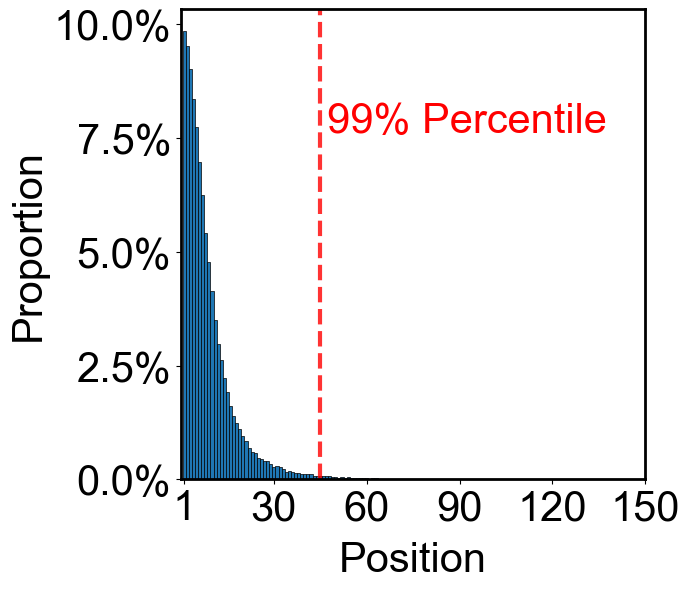

In [20]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# --- 全局绘图样式设置 ---
# matplotlib.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams['ps.fonttype'] = 42
# plt.rcParams["font.family"] = "Arial"
# plt.switch_backend('SVG')


# def process_data(file_path, max_len):
#     """
#     从指定的 Excel 文件读取数据并处理成绘图所需的 x 和 y 数组。
    
#     Args:
#         file_path (str): Excel 文件的路径。
#         max_len (int): x 轴的最大长度。
    
#     Returns:
#         tuple: 包含 x 轴和 y 轴数据的 NumPy 数组 (x, y)。
#     """
#     df = pd.read_excel(file_path)
#     lengths = df.iloc[:, 0].astype(int)      # 第一列：长度
#     proportions = df.iloc[:, 1].astype(float) # 第二列：比例
#     data_raw = dict(zip(lengths, proportions))
    
#     x = np.arange(1, max_len + 1)
#     y = np.array([data_raw.get(i, 0) for i in x]) # 用 0 填充缺失的长度
#     return x, y
def process_data(data_string):
    """
    处理字符串数据，提取x和y值
    
    Args:
        data_string (str): 包含制表符或空格分隔的数据字符串
        
    Returns:
        tuple: (x_list, y_list) 包含x值和y值的元组
    """
    lines = data_string.strip().split('\n')
    x_list = []
    y_list = []
    
    for line in lines:
        line = line.strip()
        if line:  # 跳过空行
            parts = line.split()
            if len(parts) >= 2:
                x_list.append(int(parts[0]))    # 第一列转为整数
                y_list.append(float(parts[1]))  # 第二列转为浮点数
    
    return x_list, y_list

def plot_distribution_chart():
    """
    从 data0.xlsx 和 data1.xlsx 生成长度分布的柱状图。
    - data0.xlsx 的数据绘制在前景。
    - data1.xlsx 的数据作为灰色背景绘制。
    """

    # --- 数据准备: 从两个 Excel 文件读取 ---
    length_max = 150 # 统一设置 x 轴的最大值

    # 处理第一个文件 (前景)
    data1 = """


    """
    data1 = """
0 0.098427
1 0.095223
2 0.090222
3 0.083673
4 0.077396
5 0.069813
6 0.062421
7 0.054145
8 0.047657
9 0.041420
10 0.035042
11 0.029679
12 0.026254
13 0.022377
14 0.019294
15 0.016210
16 0.013890
17 0.012323
18 0.011018
19 0.009541
20 0.008537
21 0.006920
22 0.006066
23 0.005785
24 0.004620
25 0.004560
26 0.003997
27 0.004048
28 0.003375
29 0.002621
30 0.002862
31 0.002641
32 0.002270
33 0.001717
34 0.001758
35 0.001657
36 0.001406
37 0.001326
38 0.001085
39 0.001115
40 0.001125
41 0.001195
42 0.000703
43 0.000703
44 0.000854
45 0.000773
46 0.000663
47 0.000723
48 0.000522
49 0.000633
50 0.000372
51 0.000462
52 0.000402
53 0.000482
54 0.000392
55 0.000251
56 0.000301
57 0.000352
58 0.000311
59 0.000251
60 0.000181
61 0.000251
62 0.000211
63 0.000191
64 0.000110
65 0.000171
66 0.000121
67 0.000131
68 0.000151
69 0.000141
70 0.000090
71 0.000181
72 0.000100
73 0.000121
74 0.000131
75 0.000080
76 0.000131
77 0.000060
78 0.000060
79 0.000090
80 0.000050
81 0.000060
82 0.000060
83 0.000100
84 0.000080
85 0.000050
86 0.000040
87 0.000050
88 0.000030
89 0.000050
90 0.000030
91 0.000030
92 0.000020
93 0.000040
94 0.000040
95 0.000050
96 0.000010
97 0.000040
98 0.000020
99 0.000040
100 0.000020
101 0.000030
102 0.000050
103 0.000040
104 0.000010
105 0.000010
106 0.000030
107 0.000020
108 0.000010
110 0.000030
111 0.000010
112 0.000010
113 0.000020
118 0.000020
119 0.000040
120 0.000010
121 0.000020
122 0.000010
123 0.000010
127 0.000020
129 0.000020
134 0.000010
135 0.000020
137 0.000010
141 0.000010
144 0.000010
145 0.000020
148 0.000010
149 0.000010

    """
    # x_0, y_0 = process_data('data0.xlsx', length_max)
    x_0, y_0 = process_data(data1)
    x_0 = [x + 1 for x in x_0]
    # print(x_0)
    # 处理第二个文件 (背景/阴影)
    # x_1, y_1 = process_data('data1.xlsx', length_max)
    # x_1, y_1 = process_data(data2)

    # --- 绘图设置 ---
    fig, ax = plt.subplots(figsize=(7, 6))
    font_size_all = 30

    # --- 绘制图表: 柱状图 ---
    # 首先绘制第二个数据集 (data1)，作为灰色的背景
    # ax.bar(x_1, y_1, color='grey', width=1.0, edgecolor='darkgrey', linewidth=0.5, label='Data1 (Shadow)')

    # 然后绘制第一个数据集 (data0)，它会覆盖在背景之上
    ax.bar(x_0, y_0, color='#1f77b4', width=1.0, edgecolor='black', linewidth=0.5, label='Data0 (Foreground)')

 # --- 标记99中位点 (位置86) ---
    median_99_pos = 45
    # 找到对应的y值（如果x_0中包含86）
    if median_99_pos in x_0:
        idx = x_0.index(median_99_pos)
        median_99_val = y_0[idx]
    else:
        # 如果精确位置不存在，使用近似值或0
        median_99_val = 0
    
    # 绘制垂直线标记中位点
    ax.axvline(x=median_99_pos, color='red', linestyle='--', linewidth=3, alpha=0.8, label='99% Median (86)')
    
    # 添加文本标注
    ax.text(median_99_pos + 2, max(y_0) * 0.8, '99% Percentile', 
            fontsize=font_size_all , color='red', 
            verticalalignment='center', fontweight='bold')
    
    # --- 坐标轴和标签设置 ---
    ax.set_ylabel("Proportion", fontsize=font_size_all)
    ax.set_xlabel("Position", fontsize=font_size_all, labelpad=10)
    ax.tick_params(axis='both', labelsize=font_size_all)

    # 设置 x 轴刻度和范围
    ax.set_xticks([1, 30, 60, 90, 120, 150])
    ax.set_xlim(0, length_max)

    # 将 Y 轴格式化为百分比
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

    # 设置坐标轴边框线宽
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # --- 保存和显示图像 ---
    fig.tight_layout()
    plt.savefig('dist_SIFT_l150.pdf', dpi=400, bbox_inches='tight', transparent=True)
    plt.show()


# 执行绘图函数
plot_distribution_chart()

In [125]:
# fig8_data = {}
update_deep = {}
query_deep = {}

log_path = '/home/loujh/yq_code/PipeANN-main/log/log_backup'
batch_size = [1000, 10000, 100000, 1000000]
for i, data_name in enumerate(['DEEP1M', 'DEEP10M', 'DEEP100M', 'DEEP1B']):
    # fig8_data[data_name] = {}
    update_deep[data_name] = {}
    query_deep[data_name] = {}

    for sys in ['DGAI', 'OdinANN', 'FreshDiskANN']:
        # all_data = []
        # for i in range(1, 6):
        #     data = extract_metrics_dict(f'{log_path}/fig1_{i}/{sys}_{data_name}.log')[-32:]
        #     # print(len(data))
        #     all_data.append(data)

        # # 按位置逐条平均
        # avg32 = []
        # for j in range(32):
        #     d_avg = {}
        #     for k in all_data[0][j]:
        #         # d_avg[k] = sum([d[j][k] for d in all_data]) / len(all_data)
        #         d_avg[k] = np.median([d[j][k] for d in all_data])
        #     avg32.append(d_avg)

        # if sys == 'FreshDiskANN' and data_name == 'DEEP1B':
        #     query_deep[data_name][sys] = 1
        #     update_deep[data_name][sys] = batch_size[i] / np.median(update_time)
        #     continue
        # else:
        data = extract_metrics_dict(f'{log_path}/fig8/{sys}_{data_name}.log')[1:]
        # print(len(data))
        update_time = []
        for d in data:
            update_time.append(d['E2E_update_time'])

        query_deep[data_name][sys] = 1
        update_deep[data_name][sys] = batch_size[i] / np.median(update_time) / 1000
        # data['insert']
        # print(len(data))
        # fig8_data[data_name][sys] = data


In [126]:
update_deep

{'DEEP1M': {'DGAI': np.float64(0.6436207529075568),
  'OdinANN': np.float64(0.32180209171359614),
  'FreshDiskANN': np.float64(0.23829268060202263)},
 'DEEP10M': {'DGAI': np.float64(0.6590697888999466),
  'OdinANN': np.float64(0.3233107015842224),
  'FreshDiskANN': np.float64(0.2812781278127813)},
 'DEEP100M': {'DGAI': np.float64(0.6099197345629316),
  'OdinANN': np.float64(0.29864831771402633),
  'FreshDiskANN': np.float64(0.30487154237562003)},
 'DEEP1B': {'DGAI': np.float64(0.6384595248584216),
  'OdinANN': np.float64(0.2917884883605572),
  'FreshDiskANN': np.float64(0.14768234708600575)}}

In [127]:
# recall 98
query_deep['DEEP1B']['DGAI'] =  505.50
query_deep['DEEP1B']['OdinANN'] = 197.97
query_deep['DEEP1B']['FreshDiskANN'] = 154.26
query_deep['DEEP100M']['DGAI'] = 1208.28
query_deep['DEEP100M']['OdinANN'] = 453.11
query_deep['DEEP100M']['FreshDiskANN'] = 451.305
query_deep['DEEP10M']['DGAI'] =  2546.70
query_deep['DEEP10M']['OdinANN'] = 1044.32
query_deep['DEEP10M']['FreshDiskANN'] = 1049.25
query_deep['DEEP1M']['DGAI'] = 3124.47 
query_deep['DEEP1M']['OdinANN'] = 2015.85
query_deep['DEEP1M']['FreshDiskANN'] = 1989.05

for x in query_deep:
    for y in query_deep[x]:
        query_deep[x][y] = query_deep[x][y] / 1000 

In [128]:
all_data2 = [update_deep, query_deep]
all_data2

[{'DEEP1M': {'DGAI': np.float64(0.6436207529075568),
   'OdinANN': np.float64(0.32180209171359614),
   'FreshDiskANN': np.float64(0.23829268060202263)},
  'DEEP10M': {'DGAI': np.float64(0.6590697888999466),
   'OdinANN': np.float64(0.3233107015842224),
   'FreshDiskANN': np.float64(0.2812781278127813)},
  'DEEP100M': {'DGAI': np.float64(0.6099197345629316),
   'OdinANN': np.float64(0.29864831771402633),
   'FreshDiskANN': np.float64(0.30487154237562003)},
  'DEEP1B': {'DGAI': np.float64(0.6384595248584216),
   'OdinANN': np.float64(0.2917884883605572),
   'FreshDiskANN': np.float64(0.14768234708600575)}},
 {'DEEP1M': {'DGAI': 3.1244699999999996,
   'OdinANN': 2.01585,
   'FreshDiskANN': 1.98905},
  'DEEP10M': {'DGAI': 2.5467, 'OdinANN': 1.04432, 'FreshDiskANN': 1.04925},
  'DEEP100M': {'DGAI': 1.20828, 'OdinANN': 0.45311, 'FreshDiskANN': 0.451305},
  'DEEP1B': {'DGAI': 0.5055,
   'OdinANN': 0.19797,
   'FreshDiskANN': 0.15425999999999998}}]

In [129]:
def plot_multi_bar3(all_data, xlabel, ylabel, ylim, yscale, group_labels = dataset_list,save_path=None,bar_labels = sys_list, sub_xlabel = None):
    # group_labels = dataset_list
    
    font_size_all = 55

    # 增加图形宽度，为两个子图提供更多空间
    fig, axes = plt.subplots(1, 2, figsize=(24, 12))
    

    if sub_xlabel is None:
        sub_xlabel = group_labels
    for idx, ax in enumerate(axes):
        data = all_data[idx]
        bar_width = 0.20
        num_bars = len(bar_labels)
        group_width = num_bars * bar_width + bar_width * 0.5  # 增加组间距
        group_centers = np.arange(len(group_labels)) * group_width
        
        # if idx == 0:
        #     # 在 y 轴上方加一个文字
        #     ax.text(
        #         0, 1.02,              # 坐标（x=0, y=轴顶端稍微偏上）
        #         r"$\times 10^2$",     # 内容
        #         transform=ax.transAxes, 
        #         ha='left', va='bottom', fontsize=font_size_all-10
        #     )
        # else:
        #     # 在 y 轴上方加一个文字
        #     ax.text(
        #         0, 1.02,              # 坐标（x=0, y=轴顶端稍微偏上）
        #         r"$\times 10^3$",     # 内容
        #         transform=ax.transAxes, 
        #         ha='left', va='bottom', fontsize=font_size_all-10
        #     )
        

        for i, group in enumerate(group_labels):
            # print(group)
            ours_height = data[group]['DGAI']
            for j, bar in enumerate(bar_labels):
                if bar not in data[group]:
                    continue
                x_pos = group_centers[i] - group_width / 2 + bar_width / 2 + j * bar_width
                height = data[group][bar]

                # print(hatches[bar])
                ax.bar(x_pos, height,
                    width=bar_width * 0.85,
                    facecolor=colors[bar],
                    edgecolor=hatch_colors[bar],
                    hatch=hatches[bar],
                    linewidth=2.0,
                    label=bar if i == 0 and idx == 0 else "",  # 只在第一个子图显示图例
                    zorder=3)

                if bar != 'DGAI':
                    ratio = height / ours_height
                    reduce_ratio = (height - ours_height) / height
                    # print(group, bar, reduce_ratio)
                    if yscale[idx] == 'log':
                        pos = height * 1.15  # 稍微提高文本位置
                    else:
                        pos = height + (ylim[idx][1] - ylim[idx][0]) * 0.03  # 基于y轴范围动态调整
                    # ax.text(x_pos, pos, f'{ratio:.1f}×',
                    #         ha='center', va='bottom', fontsize=font_size_all - 20)

        # 美化边框
        for spine in ax.spines.values():
            spine.set_linewidth(2)

        if idx == 0:
            ax.set_ylabel(ylabel[idx], fontsize=font_size_all )
        ax.set_xlabel(xlabel[idx], fontsize=font_size_all )
        ax.set_xticks(group_centers)
        ax.set_xticklabels(sub_xlabel, fontsize=font_size_all   )  # 稍微减小字体

        # 设置尺度
        ax.set_yscale(yscale[idx])
        ax.set_ylim(ylim[idx])
        ax.tick_params(axis='y', labelsize=font_size_all )
        ax.tick_params(axis='x', labelsize=font_size_all )

        # 添加网格以便于阅读
        ax.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)

        # 刻度格式化
        if yscale[idx] == 'log':
            ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
            ax.yaxis.set_minor_formatter(FuncFormatter(lambda y, _: ''))
        else:
            pass
            # ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:,.1f}'))
        # print()
    # 只在第一个子图添加图例
    
    handles, labels = axes[0].get_legend_handles_labels()
    
    order_map = {'DGAI': 2, 'OdinANN': 1, 'FreshDiskANN': 0}
    handles = sorted(handles, key=lambda h: order_map[h.get_label()])
    labels = sorted(labels, key=lambda x: order_map[x])
    fig.legend(handles, labels, 
               ncol=len(bar_labels), 
               fontsize=font_size_all ,
               loc='upper center', 
               frameon=False,
               bbox_to_anchor=(0.5, 1.0))  # 将图例放在图形顶部中央

    plt.tight_layout(rect=[0,0,1,0.85])
    # 调整子图之间的间距
    plt.subplots_adjust(wspace=0.15)
    
    # 为图例留出额外空间
    # plt.subplots_adjust(top=0.85)
    
    if save_path is not None:
        plt.savefig(save_path, dpi=400, bbox_inches='tight', transparent=True)
    else:
        plt.show()

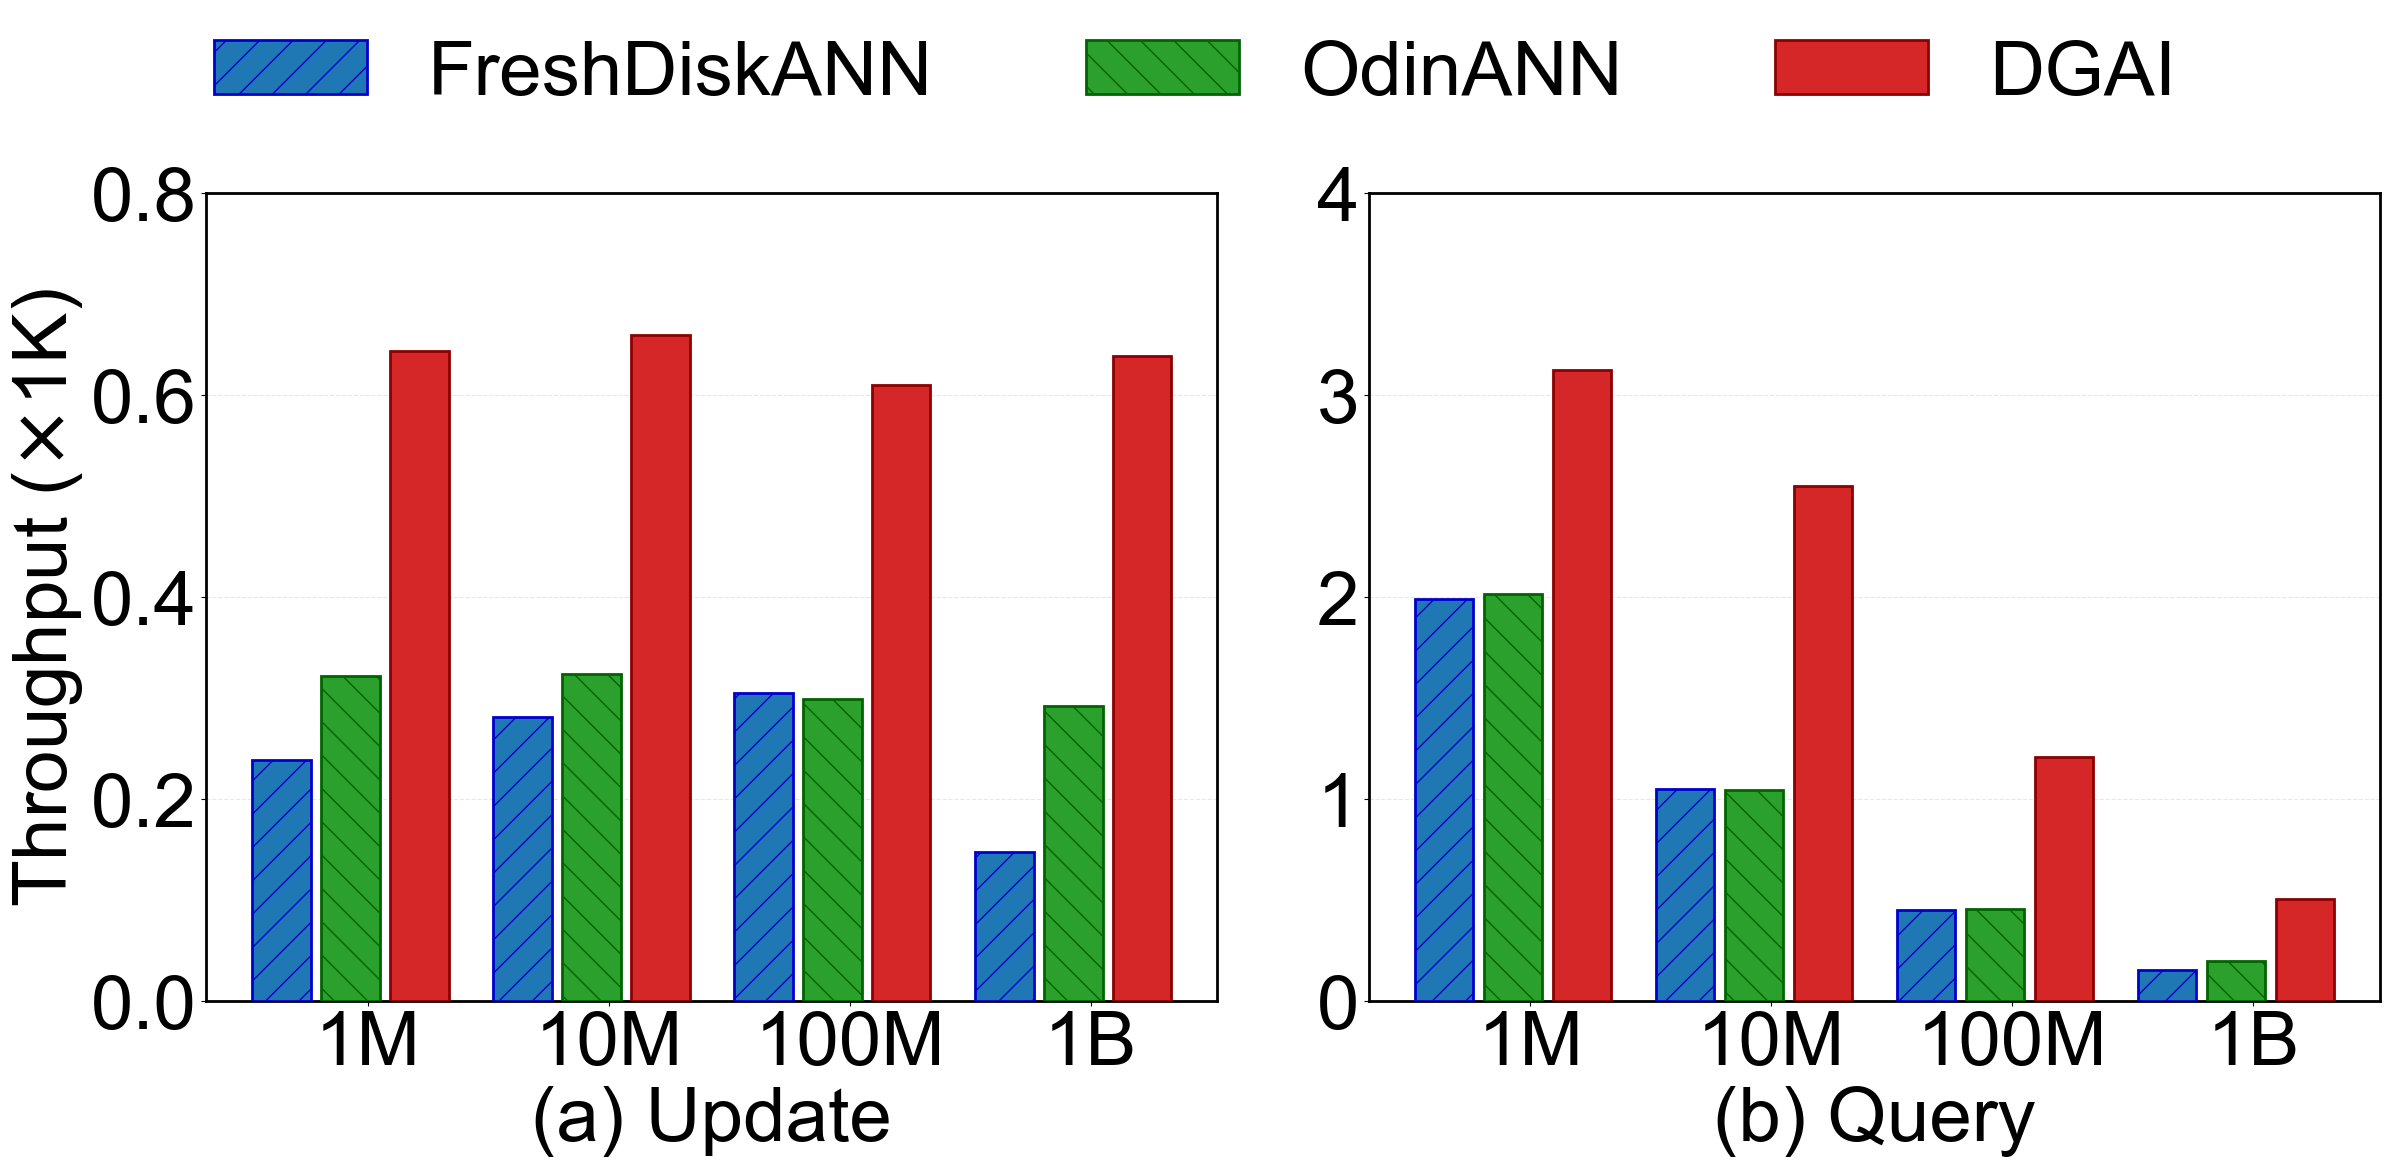

In [262]:
plot_multi_bar3(all_data2, ['(a) Update', '(b) Query'], [r'Throughput ($\times$1K)', 'QPS'], [(0, 0.8), (0, 4)], ['linear', 'linear'], group_labels=['DEEP1M', 'DEEP10M', 'DEEP100M', 'DEEP1B'], 
                save_path='scale.pdf',
                  bar_labels=['FreshDiskANN', 'OdinANN', 'DGAI'],
                sub_xlabel=['1M', '10M', '100M', '1B'])

In [250]:
update = all_data2[0]
ratio = {}
for x in update:
    # ratio[x] = []
    for y in update[x]:
        print(x, y, update[x][y], update[x]['DGAI'] / update[x][y])
        if y not in ratio:
            ratio[y] = []
        ratio[y].append(update[x]['DGAI'] / update[x][y])
        # if y != 'DGAI':
query = all_data2[1]
ratio2 = {}
for x in query:
    for y in query[x]:
        print(x, y, query[x][y], query[x]['DGAI'] / query[x][y])
        if y not in ratio2:
            ratio2[y] = []
        ratio2[y].append(query[x]['DGAI'] / query[x][y])
        # if y != 'DGAI':



DEEP1M DGAI 6.436207529075569 1.0
DEEP1M OdinANN 3.2180209171359615 2.000051489660233
DEEP1M FreshDiskANN 2.3829268060202264 2.7009673619916206
DEEP10M DGAI 6.5906978889994665 1.0
DEEP10M OdinANN 3.2331070158422244 2.038502857067535
DEEP10M FreshDiskANN 2.812781278127813 2.34312491349709
DEEP100M DGAI 6.099197345629316 1.0
DEEP100M OdinANN 2.9864831771402636 2.042267437605211
DEEP100M FreshDiskANN 3.0487154237562004 2.0005794237478347
DEEP1B DGAI 6.3845952485842155 1.0
DEEP1B OdinANN 2.917884883605572 2.1880901760232905
DEEP1B FreshDiskANN 1.4768234708600576 4.323194596078581
DEEP1M DGAI 3.1244699999999996 1.0
DEEP1M OdinANN 2.01585 1.5499516333060495
DEEP1M FreshDiskANN 1.98905 1.5708353233955907
DEEP10M DGAI 2.5467 1.0
DEEP10M OdinANN 1.04432 2.438620346254022
DEEP10M FreshDiskANN 1.04925 2.4271622587562542
DEEP100M DGAI 1.20828 1.0
DEEP100M OdinANN 0.45311 2.6666372404051994
DEEP100M FreshDiskANN 0.451305 2.6773024894472695
DEEP1B DGAI 0.5055 1.0
DEEP1B OdinANN 0.19797 2.55341718442

In [ ]:
for x in ratio:
    print(x, np.mean(ratio[x]))
for x in ratio2:
    print(x, np.mean(ratio2[x]))


NameError: name 'ratio' is not defined

In [14]:
from matplotlib.ticker import FormatStrFormatter
def plot3(datasets, dataset_titles, y_lable, save_path = None, dataset_list=dataset_list):
    """
    绘制Recall-QPS性能权衡曲线图。
    """
    # --- 1. 数据定义 ---
    # 修正点1：移除了最外层多余的花括号，使其成为一个标准的字典。
    
    font_size_all = 55

    # --- 2. 绘图风格定义 ---
    # colors = {64: '#d62728', 37: '#2ca02c', 59: '#1f77b4', 63: '#FFAAFF'}
    # markers = {64: 'D', 37: 'o', 59: 'X', 63: 's'}
    # colors = {64: '#1f77b4', 37: '#2ca02c', 63: '#d62728', 59: '#FFAAFF'}
    # markers = {64: 'X', 37: 'o', 63: 'D', 59: 's'}
    # colors = {64: '#1f77b4', 37: '#2ca02c', 63: '#d62728', 33: '#FFAAFF', 13 : '#FF0000'}
    # markers = {64: 'X', 37: 'o', 63: 'D', 33: 's', 13: '^'}
    colors = {33: '#1f77b4', 37: '#2ca02c', 43: '#FF9900', 47: '#d62728'}
    markers = {33: 'X', 37: 'o', 43: 's', 47: 'D'}
    
    # 修正点2: 定义一个列表来控制绘图顺序，确保与标题匹配
    dataset_order = dataset_list
    dataset_titles = ['(a) SIFT', '(b) DEEP100M']

    # --- 3. 创建图形和子图 ---
    fig, axes = plt.subplots(1, len(dataset_list), figsize=(24, 12))
    
    # if type(axes) != list:
    #     axes = [axes]
    linewidth = 4
    markersize = 12

    # tmp_label = {64: 'DGAI w/o opt', 37: 'DGAI w TS.', 63: 'DGAI w TS.+Re.', 59:'DGAI w Re.'}
    # tmp_label = {64: 'DGAI w/o opt', 37: 'DGAI w TS.+Pipe.', 63: 'DGAI w TS.+Re.+Pipe.', 33:'DGAI w Pipe.', 13: 'DGAI w TS.'}
    tmp_label = {33: 'DGAI w/o Optimization', 37: 'DGAI w/ Three-stage', 47:'DGAI w/ Three-stage+Reorder', 43: 'DGAI w/ Reorder'}
    # --- 4. 遍历数据集和子图进行绘制 ---
    # 修正点2: 循环遍历预定义的顺序列表
    for idx, dataset_name in enumerate(dataset_order):
        ax = axes[idx]
        data = datasets[dataset_name]

        ax.yaxis.set_major_formatter(StrMethodFormatter("{x:2.0f}"))  # 固定为 4 位宽
        for system_label in colors.keys():
            if system_label not in data:
                continue

            points = data[system_label]
            if not points:
                continue
            
            print(system_label)
            recall_data, qps_data = zip(*points)
            print(recall_data)
            print(qps_data)
            ax.plot(recall_data, qps_data,
                    marker=markers[system_label],
                    color=colors[system_label],
                    linestyle='-',
                    markersize=markersize,
                    linewidth=linewidth,
                    label=tmp_label[system_label])
        
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        # --- 5. 子图格式化 ---
        # ax.set_yscale('log')
        ax.set_xlim(data['xlim'])
        ax.set_ylim(data['ylim']) # 手动设置ylim以获得更一致的视图
        
        # # ax.tick_params(axis='y', labelsize=font_size_all)
        # if data['ylim'][1] > 5:
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))  # 最多 6 个刻度
        # # else :
        # #     # ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))  # 最多 6 个刻度
        # #     ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=5))  # 固定5个刻度（包括首尾）
        # elif data['ylim'][1] == 4:
        #     ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
        #     # ax.yaxis.set_major_locator(mticker.LinearLocator(numticks=4))  # 固定4个刻度（包括首尾）
        # else:
        #     ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=3))  # 最多 6 个刻度
        # ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))  # 最多 6 个刻度
        # # 根据y轴范围设置**确定数量**的y刻度
        
        # # x轴固定设置为5个刻度（包括首尾）
        ax.xaxis.set_major_locator(mticker.LinearLocator(numticks=6))
        # ax.grid(True, which='major', axis='both', linestyle='-', linewidth=1.5, alpha=0.3)
        # # ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.0f}")) # 根据需要调整小数位数
        if idx == 0:
            
            # # 在 y 轴上方加一个文字
            # ax.text(
            #     0, 1.02,              # 坐标（x=0, y=轴顶端稍微偏上）
            #     r"$\times 10^3$",     # 内容
            #     transform=ax.transAxes, 
            #     ha='left', va='bottom', fontsize=font_size_all-5
            # )
            ax.set_ylabel(y_lable, fontsize=font_size_all)
        ax.tick_params(axis='both', which='major', labelsize=font_size_all - 5)


        ax.set_xlabel("Recall@10", fontsize=font_size_all)
        ax.text(0.5, -0.3, dataset_titles[idx], transform=ax.transAxes, ha='center', va='center', fontsize=font_size_all)
        for spine in ax.spines.values():
            spine.set_linewidth(3)
        # ax.grid(True, which="both", ls="--", linewidth=0.5)
    # fig.subplots_adjust(left=0.15)
    # --- 6. 创建总图例 ---
    handles, labels = axes[0].get_legend_handles_labels()

    order_map = { 'DGAI w/o Optimization': 0, 'DGAI w/ Reorder': 3, 'DGAI w/ Three-stage': 4, 'DGAI w/ Three-stage+Reorder': 5}
    handles = sorted(handles, key=lambda h: order_map[h.get_label()])
    labels = sorted(labels, key=lambda x: order_map[x])

    fig.legend(handles, labels, 
               loc='upper center',
            #    bbox_to_anchor=(0.5, 1.0),
               bbox_to_anchor=(0.5, 1.1),
               ncol=2,
               frameon=False,
               fontsize=font_size_all)
    
    # --- 7. 布局调整和保存 ---
    # fig.tight_layout(rect=[0, 0, 1, 0.90]) 
    fig.tight_layout(rect=[0, 0, 1, 0.9], h_pad=None) 
    
    if save_path is not None:
        plt.savefig(save_path, dpi=400, bbox_inches='tight', transparent=True)
    else:
        plt.show()


In [15]:
import glob

fig10_data = {}
# log_path = '/home/loujh/yq_code/PipeANN-main/log'
for data_name in ['SIFT', 'DEEP100M']:
    fig10_data[data_name] = {}
    # for sys in sys_list:
    # for strategy in [64, 37, 59, 63, 33, 13]:
    for strategy in [37, 43, 33, 47]:
        # log_file = f'{log_path}/fig10/*_{data_name}_s{strategy}.log'
        print(strategy)
        tmp = strategy
        # if tmp == 37:
        #     strategy = 13
        log_file = glob.glob(f'{log_path}/fig10/*_{data_name}_s{strategy}.log')[0]
        print(log_file)
        # if tmp == 37:
        #     strategy = 37
        fig10_data[data_name][strategy] = []
        single_data = extract_metrics_dict2(log_file)
        # l = []
        for item in single_data:
            # l.append((item['Recall@10'] / 100, item['Search_Latency_us']))
            fig10_data[data_name][strategy].append((item['Recall@10'] / 100, item['Search_Latency_us'] / 1000))

            
        # for target_recall in [x / 1000 for x in range(900, 1000, 10)]:
        #     mn = 1e9
        #     for recall, lat in l:
        #         if abs(recall - target_recall) < mn:
        #             mn = min(mn, abs(recall - target_recall))
        #             res = (recall, lat)
        #     fig10_data[data_name][strategy].append(res)


fig10_data['SIFT']['xlim'] = (0.9, 1)
fig10_data['SIFT']['ylim'] = (0.1, 5)
fig10_data['DEEP100M']['xlim'] = (0.9, 1)
fig10_data['DEEP100M']['ylim'] = (0.1, 50)
# fig10_data['GIST']['xlim'] = (0.9, 1)
# fig10_data['GIST']['ylim'] = (0, 55)

37
/home/loujh/yq_code/PipeANN-main/log/log_backup/fig10/DGAI_SIFT_s37.log
43
/home/loujh/yq_code/PipeANN-main/log/log_backup/fig10/DGAI_SIFT_s43.log
33
/home/loujh/yq_code/PipeANN-main/log/log_backup/fig10/DGAI_SIFT_s33.log
47
/home/loujh/yq_code/PipeANN-main/log/log_backup/fig10/DGAI_SIFT_s47.log
37
/home/loujh/yq_code/PipeANN-main/log/log_backup/fig10/DGAI_DEEP100M_s37.log
43
/home/loujh/yq_code/PipeANN-main/log/log_backup/fig10/DGAI_DEEP100M_s43.log
33
/home/loujh/yq_code/PipeANN-main/log/log_backup/fig10/DGAI_DEEP100M_s33.log
47
/home/loujh/yq_code/PipeANN-main/log/log_backup/fig10/DGAI_DEEP100M_s47.log


In [16]:
fig10_data['SIFT'].keys()

dict_keys([37, 43, 33, 47, 'xlim', 'ylim'])

33
(0.7606, 0.8208, 0.857, 0.8815999999999999, 0.8996, 0.9131999999999999, 0.9347, 0.9488, 0.958, 0.9645, 0.9740000000000001, 0.9795999999999999, 0.9838, 0.9892, 0.9921, 0.993, 0.9937999999999999)
(1.03289, 1.09747, 1.15822, 1.2107, 1.25654, 1.31625, 1.4511800000000001, 1.5908499999999999, 1.7334100000000001, 1.8602400000000001, 2.1324699999999996, 2.42015, 2.68185, 3.2496799999999997, 3.80502, 4.08417, 4.35634)
37
(0.7603, 0.8208, 0.8569, 0.8818, 0.8987999999999999, 0.9122, 0.9340999999999999, 0.9484, 0.9579000000000001, 0.9643999999999999, 0.9739, 0.9793999999999999, 0.9836, 0.9891, 0.9921, 0.993, 0.9937999999999999)
(1.05545, 1.11129, 1.16875, 1.22089, 1.28931, 1.33193, 1.45654, 1.5400999999999998, 1.6606500000000002, 1.731, 1.8728900000000002, 2.03639, 2.1873299999999998, 2.46996, 2.76501, 2.89654, 3.03185)
43
(0.76, 0.8192, 0.8551000000000001, 0.8804000000000001, 0.8979, 0.9107, 0.9333, 0.9476, 0.9578, 0.9643999999999999, 0.9741, 0.9799, 0.9841, 0.9894, 0.9922, 0.9931, 0.9939)
(0.

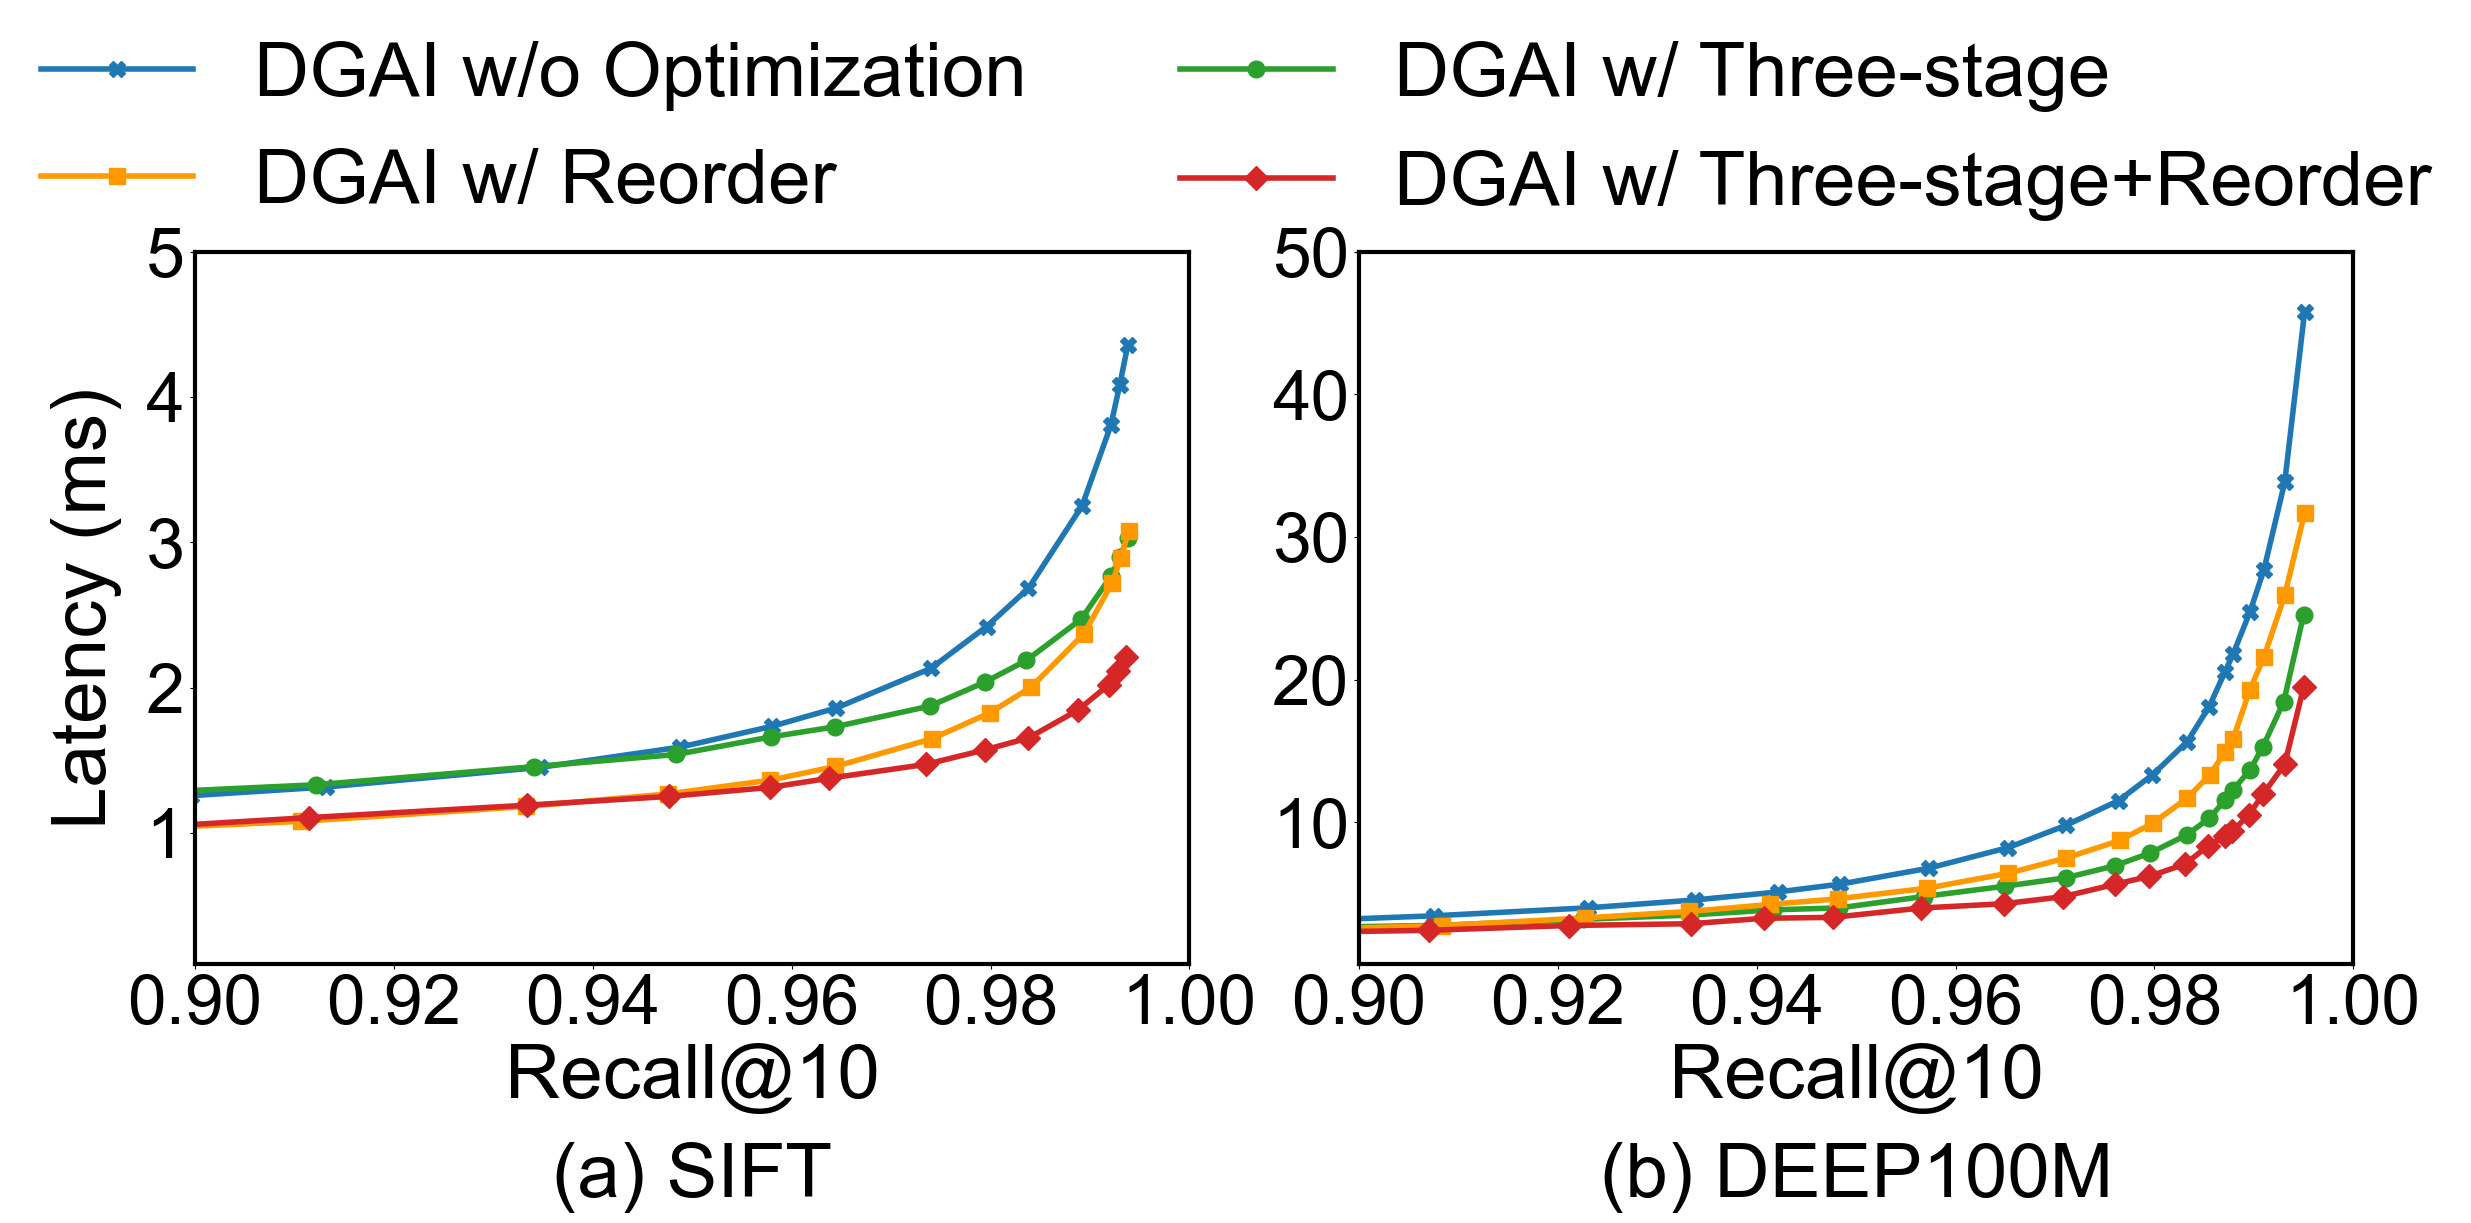

In [17]:
# plot2(fig10_data, ['SIFT', 'GIST'], 'Search Latency (ms)', dataset_list=['SIFT', 'GIST'], save_path='ablation_latency.pdf')
# plot2(fig10_data, ['SIFT', 'GIST'], 'Search Latency (ms)', dataset_list=['SIFT', 'GIST'], save_path='ablation_latency_3.pdf')
plot3(fig10_data, ['SIFT', 'DEEP100M'], 'Latency (ms)', dataset_list=['SIFT', 'DEEP100M'], save_path='ablation_latency_3.pdf')


In [1]:
# import os

# def rename_files_recursive(root_folder):
#     """
#     递归地将指定文件夹及其子文件夹中所有包含"SIFT1M"的文件名替换为"SIFT"
    
#     参数:
#         root_folder: 根文件夹路径
#     """
#     # 检查文件夹是否存在
#     if not os.path.isdir(root_folder):
#         print(f"错误: 文件夹 '{root_folder}' 不存在")
#         return
    
#     # 递归遍历所有文件和子目录
#     for dirpath, dirnames, filenames in os.walk(root_folder):
#         # 处理当前目录中的所有文件
#         for filename in filenames:
#             if "SIFT1M" in filename:
#                 # 构建新旧文件的完整路径
#                 old_path = os.path.join(dirpath, filename)
#                 new_filename = filename.replace("SIFT1M", "SIFT")
#                 new_path = os.path.join(dirpath, new_filename)
                
#                 # 执行重命名
#                 try:
#                     os.rename(old_path, new_path)
#                     print(f"已重命名: {old_path} -> {new_path}")
#                 except Exception as e:
#                     print(f"重命名失败 '{old_path}': {str(e)}")

# if __name__ == "__main__":
#     # 在这里替换为你的根文件夹路径
#     root_directory = "/home/loujh/yq_code/PipeANN-main/log"  # 例如: "C:/data" 或 "/home/user/documents"
    
#     # 调用函数进行递归重命名
#     rename_files_recursive(root_directory)
#     print("递归重命名操作完成")
    

In [41]:
# separate_plots.py

import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import MultipleLocator

# --- 全局样式 ---
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# plt.rcParams["font.family"] = "Arial"

# 字体路径
font_dir = "/home/loujh/fonts/ARIAL.TTF"
import matplotlib as mpl

# 注册字体
from matplotlib import font_manager
font_manager.fontManager.addfont(font_dir)

# 设置全局默认字体
mpl.rcParams['font.family'] = 'Arial'

# plt.switch_backend('SVG')
plt.rcParams.update({
    'font.size': 32,
    'axes.linewidth': 2.0,
    'lines.linewidth': 2
})

FONT_SIZE = 30
L = 150


# ================================
# 上图：Recall@10 折线图
# ================================
def plot_recall(save_path="recall.pdf"):
    data = [
        (1, 10.51, 0.197), (2, 19.77, 0.4035), (3, 28.33, 0.502),
        (4, 36.39, 0.54425), (5, 43.61, 0.567), (6, 50.33, 0.5805),
        (7, 55.88, 0.599143), (8, 61.16, 0.609625), (9, 66.0, 0.618222),
        (10, 69.98, 0.6262), (11, 73.32, 0.594182), (12, 76.17, 0.566167),
        (13, 78.89, 0.537154), (14, 80.8, 0.511), (15, 82.4, 0.487467),
        (16, 84.22, 0.468187), (17, 85.61, 0.447412), (18, 86.98, 0.428611),
        (19, 87.96, 0.412737), (20, 88.87, 0.39625), (21, 89.79, 0.382),
        (22, 90.54, 0.367682), (23, 91.22, 0.355), (24, 91.81, 0.3435),
        (25, 92.4, 0.3322), (26, 92.89, 0.322231), (27, 93.39, 0.311963),
        (28, 93.85, 0.302786), (29, 94.19, 0.294276), (30, 94.44, 0.285933),
        (31, 94.66, 0.278226), (32, 94.89, 0.27075), (33, 95.14, 0.263485),
        (34, 95.44, 0.256765), (35, 95.57, 0.251057), (36, 95.75, 0.244806),
        (37, 95.88, 0.239027), (38, 96.04, 0.233526), (39, 96.19, 0.228487),
        (40, 96.25, 0.22335), (41, 96.38, 0.218634), (42, 96.54, 0.213929),
        (43, 96.63, 0.209419), (44, 96.73, 0.205341), (45, 96.81, 0.201311),
        (46, 96.86, 0.197283), (47, 96.91, 0.193489), (48, 96.95, 0.189833),
        (49, 97.01, 0.186224), (50, 97.06, 0.18274), (51, 97.11, 0.179569),
        (52, 97.15, 0.176404), (53, 97.19, 0.173302), (54, 97.22, 0.17037),
        (55, 97.24, 0.167436), (56, 97.28, 0.164643), (57, 97.31, 0.162158),
        (58, 97.36, 0.159724), (59, 97.37, 0.157237), (60, 97.38, 0.154833),
        (61, 97.39, 0.152508), (62, 97.4, 0.150323), (63, 97.43, 0.148127),
        (64, 97.44, 0.146063), (65, 97.44, 0.144015), (66, 97.45, 0.141985),
        (67, 97.45, 0.14003), (68, 97.45, 0.138088), (69, 97.46, 0.136246),
        (70, 97.47, 0.134414), (71, 97.51, 0.132634), (72, 97.52, 0.130986),
        (73, 97.52, 0.129342), (74, 97.53, 0.127635), (75, 97.54, 0.126107),
        (76, 97.54, 0.124539), (77, 97.55, 0.123052), (78, 97.55, 0.121538),
        (79, 97.56, 0.120101), (80, 97.56, 0.11865), (81, 97.57, 0.117296),
        (82, 97.57, 0.115927), (83, 97.57, 0.114639), (84, 97.58, 0.113405),
        (85, 97.59, 0.112165), (86, 97.6, 0.110884), (87, 97.62, 0.109701),
        (88, 97.62, 0.108557), (89, 97.62, 0.107427), (90, 97.64, 0.1063),
        (91, 97.64, 0.105209), (92, 97.64, 0.104098), (93, 97.65, 0.103065),
        (94, 97.66, 0.102043), (95, 97.66, 0.101084), (96, 97.66, 0.100073),
        (97, 97.66, 0.099062), (98, 97.66, 0.098092), (99, 97.66, 0.097172),
        (100, 97.66, 0.09626), (101, 97.66, 0.095356), (102, 97.66, 0.09448),
        (103, 97.67, 0.093583), (104, 97.67, 0.092702), (105, 97.67, 0.091867),
        (106, 97.68, 0.091038), (107, 97.68, 0.090234), (108, 97.68, 0.089454),
        (109, 97.68, 0.088651), (110, 97.68, 0.087909), (111, 97.68, 0.087153),
        (112, 97.68, 0.086402), (113, 97.68, 0.085673), (114, 97.68, 0.084947),
        (115, 97.69, 0.08427), (116, 97.69, 0.08356), (117, 97.69, 0.082889),
        (118, 97.69, 0.082212), (119, 97.69, 0.081546), (120, 97.69, 0.080925),
        (121, 97.69, 0.080273), (122, 97.69, 0.079656), (123, 97.69, 0.079016),
        (124, 97.69, 0.078419), (125, 97.69, 0.077832), (126, 97.7, 0.077246),
        (127, 97.7, 0.076669), (128, 97.71, 0.076109), (129, 97.71, 0.075543),
        (130, 97.71, 0.074992), (131, 97.71, 0.074443), (132, 97.71, 0.073886),
        (133, 97.71, 0.073361), (134, 97.71, 0.072843), (135, 97.71, 0.072319),
        (136, 97.71, 0.071809), (137, 97.71, 0.071307), (138, 97.71, 0.070812),
        (139, 97.71, 0.070331), (140, 97.71, 0.069843), (141, 97.71, 0.069355),
        (142, 97.71, 0.068866), (143, 97.71, 0.068406), (144, 97.71, 0.067944),
        (145, 97.71, 0.067517), (146, 97.71, 0.067089), (147, 97.71, 0.066653),
        (148, 97.71, 0.066209), (149, 97.72, 0.065779), (150, 97.72, 0.065367)
    ]
    L = 60
    data = data[:L]

    candidate_size = np.array([item[0] for item in data])
    recall = np.array([item[1] for item in data]) / 100.0

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:.1f}")) # 根据需要调整小数位数

    color_recall = '#d62728'
    line1, = ax.plot(candidate_size, recall,
                     color=color_recall, linestyle='-', #marker='o',
                     markersize=6, linewidth=3, label='Recall@10')

    ax.set_ylabel("Recall@10", fontsize=FONT_SIZE, labelpad=12)
    ax.set_xlabel(r"Candidates Number ($\tau$)", fontsize=FONT_SIZE, labelpad=13)
    ax.tick_params(axis='both', labelsize=FONT_SIZE)

    ax.xaxis.set_major_locator(MultipleLocator(30))
    ax.set_xlim(0, L+1)
    ax.set_ylim(0.0, 1.05)

    ax.legend(handles=[line1], loc='lower right',
              fontsize=FONT_SIZE-6, frameon=False)

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    fig.savefig(save_path, format='pdf', bbox_inches='tight',
                dpi=400, transparent=True)
    # plt.close(fig)
    # plt.show()


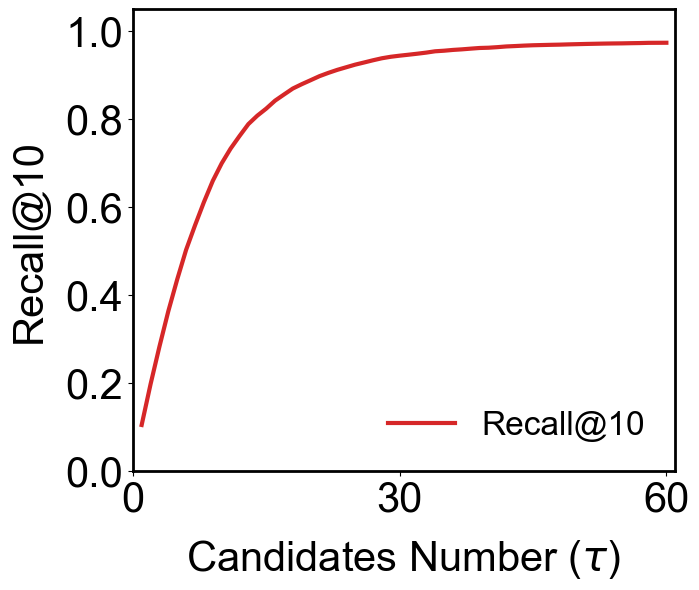

In [42]:
plot_recall("recall.pdf")

In [176]:

# 2. 数据处理（完全不变）
data_string   = data_L100_SIFT
L = 100

data   = [line.split()  for line in data_string.strip().split('\n')  if line]

data = [[int(x) for x in line] for line in data]

In [177]:
data

[[0, 5, 3, 7, 15, 8, 2, 9, 6, 13],
 [4, 3, 15, 1, 0, 25, 9, 5, 2, 51],
 [0, 1, 4, 5, 2, 14, 11, 8, 13, 3],
 [2, 1, 10, 3, 7, 12, 9, 8, 0, 5],
 [4, 2, 3, 0, 1, 5, 7, 21, 6, 9],
 [1, 3, 2, 0, 9, 6, 7, 24, 12, 10],
 [1, 8, 3, 2, 4, 9, 18, 17, 11, 0],
 [2, 3, 6, 0, 11, 4, 13, 7, 27, 56],
 [0, 1, 3, 2, 4, 20, 55, 15, 40],
 [0, 2, 3, 1, 4, 7, 19, 6, 54, 28],
 [0, 1, 2, 7, 19, 6, 5, 13, 17, 27],
 [0, 1, 2, 3, 4, 8, 6, 19, 5, 7],
 [0, 1, 3, 4, 6, 2, 5, 7, 22, 13],
 [0, 2, 20, 4, 10, 8, 27, 3, 5, 1],
 [1, 2, 11, 42, 0, 4, 8, 26, 3, 5],
 [0, 1, 5, 4, 7, 8, 16, 10, 12, 3],
 [0, 1, 2, 6, 4, 3, 16, 8, 5, 10],
 [0, 14, 1, 9, 19, 2, 8, 37, 16],
 [0, 2, 13, 11, 1, 16, 4, 20, 8],
 [3, 0, 1, 4, 5, 55, 15, 52, 16, 9],
 [0, 3, 1, 15, 7, 12, 13, 14, 18, 10],
 [0, 1, 2, 7, 9, 16, 26, 8, 6, 4],
 [1, 4, 2, 5, 3, 0, 8, 15, 11, 6],
 [3, 0, 2, 6, 4, 1, 8, 10, 18, 12],
 [0, 1, 10, 2, 15, 25, 4, 7, 5, 11],
 [0, 1, 8, 11, 12, 7, 39, 15, 14, 6],
 [1, 0, 14, 2, 3, 13, 30, 15, 6, 23],
 [1, 0, 2, 13, 6, 12, 8, 4, 10, 1

In [212]:
import random
# ================================
# 下图：PQ-A 黑白热力图
# ================================
def plot_pqa_heatmap(save_path="pqa.pdf", data=None, L=150):
    L=60
    # if data is None:
    #     data = [([4, 3, 15, 1, 0, 25, 9, 5, 2, 51], 1),
    #             ([4, 2, 3, 0, 1, 5, 7, 21, 6, 9], 4),
    #             ([0, 5, 3, 7, 15, 8, 2, 9, 6, 13], 0),
    #             ([0, 1, 4, 5, 2, 14, 11, 8, 13, 3], 2),
    #             ([2, 1, 10, 3, 7, 12, 9, 8, 0, 5], 3),
    #             ([4, 3, 15, 1, 0, 25, 9, 5, 2, 51], 1),
    #             ([4, 2, 3, 0, 1, 5, 7, 21, 6, 9], 4),
    #             ([0, 5, 3, 7, 15, 8, 2, 9, 6, 13], 0),
    #             ([0, 1, 4, 5, 2, 14, 11, 8, 13, 3], 2),
    #             ([2, 1, 10, 3, 7, 12, 9, 8, 0, 5], 3),
    #             ([4, 3, 15, 1, 0, 25, 9, 5, 2, 51], 1),
    #             ([4, 2, 3, 0, 1, 5, 7, 21, 6, 9], 4),
    #             ([0, 5, 3, 7, 15, 8, 2, 9, 6, 13], 0),
    #             ([0, 1, 4, 5, 2, 14, 11, 8, 13, 3], 2),
    #             ([2, 1, 10, 3, 7, 12, 9, 8, 0, 5], 3),
    #             ([4, 3, 15, 1, 0, 25, 9, 5, 2, 51], 1),
    #             ([4, 2, 3, 0, 1, 5, 7, 21, 6, 9], 4),
    #             ([0, 5, 3, 7, 15, 8, 2, 9, 6, 13], 0),
    #             ([0, 1, 4, 5, 2, 14, 11, 8, 13, 3], 2),
    #             ([2, 1, 10, 3, 7, 12, 9, 8, 0, 5], 3)
    #     ]
    random.seed(42)
    ordered = random.sample(data, 20)

    # ordered = [positions for positions, _ in sorted(data, key=lambda x: x[1])]

    mat = np.zeros((len(ordered), L), dtype=int)
    for i, positions in enumerate(ordered):
        for p in positions:
            if 1 <= p <= L:
                mat[i, p - 1] = 1

    fig, ax = plt.subplots(figsize=(7, 6))

    cmap = ListedColormap(["white", "black"])
    norm = BoundaryNorm(boundaries=[-0.5, 0.5, 1.5], ncolors=cmap.N)

#  # --- 标记99中位点 (位置86) ---
#     median_99_pos = 10
#     # 找到对应的y值（如果x_0中包含86）
#     if median_99_pos in x_0:
#         idx = x_0.index(median_99_pos)
#         median_99_val = y_0[idx]
#     else:
#         # 如果精确位置不存在，使用近似值或0
#         median_99_val = 0
    
    median_99_pos = 10
    # 绘制垂直线标记中位点
    ax.axvline(x=median_99_pos, color='red', linestyle='--', linewidth=3, alpha=0.8, label='99% Median (86)')
    
    # 添加文本标注
    ax.text(median_99_pos - 2.5 , 22, '10', 
            fontsize=FONT_SIZE , color='red', 
            verticalalignment='bottom', fontweight='bold')
    
    sns.heatmap(
        mat, cmap=cmap, norm=norm,
        cbar=False, linewidths=0.4, linecolor='white',
        ax=ax, xticklabels=False, yticklabels=False
    )

    xticks = np.arange(0, L+1, 30)
    ax.set_xticks(xticks - 0.5)
    ax.set_xticklabels([str(x) for x in xticks],
                       fontsize=FONT_SIZE)

    ax.set_xlim(-0.2, L-0.5)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_color('black')

    ax.set_xlabel("Ordinal Number in Candidate Queue", fontsize=FONT_SIZE, labelpad=13)
    ax.xaxis.set_label_coords(0.438, -0.13)
    ax.set_ylabel('Query ID', fontsize=FONT_SIZE,labelpad=37)
    ax.set_facecolor('#F5F5F5')

    fig.savefig(save_path, format='pdf', bbox_inches='tight',
                dpi=400, transparent=True)
    # plt.close(fig)
    # plt.show()



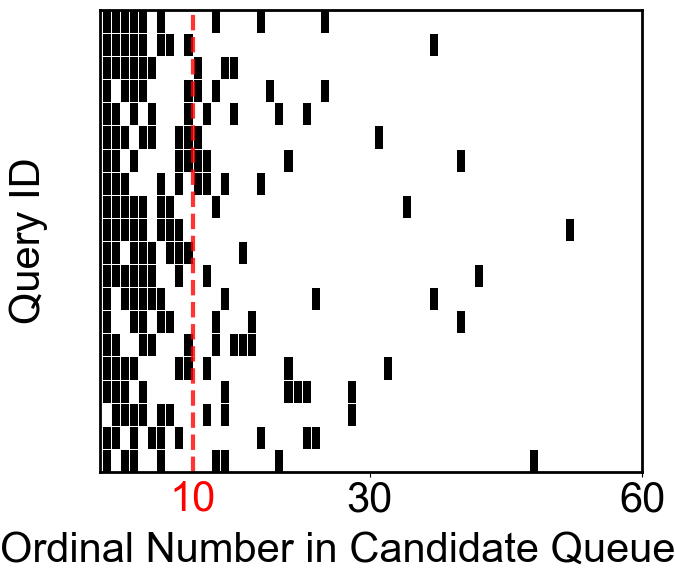

In [213]:
plot_pqa_heatmap("pq.pdf", data, L=L)